# Memorization Study

Full empirical study of the memorization capability of the Conv-Recurrent Contrastive Hebbian network.

## Structure
- **Phase 0** — Setup & data
- **Phase 1** — Can the network memorize? (single image vs batch, sweep: threshold, lr, mask_prob, momentum, n_updates)
- **Phase 2** — Speed of memorization (convergence curves, effect of each hyperparameter)
- **Phase 3** — Catastrophic forgetting (learn A → learn B → does A survive?)
- **Phase 4** — Summary heatmaps & conclusions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity
import json, time, itertools
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import jax.tree_util as jtu
import optax

from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

RESULTS_DIR = Path("results/memorization_study")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"JAX devices: {jax.devices()}")
print(f"Results → {RESULTS_DIR.resolve()}")

JAX devices: [CpuDevice(id=0)]
Results → /Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/experiments/results/memorization_study


## Phase 0 — Data

In [2]:
data = Cifar10(batch_size=32, linear_projection=None, label_mode="pm1", x_transform="identity")
key = jax.random.PRNGKey(0)
key, dk = jax.random.split(key)
data.build(key=dk)

it = iter(data)
x_A, y_A = next(it)   # pattern A  — first batch
x_B, y_B = next(it)   # pattern B  — second batch (for forgetting study)

if x_A.ndim == 2: x_A = x_A.reshape(x_A.shape[0], 32, 32, 3)
if x_B.ndim == 2: x_B = x_B.reshape(x_B.shape[0], 32, 32, 3)

# Standardise each batch independently
x_A = (x_A - x_A.mean()) / x_A.std()
x_B = (x_B - x_B.mean()) / x_B.std()

# Single-image slices
x_A1, y_A1 = x_A[0:1], y_A[0:1]
x_B1, y_B1 = x_B[0:1], y_B[0:1]

print(f"Batch A : {x_A.shape}  Batch B : {x_B.shape}")
print(f"Single A: {x_A1.shape}  Single B: {x_B1.shape}")
# Print class distribution of batches
for name, yy in [("A", y_A), ("B", y_B)]:
    cls = np.argmax(np.array(yy), axis=-1)
    print(f"Batch {name} classes: {sorted(np.unique(cls).tolist())}  (n={len(cls)})")

Batch A : (32, 32, 32, 3)  Batch B : (32, 32, 32, 3)
Single A: (1, 32, 32, 3)  Single B: (1, 32, 32, 3)
Batch A classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (n=32)
Batch B classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (n=32)


## Architecture & Helpers

In [6]:
def build_model(seed=0, threshold=1.7, mask_prob=0.2, momentum=0.5,
                n_channels=64, j_d=0.9):
    """Build state + orchestrator with a unified threshold for conv/fc/out."""
    keys = jax.random.split(jax.random.key(seed), 5)
    lmap = LayerMap.from_dict({
        1: {
            0: Conv2D(in_channels=3, out_channels=n_channels, kernel_size=7,
                      threshold=threshold, strength=1.0, key=keys[0], padding_mode="constant"),
            1: Conv2DRecurrentDiscrete(channels=n_channels, kernel_size=7, groups=n_channels,
                                       j_d=j_d, threshold=threshold,
                                       padding_mode="constant", key=keys[1],
                                       lr=1.0, weight_decay=0.0),
            2: GlobalUnpooling(strength=1.0, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=1.0, axis=(1, 2)),
            2: RecurrentDiscrete(features=n_channels, j_d=j_d, threshold=threshold, key=keys[2]),
            3: FrozenRescaledFullyConnected(in_features=10, out_features=n_channels,
                                            strength=1.0, threshold=0.0, key=keys[3]),
        },
        3: {
            2: FullyConnected(in_features=n_channels, out_features=10,
                              strength=1.0, threshold=threshold, key=keys[4]),
            3: OutputLayer(),
        },
    })
    state = SequentialState([(32, 32, 3), (32, 32, n_channels), (n_channels,), (10,)])
    orch  = SequentialOrchestrator(layers=lmap, field_momentum=momentum, mask_prob=mask_prob)
    return state, orch


def build_opt(orch, lr):
    """Single unified learning rate across all weight matrices."""
    params, _ = eqx.partition(orch, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)
    def like(tree, v): return jtu.tree_map(lambda _: v, tree, is_leaf=eqx.is_array)
    trainable = {(1,0): "w", (1,1): "w", (2,2): "w", (3,2): "w"}
    for (i, j), lbl in trainable.items():
        labels = eqx.tree_at(lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
                             replace=like(params.lmap[i][j], lbl))
    transforms = {"default": optax.sgd(0.0), "w": optax.sgd(lr)}
    opt = optax.multi_transform(transforms, labels)
    return opt, opt.init(eqx.filter(orch, eqx.is_inexact_array))


def run_dynamics(orch, state, rng, n_warmup=1, n_clamped=5, n_free=5):
    for _ in range(n_warmup):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
    for _ in range(n_clamped):
        state, rng = orch.step(state, rng=rng, filter_messages="all")
    for _ in range(n_free):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
    return state, rng


def update_weights(orch, state, rng, opt, opt_st):
    rng, upd_rng = jax.random.split(rng)
    grads = orch.backward(state, rng=upd_rng)
    g_filt = eqx.filter(grads, eqx.is_inexact_array)
    p_filt = eqx.filter(orch,  eqx.is_inexact_array)
    upds, opt_st = opt.update(g_filt, opt_st, params=p_filt)
    orch = eqx.apply_updates(orch, upds)
    return orch, opt_st, rng


def get_accuracy(orch, state_final, y_true, rng):
    rng, pr = jax.random.split(rng)
    pred_st, _ = orch.predict(state_final, pr)
    pred = np.argmax(np.array(pred_st.states[-1]), axis=-1)
    true = np.argmax(np.array(y_true), axis=-1)
    return float(np.mean(pred == true)) * 100.0, rng


def weight_norms(orch):
    """Return dict of Frobenius norms for the 4 trainable weight matrices."""
    norms = {}
    for (i, j), name in [((1,0),"w_in"), ((1,1),"j_conv"), ((2,2),"j_fc"), ((3,2),"w_out")]:
        w = eqx.filter(orch.lmap[i][j], eqx.is_inexact_array)
        flat = jnp.concatenate([l.ravel() for l in jax.tree.leaves(w)])
        norms[name] = float(jnp.linalg.norm(flat))
    return norms

print("Helpers defined ✓")


Helpers defined ✓


---
## Phase 1 — Memorization Capability

For each combination of `(threshold, lr, mask_prob, momentum)` we train the network for up to `N_MAX` updates on the **same fixed batch** and record the training accuracy (= memorization proxy) at every step.

We run two data modes: **single image** (`batch_size=1`) and **full batch** (`batch_size=32`).

In [4]:
# ── Phase 1 sweep grid ─────────────────────────────────────────────────
P1_THRESHOLDS  = [0.5, 1.0, 1.7, 2.5]
P1_LRS         = [0.01, 0.05, 0.1, 0.5]
P1_MASK_PROBS  = [0.0, 0.2, 0.5]
P1_MOMENTUMS   = [0.0, 0.5, 0.9]
P1_N_MAX       = 50         # update steps per run
P1_MODES       = [("single", x_A1, y_A1), ("batch", x_A, y_A)]

total = len(P1_MODES) * len(P1_THRESHOLDS) * len(P1_LRS) * len(P1_MASK_PROBS) * len(P1_MOMENTUMS)
print(f"Total runs: {total}  ×  {P1_N_MAX} updates each")
print(f"Thresholds : {P1_THRESHOLDS}")
print(f"LRs        : {P1_LRS}")
print(f"Mask probs : {P1_MASK_PROBS}")
print(f"Momentums  : {P1_MOMENTUMS}")

Total runs: 288  ×  50 updates each
Thresholds : [0.5, 1.0, 1.7, 2.5]
LRs        : [0.01, 0.05, 0.1, 0.5]
Mask probs : [0.0, 0.2, 0.5]
Momentums  : [0.0, 0.5, 0.9]


In [9]:
def run_memorization_curve(x_data, y_data, threshold, lr, mask_prob, momentum,
                           n_max=P1_N_MAX, seed=0):
    """Train on fixed data for n_max updates; return (acc_history, norm_history)."""
    st, orch = build_model(seed=seed, threshold=threshold,
                           mask_prob=mask_prob, momentum=momentum)
    opt, opt_st = build_opt(orch, lr)
    rng = jax.random.PRNGKey(42)

    accs, norms = [], []
    for step in range(n_max + 1):
        s0 = st.init(x_data, y_data)
        rng, dyn_rng = jax.random.split(rng)
        state_final, _ = run_dynamics(orch, s0, dyn_rng)
        acc, rng = get_accuracy(orch, state_final, y_data, rng)
        accs.append(acc)
        norms.append(weight_norms(orch))
        if step < n_max:
            orch, opt_st, rng = update_weights(orch, state_final, rng, opt, opt_st)
    return accs, norms


# ── Run all combos ─────────────────────────────────────────────────────
p1_results = {}   # key: (mode, thr, lr, mp, mo)  →  {accs, norms}
t0 = time.time()
count = 0

for mode, xd, yd in P1_MODES:
    for thr in P1_THRESHOLDS:
        for lr in P1_LRS:
            for mp in P1_MASK_PROBS:
                for mo in P1_MOMENTUMS:
                    accs, norms = run_memorization_curve(xd, yd, thr, lr, mp, mo)
                    key_ = (mode, thr, lr, mp, mo)
                    p1_results[key_] = {"accs": accs, "norms": norms}
                    count += 1
                    if count % 20 == 0:
                        elapsed = time.time() - t0
                        print(f"  {count}/{total}  ({elapsed:.0f}s)  last: mode={mode} thr={thr} lr={lr} mp={mp} mo={mo}  → max={max(accs):.1f}%")

print(f"\nPhase 1 complete in {time.time()-t0:.1f}s")

  20/288  (67s)  last: mode=single thr=0.5 lr=0.1 mp=0.0 mo=0.5  → max=100.0%


KeyboardInterrupt: 

In [10]:
p1_results = {('single',
  0.5,
  0.01,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.042407035827637,
    'j_conv': 56.47043228149414,
    'j_fc': 64.94303131103516,
    'w_out': 4.8120527267456055},
   {'w_in': 8.015298843383789,
    'j_conv': 56.486515045166016,
    'j_fc': 64.94300079345703,
    'w_out': 4.811742782592773},
   {'w_in': 7.992704391479492,
    'j_conv': 56.508338928222656,
    'j_fc': 64.9429702758789,
    'w_out': 4.8109869956970215},
   {'w_in': 7.976248264312744,
    'j_conv': 56.54520797729492,
    'j_fc': 64.94295501708984,
    'w_out': 4.810085296630859},
   {'w_in': 7.965921401977539,
    'j_conv': 56.60684585571289,
    'j_fc': 64.94285583496094,
    'w_out': 4.808841228485107},
   {'w_in': 7.957367897033691,
    'j_conv': 56.70433807373047,
    'j_fc': 64.94282531738281,
    'w_out': 4.807880401611328},
   {'w_in': 7.955458641052246,
    'j_conv': 56.8541259765625,
    'j_fc': 64.94276428222656,
    'w_out': 4.807388782501221},
   {'w_in': 7.944984436035156,
    'j_conv': 57.081268310546875,
    'j_fc': 64.94276428222656,
    'w_out': 4.80706787109375},
   {'w_in': 7.940261363983154,
    'j_conv': 57.42977523803711,
    'j_fc': 64.94276428222656,
    'w_out': 4.807232856750488},
   {'w_in': 7.9395551681518555,
    'j_conv': 57.93400573730469,
    'j_fc': 64.94276428222656,
    'w_out': 4.806883811950684},
   {'w_in': 7.9416046142578125,
    'j_conv': 58.63020706176758,
    'j_fc': 64.94276428222656,
    'w_out': 4.8070969581604},
   {'w_in': 7.96339225769043,
    'j_conv': 59.54557418823242,
    'j_fc': 64.94273376464844,
    'w_out': 4.807342529296875},
   {'w_in': 7.979946613311768,
    'j_conv': 60.687381744384766,
    'j_fc': 64.94273376464844,
    'w_out': 4.8076605796813965},
   {'w_in': 8.002217292785645,
    'j_conv': 62.04534912109375,
    'j_fc': 64.94273376464844,
    'w_out': 4.807872772216797},
   {'w_in': 8.024731636047363,
    'j_conv': 63.633140563964844,
    'j_fc': 64.94267272949219,
    'w_out': 4.80765962600708},
   {'w_in': 8.060759544372559,
    'j_conv': 65.4563980102539,
    'j_fc': 64.94264221191406,
    'w_out': 4.807638168334961},
   {'w_in': 8.103704452514648,
    'j_conv': 67.47066497802734,
    'j_fc': 64.94256591796875,
    'w_out': 4.8076276779174805},
   {'w_in': 8.126937866210938,
    'j_conv': 69.70281219482422,
    'j_fc': 64.94253540039062,
    'w_out': 4.8073649406433105},
   {'w_in': 8.139617919921875,
    'j_conv': 72.15586853027344,
    'j_fc': 64.94247436523438,
    'w_out': 4.807432174682617},
   {'w_in': 8.161238670349121,
    'j_conv': 74.76282501220703,
    'j_fc': 64.94239807128906,
    'w_out': 4.8074750900268555},
   {'w_in': 8.168296813964844,
    'j_conv': 77.57855987548828,
    'j_fc': 64.94235229492188,
    'w_out': 4.807359218597412},
   {'w_in': 8.191511154174805,
    'j_conv': 80.55026245117188,
    'j_fc': 64.94233703613281,
    'w_out': 4.807166576385498},
   {'w_in': 8.260038375854492,
    'j_conv': 83.75257110595703,
    'j_fc': 64.94233703613281,
    'w_out': 4.807244777679443},
   {'w_in': 8.314871788024902,
    'j_conv': 87.12551879882812,
    'j_fc': 64.94235229492188,
    'w_out': 4.807291507720947},
   {'w_in': 8.378911018371582,
    'j_conv': 90.61373901367188,
    'j_fc': 64.94232940673828,
    'w_out': 4.806949138641357},
   {'w_in': 8.429328918457031,
    'j_conv': 94.23458862304688,
    'j_fc': 64.94230651855469,
    'w_out': 4.806883335113525},
   {'w_in': 8.466236114501953,
    'j_conv': 97.98772430419922,
    'j_fc': 64.94227600097656,
    'w_out': 4.806901931762695},
   {'w_in': 8.517618179321289,
    'j_conv': 101.81693267822266,
    'j_fc': 64.94229888916016,
    'w_out': 4.8069963455200195},
   {'w_in': 8.56291389465332,
    'j_conv': 105.74443817138672,
    'j_fc': 64.94231414794922,
    'w_out': 4.807033538818359},
   {'w_in': 8.589330673217773,
    'j_conv': 109.81582641601562,
    'j_fc': 64.94232177734375,
    'w_out': 4.806946754455566},
   {'w_in': 8.646029472351074,
    'j_conv': 113.9780044555664,
    'j_fc': 64.94233703613281,
    'w_out': 4.806967735290527},
   {'w_in': 8.692051887512207,
    'j_conv': 118.22390747070312,
    'j_fc': 64.94234466552734,
    'w_out': 4.807136058807373},
   {'w_in': 8.810638427734375,
    'j_conv': 122.55782318115234,
    'j_fc': 64.94236755371094,
    'w_out': 4.807099342346191},
   {'w_in': 8.774230003356934,
    'j_conv': 127.00740814208984,
    'j_fc': 64.94239044189453,
    'w_out': 4.80733060836792},
   {'w_in': 8.891751289367676,
    'j_conv': 131.54612731933594,
    'j_fc': 64.94242095947266,
    'w_out': 4.807241439819336},
   {'w_in': 9.091378211975098,
    'j_conv': 136.14529418945312,
    'j_fc': 64.94245147705078,
    'w_out': 4.807343482971191},
   {'w_in': 9.088728904724121,
    'j_conv': 140.84449768066406,
    'j_fc': 64.94245147705078,
    'w_out': 4.8076300621032715},
   {'w_in': 9.274651527404785,
    'j_conv': 145.616943359375,
    'j_fc': 64.94246673583984,
    'w_out': 4.807844638824463},
   {'w_in': 9.352533340454102,
    'j_conv': 150.52902221679688,
    'j_fc': 64.94248962402344,
    'w_out': 4.80792236328125},
   {'w_in': 9.47883415222168,
    'j_conv': 155.44447326660156,
    'j_fc': 64.94248962402344,
    'w_out': 4.808262348175049},
   {'w_in': 9.528379440307617,
    'j_conv': 160.44483947753906,
    'j_fc': 64.94249725341797,
    'w_out': 4.808620929718018},
   {'w_in': 9.538576126098633,
    'j_conv': 165.5427703857422,
    'j_fc': 64.94248962402344,
    'w_out': 4.808966159820557},
   {'w_in': 9.617679595947266,
    'j_conv': 170.6593780517578,
    'j_fc': 64.94248962402344,
    'w_out': 4.808962821960449},
   {'w_in': 9.637167930603027,
    'j_conv': 175.9080810546875,
    'j_fc': 64.94245910644531,
    'w_out': 4.808856964111328},
   {'w_in': 9.674880027770996,
    'j_conv': 181.10504150390625,
    'j_fc': 64.94245910644531,
    'w_out': 4.80876350402832},
   {'w_in': 9.717247009277344,
    'j_conv': 186.38291931152344,
    'j_fc': 64.94245910644531,
    'w_out': 4.808942794799805},
   {'w_in': 9.803030014038086,
    'j_conv': 191.71385192871094,
    'j_fc': 64.94246673583984,
    'w_out': 4.809056758880615},
   {'w_in': 9.8550386428833,
    'j_conv': 197.03733825683594,
    'j_fc': 64.9425048828125,
    'w_out': 4.809308052062988},
   {'w_in': 10.019306182861328,
    'j_conv': 202.41586303710938,
    'j_fc': 64.94251251220703,
    'w_out': 4.809296607971191},
   {'w_in': 10.102953910827637,
    'j_conv': 207.8554229736328,
    'j_fc': 64.9424819946289,
    'w_out': 4.8093953132629395}]},
 ('single',
  0.5,
  0.01,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.0258207321167,
    'j_conv': 56.4730339050293,
    'j_fc': 64.94294738769531,
    'w_out': 4.811953544616699},
   {'w_in': 7.98846960067749,
    'j_conv': 56.4905891418457,
    'j_fc': 64.94291687011719,
    'w_out': 4.811370849609375},
   {'w_in': 7.959066867828369,
    'j_conv': 56.51136016845703,
    'j_fc': 64.94288635253906,
    'w_out': 4.8106584548950195},
   {'w_in': 7.9391279220581055,
    'j_conv': 56.539520263671875,
    'j_fc': 64.94286346435547,
    'w_out': 4.8098578453063965},
   {'w_in': 7.923645973205566,
    'j_conv': 56.58049011230469,
    'j_fc': 64.94286346435547,
    'w_out': 4.80872917175293},
   {'w_in': 7.909414768218994,
    'j_conv': 56.64433670043945,
    'j_fc': 64.94278717041016,
    'w_out': 4.80762243270874},
   {'w_in': 7.9100470542907715,
    'j_conv': 56.74673843383789,
    'j_fc': 64.94278717041016,
    'w_out': 4.807161808013916},
   {'w_in': 7.900796413421631,
    'j_conv': 56.896446228027344,
    'j_fc': 64.94269561767578,
    'w_out': 4.807136535644531},
   {'w_in': 7.897149562835693,
    'j_conv': 57.10927200317383,
    'j_fc': 64.94258117675781,
    'w_out': 4.806008338928223},
   {'w_in': 7.887392520904541,
    'j_conv': 57.40917205810547,
    'j_fc': 64.94252014160156,
    'w_out': 4.805935382843018},
   {'w_in': 7.884357452392578,
    'j_conv': 57.84124755859375,
    'j_fc': 64.94248962402344,
    'w_out': 4.805022716522217},
   {'w_in': 7.876041889190674,
    'j_conv': 58.43936538696289,
    'j_fc': 64.94246673583984,
    'w_out': 4.803968906402588},
   {'w_in': 7.879028797149658,
    'j_conv': 59.22172927856445,
    'j_fc': 64.94239044189453,
    'w_out': 4.803663730621338},
   {'w_in': 7.872244358062744,
    'j_conv': 60.206451416015625,
    'j_fc': 64.9423599243164,
    'w_out': 4.803812503814697},
   {'w_in': 7.892671585083008,
    'j_conv': 61.42695999145508,
    'j_fc': 64.94226837158203,
    'w_out': 4.803001403808594},
   {'w_in': 7.915289402008057,
    'j_conv': 62.85888671875,
    'j_fc': 64.94226837158203,
    'w_out': 4.802844524383545},
   {'w_in': 7.963083267211914,
    'j_conv': 64.487060546875,
    'j_fc': 64.94220733642578,
    'w_out': 4.802830219268799},
   {'w_in': 8.062994003295898,
    'j_conv': 66.33133697509766,
    'j_fc': 64.94212341308594,
    'w_out': 4.802963733673096},
   {'w_in': 8.172609329223633,
    'j_conv': 68.35016632080078,
    'j_fc': 64.94213104248047,
    'w_out': 4.803025722503662},
   {'w_in': 8.306833267211914,
    'j_conv': 70.5593032836914,
    'j_fc': 64.94213104248047,
    'w_out': 4.803049564361572},
   {'w_in': 8.442445755004883,
    'j_conv': 72.93486785888672,
    'j_fc': 64.94207000732422,
    'w_out': 4.802821636199951},
   {'w_in': 8.578104019165039,
    'j_conv': 75.50872039794922,
    'j_fc': 64.94197845458984,
    'w_out': 4.802741527557373},
   {'w_in': 8.722522735595703,
    'j_conv': 78.27149963378906,
    'j_fc': 64.9418716430664,
    'w_out': 4.802762985229492},
   {'w_in': 8.8963041305542,
    'j_conv': 81.20281219482422,
    'j_fc': 64.9417495727539,
    'w_out': 4.802918434143066},
   {'w_in': 9.110814094543457,
    'j_conv': 84.29563903808594,
    'j_fc': 64.94169616699219,
    'w_out': 4.802809238433838},
   {'w_in': 9.346132278442383,
    'j_conv': 87.50774383544922,
    'j_fc': 64.94164276123047,
    'w_out': 4.803215026855469},
   {'w_in': 9.600785255432129,
    'j_conv': 90.86122131347656,
    'j_fc': 64.94156646728516,
    'w_out': 4.803528785705566},
   {'w_in': 9.880447387695312,
    'j_conv': 94.34239959716797,
    'j_fc': 64.94154357910156,
    'w_out': 4.8039045333862305},
   {'w_in': 10.110676765441895,
    'j_conv': 97.91924285888672,
    'j_fc': 64.94152069091797,
    'w_out': 4.803895473480225},
   {'w_in': 10.305990219116211,
    'j_conv': 101.59580993652344,
    'j_fc': 64.94145965576172,
    'w_out': 4.804133892059326},
   {'w_in': 10.50379467010498,
    'j_conv': 105.40093994140625,
    'j_fc': 64.9414291381836,
    'w_out': 4.804138660430908},
   {'w_in': 10.77717399597168,
    'j_conv': 109.3343505859375,
    'j_fc': 64.94139862060547,
    'w_out': 4.803865909576416},
   {'w_in': 10.877245903015137,
    'j_conv': 113.3674087524414,
    'j_fc': 64.94133758544922,
    'w_out': 4.804126739501953},
   {'w_in': 11.0597505569458,
    'j_conv': 117.42937469482422,
    'j_fc': 64.94134521484375,
    'w_out': 4.804213047027588},
   {'w_in': 11.277987480163574,
    'j_conv': 121.64353942871094,
    'j_fc': 64.94133758544922,
    'w_out': 4.804449558258057},
   {'w_in': 11.567508697509766,
    'j_conv': 125.90105438232422,
    'j_fc': 64.9412841796875,
    'w_out': 4.804614067077637},
   {'w_in': 11.698808670043945,
    'j_conv': 130.29635620117188,
    'j_fc': 64.94126892089844,
    'w_out': 4.804669380187988},
   {'w_in': 11.988360404968262,
    'j_conv': 134.74061584472656,
    'j_fc': 64.94126892089844,
    'w_out': 4.804635524749756},
   {'w_in': 12.021178245544434,
    'j_conv': 139.24105834960938,
    'j_fc': 64.94129180908203,
    'w_out': 4.804533004760742},
   {'w_in': 12.32585334777832,
    'j_conv': 143.79823303222656,
    'j_fc': 64.94126892089844,
    'w_out': 4.8045854568481445},
   {'w_in': 12.40949821472168,
    'j_conv': 148.38954162597656,
    'j_fc': 64.94126892089844,
    'w_out': 4.804666042327881},
   {'w_in': 12.643786430358887,
    'j_conv': 153.0210723876953,
    'j_fc': 64.94125366210938,
    'w_out': 4.804659843444824},
   {'w_in': 12.887049674987793,
    'j_conv': 157.6842498779297,
    'j_fc': 64.94123840332031,
    'w_out': 4.80460262298584},
   {'w_in': 13.127670288085938,
    'j_conv': 162.41737365722656,
    'j_fc': 64.94125366210938,
    'w_out': 4.80482816696167},
   {'w_in': 13.298463821411133,
    'j_conv': 167.15420532226562,
    'j_fc': 64.94120788574219,
    'w_out': 4.80489444732666},
   {'w_in': 13.527042388916016,
    'j_conv': 171.970947265625,
    'j_fc': 64.94120025634766,
    'w_out': 4.805035591125488},
   {'w_in': 13.751290321350098,
    'j_conv': 176.72689819335938,
    'j_fc': 64.9411849975586,
    'w_out': 4.805065631866455},
   {'w_in': 13.95242977142334,
    'j_conv': 181.55465698242188,
    'j_fc': 64.9411849975586,
    'w_out': 4.805291652679443},
   {'w_in': 13.92242431640625,
    'j_conv': 186.39151000976562,
    'j_fc': 64.9411849975586,
    'w_out': 4.80544900894165},
   {'w_in': 13.931421279907227,
    'j_conv': 191.29296875,
    'j_fc': 64.94112396240234,
    'w_out': 4.805709362030029}]},
 ('single',
  0.5,
  0.01,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.014300346374512,
    'j_conv': 56.47960662841797,
    'j_fc': 64.9429702758789,
    'w_out': 4.811648368835449},
   {'w_in': 7.975559711456299,
    'j_conv': 56.504112243652344,
    'j_fc': 64.94294738769531,
    'w_out': 4.8106184005737305},
   {'w_in': 7.93902063369751,
    'j_conv': 56.53083038330078,
    'j_fc': 64.94288635253906,
    'w_out': 4.80986213684082},
   {'w_in': 7.911181926727295,
    'j_conv': 56.56050491333008,
    'j_fc': 64.94281768798828,
    'w_out': 4.809161186218262},
   {'w_in': 7.896261215209961,
    'j_conv': 56.59732437133789,
    'j_fc': 64.94266510009766,
    'w_out': 4.808820724487305},
   {'w_in': 7.880229473114014,
    'j_conv': 56.64674758911133,
    'j_fc': 64.94263458251953,
    'w_out': 4.808302402496338},
   {'w_in': 7.856539726257324,
    'j_conv': 56.71174240112305,
    'j_fc': 64.94263458251953,
    'w_out': 4.807316780090332},
   {'w_in': 7.846120834350586,
    'j_conv': 56.799957275390625,
    'j_fc': 64.94263458251953,
    'w_out': 4.806827545166016},
   {'w_in': 7.827229976654053,
    'j_conv': 56.92539978027344,
    'j_fc': 64.9424819946289,
    'w_out': 4.806318759918213},
   {'w_in': 7.838231563568115,
    'j_conv': 57.12581253051758,
    'j_fc': 64.94239807128906,
    'w_out': 4.805892467498779},
   {'w_in': 7.823674201965332,
    'j_conv': 57.37958526611328,
    'j_fc': 64.94236755371094,
    'w_out': 4.805893898010254},
   {'w_in': 7.807989120483398,
    'j_conv': 57.760047912597656,
    'j_fc': 64.94236755371094,
    'w_out': 4.805273056030273},
   {'w_in': 7.824194431304932,
    'j_conv': 58.24601745605469,
    'j_fc': 64.94233703613281,
    'w_out': 4.804978370666504},
   {'w_in': 7.821608543395996,
    'j_conv': 58.90294647216797,
    'j_fc': 64.9422378540039,
    'w_out': 4.803559303283691},
   {'w_in': 7.842446327209473,
    'j_conv': 59.72541046142578,
    'j_fc': 64.94212341308594,
    'w_out': 4.803409099578857},
   {'w_in': 7.8710527420043945,
    'j_conv': 60.71148681640625,
    'j_fc': 64.9420166015625,
    'w_out': 4.803178310394287},
   {'w_in': 7.8741135597229,
    'j_conv': 61.834983825683594,
    'j_fc': 64.9419174194336,
    'w_out': 4.802797317504883},
   {'w_in': 7.933205604553223,
    'j_conv': 63.12620162963867,
    'j_fc': 64.94186401367188,
    'w_out': 4.802257537841797},
   {'w_in': 7.9819793701171875,
    'j_conv': 64.62310028076172,
    'j_fc': 64.9417953491211,
    'w_out': 4.801600456237793},
   {'w_in': 8.053755760192871,
    'j_conv': 66.3549575805664,
    'j_fc': 64.94180297851562,
    'w_out': 4.801700115203857},
   {'w_in': 8.13657283782959,
    'j_conv': 68.25647735595703,
    'j_fc': 64.94166564941406,
    'w_out': 4.801853656768799},
   {'w_in': 8.264403343200684,
    'j_conv': 70.29852294921875,
    'j_fc': 64.94157409667969,
    'w_out': 4.80138635635376},
   {'w_in': 8.375768661499023,
    'j_conv': 72.54263305664062,
    'j_fc': 64.9415283203125,
    'w_out': 4.801389217376709},
   {'w_in': 8.492660522460938,
    'j_conv': 74.97666931152344,
    'j_fc': 64.9414291381836,
    'w_out': 4.801770210266113},
   {'w_in': 8.673599243164062,
    'j_conv': 77.42970275878906,
    'j_fc': 64.94137573242188,
    'w_out': 4.801543712615967},
   {'w_in': 8.715685844421387,
    'j_conv': 79.93167114257812,
    'j_fc': 64.9413070678711,
    'w_out': 4.801361083984375},
   {'w_in': 8.824936866760254,
    'j_conv': 82.75650024414062,
    'j_fc': 64.9412841796875,
    'w_out': 4.800629138946533},
   {'w_in': 8.927314758300781,
    'j_conv': 85.62271118164062,
    'j_fc': 64.9412612915039,
    'w_out': 4.800329685211182},
   {'w_in': 9.036664009094238,
    'j_conv': 88.48579406738281,
    'j_fc': 64.9412612915039,
    'w_out': 4.8002238273620605},
   {'w_in': 9.069365501403809,
    'j_conv': 91.65303039550781,
    'j_fc': 64.94123077392578,
    'w_out': 4.80015754699707},
   {'w_in': 9.161434173583984,
    'j_conv': 95.03995513916016,
    'j_fc': 64.94116973876953,
    'w_out': 4.799659729003906},
   {'w_in': 9.190235137939453,
    'j_conv': 98.38226318359375,
    'j_fc': 64.9410629272461,
    'w_out': 4.7991838455200195},
   {'w_in': 9.155157089233398,
    'j_conv': 101.8628158569336,
    'j_fc': 64.94103240966797,
    'w_out': 4.79893159866333},
   {'w_in': 9.218460083007812,
    'j_conv': 105.48757934570312,
    'j_fc': 64.94100952148438,
    'w_out': 4.799046516418457},
   {'w_in': 9.327064514160156,
    'j_conv': 109.13542175292969,
    'j_fc': 64.94097900390625,
    'w_out': 4.798758029937744},
   {'w_in': 9.288553237915039,
    'j_conv': 113.05343627929688,
    'j_fc': 64.94095611572266,
    'w_out': 4.798135280609131},
   {'w_in': 9.299583435058594,
    'j_conv': 116.92770385742188,
    'j_fc': 64.94085693359375,
    'w_out': 4.798111915588379},
   {'w_in': 9.300477981567383,
    'j_conv': 120.85664367675781,
    'j_fc': 64.94080352783203,
    'w_out': 4.797135829925537},
   {'w_in': 9.25408935546875,
    'j_conv': 124.82950592041016,
    'j_fc': 64.94071197509766,
    'w_out': 4.796928882598877},
   {'w_in': 9.232333183288574,
    'j_conv': 128.96298217773438,
    'j_fc': 64.94068145751953,
    'w_out': 4.796945571899414},
   {'w_in': 9.260841369628906,
    'j_conv': 133.0884552001953,
    'j_fc': 64.94066619873047,
    'w_out': 4.796247959136963},
   {'w_in': 9.251012802124023,
    'j_conv': 137.30389404296875,
    'j_fc': 64.94063568115234,
    'w_out': 4.796499729156494},
   {'w_in': 9.34597396850586,
    'j_conv': 141.6023712158203,
    'j_fc': 64.9405746459961,
    'w_out': 4.7963433265686035},
   {'w_in': 9.369318962097168,
    'j_conv': 146.03982543945312,
    'j_fc': 64.9405288696289,
    'w_out': 4.795917987823486},
   {'w_in': 9.49056339263916,
    'j_conv': 150.59478759765625,
    'j_fc': 64.94048309326172,
    'w_out': 4.795829772949219},
   {'w_in': 9.504536628723145,
    'j_conv': 155.09832763671875,
    'j_fc': 64.94047546386719,
    'w_out': 4.796087265014648},
   {'w_in': 9.598433494567871,
    'j_conv': 159.7807159423828,
    'j_fc': 64.94048309326172,
    'w_out': 4.795825958251953},
   {'w_in': 9.794235229492188,
    'j_conv': 164.45924377441406,
    'j_fc': 64.94048309326172,
    'w_out': 4.795999526977539},
   {'w_in': 9.924681663513184,
    'j_conv': 169.01516723632812,
    'j_fc': 64.94046020507812,
    'w_out': 4.796031951904297},
   {'w_in': 9.974058151245117,
    'j_conv': 173.82229614257812,
    'j_fc': 64.94043731689453,
    'w_out': 4.796005725860596}]},
 ('single',
  0.5,
  0.01,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.038337707519531,
    'j_conv': 56.47049331665039,
    'j_fc': 64.94294738769531,
    'w_out': 4.812156677246094},
   {'w_in': 8.007953643798828,
    'j_conv': 56.484500885009766,
    'j_fc': 64.94294738769531,
    'w_out': 4.81158447265625},
   {'w_in': 7.98860502243042,
    'j_conv': 56.50264358520508,
    'j_fc': 64.94286346435547,
    'w_out': 4.811022758483887},
   {'w_in': 7.971772193908691,
    'j_conv': 56.52627182006836,
    'j_fc': 64.94283294677734,
    'w_out': 4.8105549812316895},
   {'w_in': 7.9555792808532715,
    'j_conv': 56.55910873413086,
    'j_fc': 64.94283294677734,
    'w_out': 4.8089375495910645},
   {'w_in': 7.945607662200928,
    'j_conv': 56.60614013671875,
    'j_fc': 64.9427719116211,
    'w_out': 4.807945728302002},
   {'w_in': 7.935760021209717,
    'j_conv': 56.67333221435547,
    'j_fc': 64.94274139404297,
    'w_out': 4.807325839996338},
   {'w_in': 7.9282097816467285,
    'j_conv': 56.77206039428711,
    'j_fc': 64.94274139404297,
    'w_out': 4.806402206420898},
   {'w_in': 7.924107074737549,
    'j_conv': 56.91345977783203,
    'j_fc': 64.94265747070312,
    'w_out': 4.806017875671387},
   {'w_in': 7.922956943511963,
    'j_conv': 57.10517120361328,
    'j_fc': 64.94259643554688,
    'w_out': 4.805384635925293},
   {'w_in': 7.915299892425537,
    'j_conv': 57.370819091796875,
    'j_fc': 64.94256591796875,
    'w_out': 4.805393218994141},
   {'w_in': 7.921424388885498,
    'j_conv': 57.71205520629883,
    'j_fc': 64.94251251220703,
    'w_out': 4.805288314819336},
   {'w_in': 7.9285173416137695,
    'j_conv': 58.13447189331055,
    'j_fc': 64.9424819946289,
    'w_out': 4.805323600769043},
   {'w_in': 7.926914691925049,
    'j_conv': 58.6416015625,
    'j_fc': 64.9424057006836,
    'w_out': 4.80512809753418},
   {'w_in': 7.942327499389648,
    'j_conv': 59.23703384399414,
    'j_fc': 64.94234466552734,
    'w_out': 4.805229187011719},
   {'w_in': 7.962662696838379,
    'j_conv': 59.93330383300781,
    'j_fc': 64.94231414794922,
    'w_out': 4.804883003234863},
   {'w_in': 8.001165390014648,
    'j_conv': 60.71365737915039,
    'j_fc': 64.94224548339844,
    'w_out': 4.804656028747559},
   {'w_in': 8.045614242553711,
    'j_conv': 61.56256103515625,
    'j_fc': 64.94222259521484,
    'w_out': 4.804727077484131},
   {'w_in': 8.077481269836426,
    'j_conv': 62.52168273925781,
    'j_fc': 64.94222259521484,
    'w_out': 4.804936408996582},
   {'w_in': 8.146736145019531,
    'j_conv': 63.531410217285156,
    'j_fc': 64.94219207763672,
    'w_out': 4.805150508880615},
   {'w_in': 8.183161735534668,
    'j_conv': 64.61499786376953,
    'j_fc': 64.94216918945312,
    'w_out': 4.805357933044434},
   {'w_in': 8.199789047241211,
    'j_conv': 65.78433990478516,
    'j_fc': 64.942138671875,
    'w_out': 4.8055195808410645},
   {'w_in': 8.224945068359375,
    'j_conv': 67.02824401855469,
    'j_fc': 64.94202423095703,
    'w_out': 4.805523872375488},
   {'w_in': 8.252667427062988,
    'j_conv': 68.33583068847656,
    'j_fc': 64.94195556640625,
    'w_out': 4.805765628814697},
   {'w_in': 8.246549606323242,
    'j_conv': 69.70333862304688,
    'j_fc': 64.94190216064453,
    'w_out': 4.806026458740234},
   {'w_in': 8.218120574951172,
    'j_conv': 71.15889739990234,
    'j_fc': 64.94190979003906,
    'w_out': 4.806029796600342},
   {'w_in': 8.226239204406738,
    'j_conv': 72.68571472167969,
    'j_fc': 64.94190979003906,
    'w_out': 4.805771350860596},
   {'w_in': 8.251303672790527,
    'j_conv': 74.27442932128906,
    'j_fc': 64.94184112548828,
    'w_out': 4.805724620819092},
   {'w_in': 8.246577262878418,
    'j_conv': 75.90516662597656,
    'j_fc': 64.94184112548828,
    'w_out': 4.8057026863098145},
   {'w_in': 8.215716361999512,
    'j_conv': 77.6331787109375,
    'j_fc': 64.94181060791016,
    'w_out': 4.805377006530762},
   {'w_in': 8.159234046936035,
    'j_conv': 79.40977478027344,
    'j_fc': 64.9417953491211,
    'w_out': 4.805477142333984},
   {'w_in': 8.11468505859375,
    'j_conv': 81.20988464355469,
    'j_fc': 64.94170379638672,
    'w_out': 4.8053083419799805},
   {'w_in': 8.074002265930176,
    'j_conv': 83.09001922607422,
    'j_fc': 64.94171905517578,
    'w_out': 4.805513381958008},
   {'w_in': 8.031405448913574,
    'j_conv': 84.94947814941406,
    'j_fc': 64.94171905517578,
    'w_out': 4.805357933044434},
   {'w_in': 8.00788688659668,
    'j_conv': 86.8642578125,
    'j_fc': 64.94170379638672,
    'w_out': 4.805529594421387},
   {'w_in': 8.006168365478516,
    'j_conv': 88.79911804199219,
    'j_fc': 64.94163513183594,
    'w_out': 4.805438995361328},
   {'w_in': 8.00049114227295,
    'j_conv': 90.75349426269531,
    'j_fc': 64.94158935546875,
    'w_out': 4.805348873138428},
   {'w_in': 8.020547866821289,
    'j_conv': 92.77953338623047,
    'j_fc': 64.9415283203125,
    'w_out': 4.805533409118652},
   {'w_in': 8.03575325012207,
    'j_conv': 94.78416442871094,
    'j_fc': 64.9415283203125,
    'w_out': 4.805681228637695},
   {'w_in': 8.058408737182617,
    'j_conv': 96.90327453613281,
    'j_fc': 64.9415283203125,
    'w_out': 4.805916786193848},
   {'w_in': 8.095294952392578,
    'j_conv': 99.01798248291016,
    'j_fc': 64.9415054321289,
    'w_out': 4.8061347007751465},
   {'w_in': 8.146890640258789,
    'j_conv': 101.17195129394531,
    'j_fc': 64.9415054321289,
    'w_out': 4.80639123916626},
   {'w_in': 8.221273422241211,
    'j_conv': 103.29414367675781,
    'j_fc': 64.94149017333984,
    'w_out': 4.80650520324707},
   {'w_in': 8.28538990020752,
    'j_conv': 105.48384857177734,
    'j_fc': 64.94146728515625,
    'w_out': 4.8067755699157715},
   {'w_in': 8.362103462219238,
    'j_conv': 107.69231414794922,
    'j_fc': 64.94146728515625,
    'w_out': 4.806796073913574},
   {'w_in': 8.463899612426758,
    'j_conv': 109.91720581054688,
    'j_fc': 64.94142150878906,
    'w_out': 4.806870937347412},
   {'w_in': 8.540081024169922,
    'j_conv': 112.14403533935547,
    'j_fc': 64.94139862060547,
    'w_out': 4.80700159072876},
   {'w_in': 8.684003829956055,
    'j_conv': 114.38347625732422,
    'j_fc': 64.94139862060547,
    'w_out': 4.807079315185547},
   {'w_in': 8.832427024841309,
    'j_conv': 116.6170654296875,
    'j_fc': 64.9413833618164,
    'w_out': 4.807168483734131},
   {'w_in': 8.920397758483887,
    'j_conv': 118.89396667480469,
    'j_fc': 64.94135284423828,
    'w_out': 4.807343006134033}]},
 ('single',
  0.5,
  0.01,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.021848678588867,
    'j_conv': 56.47390365600586,
    'j_fc': 64.94291687011719,
    'w_out': 4.8117594718933105},
   {'w_in': 7.984310150146484,
    'j_conv': 56.49065399169922,
    'j_fc': 64.94281768798828,
    'w_out': 4.810915470123291},
   {'w_in': 7.959362983703613,
    'j_conv': 56.510040283203125,
    'j_fc': 64.9427490234375,
    'w_out': 4.809369087219238},
   {'w_in': 7.936348915100098,
    'j_conv': 56.53158187866211,
    'j_fc': 64.94269561767578,
    'w_out': 4.80872106552124},
   {'w_in': 7.922840118408203,
    'j_conv': 56.560665130615234,
    'j_fc': 64.94266510009766,
    'w_out': 4.808559417724609},
   {'w_in': 7.90716028213501,
    'j_conv': 56.601009368896484,
    'j_fc': 64.94251251220703,
    'w_out': 4.808287143707275},
   {'w_in': 7.894207000732422,
    'j_conv': 56.65579605102539,
    'j_fc': 64.94236755371094,
    'w_out': 4.807805061340332},
   {'w_in': 7.88685941696167,
    'j_conv': 56.72806167602539,
    'j_fc': 64.94230651855469,
    'w_out': 4.8082404136657715},
   {'w_in': 7.879078388214111,
    'j_conv': 56.822696685791016,
    'j_fc': 64.94220733642578,
    'w_out': 4.80745792388916},
   {'w_in': 7.873338222503662,
    'j_conv': 56.9509391784668,
    'j_fc': 64.94212341308594,
    'w_out': 4.806766986846924},
   {'w_in': 7.866777420043945,
    'j_conv': 57.11993408203125,
    'j_fc': 64.9419937133789,
    'w_out': 4.8065185546875},
   {'w_in': 7.858707427978516,
    'j_conv': 57.3426628112793,
    'j_fc': 64.94196319580078,
    'w_out': 4.806258678436279},
   {'w_in': 7.85092830657959,
    'j_conv': 57.62714385986328,
    'j_fc': 64.94190979003906,
    'w_out': 4.806466102600098},
   {'w_in': 7.855356216430664,
    'j_conv': 57.97972106933594,
    'j_fc': 64.94178771972656,
    'w_out': 4.806507587432861},
   {'w_in': 7.847133159637451,
    'j_conv': 58.40497589111328,
    'j_fc': 64.9417495727539,
    'w_out': 4.806376934051514},
   {'w_in': 7.842368125915527,
    'j_conv': 58.899478912353516,
    'j_fc': 64.9417495727539,
    'w_out': 4.806084632873535},
   {'w_in': 7.835735321044922,
    'j_conv': 59.463844299316406,
    'j_fc': 64.94166564941406,
    'w_out': 4.80579948425293},
   {'w_in': 7.840435028076172,
    'j_conv': 60.10779571533203,
    'j_fc': 64.94163513183594,
    'w_out': 4.805356502532959},
   {'w_in': 7.843860149383545,
    'j_conv': 60.8548583984375,
    'j_fc': 64.94161987304688,
    'w_out': 4.805063724517822},
   {'w_in': 7.848201274871826,
    'j_conv': 61.6812629699707,
    'j_fc': 64.9415512084961,
    'w_out': 4.805574893951416},
   {'w_in': 7.863467216491699,
    'j_conv': 62.56128692626953,
    'j_fc': 64.94148254394531,
    'w_out': 4.80567741394043},
   {'w_in': 7.878591537475586,
    'j_conv': 63.53621292114258,
    'j_fc': 64.94145965576172,
    'w_out': 4.8051252365112305},
   {'w_in': 7.899715900421143,
    'j_conv': 64.56582641601562,
    'j_fc': 64.94137573242188,
    'w_out': 4.805004596710205},
   {'w_in': 7.9247283935546875,
    'j_conv': 65.67082977294922,
    'j_fc': 64.9412841796875,
    'w_out': 4.804880619049072},
   {'w_in': 7.9575581550598145,
    'j_conv': 66.83629608154297,
    'j_fc': 64.9412841796875,
    'w_out': 4.804898262023926},
   {'w_in': 7.988913059234619,
    'j_conv': 68.09443664550781,
    'j_fc': 64.94125366210938,
    'w_out': 4.804873943328857},
   {'w_in': 8.02448844909668,
    'j_conv': 69.36277770996094,
    'j_fc': 64.94122314453125,
    'w_out': 4.804795742034912},
   {'w_in': 8.051798820495605,
    'j_conv': 70.72005462646484,
    'j_fc': 64.94119262695312,
    'w_out': 4.804584503173828},
   {'w_in': 8.088753700256348,
    'j_conv': 72.10535430908203,
    'j_fc': 64.94115447998047,
    'w_out': 4.804508686065674},
   {'w_in': 8.121671676635742,
    'j_conv': 73.57069396972656,
    'j_fc': 64.94109344482422,
    'w_out': 4.804648399353027},
   {'w_in': 8.142538070678711,
    'j_conv': 75.08527374267578,
    'j_fc': 64.9410629272461,
    'w_out': 4.804576396942139},
   {'w_in': 8.171540260314941,
    'j_conv': 76.65260314941406,
    'j_fc': 64.94100952148438,
    'w_out': 4.80431604385376},
   {'w_in': 8.186381340026855,
    'j_conv': 78.25477600097656,
    'j_fc': 64.94087982177734,
    'w_out': 4.804681777954102},
   {'w_in': 8.187479972839355,
    'j_conv': 79.88357543945312,
    'j_fc': 64.94074249267578,
    'w_out': 4.805269241333008},
   {'w_in': 8.20905876159668,
    'j_conv': 81.56552124023438,
    'j_fc': 64.94061279296875,
    'w_out': 4.80551290512085},
   {'w_in': 8.219205856323242,
    'j_conv': 83.31080627441406,
    'j_fc': 64.94058227539062,
    'w_out': 4.805646896362305},
   {'w_in': 8.21090316772461,
    'j_conv': 85.03105163574219,
    'j_fc': 64.94059753417969,
    'w_out': 4.80569314956665},
   {'w_in': 8.215664863586426,
    'j_conv': 86.82677459716797,
    'j_fc': 64.9405517578125,
    'w_out': 4.805786609649658},
   {'w_in': 8.226875305175781,
    'j_conv': 88.6733627319336,
    'j_fc': 64.94046783447266,
    'w_out': 4.806008338928223},
   {'w_in': 8.261845588684082,
    'j_conv': 90.5444564819336,
    'j_fc': 64.94043731689453,
    'w_out': 4.8059611320495605},
   {'w_in': 8.278128623962402,
    'j_conv': 92.5114974975586,
    'j_fc': 64.9404296875,
    'w_out': 4.805904865264893},
   {'w_in': 8.300699234008789,
    'j_conv': 94.50936126708984,
    'j_fc': 64.94039154052734,
    'w_out': 4.805870532989502},
   {'w_in': 8.297280311584473,
    'j_conv': 96.4994125366211,
    'j_fc': 64.94031524658203,
    'w_out': 4.805927276611328},
   {'w_in': 8.290453910827637,
    'j_conv': 98.53791809082031,
    'j_fc': 64.9402084350586,
    'w_out': 4.80585241317749},
   {'w_in': 8.290807723999023,
    'j_conv': 100.60735321044922,
    'j_fc': 64.94017791748047,
    'w_out': 4.805945873260498},
   {'w_in': 8.298479080200195,
    'j_conv': 102.71005249023438,
    'j_fc': 64.94013214111328,
    'w_out': 4.806083679199219},
   {'w_in': 8.33479118347168,
    'j_conv': 104.77962493896484,
    'j_fc': 64.9400405883789,
    'w_out': 4.8061347007751465},
   {'w_in': 8.36194896697998,
    'j_conv': 106.84595489501953,
    'j_fc': 64.94000244140625,
    'w_out': 4.805976390838623},
   {'w_in': 8.4193754196167,
    'j_conv': 108.92842102050781,
    'j_fc': 64.93991088867188,
    'w_out': 4.805859088897705},
   {'w_in': 8.475251197814941,
    'j_conv': 111.07272338867188,
    'j_fc': 64.9398422241211,
    'w_out': 4.805994987487793}]},
 ('single',
  0.5,
  0.01,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.017574310302734,
    'j_conv': 56.47927474975586,
    'j_fc': 64.94293975830078,
    'w_out': 4.81196928024292},
   {'w_in': 7.976472854614258,
    'j_conv': 56.50269317626953,
    'j_fc': 64.94287872314453,
    'w_out': 4.811140060424805},
   {'w_in': 7.947234153747559,
    'j_conv': 56.53050994873047,
    'j_fc': 64.94287872314453,
    'w_out': 4.810244560241699},
   {'w_in': 7.918957233428955,
    'j_conv': 56.560218811035156,
    'j_fc': 64.94281768798828,
    'w_out': 4.809615612030029},
   {'w_in': 7.900476455688477,
    'j_conv': 56.59395217895508,
    'j_fc': 64.94278717041016,
    'w_out': 4.808419227600098},
   {'w_in': 7.88641357421875,
    'j_conv': 56.635284423828125,
    'j_fc': 64.94264221191406,
    'w_out': 4.807826519012451},
   {'w_in': 7.877755165100098,
    'j_conv': 56.68959045410156,
    'j_fc': 64.94261932373047,
    'w_out': 4.80696964263916},
   {'w_in': 7.863708972930908,
    'j_conv': 56.7547721862793,
    'j_fc': 64.94251251220703,
    'w_out': 4.806450366973877},
   {'w_in': 7.856015205383301,
    'j_conv': 56.844547271728516,
    'j_fc': 64.94237518310547,
    'w_out': 4.805440902709961},
   {'w_in': 7.837691307067871,
    'j_conv': 56.96173858642578,
    'j_fc': 64.94232177734375,
    'w_out': 4.805027961730957},
   {'w_in': 7.83280611038208,
    'j_conv': 57.104713439941406,
    'j_fc': 64.9422607421875,
    'w_out': 4.804524898529053},
   {'w_in': 7.83220911026001,
    'j_conv': 57.2852783203125,
    'j_fc': 64.94219207763672,
    'w_out': 4.803853988647461},
   {'w_in': 7.823237419128418,
    'j_conv': 57.499263763427734,
    'j_fc': 64.94207763671875,
    'w_out': 4.803220272064209},
   {'w_in': 7.8329620361328125,
    'j_conv': 57.75272750854492,
    'j_fc': 64.9419937133789,
    'w_out': 4.802857875823975},
   {'w_in': 7.8347697257995605,
    'j_conv': 58.05802536010742,
    'j_fc': 64.94186401367188,
    'w_out': 4.802236557006836},
   {'w_in': 7.853522300720215,
    'j_conv': 58.3964958190918,
    'j_fc': 64.94173431396484,
    'w_out': 4.801815032958984},
   {'w_in': 7.853581428527832,
    'j_conv': 58.777137756347656,
    'j_fc': 64.9416732788086,
    'w_out': 4.801204204559326},
   {'w_in': 7.852375507354736,
    'j_conv': 59.21330642700195,
    'j_fc': 64.94158172607422,
    'w_out': 4.800487041473389},
   {'w_in': 7.853910446166992,
    'j_conv': 59.68931579589844,
    'j_fc': 64.94149780273438,
    'w_out': 4.799900531768799},
   {'w_in': 7.859971046447754,
    'j_conv': 60.221343994140625,
    'j_fc': 64.94146728515625,
    'w_out': 4.799208164215088},
   {'w_in': 7.900988578796387,
    'j_conv': 60.77936935424805,
    'j_fc': 64.94137573242188,
    'w_out': 4.798684597015381},
   {'w_in': 7.9834089279174805,
    'j_conv': 61.38172912597656,
    'j_fc': 64.94127655029297,
    'w_out': 4.798354625701904},
   {'w_in': 8.055590629577637,
    'j_conv': 62.0008430480957,
    'j_fc': 64.941162109375,
    'w_out': 4.798102855682373},
   {'w_in': 8.113372802734375,
    'j_conv': 62.67708206176758,
    'j_fc': 64.94110870361328,
    'w_out': 4.797687530517578},
   {'w_in': 8.239553451538086,
    'j_conv': 63.36739730834961,
    'j_fc': 64.94107055664062,
    'w_out': 4.797438621520996},
   {'w_in': 8.351412773132324,
    'j_conv': 64.11224365234375,
    'j_fc': 64.94100952148438,
    'w_out': 4.797508716583252},
   {'w_in': 8.471511840820312,
    'j_conv': 64.86775207519531,
    'j_fc': 64.94094848632812,
    'w_out': 4.796787738800049},
   {'w_in': 8.599649429321289,
    'j_conv': 65.66268920898438,
    'j_fc': 64.9408950805664,
    'w_out': 4.796380519866943},
   {'w_in': 8.757330894470215,
    'j_conv': 66.44850158691406,
    'j_fc': 64.94080352783203,
    'w_out': 4.796151638031006},
   {'w_in': 8.883986473083496,
    'j_conv': 67.29409790039062,
    'j_fc': 64.94078063964844,
    'w_out': 4.795852184295654},
   {'w_in': 9.044510841369629,
    'j_conv': 68.16211700439453,
    'j_fc': 64.94068145751953,
    'w_out': 4.795571327209473},
   {'w_in': 9.216896057128906,
    'j_conv': 69.03216552734375,
    'j_fc': 64.94059753417969,
    'w_out': 4.795391082763672},
   {'w_in': 9.405138969421387,
    'j_conv': 69.91098022460938,
    'j_fc': 64.94055938720703,
    'w_out': 4.795101165771484},
   {'w_in': 9.627872467041016,
    'j_conv': 70.78971862792969,
    'j_fc': 64.94046783447266,
    'w_out': 4.795052528381348},
   {'w_in': 9.809813499450684,
    'j_conv': 71.69827270507812,
    'j_fc': 64.94037628173828,
    'w_out': 4.794391632080078},
   {'w_in': 9.988710403442383,
    'j_conv': 72.62039947509766,
    'j_fc': 64.94029235839844,
    'w_out': 4.794226169586182},
   {'w_in': 10.194331169128418,
    'j_conv': 73.56246948242188,
    'j_fc': 64.9401626586914,
    'w_out': 4.794041156768799},
   {'w_in': 10.434823036193848,
    'j_conv': 74.53144836425781,
    'j_fc': 64.9400405883789,
    'w_out': 4.793635845184326},
   {'w_in': 10.651708602905273,
    'j_conv': 75.5018310546875,
    'j_fc': 64.93997955322266,
    'w_out': 4.793651580810547},
   {'w_in': 10.850659370422363,
    'j_conv': 76.50476837158203,
    'j_fc': 64.93992614746094,
    'w_out': 4.7938232421875},
   {'w_in': 11.108749389648438,
    'j_conv': 77.51924896240234,
    'j_fc': 64.93992614746094,
    'w_out': 4.7937445640563965},
   {'w_in': 11.291129112243652,
    'j_conv': 78.58004760742188,
    'j_fc': 64.93992614746094,
    'w_out': 4.793156147003174},
   {'w_in': 11.518914222717285,
    'j_conv': 79.59907531738281,
    'j_fc': 64.93988800048828,
    'w_out': 4.792783737182617},
   {'w_in': 11.722142219543457,
    'j_conv': 80.6344985961914,
    'j_fc': 64.9397964477539,
    'w_out': 4.792601585388184},
   {'w_in': 11.913614273071289,
    'j_conv': 81.71366119384766,
    'j_fc': 64.93962097167969,
    'w_out': 4.792665004730225},
   {'w_in': 12.091418266296387,
    'j_conv': 82.84185791015625,
    'j_fc': 64.93951416015625,
    'w_out': 4.7920122146606445},
   {'w_in': 12.332036018371582,
    'j_conv': 83.9527816772461,
    'j_fc': 64.93942260742188,
    'w_out': 4.792015552520752},
   {'w_in': 12.539528846740723,
    'j_conv': 85.06611633300781,
    'j_fc': 64.93927001953125,
    'w_out': 4.79226016998291},
   {'w_in': 12.710683822631836,
    'j_conv': 86.26374053955078,
    'j_fc': 64.93920135498047,
    'w_out': 4.792088985443115},
   {'w_in': 12.948725700378418,
    'j_conv': 87.40855407714844,
    'j_fc': 64.9390640258789,
    'w_out': 4.79223108291626}]},
 ('single',
  0.5,
  0.01,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.039535522460938,
    'j_conv': 56.472572326660156,
    'j_fc': 64.94296264648438,
    'w_out': 4.811398029327393},
   {'w_in': 8.007231712341309,
    'j_conv': 56.489295959472656,
    'j_fc': 64.94287109375,
    'w_out': 4.810135364532471},
   {'w_in': 7.988096714019775,
    'j_conv': 56.5068359375,
    'j_fc': 64.94281005859375,
    'w_out': 4.809243202209473},
   {'w_in': 7.966029167175293,
    'j_conv': 56.52912902832031,
    'j_fc': 64.9427490234375,
    'w_out': 4.808679103851318},
   {'w_in': 7.950817108154297,
    'j_conv': 56.555423736572266,
    'j_fc': 64.94268798828125,
    'w_out': 4.808382987976074},
   {'w_in': 7.938286304473877,
    'j_conv': 56.5869026184082,
    'j_fc': 64.94265747070312,
    'w_out': 4.808063983917236},
   {'w_in': 7.9254045486450195,
    'j_conv': 56.62392807006836,
    'j_fc': 64.94265747070312,
    'w_out': 4.807394504547119},
   {'w_in': 7.917867660522461,
    'j_conv': 56.6708869934082,
    'j_fc': 64.94265747070312,
    'w_out': 4.806580543518066},
   {'w_in': 7.910553932189941,
    'j_conv': 56.73157501220703,
    'j_fc': 64.94265747070312,
    'w_out': 4.806190013885498},
   {'w_in': 7.903544902801514,
    'j_conv': 56.80485916137695,
    'j_fc': 64.94256591796875,
    'w_out': 4.8056464195251465},
   {'w_in': 7.894887924194336,
    'j_conv': 56.89700698852539,
    'j_fc': 64.94253540039062,
    'w_out': 4.805342197418213},
   {'w_in': 7.895596504211426,
    'j_conv': 57.00604248046875,
    'j_fc': 64.94247436523438,
    'w_out': 4.804555416107178},
   {'w_in': 7.894617080688477,
    'j_conv': 57.1429557800293,
    'j_fc': 64.94247436523438,
    'w_out': 4.804006576538086},
   {'w_in': 7.897298812866211,
    'j_conv': 57.30118179321289,
    'j_fc': 64.94243621826172,
    'w_out': 4.8037214279174805},
   {'w_in': 7.892194747924805,
    'j_conv': 57.482547760009766,
    'j_fc': 64.94243621826172,
    'w_out': 4.803802967071533},
   {'w_in': 7.891584873199463,
    'j_conv': 57.694602966308594,
    'j_fc': 64.94243621826172,
    'w_out': 4.803487300872803},
   {'w_in': 7.893421649932861,
    'j_conv': 57.93105697631836,
    'j_fc': 64.94233703613281,
    'w_out': 4.803157329559326},
   {'w_in': 7.896606922149658,
    'j_conv': 58.20441818237305,
    'j_fc': 64.94225311279297,
    'w_out': 4.803196430206299},
   {'w_in': 7.895871162414551,
    'j_conv': 58.49489212036133,
    'j_fc': 64.94219207763672,
    'w_out': 4.803001403808594},
   {'w_in': 7.896092414855957,
    'j_conv': 58.81214904785156,
    'j_fc': 64.942138671875,
    'w_out': 4.802831172943115},
   {'w_in': 7.894641399383545,
    'j_conv': 59.14904022216797,
    'j_fc': 64.9420394897461,
    'w_out': 4.80202054977417},
   {'w_in': 7.897571086883545,
    'j_conv': 59.51355743408203,
    'j_fc': 64.94200897216797,
    'w_out': 4.802414417266846},
   {'w_in': 7.9049601554870605,
    'j_conv': 59.91142272949219,
    'j_fc': 64.94197845458984,
    'w_out': 4.801703453063965},
   {'w_in': 7.912553310394287,
    'j_conv': 60.321022033691406,
    'j_fc': 64.9419174194336,
    'w_out': 4.801900386810303},
   {'w_in': 7.925371170043945,
    'j_conv': 60.75697708129883,
    'j_fc': 64.94190216064453,
    'w_out': 4.801991939544678},
   {'w_in': 7.936124801635742,
    'j_conv': 61.225955963134766,
    'j_fc': 64.94186401367188,
    'w_out': 4.802281856536865},
   {'w_in': 7.946736812591553,
    'j_conv': 61.708702087402344,
    'j_fc': 64.94180297851562,
    'w_out': 4.802300453186035},
   {'w_in': 7.956244468688965,
    'j_conv': 62.22380447387695,
    'j_fc': 64.94180297851562,
    'w_out': 4.80219841003418},
   {'w_in': 7.96887731552124,
    'j_conv': 62.755523681640625,
    'j_fc': 64.94175720214844,
    'w_out': 4.802347183227539},
   {'w_in': 7.992275714874268,
    'j_conv': 63.30398178100586,
    'j_fc': 64.94161224365234,
    'w_out': 4.802591800689697},
   {'w_in': 8.001103401184082,
    'j_conv': 63.90050506591797,
    'j_fc': 64.94161987304688,
    'w_out': 4.802380084991455},
   {'w_in': 7.995228290557861,
    'j_conv': 64.5163345336914,
    'j_fc': 64.94161987304688,
    'w_out': 4.802387237548828},
   {'w_in': 8.008947372436523,
    'j_conv': 65.16753387451172,
    'j_fc': 64.94158935546875,
    'w_out': 4.802335739135742},
   {'w_in': 8.011611938476562,
    'j_conv': 65.82144165039062,
    'j_fc': 64.94158935546875,
    'w_out': 4.8024702072143555},
   {'w_in': 8.00961971282959,
    'j_conv': 66.51226043701172,
    'j_fc': 64.94158935546875,
    'w_out': 4.802639961242676},
   {'w_in': 8.005230903625488,
    'j_conv': 67.1994400024414,
    'j_fc': 64.94158935546875,
    'w_out': 4.802663803100586},
   {'w_in': 8.00422477722168,
    'j_conv': 67.90941619873047,
    'j_fc': 64.94155883789062,
    'w_out': 4.802637577056885},
   {'w_in': 8.010863304138184,
    'j_conv': 68.62842559814453,
    'j_fc': 64.94152069091797,
    'w_out': 4.802587509155273},
   {'w_in': 8.033421516418457,
    'j_conv': 69.38508605957031,
    'j_fc': 64.94147491455078,
    'w_out': 4.8023762702941895},
   {'w_in': 8.04845905303955,
    'j_conv': 70.16219329833984,
    'j_fc': 64.9414291381836,
    'w_out': 4.802441120147705},
   {'w_in': 8.061566352844238,
    'j_conv': 70.97450256347656,
    'j_fc': 64.94144439697266,
    'w_out': 4.802523612976074},
   {'w_in': 8.074747085571289,
    'j_conv': 71.81646728515625,
    'j_fc': 64.94142150878906,
    'w_out': 4.802354335784912},
   {'w_in': 8.088875770568848,
    'j_conv': 72.6416015625,
    'j_fc': 64.94139099121094,
    'w_out': 4.802432060241699},
   {'w_in': 8.110296249389648,
    'j_conv': 73.50544738769531,
    'j_fc': 64.94132995605469,
    'w_out': 4.801753520965576},
   {'w_in': 8.118694305419922,
    'j_conv': 74.38593292236328,
    'j_fc': 64.9413070678711,
    'w_out': 4.801540851593018},
   {'w_in': 8.119614601135254,
    'j_conv': 75.28781127929688,
    'j_fc': 64.94120788574219,
    'w_out': 4.801074981689453},
   {'w_in': 8.124452590942383,
    'j_conv': 76.19654083251953,
    'j_fc': 64.94117736816406,
    'w_out': 4.801217555999756},
   {'w_in': 8.158370971679688,
    'j_conv': 77.1356201171875,
    'j_fc': 64.9411392211914,
    'w_out': 4.801534652709961},
   {'w_in': 8.158862113952637,
    'j_conv': 78.06468963623047,
    'j_fc': 64.9411392211914,
    'w_out': 4.801661968231201},
   {'w_in': 8.15737247467041,
    'j_conv': 79.02096557617188,
    'j_fc': 64.94112396240234,
    'w_out': 4.801721572875977}]},
 ('single',
  0.5,
  0.01,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.024680137634277,
    'j_conv': 56.47977066040039,
    'j_fc': 64.9429931640625,
    'w_out': 4.811486721038818},
   {'w_in': 7.990353107452393,
    'j_conv': 56.50118637084961,
    'j_fc': 64.94295501708984,
    'w_out': 4.810345649719238},
   {'w_in': 7.965640544891357,
    'j_conv': 56.52299118041992,
    'j_fc': 64.94287109375,
    'w_out': 4.809594631195068},
   {'w_in': 7.943732738494873,
    'j_conv': 56.5489616394043,
    'j_fc': 64.9427719116211,
    'w_out': 4.8087310791015625},
   {'w_in': 7.927185535430908,
    'j_conv': 56.577857971191406,
    'j_fc': 64.94268035888672,
    'w_out': 4.807023048400879},
   {'w_in': 7.910976409912109,
    'j_conv': 56.61348342895508,
    'j_fc': 64.94259643554688,
    'w_out': 4.8069305419921875},
   {'w_in': 7.905392169952393,
    'j_conv': 56.6522102355957,
    'j_fc': 64.94256591796875,
    'w_out': 4.806915760040283},
   {'w_in': 7.891096591949463,
    'j_conv': 56.699405670166016,
    'j_fc': 64.94251251220703,
    'w_out': 4.806136608123779},
   {'w_in': 7.881539344787598,
    'j_conv': 56.75932312011719,
    'j_fc': 64.94251251220703,
    'w_out': 4.806100368499756},
   {'w_in': 7.870742321014404,
    'j_conv': 56.83018112182617,
    'j_fc': 64.94242858886719,
    'w_out': 4.80515718460083},
   {'w_in': 7.871835231781006,
    'j_conv': 56.92036437988281,
    'j_fc': 64.94242858886719,
    'w_out': 4.804684162139893},
   {'w_in': 7.8661580085754395,
    'j_conv': 57.026790618896484,
    'j_fc': 64.94230651855469,
    'w_out': 4.803659915924072},
   {'w_in': 7.8592939376831055,
    'j_conv': 57.1521110534668,
    'j_fc': 64.94221496582031,
    'w_out': 4.80351448059082},
   {'w_in': 7.852573394775391,
    'j_conv': 57.299591064453125,
    'j_fc': 64.94213104248047,
    'w_out': 4.803239345550537},
   {'w_in': 7.850562572479248,
    'j_conv': 57.464759826660156,
    'j_fc': 64.94210815429688,
    'w_out': 4.8029069900512695},
   {'w_in': 7.84625244140625,
    'j_conv': 57.660343170166016,
    'j_fc': 64.94202423095703,
    'w_out': 4.802338600158691},
   {'w_in': 7.846958160400391,
    'j_conv': 57.87968826293945,
    'j_fc': 64.94196319580078,
    'w_out': 4.8020195960998535},
   {'w_in': 7.849869251251221,
    'j_conv': 58.116878509521484,
    'j_fc': 64.94187927246094,
    'w_out': 4.801590442657471},
   {'w_in': 7.856433868408203,
    'j_conv': 58.38670349121094,
    'j_fc': 64.94183349609375,
    'w_out': 4.801469326019287},
   {'w_in': 7.854504585266113,
    'j_conv': 58.68141555786133,
    'j_fc': 64.9417953491211,
    'w_out': 4.801395416259766},
   {'w_in': 7.841836929321289,
    'j_conv': 58.98514938354492,
    'j_fc': 64.94175720214844,
    'w_out': 4.8011016845703125},
   {'w_in': 7.846880912780762,
    'j_conv': 59.32076644897461,
    'j_fc': 64.94172668457031,
    'w_out': 4.8012495040893555},
   {'w_in': 7.845774173736572,
    'j_conv': 59.691131591796875,
    'j_fc': 64.94174194335938,
    'w_out': 4.801421165466309},
   {'w_in': 7.859624862670898,
    'j_conv': 60.072086334228516,
    'j_fc': 64.94174194335938,
    'w_out': 4.801085472106934},
   {'w_in': 7.874832630157471,
    'j_conv': 60.477115631103516,
    'j_fc': 64.94174194335938,
    'w_out': 4.800886631011963},
   {'w_in': 7.882528781890869,
    'j_conv': 60.92612075805664,
    'j_fc': 64.941650390625,
    'w_out': 4.800968170166016},
   {'w_in': 7.9113593101501465,
    'j_conv': 61.3992805480957,
    'j_fc': 64.94156646728516,
    'w_out': 4.800782203674316},
   {'w_in': 7.928886413574219,
    'j_conv': 61.890865325927734,
    'j_fc': 64.94148254394531,
    'w_out': 4.800211429595947},
   {'w_in': 7.9496989250183105,
    'j_conv': 62.41001892089844,
    'j_fc': 64.94144439697266,
    'w_out': 4.800042629241943},
   {'w_in': 7.972583293914795,
    'j_conv': 62.95348358154297,
    'j_fc': 64.94139099121094,
    'w_out': 4.799869060516357},
   {'w_in': 8.002460479736328,
    'j_conv': 63.522457122802734,
    'j_fc': 64.94139099121094,
    'w_out': 4.800064563751221},
   {'w_in': 8.039180755615234,
    'j_conv': 64.1150131225586,
    'j_fc': 64.94136047363281,
    'w_out': 4.799850940704346},
   {'w_in': 8.11020278930664,
    'j_conv': 64.74217987060547,
    'j_fc': 64.94133758544922,
    'w_out': 4.799930095672607},
   {'w_in': 8.181212425231934,
    'j_conv': 65.39923095703125,
    'j_fc': 64.94129943847656,
    'w_out': 4.799680233001709},
   {'w_in': 8.294397354125977,
    'j_conv': 66.07818603515625,
    'j_fc': 64.94121551513672,
    'w_out': 4.7999958992004395},
   {'w_in': 8.375250816345215,
    'j_conv': 66.77427673339844,
    'j_fc': 64.94121551513672,
    'w_out': 4.800179481506348},
   {'w_in': 8.474736213684082,
    'j_conv': 67.51592254638672,
    'j_fc': 64.941162109375,
    'w_out': 4.800419330596924},
   {'w_in': 8.54914379119873,
    'j_conv': 68.24697875976562,
    'j_fc': 64.94110870361328,
    'w_out': 4.800507068634033},
   {'w_in': 8.66362190246582,
    'j_conv': 68.99156951904297,
    'j_fc': 64.94097900390625,
    'w_out': 4.800769805908203},
   {'w_in': 8.727837562561035,
    'j_conv': 69.8023452758789,
    'j_fc': 64.94097900390625,
    'w_out': 4.801131725311279},
   {'w_in': 8.80967903137207,
    'j_conv': 70.63001251220703,
    'j_fc': 64.94097900390625,
    'w_out': 4.801214694976807},
   {'w_in': 8.879721641540527,
    'j_conv': 71.47928619384766,
    'j_fc': 64.94091796875,
    'w_out': 4.801451683044434},
   {'w_in': 8.993894577026367,
    'j_conv': 72.33536529541016,
    'j_fc': 64.9408950805664,
    'w_out': 4.801372528076172},
   {'w_in': 9.090252876281738,
    'j_conv': 73.21522521972656,
    'j_fc': 64.94075012207031,
    'w_out': 4.801537036895752},
   {'w_in': 9.151090621948242,
    'j_conv': 74.11129760742188,
    'j_fc': 64.94072723388672,
    'w_out': 4.8015875816345215},
   {'w_in': 9.223855018615723,
    'j_conv': 75.03225708007812,
    'j_fc': 64.94065856933594,
    'w_out': 4.801895618438721},
   {'w_in': 9.286774635314941,
    'j_conv': 75.96578216552734,
    'j_fc': 64.94060516357422,
    'w_out': 4.801896095275879},
   {'w_in': 9.37935733795166,
    'j_conv': 76.91309356689453,
    'j_fc': 64.94056701660156,
    'w_out': 4.802133560180664},
   {'w_in': 9.478854179382324,
    'j_conv': 77.88311767578125,
    'j_fc': 64.94052124023438,
    'w_out': 4.801970481872559},
   {'w_in': 9.58168888092041,
    'j_conv': 78.91787719726562,
    'j_fc': 64.9403305053711,
    'w_out': 4.802323818206787}]},
 ('single',
  0.5,
  0.01,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.02381706237793,
    'j_conv': 56.48332977294922,
    'j_fc': 64.9428939819336,
    'w_out': 4.811621189117432},
   {'w_in': 7.984649658203125,
    'j_conv': 56.50899887084961,
    'j_fc': 64.94275665283203,
    'w_out': 4.810827732086182},
   {'w_in': 7.957503318786621,
    'j_conv': 56.534645080566406,
    'j_fc': 64.94271850585938,
    'w_out': 4.810138702392578},
   {'w_in': 7.942158222198486,
    'j_conv': 56.561641693115234,
    'j_fc': 64.94257354736328,
    'w_out': 4.809017181396484},
   {'w_in': 7.92192268371582,
    'j_conv': 56.59331512451172,
    'j_fc': 64.9424819946289,
    'w_out': 4.807961463928223},
   {'w_in': 7.899949073791504,
    'j_conv': 56.63379669189453,
    'j_fc': 64.94243621826172,
    'w_out': 4.807859897613525},
   {'w_in': 7.887200832366943,
    'j_conv': 56.677879333496094,
    'j_fc': 64.94229888916016,
    'w_out': 4.806941509246826},
   {'w_in': 7.875072956085205,
    'j_conv': 56.72560501098633,
    'j_fc': 64.9422378540039,
    'w_out': 4.806730270385742},
   {'w_in': 7.866744041442871,
    'j_conv': 56.78376007080078,
    'j_fc': 64.94215393066406,
    'w_out': 4.805733680725098},
   {'w_in': 7.8579583168029785,
    'j_conv': 56.85191345214844,
    'j_fc': 64.94206237792969,
    'w_out': 4.805423259735107},
   {'w_in': 7.862098693847656,
    'j_conv': 56.93795394897461,
    'j_fc': 64.94198608398438,
    'w_out': 4.8049445152282715},
   {'w_in': 7.860431671142578,
    'j_conv': 57.03371047973633,
    'j_fc': 64.9419174194336,
    'w_out': 4.804411888122559},
   {'w_in': 7.849707126617432,
    'j_conv': 57.15009307861328,
    'j_fc': 64.94182586669922,
    'w_out': 4.803543567657471},
   {'w_in': 7.854061126708984,
    'j_conv': 57.284881591796875,
    'j_fc': 64.94168853759766,
    'w_out': 4.80291748046875},
   {'w_in': 7.8593597412109375,
    'j_conv': 57.44131088256836,
    'j_fc': 64.94161224365234,
    'w_out': 4.802387714385986},
   {'w_in': 7.860479831695557,
    'j_conv': 57.62763977050781,
    'j_fc': 64.94154357910156,
    'w_out': 4.802374839782715},
   {'w_in': 7.848348140716553,
    'j_conv': 57.82752227783203,
    'j_fc': 64.94145202636719,
    'w_out': 4.8018693923950195},
   {'w_in': 7.8486714363098145,
    'j_conv': 58.059364318847656,
    'j_fc': 64.94139862060547,
    'w_out': 4.80165433883667},
   {'w_in': 7.853850364685059,
    'j_conv': 58.323585510253906,
    'j_fc': 64.94131469726562,
    'w_out': 4.801493167877197},
   {'w_in': 7.858608722686768,
    'j_conv': 58.59815979003906,
    'j_fc': 64.94110870361328,
    'w_out': 4.801330089569092},
   {'w_in': 7.871922969818115,
    'j_conv': 58.905982971191406,
    'j_fc': 64.94107818603516,
    'w_out': 4.8008341789245605},
   {'w_in': 7.8678998947143555,
    'j_conv': 59.23825454711914,
    'j_fc': 64.94099426269531,
    'w_out': 4.800439834594727},
   {'w_in': 7.872502326965332,
    'j_conv': 59.59011459350586,
    'j_fc': 64.94091033935547,
    'w_out': 4.800380229949951},
   {'w_in': 7.874424934387207,
    'j_conv': 59.95991134643555,
    'j_fc': 64.94087982177734,
    'w_out': 4.800358772277832},
   {'w_in': 7.860278129577637,
    'j_conv': 60.36150360107422,
    'j_fc': 64.9408187866211,
    'w_out': 4.800172328948975},
   {'w_in': 7.840394496917725,
    'j_conv': 60.780357360839844,
    'j_fc': 64.94075775146484,
    'w_out': 4.800103187561035},
   {'w_in': 7.833980560302734,
    'j_conv': 61.225074768066406,
    'j_fc': 64.9406967163086,
    'w_out': 4.799946308135986},
   {'w_in': 7.84480619430542,
    'j_conv': 61.69853973388672,
    'j_fc': 64.94059753417969,
    'w_out': 4.799711227416992},
   {'w_in': 7.832205295562744,
    'j_conv': 62.19041442871094,
    'j_fc': 64.94050598144531,
    'w_out': 4.799485683441162},
   {'w_in': 7.834593296051025,
    'j_conv': 62.70299530029297,
    'j_fc': 64.94029235839844,
    'w_out': 4.799365997314453},
   {'w_in': 7.828634738922119,
    'j_conv': 63.24872970581055,
    'j_fc': 64.94024658203125,
    'w_out': 4.798949241638184},
   {'w_in': 7.817353248596191,
    'j_conv': 63.79325866699219,
    'j_fc': 64.94014739990234,
    'w_out': 4.798449516296387},
   {'w_in': 7.808666229248047,
    'j_conv': 64.34856414794922,
    'j_fc': 64.94012451171875,
    'w_out': 4.798681735992432},
   {'w_in': 7.816005706787109,
    'j_conv': 64.93809509277344,
    'j_fc': 64.94002532958984,
    'w_out': 4.7984161376953125},
   {'w_in': 7.813417434692383,
    'j_conv': 65.54840087890625,
    'j_fc': 64.93999481201172,
    'w_out': 4.798278331756592},
   {'w_in': 7.814541816711426,
    'j_conv': 66.1640625,
    'j_fc': 64.93994903564453,
    'w_out': 4.797861099243164},
   {'w_in': 7.818428039550781,
    'j_conv': 66.79167938232422,
    'j_fc': 64.93975067138672,
    'w_out': 4.797361373901367},
   {'w_in': 7.817658424377441,
    'j_conv': 67.42936706542969,
    'j_fc': 64.93961334228516,
    'w_out': 4.796693801879883},
   {'w_in': 7.819211483001709,
    'j_conv': 68.09325408935547,
    'j_fc': 64.93958282470703,
    'w_out': 4.795874118804932},
   {'w_in': 7.84683895111084,
    'j_conv': 68.78270721435547,
    'j_fc': 64.93952178955078,
    'w_out': 4.795799255371094},
   {'w_in': 7.828381061553955,
    'j_conv': 69.48174285888672,
    'j_fc': 64.93949127197266,
    'w_out': 4.795035362243652},
   {'w_in': 7.825598239898682,
    'j_conv': 70.19943237304688,
    'j_fc': 64.9394302368164,
    'w_out': 4.79530668258667},
   {'w_in': 7.812724590301514,
    'j_conv': 70.93816375732422,
    'j_fc': 64.93929290771484,
    'w_out': 4.795253753662109},
   {'w_in': 7.807750225067139,
    'j_conv': 71.68573760986328,
    'j_fc': 64.93921661376953,
    'w_out': 4.795145034790039},
   {'w_in': 7.799272537231445,
    'j_conv': 72.45446014404297,
    'j_fc': 64.93912506103516,
    'w_out': 4.794832229614258},
   {'w_in': 7.792239189147949,
    'j_conv': 73.23207092285156,
    'j_fc': 64.93902587890625,
    'w_out': 4.794753551483154},
   {'w_in': 7.792594909667969,
    'j_conv': 74.02247619628906,
    'j_fc': 64.93897247314453,
    'w_out': 4.794256687164307},
   {'w_in': 7.785397529602051,
    'j_conv': 74.82623291015625,
    'j_fc': 64.93890380859375,
    'w_out': 4.794039249420166},
   {'w_in': 7.789323329925537,
    'j_conv': 75.65979766845703,
    'j_fc': 64.93871307373047,
    'w_out': 4.794130325317383},
   {'w_in': 7.774359226226807,
    'j_conv': 76.51394653320312,
    'j_fc': 64.93852996826172,
    'w_out': 4.793908596038818}]},
 ('single',
  0.5,
  0.05,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.129992485046387,
    'j_conv': 56.54147720336914,
    'j_fc': 64.94303131103516,
    'w_out': 4.811586856842041},
   {'w_in': 8.247359275817871,
    'j_conv': 56.82065200805664,
    'j_fc': 64.94303131103516,
    'w_out': 4.809632301330566},
   {'w_in': 9.93307113647461,
    'j_conv': 58.80379104614258,
    'j_fc': 64.94296264648438,
    'w_out': 4.807272911071777},
   {'w_in': 9.101340293884277,
    'j_conv': 64.45498657226562,
    'j_fc': 64.94284057617188,
    'w_out': 4.809416770935059},
   {'w_in': 16.40679168701172,
    'j_conv': 78.56735229492188,
    'j_fc': 64.94294738769531,
    'w_out': 4.806358337402344},
   {'w_in': 13.943070411682129,
    'j_conv': 98.94139099121094,
    'j_fc': 64.94269561767578,
    'w_out': 4.805154323577881},
   {'w_in': 20.004940032958984,
    'j_conv': 124.067626953125,
    'j_fc': 64.94276428222656,
    'w_out': 4.8021039962768555},
   {'w_in': 17.45244598388672,
    'j_conv': 153.23939514160156,
    'j_fc': 64.94274139404297,
    'w_out': 4.800013065338135},
   {'w_in': 23.871044158935547,
    'j_conv': 185.8900604248047,
    'j_fc': 64.94305419921875,
    'w_out': 4.7969770431518555},
   {'w_in': 20.171974182128906,
    'j_conv': 221.3426055908203,
    'j_fc': 64.94305419921875,
    'w_out': 4.800834655761719},
   {'w_in': 24.509063720703125,
    'j_conv': 259.1689147949219,
    'j_fc': 64.94314575195312,
    'w_out': 4.8018364906311035},
   {'w_in': 25.1278133392334,
    'j_conv': 298.6810302734375,
    'j_fc': 64.94326782226562,
    'w_out': 4.800771236419678},
   {'w_in': 27.23653221130371,
    'j_conv': 339.8460388183594,
    'j_fc': 64.9433364868164,
    'w_out': 4.800543308258057},
   {'w_in': 29.16948890686035,
    'j_conv': 382.53497314453125,
    'j_fc': 64.94342803955078,
    'w_out': 4.801609992980957},
   {'w_in': 28.96050453186035,
    'j_conv': 426.1485900878906,
    'j_fc': 64.94356536865234,
    'w_out': 4.801810264587402},
   {'w_in': 26.867929458618164,
    'j_conv': 471.46405029296875,
    'j_fc': 64.94386291503906,
    'w_out': 4.802609920501709},
   {'w_in': 27.911100387573242,
    'j_conv': 517.509765625,
    'j_fc': 64.94400024414062,
    'w_out': 4.804111957550049},
   {'w_in': 27.519617080688477,
    'j_conv': 564.6318359375,
    'j_fc': 64.94417572021484,
    'w_out': 4.803098678588867},
   {'w_in': 30.405616760253906,
    'j_conv': 612.2521362304688,
    'j_fc': 64.94424438476562,
    'w_out': 4.803485870361328},
   {'w_in': 28.412601470947266,
    'j_conv': 660.879150390625,
    'j_fc': 64.94414520263672,
    'w_out': 4.8032755851745605},
   {'w_in': 30.170284271240234,
    'j_conv': 710.357177734375,
    'j_fc': 64.9442367553711,
    'w_out': 4.8045549392700195},
   {'w_in': 30.320852279663086,
    'j_conv': 760.4281616210938,
    'j_fc': 64.94450378417969,
    'w_out': 4.80456018447876},
   {'w_in': 31.917037963867188,
    'j_conv': 810.9070434570312,
    'j_fc': 64.94445037841797,
    'w_out': 4.805649280548096},
   {'w_in': 34.471519470214844,
    'j_conv': 862.1482543945312,
    'j_fc': 64.94483184814453,
    'w_out': 4.805893421173096},
   {'w_in': 34.82838439941406,
    'j_conv': 913.8963623046875,
    'j_fc': 64.94429016113281,
    'w_out': 4.806279182434082},
   {'w_in': 34.821468353271484,
    'j_conv': 966.2820434570312,
    'j_fc': 64.94449615478516,
    'w_out': 4.806612968444824},
   {'w_in': 34.005897521972656,
    'j_conv': 1018.8375854492188,
    'j_fc': 64.94463348388672,
    'w_out': 4.806612968444824},
   {'w_in': 35.720584869384766,
    'j_conv': 1071.4345703125,
    'j_fc': 64.94483184814453,
    'w_out': 4.807102680206299},
   {'w_in': 34.25297927856445,
    'j_conv': 1124.463134765625,
    'j_fc': 64.9450454711914,
    'w_out': 4.807557106018066},
   {'w_in': 37.051719665527344,
    'j_conv': 1178.10302734375,
    'j_fc': 64.94513702392578,
    'w_out': 4.807300090789795},
   {'w_in': 35.73699188232422,
    'j_conv': 1231.8935546875,
    'j_fc': 64.94551849365234,
    'w_out': 4.808221340179443},
   {'w_in': 35.70681381225586,
    'j_conv': 1285.897216796875,
    'j_fc': 64.94583129882812,
    'w_out': 4.808798789978027},
   {'w_in': 35.377506256103516,
    'j_conv': 1340.146728515625,
    'j_fc': 64.94599914550781,
    'w_out': 4.808798789978027},
   {'w_in': 36.38492965698242,
    'j_conv': 1394.527099609375,
    'j_fc': 64.94623565673828,
    'w_out': 4.809812545776367},
   {'w_in': 36.565887451171875,
    'j_conv': 1448.9840087890625,
    'j_fc': 64.94657135009766,
    'w_out': 4.809812545776367},
   {'w_in': 37.60026168823242,
    'j_conv': 1503.4718017578125,
    'j_fc': 64.94664001464844,
    'w_out': 4.810408592224121},
   {'w_in': 38.087860107421875,
    'j_conv': 1558.15478515625,
    'j_fc': 64.94683074951172,
    'w_out': 4.810408592224121},
   {'w_in': 39.12895584106445,
    'j_conv': 1613.0323486328125,
    'j_fc': 64.94705200195312,
    'w_out': 4.810408592224121},
   {'w_in': 39.56415939331055,
    'j_conv': 1667.84716796875,
    'j_fc': 64.9471206665039,
    'w_out': 4.811034202575684},
   {'w_in': 40.53948211669922,
    'j_conv': 1722.7093505859375,
    'j_fc': 64.94723510742188,
    'w_out': 4.811034202575684},
   {'w_in': 41.2413444519043,
    'j_conv': 1777.4508056640625,
    'j_fc': 64.94713592529297,
    'w_out': 4.811515808105469},
   {'w_in': 41.92220687866211,
    'j_conv': 1832.638671875,
    'j_fc': 64.94744873046875,
    'w_out': 4.811515808105469},
   {'w_in': 42.62739944458008,
    'j_conv': 1887.802490234375,
    'j_fc': 64.94795989990234,
    'w_out': 4.811515808105469},
   {'w_in': 43.0291633605957,
    'j_conv': 1942.7899169921875,
    'j_fc': 64.94816589355469,
    'w_out': 4.811515808105469},
   {'w_in': 43.89716339111328,
    'j_conv': 1997.7720947265625,
    'j_fc': 64.94845581054688,
    'w_out': 4.811515808105469},
   {'w_in': 44.27569580078125,
    'j_conv': 2053.28759765625,
    'j_fc': 64.94859313964844,
    'w_out': 4.811515808105469},
   {'w_in': 45.1898078918457,
    'j_conv': 2108.590576171875,
    'j_fc': 64.94882202148438,
    'w_out': 4.811515808105469},
   {'w_in': 45.591339111328125,
    'j_conv': 2164.048095703125,
    'j_fc': 64.94889068603516,
    'w_out': 4.811515808105469},
   {'w_in': 46.704620361328125,
    'j_conv': 2219.406494140625,
    'j_fc': 64.94902038574219,
    'w_out': 4.811515808105469},
   {'w_in': 47.02671432495117,
    'j_conv': 2274.78271484375,
    'j_fc': 64.94905853271484,
    'w_out': 4.811515808105469}]},
 ('single',
  0.5,
  0.05,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.269959449768066,
    'j_conv': 56.564308166503906,
    'j_fc': 64.94264221191406,
    'w_out': 4.811092376708984},
   {'w_in': 8.285806655883789,
    'j_conv': 56.7023811340332,
    'j_fc': 64.94156646728516,
    'w_out': 4.8112640380859375},
   {'w_in': 8.403816223144531,
    'j_conv': 57.2040901184082,
    'j_fc': 64.9410171508789,
    'w_out': 4.811131000518799},
   {'w_in': 8.651444435119629,
    'j_conv': 59.1058464050293,
    'j_fc': 64.94062805175781,
    'w_out': 4.809666156768799},
   {'w_in': 8.668306350708008,
    'j_conv': 63.752681732177734,
    'j_fc': 64.94053649902344,
    'w_out': 4.809920310974121},
   {'w_in': 9.9957275390625,
    'j_conv': 74.36479949951172,
    'j_fc': 64.94013977050781,
    'w_out': 4.811373710632324},
   {'w_in': 10.629816055297852,
    'j_conv': 91.34957122802734,
    'j_fc': 64.94007110595703,
    'w_out': 4.809598445892334},
   {'w_in': 14.241599082946777,
    'j_conv': 114.45976257324219,
    'j_fc': 64.9400634765625,
    'w_out': 4.808244228363037},
   {'w_in': 13.729363441467285,
    'j_conv': 141.68800354003906,
    'j_fc': 64.94015502929688,
    'w_out': 4.8087663650512695},
   {'w_in': 17.084943771362305,
    'j_conv': 172.81362915039062,
    'j_fc': 64.93997192382812,
    'w_out': 4.807193756103516},
   {'w_in': 18.830562591552734,
    'j_conv': 206.68553161621094,
    'j_fc': 64.94005584716797,
    'w_out': 4.806450843811035},
   {'w_in': 19.18126106262207,
    'j_conv': 243.19322204589844,
    'j_fc': 64.94034576416016,
    'w_out': 4.804739475250244},
   {'w_in': 23.381778717041016,
    'j_conv': 281.8958435058594,
    'j_fc': 64.94003295898438,
    'w_out': 4.799598693847656},
   {'w_in': 25.053916931152344,
    'j_conv': 323.4617919921875,
    'j_fc': 64.9398422241211,
    'w_out': 4.801329135894775},
   {'w_in': 28.98154640197754,
    'j_conv': 366.95013427734375,
    'j_fc': 64.94005584716797,
    'w_out': 4.803025722503662},
   {'w_in': 29.662322998046875,
    'j_conv': 412.78497314453125,
    'j_fc': 64.9400634765625,
    'w_out': 4.801238536834717},
   {'w_in': 34.26643371582031,
    'j_conv': 459.7672424316406,
    'j_fc': 64.94024658203125,
    'w_out': 4.799686431884766},
   {'w_in': 34.88813400268555,
    'j_conv': 508.0972900390625,
    'j_fc': 64.94061279296875,
    'w_out': 4.794769287109375},
   {'w_in': 37.236019134521484,
    'j_conv': 557.2894287109375,
    'j_fc': 64.94107055664062,
    'w_out': 4.794581413269043},
   {'w_in': 37.115509033203125,
    'j_conv': 607.0925903320312,
    'j_fc': 64.9411849975586,
    'w_out': 4.795450687408447},
   {'w_in': 38.23979568481445,
    'j_conv': 657.56396484375,
    'j_fc': 64.9413070678711,
    'w_out': 4.797302722930908},
   {'w_in': 37.63877487182617,
    'j_conv': 708.4783935546875,
    'j_fc': 64.94174194335938,
    'w_out': 4.798689842224121},
   {'w_in': 40.31331253051758,
    'j_conv': 759.7500610351562,
    'j_fc': 64.9420394897461,
    'w_out': 4.798689842224121},
   {'w_in': 40.56617736816406,
    'j_conv': 811.5587158203125,
    'j_fc': 64.94226837158203,
    'w_out': 4.8016862869262695},
   {'w_in': 44.425506591796875,
    'j_conv': 863.4140014648438,
    'j_fc': 64.94259643554688,
    'w_out': 4.802572727203369},
   {'w_in': 42.541725158691406,
    'j_conv': 915.3143920898438,
    'j_fc': 64.94261169433594,
    'w_out': 4.804018020629883},
   {'w_in': 46.0223388671875,
    'j_conv': 967.5136108398438,
    'j_fc': 64.94291687011719,
    'w_out': 4.804312229156494},
   {'w_in': 44.49275207519531,
    'j_conv': 1020.5641479492188,
    'j_fc': 64.94310760498047,
    'w_out': 4.803354263305664},
   {'w_in': 48.062679290771484,
    'j_conv': 1073.8353271484375,
    'j_fc': 64.94334411621094,
    'w_out': 4.803354263305664},
   {'w_in': 46.06696701049805,
    'j_conv': 1126.671142578125,
    'j_fc': 64.94402313232422,
    'w_out': 4.8055009841918945},
   {'w_in': 48.29806137084961,
    'j_conv': 1179.8099365234375,
    'j_fc': 64.94438934326172,
    'w_out': 4.806238174438477},
   {'w_in': 48.81093215942383,
    'j_conv': 1233.3358154296875,
    'j_fc': 64.9445571899414,
    'w_out': 4.806238174438477},
   {'w_in': 50.81478500366211,
    'j_conv': 1286.813232421875,
    'j_fc': 64.94490814208984,
    'w_out': 4.806818962097168},
   {'w_in': 50.98139572143555,
    'j_conv': 1340.58740234375,
    'j_fc': 64.9450912475586,
    'w_out': 4.807833671569824},
   {'w_in': 53.10247039794922,
    'j_conv': 1394.493408203125,
    'j_fc': 64.94525146484375,
    'w_out': 4.808794021606445},
   {'w_in': 52.51462173461914,
    'j_conv': 1448.4931640625,
    'j_fc': 64.9457015991211,
    'w_out': 4.80949068069458},
   {'w_in': 54.57062911987305,
    'j_conv': 1502.8189697265625,
    'j_fc': 64.94611358642578,
    'w_out': 4.8109540939331055},
   {'w_in': 53.972259521484375,
    'j_conv': 1557.3944091796875,
    'j_fc': 64.94637298583984,
    'w_out': 4.8109540939331055},
   {'w_in': 55.82453155517578,
    'j_conv': 1611.60107421875,
    'j_fc': 64.94669342041016,
    'w_out': 4.811165809631348},
   {'w_in': 54.92487716674805,
    'j_conv': 1666.0711669921875,
    'j_fc': 64.94707489013672,
    'w_out': 4.811165809631348},
   {'w_in': 56.53059005737305,
    'j_conv': 1720.5765380859375,
    'j_fc': 64.94745635986328,
    'w_out': 4.813121795654297},
   {'w_in': 54.349029541015625,
    'j_conv': 1775.28564453125,
    'j_fc': 64.94757843017578,
    'w_out': 4.813602447509766},
   {'w_in': 56.32073974609375,
    'j_conv': 1829.9072265625,
    'j_fc': 64.94786071777344,
    'w_out': 4.813602447509766},
   {'w_in': 53.0914421081543,
    'j_conv': 1884.700927734375,
    'j_fc': 64.9481201171875,
    'w_out': 4.813602447509766},
   {'w_in': 54.49681854248047,
    'j_conv': 1939.652587890625,
    'j_fc': 64.94854736328125,
    'w_out': 4.814333915710449},
   {'w_in': 53.603111267089844,
    'j_conv': 1994.74951171875,
    'j_fc': 64.94868469238281,
    'w_out': 4.81510066986084},
   {'w_in': 54.67756652832031,
    'j_conv': 2050.038330078125,
    'j_fc': 64.94914245605469,
    'w_out': 4.81510066986084},
   {'w_in': 52.64548110961914,
    'j_conv': 2105.21142578125,
    'j_fc': 64.94927978515625,
    'w_out': 4.816002368927002},
   {'w_in': 53.4185905456543,
    'j_conv': 2160.603271484375,
    'j_fc': 64.94940948486328,
    'w_out': 4.816002368927002},
   {'w_in': 50.9278564453125,
    'j_conv': 2216.053466796875,
    'j_fc': 64.94990539550781,
    'w_out': 4.8176045417785645}]},
 ('single',
  0.5,
  0.05,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.689217567443848,
    'j_conv': 56.62098693847656,
    'j_fc': 64.94275665283203,
    'w_out': 4.809982776641846},
   {'w_in': 8.780264854431152,
    'j_conv': 56.824249267578125,
    'j_fc': 64.94181823730469,
    'w_out': 4.8066534996032715},
   {'w_in': 8.83712100982666,
    'j_conv': 57.27407455444336,
    'j_fc': 64.94142150878906,
    'w_out': 4.805723190307617},
   {'w_in': 9.108194351196289,
    'j_conv': 58.452842712402344,
    'j_fc': 64.94090270996094,
    'w_out': 4.809149742126465},
   {'w_in': 9.810176849365234,
    'j_conv': 61.37065887451172,
    'j_fc': 64.94063568115234,
    'w_out': 4.8060431480407715},
   {'w_in': 10.161321640014648,
    'j_conv': 66.69740295410156,
    'j_fc': 64.94029998779297,
    'w_out': 4.805485725402832},
   {'w_in': 10.949780464172363,
    'j_conv': 75.04483032226562,
    'j_fc': 64.93933868408203,
    'w_out': 4.806466579437256},
   {'w_in': 11.740251541137695,
    'j_conv': 87.55192565917969,
    'j_fc': 64.93940734863281,
    'w_out': 4.806978702545166},
   {'w_in': 12.060452461242676,
    'j_conv': 103.46904754638672,
    'j_fc': 64.93902587890625,
    'w_out': 4.807706832885742},
   {'w_in': 13.537847518920898,
    'j_conv': 122.76834106445312,
    'j_fc': 64.9385986328125,
    'w_out': 4.804108619689941},
   {'w_in': 13.9762544631958,
    'j_conv': 144.97239685058594,
    'j_fc': 64.93859100341797,
    'w_out': 4.797356128692627},
   {'w_in': 15.922764778137207,
    'j_conv': 170.68441772460938,
    'j_fc': 64.93843078613281,
    'w_out': 4.793462753295898},
   {'w_in': 18.722938537597656,
    'j_conv': 197.9933319091797,
    'j_fc': 64.93832397460938,
    'w_out': 4.793544769287109},
   {'w_in': 19.302963256835938,
    'j_conv': 226.9447784423828,
    'j_fc': 64.9383544921875,
    'w_out': 4.7920823097229},
   {'w_in': 17.979291915893555,
    'j_conv': 257.841064453125,
    'j_fc': 64.93868255615234,
    'w_out': 4.785838603973389},
   {'w_in': 18.87567901611328,
    'j_conv': 291.27569580078125,
    'j_fc': 64.939208984375,
    'w_out': 4.787290096282959},
   {'w_in': 22.502370834350586,
    'j_conv': 327.4515380859375,
    'j_fc': 64.93930053710938,
    'w_out': 4.785701274871826},
   {'w_in': 23.27818489074707,
    'j_conv': 365.77886962890625,
    'j_fc': 64.9391098022461,
    'w_out': 4.787440299987793},
   {'w_in': 29.294702529907227,
    'j_conv': 405.0546569824219,
    'j_fc': 64.9392318725586,
    'w_out': 4.784787178039551},
   {'w_in': 30.631446838378906,
    'j_conv': 444.446044921875,
    'j_fc': 64.939208984375,
    'w_out': 4.785895347595215},
   {'w_in': 35.07720184326172,
    'j_conv': 484.8643798828125,
    'j_fc': 64.93927764892578,
    'w_out': 4.785302639007568},
   {'w_in': 35.42854309082031,
    'j_conv': 525.2831420898438,
    'j_fc': 64.93924713134766,
    'w_out': 4.7849249839782715},
   {'w_in': 38.916282653808594,
    'j_conv': 566.6801147460938,
    'j_fc': 64.9390869140625,
    'w_out': 4.783053398132324},
   {'w_in': 39.715030670166016,
    'j_conv': 609.1950073242188,
    'j_fc': 64.93938446044922,
    'w_out': 4.782179832458496},
   {'w_in': 41.11429214477539,
    'j_conv': 652.2891235351562,
    'j_fc': 64.93942260742188,
    'w_out': 4.782121181488037},
   {'w_in': 44.9659423828125,
    'j_conv': 696.2557373046875,
    'j_fc': 64.93941497802734,
    'w_out': 4.781976222991943},
   {'w_in': 45.34587478637695,
    'j_conv': 739.8219604492188,
    'j_fc': 64.93928527832031,
    'w_out': 4.783195972442627},
   {'w_in': 49.51554870605469,
    'j_conv': 784.06298828125,
    'j_fc': 64.93940734863281,
    'w_out': 4.7834601402282715},
   {'w_in': 50.617149353027344,
    'j_conv': 827.8984375,
    'j_fc': 64.93988037109375,
    'w_out': 4.784021377563477},
   {'w_in': 52.243438720703125,
    'j_conv': 872.4256591796875,
    'j_fc': 64.93986511230469,
    'w_out': 4.786154270172119},
   {'w_in': 54.860897064208984,
    'j_conv': 916.056640625,
    'j_fc': 64.94010162353516,
    'w_out': 4.7858967781066895},
   {'w_in': 56.45341110229492,
    'j_conv': 960.8807373046875,
    'j_fc': 64.93997192382812,
    'w_out': 4.786222457885742},
   {'w_in': 58.84542465209961,
    'j_conv': 1006.1072998046875,
    'j_fc': 64.94002532958984,
    'w_out': 4.7870683670043945},
   {'w_in': 60.258419036865234,
    'j_conv': 1051.5362548828125,
    'j_fc': 64.93964385986328,
    'w_out': 4.787263870239258},
   {'w_in': 63.370731353759766,
    'j_conv': 1096.741455078125,
    'j_fc': 64.93966674804688,
    'w_out': 4.786956310272217},
   {'w_in': 65.75025177001953,
    'j_conv': 1141.5281982421875,
    'j_fc': 64.93982696533203,
    'w_out': 4.786905288696289},
   {'w_in': 67.75367736816406,
    'j_conv': 1187.4185791015625,
    'j_fc': 64.93980407714844,
    'w_out': 4.787288665771484},
   {'w_in': 69.97441864013672,
    'j_conv': 1232.935546875,
    'j_fc': 64.94002532958984,
    'w_out': 4.787754535675049},
   {'w_in': 72.6555404663086,
    'j_conv': 1278.5269775390625,
    'j_fc': 64.94012451171875,
    'w_out': 4.787786960601807},
   {'w_in': 74.05615234375,
    'j_conv': 1324.9747314453125,
    'j_fc': 64.94034576416016,
    'w_out': 4.786259651184082},
   {'w_in': 76.63451385498047,
    'j_conv': 1370.850341796875,
    'j_fc': 64.94061279296875,
    'w_out': 4.78701639175415},
   {'w_in': 78.26871490478516,
    'j_conv': 1416.53857421875,
    'j_fc': 64.94046020507812,
    'w_out': 4.787962436676025},
   {'w_in': 80.8844985961914,
    'j_conv': 1462.06982421875,
    'j_fc': 64.94038391113281,
    'w_out': 4.789266586303711},
   {'w_in': 82.64481353759766,
    'j_conv': 1508.3775634765625,
    'j_fc': 64.940185546875,
    'w_out': 4.789236068725586},
   {'w_in': 85.55741882324219,
    'j_conv': 1554.1317138671875,
    'j_fc': 64.9405517578125,
    'w_out': 4.791299819946289},
   {'w_in': 87.37995910644531,
    'j_conv': 1599.994873046875,
    'j_fc': 64.94062042236328,
    'w_out': 4.792553901672363},
   {'w_in': 89.45621490478516,
    'j_conv': 1646.510986328125,
    'j_fc': 64.94086456298828,
    'w_out': 4.793388843536377},
   {'w_in': 90.9098129272461,
    'j_conv': 1692.9854736328125,
    'j_fc': 64.94100952148438,
    'w_out': 4.79352331161499},
   {'w_in': 94.17623138427734,
    'j_conv': 1738.856201171875,
    'j_fc': 64.9412841796875,
    'w_out': 4.79352331161499},
   {'w_in': 95.49276733398438,
    'j_conv': 1784.3094482421875,
    'j_fc': 64.94123840332031,
    'w_out': 4.792537212371826}]},
 ('single',
  0.5,
  0.05,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.111395835876465,
    'j_conv': 56.54161834716797,
    'j_fc': 64.94265747070312,
    'w_out': 4.81252384185791},
   {'w_in': 8.131539344787598,
    'j_conv': 56.667457580566406,
    'j_fc': 64.94265747070312,
    'w_out': 4.810637474060059},
   {'w_in': 8.144364356994629,
    'j_conv': 57.07453918457031,
    'j_fc': 64.94253540039062,
    'w_out': 4.808727264404297},
   {'w_in': 8.18211841583252,
    'j_conv': 58.42817687988281,
    'j_fc': 64.94215393066406,
    'w_out': 4.808516502380371},
   {'w_in': 8.343523979187012,
    'j_conv': 61.67708969116211,
    'j_fc': 64.94202423095703,
    'w_out': 4.808600902557373},
   {'w_in': 8.570144653320312,
    'j_conv': 66.97489929199219,
    'j_fc': 64.94202423095703,
    'w_out': 4.807297706604004},
   {'w_in': 8.852783203125,
    'j_conv': 74.57933807373047,
    'j_fc': 64.94168853759766,
    'w_out': 4.80794620513916},
   {'w_in': 9.829862594604492,
    'j_conv': 84.63651275634766,
    'j_fc': 64.94148254394531,
    'w_out': 4.809105396270752},
   {'w_in': 9.865038871765137,
    'j_conv': 96.36919403076172,
    'j_fc': 64.9410171508789,
    'w_out': 4.809868335723877},
   {'w_in': 10.488908767700195,
    'j_conv': 109.27447509765625,
    'j_fc': 64.9405746459961,
    'w_out': 4.81079626083374},
   {'w_in': 11.348285675048828,
    'j_conv': 123.26514434814453,
    'j_fc': 64.94065856933594,
    'w_out': 4.808887958526611},
   {'w_in': 12.719585418701172,
    'j_conv': 138.69577026367188,
    'j_fc': 64.94058990478516,
    'w_out': 4.809692859649658},
   {'w_in': 13.974030494689941,
    'j_conv': 154.84658813476562,
    'j_fc': 64.94048309326172,
    'w_out': 4.810020923614502},
   {'w_in': 14.73572826385498,
    'j_conv': 171.95201110839844,
    'j_fc': 64.940185546875,
    'w_out': 4.809385776519775},
   {'w_in': 16.646190643310547,
    'j_conv': 189.76747131347656,
    'j_fc': 64.94027709960938,
    'w_out': 4.809547424316406},
   {'w_in': 19.133197784423828,
    'j_conv': 208.16726684570312,
    'j_fc': 64.94044494628906,
    'w_out': 4.809562683105469},
   {'w_in': 21.64883804321289,
    'j_conv': 226.96185302734375,
    'j_fc': 64.94013214111328,
    'w_out': 4.811032772064209},
   {'w_in': 25.83473777770996,
    'j_conv': 245.820068359375,
    'j_fc': 64.94044494628906,
    'w_out': 4.811767578125},
   {'w_in': 28.7000675201416,
    'j_conv': 265.8722229003906,
    'j_fc': 64.940673828125,
    'w_out': 4.811715126037598},
   {'w_in': 32.436317443847656,
    'j_conv': 285.82086181640625,
    'j_fc': 64.94072723388672,
    'w_out': 4.814502716064453},
   {'w_in': 35.90217208862305,
    'j_conv': 306.0473937988281,
    'j_fc': 64.94050598144531,
    'w_out': 4.816159248352051},
   {'w_in': 39.24863052368164,
    'j_conv': 326.18463134765625,
    'j_fc': 64.9405517578125,
    'w_out': 4.816906929016113},
   {'w_in': 42.70610809326172,
    'j_conv': 346.7496337890625,
    'j_fc': 64.94066619873047,
    'w_out': 4.8168721199035645},
   {'w_in': 45.18613052368164,
    'j_conv': 367.2826843261719,
    'j_fc': 64.94102478027344,
    'w_out': 4.81758451461792},
   {'w_in': 48.57621765136719,
    'j_conv': 388.7582702636719,
    'j_fc': 64.9407730102539,
    'w_out': 4.818335056304932},
   {'w_in': 50.65998840332031,
    'j_conv': 410.14508056640625,
    'j_fc': 64.9407958984375,
    'w_out': 4.818335056304932},
   {'w_in': 53.39804458618164,
    'j_conv': 432.0865783691406,
    'j_fc': 64.94084167480469,
    'w_out': 4.818032264709473},
   {'w_in': 55.662071228027344,
    'j_conv': 454.23114013671875,
    'j_fc': 64.94068145751953,
    'w_out': 4.818032264709473},
   {'w_in': 58.679351806640625,
    'j_conv': 476.1575012207031,
    'j_fc': 64.94096374511719,
    'w_out': 4.818209171295166},
   {'w_in': 61.006507873535156,
    'j_conv': 498.5695495605469,
    'j_fc': 64.94058990478516,
    'w_out': 4.8160400390625},
   {'w_in': 64.76115417480469,
    'j_conv': 520.9204711914062,
    'j_fc': 64.94061279296875,
    'w_out': 4.816842555999756},
   {'w_in': 67.38956451416016,
    'j_conv': 543.6320190429688,
    'j_fc': 64.94080352783203,
    'w_out': 4.816842555999756},
   {'w_in': 69.59176635742188,
    'j_conv': 566.3916625976562,
    'j_fc': 64.94087219238281,
    'w_out': 4.816746711730957},
   {'w_in': 72.65372467041016,
    'j_conv': 589.462890625,
    'j_fc': 64.94103240966797,
    'w_out': 4.81709623336792},
   {'w_in': 75.21219635009766,
    'j_conv': 612.6347045898438,
    'j_fc': 64.94129180908203,
    'w_out': 4.817866325378418},
   {'w_in': 78.0418472290039,
    'j_conv': 635.9747314453125,
    'j_fc': 64.94144439697266,
    'w_out': 4.817913055419922},
   {'w_in': 80.83785247802734,
    'j_conv': 659.5462036132812,
    'j_fc': 64.94132232666016,
    'w_out': 4.819701671600342},
   {'w_in': 83.34306335449219,
    'j_conv': 682.898681640625,
    'j_fc': 64.9415512084961,
    'w_out': 4.820597171783447},
   {'w_in': 85.79197692871094,
    'j_conv': 706.1332397460938,
    'j_fc': 64.9417724609375,
    'w_out': 4.820998668670654},
   {'w_in': 88.8511962890625,
    'j_conv': 730.1112670898438,
    'j_fc': 64.94192504882812,
    'w_out': 4.820998668670654},
   {'w_in': 91.79843139648438,
    'j_conv': 754.19921875,
    'j_fc': 64.94234466552734,
    'w_out': 4.820998668670654},
   {'w_in': 92.86421203613281,
    'j_conv': 778.4308471679688,
    'j_fc': 64.94222259521484,
    'w_out': 4.821712970733643},
   {'w_in': 94.77224731445312,
    'j_conv': 802.5165405273438,
    'j_fc': 64.94225311279297,
    'w_out': 4.821712970733643},
   {'w_in': 97.05520629882812,
    'j_conv': 826.6469116210938,
    'j_fc': 64.94234466552734,
    'w_out': 4.821712970733643},
   {'w_in': 99.39958190917969,
    'j_conv': 851.0606079101562,
    'j_fc': 64.94258117675781,
    'w_out': 4.821712970733643},
   {'w_in': 101.78407287597656,
    'j_conv': 875.603271484375,
    'j_fc': 64.94244384765625,
    'w_out': 4.821712970733643},
   {'w_in': 104.22845458984375,
    'j_conv': 899.8794555664062,
    'j_fc': 64.9423599243164,
    'w_out': 4.821712970733643},
   {'w_in': 105.29315185546875,
    'j_conv': 924.1903076171875,
    'j_fc': 64.9422378540039,
    'w_out': 4.822376251220703},
   {'w_in': 106.50704193115234,
    'j_conv': 949.0511474609375,
    'j_fc': 64.9423599243164,
    'w_out': 4.822376251220703},
   {'w_in': 107.4036636352539,
    'j_conv': 973.7628173828125,
    'j_fc': 64.94195556640625,
    'w_out': 4.822963237762451}]},
 ('single',
  0.5,
  0.05,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.19198226928711,
    'j_conv': 56.56715774536133,
    'j_fc': 64.9425048828125,
    'w_out': 4.810537338256836},
   {'w_in': 8.274063110351562,
    'j_conv': 56.73576736450195,
    'j_fc': 64.94181823730469,
    'w_out': 4.807713031768799},
   {'w_in': 8.306747436523438,
    'j_conv': 57.13616943359375,
    'j_fc': 64.9411392211914,
    'w_out': 4.807131290435791},
   {'w_in': 8.388160705566406,
    'j_conv': 58.07548522949219,
    'j_fc': 64.94073486328125,
    'w_out': 4.808611869812012},
   {'w_in': 8.53094482421875,
    'j_conv': 60.298526763916016,
    'j_fc': 64.94053649902344,
    'w_out': 4.810892105102539},
   {'w_in': 8.441924095153809,
    'j_conv': 64.60686492919922,
    'j_fc': 64.94038391113281,
    'w_out': 4.812248229980469},
   {'w_in': 8.732210159301758,
    'j_conv': 71.23426818847656,
    'j_fc': 64.93966674804688,
    'w_out': 4.80950403213501},
   {'w_in': 8.987520217895508,
    'j_conv': 79.99871826171875,
    'j_fc': 64.93961334228516,
    'w_out': 4.808316230773926},
   {'w_in': 9.765042304992676,
    'j_conv': 90.70948028564453,
    'j_fc': 64.939208984375,
    'w_out': 4.804965496063232},
   {'w_in': 10.585042953491211,
    'j_conv': 103.51422882080078,
    'j_fc': 64.93896484375,
    'w_out': 4.8054351806640625},
   {'w_in': 11.870811462402344,
    'j_conv': 117.6581039428711,
    'j_fc': 64.93881225585938,
    'w_out': 4.804792404174805},
   {'w_in': 13.818163871765137,
    'j_conv': 133.20896911621094,
    'j_fc': 64.9383316040039,
    'w_out': 4.802651405334473},
   {'w_in': 15.104719161987305,
    'j_conv': 149.81356811523438,
    'j_fc': 64.93805694580078,
    'w_out': 4.80340051651001},
   {'w_in': 16.75139617919922,
    'j_conv': 166.85154724121094,
    'j_fc': 64.9378433227539,
    'w_out': 4.805309772491455},
   {'w_in': 17.758914947509766,
    'j_conv': 184.42291259765625,
    'j_fc': 64.93742370605469,
    'w_out': 4.8093132972717285},
   {'w_in': 17.639802932739258,
    'j_conv': 202.4728240966797,
    'j_fc': 64.93695068359375,
    'w_out': 4.8105645179748535},
   {'w_in': 18.16643714904785,
    'j_conv': 220.91476440429688,
    'j_fc': 64.93675231933594,
    'w_out': 4.811281204223633},
   {'w_in': 18.024137496948242,
    'j_conv': 239.69065856933594,
    'j_fc': 64.93680572509766,
    'w_out': 4.807545185089111},
   {'w_in': 19.388530731201172,
    'j_conv': 259.42181396484375,
    'j_fc': 64.93707275390625,
    'w_out': 4.808309555053711},
   {'w_in': 19.25876235961914,
    'j_conv': 278.98699951171875,
    'j_fc': 64.93718719482422,
    'w_out': 4.809263706207275},
   {'w_in': 19.01827621459961,
    'j_conv': 298.7118225097656,
    'j_fc': 64.93733215332031,
    'w_out': 4.808495998382568},
   {'w_in': 19.13737678527832,
    'j_conv': 318.6435852050781,
    'j_fc': 64.93753051757812,
    'w_out': 4.80971097946167},
   {'w_in': 20.38783073425293,
    'j_conv': 338.86090087890625,
    'j_fc': 64.93746185302734,
    'w_out': 4.808845043182373},
   {'w_in': 20.907981872558594,
    'j_conv': 359.3847961425781,
    'j_fc': 64.93738555908203,
    'w_out': 4.8072614669799805},
   {'w_in': 21.371002197265625,
    'j_conv': 380.3152770996094,
    'j_fc': 64.93749237060547,
    'w_out': 4.80573034286499},
   {'w_in': 22.786304473876953,
    'j_conv': 400.9505920410156,
    'j_fc': 64.93756866455078,
    'w_out': 4.807219982147217},
   {'w_in': 23.980300903320312,
    'j_conv': 421.68792724609375,
    'j_fc': 64.93793487548828,
    'w_out': 4.801095485687256},
   {'w_in': 25.213764190673828,
    'j_conv': 442.4369201660156,
    'j_fc': 64.93805694580078,
    'w_out': 4.800491809844971},
   {'w_in': 25.773149490356445,
    'j_conv': 462.93145751953125,
    'j_fc': 64.93824768066406,
    'w_out': 4.800642013549805},
   {'w_in': 25.630319595336914,
    'j_conv': 483.78692626953125,
    'j_fc': 64.93840789794922,
    'w_out': 4.8005051612854},
   {'w_in': 26.386404037475586,
    'j_conv': 505.17132568359375,
    'j_fc': 64.93840789794922,
    'w_out': 4.803065776824951},
   {'w_in': 28.624910354614258,
    'j_conv': 526.0812377929688,
    'j_fc': 64.93878936767578,
    'w_out': 4.804139137268066},
   {'w_in': 28.82201385498047,
    'j_conv': 547.548583984375,
    'j_fc': 64.93879699707031,
    'w_out': 4.803194046020508},
   {'w_in': 30.054960250854492,
    'j_conv': 568.946044921875,
    'j_fc': 64.93891143798828,
    'w_out': 4.804185390472412},
   {'w_in': 30.165685653686523,
    'j_conv': 590.5924072265625,
    'j_fc': 64.93888854980469,
    'w_out': 4.804043292999268},
   {'w_in': 31.925554275512695,
    'j_conv': 611.6714477539062,
    'j_fc': 64.93917846679688,
    'w_out': 4.804257392883301},
   {'w_in': 31.500673294067383,
    'j_conv': 633.087646484375,
    'j_fc': 64.9390869140625,
    'w_out': 4.806525707244873},
   {'w_in': 31.887399673461914,
    'j_conv': 654.7111206054688,
    'j_fc': 64.93923950195312,
    'w_out': 4.806821346282959},
   {'w_in': 32.77052688598633,
    'j_conv': 676.2503662109375,
    'j_fc': 64.93932342529297,
    'w_out': 4.8075785636901855},
   {'w_in': 33.118675231933594,
    'j_conv': 697.6815795898438,
    'j_fc': 64.93962860107422,
    'w_out': 4.807522296905518},
   {'w_in': 35.84746170043945,
    'j_conv': 719.2103271484375,
    'j_fc': 64.94010162353516,
    'w_out': 4.80868673324585},
   {'w_in': 35.65630340576172,
    'j_conv': 741.1021118164062,
    'j_fc': 64.94029235839844,
    'w_out': 4.811363220214844},
   {'w_in': 38.00984573364258,
    'j_conv': 762.9257202148438,
    'j_fc': 64.94053649902344,
    'w_out': 4.811878681182861},
   {'w_in': 38.76340103149414,
    'j_conv': 784.5164794921875,
    'j_fc': 64.94081115722656,
    'w_out': 4.813088893890381},
   {'w_in': 40.66408920288086,
    'j_conv': 806.48486328125,
    'j_fc': 64.94093322753906,
    'w_out': 4.814126491546631},
   {'w_in': 40.99183654785156,
    'j_conv': 828.2060546875,
    'j_fc': 64.9411849975586,
    'w_out': 4.815359592437744},
   {'w_in': 42.09598159790039,
    'j_conv': 849.6535034179688,
    'j_fc': 64.9415054321289,
    'w_out': 4.815359592437744},
   {'w_in': 43.60944366455078,
    'j_conv': 870.9090576171875,
    'j_fc': 64.94171905517578,
    'w_out': 4.815786361694336},
   {'w_in': 45.10368728637695,
    'j_conv': 893.1303100585938,
    'j_fc': 64.94229888916016,
    'w_out': 4.815773963928223},
   {'w_in': 46.736244201660156,
    'j_conv': 915.1841430664062,
    'j_fc': 64.9424819946289,
    'w_out': 4.818237781524658}]},
 ('single',
  0.5,
  0.05,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.615381240844727,
    'j_conv': 56.612003326416016,
    'j_fc': 64.94258880615234,
    'w_out': 4.811794281005859},
   {'w_in': 8.730984687805176,
    'j_conv': 56.786102294921875,
    'j_fc': 64.94213104248047,
    'w_out': 4.809524059295654},
   {'w_in': 8.741246223449707,
    'j_conv': 57.1505241394043,
    'j_fc': 64.9411849975586,
    'w_out': 4.807773590087891},
   {'w_in': 8.63680362701416,
    'j_conv': 57.787235260009766,
    'j_fc': 64.94105529785156,
    'w_out': 4.807588577270508},
   {'w_in': 9.14013671875,
    'j_conv': 59.13258743286133,
    'j_fc': 64.94081115722656,
    'w_out': 4.805532455444336},
   {'w_in': 9.328125953674316,
    'j_conv': 60.88527297973633,
    'j_fc': 64.9405288696289,
    'w_out': 4.804008960723877},
   {'w_in': 10.146137237548828,
    'j_conv': 63.968780517578125,
    'j_fc': 64.94034576416016,
    'w_out': 4.803285598754883},
   {'w_in': 10.393377304077148,
    'j_conv': 68.2912826538086,
    'j_fc': 64.94024658203125,
    'w_out': 4.802794933319092},
   {'w_in': 10.98188304901123,
    'j_conv': 73.68191528320312,
    'j_fc': 64.94013214111328,
    'w_out': 4.804977893829346},
   {'w_in': 11.58738899230957,
    'j_conv': 79.87882995605469,
    'j_fc': 64.94013214111328,
    'w_out': 4.802194595336914},
   {'w_in': 12.55246639251709,
    'j_conv': 86.36782836914062,
    'j_fc': 64.93994903564453,
    'w_out': 4.803439617156982},
   {'w_in': 12.913650512695312,
    'j_conv': 93.14086151123047,
    'j_fc': 64.93970489501953,
    'w_out': 4.800304889678955},
   {'w_in': 13.48006820678711,
    'j_conv': 100.057861328125,
    'j_fc': 64.9390869140625,
    'w_out': 4.800015449523926},
   {'w_in': 14.58700942993164,
    'j_conv': 107.38093566894531,
    'j_fc': 64.93855285644531,
    'w_out': 4.797539710998535},
   {'w_in': 15.132871627807617,
    'j_conv': 115.03510284423828,
    'j_fc': 64.93841552734375,
    'w_out': 4.7959394454956055},
   {'w_in': 16.1205997467041,
    'j_conv': 122.98934173583984,
    'j_fc': 64.9378662109375,
    'w_out': 4.797410011291504},
   {'w_in': 16.99445915222168,
    'j_conv': 130.89776611328125,
    'j_fc': 64.93729400634766,
    'w_out': 4.798744201660156},
   {'w_in': 17.987218856811523,
    'j_conv': 139.4403839111328,
    'j_fc': 64.9370346069336,
    'w_out': 4.799483299255371},
   {'w_in': 18.958986282348633,
    'j_conv': 147.57896423339844,
    'j_fc': 64.93659973144531,
    'w_out': 4.801119327545166},
   {'w_in': 19.828807830810547,
    'j_conv': 156.21807861328125,
    'j_fc': 64.93623352050781,
    'w_out': 4.801147937774658},
   {'w_in': 20.899940490722656,
    'j_conv': 164.6884307861328,
    'j_fc': 64.93583679199219,
    'w_out': 4.800854206085205},
   {'w_in': 21.934877395629883,
    'j_conv': 173.35890197753906,
    'j_fc': 64.93596649169922,
    'w_out': 4.797699928283691},
   {'w_in': 23.200910568237305,
    'j_conv': 182.09597778320312,
    'j_fc': 64.9358901977539,
    'w_out': 4.795249938964844},
   {'w_in': 23.918848037719727,
    'j_conv': 190.85899353027344,
    'j_fc': 64.93600463867188,
    'w_out': 4.791714191436768},
   {'w_in': 25.003345489501953,
    'j_conv': 199.77096557617188,
    'j_fc': 64.93538665771484,
    'w_out': 4.7926154136657715},
   {'w_in': 26.411123275756836,
    'j_conv': 208.81753540039062,
    'j_fc': 64.9352035522461,
    'w_out': 4.793139457702637},
   {'w_in': 27.725984573364258,
    'j_conv': 217.95228576660156,
    'j_fc': 64.93495178222656,
    'w_out': 4.793686866760254},
   {'w_in': 28.42885398864746,
    'j_conv': 227.31784057617188,
    'j_fc': 64.93495178222656,
    'w_out': 4.792868137359619},
   {'w_in': 29.342958450317383,
    'j_conv': 236.41835021972656,
    'j_fc': 64.9351806640625,
    'w_out': 4.7908148765563965},
   {'w_in': 30.24353790283203,
    'j_conv': 245.6425323486328,
    'j_fc': 64.9351806640625,
    'w_out': 4.789524078369141},
   {'w_in': 30.81862449645996,
    'j_conv': 255.02684020996094,
    'j_fc': 64.93508911132812,
    'w_out': 4.7883501052856445},
   {'w_in': 31.831878662109375,
    'j_conv': 263.9842834472656,
    'j_fc': 64.93509674072266,
    'w_out': 4.784590244293213},
   {'w_in': 33.01511001586914,
    'j_conv': 273.3506164550781,
    'j_fc': 64.93464660644531,
    'w_out': 4.784468173980713},
   {'w_in': 33.722347259521484,
    'j_conv': 282.37841796875,
    'j_fc': 64.93470764160156,
    'w_out': 4.783866882324219},
   {'w_in': 34.69959259033203,
    'j_conv': 291.5663146972656,
    'j_fc': 64.93458557128906,
    'w_out': 4.783820152282715},
   {'w_in': 35.44398498535156,
    'j_conv': 301.0963134765625,
    'j_fc': 64.93409729003906,
    'w_out': 4.78595495223999},
   {'w_in': 36.15948486328125,
    'j_conv': 310.6029052734375,
    'j_fc': 64.93375396728516,
    'w_out': 4.787580966949463},
   {'w_in': 37.4407844543457,
    'j_conv': 319.9361267089844,
    'j_fc': 64.93358612060547,
    'w_out': 4.787418365478516},
   {'w_in': 38.72207260131836,
    'j_conv': 329.3465576171875,
    'j_fc': 64.93331909179688,
    'w_out': 4.788060665130615},
   {'w_in': 39.88283920288086,
    'j_conv': 338.8067626953125,
    'j_fc': 64.93302154541016,
    'w_out': 4.789309024810791},
   {'w_in': 40.90177917480469,
    'j_conv': 347.9093322753906,
    'j_fc': 64.93314361572266,
    'w_out': 4.789299964904785},
   {'w_in': 41.124916076660156,
    'j_conv': 357.46075439453125,
    'j_fc': 64.9329605102539,
    'w_out': 4.788886070251465},
   {'w_in': 42.42039108276367,
    'j_conv': 366.2534484863281,
    'j_fc': 64.93287658691406,
    'w_out': 4.7900710105896},
   {'w_in': 43.53910827636719,
    'j_conv': 375.5230712890625,
    'j_fc': 64.93233489990234,
    'w_out': 4.790273666381836},
   {'w_in': 44.49458312988281,
    'j_conv': 385.0099792480469,
    'j_fc': 64.93222045898438,
    'w_out': 4.789638996124268},
   {'w_in': 45.40921401977539,
    'j_conv': 394.448974609375,
    'j_fc': 64.93195343017578,
    'w_out': 4.788647651672363},
   {'w_in': 46.215335845947266,
    'j_conv': 404.0238342285156,
    'j_fc': 64.93177032470703,
    'w_out': 4.789258003234863},
   {'w_in': 46.67582321166992,
    'j_conv': 413.2555236816406,
    'j_fc': 64.93190002441406,
    'w_out': 4.790900230407715},
   {'w_in': 48.17766571044922,
    'j_conv': 422.7328186035156,
    'j_fc': 64.93190002441406,
    'w_out': 4.791448593139648},
   {'w_in': 48.77579879760742,
    'j_conv': 432.19696044921875,
    'j_fc': 64.93201446533203,
    'w_out': 4.793479919433594}]},
 ('single',
  0.5,
  0.05,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.194263458251953,
    'j_conv': 56.55783462524414,
    'j_fc': 64.94274139404297,
    'w_out': 4.808520317077637},
   {'w_in': 8.334888458251953,
    'j_conv': 56.710838317871094,
    'j_fc': 64.94235229492188,
    'w_out': 4.804248809814453},
   {'w_in': 8.373350143432617,
    'j_conv': 56.99224853515625,
    'j_fc': 64.94219207763672,
    'w_out': 4.80036735534668},
   {'w_in': 8.33457088470459,
    'j_conv': 57.55540084838867,
    'j_fc': 64.9420394897461,
    'w_out': 4.799745082855225},
   {'w_in': 8.465605735778809,
    'j_conv': 58.63350296020508,
    'j_fc': 64.94190979003906,
    'w_out': 4.800532341003418},
   {'w_in': 8.47502326965332,
    'j_conv': 60.38493728637695,
    'j_fc': 64.9412841796875,
    'w_out': 4.79543924331665},
   {'w_in': 8.730989456176758,
    'j_conv': 62.92546844482422,
    'j_fc': 64.941162109375,
    'w_out': 4.792966365814209},
   {'w_in': 8.990324020385742,
    'j_conv': 66.24301147460938,
    'j_fc': 64.941162109375,
    'w_out': 4.792198181152344},
   {'w_in': 9.123770713806152,
    'j_conv': 70.31314849853516,
    'j_fc': 64.941162109375,
    'w_out': 4.791972637176514},
   {'w_in': 9.453009605407715,
    'j_conv': 75.0640869140625,
    'j_fc': 64.94108581542969,
    'w_out': 4.7916178703308105},
   {'w_in': 9.780890464782715,
    'j_conv': 80.59442901611328,
    'j_fc': 64.94119262695312,
    'w_out': 4.7906813621521},
   {'w_in': 10.392993927001953,
    'j_conv': 86.54751586914062,
    'j_fc': 64.94096374511719,
    'w_out': 4.790284633636475},
   {'w_in': 10.706557273864746,
    'j_conv': 93.30396270751953,
    'j_fc': 64.94084930419922,
    'w_out': 4.789490699768066},
   {'w_in': 11.352516174316406,
    'j_conv': 100.50041961669922,
    'j_fc': 64.94074249267578,
    'w_out': 4.787966251373291},
   {'w_in': 12.011207580566406,
    'j_conv': 108.19808959960938,
    'j_fc': 64.94051361083984,
    'w_out': 4.791179656982422},
   {'w_in': 12.817553520202637,
    'j_conv': 116.05812072753906,
    'j_fc': 64.94034576416016,
    'w_out': 4.785552024841309},
   {'w_in': 13.704304695129395,
    'j_conv': 124.50347900390625,
    'j_fc': 64.94009399414062,
    'w_out': 4.787459850311279},
   {'w_in': 14.999311447143555,
    'j_conv': 132.99386596679688,
    'j_fc': 64.94013214111328,
    'w_out': 4.788113594055176},
   {'w_in': 16.706846237182617,
    'j_conv': 141.514892578125,
    'j_fc': 64.93982696533203,
    'w_out': 4.788336277008057},
   {'w_in': 17.409255981445312,
    'j_conv': 150.23536682128906,
    'j_fc': 64.93965148925781,
    'w_out': 4.7870402336120605},
   {'w_in': 19.17759895324707,
    'j_conv': 159.05702209472656,
    'j_fc': 64.93968200683594,
    'w_out': 4.786818504333496},
   {'w_in': 20.656566619873047,
    'j_conv': 168.08351135253906,
    'j_fc': 64.93949890136719,
    'w_out': 4.786023139953613},
   {'w_in': 22.005672454833984,
    'j_conv': 177.23915100097656,
    'j_fc': 64.93914031982422,
    'w_out': 4.786440372467041},
   {'w_in': 23.494823455810547,
    'j_conv': 186.4534454345703,
    'j_fc': 64.93936920166016,
    'w_out': 4.785566329956055},
   {'w_in': 25.78296661376953,
    'j_conv': 195.7803497314453,
    'j_fc': 64.9395751953125,
    'w_out': 4.784033298492432},
   {'w_in': 27.88714027404785,
    'j_conv': 204.95042419433594,
    'j_fc': 64.93936157226562,
    'w_out': 4.783280372619629},
   {'w_in': 29.783525466918945,
    'j_conv': 214.509521484375,
    'j_fc': 64.93964385986328,
    'w_out': 4.781352519989014},
   {'w_in': 32.55087661743164,
    'j_conv': 224.12791442871094,
    'j_fc': 64.939697265625,
    'w_out': 4.7776031494140625},
   {'w_in': 34.9821891784668,
    'j_conv': 233.529052734375,
    'j_fc': 64.93956756591797,
    'w_out': 4.776681423187256},
   {'w_in': 37.907711029052734,
    'j_conv': 242.96817016601562,
    'j_fc': 64.93962860107422,
    'w_out': 4.778529167175293},
   {'w_in': 41.33089828491211,
    'j_conv': 252.59738159179688,
    'j_fc': 64.9394760131836,
    'w_out': 4.778129577636719},
   {'w_in': 44.12828826904297,
    'j_conv': 261.9498291015625,
    'j_fc': 64.93887329101562,
    'w_out': 4.775687217712402},
   {'w_in': 46.617767333984375,
    'j_conv': 271.42437744140625,
    'j_fc': 64.93865203857422,
    'w_out': 4.773801803588867},
   {'w_in': 49.28302764892578,
    'j_conv': 280.83837890625,
    'j_fc': 64.93907165527344,
    'w_out': 4.773482799530029},
   {'w_in': 52.007816314697266,
    'j_conv': 290.4259948730469,
    'j_fc': 64.93882751464844,
    'w_out': 4.771488189697266},
   {'w_in': 54.70853042602539,
    'j_conv': 299.84417724609375,
    'j_fc': 64.93892669677734,
    'w_out': 4.770397186279297},
   {'w_in': 58.1658935546875,
    'j_conv': 309.1601867675781,
    'j_fc': 64.93867492675781,
    'w_out': 4.7683281898498535},
   {'w_in': 60.82527542114258,
    'j_conv': 318.4277648925781,
    'j_fc': 64.93842315673828,
    'w_out': 4.768812656402588},
   {'w_in': 63.846351623535156,
    'j_conv': 327.7740173339844,
    'j_fc': 64.93820190429688,
    'w_out': 4.7688703536987305},
   {'w_in': 66.41948699951172,
    'j_conv': 337.3607482910156,
    'j_fc': 64.93826293945312,
    'w_out': 4.7653913497924805},
   {'w_in': 68.87124633789062,
    'j_conv': 347.0137634277344,
    'j_fc': 64.93817138671875,
    'w_out': 4.767141342163086},
   {'w_in': 71.53035736083984,
    'j_conv': 356.65447998046875,
    'j_fc': 64.9381103515625,
    'w_out': 4.76845121383667},
   {'w_in': 74.05352783203125,
    'j_conv': 366.07440185546875,
    'j_fc': 64.93817901611328,
    'w_out': 4.771228313446045},
   {'w_in': 76.66575622558594,
    'j_conv': 375.58001708984375,
    'j_fc': 64.93827819824219,
    'w_out': 4.772047996520996},
   {'w_in': 78.7109375,
    'j_conv': 385.20123291015625,
    'j_fc': 64.93816375732422,
    'w_out': 4.772634506225586},
   {'w_in': 81.29141998291016,
    'j_conv': 394.7854919433594,
    'j_fc': 64.93828582763672,
    'w_out': 4.773979663848877},
   {'w_in': 84.63350677490234,
    'j_conv': 404.0568542480469,
    'j_fc': 64.93840026855469,
    'w_out': 4.775759696960449},
   {'w_in': 88.19500732421875,
    'j_conv': 413.22412109375,
    'j_fc': 64.93866729736328,
    'w_out': 4.7764153480529785},
   {'w_in': 91.12065124511719,
    'j_conv': 422.486572265625,
    'j_fc': 64.93875122070312,
    'w_out': 4.775904655456543},
   {'w_in': 93.87931060791016,
    'j_conv': 431.722900390625,
    'j_fc': 64.93858337402344,
    'w_out': 4.775558948516846}]},
 ('single',
  0.5,
  0.05,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.39059829711914,
    'j_conv': 56.66465759277344,
    'j_fc': 64.94287872314453,
    'w_out': 4.808966159820557},
   {'w_in': 8.41035270690918,
    'j_conv': 56.824623107910156,
    'j_fc': 64.94230651855469,
    'w_out': 4.8023810386657715},
   {'w_in': 8.446028709411621,
    'j_conv': 57.09909439086914,
    'j_fc': 64.94216918945312,
    'w_out': 4.803099155426025},
   {'w_in': 8.388806343078613,
    'j_conv': 57.585357666015625,
    'j_fc': 64.94216918945312,
    'w_out': 4.804724216461182},
   {'w_in': 8.562771797180176,
    'j_conv': 58.55886459350586,
    'j_fc': 64.9417495727539,
    'w_out': 4.800307273864746},
   {'w_in': 8.883731842041016,
    'j_conv': 60.09629821777344,
    'j_fc': 64.9413070678711,
    'w_out': 4.801042079925537},
   {'w_in': 8.945189476013184,
    'j_conv': 62.28858184814453,
    'j_fc': 64.940673828125,
    'w_out': 4.801198959350586},
   {'w_in': 9.330085754394531,
    'j_conv': 65.44056701660156,
    'j_fc': 64.9402847290039,
    'w_out': 4.802201271057129},
   {'w_in': 9.69306755065918,
    'j_conv': 69.36334991455078,
    'j_fc': 64.93989562988281,
    'w_out': 4.802001953125},
   {'w_in': 10.314716339111328,
    'j_conv': 74.21065521240234,
    'j_fc': 64.9391860961914,
    'w_out': 4.801275253295898},
   {'w_in': 10.70789623260498,
    'j_conv': 79.84467315673828,
    'j_fc': 64.93824768066406,
    'w_out': 4.796183109283447},
   {'w_in': 11.331426620483398,
    'j_conv': 85.967529296875,
    'j_fc': 64.93797302246094,
    'w_out': 4.791698455810547},
   {'w_in': 11.977476119995117,
    'j_conv': 92.6598892211914,
    'j_fc': 64.93797302246094,
    'w_out': 4.792911529541016},
   {'w_in': 12.594274520874023,
    'j_conv': 99.66201782226562,
    'j_fc': 64.9379653930664,
    'w_out': 4.796281337738037},
   {'w_in': 12.905401229858398,
    'j_conv': 107.0612564086914,
    'j_fc': 64.93782043457031,
    'w_out': 4.797055721282959},
   {'w_in': 13.044454574584961,
    'j_conv': 114.88485717773438,
    'j_fc': 64.93753814697266,
    'w_out': 4.797938346862793},
   {'w_in': 13.06534194946289,
    'j_conv': 123.05805969238281,
    'j_fc': 64.9372329711914,
    'w_out': 4.796846866607666},
   {'w_in': 12.933014869689941,
    'j_conv': 131.48306274414062,
    'j_fc': 64.93688201904297,
    'w_out': 4.795868396759033},
   {'w_in': 12.847561836242676,
    'j_conv': 139.92010498046875,
    'j_fc': 64.93649291992188,
    'w_out': 4.792910099029541},
   {'w_in': 12.271293640136719,
    'j_conv': 148.5889434814453,
    'j_fc': 64.93612670898438,
    'w_out': 4.792660713195801},
   {'w_in': 11.895589828491211,
    'j_conv': 157.23973083496094,
    'j_fc': 64.93574523925781,
    'w_out': 4.7893218994140625},
   {'w_in': 11.321304321289062,
    'j_conv': 166.11874389648438,
    'j_fc': 64.9355697631836,
    'w_out': 4.7883405685424805},
   {'w_in': 10.955263137817383,
    'j_conv': 175.1702117919922,
    'j_fc': 64.93565368652344,
    'w_out': 4.790003776550293},
   {'w_in': 10.699954986572266,
    'j_conv': 184.30772399902344,
    'j_fc': 64.93525695800781,
    'w_out': 4.7870635986328125},
   {'w_in': 10.89352035522461,
    'j_conv': 193.48800659179688,
    'j_fc': 64.93521881103516,
    'w_out': 4.7876973152160645},
   {'w_in': 10.833459854125977,
    'j_conv': 202.6374053955078,
    'j_fc': 64.93510437011719,
    'w_out': 4.788370609283447},
   {'w_in': 10.909064292907715,
    'j_conv': 211.6598663330078,
    'j_fc': 64.93466186523438,
    'w_out': 4.7869062423706055},
   {'w_in': 11.114029884338379,
    'j_conv': 220.93902587890625,
    'j_fc': 64.93446350097656,
    'w_out': 4.789240837097168},
   {'w_in': 10.990875244140625,
    'j_conv': 230.02493286132812,
    'j_fc': 64.934326171875,
    'w_out': 4.789572238922119},
   {'w_in': 11.164689064025879,
    'j_conv': 239.12844848632812,
    'j_fc': 64.93431854248047,
    'w_out': 4.789685249328613},
   {'w_in': 11.291688919067383,
    'j_conv': 248.3260040283203,
    'j_fc': 64.93391418457031,
    'w_out': 4.790331840515137},
   {'w_in': 11.229615211486816,
    'j_conv': 257.50244140625,
    'j_fc': 64.93396759033203,
    'w_out': 4.790772438049316},
   {'w_in': 11.825181007385254,
    'j_conv': 266.8442077636719,
    'j_fc': 64.93388366699219,
    'w_out': 4.791493892669678},
   {'w_in': 12.000697135925293,
    'j_conv': 276.14898681640625,
    'j_fc': 64.93379211425781,
    'w_out': 4.78958797454834},
   {'w_in': 12.261369705200195,
    'j_conv': 285.3022155761719,
    'j_fc': 64.93378448486328,
    'w_out': 4.790450572967529},
   {'w_in': 12.233097076416016,
    'j_conv': 294.4729919433594,
    'j_fc': 64.93374633789062,
    'w_out': 4.78952169418335},
   {'w_in': 12.77231502532959,
    'j_conv': 303.6527099609375,
    'j_fc': 64.9336929321289,
    'w_out': 4.791147232055664},
   {'w_in': 13.093409538269043,
    'j_conv': 312.8535461425781,
    'j_fc': 64.93366241455078,
    'w_out': 4.788008213043213},
   {'w_in': 13.032517433166504,
    'j_conv': 322.0843200683594,
    'j_fc': 64.93357849121094,
    'w_out': 4.786587715148926},
   {'w_in': 13.25490951538086,
    'j_conv': 331.1460266113281,
    'j_fc': 64.93340301513672,
    'w_out': 4.785792350769043},
   {'w_in': 13.889625549316406,
    'j_conv': 340.41943359375,
    'j_fc': 64.9333267211914,
    'w_out': 4.786324977874756},
   {'w_in': 14.15505599975586,
    'j_conv': 349.64300537109375,
    'j_fc': 64.93333435058594,
    'w_out': 4.78743839263916},
   {'w_in': 14.185507774353027,
    'j_conv': 358.72802734375,
    'j_fc': 64.93299102783203,
    'w_out': 4.7856268882751465},
   {'w_in': 14.652046203613281,
    'j_conv': 367.8663024902344,
    'j_fc': 64.93302154541016,
    'w_out': 4.783632755279541},
   {'w_in': 14.962223052978516,
    'j_conv': 376.9058837890625,
    'j_fc': 64.93305969238281,
    'w_out': 4.778250217437744},
   {'w_in': 15.141777992248535,
    'j_conv': 386.0875549316406,
    'j_fc': 64.93297576904297,
    'w_out': 4.778594970703125},
   {'w_in': 15.754219055175781,
    'j_conv': 395.2182922363281,
    'j_fc': 64.9323959350586,
    'w_out': 4.775944232940674},
   {'w_in': 16.109664916992188,
    'j_conv': 404.4800109863281,
    'j_fc': 64.9322738647461,
    'w_out': 4.775599479675293},
   {'w_in': 15.642455101013184,
    'j_conv': 413.79547119140625,
    'j_fc': 64.9322738647461,
    'w_out': 4.776688098907471},
   {'w_in': 15.81599235534668,
    'j_conv': 422.81158447265625,
    'j_fc': 64.9327621459961,
    'w_out': 4.777233600616455}]},
 ('single',
  0.5,
  0.05,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.72492504119873,
    'j_conv': 56.676578521728516,
    'j_fc': 64.9424057006836,
    'w_out': 4.809637546539307},
   {'w_in': 9.018867492675781,
    'j_conv': 56.85615158081055,
    'j_fc': 64.94189453125,
    'w_out': 4.807404518127441},
   {'w_in': 8.972620010375977,
    'j_conv': 57.13998794555664,
    'j_fc': 64.94104766845703,
    'w_out': 4.8064775466918945},
   {'w_in': 8.935232162475586,
    'j_conv': 57.58567428588867,
    'j_fc': 64.9408950805664,
    'w_out': 4.805524826049805},
   {'w_in': 9.080398559570312,
    'j_conv': 58.432308197021484,
    'j_fc': 64.9409408569336,
    'w_out': 4.80237340927124},
   {'w_in': 9.373353958129883,
    'j_conv': 59.81956100463867,
    'j_fc': 64.93995666503906,
    'w_out': 4.802424430847168},
   {'w_in': 9.992212295532227,
    'j_conv': 61.8381462097168,
    'j_fc': 64.93878173828125,
    'w_out': 4.802205562591553},
   {'w_in': 10.073587417602539,
    'j_conv': 64.39446258544922,
    'j_fc': 64.93833923339844,
    'w_out': 4.8011274337768555},
   {'w_in': 10.01688003540039,
    'j_conv': 67.32649230957031,
    'j_fc': 64.93794250488281,
    'w_out': 4.799129962921143},
   {'w_in': 9.911192893981934,
    'j_conv': 70.72158813476562,
    'j_fc': 64.9375,
    'w_out': 4.795146942138672},
   {'w_in': 9.566028594970703,
    'j_conv': 74.5272216796875,
    'j_fc': 64.93753814697266,
    'w_out': 4.791021823883057},
   {'w_in': 9.551280975341797,
    'j_conv': 78.67581176757812,
    'j_fc': 64.93733978271484,
    'w_out': 4.79111909866333},
   {'w_in': 9.872661590576172,
    'j_conv': 83.16043853759766,
    'j_fc': 64.93670654296875,
    'w_out': 4.7871904373168945},
   {'w_in': 9.717289924621582,
    'j_conv': 88.06946563720703,
    'j_fc': 64.93653869628906,
    'w_out': 4.7853827476501465},
   {'w_in': 9.792319297790527,
    'j_conv': 93.2586898803711,
    'j_fc': 64.93560028076172,
    'w_out': 4.785176753997803},
   {'w_in': 9.877531051635742,
    'j_conv': 98.74749755859375,
    'j_fc': 64.93547058105469,
    'w_out': 4.784738063812256},
   {'w_in': 10.208793640136719,
    'j_conv': 104.50559997558594,
    'j_fc': 64.93490600585938,
    'w_out': 4.781542778015137},
   {'w_in': 10.174363136291504,
    'j_conv': 110.18905639648438,
    'j_fc': 64.93431091308594,
    'w_out': 4.782681465148926},
   {'w_in': 10.715099334716797,
    'j_conv': 115.83526611328125,
    'j_fc': 64.93449401855469,
    'w_out': 4.779280185699463},
   {'w_in': 10.719356536865234,
    'j_conv': 121.56548309326172,
    'j_fc': 64.93392944335938,
    'w_out': 4.779896259307861},
   {'w_in': 11.069414138793945,
    'j_conv': 127.48883056640625,
    'j_fc': 64.93362426757812,
    'w_out': 4.781068325042725},
   {'w_in': 11.040345191955566,
    'j_conv': 133.40066528320312,
    'j_fc': 64.93310546875,
    'w_out': 4.782854080200195},
   {'w_in': 11.264906883239746,
    'j_conv': 139.35816955566406,
    'j_fc': 64.93305969238281,
    'w_out': 4.778900146484375},
   {'w_in': 11.737796783447266,
    'j_conv': 145.4042205810547,
    'j_fc': 64.93260955810547,
    'w_out': 4.780311107635498},
   {'w_in': 11.922605514526367,
    'j_conv': 151.3903350830078,
    'j_fc': 64.932373046875,
    'w_out': 4.7805304527282715},
   {'w_in': 12.297999382019043,
    'j_conv': 157.4569549560547,
    'j_fc': 64.9319839477539,
    'w_out': 4.775064468383789},
   {'w_in': 12.533306121826172,
    'j_conv': 163.58460998535156,
    'j_fc': 64.93165588378906,
    'w_out': 4.774690628051758},
   {'w_in': 12.947003364562988,
    'j_conv': 169.65838623046875,
    'j_fc': 64.93099975585938,
    'w_out': 4.777342319488525},
   {'w_in': 13.92780590057373,
    'j_conv': 175.71661376953125,
    'j_fc': 64.93073272705078,
    'w_out': 4.772191047668457},
   {'w_in': 14.316417694091797,
    'j_conv': 181.8995819091797,
    'j_fc': 64.93038940429688,
    'w_out': 4.769123077392578},
   {'w_in': 14.307568550109863,
    'j_conv': 188.10643005371094,
    'j_fc': 64.93016815185547,
    'w_out': 4.768418312072754},
   {'w_in': 14.963166236877441,
    'j_conv': 194.22113037109375,
    'j_fc': 64.92979431152344,
    'w_out': 4.765718936920166},
   {'w_in': 14.934139251708984,
    'j_conv': 200.39501953125,
    'j_fc': 64.92982482910156,
    'w_out': 4.765073299407959},
   {'w_in': 15.131377220153809,
    'j_conv': 206.69151306152344,
    'j_fc': 64.92938232421875,
    'w_out': 4.763498783111572},
   {'w_in': 15.501309394836426,
    'j_conv': 212.9843292236328,
    'j_fc': 64.92919158935547,
    'w_out': 4.765112400054932},
   {'w_in': 15.383709907531738,
    'j_conv': 219.06256103515625,
    'j_fc': 64.92886352539062,
    'w_out': 4.767360687255859},
   {'w_in': 15.960348129272461,
    'j_conv': 225.2760467529297,
    'j_fc': 64.92864227294922,
    'w_out': 4.766806602478027},
   {'w_in': 16.53395652770996,
    'j_conv': 231.4698944091797,
    'j_fc': 64.9285888671875,
    'w_out': 4.767076015472412},
   {'w_in': 16.68227767944336,
    'j_conv': 237.73294067382812,
    'j_fc': 64.92829895019531,
    'w_out': 4.766183376312256},
   {'w_in': 17.15872573852539,
    'j_conv': 244.0009765625,
    'j_fc': 64.92801666259766,
    'w_out': 4.765689373016357},
   {'w_in': 17.760347366333008,
    'j_conv': 250.2952423095703,
    'j_fc': 64.9272689819336,
    'w_out': 4.766381740570068},
   {'w_in': 18.286779403686523,
    'j_conv': 256.6514892578125,
    'j_fc': 64.92681121826172,
    'w_out': 4.767198085784912},
   {'w_in': 18.824535369873047,
    'j_conv': 262.8307189941406,
    'j_fc': 64.92662048339844,
    'w_out': 4.767699241638184},
   {'w_in': 19.6845703125,
    'j_conv': 269.0174560546875,
    'j_fc': 64.92652893066406,
    'w_out': 4.768745422363281},
   {'w_in': 20.491378784179688,
    'j_conv': 275.33978271484375,
    'j_fc': 64.92666625976562,
    'w_out': 4.764412879943848},
   {'w_in': 20.98995590209961,
    'j_conv': 281.6880187988281,
    'j_fc': 64.92660522460938,
    'w_out': 4.760683536529541},
   {'w_in': 21.83779525756836,
    'j_conv': 288.04010009765625,
    'j_fc': 64.92628479003906,
    'w_out': 4.761513710021973},
   {'w_in': 22.271942138671875,
    'j_conv': 294.35968017578125,
    'j_fc': 64.92611694335938,
    'w_out': 4.761617660522461},
   {'w_in': 22.826799392700195,
    'j_conv': 300.7072448730469,
    'j_fc': 64.92611694335938,
    'w_out': 4.763067245483398},
   {'w_in': 23.436811447143555,
    'j_conv': 306.8978576660156,
    'j_fc': 64.92618560791016,
    'w_out': 4.7626166343688965}]},
 ('single',
  0.5,
  0.1,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.67201042175293,
    'j_conv': 56.6674919128418,
    'j_fc': 64.94303131103516,
    'w_out': 4.813810348510742},
   {'w_in': 9.52329158782959,
    'j_conv': 58.43190383911133,
    'j_fc': 64.94271850585938,
    'w_out': 4.812404155731201},
   {'w_in': 23.132022857666016,
    'j_conv': 74.879150390625,
    'j_fc': 64.94258117675781,
    'w_out': 4.8152666091918945},
   {'w_in': 20.57412338256836,
    'j_conv': 109.97099304199219,
    'j_fc': 64.94241333007812,
    'w_out': 4.820723533630371},
   {'w_in': 34.19050979614258,
    'j_conv': 161.50531005859375,
    'j_fc': 64.9425048828125,
    'w_out': 4.829568386077881},
   {'w_in': 25.243791580200195,
    'j_conv': 220.48814392089844,
    'j_fc': 64.94267272949219,
    'w_out': 4.832677364349365},
   {'w_in': 41.826995849609375,
    'j_conv': 286.3432922363281,
    'j_fc': 64.94241333007812,
    'w_out': 4.8340959548950195},
   {'w_in': 31.877111434936523,
    'j_conv': 357.4770812988281,
    'j_fc': 64.94181060791016,
    'w_out': 4.841947555541992},
   {'w_in': 47.777889251708984,
    'j_conv': 434.1391296386719,
    'j_fc': 64.9423599243164,
    'w_out': 4.848352432250977},
   {'w_in': 42.8015022277832,
    'j_conv': 514.7658081054688,
    'j_fc': 64.94351959228516,
    'w_out': 4.843992233276367},
   {'w_in': 57.55828094482422,
    'j_conv': 600.20458984375,
    'j_fc': 64.943603515625,
    'w_out': 4.845017910003662},
   {'w_in': 51.4975700378418,
    'j_conv': 689.2862548828125,
    'j_fc': 64.94400787353516,
    'w_out': 4.847999095916748},
   {'w_in': 61.084327697753906,
    'j_conv': 782.5103149414062,
    'j_fc': 64.94461822509766,
    'w_out': 4.850170612335205},
   {'w_in': 48.633995056152344,
    'j_conv': 879.024658203125,
    'j_fc': 64.94525146484375,
    'w_out': 4.851386547088623},
   {'w_in': 62.550167083740234,
    'j_conv': 977.8687133789062,
    'j_fc': 64.9451904296875,
    'w_out': 4.854329586029053},
   {'w_in': 50.06355667114258,
    'j_conv': 1079.0640869140625,
    'j_fc': 64.9453125,
    'w_out': 4.854704856872559},
   {'w_in': 66.20636749267578,
    'j_conv': 1181.6185302734375,
    'j_fc': 64.94587707519531,
    'w_out': 4.856492042541504},
   {'w_in': 50.46113586425781,
    'j_conv': 1285.7586669921875,
    'j_fc': 64.94535064697266,
    'w_out': 4.866342067718506},
   {'w_in': 68.83776092529297,
    'j_conv': 1391.0205078125,
    'j_fc': 64.94645690917969,
    'w_out': 4.869216442108154},
   {'w_in': 57.031211853027344,
    'j_conv': 1496.9903564453125,
    'j_fc': 64.94709777832031,
    'w_out': 4.874842643737793},
   {'w_in': 71.2803726196289,
    'j_conv': 1603.5028076171875,
    'j_fc': 64.94799041748047,
    'w_out': 4.876966953277588},
   {'w_in': 62.65932846069336,
    'j_conv': 1711.002685546875,
    'j_fc': 64.94864654541016,
    'w_out': 4.8834733963012695},
   {'w_in': 73.09123229980469,
    'j_conv': 1819.517578125,
    'j_fc': 64.9486312866211,
    'w_out': 4.88956356048584},
   {'w_in': 69.22430419921875,
    'j_conv': 1928.6832275390625,
    'j_fc': 64.95021057128906,
    'w_out': 4.895090579986572},
   {'w_in': 75.67765808105469,
    'j_conv': 2038.2919921875,
    'j_fc': 64.95086669921875,
    'w_out': 4.895090579986572},
   {'w_in': 72.7298812866211,
    'j_conv': 2148.3310546875,
    'j_fc': 64.95174407958984,
    'w_out': 4.890912055969238},
   {'w_in': 80.6440658569336,
    'j_conv': 2258.652587890625,
    'j_fc': 64.95234680175781,
    'w_out': 4.890912055969238},
   {'w_in': 74.95741271972656,
    'j_conv': 2369.96826171875,
    'j_fc': 64.95361328125,
    'w_out': 4.8922200202941895},
   {'w_in': 84.72976684570312,
    'j_conv': 2481.53125,
    'j_fc': 64.95352172851562,
    'w_out': 4.895323276519775},
   {'w_in': 81.68858337402344,
    'j_conv': 2593.4384765625,
    'j_fc': 64.95338439941406,
    'w_out': 4.895323276519775},
   {'w_in': 88.266845703125,
    'j_conv': 2705.717041015625,
    'j_fc': 64.95295715332031,
    'w_out': 4.901311874389648},
   {'w_in': 85.52001953125,
    'j_conv': 2818.358154296875,
    'j_fc': 64.95331573486328,
    'w_out': 4.903353214263916},
   {'w_in': 92.74847412109375,
    'j_conv': 2931.4638671875,
    'j_fc': 64.95352935791016,
    'w_out': 4.907517433166504},
   {'w_in': 88.67076873779297,
    'j_conv': 3045.08203125,
    'j_fc': 64.95429229736328,
    'w_out': 4.911198139190674},
   {'w_in': 97.03973388671875,
    'j_conv': 3158.8544921875,
    'j_fc': 64.95545196533203,
    'w_out': 4.911198139190674},
   {'w_in': 92.983642578125,
    'j_conv': 3272.50341796875,
    'j_fc': 64.95582580566406,
    'w_out': 4.911198139190674},
   {'w_in': 101.3996353149414,
    'j_conv': 3386.96142578125,
    'j_fc': 64.95586395263672,
    'w_out': 4.911198139190674},
   {'w_in': 97.13780212402344,
    'j_conv': 3501.497802734375,
    'j_fc': 64.95439910888672,
    'w_out': 4.915668964385986},
   {'w_in': 105.69933319091797,
    'j_conv': 3616.316650390625,
    'j_fc': 64.9554214477539,
    'w_out': 4.915668964385986},
   {'w_in': 101.49518585205078,
    'j_conv': 3731.296875,
    'j_fc': 64.95594787597656,
    'w_out': 4.915668964385986},
   {'w_in': 109.8927993774414,
    'j_conv': 3846.584716796875,
    'j_fc': 64.95642852783203,
    'w_out': 4.915668964385986},
   {'w_in': 105.58794403076172,
    'j_conv': 3961.8125,
    'j_fc': 64.95677947998047,
    'w_out': 4.915668964385986},
   {'w_in': 113.9837646484375,
    'j_conv': 4077.177490234375,
    'j_fc': 64.95702362060547,
    'w_out': 4.915668964385986},
   {'w_in': 110.24432373046875,
    'j_conv': 4192.533203125,
    'j_fc': 64.95718383789062,
    'w_out': 4.915668964385986},
   {'w_in': 119.0706558227539,
    'j_conv': 4308.0419921875,
    'j_fc': 64.95771789550781,
    'w_out': 4.915668964385986},
   {'w_in': 115.30118560791016,
    'j_conv': 4423.83203125,
    'j_fc': 64.95783233642578,
    'w_out': 4.915668964385986},
   {'w_in': 123.50929260253906,
    'j_conv': 4539.8564453125,
    'j_fc': 64.95806884765625,
    'w_out': 4.915727138519287},
   {'w_in': 119.42535400390625,
    'j_conv': 4655.9814453125,
    'j_fc': 64.95840454101562,
    'w_out': 4.915727138519287},
   {'w_in': 127.3074722290039,
    'j_conv': 4772.09912109375,
    'j_fc': 64.95830535888672,
    'w_out': 4.915727138519287},
   {'w_in': 123.65650177001953,
    'j_conv': 4888.1123046875,
    'j_fc': 64.95822143554688,
    'w_out': 4.915727138519287}]},
 ('single',
  0.5,
  0.1,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 9.426799774169922,
    'j_conv': 56.73757553100586,
    'j_fc': 64.94237518310547,
    'w_out': 4.812821388244629},
   {'w_in': 9.769906997680664,
    'j_conv': 57.516815185546875,
    'j_fc': 64.94194030761719,
    'w_out': 4.816057205200195},
   {'w_in': 10.366141319274902,
    'j_conv': 61.55592346191406,
    'j_fc': 64.94145202636719,
    'w_out': 4.811245441436768},
   {'w_in': 12.563278198242188,
    'j_conv': 72.502685546875,
    'j_fc': 64.94088745117188,
    'w_out': 4.814947605133057},
   {'w_in': 12.850882530212402,
    'j_conv': 96.15961456298828,
    'j_fc': 64.9408187866211,
    'w_out': 4.817464351654053},
   {'w_in': 26.352235794067383,
    'j_conv': 135.7104034423828,
    'j_fc': 64.94097900390625,
    'w_out': 4.819924831390381},
   {'w_in': 23.56511116027832,
    'j_conv': 185.6484375,
    'j_fc': 64.94096374511719,
    'w_out': 4.822272300720215},
   {'w_in': 34.32814407348633,
    'j_conv': 244.66554260253906,
    'j_fc': 64.9399185180664,
    'w_out': 4.818033218383789},
   {'w_in': 43.02790451049805,
    'j_conv': 310.3115539550781,
    'j_fc': 64.94024658203125,
    'w_out': 4.818901062011719},
   {'w_in': 44.793846130371094,
    'j_conv': 382.5170593261719,
    'j_fc': 64.94011688232422,
    'w_out': 4.8216071128845215},
   {'w_in': 52.25602340698242,
    'j_conv': 459.4645080566406,
    'j_fc': 64.94062042236328,
    'w_out': 4.824501991271973},
   {'w_in': 57.157901763916016,
    'j_conv': 541.2764282226562,
    'j_fc': 64.9404067993164,
    'w_out': 4.828287124633789},
   {'w_in': 58.381263732910156,
    'j_conv': 626.7824096679688,
    'j_fc': 64.94052124023438,
    'w_out': 4.8292670249938965},
   {'w_in': 60.34359359741211,
    'j_conv': 715.9161376953125,
    'j_fc': 64.9414291381836,
    'w_out': 4.824009895324707},
   {'w_in': 65.36361694335938,
    'j_conv': 809.4562377929688,
    'j_fc': 64.94188690185547,
    'w_out': 4.83024787902832},
   {'w_in': 65.66716766357422,
    'j_conv': 903.8385009765625,
    'j_fc': 64.9435806274414,
    'w_out': 4.835682392120361},
   {'w_in': 66.35910034179688,
    'j_conv': 1002.3018798828125,
    'j_fc': 64.94520568847656,
    'w_out': 4.835682392120361},
   {'w_in': 67.09639739990234,
    'j_conv': 1103.0894775390625,
    'j_fc': 64.94686889648438,
    'w_out': 4.8358845710754395},
   {'w_in': 69.61511993408203,
    'j_conv': 1205.57177734375,
    'j_fc': 64.94770812988281,
    'w_out': 4.837088584899902},
   {'w_in': 72.48640441894531,
    'j_conv': 1308.9190673828125,
    'j_fc': 64.94890594482422,
    'w_out': 4.841406345367432},
   {'w_in': 69.42611694335938,
    'j_conv': 1413.066650390625,
    'j_fc': 64.94964599609375,
    'w_out': 4.843723297119141},
   {'w_in': 74.83604431152344,
    'j_conv': 1518.1326904296875,
    'j_fc': 64.95063018798828,
    'w_out': 4.846087455749512},
   {'w_in': 74.10408020019531,
    'j_conv': 1625.15771484375,
    'j_fc': 64.9515380859375,
    'w_out': 4.8497209548950195},
   {'w_in': 76.9709701538086,
    'j_conv': 1732.70263671875,
    'j_fc': 64.95221710205078,
    'w_out': 4.8497209548950195},
   {'w_in': 78.91442108154297,
    'j_conv': 1841.0802001953125,
    'j_fc': 64.95330810546875,
    'w_out': 4.8497209548950195},
   {'w_in': 79.97815704345703,
    'j_conv': 1950.3062744140625,
    'j_fc': 64.95423889160156,
    'w_out': 4.8497209548950195},
   {'w_in': 79.5132064819336,
    'j_conv': 2059.563232421875,
    'j_fc': 64.95525360107422,
    'w_out': 4.8497209548950195},
   {'w_in': 79.17962646484375,
    'j_conv': 2169.8251953125,
    'j_fc': 64.95626068115234,
    'w_out': 4.8497209548950195},
   {'w_in': 78.94950866699219,
    'j_conv': 2280.45263671875,
    'j_fc': 64.95746612548828,
    'w_out': 4.8497209548950195},
   {'w_in': 75.12312316894531,
    'j_conv': 2391.01171875,
    'j_fc': 64.95822143554688,
    'w_out': 4.8497209548950195},
   {'w_in': 76.0343246459961,
    'j_conv': 2502.0400390625,
    'j_fc': 64.95844268798828,
    'w_out': 4.8497209548950195},
   {'w_in': 72.96165466308594,
    'j_conv': 2613.29248046875,
    'j_fc': 64.95947265625,
    'w_out': 4.851839065551758},
   {'w_in': 73.4091796875,
    'j_conv': 2724.884033203125,
    'j_fc': 64.9598388671875,
    'w_out': 4.851839065551758},
   {'w_in': 71.89169311523438,
    'j_conv': 2837.083984375,
    'j_fc': 64.9607162475586,
    'w_out': 4.851839065551758},
   {'w_in': 70.10259246826172,
    'j_conv': 2948.67724609375,
    'j_fc': 64.96110534667969,
    'w_out': 4.851839065551758},
   {'w_in': 73.72708892822266,
    'j_conv': 3060.833740234375,
    'j_fc': 64.96172332763672,
    'w_out': 4.851839065551758},
   {'w_in': 69.53954315185547,
    'j_conv': 3173.526611328125,
    'j_fc': 64.96190643310547,
    'w_out': 4.851839065551758},
   {'w_in': 75.26451110839844,
    'j_conv': 3285.75146484375,
    'j_fc': 64.96215057373047,
    'w_out': 4.851839065551758},
   {'w_in': 69.2337875366211,
    'j_conv': 3398.182861328125,
    'j_fc': 64.96217346191406,
    'w_out': 4.851839065551758},
   {'w_in': 75.19400024414062,
    'j_conv': 3510.5302734375,
    'j_fc': 64.96269226074219,
    'w_out': 4.854061603546143},
   {'w_in': 70.6640625,
    'j_conv': 3622.808349609375,
    'j_fc': 64.9629898071289,
    'w_out': 4.855580806732178},
   {'w_in': 77.02238464355469,
    'j_conv': 3735.162841796875,
    'j_fc': 64.96382141113281,
    'w_out': 4.855580806732178},
   {'w_in': 73.16028594970703,
    'j_conv': 3847.793701171875,
    'j_fc': 64.96406555175781,
    'w_out': 4.860294818878174},
   {'w_in': 78.74800109863281,
    'j_conv': 3960.99169921875,
    'j_fc': 64.96473693847656,
    'w_out': 4.864840984344482},
   {'w_in': 75.28783416748047,
    'j_conv': 4074.41552734375,
    'j_fc': 64.9657211303711,
    'w_out': 4.870282173156738},
   {'w_in': 80.2726821899414,
    'j_conv': 4187.7685546875,
    'j_fc': 64.96673583984375,
    'w_out': 4.870282173156738},
   {'w_in': 77.44844818115234,
    'j_conv': 4300.70068359375,
    'j_fc': 64.96833038330078,
    'w_out': 4.870282173156738},
   {'w_in': 81.44562530517578,
    'j_conv': 4414.4189453125,
    'j_fc': 64.96754455566406,
    'w_out': 4.870282173156738},
   {'w_in': 81.14331817626953,
    'j_conv': 4527.64111328125,
    'j_fc': 64.96770477294922,
    'w_out': 4.873569011688232},
   {'w_in': 83.42250061035156,
    'j_conv': 4641.12744140625,
    'j_fc': 64.9684829711914,
    'w_out': 4.874887943267822}]},
 ('single',
  0.5,
  0.1,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 11.098236083984375,
    'j_conv': 56.90996551513672,
    'j_fc': 64.94255828857422,
    'w_out': 4.811642169952393},
   {'w_in': 11.75141716003418,
    'j_conv': 57.63782501220703,
    'j_fc': 64.94104766845703,
    'w_out': 4.805559158325195},
   {'w_in': 11.397564888000488,
    'j_conv': 58.76715087890625,
    'j_fc': 64.94061279296875,
    'w_out': 4.808120250701904},
   {'w_in': 13.539897918701172,
    'j_conv': 63.18998336791992,
    'j_fc': 64.93999481201172,
    'w_out': 4.809103012084961},
   {'w_in': 15.307336807250977,
    'j_conv': 72.8205795288086,
    'j_fc': 64.93929290771484,
    'w_out': 4.805331230163574},
   {'w_in': 19.126733779907227,
    'j_conv': 89.58152770996094,
    'j_fc': 64.93888854980469,
    'w_out': 4.804893970489502},
   {'w_in': 20.232791900634766,
    'j_conv': 112.70140838623047,
    'j_fc': 64.93819427490234,
    'w_out': 4.808838844299316},
   {'w_in': 21.10211181640625,
    'j_conv': 145.1940155029297,
    'j_fc': 64.93779754638672,
    'w_out': 4.810459613800049},
   {'w_in': 27.008163452148438,
    'j_conv': 183.02235412597656,
    'j_fc': 64.93780517578125,
    'w_out': 4.815511703491211},
   {'w_in': 28.438581466674805,
    'j_conv': 225.22781372070312,
    'j_fc': 64.93755340576172,
    'w_out': 4.821221351623535},
   {'w_in': 28.151418685913086,
    'j_conv': 276.7430419921875,
    'j_fc': 64.9372787475586,
    'w_out': 4.822063446044922},
   {'w_in': 36.359466552734375,
    'j_conv': 341.4259948730469,
    'j_fc': 64.9372787475586,
    'w_out': 4.828253746032715},
   {'w_in': 39.03337478637695,
    'j_conv': 410.32720947265625,
    'j_fc': 64.93792724609375,
    'w_out': 4.828376293182373},
   {'w_in': 47.31817626953125,
    'j_conv': 486.10595703125,
    'j_fc': 64.9389877319336,
    'w_out': 4.831271648406982},
   {'w_in': 46.85900115966797,
    'j_conv': 564.9937133789062,
    'j_fc': 64.93867492675781,
    'w_out': 4.838160037994385},
   {'w_in': 52.59658432006836,
    'j_conv': 648.2020874023438,
    'j_fc': 64.93940734863281,
    'w_out': 4.841061115264893},
   {'w_in': 47.92890167236328,
    'j_conv': 735.5104370117188,
    'j_fc': 64.93986511230469,
    'w_out': 4.842341423034668},
   {'w_in': 44.28022003173828,
    'j_conv': 824.843017578125,
    'j_fc': 64.94056701660156,
    'w_out': 4.842565536499023},
   {'w_in': 62.78196334838867,
    'j_conv': 914.6967163085938,
    'j_fc': 64.94061279296875,
    'w_out': 4.843334674835205},
   {'w_in': 54.07869338989258,
    'j_conv': 1005.0535888671875,
    'j_fc': 64.9411392211914,
    'w_out': 4.84793758392334},
   {'w_in': 64.36315155029297,
    'j_conv': 1095.326416015625,
    'j_fc': 64.9418716430664,
    'w_out': 4.849419593811035},
   {'w_in': 66.4023208618164,
    'j_conv': 1184.79638671875,
    'j_fc': 64.94261169433594,
    'w_out': 4.851902961730957},
   {'w_in': 68.77095031738281,
    'j_conv': 1275.35986328125,
    'j_fc': 64.94276428222656,
    'w_out': 4.851902961730957},
   {'w_in': 67.73036193847656,
    'j_conv': 1367.389404296875,
    'j_fc': 64.94340515136719,
    'w_out': 4.8551764488220215},
   {'w_in': 73.66064453125,
    'j_conv': 1459.7454833984375,
    'j_fc': 64.94387817382812,
    'w_out': 4.860595226287842},
   {'w_in': 73.11669921875,
    'j_conv': 1551.936767578125,
    'j_fc': 64.94467163085938,
    'w_out': 4.862831115722656},
   {'w_in': 74.08477020263672,
    'j_conv': 1645.47802734375,
    'j_fc': 64.94523620605469,
    'w_out': 4.862831115722656},
   {'w_in': 77.40253448486328,
    'j_conv': 1738.0743408203125,
    'j_fc': 64.94625854492188,
    'w_out': 4.863209247589111},
   {'w_in': 75.7301025390625,
    'j_conv': 1831.8731689453125,
    'j_fc': 64.94668579101562,
    'w_out': 4.863209247589111},
   {'w_in': 82.65055847167969,
    'j_conv': 1926.0682373046875,
    'j_fc': 64.94670867919922,
    'w_out': 4.863736629486084},
   {'w_in': 82.14431762695312,
    'j_conv': 2019.893798828125,
    'j_fc': 64.94703674316406,
    'w_out': 4.8637285232543945},
   {'w_in': 87.483642578125,
    'j_conv': 2113.508544921875,
    'j_fc': 64.947021484375,
    'w_out': 4.863746643066406},
   {'w_in': 87.24061584472656,
    'j_conv': 2207.409912109375,
    'j_fc': 64.94747924804688,
    'w_out': 4.869843482971191},
   {'w_in': 91.08602142333984,
    'j_conv': 2301.522705078125,
    'j_fc': 64.94774627685547,
    'w_out': 4.869843482971191},
   {'w_in': 92.2369384765625,
    'j_conv': 2395.688720703125,
    'j_fc': 64.94783782958984,
    'w_out': 4.868994235992432},
   {'w_in': 96.60924530029297,
    'j_conv': 2488.546142578125,
    'j_fc': 64.94822692871094,
    'w_out': 4.870925426483154},
   {'w_in': 98.44619750976562,
    'j_conv': 2583.47509765625,
    'j_fc': 64.94847106933594,
    'w_out': 4.873637676239014},
   {'w_in': 102.4959487915039,
    'j_conv': 2677.98486328125,
    'j_fc': 64.94933319091797,
    'w_out': 4.8778076171875},
   {'w_in': 104.103271484375,
    'j_conv': 2772.3349609375,
    'j_fc': 64.94955444335938,
    'w_out': 4.882375717163086},
   {'w_in': 108.22712707519531,
    'j_conv': 2866.64501953125,
    'j_fc': 64.94982147216797,
    'w_out': 4.8832855224609375},
   {'w_in': 110.14205932617188,
    'j_conv': 2961.27587890625,
    'j_fc': 64.95074462890625,
    'w_out': 4.8832855224609375},
   {'w_in': 113.43405151367188,
    'j_conv': 3054.6826171875,
    'j_fc': 64.95072174072266,
    'w_out': 4.8887104988098145},
   {'w_in': 115.0664291381836,
    'j_conv': 3148.9775390625,
    'j_fc': 64.9513931274414,
    'w_out': 4.892143726348877},
   {'w_in': 119.52227783203125,
    'j_conv': 3244.14501953125,
    'j_fc': 64.9518051147461,
    'w_out': 4.898272514343262},
   {'w_in': 120.79515838623047,
    'j_conv': 3338.830322265625,
    'j_fc': 64.95238494873047,
    'w_out': 4.898272514343262},
   {'w_in': 124.29467010498047,
    'j_conv': 3433.638671875,
    'j_fc': 64.9530029296875,
    'w_out': 4.898787021636963},
   {'w_in': 128.475830078125,
    'j_conv': 3528.1640625,
    'j_fc': 64.95320129394531,
    'w_out': 4.898787021636963},
   {'w_in': 130.31332397460938,
    'j_conv': 3623.1953125,
    'j_fc': 64.95343780517578,
    'w_out': 4.898787021636963},
   {'w_in': 133.89599609375,
    'j_conv': 3718.49658203125,
    'j_fc': 64.95372772216797,
    'w_out': 4.898787021636963},
   {'w_in': 135.68678283691406,
    'j_conv': 3813.343505859375,
    'j_fc': 64.95408630371094,
    'w_out': 4.901741981506348}]},
 ('single',
  0.5,
  0.1,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.64074420928955,
    'j_conv': 56.667381286621094,
    'j_fc': 64.94239044189453,
    'w_out': 4.816720485687256},
   {'w_in': 8.802509307861328,
    'j_conv': 57.148799896240234,
    'j_fc': 64.94151306152344,
    'w_out': 4.800497531890869},
   {'w_in': 9.778777122497559,
    'j_conv': 60.08280944824219,
    'j_fc': 64.94065856933594,
    'w_out': 4.801550388336182},
   {'w_in': 9.807790756225586,
    'j_conv': 68.95974731445312,
    'j_fc': 64.93989562988281,
    'w_out': 4.797914981842041},
   {'w_in': 15.076001167297363,
    'j_conv': 86.62828063964844,
    'j_fc': 64.93939971923828,
    'w_out': 4.789545059204102},
   {'w_in': 14.484501838684082,
    'j_conv': 110.3170166015625,
    'j_fc': 64.93876647949219,
    'w_out': 4.787856578826904},
   {'w_in': 14.982728004455566,
    'j_conv': 139.6829071044922,
    'j_fc': 64.93907928466797,
    'w_out': 4.78654146194458},
   {'w_in': 17.92575454711914,
    'j_conv': 172.43319702148438,
    'j_fc': 64.93891143798828,
    'w_out': 4.787725925445557},
   {'w_in': 22.184829711914062,
    'j_conv': 206.7948455810547,
    'j_fc': 64.93860626220703,
    'w_out': 4.778132438659668},
   {'w_in': 26.558692932128906,
    'j_conv': 242.82493591308594,
    'j_fc': 64.93882751464844,
    'w_out': 4.773890972137451},
   {'w_in': 31.633251190185547,
    'j_conv': 279.56988525390625,
    'j_fc': 64.93900299072266,
    'w_out': 4.778166770935059},
   {'w_in': 36.26448059082031,
    'j_conv': 317.67510986328125,
    'j_fc': 64.93904113769531,
    'w_out': 4.7759575843811035},
   {'w_in': 43.591278076171875,
    'j_conv': 357.6029968261719,
    'j_fc': 64.9389877319336,
    'w_out': 4.774831295013428},
   {'w_in': 48.05565643310547,
    'j_conv': 397.9154968261719,
    'j_fc': 64.93915557861328,
    'w_out': 4.7754926681518555},
   {'w_in': 55.07845687866211,
    'j_conv': 440.4717102050781,
    'j_fc': 64.93959045410156,
    'w_out': 4.773189544677734},
   {'w_in': 58.81709671020508,
    'j_conv': 483.5364074707031,
    'j_fc': 64.94031524658203,
    'w_out': 4.778845310211182},
   {'w_in': 65.4445571899414,
    'j_conv': 528.9287109375,
    'j_fc': 64.94022369384766,
    'w_out': 4.77933406829834},
   {'w_in': 69.93860626220703,
    'j_conv': 575.37548828125,
    'j_fc': 64.94105529785156,
    'w_out': 4.776448726654053},
   {'w_in': 78.19666290283203,
    'j_conv': 623.1914672851562,
    'j_fc': 64.94168853759766,
    'w_out': 4.782937049865723},
   {'w_in': 83.06758117675781,
    'j_conv': 671.6535034179688,
    'j_fc': 64.94229888916016,
    'w_out': 4.79097318649292},
   {'w_in': 87.33931732177734,
    'j_conv': 720.0928344726562,
    'j_fc': 64.94249725341797,
    'w_out': 4.789706230163574},
   {'w_in': 92.98368835449219,
    'j_conv': 769.2057495117188,
    'j_fc': 64.9430923461914,
    'w_out': 4.792590141296387},
   {'w_in': 96.68601989746094,
    'j_conv': 819.0618286132812,
    'j_fc': 64.9430160522461,
    'w_out': 4.800361633300781},
   {'w_in': 103.04753112792969,
    'j_conv': 868.87353515625,
    'j_fc': 64.94306182861328,
    'w_out': 4.802335739135742},
   {'w_in': 101.51853942871094,
    'j_conv': 921.1167602539062,
    'j_fc': 64.94305419921875,
    'w_out': 4.803416728973389},
   {'w_in': 105.79205322265625,
    'j_conv': 972.9296875,
    'j_fc': 64.94361114501953,
    'w_out': 4.811800479888916},
   {'w_in': 106.87406158447266,
    'j_conv': 1025.528076171875,
    'j_fc': 64.94450378417969,
    'w_out': 4.811800479888916},
   {'w_in': 113.9342269897461,
    'j_conv': 1078.899658203125,
    'j_fc': 64.94469451904297,
    'w_out': 4.817403793334961},
   {'w_in': 116.62489318847656,
    'j_conv': 1132.07763671875,
    'j_fc': 64.94485473632812,
    'w_out': 4.819869041442871},
   {'w_in': 122.95744323730469,
    'j_conv': 1185.486328125,
    'j_fc': 64.94522857666016,
    'w_out': 4.822081565856934},
   {'w_in': 124.14097595214844,
    'j_conv': 1239.8438720703125,
    'j_fc': 64.94620513916016,
    'w_out': 4.822081565856934},
   {'w_in': 127.50931549072266,
    'j_conv': 1294.436279296875,
    'j_fc': 64.94662475585938,
    'w_out': 4.822081565856934},
   {'w_in': 129.0840606689453,
    'j_conv': 1349.442626953125,
    'j_fc': 64.9458999633789,
    'w_out': 4.83209753036499},
   {'w_in': 132.33470153808594,
    'j_conv': 1404.37109375,
    'j_fc': 64.94636535644531,
    'w_out': 4.833313941955566},
   {'w_in': 135.596923828125,
    'j_conv': 1460.0936279296875,
    'j_fc': 64.94688415527344,
    'w_out': 4.833313941955566},
   {'w_in': 138.8291778564453,
    'j_conv': 1515.5107421875,
    'j_fc': 64.94627380371094,
    'w_out': 4.835466384887695},
   {'w_in': 139.89259338378906,
    'j_conv': 1571.059814453125,
    'j_fc': 64.94728088378906,
    'w_out': 4.835466384887695},
   {'w_in': 142.4617919921875,
    'j_conv': 1627.13525390625,
    'j_fc': 64.94718933105469,
    'w_out': 4.836954593658447},
   {'w_in': 142.3052215576172,
    'j_conv': 1683.4041748046875,
    'j_fc': 64.94771575927734,
    'w_out': 4.836954593658447},
   {'w_in': 143.0519256591797,
    'j_conv': 1740.33642578125,
    'j_fc': 64.9481430053711,
    'w_out': 4.836954593658447},
   {'w_in': 145.6441650390625,
    'j_conv': 1797.2578125,
    'j_fc': 64.94871520996094,
    'w_out': 4.841433048248291},
   {'w_in': 147.803466796875,
    'j_conv': 1854.586181640625,
    'j_fc': 64.94945526123047,
    'w_out': 4.842891693115234},
   {'w_in': 150.49700927734375,
    'j_conv': 1912.5113525390625,
    'j_fc': 64.9504165649414,
    'w_out': 4.842891693115234},
   {'w_in': 151.63433837890625,
    'j_conv': 1969.2391357421875,
    'j_fc': 64.95162200927734,
    'w_out': 4.846449375152588},
   {'w_in': 154.29759216308594,
    'j_conv': 2027.06884765625,
    'j_fc': 64.95215606689453,
    'w_out': 4.852668285369873},
   {'w_in': 155.92059326171875,
    'j_conv': 2084.665283203125,
    'j_fc': 64.9524154663086,
    'w_out': 4.852668285369873},
   {'w_in': 156.6157989501953,
    'j_conv': 2142.259521484375,
    'j_fc': 64.95284271240234,
    'w_out': 4.8544416427612305},
   {'w_in': 161.89996337890625,
    'j_conv': 2199.8994140625,
    'j_fc': 64.9527587890625,
    'w_out': 4.855746269226074},
   {'w_in': 162.10671997070312,
    'j_conv': 2258.210693359375,
    'j_fc': 64.9534683227539,
    'w_out': 4.862062454223633},
   {'w_in': 164.1764373779297,
    'j_conv': 2315.778076171875,
    'j_fc': 64.9537582397461,
    'w_out': 4.862062454223633}]},
 ('single',
  0.5,
  0.1,
  0.2,
  0.5): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 9.158866882324219,
    'j_conv': 56.739559173583984,
    'j_fc': 64.942138671875,
    'w_out': 4.812750816345215},
   {'w_in': 9.491759300231934,
    'j_conv': 57.59288024902344,
    'j_fc': 64.942138671875,
    'w_out': 4.803909778594971},
   {'w_in': 10.151808738708496,
    'j_conv': 59.67597961425781,
    'j_fc': 64.94206237792969,
    'w_out': 4.796689987182617},
   {'w_in': 9.904345512390137,
    'j_conv': 64.57774353027344,
    'j_fc': 64.94206237792969,
    'w_out': 4.797642707824707},
   {'w_in': 12.117210388183594,
    'j_conv': 75.02197265625,
    'j_fc': 64.94172668457031,
    'w_out': 4.7984137535095215},
   {'w_in': 12.129115104675293,
    'j_conv': 91.16970825195312,
    'j_fc': 64.94152069091797,
    'w_out': 4.800509452819824},
   {'w_in': 15.337105751037598,
    'j_conv': 112.91085052490234,
    'j_fc': 64.94117736816406,
    'w_out': 4.7901434898376465},
   {'w_in': 17.44625473022461,
    'j_conv': 138.53085327148438,
    'j_fc': 64.94131469726562,
    'w_out': 4.789126873016357},
   {'w_in': 20.64517593383789,
    'j_conv': 167.11489868164062,
    'j_fc': 64.94180297851562,
    'w_out': 4.789936542510986},
   {'w_in': 21.03925895690918,
    'j_conv': 199.49273681640625,
    'j_fc': 64.94170379638672,
    'w_out': 4.788119792938232},
   {'w_in': 23.81821060180664,
    'j_conv': 232.92950439453125,
    'j_fc': 64.942138671875,
    'w_out': 4.790473937988281},
   {'w_in': 23.19396209716797,
    'j_conv': 269.7623291015625,
    'j_fc': 64.94248962402344,
    'w_out': 4.7893595695495605},
   {'w_in': 26.47519302368164,
    'j_conv': 307.3083190917969,
    'j_fc': 64.94284057617188,
    'w_out': 4.791389465332031},
   {'w_in': 22.92099952697754,
    'j_conv': 346.8360900878906,
    'j_fc': 64.94331359863281,
    'w_out': 4.783187389373779},
   {'w_in': 28.56757354736328,
    'j_conv': 386.3487854003906,
    'j_fc': 64.94439697265625,
    'w_out': 4.78516960144043},
   {'w_in': 27.743698120117188,
    'j_conv': 426.2453918457031,
    'j_fc': 64.94549560546875,
    'w_out': 4.7865891456604},
   {'w_in': 30.55379867553711,
    'j_conv': 467.403076171875,
    'j_fc': 64.947265625,
    'w_out': 4.788904190063477},
   {'w_in': 31.93504524230957,
    'j_conv': 508.6807556152344,
    'j_fc': 64.94763946533203,
    'w_out': 4.7906813621521},
   {'w_in': 34.947994232177734,
    'j_conv': 551.1265869140625,
    'j_fc': 64.94837188720703,
    'w_out': 4.789951324462891},
   {'w_in': 38.59973907470703,
    'j_conv': 593.7160034179688,
    'j_fc': 64.94852447509766,
    'w_out': 4.790417671203613},
   {'w_in': 39.285362243652344,
    'j_conv': 636.322998046875,
    'j_fc': 64.94928741455078,
    'w_out': 4.7924699783325195},
   {'w_in': 43.82447052001953,
    'j_conv': 678.906494140625,
    'j_fc': 64.94957733154297,
    'w_out': 4.798981666564941},
   {'w_in': 39.4672966003418,
    'j_conv': 721.8848266601562,
    'j_fc': 64.95006561279297,
    'w_out': 4.800907135009766},
   {'w_in': 44.212562561035156,
    'j_conv': 765.703369140625,
    'j_fc': 64.95049285888672,
    'w_out': 4.802554130554199},
   {'w_in': 45.193050384521484,
    'j_conv': 810.8087158203125,
    'j_fc': 64.95165252685547,
    'w_out': 4.811805248260498},
   {'w_in': 49.248451232910156,
    'j_conv': 855.6427001953125,
    'j_fc': 64.95305633544922,
    'w_out': 4.8138251304626465},
   {'w_in': 50.68902587890625,
    'j_conv': 901.09521484375,
    'j_fc': 64.95355987548828,
    'w_out': 4.817842960357666},
   {'w_in': 54.05354309082031,
    'j_conv': 946.0946044921875,
    'j_fc': 64.95398712158203,
    'w_out': 4.824766159057617},
   {'w_in': 56.408592224121094,
    'j_conv': 991.0711669921875,
    'j_fc': 64.953857421875,
    'w_out': 4.824766159057617},
   {'w_in': 60.81678009033203,
    'j_conv': 1036.12451171875,
    'j_fc': 64.95498657226562,
    'w_out': 4.826901912689209},
   {'w_in': 62.65947341918945,
    'j_conv': 1082.455322265625,
    'j_fc': 64.95632934570312,
    'w_out': 4.826901912689209},
   {'w_in': 63.30708694458008,
    'j_conv': 1127.6990966796875,
    'j_fc': 64.95709991455078,
    'w_out': 4.826901912689209},
   {'w_in': 65.9219970703125,
    'j_conv': 1174.6298828125,
    'j_fc': 64.9581527709961,
    'w_out': 4.8292059898376465},
   {'w_in': 66.23924255371094,
    'j_conv': 1220.7479248046875,
    'j_fc': 64.95880889892578,
    'w_out': 4.8292059898376465},
   {'w_in': 65.8855209350586,
    'j_conv': 1267.682861328125,
    'j_fc': 64.95926666259766,
    'w_out': 4.830982685089111},
   {'w_in': 72.253662109375,
    'j_conv': 1314.7022705078125,
    'j_fc': 64.96051025390625,
    'w_out': 4.830982685089111},
   {'w_in': 70.06060791015625,
    'j_conv': 1361.9864501953125,
    'j_fc': 64.96125793457031,
    'w_out': 4.8321428298950195},
   {'w_in': 73.20081329345703,
    'j_conv': 1408.83935546875,
    'j_fc': 64.96233367919922,
    'w_out': 4.827568531036377},
   {'w_in': 75.122314453125,
    'j_conv': 1456.168212890625,
    'j_fc': 64.96278381347656,
    'w_out': 4.829479217529297},
   {'w_in': 75.74884033203125,
    'j_conv': 1504.154541015625,
    'j_fc': 64.96328735351562,
    'w_out': 4.833708763122559},
   {'w_in': 78.74711608886719,
    'j_conv': 1551.8865966796875,
    'j_fc': 64.96419525146484,
    'w_out': 4.834270477294922},
   {'w_in': 81.6673355102539,
    'j_conv': 1599.6436767578125,
    'j_fc': 64.965087890625,
    'w_out': 4.834270477294922},
   {'w_in': 83.13410186767578,
    'j_conv': 1648.1602783203125,
    'j_fc': 64.96609497070312,
    'w_out': 4.834270477294922},
   {'w_in': 85.38648986816406,
    'j_conv': 1695.6395263671875,
    'j_fc': 64.96695709228516,
    'w_out': 4.834270477294922},
   {'w_in': 87.35152435302734,
    'j_conv': 1743.87158203125,
    'j_fc': 64.96807098388672,
    'w_out': 4.833903789520264},
   {'w_in': 92.0478515625,
    'j_conv': 1791.99365234375,
    'j_fc': 64.96849822998047,
    'w_out': 4.835923194885254},
   {'w_in': 94.00318145751953,
    'j_conv': 1839.4246826171875,
    'j_fc': 64.9701156616211,
    'w_out': 4.840210914611816},
   {'w_in': 99.87496948242188,
    'j_conv': 1887.6614990234375,
    'j_fc': 64.97114562988281,
    'w_out': 4.84176778793335},
   {'w_in': 102.27680969238281,
    'j_conv': 1936.310791015625,
    'j_fc': 64.97122955322266,
    'w_out': 4.843950271606445},
   {'w_in': 107.8101577758789,
    'j_conv': 1985.1090087890625,
    'j_fc': 64.97193908691406,
    'w_out': 4.843950271606445}]},
 ('single',
  0.5,
  0.1,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 10.805776596069336,
    'j_conv': 56.873802185058594,
    'j_fc': 64.94226837158203,
    'w_out': 4.8157830238342285},
   {'w_in': 10.98812484741211,
    'j_conv': 57.348785400390625,
    'j_fc': 64.94062042236328,
    'w_out': 4.811718940734863},
   {'w_in': 10.90223503112793,
    'j_conv': 58.06143569946289,
    'j_fc': 64.94041442871094,
    'w_out': 4.808363437652588},
   {'w_in': 11.599974632263184,
    'j_conv': 60.127349853515625,
    'j_fc': 64.9399642944336,
    'w_out': 4.809164047241211},
   {'w_in': 13.327278137207031,
    'j_conv': 64.60623931884766,
    'j_fc': 64.93962860107422,
    'w_out': 4.806249141693115},
   {'w_in': 14.158897399902344,
    'j_conv': 70.84857940673828,
    'j_fc': 64.93916320800781,
    'w_out': 4.80470085144043},
   {'w_in': 15.147563934326172,
    'j_conv': 79.52742004394531,
    'j_fc': 64.93920135498047,
    'w_out': 4.807795524597168},
   {'w_in': 16.81374740600586,
    'j_conv': 90.06668853759766,
    'j_fc': 64.93919372558594,
    'w_out': 4.8133039474487305},
   {'w_in': 18.265012741088867,
    'j_conv': 102.08419799804688,
    'j_fc': 64.93879699707031,
    'w_out': 4.810093879699707},
   {'w_in': 19.31479835510254,
    'j_conv': 115.82960510253906,
    'j_fc': 64.9382553100586,
    'w_out': 4.814676284790039},
   {'w_in': 20.103593826293945,
    'j_conv': 130.6696014404297,
    'j_fc': 64.93801879882812,
    'w_out': 4.817819595336914},
   {'w_in': 21.682022094726562,
    'j_conv': 146.59352111816406,
    'j_fc': 64.93876647949219,
    'w_out': 4.820339679718018},
   {'w_in': 22.949735641479492,
    'j_conv': 163.0017547607422,
    'j_fc': 64.93826293945312,
    'w_out': 4.823331356048584},
   {'w_in': 24.44498634338379,
    'j_conv': 179.7530975341797,
    'j_fc': 64.93896484375,
    'w_out': 4.821691513061523},
   {'w_in': 25.935598373413086,
    'j_conv': 196.83689880371094,
    'j_fc': 64.93849182128906,
    'w_out': 4.82234525680542},
   {'w_in': 26.589672088623047,
    'j_conv': 214.7200164794922,
    'j_fc': 64.93824005126953,
    'w_out': 4.823323726654053},
   {'w_in': 28.006654739379883,
    'j_conv': 232.47390747070312,
    'j_fc': 64.93858337402344,
    'w_out': 4.818125247955322},
   {'w_in': 28.522151947021484,
    'j_conv': 250.53567504882812,
    'j_fc': 64.93843841552734,
    'w_out': 4.82152795791626},
   {'w_in': 30.27850341796875,
    'j_conv': 268.77435302734375,
    'j_fc': 64.9385757446289,
    'w_out': 4.826049327850342},
   {'w_in': 30.765972137451172,
    'j_conv': 287.3437194824219,
    'j_fc': 64.93826293945312,
    'w_out': 4.827106475830078},
   {'w_in': 31.73569679260254,
    'j_conv': 306.1434631347656,
    'j_fc': 64.93802642822266,
    'w_out': 4.826483249664307},
   {'w_in': 32.54478454589844,
    'j_conv': 325.4716796875,
    'j_fc': 64.93843841552734,
    'w_out': 4.830228805541992},
   {'w_in': 34.18158721923828,
    'j_conv': 344.03253173828125,
    'j_fc': 64.93866729736328,
    'w_out': 4.822494983673096},
   {'w_in': 35.29684829711914,
    'j_conv': 362.8465270996094,
    'j_fc': 64.93951416015625,
    'w_out': 4.82328462600708},
   {'w_in': 36.41282653808594,
    'j_conv': 381.7193908691406,
    'j_fc': 64.93973541259766,
    'w_out': 4.828915596008301},
   {'w_in': 38.206016540527344,
    'j_conv': 400.6901550292969,
    'j_fc': 64.93993377685547,
    'w_out': 4.830295085906982},
   {'w_in': 39.9195556640625,
    'j_conv': 420.1337890625,
    'j_fc': 64.940185546875,
    'w_out': 4.833780765533447},
   {'w_in': 40.39414978027344,
    'j_conv': 439.2021484375,
    'j_fc': 64.94022369384766,
    'w_out': 4.83756685256958},
   {'w_in': 42.31523513793945,
    'j_conv': 458.1421203613281,
    'j_fc': 64.94042205810547,
    'w_out': 4.838586807250977},
   {'w_in': 43.98377227783203,
    'j_conv': 476.8995056152344,
    'j_fc': 64.94117736816406,
    'w_out': 4.841836452484131},
   {'w_in': 44.757240295410156,
    'j_conv': 496.5965270996094,
    'j_fc': 64.94115447998047,
    'w_out': 4.845107078552246},
   {'w_in': 46.74933624267578,
    'j_conv': 515.28466796875,
    'j_fc': 64.9407958984375,
    'w_out': 4.847004413604736},
   {'w_in': 48.14334487915039,
    'j_conv': 534.7451171875,
    'j_fc': 64.94145965576172,
    'w_out': 4.848835468292236},
   {'w_in': 49.310176849365234,
    'j_conv': 553.4841918945312,
    'j_fc': 64.94186401367188,
    'w_out': 4.853593349456787},
   {'w_in': 49.81977462768555,
    'j_conv': 572.8411865234375,
    'j_fc': 64.94248962402344,
    'w_out': 4.857106685638428},
   {'w_in': 51.079166412353516,
    'j_conv': 591.9973754882812,
    'j_fc': 64.94319152832031,
    'w_out': 4.857907772064209},
   {'w_in': 53.40301513671875,
    'j_conv': 611.4953002929688,
    'j_fc': 64.94358825683594,
    'w_out': 4.861841678619385},
   {'w_in': 54.8189697265625,
    'j_conv': 630.911376953125,
    'j_fc': 64.94420623779297,
    'w_out': 4.862369537353516},
   {'w_in': 55.95375061035156,
    'j_conv': 650.3280029296875,
    'j_fc': 64.94458770751953,
    'w_out': 4.865557670593262},
   {'w_in': 57.32990646362305,
    'j_conv': 669.878662109375,
    'j_fc': 64.94432830810547,
    'w_out': 4.870611667633057},
   {'w_in': 58.72592544555664,
    'j_conv': 688.9734497070312,
    'j_fc': 64.94473266601562,
    'w_out': 4.876285076141357},
   {'w_in': 59.787322998046875,
    'j_conv': 708.28662109375,
    'j_fc': 64.94469451904297,
    'w_out': 4.882242202758789},
   {'w_in': 60.158477783203125,
    'j_conv': 727.488037109375,
    'j_fc': 64.9452133178711,
    'w_out': 4.882242202758789},
   {'w_in': 60.836368560791016,
    'j_conv': 746.8283081054688,
    'j_fc': 64.94577026367188,
    'w_out': 4.883121490478516},
   {'w_in': 61.29160690307617,
    'j_conv': 766.4241333007812,
    'j_fc': 64.94660186767578,
    'w_out': 4.88864803314209},
   {'w_in': 62.33994674682617,
    'j_conv': 785.4195556640625,
    'j_fc': 64.94647979736328,
    'w_out': 4.88864803314209},
   {'w_in': 63.92100524902344,
    'j_conv': 804.2962646484375,
    'j_fc': 64.94715881347656,
    'w_out': 4.892035007476807},
   {'w_in': 65.77591705322266,
    'j_conv': 823.5090942382812,
    'j_fc': 64.94743347167969,
    'w_out': 4.899431228637695},
   {'w_in': 67.23934936523438,
    'j_conv': 842.831787109375,
    'j_fc': 64.94774627685547,
    'w_out': 4.899431228637695},
   {'w_in': 66.45169830322266,
    'j_conv': 862.0181274414062,
    'j_fc': 64.9486312866211,
    'w_out': 4.898789405822754}]},
 ('single',
  0.5,
  0.1,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.972296714782715,
    'j_conv': 56.71428680419922,
    'j_fc': 64.9425277709961,
    'w_out': 4.80819845199585},
   {'w_in': 9.15382194519043,
    'j_conv': 57.08742904663086,
    'j_fc': 64.94192504882812,
    'w_out': 4.8025360107421875},
   {'w_in': 9.434725761413574,
    'j_conv': 58.108619689941406,
    'j_fc': 64.94169616699219,
    'w_out': 4.804502487182617},
   {'w_in': 9.567251205444336,
    'j_conv': 60.612850189208984,
    'j_fc': 64.94169616699219,
    'w_out': 4.806454181671143},
   {'w_in': 10.623100280761719,
    'j_conv': 65.09889221191406,
    'j_fc': 64.9412841796875,
    'w_out': 4.809818267822266},
   {'w_in': 11.550601959228516,
    'j_conv': 71.74565124511719,
    'j_fc': 64.94124603271484,
    'w_out': 4.810187816619873},
   {'w_in': 12.534284591674805,
    'j_conv': 80.27754211425781,
    'j_fc': 64.94088745117188,
    'w_out': 4.815184116363525},
   {'w_in': 12.985625267028809,
    'j_conv': 91.33648681640625,
    'j_fc': 64.94042205810547,
    'w_out': 4.821897506713867},
   {'w_in': 14.294088363647461,
    'j_conv': 104.02042388916016,
    'j_fc': 64.94049072265625,
    'w_out': 4.823575973510742},
   {'w_in': 14.679830551147461,
    'j_conv': 118.45238494873047,
    'j_fc': 64.94081115722656,
    'w_out': 4.823920249938965},
   {'w_in': 16.448171615600586,
    'j_conv': 134.0505828857422,
    'j_fc': 64.94039154052734,
    'w_out': 4.8251447677612305},
   {'w_in': 18.90678596496582,
    'j_conv': 150.14329528808594,
    'j_fc': 64.94052124023438,
    'w_out': 4.827328681945801},
   {'w_in': 19.983627319335938,
    'j_conv': 166.99078369140625,
    'j_fc': 64.94075775146484,
    'w_out': 4.827080249786377},
   {'w_in': 23.453107833862305,
    'j_conv': 184.9918670654297,
    'j_fc': 64.9410400390625,
    'w_out': 4.828619956970215},
   {'w_in': 27.60490608215332,
    'j_conv': 203.7713165283203,
    'j_fc': 64.94125366210938,
    'w_out': 4.829588890075684},
   {'w_in': 32.934852600097656,
    'j_conv': 222.19088745117188,
    'j_fc': 64.94144439697266,
    'w_out': 4.830148220062256},
   {'w_in': 37.56964111328125,
    'j_conv': 240.65733337402344,
    'j_fc': 64.94223022460938,
    'w_out': 4.838062286376953},
   {'w_in': 42.421112060546875,
    'j_conv': 259.3285827636719,
    'j_fc': 64.94165802001953,
    'w_out': 4.844071388244629},
   {'w_in': 48.24675750732422,
    'j_conv': 278.0433044433594,
    'j_fc': 64.94237518310547,
    'w_out': 4.8432722091674805},
   {'w_in': 53.357017517089844,
    'j_conv': 297.2634582519531,
    'j_fc': 64.9429702758789,
    'w_out': 4.8485870361328125},
   {'w_in': 57.556846618652344,
    'j_conv': 315.80419921875,
    'j_fc': 64.94324493408203,
    'w_out': 4.850388050079346},
   {'w_in': 62.37641525268555,
    'j_conv': 334.66552734375,
    'j_fc': 64.9433822631836,
    'w_out': 4.851839065551758},
   {'w_in': 67.53933715820312,
    'j_conv': 353.721435546875,
    'j_fc': 64.94380187988281,
    'w_out': 4.853982925415039},
   {'w_in': 72.21357727050781,
    'j_conv': 372.73687744140625,
    'j_fc': 64.94427490234375,
    'w_out': 4.8535542488098145},
   {'w_in': 78.24044036865234,
    'j_conv': 391.6526184082031,
    'j_fc': 64.94451904296875,
    'w_out': 4.8535542488098145},
   {'w_in': 84.50263977050781,
    'j_conv': 410.05859375,
    'j_fc': 64.94429779052734,
    'w_out': 4.854051113128662},
   {'w_in': 90.10102081298828,
    'j_conv': 428.6865539550781,
    'j_fc': 64.9442138671875,
    'w_out': 4.8612141609191895},
   {'w_in': 95.45985412597656,
    'j_conv': 446.94598388671875,
    'j_fc': 64.94486999511719,
    'w_out': 4.861677169799805},
   {'w_in': 100.5428695678711,
    'j_conv': 465.3576354980469,
    'j_fc': 64.94556427001953,
    'w_out': 4.861677169799805},
   {'w_in': 106.59471130371094,
    'j_conv': 483.82098388671875,
    'j_fc': 64.94593811035156,
    'w_out': 4.859489440917969},
   {'w_in': 112.08999633789062,
    'j_conv': 502.3190612792969,
    'j_fc': 64.94595336914062,
    'w_out': 4.861668109893799},
   {'w_in': 117.29751586914062,
    'j_conv': 520.6781616210938,
    'j_fc': 64.94695281982422,
    'w_out': 4.865419864654541},
   {'w_in': 122.38314819335938,
    'j_conv': 539.1828002929688,
    'j_fc': 64.94761657714844,
    'w_out': 4.865419864654541},
   {'w_in': 127.85893249511719,
    'j_conv': 557.619384765625,
    'j_fc': 64.94807434082031,
    'w_out': 4.867394924163818},
   {'w_in': 133.09947204589844,
    'j_conv': 576.3843994140625,
    'j_fc': 64.94868469238281,
    'w_out': 4.868032932281494},
   {'w_in': 138.9601287841797,
    'j_conv': 594.3859252929688,
    'j_fc': 64.94969177246094,
    'w_out': 4.874544143676758},
   {'w_in': 144.59361267089844,
    'j_conv': 612.9082641601562,
    'j_fc': 64.95089721679688,
    'w_out': 4.874544143676758},
   {'w_in': 149.8434295654297,
    'j_conv': 630.8156127929688,
    'j_fc': 64.95103454589844,
    'w_out': 4.874544143676758},
   {'w_in': 155.58689880371094,
    'j_conv': 648.7893676757812,
    'j_fc': 64.95175170898438,
    'w_out': 4.875842571258545},
   {'w_in': 161.0142059326172,
    'j_conv': 667.2357177734375,
    'j_fc': 64.951416015625,
    'w_out': 4.875842571258545},
   {'w_in': 167.21620178222656,
    'j_conv': 685.1513671875,
    'j_fc': 64.95186614990234,
    'w_out': 4.875842571258545},
   {'w_in': 172.95211791992188,
    'j_conv': 703.5070190429688,
    'j_fc': 64.95223236083984,
    'w_out': 4.875842571258545},
   {'w_in': 178.466552734375,
    'j_conv': 721.7493896484375,
    'j_fc': 64.95247650146484,
    'w_out': 4.876961708068848},
   {'w_in': 182.98265075683594,
    'j_conv': 739.9810791015625,
    'j_fc': 64.95342254638672,
    'w_out': 4.876016616821289},
   {'w_in': 188.25656127929688,
    'j_conv': 758.4799194335938,
    'j_fc': 64.95357513427734,
    'w_out': 4.875579357147217},
   {'w_in': 193.36659240722656,
    'j_conv': 776.9368896484375,
    'j_fc': 64.95348358154297,
    'w_out': 4.8782057762146},
   {'w_in': 198.83790588378906,
    'j_conv': 794.3729248046875,
    'j_fc': 64.95431518554688,
    'w_out': 4.8782057762146},
   {'w_in': 204.37596130371094,
    'j_conv': 812.1304931640625,
    'j_fc': 64.95482635498047,
    'w_out': 4.88627815246582},
   {'w_in': 209.72982788085938,
    'j_conv': 830.0413208007812,
    'j_fc': 64.95543670654297,
    'w_out': 4.8883185386657715},
   {'w_in': 215.16229248046875,
    'j_conv': 847.67822265625,
    'j_fc': 64.95619201660156,
    'w_out': 4.8883185386657715}]},
 ('single',
  0.5,
  0.1,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 9.906461715698242,
    'j_conv': 57.1031494140625,
    'j_fc': 64.94275665283203,
    'w_out': 4.809089183807373},
   {'w_in': 10.133427619934082,
    'j_conv': 57.451454162597656,
    'j_fc': 64.94232177734375,
    'w_out': 4.806493282318115},
   {'w_in': 10.586828231811523,
    'j_conv': 58.25680160522461,
    'j_fc': 64.94120788574219,
    'w_out': 4.798094749450684},
   {'w_in': 10.573148727416992,
    'j_conv': 59.939735412597656,
    'j_fc': 64.94083404541016,
    'w_out': 4.800452709197998},
   {'w_in': 11.101285934448242,
    'j_conv': 63.384437561035156,
    'j_fc': 64.94075775146484,
    'w_out': 4.808168411254883},
   {'w_in': 11.688899040222168,
    'j_conv': 68.80133819580078,
    'j_fc': 64.94053649902344,
    'w_out': 4.810415267944336},
   {'w_in': 12.941167831420898,
    'j_conv': 76.60845184326172,
    'j_fc': 64.9402847290039,
    'w_out': 4.812615871429443},
   {'w_in': 13.88963508605957,
    'j_conv': 86.02674102783203,
    'j_fc': 64.93917083740234,
    'w_out': 4.8125996589660645},
   {'w_in': 14.509821891784668,
    'j_conv': 97.53530883789062,
    'j_fc': 64.93853759765625,
    'w_out': 4.810184001922607},
   {'w_in': 17.109786987304688,
    'j_conv': 110.98954010009766,
    'j_fc': 64.93818664550781,
    'w_out': 4.813375473022461},
   {'w_in': 18.44547462463379,
    'j_conv': 125.32293701171875,
    'j_fc': 64.938232421875,
    'w_out': 4.812889099121094},
   {'w_in': 18.814565658569336,
    'j_conv': 140.88856506347656,
    'j_fc': 64.93820190429688,
    'w_out': 4.808758735656738},
   {'w_in': 18.953489303588867,
    'j_conv': 157.29861450195312,
    'j_fc': 64.9384765625,
    'w_out': 4.810778617858887},
   {'w_in': 18.821243286132812,
    'j_conv': 174.2755889892578,
    'j_fc': 64.93853759765625,
    'w_out': 4.817022800445557},
   {'w_in': 18.614025115966797,
    'j_conv': 191.54156494140625,
    'j_fc': 64.93814849853516,
    'w_out': 4.821943759918213},
   {'w_in': 18.938522338867188,
    'j_conv': 209.23707580566406,
    'j_fc': 64.9376220703125,
    'w_out': 4.823609828948975},
   {'w_in': 19.3153076171875,
    'j_conv': 227.2041473388672,
    'j_fc': 64.93791961669922,
    'w_out': 4.825202465057373},
   {'w_in': 19.347103118896484,
    'j_conv': 245.2917938232422,
    'j_fc': 64.93753051757812,
    'w_out': 4.824254035949707},
   {'w_in': 19.492815017700195,
    'j_conv': 263.3214416503906,
    'j_fc': 64.93792724609375,
    'w_out': 4.825652122497559},
   {'w_in': 19.38178253173828,
    'j_conv': 281.3826904296875,
    'j_fc': 64.9378433227539,
    'w_out': 4.832282066345215},
   {'w_in': 19.13608741760254,
    'j_conv': 299.3513488769531,
    'j_fc': 64.93872833251953,
    'w_out': 4.815242290496826},
   {'w_in': 18.420597076416016,
    'j_conv': 317.3962707519531,
    'j_fc': 64.9390640258789,
    'w_out': 4.818896770477295},
   {'w_in': 19.341716766357422,
    'j_conv': 335.25775146484375,
    'j_fc': 64.93965911865234,
    'w_out': 4.818896770477295},
   {'w_in': 20.175127029418945,
    'j_conv': 353.19757080078125,
    'j_fc': 64.93977355957031,
    'w_out': 4.820494174957275},
   {'w_in': 20.54648780822754,
    'j_conv': 371.3996276855469,
    'j_fc': 64.93997955322266,
    'w_out': 4.820494174957275},
   {'w_in': 21.334827423095703,
    'j_conv': 389.6762390136719,
    'j_fc': 64.93941497802734,
    'w_out': 4.818215847015381},
   {'w_in': 21.65117835998535,
    'j_conv': 407.7466735839844,
    'j_fc': 64.93975067138672,
    'w_out': 4.8184099197387695},
   {'w_in': 22.50185203552246,
    'j_conv': 425.76483154296875,
    'j_fc': 64.93995666503906,
    'w_out': 4.8216400146484375},
   {'w_in': 23.944900512695312,
    'j_conv': 443.3555908203125,
    'j_fc': 64.93981170654297,
    'w_out': 4.823924541473389},
   {'w_in': 24.78299331665039,
    'j_conv': 461.35546875,
    'j_fc': 64.9405517578125,
    'w_out': 4.832858562469482},
   {'w_in': 24.422069549560547,
    'j_conv': 479.1568603515625,
    'j_fc': 64.94132232666016,
    'w_out': 4.841652870178223},
   {'w_in': 25.4881591796875,
    'j_conv': 497.291015625,
    'j_fc': 64.94170379638672,
    'w_out': 4.843914031982422},
   {'w_in': 26.97508430480957,
    'j_conv': 515.2420043945312,
    'j_fc': 64.94129943847656,
    'w_out': 4.847660541534424},
   {'w_in': 29.13252830505371,
    'j_conv': 532.9168090820312,
    'j_fc': 64.9420394897461,
    'w_out': 4.847519874572754},
   {'w_in': 29.348974227905273,
    'j_conv': 550.9205932617188,
    'j_fc': 64.94308471679688,
    'w_out': 4.84953498840332},
   {'w_in': 30.4840087890625,
    'j_conv': 568.83740234375,
    'j_fc': 64.94461059570312,
    'w_out': 4.853395462036133},
   {'w_in': 31.169036865234375,
    'j_conv': 586.712158203125,
    'j_fc': 64.94536590576172,
    'w_out': 4.857154846191406},
   {'w_in': 32.45967483520508,
    'j_conv': 604.4736938476562,
    'j_fc': 64.94580078125,
    'w_out': 4.855295658111572},
   {'w_in': 34.356075286865234,
    'j_conv': 621.7516479492188,
    'j_fc': 64.94581604003906,
    'w_out': 4.855863094329834},
   {'w_in': 35.005123138427734,
    'j_conv': 639.6767578125,
    'j_fc': 64.94718933105469,
    'w_out': 4.858832359313965},
   {'w_in': 35.55766677856445,
    'j_conv': 657.077880859375,
    'j_fc': 64.94597625732422,
    'w_out': 4.848205089569092},
   {'w_in': 37.26664733886719,
    'j_conv': 675.23095703125,
    'j_fc': 64.94669342041016,
    'w_out': 4.84547233581543},
   {'w_in': 38.45808029174805,
    'j_conv': 693.07861328125,
    'j_fc': 64.94767761230469,
    'w_out': 4.8472089767456055},
   {'w_in': 39.59577178955078,
    'j_conv': 711.099853515625,
    'j_fc': 64.94863891601562,
    'w_out': 4.8472089767456055},
   {'w_in': 40.85237121582031,
    'j_conv': 728.7642822265625,
    'j_fc': 64.94950103759766,
    'w_out': 4.8472089767456055},
   {'w_in': 42.087310791015625,
    'j_conv': 746.4340209960938,
    'j_fc': 64.94952392578125,
    'w_out': 4.8472089767456055},
   {'w_in': 43.24799728393555,
    'j_conv': 764.0985717773438,
    'j_fc': 64.95094299316406,
    'w_out': 4.8472089767456055},
   {'w_in': 42.8394660949707,
    'j_conv': 781.59765625,
    'j_fc': 64.95113372802734,
    'w_out': 4.850800514221191},
   {'w_in': 43.54918670654297,
    'j_conv': 799.3353881835938,
    'j_fc': 64.95178985595703,
    'w_out': 4.852894306182861},
   {'w_in': 45.1275634765625,
    'j_conv': 816.858642578125,
    'j_fc': 64.95216369628906,
    'w_out': 4.854678153991699}]},
 ('single',
  0.5,
  0.1,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 11.138266563415527,
    'j_conv': 57.112369537353516,
    'j_fc': 64.94192504882812,
    'w_out': 4.810431957244873},
   {'w_in': 11.130970001220703,
    'j_conv': 57.55480194091797,
    'j_fc': 64.94136810302734,
    'w_out': 4.804642677307129},
   {'w_in': 11.283881187438965,
    'j_conv': 58.5081787109375,
    'j_fc': 64.94110107421875,
    'w_out': 4.809203147888184},
   {'w_in': 12.18500804901123,
    'j_conv': 60.735069274902344,
    'j_fc': 64.94026947021484,
    'w_out': 4.812880992889404},
   {'w_in': 13.17701530456543,
    'j_conv': 63.90605545043945,
    'j_fc': 64.93909454345703,
    'w_out': 4.815262317657471},
   {'w_in': 13.0791654586792,
    'j_conv': 68.67879486083984,
    'j_fc': 64.93851470947266,
    'w_out': 4.81809139251709},
   {'w_in': 14.603065490722656,
    'j_conv': 75.31978607177734,
    'j_fc': 64.93817138671875,
    'w_out': 4.813996315002441},
   {'w_in': 14.46004867553711,
    'j_conv': 82.85283660888672,
    'j_fc': 64.93826293945312,
    'w_out': 4.8153228759765625},
   {'w_in': 15.054765701293945,
    'j_conv': 91.5255355834961,
    'j_fc': 64.9371109008789,
    'w_out': 4.816007137298584},
   {'w_in': 14.797698020935059,
    'j_conv': 101.26947021484375,
    'j_fc': 64.93612670898438,
    'w_out': 4.8189473152160645},
   {'w_in': 14.420766830444336,
    'j_conv': 111.63748931884766,
    'j_fc': 64.93566131591797,
    'w_out': 4.823050498962402},
   {'w_in': 14.81723690032959,
    'j_conv': 122.50092315673828,
    'j_fc': 64.93489074707031,
    'w_out': 4.826054573059082},
   {'w_in': 15.589475631713867,
    'j_conv': 133.81053161621094,
    'j_fc': 64.93476104736328,
    'w_out': 4.827274799346924},
   {'w_in': 15.463374137878418,
    'j_conv': 145.22093200683594,
    'j_fc': 64.93407440185547,
    'w_out': 4.829188346862793},
   {'w_in': 16.54701805114746,
    'j_conv': 156.67079162597656,
    'j_fc': 64.93399810791016,
    'w_out': 4.825712203979492},
   {'w_in': 17.62279510498047,
    'j_conv': 168.34983825683594,
    'j_fc': 64.93344116210938,
    'w_out': 4.822174072265625},
   {'w_in': 18.44072151184082,
    'j_conv': 180.06051635742188,
    'j_fc': 64.93329620361328,
    'w_out': 4.822333335876465},
   {'w_in': 19.01072120666504,
    'j_conv': 192.06703186035156,
    'j_fc': 64.93316650390625,
    'w_out': 4.818188667297363},
   {'w_in': 19.797475814819336,
    'j_conv': 204.00428771972656,
    'j_fc': 64.93301391601562,
    'w_out': 4.820245742797852},
   {'w_in': 21.282363891601562,
    'j_conv': 216.2240447998047,
    'j_fc': 64.9333267211914,
    'w_out': 4.8255934715271},
   {'w_in': 22.09166717529297,
    'j_conv': 228.13775634765625,
    'j_fc': 64.93340301513672,
    'w_out': 4.821351528167725},
   {'w_in': 23.288314819335938,
    'j_conv': 240.0655517578125,
    'j_fc': 64.93341064453125,
    'w_out': 4.824192523956299},
   {'w_in': 25.431507110595703,
    'j_conv': 252.0770721435547,
    'j_fc': 64.9334716796875,
    'w_out': 4.8259758949279785},
   {'w_in': 27.092220306396484,
    'j_conv': 264.1083679199219,
    'j_fc': 64.93358612060547,
    'w_out': 4.830796241760254},
   {'w_in': 28.712154388427734,
    'j_conv': 276.2083740234375,
    'j_fc': 64.93385314941406,
    'w_out': 4.834918975830078},
   {'w_in': 30.643936157226562,
    'j_conv': 288.0890197753906,
    'j_fc': 64.93346405029297,
    'w_out': 4.837889194488525},
   {'w_in': 32.44188690185547,
    'j_conv': 299.9312438964844,
    'j_fc': 64.93379974365234,
    'w_out': 4.843925952911377},
   {'w_in': 33.589080810546875,
    'j_conv': 312.1595153808594,
    'j_fc': 64.93354034423828,
    'w_out': 4.848351001739502},
   {'w_in': 35.01057052612305,
    'j_conv': 324.0635681152344,
    'j_fc': 64.93350982666016,
    'w_out': 4.853282928466797},
   {'w_in': 36.24385070800781,
    'j_conv': 336.0478820800781,
    'j_fc': 64.93362426757812,
    'w_out': 4.857147693634033},
   {'w_in': 37.52885437011719,
    'j_conv': 347.86468505859375,
    'j_fc': 64.93366241455078,
    'w_out': 4.863185882568359},
   {'w_in': 38.583274841308594,
    'j_conv': 359.7929992675781,
    'j_fc': 64.93336486816406,
    'w_out': 4.8666863441467285},
   {'w_in': 38.972660064697266,
    'j_conv': 371.8187255859375,
    'j_fc': 64.93404388427734,
    'w_out': 4.871192932128906},
   {'w_in': 39.70429611206055,
    'j_conv': 383.8632507324219,
    'j_fc': 64.93372344970703,
    'w_out': 4.876841068267822},
   {'w_in': 41.40715789794922,
    'j_conv': 396.1368713378906,
    'j_fc': 64.93406677246094,
    'w_out': 4.869687080383301},
   {'w_in': 42.23128890991211,
    'j_conv': 408.0821228027344,
    'j_fc': 64.9341049194336,
    'w_out': 4.873576641082764},
   {'w_in': 41.737579345703125,
    'j_conv': 420.1279296875,
    'j_fc': 64.934814453125,
    'w_out': 4.8789777755737305},
   {'w_in': 42.581729888916016,
    'j_conv': 432.51568603515625,
    'j_fc': 64.93421173095703,
    'w_out': 4.880558013916016},
   {'w_in': 43.296241760253906,
    'j_conv': 444.6420593261719,
    'j_fc': 64.93384552001953,
    'w_out': 4.883669376373291},
   {'w_in': 44.33379364013672,
    'j_conv': 456.9310607910156,
    'j_fc': 64.93412780761719,
    'w_out': 4.871658802032471},
   {'w_in': 45.63906478881836,
    'j_conv': 468.6417236328125,
    'j_fc': 64.93441009521484,
    'w_out': 4.863570690155029},
   {'w_in': 46.64670181274414,
    'j_conv': 480.7545166015625,
    'j_fc': 64.93547821044922,
    'w_out': 4.863570690155029},
   {'w_in': 49.004756927490234,
    'j_conv': 492.9896240234375,
    'j_fc': 64.93548583984375,
    'w_out': 4.865072250366211},
   {'w_in': 49.40635681152344,
    'j_conv': 504.96484375,
    'j_fc': 64.93560791015625,
    'w_out': 4.869777679443359},
   {'w_in': 52.240116119384766,
    'j_conv': 516.9129028320312,
    'j_fc': 64.9364242553711,
    'w_out': 4.867534637451172},
   {'w_in': 53.61967086791992,
    'j_conv': 528.7442626953125,
    'j_fc': 64.93639373779297,
    'w_out': 4.869367599487305},
   {'w_in': 54.74180603027344,
    'j_conv': 540.8850708007812,
    'j_fc': 64.93646240234375,
    'w_out': 4.869367599487305},
   {'w_in': 55.67118835449219,
    'j_conv': 552.81103515625,
    'j_fc': 64.93709564208984,
    'w_out': 4.869729042053223},
   {'w_in': 56.61259841918945,
    'j_conv': 564.8545532226562,
    'j_fc': 64.9373550415039,
    'w_out': 4.872894763946533},
   {'w_in': 58.58494186401367,
    'j_conv': 577.111328125,
    'j_fc': 64.9377670288086,
    'w_out': 4.873174667358398}]},
 ('single',
  0.5,
  0.5,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 21.012243270874023,
    'j_conv': 59.11447525024414,
    'j_fc': 64.94303131103516,
    'w_out': 4.942061424255371},
   {'w_in': 94.53995513916016,
    'j_conv': 178.2226104736328,
    'j_fc': 64.94780731201172,
    'w_out': 5.0823588371276855},
   {'w_in': 139.1580352783203,
    'j_conv': 418.13055419921875,
    'j_fc': 64.95198059082031,
    'w_out': 5.14146089553833},
   {'w_in': 185.43307495117188,
    'j_conv': 723.60595703125,
    'j_fc': 64.96007537841797,
    'w_out': 5.14146089553833},
   {'w_in': 184.24525451660156,
    'j_conv': 1057.484130859375,
    'j_fc': 64.97543334960938,
    'w_out': 5.171517848968506},
   {'w_in': 211.36119079589844,
    'j_conv': 1417.1993408203125,
    'j_fc': 64.98464965820312,
    'w_out': 5.213258266448975},
   {'w_in': 205.60496520996094,
    'j_conv': 1793.6156005859375,
    'j_fc': 64.9934310913086,
    'w_out': 5.249110698699951},
   {'w_in': 229.47747802734375,
    'j_conv': 2193.12109375,
    'j_fc': 65.0022201538086,
    'w_out': 5.277166843414307},
   {'w_in': 241.76182556152344,
    'j_conv': 2617.196533203125,
    'j_fc': 65.01361083984375,
    'w_out': 5.296021461486816},
   {'w_in': 262.7039489746094,
    'j_conv': 3058.79248046875,
    'j_fc': 65.02655792236328,
    'w_out': 5.296021461486816},
   {'w_in': 279.5249328613281,
    'j_conv': 3515.97412109375,
    'j_fc': 65.02920532226562,
    'w_out': 5.296021461486816},
   {'w_in': 304.417724609375,
    'j_conv': 3985.103271484375,
    'j_fc': 65.03805541992188,
    'w_out': 5.296021461486816},
   {'w_in': 312.76849365234375,
    'j_conv': 4466.8984375,
    'j_fc': 65.04484558105469,
    'w_out': 5.296021461486816},
   {'w_in': 298.9403381347656,
    'j_conv': 4961.59814453125,
    'j_fc': 65.04705047607422,
    'w_out': 5.296021461486816},
   {'w_in': 337.9335632324219,
    'j_conv': 5466.17822265625,
    'j_fc': 65.05552673339844,
    'w_out': 5.296021461486816},
   {'w_in': 314.0872802734375,
    'j_conv': 5982.974609375,
    'j_fc': 65.05986785888672,
    'w_out': 5.296021461486816},
   {'w_in': 332.98797607421875,
    'j_conv': 6507.61328125,
    'j_fc': 65.07044219970703,
    'w_out': 5.364444255828857},
   {'w_in': 305.6208190917969,
    'j_conv': 7040.8759765625,
    'j_fc': 65.07269287109375,
    'w_out': 5.364444255828857},
   {'w_in': 343.88201904296875,
    'j_conv': 7581.9140625,
    'j_fc': 65.07493591308594,
    'w_out': 5.364444255828857},
   {'w_in': 305.75225830078125,
    'j_conv': 8131.54443359375,
    'j_fc': 65.07940673828125,
    'w_out': 5.364444255828857},
   {'w_in': 332.4333801269531,
    'j_conv': 8685.8310546875,
    'j_fc': 65.089599609375,
    'w_out': 5.419576168060303},
   {'w_in': 321.638671875,
    'j_conv': 9243.052734375,
    'j_fc': 65.089599609375,
    'w_out': 5.419576168060303},
   {'w_in': 351.1937255859375,
    'j_conv': 9803.8056640625,
    'j_fc': 65.09846496582031,
    'w_out': 5.419576168060303},
   {'w_in': 318.0948486328125,
    'j_conv': 10369.455078125,
    'j_fc': 65.09846496582031,
    'w_out': 5.419576168060303},
   {'w_in': 369.2028503417969,
    'j_conv': 10940.533203125,
    'j_fc': 65.09846496582031,
    'w_out': 5.419576168060303},
   {'w_in': 329.5540771484375,
    'j_conv': 11512.0166015625,
    'j_fc': 65.10062408447266,
    'w_out': 5.419576168060303},
   {'w_in': 374.2793884277344,
    'j_conv': 12089.1376953125,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 332.4947509765625,
    'j_conv': 12670.783203125,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 372.5784606933594,
    'j_conv': 13255.5166015625,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 348.00677490234375,
    'j_conv': 13844.67578125,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 379.646728515625,
    'j_conv': 14433.5146484375,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 353.5389404296875,
    'j_conv': 15022.98046875,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 382.8358459472656,
    'j_conv': 15618.224609375,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 347.5260009765625,
    'j_conv': 16213.462890625,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 393.2787170410156,
    'j_conv': 16809.533203125,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 337.5710144042969,
    'j_conv': 17410.125,
    'j_fc': 65.10308074951172,
    'w_out': 5.419576168060303},
   {'w_in': 399.0626220703125,
    'j_conv': 18011.09765625,
    'j_fc': 65.11121368408203,
    'w_out': 5.489878177642822},
   {'w_in': 344.39215087890625,
    'j_conv': 18613.98828125,
    'j_fc': 65.11121368408203,
    'w_out': 5.489878177642822},
   {'w_in': 406.2325134277344,
    'j_conv': 19217.830078125,
    'j_fc': 65.11121368408203,
    'w_out': 5.489878177642822},
   {'w_in': 348.89501953125,
    'j_conv': 19821.193359375,
    'j_fc': 65.11121368408203,
    'w_out': 5.489878177642822},
   {'w_in': 411.0693359375,
    'j_conv': 20425.185546875,
    'j_fc': 65.11121368408203,
    'w_out': 5.331702709197998},
   {'w_in': 352.5119934082031,
    'j_conv': 21029.248046875,
    'j_fc': 65.11121368408203,
    'w_out': 5.423298358917236},
   {'w_in': 402.0350036621094,
    'j_conv': 21636.3828125,
    'j_fc': 65.11121368408203,
    'w_out': 5.423298358917236},
   {'w_in': 360.1573791503906,
    'j_conv': 22244.564453125,
    'j_fc': 65.11121368408203,
    'w_out': 5.423298358917236},
   {'w_in': 402.9992370605469,
    'j_conv': 22854.341796875,
    'j_fc': 65.11121368408203,
    'w_out': 5.423298358917236},
   {'w_in': 362.19049072265625,
    'j_conv': 23466.330078125,
    'j_fc': 65.11121368408203,
    'w_out': 5.423298358917236},
   {'w_in': 403.391357421875,
    'j_conv': 24078.064453125,
    'j_fc': 65.11898040771484,
    'w_out': 5.480498790740967},
   {'w_in': 363.1971130371094,
    'j_conv': 24688.591796875,
    'j_fc': 65.12583923339844,
    'w_out': 5.613802433013916},
   {'w_in': 402.4615173339844,
    'j_conv': 25302.275390625,
    'j_fc': 65.12789154052734,
    'w_out': 5.480498790740967},
   {'w_in': 362.72998046875,
    'j_conv': 25914.38671875,
    'j_fc': 65.12789154052734,
    'w_out': 5.613802433013916}]},
 ('single',
  0.5,
  0.5,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 29.5400333404541,
    'j_conv': 60.37888717651367,
    'j_fc': 64.94429016113281,
    'w_out': 4.93724250793457},
   {'w_in': 54.64532470703125,
    'j_conv': 99.84480285644531,
    'j_fc': 64.94677734375,
    'w_out': 5.036900997161865},
   {'w_in': 44.34122848510742,
    'j_conv': 197.11148071289062,
    'j_fc': 64.95841979980469,
    'w_out': 5.084702491760254},
   {'w_in': 124.75408935546875,
    'j_conv': 401.50909423828125,
    'j_fc': 64.96733093261719,
    'w_out': 5.157406330108643},
   {'w_in': 91.03832244873047,
    'j_conv': 623.7228393554688,
    'j_fc': 64.96955871582031,
    'w_out': 5.157406330108643},
   {'w_in': 140.85064697265625,
    'j_conv': 886.7567138671875,
    'j_fc': 64.9741439819336,
    'w_out': 5.172214984893799},
   {'w_in': 109.43161010742188,
    'j_conv': 1171.5751953125,
    'j_fc': 64.97557830810547,
    'w_out': 5.172214984893799},
   {'w_in': 179.07891845703125,
    'j_conv': 1478.64892578125,
    'j_fc': 64.98688507080078,
    'w_out': 5.220768928527832},
   {'w_in': 131.95721435546875,
    'j_conv': 1794.6849365234375,
    'j_fc': 64.99166870117188,
    'w_out': 5.220768928527832},
   {'w_in': 205.95440673828125,
    'j_conv': 2136.646484375,
    'j_fc': 65.0006332397461,
    'w_out': 5.220768928527832},
   {'w_in': 162.66659545898438,
    'j_conv': 2494.088134765625,
    'j_fc': 65.01334381103516,
    'w_out': 5.220768928527832},
   {'w_in': 233.56565856933594,
    'j_conv': 2875.9443359375,
    'j_fc': 65.02059936523438,
    'w_out': 5.220768928527832},
   {'w_in': 198.79165649414062,
    'j_conv': 3273.660400390625,
    'j_fc': 65.02059936523438,
    'w_out': 5.248991966247559},
   {'w_in': 244.5794219970703,
    'j_conv': 3682.86767578125,
    'j_fc': 65.02320098876953,
    'w_out': 5.277383804321289},
   {'w_in': 202.40859985351562,
    'j_conv': 4102.28662109375,
    'j_fc': 65.02433013916016,
    'w_out': 5.277383804321289},
   {'w_in': 265.9270935058594,
    'j_conv': 4537.9765625,
    'j_fc': 65.02780151367188,
    'w_out': 5.277383804321289},
   {'w_in': 241.45269775390625,
    'j_conv': 4992.576171875,
    'j_fc': 65.04147338867188,
    'w_out': 5.355070114135742},
   {'w_in': 316.9576416015625,
    'j_conv': 5454.88916015625,
    'j_fc': 65.0498046875,
    'w_out': 5.381975173950195},
   {'w_in': 281.7658996582031,
    'j_conv': 5930.25390625,
    'j_fc': 65.05182647705078,
    'w_out': 5.405405521392822},
   {'w_in': 321.5531311035156,
    'j_conv': 6416.19287109375,
    'j_fc': 65.05182647705078,
    'w_out': 5.405405521392822},
   {'w_in': 276.0117492675781,
    'j_conv': 6905.3046875,
    'j_fc': 65.05477905273438,
    'w_out': 5.405405521392822},
   {'w_in': 313.9626770019531,
    'j_conv': 7398.90625,
    'j_fc': 65.05764770507812,
    'w_out': 5.430877685546875},
   {'w_in': 265.08709716796875,
    'j_conv': 7904.4609375,
    'j_fc': 65.05986022949219,
    'w_out': 5.430877685546875},
   {'w_in': 319.4953918457031,
    'j_conv': 8414.4228515625,
    'j_fc': 65.07157135009766,
    'w_out': 5.457169532775879},
   {'w_in': 292.4564208984375,
    'j_conv': 8926.9853515625,
    'j_fc': 65.07815551757812,
    'w_out': 5.482614517211914},
   {'w_in': 323.4891052246094,
    'j_conv': 9444.2822265625,
    'j_fc': 65.08168029785156,
    'w_out': 5.557414531707764},
   {'w_in': 315.8165283203125,
    'j_conv': 9968.953125,
    'j_fc': 65.08440399169922,
    'w_out': 5.557414531707764},
   {'w_in': 342.080078125,
    'j_conv': 10494.732421875,
    'j_fc': 65.09967803955078,
    'w_out': 5.607470512390137},
   {'w_in': 322.45550537109375,
    'j_conv': 11027.2763671875,
    'j_fc': 65.10216522216797,
    'w_out': 5.607470512390137},
   {'w_in': 347.1531982421875,
    'j_conv': 11562.4609375,
    'j_fc': 65.10531616210938,
    'w_out': 5.607470512390137},
   {'w_in': 332.99371337890625,
    'j_conv': 12104.5009765625,
    'j_fc': 65.11460876464844,
    'w_out': 5.607470512390137},
   {'w_in': 374.3981628417969,
    'j_conv': 12650.81640625,
    'j_fc': 65.11909484863281,
    'w_out': 5.631464004516602},
   {'w_in': 339.4128112792969,
    'j_conv': 13196.912109375,
    'j_fc': 65.11909484863281,
    'w_out': 5.631464004516602},
   {'w_in': 375.9924011230469,
    'j_conv': 13747.5029296875,
    'j_fc': 65.11909484863281,
    'w_out': 5.631464004516602},
   {'w_in': 337.88861083984375,
    'j_conv': 14299.4384765625,
    'j_fc': 65.12673950195312,
    'w_out': 5.631464004516602},
   {'w_in': 381.5144958496094,
    'j_conv': 14854.580078125,
    'j_fc': 65.12887573242188,
    'w_out': 5.631464004516602},
   {'w_in': 340.5617370605469,
    'j_conv': 15408.9931640625,
    'j_fc': 65.12887573242188,
    'w_out': 5.631464004516602},
   {'w_in': 381.26373291015625,
    'j_conv': 15970.5947265625,
    'j_fc': 65.12960815429688,
    'w_out': 5.631464004516602},
   {'w_in': 364.89276123046875,
    'j_conv': 16532.453125,
    'j_fc': 65.12975311279297,
    'w_out': 5.631464004516602},
   {'w_in': 396.83203125,
    'j_conv': 17097.076171875,
    'j_fc': 65.12992858886719,
    'w_out': 5.631464004516602},
   {'w_in': 377.1298828125,
    'j_conv': 17662.056640625,
    'j_fc': 65.13034057617188,
    'w_out': 5.631464004516602},
   {'w_in': 396.6667175292969,
    'j_conv': 18229.134765625,
    'j_fc': 65.13723754882812,
    'w_out': 5.631464004516602},
   {'w_in': 388.10809326171875,
    'j_conv': 18800.4296875,
    'j_fc': 65.1375503540039,
    'w_out': 5.631464004516602},
   {'w_in': 401.6049499511719,
    'j_conv': 19371.11328125,
    'j_fc': 65.1375503540039,
    'w_out': 5.631464004516602},
   {'w_in': 396.8103942871094,
    'j_conv': 19948.310546875,
    'j_fc': 65.1375503540039,
    'w_out': 5.631464004516602},
   {'w_in': 413.5098571777344,
    'j_conv': 20525.296875,
    'j_fc': 65.1375503540039,
    'w_out': 5.631464004516602},
   {'w_in': 411.3583068847656,
    'j_conv': 21102.939453125,
    'j_fc': 65.13967895507812,
    'w_out': 5.631464004516602},
   {'w_in': 420.1904296875,
    'j_conv': 21680.083984375,
    'j_fc': 65.13967895507812,
    'w_out': 5.631464004516602},
   {'w_in': 411.3755798339844,
    'j_conv': 22259.384765625,
    'j_fc': 65.14012908935547,
    'w_out': 5.631464004516602},
   {'w_in': 423.3577880859375,
    'j_conv': 22837.04296875,
    'j_fc': 65.14012908935547,
    'w_out': 5.631464004516602}]},
 ('single',
  0.5,
  0.5,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 42.98342514038086,
    'j_conv': 63.35609817504883,
    'j_fc': 64.94368743896484,
    'w_out': 4.9718828201293945},
   {'w_in': 44.797325134277344,
    'j_conv': 72.24592590332031,
    'j_fc': 64.9442138671875,
    'w_out': 5.053837776184082},
   {'w_in': 59.596168518066406,
    'j_conv': 94.79814910888672,
    'j_fc': 64.94660186767578,
    'w_out': 5.053837776184082},
   {'w_in': 71.5179443359375,
    'j_conv': 138.44471740722656,
    'j_fc': 64.95532989501953,
    'w_out': 5.0724005699157715},
   {'w_in': 98.67028045654297,
    'j_conv': 201.17138671875,
    'j_fc': 64.96546936035156,
    'w_out': 5.171901702880859},
   {'w_in': 101.1867446899414,
    'j_conv': 293.7201232910156,
    'j_fc': 64.97380828857422,
    'w_out': 5.217021465301514},
   {'w_in': 102.90092468261719,
    'j_conv': 438.1250305175781,
    'j_fc': 64.9835205078125,
    'w_out': 5.271719932556152},
   {'w_in': 132.4878387451172,
    'j_conv': 639.2508544921875,
    'j_fc': 64.9947738647461,
    'w_out': 5.271719932556152},
   {'w_in': 163.3945770263672,
    'j_conv': 871.6550903320312,
    'j_fc': 64.9964828491211,
    'w_out': 5.271719932556152},
   {'w_in': 187.4934844970703,
    'j_conv': 1132.53564453125,
    'j_fc': 65.00625610351562,
    'w_out': 5.271719932556152},
   {'w_in': 169.42393493652344,
    'j_conv': 1422.2293701171875,
    'j_fc': 65.01138305664062,
    'w_out': 5.325608730316162},
   {'w_in': 193.99200439453125,
    'j_conv': 1738.1319580078125,
    'j_fc': 65.0199203491211,
    'w_out': 5.325608730316162},
   {'w_in': 195.84201049804688,
    'j_conv': 2073.11474609375,
    'j_fc': 65.02410125732422,
    'w_out': 5.325608730316162},
   {'w_in': 212.14572143554688,
    'j_conv': 2435.47216796875,
    'j_fc': 65.02799987792969,
    'w_out': 5.325608730316162},
   {'w_in': 235.4756317138672,
    'j_conv': 2827.54345703125,
    'j_fc': 65.0340347290039,
    'w_out': 5.325608730316162},
   {'w_in': 292.1614990234375,
    'j_conv': 3235.199951171875,
    'j_fc': 65.04560852050781,
    'w_out': 5.3534674644470215},
   {'w_in': 254.3124542236328,
    'j_conv': 3647.717041015625,
    'j_fc': 65.04852294921875,
    'w_out': 5.3534674644470215},
   {'w_in': 293.7308654785156,
    'j_conv': 4078.620849609375,
    'j_fc': 65.05745697021484,
    'w_out': 5.3534674644470215},
   {'w_in': 269.43243408203125,
    'j_conv': 4515.802734375,
    'j_fc': 65.06178283691406,
    'w_out': 5.3534674644470215},
   {'w_in': 296.1568298339844,
    'j_conv': 4964.49072265625,
    'j_fc': 65.0652847290039,
    'w_out': 5.405376434326172},
   {'w_in': 291.4316101074219,
    'j_conv': 5415.89306640625,
    'j_fc': 65.07112884521484,
    'w_out': 5.405376434326172},
   {'w_in': 309.5876770019531,
    'j_conv': 5864.56494140625,
    'j_fc': 65.07524871826172,
    'w_out': 5.4811506271362305},
   {'w_in': 298.4293212890625,
    'j_conv': 6323.841796875,
    'j_fc': 65.08361053466797,
    'w_out': 5.497925758361816},
   {'w_in': 313.529052734375,
    'j_conv': 6797.1533203125,
    'j_fc': 65.1022720336914,
    'w_out': 5.6090617179870605},
   {'w_in': 310.1584167480469,
    'j_conv': 7271.69677734375,
    'j_fc': 65.11355590820312,
    'w_out': 5.6090617179870605},
   {'w_in': 344.08074951171875,
    'j_conv': 7745.744140625,
    'j_fc': 65.13591766357422,
    'w_out': 5.674889087677002},
   {'w_in': 336.0981750488281,
    'j_conv': 8227.216796875,
    'j_fc': 65.1524658203125,
    'w_out': 5.674889087677002},
   {'w_in': 346.2273254394531,
    'j_conv': 8712.49609375,
    'j_fc': 65.17672729492188,
    'w_out': 5.674889087677002},
   {'w_in': 351.7640075683594,
    'j_conv': 9200.6220703125,
    'j_fc': 65.1915054321289,
    'w_out': 5.759649276733398},
   {'w_in': 366.7710876464844,
    'j_conv': 9696.966796875,
    'j_fc': 65.21469116210938,
    'w_out': 5.860415458679199},
   {'w_in': 375.39801025390625,
    'j_conv': 10192.3193359375,
    'j_fc': 65.2205810546875,
    'w_out': 5.860415458679199},
   {'w_in': 383.82373046875,
    'j_conv': 10683.2919921875,
    'j_fc': 65.22858428955078,
    'w_out': 5.879161834716797},
   {'w_in': 384.8646240234375,
    'j_conv': 11182.302734375,
    'j_fc': 65.23243713378906,
    'w_out': 5.879161834716797},
   {'w_in': 396.2374267578125,
    'j_conv': 11683.4560546875,
    'j_fc': 65.23290252685547,
    'w_out': 5.879161834716797},
   {'w_in': 406.4763488769531,
    'j_conv': 12179.29296875,
    'j_fc': 65.2328872680664,
    'w_out': 5.898910999298096},
   {'w_in': 411.07989501953125,
    'j_conv': 12677.001953125,
    'j_fc': 65.24590301513672,
    'w_out': 5.898910999298096},
   {'w_in': 404.0950012207031,
    'j_conv': 13177.513671875,
    'j_fc': 65.24833679199219,
    'w_out': 5.898910999298096},
   {'w_in': 434.19049072265625,
    'j_conv': 13679.521484375,
    'j_fc': 65.25371551513672,
    'w_out': 5.898910999298096},
   {'w_in': 423.4084777832031,
    'j_conv': 14179.330078125,
    'j_fc': 65.25371551513672,
    'w_out': 5.898910999298096},
   {'w_in': 442.3004455566406,
    'j_conv': 14681.0234375,
    'j_fc': 65.25704956054688,
    'w_out': 5.898910999298096},
   {'w_in': 437.5597839355469,
    'j_conv': 15181.3955078125,
    'j_fc': 65.2575454711914,
    'w_out': 5.898910999298096},
   {'w_in': 460.0841064453125,
    'j_conv': 15688.560546875,
    'j_fc': 65.26392364501953,
    'w_out': 5.898910999298096},
   {'w_in': 444.7663269042969,
    'j_conv': 16188.927734375,
    'j_fc': 65.26504516601562,
    'w_out': 5.898910999298096},
   {'w_in': 479.2331237792969,
    'j_conv': 16694.810546875,
    'j_fc': 65.26934051513672,
    'w_out': 5.898910999298096},
   {'w_in': 462.892578125,
    'j_conv': 17201.0,
    'j_fc': 65.27271270751953,
    'w_out': 5.898910999298096},
   {'w_in': 487.5057373046875,
    'j_conv': 17708.779296875,
    'j_fc': 65.27922821044922,
    'w_out': 5.898910999298096},
   {'w_in': 472.9437255859375,
    'j_conv': 18217.40625,
    'j_fc': 65.28016662597656,
    'w_out': 5.898910999298096},
   {'w_in': 498.0747985839844,
    'j_conv': 18728.0859375,
    'j_fc': 65.28456115722656,
    'w_out': 5.898910999298096},
   {'w_in': 477.9273986816406,
    'j_conv': 19233.044921875,
    'j_fc': 65.28687286376953,
    'w_out': 5.898910999298096},
   {'w_in': 506.6923522949219,
    'j_conv': 19740.5234375,
    'j_fc': 65.29350280761719,
    'w_out': 5.898910999298096}]},
 ('single',
  0.5,
  0.5,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 21.007572174072266,
    'j_conv': 59.09904479980469,
    'j_fc': 64.94437408447266,
    'w_out': 4.996409893035889},
   {'w_in': 36.62220764160156,
    'j_conv': 80.08145904541016,
    'j_fc': 64.94762420654297,
    'w_out': 5.067051410675049},
   {'w_in': 66.46612548828125,
    'j_conv': 152.4173583984375,
    'j_fc': 64.95350646972656,
    'w_out': 5.067051410675049},
   {'w_in': 58.474151611328125,
    'j_conv': 253.96224975585938,
    'j_fc': 64.95597839355469,
    'w_out': 5.116706848144531},
   {'w_in': 87.13813018798828,
    'j_conv': 385.63861083984375,
    'j_fc': 64.96638488769531,
    'w_out': 5.131002426147461},
   {'w_in': 109.4837646484375,
    'j_conv': 527.4342041015625,
    'j_fc': 64.97452545166016,
    'w_out': 5.250729084014893},
   {'w_in': 107.77720642089844,
    'j_conv': 681.9639892578125,
    'j_fc': 64.98407745361328,
    'w_out': 5.250729084014893},
   {'w_in': 120.8655776977539,
    'j_conv': 846.5352783203125,
    'j_fc': 64.98826599121094,
    'w_out': 5.250729084014893},
   {'w_in': 137.94041442871094,
    'j_conv': 1016.3069458007812,
    'j_fc': 64.98826599121094,
    'w_out': 5.272243499755859},
   {'w_in': 166.6893310546875,
    'j_conv': 1193.560791015625,
    'j_fc': 64.99730682373047,
    'w_out': 5.272243499755859},
   {'w_in': 184.165771484375,
    'j_conv': 1373.1951904296875,
    'j_fc': 65.00617980957031,
    'w_out': 5.272243499755859},
   {'w_in': 219.4398651123047,
    'j_conv': 1565.433349609375,
    'j_fc': 65.02195739746094,
    'w_out': 5.28499174118042},
   {'w_in': 223.52249145507812,
    'j_conv': 1758.686767578125,
    'j_fc': 65.02826690673828,
    'w_out': 5.28499174118042},
   {'w_in': 264.6796569824219,
    'j_conv': 1956.5860595703125,
    'j_fc': 65.04779052734375,
    'w_out': 5.41288423538208},
   {'w_in': 295.44476318359375,
    'j_conv': 2157.12646484375,
    'j_fc': 65.0521240234375,
    'w_out': 5.41288423538208},
   {'w_in': 337.0744934082031,
    'j_conv': 2364.7490234375,
    'j_fc': 65.0545654296875,
    'w_out': 5.41288423538208},
   {'w_in': 356.4608459472656,
    'j_conv': 2580.77783203125,
    'j_fc': 65.06119537353516,
    'w_out': 5.439184188842773},
   {'w_in': 393.00128173828125,
    'j_conv': 2802.85107421875,
    'j_fc': 65.07552337646484,
    'w_out': 5.439184188842773},
   {'w_in': 407.55218505859375,
    'j_conv': 3031.17822265625,
    'j_fc': 65.08140563964844,
    'w_out': 5.466925144195557},
   {'w_in': 429.62298583984375,
    'j_conv': 3261.54833984375,
    'j_fc': 65.08419036865234,
    'w_out': 5.466925144195557},
   {'w_in': 454.9112548828125,
    'j_conv': 3494.879638671875,
    'j_fc': 65.09088134765625,
    'w_out': 5.466925144195557},
   {'w_in': 481.6314697265625,
    'j_conv': 3731.477294921875,
    'j_fc': 65.09510803222656,
    'w_out': 5.5208659172058105},
   {'w_in': 487.3800048828125,
    'j_conv': 3970.704833984375,
    'j_fc': 65.09664154052734,
    'w_out': 5.5208659172058105},
   {'w_in': 517.518310546875,
    'j_conv': 4213.25830078125,
    'j_fc': 65.10099029541016,
    'w_out': 5.5208659172058105},
   {'w_in': 525.0732421875,
    'j_conv': 4465.2900390625,
    'j_fc': 65.1080093383789,
    'w_out': 5.5208659172058105},
   {'w_in': 546.6728515625,
    'j_conv': 4717.0458984375,
    'j_fc': 65.11480712890625,
    'w_out': 5.5469069480896},
   {'w_in': 566.611572265625,
    'j_conv': 4980.3798828125,
    'j_fc': 65.1187973022461,
    'w_out': 5.5469069480896},
   {'w_in': 573.2706298828125,
    'j_conv': 5243.41943359375,
    'j_fc': 65.1211929321289,
    'w_out': 5.5469069480896},
   {'w_in': 596.812255859375,
    'j_conv': 5504.771484375,
    'j_fc': 65.12291717529297,
    'w_out': 5.5469069480896},
   {'w_in': 606.364501953125,
    'j_conv': 5770.40966796875,
    'j_fc': 65.12291717529297,
    'w_out': 5.5469069480896},
   {'w_in': 613.1853637695312,
    'j_conv': 6043.9853515625,
    'j_fc': 65.12291717529297,
    'w_out': 5.5469069480896},
   {'w_in': 623.7854614257812,
    'j_conv': 6310.55517578125,
    'j_fc': 65.12291717529297,
    'w_out': 5.5469069480896},
   {'w_in': 630.1597290039062,
    'j_conv': 6583.9873046875,
    'j_fc': 65.1252670288086,
    'w_out': 5.503073692321777},
   {'w_in': 637.616943359375,
    'j_conv': 6861.49951171875,
    'j_fc': 65.12627410888672,
    'w_out': 5.556380748748779},
   {'w_in': 651.0460205078125,
    'j_conv': 7135.28857421875,
    'j_fc': 65.12627410888672,
    'w_out': 5.542588233947754},
   {'w_in': 671.1629638671875,
    'j_conv': 7414.1005859375,
    'j_fc': 65.1318588256836,
    'w_out': 5.560534477233887},
   {'w_in': 686.9862060546875,
    'j_conv': 7693.802734375,
    'j_fc': 65.13355255126953,
    'w_out': 5.600347995758057},
   {'w_in': 702.5982055664062,
    'j_conv': 7974.59814453125,
    'j_fc': 65.1360092163086,
    'w_out': 5.600347995758057},
   {'w_in': 694.1337280273438,
    'j_conv': 8255.3408203125,
    'j_fc': 65.1360092163086,
    'w_out': 5.627684593200684},
   {'w_in': 726.2109985351562,
    'j_conv': 8541.9951171875,
    'j_fc': 65.1360092163086,
    'w_out': 5.627684593200684},
   {'w_in': 737.2760009765625,
    'j_conv': 8827.408203125,
    'j_fc': 65.14482879638672,
    'w_out': 5.668826103210449},
   {'w_in': 757.9596557617188,
    'j_conv': 9118.7978515625,
    'j_fc': 65.14482879638672,
    'w_out': 5.684556007385254},
   {'w_in': 753.3219604492188,
    'j_conv': 9407.248046875,
    'j_fc': 65.14482879638672,
    'w_out': 5.684556007385254},
   {'w_in': 782.370849609375,
    'j_conv': 9695.82421875,
    'j_fc': 65.16338348388672,
    'w_out': 5.684556007385254},
   {'w_in': 782.740966796875,
    'j_conv': 9983.7333984375,
    'j_fc': 65.18474578857422,
    'w_out': 5.771743297576904},
   {'w_in': 796.0014038085938,
    'j_conv': 10275.9677734375,
    'j_fc': 65.1930923461914,
    'w_out': 5.918923377990723},
   {'w_in': 804.4483032226562,
    'j_conv': 10567.9697265625,
    'j_fc': 65.19524383544922,
    'w_out': 5.918923377990723},
   {'w_in': 820.3006591796875,
    'j_conv': 10861.896484375,
    'j_fc': 65.19717407226562,
    'w_out': 5.918923377990723},
   {'w_in': 815.1716918945312,
    'j_conv': 11157.5654296875,
    'j_fc': 65.19931030273438,
    'w_out': 5.938296794891357},
   {'w_in': 838.308837890625,
    'j_conv': 11449.0546875,
    'j_fc': 65.20220947265625,
    'w_out': 5.938296794891357}]},
 ('single',
  0.5,
  0.5,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 27.408422470092773,
    'j_conv': 60.24870300292969,
    'j_fc': 64.94462585449219,
    'w_out': 4.977245330810547},
   {'w_in': 28.14096450805664,
    'j_conv': 68.3864974975586,
    'j_fc': 64.9474105834961,
    'w_out': 5.035650253295898},
   {'w_in': 33.73711013793945,
    'j_conv': 112.32359313964844,
    'j_fc': 64.94965362548828,
    'w_out': 5.11820650100708},
   {'w_in': 39.65156173706055,
    'j_conv': 177.22662353515625,
    'j_fc': 64.95256805419922,
    'w_out': 5.195345878601074},
   {'w_in': 40.29840850830078,
    'j_conv': 256.557861328125,
    'j_fc': 64.96437072753906,
    'w_out': 5.195345878601074},
   {'w_in': 46.11604690551758,
    'j_conv': 352.62677001953125,
    'j_fc': 64.9711685180664,
    'w_out': 5.195345878601074},
   {'w_in': 50.996334075927734,
    'j_conv': 463.7555847167969,
    'j_fc': 64.9781265258789,
    'w_out': 5.195345878601074},
   {'w_in': 50.81779479980469,
    'j_conv': 586.5916137695312,
    'j_fc': 64.98846435546875,
    'w_out': 5.223145008087158},
   {'w_in': 73.14847564697266,
    'j_conv': 721.5861206054688,
    'j_fc': 64.99697875976562,
    'w_out': 5.223145008087158},
   {'w_in': 90.19454193115234,
    'j_conv': 864.1058349609375,
    'j_fc': 65.00547790527344,
    'w_out': 5.274935245513916},
   {'w_in': 91.06914520263672,
    'j_conv': 1009.7439575195312,
    'j_fc': 65.00565338134766,
    'w_out': 5.274935245513916},
   {'w_in': 114.90779113769531,
    'j_conv': 1166.5018310546875,
    'j_fc': 65.01453399658203,
    'w_out': 5.274935245513916},
   {'w_in': 114.49146270751953,
    'j_conv': 1330.9493408203125,
    'j_fc': 65.02227020263672,
    'w_out': 5.396285057067871},
   {'w_in': 119.1662368774414,
    'j_conv': 1502.1484375,
    'j_fc': 65.0277328491211,
    'w_out': 5.396285057067871},
   {'w_in': 136.2538604736328,
    'j_conv': 1679.305419921875,
    'j_fc': 65.03208923339844,
    'w_out': 5.396285057067871},
   {'w_in': 169.71749877929688,
    'j_conv': 1860.5914306640625,
    'j_fc': 65.03965759277344,
    'w_out': 5.396285057067871},
   {'w_in': 168.7449493408203,
    'j_conv': 2046.54541015625,
    'j_fc': 65.03965759277344,
    'w_out': 5.396285057067871},
   {'w_in': 172.79150390625,
    'j_conv': 2239.60009765625,
    'j_fc': 65.041259765625,
    'w_out': 5.396285057067871},
   {'w_in': 167.81834411621094,
    'j_conv': 2438.435791015625,
    'j_fc': 65.04145812988281,
    'w_out': 5.396285057067871},
   {'w_in': 189.90823364257812,
    'j_conv': 2640.952880859375,
    'j_fc': 65.04768371582031,
    'w_out': 5.396285057067871},
   {'w_in': 208.3604278564453,
    'j_conv': 2842.17431640625,
    'j_fc': 65.04991912841797,
    'w_out': 5.396285057067871},
   {'w_in': 224.3770751953125,
    'j_conv': 3049.28076171875,
    'j_fc': 65.06617736816406,
    'w_out': 5.396285057067871},
   {'w_in': 233.88546752929688,
    'j_conv': 3253.042236328125,
    'j_fc': 65.07145690917969,
    'w_out': 5.421041011810303},
   {'w_in': 229.4530792236328,
    'j_conv': 3465.760986328125,
    'j_fc': 65.08271026611328,
    'w_out': 5.325850486755371},
   {'w_in': 254.71884155273438,
    'j_conv': 3684.638427734375,
    'j_fc': 65.08901977539062,
    'w_out': 5.377004623413086},
   {'w_in': 250.7312469482422,
    'j_conv': 3905.05224609375,
    'j_fc': 65.09951782226562,
    'w_out': 5.4081501960754395},
   {'w_in': 278.4783630371094,
    'j_conv': 4128.169921875,
    'j_fc': 65.10789489746094,
    'w_out': 5.477024078369141},
   {'w_in': 282.8530578613281,
    'j_conv': 4354.42626953125,
    'j_fc': 65.11376190185547,
    'w_out': 5.477024078369141},
   {'w_in': 294.18450927734375,
    'j_conv': 4577.25439453125,
    'j_fc': 65.11611938476562,
    'w_out': 5.477024078369141},
   {'w_in': 312.2667236328125,
    'j_conv': 4803.54833984375,
    'j_fc': 65.11611938476562,
    'w_out': 5.477024078369141},
   {'w_in': 303.6405944824219,
    'j_conv': 5030.24267578125,
    'j_fc': 65.11763763427734,
    'w_out': 5.502080917358398},
   {'w_in': 324.3858642578125,
    'j_conv': 5259.43994140625,
    'j_fc': 65.12068176269531,
    'w_out': 5.502080917358398},
   {'w_in': 337.0755920410156,
    'j_conv': 5491.58740234375,
    'j_fc': 65.12235260009766,
    'w_out': 5.502080917358398},
   {'w_in': 362.92791748046875,
    'j_conv': 5721.5859375,
    'j_fc': 65.12235260009766,
    'w_out': 5.502080917358398},
   {'w_in': 371.21856689453125,
    'j_conv': 5956.1767578125,
    'j_fc': 65.12625885009766,
    'w_out': 5.502080917358398},
   {'w_in': 378.4883117675781,
    'j_conv': 6186.9609375,
    'j_fc': 65.13622283935547,
    'w_out': 5.502080917358398},
   {'w_in': 409.6943054199219,
    'j_conv': 6421.1044921875,
    'j_fc': 65.13622283935547,
    'w_out': 5.502080917358398},
   {'w_in': 421.4891357421875,
    'j_conv': 6658.51953125,
    'j_fc': 65.13616943359375,
    'w_out': 5.502080917358398},
   {'w_in': 436.2005310058594,
    'j_conv': 6893.7744140625,
    'j_fc': 65.13616943359375,
    'w_out': 5.502080917358398},
   {'w_in': 449.8403015136719,
    'j_conv': 7130.23828125,
    'j_fc': 65.13823699951172,
    'w_out': 5.502080917358398},
   {'w_in': 478.7696228027344,
    'j_conv': 7368.1845703125,
    'j_fc': 65.14244842529297,
    'w_out': 5.502080917358398},
   {'w_in': 503.3880310058594,
    'j_conv': 7601.6064453125,
    'j_fc': 65.15611267089844,
    'w_out': 5.607156753540039},
   {'w_in': 520.796142578125,
    'j_conv': 7841.00341796875,
    'j_fc': 65.16372680664062,
    'w_out': 5.607156753540039},
   {'w_in': 546.98291015625,
    'j_conv': 8077.61767578125,
    'j_fc': 65.16372680664062,
    'w_out': 5.607156753540039},
   {'w_in': 561.8268432617188,
    'j_conv': 8320.6171875,
    'j_fc': 65.16567993164062,
    'w_out': 5.607156753540039},
   {'w_in': 574.1397094726562,
    'j_conv': 8566.140625,
    'j_fc': 65.16722106933594,
    'w_out': 5.607156753540039},
   {'w_in': 599.6318359375,
    'j_conv': 8805.3544921875,
    'j_fc': 65.16722106933594,
    'w_out': 5.607156753540039},
   {'w_in': 617.4882202148438,
    'j_conv': 9045.8857421875,
    'j_fc': 65.16722106933594,
    'w_out': 5.607156753540039},
   {'w_in': 636.414794921875,
    'j_conv': 9291.04296875,
    'j_fc': 65.16722106933594,
    'w_out': 5.607156753540039},
   {'w_in': 648.6455078125,
    'j_conv': 9539.1611328125,
    'j_fc': 65.16959381103516,
    'w_out': 5.607156753540039}]},
 ('single',
  0.5,
  0.5,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 40.761756896972656,
    'j_conv': 62.53179931640625,
    'j_fc': 64.94376373291016,
    'w_out': 5.0118818283081055},
   {'w_in': 40.87271499633789,
    'j_conv': 66.38385009765625,
    'j_fc': 64.9442367553711,
    'w_out': 5.133660793304443},
   {'w_in': 42.046627044677734,
    'j_conv': 79.35294342041016,
    'j_fc': 64.94688415527344,
    'w_out': 5.133660793304443},
   {'w_in': 52.1156005859375,
    'j_conv': 108.3033676147461,
    'j_fc': 64.94852447509766,
    'w_out': 5.133660793304443},
   {'w_in': 56.12614440917969,
    'j_conv': 144.1389617919922,
    'j_fc': 64.95076751708984,
    'w_out': 5.157723426818848},
   {'w_in': 64.70084381103516,
    'j_conv': 193.51004028320312,
    'j_fc': 64.95874786376953,
    'w_out': 5.157723426818848},
   {'w_in': 64.3887710571289,
    'j_conv': 241.60072326660156,
    'j_fc': 64.96208953857422,
    'w_out': 5.21403169631958},
   {'w_in': 66.35427856445312,
    'j_conv': 294.7555236816406,
    'j_fc': 64.97148895263672,
    'w_out': 5.240720272064209},
   {'w_in': 75.02883911132812,
    'j_conv': 357.5432434082031,
    'j_fc': 64.98072814941406,
    'w_out': 5.269723415374756},
   {'w_in': 80.99077606201172,
    'j_conv': 426.6614990234375,
    'j_fc': 65.00126647949219,
    'w_out': 5.269723415374756},
   {'w_in': 80.39019775390625,
    'j_conv': 495.2001953125,
    'j_fc': 65.01593780517578,
    'w_out': 5.333172798156738},
   {'w_in': 83.22161865234375,
    'j_conv': 567.4465942382812,
    'j_fc': 65.04566955566406,
    'w_out': 5.333172798156738},
   {'w_in': 77.67423248291016,
    'j_conv': 639.9450073242188,
    'j_fc': 65.05176544189453,
    'w_out': 5.333172798156738},
   {'w_in': 80.58736419677734,
    'j_conv': 719.9413452148438,
    'j_fc': 65.07899475097656,
    'w_out': 5.392206192016602},
   {'w_in': 79.07633209228516,
    'j_conv': 803.6796264648438,
    'j_fc': 65.08724975585938,
    'w_out': 5.413940906524658},
   {'w_in': 81.94185638427734,
    'j_conv': 886.046142578125,
    'j_fc': 65.10697174072266,
    'w_out': 5.514243125915527},
   {'w_in': 75.8798828125,
    'j_conv': 971.8154296875,
    'j_fc': 65.12167358398438,
    'w_out': 5.602565765380859},
   {'w_in': 80.69829559326172,
    'j_conv': 1062.1878662109375,
    'j_fc': 65.14319610595703,
    'w_out': 5.602565765380859},
   {'w_in': 75.443359375,
    'j_conv': 1152.0362548828125,
    'j_fc': 65.16120147705078,
    'w_out': 5.686217308044434},
   {'w_in': 76.82332611083984,
    'j_conv': 1245.017578125,
    'j_fc': 65.1762924194336,
    'w_out': 5.750085830688477},
   {'w_in': 75.51448059082031,
    'j_conv': 1335.1976318359375,
    'j_fc': 65.18466186523438,
    'w_out': 5.750085830688477},
   {'w_in': 78.46543884277344,
    'j_conv': 1429.537109375,
    'j_fc': 65.19133758544922,
    'w_out': 5.815372943878174},
   {'w_in': 76.59040069580078,
    'j_conv': 1520.4864501953125,
    'j_fc': 65.2031478881836,
    'w_out': 5.815372943878174},
   {'w_in': 77.79888916015625,
    'j_conv': 1609.741943359375,
    'j_fc': 65.20973205566406,
    'w_out': 5.857030868530273},
   {'w_in': 82.73865509033203,
    'j_conv': 1704.22119140625,
    'j_fc': 65.22135162353516,
    'w_out': 5.978420734405518},
   {'w_in': 84.76732635498047,
    'j_conv': 1796.0440673828125,
    'j_fc': 65.2339859008789,
    'w_out': 5.978420734405518},
   {'w_in': 83.90399932861328,
    'j_conv': 1889.43408203125,
    'j_fc': 65.25209045410156,
    'w_out': 5.782716751098633},
   {'w_in': 87.5722885131836,
    'j_conv': 1984.9337158203125,
    'j_fc': 65.26750946044922,
    'w_out': 5.797479629516602},
   {'w_in': 85.53653717041016,
    'j_conv': 2081.939208984375,
    'j_fc': 65.28255462646484,
    'w_out': 5.95661735534668},
   {'w_in': 83.01934051513672,
    'j_conv': 2175.718505859375,
    'j_fc': 65.29227447509766,
    'w_out': 5.998831272125244},
   {'w_in': 75.85445404052734,
    'j_conv': 2270.244384765625,
    'j_fc': 65.30438232421875,
    'w_out': 5.998831272125244},
   {'w_in': 72.79927062988281,
    'j_conv': 2362.888427734375,
    'j_fc': 65.31452941894531,
    'w_out': 5.998831272125244},
   {'w_in': 76.07444763183594,
    'j_conv': 2458.60302734375,
    'j_fc': 65.32527160644531,
    'w_out': 5.923608303070068},
   {'w_in': 77.13678741455078,
    'j_conv': 2553.880126953125,
    'j_fc': 65.33766174316406,
    'w_out': 5.949575424194336},
   {'w_in': 74.63350677490234,
    'j_conv': 2647.955810546875,
    'j_fc': 65.34555053710938,
    'w_out': 5.949575424194336},
   {'w_in': 78.96269226074219,
    'j_conv': 2744.345458984375,
    'j_fc': 65.35991668701172,
    'w_out': 6.0664896965026855},
   {'w_in': 77.96257019042969,
    'j_conv': 2838.50048828125,
    'j_fc': 65.36173248291016,
    'w_out': 6.0664896965026855},
   {'w_in': 80.02855682373047,
    'j_conv': 2932.978271484375,
    'j_fc': 65.36640930175781,
    'w_out': 6.0664896965026855},
   {'w_in': 83.68164825439453,
    'j_conv': 3024.270263671875,
    'j_fc': 65.37822723388672,
    'w_out': 6.10637903213501},
   {'w_in': 82.36058807373047,
    'j_conv': 3119.30029296875,
    'j_fc': 65.38815307617188,
    'w_out': 6.110949516296387},
   {'w_in': 84.80402374267578,
    'j_conv': 3212.888671875,
    'j_fc': 65.40201568603516,
    'w_out': 6.21923828125},
   {'w_in': 90.9864501953125,
    'j_conv': 3308.208984375,
    'j_fc': 65.41323852539062,
    'w_out': 6.271979331970215},
   {'w_in': 87.39285278320312,
    'j_conv': 3401.45068359375,
    'j_fc': 65.43079376220703,
    'w_out': 6.28860330581665},
   {'w_in': 89.27359771728516,
    'j_conv': 3494.9111328125,
    'j_fc': 65.445068359375,
    'w_out': 6.28860330581665},
   {'w_in': 90.2098617553711,
    'j_conv': 3589.429443359375,
    'j_fc': 65.44894409179688,
    'w_out': 6.28860330581665},
   {'w_in': 94.32691955566406,
    'j_conv': 3683.228271484375,
    'j_fc': 65.45454406738281,
    'w_out': 6.28860330581665},
   {'w_in': 94.81376647949219,
    'j_conv': 3776.10986328125,
    'j_fc': 65.4554443359375,
    'w_out': 6.28860330581665},
   {'w_in': 100.1831283569336,
    'j_conv': 3872.349609375,
    'j_fc': 65.45870208740234,
    'w_out': 6.312991142272949},
   {'w_in': 99.63198852539062,
    'j_conv': 3962.87890625,
    'j_fc': 65.46707916259766,
    'w_out': 6.312991142272949},
   {'w_in': 96.58776092529297,
    'j_conv': 4058.52587890625,
    'j_fc': 65.47764587402344,
    'w_out': 6.312991142272949}]},
 ('single',
  0.5,
  0.5,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 24.413259506225586,
    'j_conv': 59.877166748046875,
    'j_fc': 64.94355010986328,
    'w_out': 4.93497371673584},
   {'w_in': 24.704265594482422,
    'j_conv': 63.226531982421875,
    'j_fc': 64.9449462890625,
    'w_out': 5.053482532501221},
   {'w_in': 26.163637161254883,
    'j_conv': 78.63289642333984,
    'j_fc': 64.94790649414062,
    'w_out': 5.081763744354248},
   {'w_in': 28.347644805908203,
    'j_conv': 106.91253662109375,
    'j_fc': 64.94837188720703,
    'w_out': 5.230204105377197},
   {'w_in': 30.456546783447266,
    'j_conv': 144.31492614746094,
    'j_fc': 64.9527587890625,
    'w_out': 5.312175273895264},
   {'w_in': 37.706356048583984,
    'j_conv': 192.06704711914062,
    'j_fc': 64.95809173583984,
    'w_out': 5.312175273895264},
   {'w_in': 42.71683120727539,
    'j_conv': 244.11988830566406,
    'j_fc': 64.96707153320312,
    'w_out': 5.340359210968018},
   {'w_in': 45.11371612548828,
    'j_conv': 301.9248352050781,
    'j_fc': 64.97355651855469,
    'w_out': 5.340359210968018},
   {'w_in': 58.813377380371094,
    'j_conv': 364.60198974609375,
    'j_fc': 64.97825622558594,
    'w_out': 5.391449451446533},
   {'w_in': 71.72463989257812,
    'j_conv': 435.6064147949219,
    'j_fc': 64.9836196899414,
    'w_out': 5.391449451446533},
   {'w_in': 85.39998626708984,
    'j_conv': 506.333984375,
    'j_fc': 64.98992156982422,
    'w_out': 5.419702053070068},
   {'w_in': 97.60484313964844,
    'j_conv': 578.6421508789062,
    'j_fc': 65.00252532958984,
    'w_out': 5.419702053070068},
   {'w_in': 113.15011596679688,
    'j_conv': 651.7459716796875,
    'j_fc': 65.00718688964844,
    'w_out': 5.419702053070068},
   {'w_in': 125.21266174316406,
    'j_conv': 729.3228149414062,
    'j_fc': 65.01551055908203,
    'w_out': 5.419702053070068},
   {'w_in': 148.27981567382812,
    'j_conv': 809.51611328125,
    'j_fc': 65.02490234375,
    'w_out': 5.419702053070068},
   {'w_in': 168.10546875,
    'j_conv': 886.8009033203125,
    'j_fc': 65.02897644042969,
    'w_out': 5.419702053070068},
   {'w_in': 185.02899169921875,
    'j_conv': 968.6849975585938,
    'j_fc': 65.03707122802734,
    'w_out': 5.447048664093018},
   {'w_in': 205.80780029296875,
    'j_conv': 1051.9971923828125,
    'j_fc': 65.04212188720703,
    'w_out': 5.447048664093018},
   {'w_in': 228.07345581054688,
    'j_conv': 1135.5057373046875,
    'j_fc': 65.04598999023438,
    'w_out': 5.494331359863281},
   {'w_in': 251.67422485351562,
    'j_conv': 1220.101806640625,
    'j_fc': 65.045654296875,
    'w_out': 5.494331359863281},
   {'w_in': 273.09478759765625,
    'j_conv': 1302.6688232421875,
    'j_fc': 65.04763793945312,
    'w_out': 5.494331359863281},
   {'w_in': 290.9111328125,
    'j_conv': 1386.2314453125,
    'j_fc': 65.05231475830078,
    'w_out': 5.519374847412109},
   {'w_in': 307.47760009765625,
    'j_conv': 1472.1043701171875,
    'j_fc': 65.0581283569336,
    'w_out': 5.519374847412109},
   {'w_in': 328.3895263671875,
    'j_conv': 1556.3680419921875,
    'j_fc': 65.06734466552734,
    'w_out': 5.519374847412109},
   {'w_in': 349.2300720214844,
    'j_conv': 1641.235107421875,
    'j_fc': 65.07218933105469,
    'w_out': 5.519374847412109},
   {'w_in': 371.1021728515625,
    'j_conv': 1726.46142578125,
    'j_fc': 65.08477783203125,
    'w_out': 5.61030912399292},
   {'w_in': 390.2171936035156,
    'j_conv': 1816.2178955078125,
    'j_fc': 65.0931396484375,
    'w_out': 5.61030912399292},
   {'w_in': 411.5113220214844,
    'j_conv': 1902.16552734375,
    'j_fc': 65.09477996826172,
    'w_out': 5.61030912399292},
   {'w_in': 444.1676330566406,
    'j_conv': 1985.8115234375,
    'j_fc': 65.09477996826172,
    'w_out': 5.6380486488342285},
   {'w_in': 467.20458984375,
    'j_conv': 2072.498779296875,
    'j_fc': 65.1039047241211,
    'w_out': 5.699233531951904},
   {'w_in': 485.7744140625,
    'j_conv': 2160.203125,
    'j_fc': 65.11592102050781,
    'w_out': 5.699233531951904},
   {'w_in': 512.8478393554688,
    'j_conv': 2244.78564453125,
    'j_fc': 65.11927795410156,
    'w_out': 5.699233531951904},
   {'w_in': 539.0586547851562,
    'j_conv': 2331.8544921875,
    'j_fc': 65.135009765625,
    'w_out': 5.814896583557129},
   {'w_in': 559.5426025390625,
    'j_conv': 2420.25927734375,
    'j_fc': 65.13700866699219,
    'w_out': 5.814896583557129},
   {'w_in': 578.126220703125,
    'j_conv': 2508.277099609375,
    'j_fc': 65.14374542236328,
    'w_out': 5.839381217956543},
   {'w_in': 603.0115356445312,
    'j_conv': 2595.152099609375,
    'j_fc': 65.15342712402344,
    'w_out': 5.954648017883301},
   {'w_in': 630.1550903320312,
    'j_conv': 2682.38720703125,
    'j_fc': 65.15731048583984,
    'w_out': 5.954648017883301},
   {'w_in': 657.8402099609375,
    'j_conv': 2767.069580078125,
    'j_fc': 65.16613006591797,
    'w_out': 5.954648017883301},
   {'w_in': 682.7947998046875,
    'j_conv': 2853.5185546875,
    'j_fc': 65.17351531982422,
    'w_out': 5.954648017883301},
   {'w_in': 703.7454833984375,
    'j_conv': 2941.156982421875,
    'j_fc': 65.17578125,
    'w_out': 5.954648017883301},
   {'w_in': 727.108154296875,
    'j_conv': 3031.19189453125,
    'j_fc': 65.19385528564453,
    'w_out': 5.954648017883301},
   {'w_in': 746.925537109375,
    'j_conv': 3120.236083984375,
    'j_fc': 65.19341278076172,
    'w_out': 5.980603218078613},
   {'w_in': 773.9520874023438,
    'j_conv': 3205.302978515625,
    'j_fc': 65.20091247558594,
    'w_out': 5.980603218078613},
   {'w_in': 792.5350341796875,
    'j_conv': 3294.00341796875,
    'j_fc': 65.20779418945312,
    'w_out': 5.980603218078613},
   {'w_in': 817.947509765625,
    'j_conv': 3382.6337890625,
    'j_fc': 65.2087173461914,
    'w_out': 5.980603218078613},
   {'w_in': 844.6814575195312,
    'j_conv': 3470.0458984375,
    'j_fc': 65.20861053466797,
    'w_out': 5.980603218078613},
   {'w_in': 869.6260986328125,
    'j_conv': 3557.451416015625,
    'j_fc': 65.21334075927734,
    'w_out': 5.980603218078613},
   {'w_in': 894.0991821289062,
    'j_conv': 3643.671630859375,
    'j_fc': 65.2186050415039,
    'w_out': 6.036070823669434},
   {'w_in': 915.8394165039062,
    'j_conv': 3731.462158203125,
    'j_fc': 65.22298431396484,
    'w_out': 6.036070823669434},
   {'w_in': 936.79541015625,
    'j_conv': 3820.445068359375,
    'j_fc': 65.2277603149414,
    'w_out': 6.036070823669434}]},
 ('single',
  0.5,
  0.5,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 33.602481842041016,
    'j_conv': 67.8923568725586,
    'j_fc': 64.94318389892578,
    'w_out': 4.939313888549805},
   {'w_in': 33.12753677368164,
    'j_conv': 71.0886001586914,
    'j_fc': 64.94792175292969,
    'w_out': 5.068347930908203},
   {'w_in': 36.979705810546875,
    'j_conv': 82.56986236572266,
    'j_fc': 64.95056915283203,
    'w_out': 5.068347930908203},
   {'w_in': 43.15028381347656,
    'j_conv': 102.25054931640625,
    'j_fc': 64.95330047607422,
    'w_out': 5.0905938148498535},
   {'w_in': 45.86542892456055,
    'j_conv': 128.98863220214844,
    'j_fc': 64.95995330810547,
    'w_out': 5.175808429718018},
   {'w_in': 51.66525650024414,
    'j_conv': 166.0245819091797,
    'j_fc': 64.96102142333984,
    'w_out': 5.205159664154053},
   {'w_in': 54.159664154052734,
    'j_conv': 211.9557647705078,
    'j_fc': 64.97296142578125,
    'w_out': 5.259020805358887},
   {'w_in': 50.23442077636719,
    'j_conv': 261.7486572265625,
    'j_fc': 64.98454284667969,
    'w_out': 5.287057876586914},
   {'w_in': 54.32976150512695,
    'j_conv': 324.5660705566406,
    'j_fc': 64.98916625976562,
    'w_out': 5.314390182495117},
   {'w_in': 61.02946853637695,
    'j_conv': 390.0495300292969,
    'j_fc': 65.00005340576172,
    'w_out': 5.314390182495117},
   {'w_in': 58.645668029785156,
    'j_conv': 458.6387939453125,
    'j_fc': 65.01054382324219,
    'w_out': 5.390606880187988},
   {'w_in': 62.010887145996094,
    'j_conv': 529.137451171875,
    'j_fc': 65.02203369140625,
    'w_out': 5.416859149932861},
   {'w_in': 66.3416748046875,
    'j_conv': 601.1755981445312,
    'j_fc': 65.03656768798828,
    'w_out': 5.515804767608643},
   {'w_in': 69.36285400390625,
    'j_conv': 677.1968383789062,
    'j_fc': 65.04710388183594,
    'w_out': 5.515804767608643},
   {'w_in': 74.40583038330078,
    'j_conv': 756.7381591796875,
    'j_fc': 65.06344604492188,
    'w_out': 5.515804767608643},
   {'w_in': 80.59416198730469,
    'j_conv': 832.9213256835938,
    'j_fc': 65.08613586425781,
    'w_out': 5.591757297515869},
   {'w_in': 80.93119812011719,
    'j_conv': 914.1461791992188,
    'j_fc': 65.09573364257812,
    'w_out': 5.591757297515869},
   {'w_in': 82.58568572998047,
    'j_conv': 996.9384765625,
    'j_fc': 65.10210418701172,
    'w_out': 5.591757297515869},
   {'w_in': 86.43339538574219,
    'j_conv': 1079.1185302734375,
    'j_fc': 65.12794494628906,
    'w_out': 5.664082050323486},
   {'w_in': 90.79960632324219,
    'j_conv': 1162.4637451171875,
    'j_fc': 65.14779663085938,
    'w_out': 5.664082050323486},
   {'w_in': 91.5673828125,
    'j_conv': 1245.620361328125,
    'j_fc': 65.15778350830078,
    'w_out': 5.664082050323486},
   {'w_in': 99.15519714355469,
    'j_conv': 1330.883544921875,
    'j_fc': 65.17204284667969,
    'w_out': 5.677292823791504},
   {'w_in': 110.48356628417969,
    'j_conv': 1412.64794921875,
    'j_fc': 65.19033813476562,
    'w_out': 5.718689441680908},
   {'w_in': 113.34990692138672,
    'j_conv': 1498.5496826171875,
    'j_fc': 65.19551849365234,
    'w_out': 5.718689441680908},
   {'w_in': 119.44990539550781,
    'j_conv': 1581.4451904296875,
    'j_fc': 65.20708465576172,
    'w_out': 5.766236782073975},
   {'w_in': 126.62321472167969,
    'j_conv': 1667.1998291015625,
    'j_fc': 65.21845245361328,
    'w_out': 5.766236782073975},
   {'w_in': 137.5128173828125,
    'j_conv': 1750.8126220703125,
    'j_fc': 65.22374725341797,
    'w_out': 5.766236782073975},
   {'w_in': 139.19149780273438,
    'j_conv': 1834.1573486328125,
    'j_fc': 65.23715209960938,
    'w_out': 5.766236782073975},
   {'w_in': 144.59812927246094,
    'j_conv': 1918.324951171875,
    'j_fc': 65.24500274658203,
    'w_out': 5.766236782073975},
   {'w_in': 150.85086059570312,
    'j_conv': 2002.8056640625,
    'j_fc': 65.26262664794922,
    'w_out': 5.766236782073975},
   {'w_in': 156.36239624023438,
    'j_conv': 2088.1142578125,
    'j_fc': 65.2721176147461,
    'w_out': 5.766236782073975},
   {'w_in': 163.57403564453125,
    'j_conv': 2172.455810546875,
    'j_fc': 65.27761840820312,
    'w_out': 5.766236782073975},
   {'w_in': 170.62066650390625,
    'j_conv': 2257.54833984375,
    'j_fc': 65.28561401367188,
    'w_out': 5.766236782073975},
   {'w_in': 182.11647033691406,
    'j_conv': 2339.527587890625,
    'j_fc': 65.28730010986328,
    'w_out': 5.766236782073975},
   {'w_in': 189.76759338378906,
    'j_conv': 2424.83203125,
    'j_fc': 65.30317687988281,
    'w_out': 5.825709819793701},
   {'w_in': 199.29653930664062,
    'j_conv': 2509.810302734375,
    'j_fc': 65.31472778320312,
    'w_out': 5.825709819793701},
   {'w_in': 199.63839721679688,
    'j_conv': 2595.82421875,
    'j_fc': 65.32543182373047,
    'w_out': 5.908534049987793},
   {'w_in': 204.93988037109375,
    'j_conv': 2679.748291015625,
    'j_fc': 65.33589172363281,
    'w_out': 5.908534049987793},
   {'w_in': 212.76919555664062,
    'j_conv': 2765.14404296875,
    'j_fc': 65.34156799316406,
    'w_out': 5.958481311798096},
   {'w_in': 226.49681091308594,
    'j_conv': 2851.035400390625,
    'j_fc': 65.3563232421875,
    'w_out': 5.958481311798096},
   {'w_in': 239.7491912841797,
    'j_conv': 2936.408447265625,
    'j_fc': 65.36275482177734,
    'w_out': 5.958481311798096},
   {'w_in': 248.1127471923828,
    'j_conv': 3020.0556640625,
    'j_fc': 65.37407684326172,
    'w_out': 6.013424396514893},
   {'w_in': 257.53790283203125,
    'j_conv': 3104.893798828125,
    'j_fc': 65.38280487060547,
    'w_out': 6.013424396514893},
   {'w_in': 267.0106201171875,
    'j_conv': 3191.641357421875,
    'j_fc': 65.3959732055664,
    'w_out': 6.013424396514893},
   {'w_in': 280.3376770019531,
    'j_conv': 3276.089111328125,
    'j_fc': 65.40214538574219,
    'w_out': 6.013424396514893},
   {'w_in': 291.02447509765625,
    'j_conv': 3359.174560546875,
    'j_fc': 65.40770721435547,
    'w_out': 6.013424396514893},
   {'w_in': 304.27215576171875,
    'j_conv': 3441.032470703125,
    'j_fc': 65.41852569580078,
    'w_out': 6.037981033325195},
   {'w_in': 312.8252258300781,
    'j_conv': 3523.3984375,
    'j_fc': 65.42354583740234,
    'w_out': 6.037981033325195},
   {'w_in': 311.1988220214844,
    'j_conv': 3609.841064453125,
    'j_fc': 65.42713928222656,
    'w_out': 6.037981033325195},
   {'w_in': 315.9703063964844,
    'j_conv': 3692.942138671875,
    'j_fc': 65.42952728271484,
    'w_out': 6.037981033325195}]},
 ('single',
  0.5,
  0.5,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 42.87057113647461,
    'j_conv': 67.44395446777344,
    'j_fc': 64.94358825683594,
    'w_out': 4.9458465576171875},
   {'w_in': 41.98242950439453,
    'j_conv': 71.4475326538086,
    'j_fc': 64.9475326538086,
    'w_out': 5.0595173835754395},
   {'w_in': 40.51686096191406,
    'j_conv': 80.85723876953125,
    'j_fc': 64.95035552978516,
    'w_out': 5.112562656402588},
   {'w_in': 47.62238693237305,
    'j_conv': 101.5344467163086,
    'j_fc': 64.95256805419922,
    'w_out': 5.154897212982178},
   {'w_in': 53.25791549682617,
    'j_conv': 129.46914672851562,
    'j_fc': 64.9628677368164,
    'w_out': 5.154897212982178},
   {'w_in': 57.95347595214844,
    'j_conv': 158.06222534179688,
    'j_fc': 64.96463012695312,
    'w_out': 5.154897212982178},
   {'w_in': 59.33818435668945,
    'j_conv': 195.77334594726562,
    'j_fc': 64.97537231445312,
    'w_out': 5.180798530578613},
   {'w_in': 59.91439437866211,
    'j_conv': 238.3311309814453,
    'j_fc': 64.98080444335938,
    'w_out': 5.22036075592041},
   {'w_in': 64.83490753173828,
    'j_conv': 288.9975891113281,
    'j_fc': 64.9939193725586,
    'w_out': 5.22036075592041},
   {'w_in': 65.93940734863281,
    'j_conv': 342.5183410644531,
    'j_fc': 65.00897216796875,
    'w_out': 5.363044738769531},
   {'w_in': 71.12124633789062,
    'j_conv': 397.7035217285156,
    'j_fc': 65.02617645263672,
    'w_out': 5.391200065612793},
   {'w_in': 71.60741424560547,
    'j_conv': 453.4599914550781,
    'j_fc': 65.04402160644531,
    'w_out': 5.391200065612793},
   {'w_in': 72.04337310791016,
    'j_conv': 508.088134765625,
    'j_fc': 65.07002258300781,
    'w_out': 5.5524821281433105},
   {'w_in': 71.42550659179688,
    'j_conv': 564.57861328125,
    'j_fc': 65.08429718017578,
    'w_out': 5.654548168182373},
   {'w_in': 79.76294708251953,
    'j_conv': 621.6676635742188,
    'j_fc': 65.0946044921875,
    'w_out': 5.654548168182373},
   {'w_in': 87.0685806274414,
    'j_conv': 678.6137084960938,
    'j_fc': 65.11264038085938,
    'w_out': 5.666517734527588},
   {'w_in': 87.88709259033203,
    'j_conv': 736.4599609375,
    'j_fc': 65.12710571289062,
    'w_out': 5.666517734527588},
   {'w_in': 89.71247863769531,
    'j_conv': 794.0145263671875,
    'j_fc': 65.14263916015625,
    'w_out': 5.805876731872559},
   {'w_in': 95.39688873291016,
    'j_conv': 853.7147216796875,
    'j_fc': 65.1512680053711,
    'w_out': 5.805876731872559},
   {'w_in': 103.43736267089844,
    'j_conv': 912.2271118164062,
    'j_fc': 65.1791000366211,
    'w_out': 5.805876731872559},
   {'w_in': 110.43876647949219,
    'j_conv': 971.050537109375,
    'j_fc': 65.19434356689453,
    'w_out': 5.805876731872559},
   {'w_in': 118.2579345703125,
    'j_conv': 1028.572265625,
    'j_fc': 65.21019744873047,
    'w_out': 5.867903709411621},
   {'w_in': 126.15120697021484,
    'j_conv': 1088.9508056640625,
    'j_fc': 65.22742462158203,
    'w_out': 5.928650379180908},
   {'w_in': 134.44046020507812,
    'j_conv': 1147.6712646484375,
    'j_fc': 65.23979187011719,
    'w_out': 6.005923748016357},
   {'w_in': 144.87059020996094,
    'j_conv': 1207.560302734375,
    'j_fc': 65.25027465820312,
    'w_out': 6.005923748016357},
   {'w_in': 150.60154724121094,
    'j_conv': 1266.70361328125,
    'j_fc': 65.26253509521484,
    'w_out': 6.005923748016357},
   {'w_in': 155.94358825683594,
    'j_conv': 1326.0810546875,
    'j_fc': 65.2754898071289,
    'w_out': 6.005923748016357},
   {'w_in': 163.72650146484375,
    'j_conv': 1385.908203125,
    'j_fc': 65.28102111816406,
    'w_out': 6.005923748016357},
   {'w_in': 167.65646362304688,
    'j_conv': 1445.86474609375,
    'j_fc': 65.28912353515625,
    'w_out': 6.005923748016357},
   {'w_in': 176.18148803710938,
    'j_conv': 1504.528076171875,
    'j_fc': 65.30079650878906,
    'w_out': 6.021174430847168},
   {'w_in': 181.54580688476562,
    'j_conv': 1562.329833984375,
    'j_fc': 65.31212615966797,
    'w_out': 6.045926570892334},
   {'w_in': 191.96337890625,
    'j_conv': 1620.1473388671875,
    'j_fc': 65.32537841796875,
    'w_out': 6.045926570892334},
   {'w_in': 199.52455139160156,
    'j_conv': 1680.28466796875,
    'j_fc': 65.34378051757812,
    'w_out': 6.09817361831665},
   {'w_in': 205.5472869873047,
    'j_conv': 1739.7926025390625,
    'j_fc': 65.35936737060547,
    'w_out': 6.114850997924805},
   {'w_in': 212.31739807128906,
    'j_conv': 1799.5115966796875,
    'j_fc': 65.3757095336914,
    'w_out': 6.114850997924805},
   {'w_in': 216.57054138183594,
    'j_conv': 1858.7613525390625,
    'j_fc': 65.38555908203125,
    'w_out': 6.132325649261475},
   {'w_in': 223.5320587158203,
    'j_conv': 1916.5343017578125,
    'j_fc': 65.39582061767578,
    'w_out': 6.132325649261475},
   {'w_in': 230.6960906982422,
    'j_conv': 1975.6766357421875,
    'j_fc': 65.406982421875,
    'w_out': 6.132325649261475},
   {'w_in': 236.3629608154297,
    'j_conv': 2035.0523681640625,
    'j_fc': 65.41861724853516,
    'w_out': 6.132325649261475},
   {'w_in': 243.20826721191406,
    'j_conv': 2094.562255859375,
    'j_fc': 65.42913055419922,
    'w_out': 6.132325649261475},
   {'w_in': 250.96702575683594,
    'j_conv': 2154.66015625,
    'j_fc': 65.4386978149414,
    'w_out': 6.132325649261475},
   {'w_in': 254.53494262695312,
    'j_conv': 2213.8779296875,
    'j_fc': 65.44376373291016,
    'w_out': 6.132325649261475},
   {'w_in': 263.0117492675781,
    'j_conv': 2272.933837890625,
    'j_fc': 65.45765686035156,
    'w_out': 6.2022905349731445},
   {'w_in': 271.040283203125,
    'j_conv': 2331.107177734375,
    'j_fc': 65.46297454833984,
    'w_out': 6.2022905349731445},
   {'w_in': 277.98382568359375,
    'j_conv': 2389.825439453125,
    'j_fc': 65.4677505493164,
    'w_out': 6.2022905349731445},
   {'w_in': 285.4931335449219,
    'j_conv': 2450.415771484375,
    'j_fc': 65.47090911865234,
    'w_out': 6.2022905349731445},
   {'w_in': 291.7651672363281,
    'j_conv': 2509.165283203125,
    'j_fc': 65.47394561767578,
    'w_out': 6.2022905349731445},
   {'w_in': 295.40594482421875,
    'j_conv': 2568.755615234375,
    'j_fc': 65.4792709350586,
    'w_out': 6.2022905349731445},
   {'w_in': 299.9770202636719,
    'j_conv': 2628.72998046875,
    'j_fc': 65.48828887939453,
    'w_out': 6.2022905349731445},
   {'w_in': 303.5276794433594,
    'j_conv': 2689.739501953125,
    'j_fc': 65.4929428100586,
    'w_out': 6.2022905349731445}]},
 ('single',
  1.0,
  0.01,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.07106876373291,
    'j_conv': 56.494564056396484,
    'j_fc': 65.31143951416016,
    'w_out': 5.537057399749756},
   {'w_in': 8.059940338134766,
    'j_conv': 56.5436897277832,
    'j_fc': 65.31136322021484,
    'w_out': 5.537567615509033},
   {'w_in': 8.062776565551758,
    'j_conv': 56.692752838134766,
    'j_fc': 65.31119537353516,
    'w_out': 5.537261486053467},
   {'w_in': 8.29024600982666,
    'j_conv': 57.064334869384766,
    'j_fc': 65.31114959716797,
    'w_out': 5.536550045013428},
   {'w_in': 8.123639106750488,
    'j_conv': 57.667510986328125,
    'j_fc': 65.31092071533203,
    'w_out': 5.536547660827637},
   {'w_in': 8.257359504699707,
    'j_conv': 58.63080596923828,
    'j_fc': 65.31083679199219,
    'w_out': 5.536562919616699},
   {'w_in': 8.289609909057617,
    'j_conv': 59.97862243652344,
    'j_fc': 65.31069946289062,
    'w_out': 5.537355899810791},
   {'w_in': 8.462214469909668,
    'j_conv': 61.78936767578125,
    'j_fc': 65.31059265136719,
    'w_out': 5.5373125076293945},
   {'w_in': 8.383216857910156,
    'j_conv': 64.10014343261719,
    'j_fc': 65.31053161621094,
    'w_out': 5.537846565246582},
   {'w_in': 8.60146713256836,
    'j_conv': 67.00041961669922,
    'j_fc': 65.31048583984375,
    'w_out': 5.5381035804748535},
   {'w_in': 8.486806869506836,
    'j_conv': 70.4661636352539,
    'j_fc': 65.31043243408203,
    'w_out': 5.538174629211426},
   {'w_in': 8.793275833129883,
    'j_conv': 74.43733215332031,
    'j_fc': 65.31038665771484,
    'w_out': 5.5376081466674805},
   {'w_in': 8.590903282165527,
    'j_conv': 78.88369750976562,
    'j_fc': 65.31045532226562,
    'w_out': 5.537469387054443},
   {'w_in': 8.630977630615234,
    'j_conv': 83.74916076660156,
    'j_fc': 65.31050109863281,
    'w_out': 5.537755012512207},
   {'w_in': 8.585663795471191,
    'j_conv': 88.98509979248047,
    'j_fc': 65.31046295166016,
    'w_out': 5.53751802444458},
   {'w_in': 8.704011917114258,
    'j_conv': 94.5576171875,
    'j_fc': 65.31050109863281,
    'w_out': 5.5374908447265625},
   {'w_in': 8.654364585876465,
    'j_conv': 100.44064331054688,
    'j_fc': 65.3105239868164,
    'w_out': 5.537044048309326},
   {'w_in': 8.730690956115723,
    'j_conv': 106.58036041259766,
    'j_fc': 65.31053924560547,
    'w_out': 5.53685188293457},
   {'w_in': 8.697820663452148,
    'j_conv': 112.8768310546875,
    'j_fc': 65.31047058105469,
    'w_out': 5.53725004196167},
   {'w_in': 8.79804801940918,
    'j_conv': 119.36953735351562,
    'j_fc': 65.31049346923828,
    'w_out': 5.537034511566162},
   {'w_in': 8.669180870056152,
    'j_conv': 126.0731430053711,
    'j_fc': 65.31060028076172,
    'w_out': 5.537633895874023},
   {'w_in': 8.785909652709961,
    'j_conv': 132.88571166992188,
    'j_fc': 65.31065368652344,
    'w_out': 5.537837028503418},
   {'w_in': 8.747132301330566,
    'j_conv': 139.86126708984375,
    'j_fc': 65.31060791015625,
    'w_out': 5.537750244140625},
   {'w_in': 8.916402816772461,
    'j_conv': 146.9602813720703,
    'j_fc': 65.31071472167969,
    'w_out': 5.537689685821533},
   {'w_in': 8.90555191040039,
    'j_conv': 154.20677185058594,
    'j_fc': 65.31075286865234,
    'w_out': 5.537698268890381},
   {'w_in': 8.911802291870117,
    'j_conv': 161.55714416503906,
    'j_fc': 65.31082916259766,
    'w_out': 5.53833532333374},
   {'w_in': 8.873632431030273,
    'j_conv': 168.92039489746094,
    'j_fc': 65.31084442138672,
    'w_out': 5.538959980010986},
   {'w_in': 9.04672908782959,
    'j_conv': 176.423095703125,
    'j_fc': 65.31085205078125,
    'w_out': 5.539053440093994},
   {'w_in': 9.008269309997559,
    'j_conv': 184.03515625,
    'j_fc': 65.31089782714844,
    'w_out': 5.539895534515381},
   {'w_in': 9.202957153320312,
    'j_conv': 191.7245330810547,
    'j_fc': 65.31100463867188,
    'w_out': 5.540719985961914},
   {'w_in': 9.170870780944824,
    'j_conv': 199.5263671875,
    'j_fc': 65.31096649169922,
    'w_out': 5.541355133056641},
   {'w_in': 9.33298110961914,
    'j_conv': 207.37071228027344,
    'j_fc': 65.31099700927734,
    'w_out': 5.542067527770996},
   {'w_in': 9.35938835144043,
    'j_conv': 215.25503540039062,
    'j_fc': 65.31100463867188,
    'w_out': 5.542131423950195},
   {'w_in': 9.510529518127441,
    'j_conv': 223.19586181640625,
    'j_fc': 65.31099700927734,
    'w_out': 5.542480945587158},
   {'w_in': 9.686223983764648,
    'j_conv': 231.19097900390625,
    'j_fc': 65.3110580444336,
    'w_out': 5.542581081390381},
   {'w_in': 9.810508728027344,
    'j_conv': 239.22488403320312,
    'j_fc': 65.31110382080078,
    'w_out': 5.543253421783447},
   {'w_in': 9.850687026977539,
    'j_conv': 247.27960205078125,
    'j_fc': 65.31112670898438,
    'w_out': 5.543756484985352},
   {'w_in': 9.979964256286621,
    'j_conv': 255.43182373046875,
    'j_fc': 65.3111572265625,
    'w_out': 5.544008255004883},
   {'w_in': 10.295117378234863,
    'j_conv': 263.66925048828125,
    'j_fc': 65.31123352050781,
    'w_out': 5.544796943664551},
   {'w_in': 10.274062156677246,
    'j_conv': 271.9510192871094,
    'j_fc': 65.31129455566406,
    'w_out': 5.544895172119141},
   {'w_in': 10.546777725219727,
    'j_conv': 280.2581787109375,
    'j_fc': 65.31130981445312,
    'w_out': 5.5458664894104},
   {'w_in': 10.53081226348877,
    'j_conv': 288.5686340332031,
    'j_fc': 65.3113784790039,
    'w_out': 5.546180248260498},
   {'w_in': 10.790112495422363,
    'j_conv': 296.9095764160156,
    'j_fc': 65.31145477294922,
    'w_out': 5.546713352203369},
   {'w_in': 10.791565895080566,
    'j_conv': 305.322998046875,
    'j_fc': 65.31153869628906,
    'w_out': 5.546975612640381},
   {'w_in': 11.049468994140625,
    'j_conv': 313.6761474609375,
    'j_fc': 65.31155395507812,
    'w_out': 5.5470781326293945},
   {'w_in': 11.171638488769531,
    'j_conv': 322.06951904296875,
    'j_fc': 65.31159210205078,
    'w_out': 5.5470871925354},
   {'w_in': 11.37905216217041,
    'j_conv': 330.4382629394531,
    'j_fc': 65.31172180175781,
    'w_out': 5.547624588012695},
   {'w_in': 11.386720657348633,
    'j_conv': 338.9004211425781,
    'j_fc': 65.31173706054688,
    'w_out': 5.547795295715332},
   {'w_in': 11.487847328186035,
    'j_conv': 347.3901062011719,
    'j_fc': 65.31182861328125,
    'w_out': 5.5482401847839355},
   {'w_in': 11.583507537841797,
    'j_conv': 355.91656494140625,
    'j_fc': 65.31185913085938,
    'w_out': 5.548483848571777}]},
 ('single',
  1.0,
  0.01,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.065682411193848,
    'j_conv': 56.49815368652344,
    'j_fc': 65.31145477294922,
    'w_out': 5.537238597869873},
   {'w_in': 8.022855758666992,
    'j_conv': 56.54177474975586,
    'j_fc': 65.31128692626953,
    'w_out': 5.536841869354248},
   {'w_in': 7.988032341003418,
    'j_conv': 56.59685134887695,
    'j_fc': 65.31112670898438,
    'w_out': 5.536574840545654},
   {'w_in': 7.971893310546875,
    'j_conv': 56.6717529296875,
    'j_fc': 65.31096649169922,
    'w_out': 5.5365309715271},
   {'w_in': 7.939827919006348,
    'j_conv': 56.78086471557617,
    'j_fc': 65.3108901977539,
    'w_out': 5.5360636711120605},
   {'w_in': 7.913929462432861,
    'j_conv': 56.96322250366211,
    'j_fc': 65.31079864501953,
    'w_out': 5.536107063293457},
   {'w_in': 7.937309265136719,
    'j_conv': 57.29093551635742,
    'j_fc': 65.31065368652344,
    'w_out': 5.536402225494385},
   {'w_in': 7.938182830810547,
    'j_conv': 57.86925506591797,
    'j_fc': 65.31053924560547,
    'w_out': 5.536497592926025},
   {'w_in': 7.91464900970459,
    'j_conv': 58.79367446899414,
    'j_fc': 65.31031036376953,
    'w_out': 5.535645484924316},
   {'w_in': 8.160789489746094,
    'j_conv': 60.11842727661133,
    'j_fc': 65.31023406982422,
    'w_out': 5.534694671630859},
   {'w_in': 7.952752590179443,
    'j_conv': 61.85594940185547,
    'j_fc': 65.31014251708984,
    'w_out': 5.5345892906188965},
   {'w_in': 8.303854942321777,
    'j_conv': 64.07440185546875,
    'j_fc': 65.31001281738281,
    'w_out': 5.53451681137085},
   {'w_in': 8.15706729888916,
    'j_conv': 66.76201629638672,
    'j_fc': 65.30992126464844,
    'w_out': 5.5344719886779785},
   {'w_in': 8.63825511932373,
    'j_conv': 69.96156311035156,
    'j_fc': 65.30974578857422,
    'w_out': 5.534298419952393},
   {'w_in': 8.404763221740723,
    'j_conv': 73.65913391113281,
    'j_fc': 65.3095703125,
    'w_out': 5.534912109375},
   {'w_in': 8.821422576904297,
    'j_conv': 77.86249542236328,
    'j_fc': 65.30941772460938,
    'w_out': 5.535083293914795},
   {'w_in': 8.945267677307129,
    'j_conv': 82.48184967041016,
    'j_fc': 65.30921936035156,
    'w_out': 5.5349321365356445},
   {'w_in': 9.1243257522583,
    'j_conv': 87.44380187988281,
    'j_fc': 65.30903625488281,
    'w_out': 5.535018444061279},
   {'w_in': 9.447674751281738,
    'j_conv': 92.73611450195312,
    'j_fc': 65.3089370727539,
    'w_out': 5.535207271575928},
   {'w_in': 9.521280288696289,
    'j_conv': 98.34308624267578,
    'j_fc': 65.30874633789062,
    'w_out': 5.535848617553711},
   {'w_in': 9.89576244354248,
    'j_conv': 104.18824005126953,
    'j_fc': 65.30870056152344,
    'w_out': 5.536440372467041},
   {'w_in': 9.911164283752441,
    'j_conv': 110.2262954711914,
    'j_fc': 65.3085708618164,
    'w_out': 5.53623104095459},
   {'w_in': 10.282285690307617,
    'j_conv': 116.48670196533203,
    'j_fc': 65.30854797363281,
    'w_out': 5.536245346069336},
   {'w_in': 10.44168472290039,
    'j_conv': 122.93792724609375,
    'j_fc': 65.30856323242188,
    'w_out': 5.536118984222412},
   {'w_in': 10.811552047729492,
    'j_conv': 129.4912872314453,
    'j_fc': 65.30850219726562,
    'w_out': 5.536124229431152},
   {'w_in': 10.932735443115234,
    'j_conv': 136.26947021484375,
    'j_fc': 65.3084487915039,
    'w_out': 5.535149574279785},
   {'w_in': 11.159173965454102,
    'j_conv': 143.17161560058594,
    'j_fc': 65.30838775634766,
    'w_out': 5.534841060638428},
   {'w_in': 11.175453186035156,
    'j_conv': 150.1078643798828,
    'j_fc': 65.30835723876953,
    'w_out': 5.534661769866943},
   {'w_in': 11.313360214233398,
    'j_conv': 157.14039611816406,
    'j_fc': 65.3083267211914,
    'w_out': 5.535244464874268},
   {'w_in': 11.338985443115234,
    'j_conv': 164.3282470703125,
    'j_fc': 65.30828857421875,
    'w_out': 5.535305500030518},
   {'w_in': 11.433403015136719,
    'j_conv': 171.5767364501953,
    'j_fc': 65.3082275390625,
    'w_out': 5.53521728515625},
   {'w_in': 11.4881010055542,
    'j_conv': 178.8974151611328,
    'j_fc': 65.30818176269531,
    'w_out': 5.535495758056641},
   {'w_in': 11.501410484313965,
    'j_conv': 186.28460693359375,
    'j_fc': 65.30811309814453,
    'w_out': 5.5353522300720215},
   {'w_in': 11.45872974395752,
    'j_conv': 193.6761932373047,
    'j_fc': 65.30803680419922,
    'w_out': 5.535818576812744},
   {'w_in': 11.515034675598145,
    'j_conv': 201.15382385253906,
    'j_fc': 65.30797576904297,
    'w_out': 5.536129474639893},
   {'w_in': 11.398114204406738,
    'j_conv': 208.66627502441406,
    'j_fc': 65.30801391601562,
    'w_out': 5.536460876464844},
   {'w_in': 11.439621925354004,
    'j_conv': 216.2754669189453,
    'j_fc': 65.30791473388672,
    'w_out': 5.536718368530273},
   {'w_in': 11.451518058776855,
    'j_conv': 223.9253387451172,
    'j_fc': 65.30784606933594,
    'w_out': 5.537513256072998},
   {'w_in': 11.51367473602295,
    'j_conv': 231.6305389404297,
    'j_fc': 65.3078842163086,
    'w_out': 5.538004398345947},
   {'w_in': 11.591313362121582,
    'j_conv': 239.2903594970703,
    'j_fc': 65.307861328125,
    'w_out': 5.538250923156738},
   {'w_in': 11.5573148727417,
    'j_conv': 247.0708465576172,
    'j_fc': 65.30785369873047,
    'w_out': 5.5385541915893555},
   {'w_in': 11.648310661315918,
    'j_conv': 254.8273162841797,
    'j_fc': 65.30778503417969,
    'w_out': 5.538870334625244},
   {'w_in': 11.606226921081543,
    'j_conv': 262.6553649902344,
    'j_fc': 65.30767822265625,
    'w_out': 5.539083003997803},
   {'w_in': 11.829120635986328,
    'j_conv': 270.53717041015625,
    'j_fc': 65.3076171875,
    'w_out': 5.539529323577881},
   {'w_in': 11.800569534301758,
    'j_conv': 278.4276123046875,
    'j_fc': 65.30767059326172,
    'w_out': 5.540027141571045},
   {'w_in': 11.898316383361816,
    'j_conv': 286.30926513671875,
    'j_fc': 65.30767059326172,
    'w_out': 5.54063606262207},
   {'w_in': 11.936290740966797,
    'j_conv': 294.2749938964844,
    'j_fc': 65.30766296386719,
    'w_out': 5.541585445404053},
   {'w_in': 12.130648612976074,
    'j_conv': 302.2435302734375,
    'j_fc': 65.30765533447266,
    'w_out': 5.542172431945801},
   {'w_in': 12.303933143615723,
    'j_conv': 310.34564208984375,
    'j_fc': 65.30766296386719,
    'w_out': 5.543248653411865},
   {'w_in': 12.578737258911133,
    'j_conv': 318.3673095703125,
    'j_fc': 65.30764770507812,
    'w_out': 5.5434041023254395}]},
 ('single',
  1.0,
  0.01,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.086140632629395,
    'j_conv': 56.50644302368164,
    'j_fc': 65.31138610839844,
    'w_out': 5.536655426025391},
   {'w_in': 8.05611801147461,
    'j_conv': 56.57332992553711,
    'j_fc': 65.31106567382812,
    'w_out': 5.536315441131592},
   {'w_in': 8.080718994140625,
    'j_conv': 56.68303298950195,
    'j_fc': 65.31080627441406,
    'w_out': 5.53621244430542},
   {'w_in': 7.9905266761779785,
    'j_conv': 56.791812896728516,
    'j_fc': 65.31055450439453,
    'w_out': 5.53548002243042},
   {'w_in': 7.92582368850708,
    'j_conv': 56.9063835144043,
    'j_fc': 65.3104248046875,
    'w_out': 5.5351128578186035},
   {'w_in': 7.9155497550964355,
    'j_conv': 57.058509826660156,
    'j_fc': 65.3102798461914,
    'w_out': 5.534663677215576},
   {'w_in': 7.864464282989502,
    'j_conv': 57.26430892944336,
    'j_fc': 65.31010437011719,
    'w_out': 5.534576416015625},
   {'w_in': 7.825042247772217,
    'j_conv': 57.54546356201172,
    'j_fc': 65.30992126464844,
    'w_out': 5.534057140350342},
   {'w_in': 7.813335418701172,
    'j_conv': 57.94609832763672,
    'j_fc': 65.30976867675781,
    'w_out': 5.533910751342773},
   {'w_in': 7.802502155303955,
    'j_conv': 58.519309997558594,
    'j_fc': 65.30956268310547,
    'w_out': 5.53435754776001},
   {'w_in': 7.798600673675537,
    'j_conv': 59.263668060302734,
    'j_fc': 65.30933380126953,
    'w_out': 5.534660816192627},
   {'w_in': 7.812621116638184,
    'j_conv': 60.250633239746094,
    'j_fc': 65.30927276611328,
    'w_out': 5.534980297088623},
   {'w_in': 7.816061496734619,
    'j_conv': 61.459720611572266,
    'j_fc': 65.30912780761719,
    'w_out': 5.535214424133301},
   {'w_in': 7.850850582122803,
    'j_conv': 62.94735336303711,
    'j_fc': 65.30896759033203,
    'w_out': 5.535164833068848},
   {'w_in': 7.902823448181152,
    'j_conv': 64.64987182617188,
    'j_fc': 65.30867004394531,
    'w_out': 5.535555839538574},
   {'w_in': 7.9702959060668945,
    'j_conv': 66.68714141845703,
    'j_fc': 65.30839538574219,
    'w_out': 5.535023212432861},
   {'w_in': 8.031896591186523,
    'j_conv': 68.9835205078125,
    'j_fc': 65.30831146240234,
    'w_out': 5.535282135009766},
   {'w_in': 8.112725257873535,
    'j_conv': 71.61894989013672,
    'j_fc': 65.30796813964844,
    'w_out': 5.53495454788208},
   {'w_in': 8.235603332519531,
    'j_conv': 74.55850982666016,
    'j_fc': 65.30781555175781,
    'w_out': 5.534264087677002},
   {'w_in': 8.317108154296875,
    'j_conv': 77.75869750976562,
    'j_fc': 65.30763244628906,
    'w_out': 5.53451681137085},
   {'w_in': 8.34697437286377,
    'j_conv': 81.05501556396484,
    'j_fc': 65.30746459960938,
    'w_out': 5.534491539001465},
   {'w_in': 8.382499694824219,
    'j_conv': 84.6473388671875,
    'j_fc': 65.3072738647461,
    'w_out': 5.535020351409912},
   {'w_in': 8.334607124328613,
    'j_conv': 88.26325225830078,
    'j_fc': 65.30715942382812,
    'w_out': 5.534668445587158},
   {'w_in': 8.268670082092285,
    'j_conv': 92.17176055908203,
    'j_fc': 65.30699157714844,
    'w_out': 5.534802436828613},
   {'w_in': 8.209036827087402,
    'j_conv': 96.18191528320312,
    'j_fc': 65.30694580078125,
    'w_out': 5.533963680267334},
   {'w_in': 8.21291446685791,
    'j_conv': 100.25272369384766,
    'j_fc': 65.30681610107422,
    'w_out': 5.533607482910156},
   {'w_in': 8.214673042297363,
    'j_conv': 104.3495864868164,
    'j_fc': 65.3067398071289,
    'w_out': 5.532987594604492},
   {'w_in': 8.318875312805176,
    'j_conv': 108.56005859375,
    'j_fc': 65.30658721923828,
    'w_out': 5.533112525939941},
   {'w_in': 8.470484733581543,
    'j_conv': 112.73118591308594,
    'j_fc': 65.306396484375,
    'w_out': 5.532982349395752},
   {'w_in': 8.580540657043457,
    'j_conv': 117.03396606445312,
    'j_fc': 65.30619049072266,
    'w_out': 5.533161640167236},
   {'w_in': 8.762264251708984,
    'j_conv': 121.36297607421875,
    'j_fc': 65.30611419677734,
    'w_out': 5.533054828643799},
   {'w_in': 8.869537353515625,
    'j_conv': 125.67841339111328,
    'j_fc': 65.3059310913086,
    'w_out': 5.532718181610107},
   {'w_in': 9.105918884277344,
    'j_conv': 130.11257934570312,
    'j_fc': 65.3057861328125,
    'w_out': 5.53216028213501},
   {'w_in': 9.318037033081055,
    'j_conv': 134.55210876464844,
    'j_fc': 65.30553436279297,
    'w_out': 5.531555652618408},
   {'w_in': 9.56431770324707,
    'j_conv': 139.13861083984375,
    'j_fc': 65.30538940429688,
    'w_out': 5.531040191650391},
   {'w_in': 9.766798973083496,
    'j_conv': 143.8675079345703,
    'j_fc': 65.30522918701172,
    'w_out': 5.530701637268066},
   {'w_in': 9.978017807006836,
    'j_conv': 148.56700134277344,
    'j_fc': 65.30518341064453,
    'w_out': 5.531275749206543},
   {'w_in': 10.286181449890137,
    'j_conv': 153.20472717285156,
    'j_fc': 65.30494689941406,
    'w_out': 5.530736446380615},
   {'w_in': 10.367956161499023,
    'j_conv': 158.00453186035156,
    'j_fc': 65.3048095703125,
    'w_out': 5.530861854553223},
   {'w_in': 10.586509704589844,
    'j_conv': 162.82186889648438,
    'j_fc': 65.30463409423828,
    'w_out': 5.530601501464844},
   {'w_in': 10.782782554626465,
    'j_conv': 167.61361694335938,
    'j_fc': 65.30455780029297,
    'w_out': 5.530746936798096},
   {'w_in': 10.906521797180176,
    'j_conv': 172.62136840820312,
    'j_fc': 65.30445098876953,
    'w_out': 5.531286239624023},
   {'w_in': 11.00303840637207,
    'j_conv': 177.5000457763672,
    'j_fc': 65.30432891845703,
    'w_out': 5.531499862670898},
   {'w_in': 11.2755765914917,
    'j_conv': 182.6314239501953,
    'j_fc': 65.30419158935547,
    'w_out': 5.531150817871094},
   {'w_in': 11.350442886352539,
    'j_conv': 187.57960510253906,
    'j_fc': 65.30421447753906,
    'w_out': 5.5311713218688965},
   {'w_in': 11.58191204071045,
    'j_conv': 192.64674377441406,
    'j_fc': 65.30408477783203,
    'w_out': 5.530948638916016},
   {'w_in': 11.850386619567871,
    'j_conv': 197.98773193359375,
    'j_fc': 65.30387115478516,
    'w_out': 5.5310797691345215},
   {'w_in': 12.251710891723633,
    'j_conv': 203.15432739257812,
    'j_fc': 65.3037109375,
    'w_out': 5.530677318572998},
   {'w_in': 12.36618709564209,
    'j_conv': 208.33013916015625,
    'j_fc': 65.30362701416016,
    'w_out': 5.531012535095215},
   {'w_in': 12.594286918640137,
    'j_conv': 213.67379760742188,
    'j_fc': 65.30350494384766,
    'w_out': 5.53105354309082}]},
 ('single',
  1.0,
  0.01,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.05435562133789,
    'j_conv': 56.49233627319336,
    'j_fc': 65.31135559082031,
    'w_out': 5.536996364593506},
   {'w_in': 8.02176284790039,
    'j_conv': 56.52595901489258,
    'j_fc': 65.31124877929688,
    'w_out': 5.536454677581787},
   {'w_in': 7.987781524658203,
    'j_conv': 56.566158294677734,
    'j_fc': 65.31114196777344,
    'w_out': 5.535419464111328},
   {'w_in': 7.96110725402832,
    'j_conv': 56.62514114379883,
    'j_fc': 65.3108901977539,
    'w_out': 5.534780502319336},
   {'w_in': 7.951940536499023,
    'j_conv': 56.72108459472656,
    'j_fc': 65.31077575683594,
    'w_out': 5.5346760749816895},
   {'w_in': 7.9507622718811035,
    'j_conv': 56.887306213378906,
    'j_fc': 65.31058502197266,
    'w_out': 5.5342841148376465},
   {'w_in': 7.944408893585205,
    'j_conv': 57.137813568115234,
    'j_fc': 65.31039428710938,
    'w_out': 5.534506320953369},
   {'w_in': 7.944894313812256,
    'j_conv': 57.48582077026367,
    'j_fc': 65.31031799316406,
    'w_out': 5.534575462341309},
   {'w_in': 7.926625728607178,
    'j_conv': 57.944095611572266,
    'j_fc': 65.3100357055664,
    'w_out': 5.534335613250732},
   {'w_in': 7.926113128662109,
    'j_conv': 58.53565979003906,
    'j_fc': 65.30989074707031,
    'w_out': 5.534100532531738},
   {'w_in': 7.92814302444458,
    'j_conv': 59.24348068237305,
    'j_fc': 65.30966186523438,
    'w_out': 5.534409523010254},
   {'w_in': 7.9254679679870605,
    'j_conv': 60.085147857666016,
    'j_fc': 65.3095474243164,
    'w_out': 5.534908294677734},
   {'w_in': 7.925267219543457,
    'j_conv': 61.06971740722656,
    'j_fc': 65.30941009521484,
    'w_out': 5.535415172576904},
   {'w_in': 7.934605598449707,
    'j_conv': 62.192832946777344,
    'j_fc': 65.3092041015625,
    'w_out': 5.535783767700195},
   {'w_in': 7.93761682510376,
    'j_conv': 63.439781188964844,
    'j_fc': 65.30904388427734,
    'w_out': 5.535677909851074},
   {'w_in': 8.063470840454102,
    'j_conv': 64.84765625,
    'j_fc': 65.30895233154297,
    'w_out': 5.535797119140625},
   {'w_in': 8.022855758666992,
    'j_conv': 66.401611328125,
    'j_fc': 65.30883026123047,
    'w_out': 5.535550594329834},
   {'w_in': 7.992844581604004,
    'j_conv': 68.09117889404297,
    'j_fc': 65.30870056152344,
    'w_out': 5.535118103027344},
   {'w_in': 8.068190574645996,
    'j_conv': 69.94979858398438,
    'j_fc': 65.30865478515625,
    'w_out': 5.535006523132324},
   {'w_in': 8.064803123474121,
    'j_conv': 71.91374969482422,
    'j_fc': 65.30862426757812,
    'w_out': 5.535207748413086},
   {'w_in': 8.140544891357422,
    'j_conv': 73.98365783691406,
    'j_fc': 65.30855560302734,
    'w_out': 5.535243511199951},
   {'w_in': 8.103222846984863,
    'j_conv': 76.13504028320312,
    'j_fc': 65.3084716796875,
    'w_out': 5.535287380218506},
   {'w_in': 8.205547332763672,
    'j_conv': 78.37383270263672,
    'j_fc': 65.3084487915039,
    'w_out': 5.534883499145508},
   {'w_in': 8.164214134216309,
    'j_conv': 80.695068359375,
    'j_fc': 65.3084945678711,
    'w_out': 5.5353569984436035},
   {'w_in': 8.21329402923584,
    'j_conv': 83.13603210449219,
    'j_fc': 65.30841064453125,
    'w_out': 5.535475254058838},
   {'w_in': 8.28857135772705,
    'j_conv': 85.61803436279297,
    'j_fc': 65.30830383300781,
    'w_out': 5.536187648773193},
   {'w_in': 8.300808906555176,
    'j_conv': 88.23360443115234,
    'j_fc': 65.30826568603516,
    'w_out': 5.536785125732422},
   {'w_in': 8.356476783752441,
    'j_conv': 90.85157012939453,
    'j_fc': 65.30827331542969,
    'w_out': 5.537222385406494},
   {'w_in': 8.417433738708496,
    'j_conv': 93.48966979980469,
    'j_fc': 65.30815887451172,
    'w_out': 5.537349224090576},
   {'w_in': 8.479619979858398,
    'j_conv': 96.23348236083984,
    'j_fc': 65.30815124511719,
    'w_out': 5.538100719451904},
   {'w_in': 8.507369041442871,
    'j_conv': 99.0526123046875,
    'j_fc': 65.3081283569336,
    'w_out': 5.538610935211182},
   {'w_in': 8.584916114807129,
    'j_conv': 101.88764190673828,
    'j_fc': 65.3081283569336,
    'w_out': 5.5392937660217285},
   {'w_in': 8.627466201782227,
    'j_conv': 104.83808898925781,
    'j_fc': 65.30806732177734,
    'w_out': 5.5397539138793945},
   {'w_in': 8.761143684387207,
    'j_conv': 107.76728820800781,
    'j_fc': 65.30799865722656,
    'w_out': 5.540541648864746},
   {'w_in': 8.855685234069824,
    'j_conv': 110.74441528320312,
    'j_fc': 65.30795288085938,
    'w_out': 5.540857315063477},
   {'w_in': 8.959022521972656,
    'j_conv': 113.77851104736328,
    'j_fc': 65.30795288085938,
    'w_out': 5.541177272796631},
   {'w_in': 9.120923042297363,
    'j_conv': 116.82930755615234,
    'j_fc': 65.30797576904297,
    'w_out': 5.541935443878174},
   {'w_in': 9.353036880493164,
    'j_conv': 119.9534683227539,
    'j_fc': 65.30797576904297,
    'w_out': 5.542672157287598},
   {'w_in': 9.531322479248047,
    'j_conv': 123.0121841430664,
    'j_fc': 65.30799102783203,
    'w_out': 5.543184280395508},
   {'w_in': 9.640631675720215,
    'j_conv': 126.22136688232422,
    'j_fc': 65.30802917480469,
    'w_out': 5.54381799697876},
   {'w_in': 9.773857116699219,
    'j_conv': 129.4566192626953,
    'j_fc': 65.30795288085938,
    'w_out': 5.544450759887695},
   {'w_in': 9.934962272644043,
    'j_conv': 132.713623046875,
    'j_fc': 65.30801391601562,
    'w_out': 5.545078277587891},
   {'w_in': 10.153299331665039,
    'j_conv': 135.89759826660156,
    'j_fc': 65.30797576904297,
    'w_out': 5.545106410980225},
   {'w_in': 10.35079574584961,
    'j_conv': 139.1526336669922,
    'j_fc': 65.30796813964844,
    'w_out': 5.5452189445495605},
   {'w_in': 10.585814476013184,
    'j_conv': 142.48382568359375,
    'j_fc': 65.30799102783203,
    'w_out': 5.545742511749268},
   {'w_in': 10.795977592468262,
    'j_conv': 145.79592895507812,
    'j_fc': 65.30803680419922,
    'w_out': 5.54593563079834},
   {'w_in': 11.030800819396973,
    'j_conv': 149.1547088623047,
    'j_fc': 65.30812072753906,
    'w_out': 5.546536445617676},
   {'w_in': 11.359015464782715,
    'j_conv': 152.49142456054688,
    'j_fc': 65.30819702148438,
    'w_out': 5.547211647033691},
   {'w_in': 11.567896842956543,
    'j_conv': 155.8883514404297,
    'j_fc': 65.30815887451172,
    'w_out': 5.5482258796691895},
   {'w_in': 11.845940589904785,
    'j_conv': 159.27635192871094,
    'j_fc': 65.30821228027344,
    'w_out': 5.548625946044922}]},
 ('single',
  1.0,
  0.01,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.04520034790039,
    'j_conv': 56.49574661254883,
    'j_fc': 65.31134796142578,
    'w_out': 5.536659240722656},
   {'w_in': 7.999588966369629,
    'j_conv': 56.53143310546875,
    'j_fc': 65.31111907958984,
    'w_out': 5.536325454711914},
   {'w_in': 7.954884052276611,
    'j_conv': 56.57880401611328,
    'j_fc': 65.31092071533203,
    'w_out': 5.535755157470703},
   {'w_in': 7.944595813751221,
    'j_conv': 56.63824462890625,
    'j_fc': 65.31063842773438,
    'w_out': 5.53450345993042},
   {'w_in': 7.91175651550293,
    'j_conv': 56.71934509277344,
    'j_fc': 65.31044006347656,
    'w_out': 5.533811569213867},
   {'w_in': 7.901572227478027,
    'j_conv': 56.83171844482422,
    'j_fc': 65.31029510498047,
    'w_out': 5.534063816070557},
   {'w_in': 7.886804103851318,
    'j_conv': 57.00021743774414,
    'j_fc': 65.3102035522461,
    'w_out': 5.533688068389893},
   {'w_in': 7.875616073608398,
    'j_conv': 57.251529693603516,
    'j_fc': 65.31002044677734,
    'w_out': 5.534111499786377},
   {'w_in': 7.878073692321777,
    'j_conv': 57.604949951171875,
    'j_fc': 65.30990600585938,
    'w_out': 5.534278392791748},
   {'w_in': 7.881034851074219,
    'j_conv': 58.06456756591797,
    'j_fc': 65.30980682373047,
    'w_out': 5.532450199127197},
   {'w_in': 7.891576766967773,
    'j_conv': 58.63670349121094,
    'j_fc': 65.30967712402344,
    'w_out': 5.533121585845947},
   {'w_in': 7.867912769317627,
    'j_conv': 59.35707092285156,
    'j_fc': 65.30944061279297,
    'w_out': 5.532990455627441},
   {'w_in': 7.869948387145996,
    'j_conv': 60.201114654541016,
    'j_fc': 65.30928802490234,
    'w_out': 5.532785415649414},
   {'w_in': 7.880184173583984,
    'j_conv': 61.16769790649414,
    'j_fc': 65.30913543701172,
    'w_out': 5.532855033874512},
   {'w_in': 7.904702663421631,
    'j_conv': 62.2723388671875,
    'j_fc': 65.3089599609375,
    'w_out': 5.532452583312988},
   {'w_in': 7.937062740325928,
    'j_conv': 63.500267028808594,
    'j_fc': 65.30892944335938,
    'w_out': 5.532385349273682},
   {'w_in': 8.014747619628906,
    'j_conv': 64.86626434326172,
    'j_fc': 65.30873107910156,
    'w_out': 5.532351493835449},
   {'w_in': 8.103886604309082,
    'j_conv': 66.3364486694336,
    'j_fc': 65.30848693847656,
    'w_out': 5.5330281257629395},
   {'w_in': 8.249557495117188,
    'j_conv': 67.92060089111328,
    'j_fc': 65.30831146240234,
    'w_out': 5.533025741577148},
   {'w_in': 8.359926223754883,
    'j_conv': 69.64533996582031,
    'j_fc': 65.3082504272461,
    'w_out': 5.533961296081543},
   {'w_in': 8.535272598266602,
    'j_conv': 71.4656753540039,
    'j_fc': 65.30806732177734,
    'w_out': 5.534006595611572},
   {'w_in': 8.69189739227295,
    'j_conv': 73.34545135498047,
    'j_fc': 65.307861328125,
    'w_out': 5.534170627593994},
   {'w_in': 8.88782024383545,
    'j_conv': 75.38473510742188,
    'j_fc': 65.30767059326172,
    'w_out': 5.534656047821045},
   {'w_in': 9.103949546813965,
    'j_conv': 77.49231719970703,
    'j_fc': 65.3074722290039,
    'w_out': 5.534265041351318},
   {'w_in': 9.28261947631836,
    'j_conv': 79.70494079589844,
    'j_fc': 65.30730438232422,
    'w_out': 5.534393787384033},
   {'w_in': 9.377835273742676,
    'j_conv': 82.00167846679688,
    'j_fc': 65.30712127685547,
    'w_out': 5.534244060516357},
   {'w_in': 9.478915214538574,
    'j_conv': 84.38186645507812,
    'j_fc': 65.30701446533203,
    'w_out': 5.534137725830078},
   {'w_in': 9.616724967956543,
    'j_conv': 86.85521697998047,
    'j_fc': 65.3069076538086,
    'w_out': 5.534261226654053},
   {'w_in': 9.735431671142578,
    'j_conv': 89.40251922607422,
    'j_fc': 65.3067626953125,
    'w_out': 5.534605979919434},
   {'w_in': 9.895812034606934,
    'j_conv': 91.9689712524414,
    'j_fc': 65.30669403076172,
    'w_out': 5.534564971923828},
   {'w_in': 9.985264778137207,
    'j_conv': 94.64958190917969,
    'j_fc': 65.30657958984375,
    'w_out': 5.535001754760742},
   {'w_in': 10.08212947845459,
    'j_conv': 97.34198760986328,
    'j_fc': 65.3064193725586,
    'w_out': 5.534543514251709},
   {'w_in': 10.191428184509277,
    'j_conv': 100.11051177978516,
    'j_fc': 65.30623626708984,
    'w_out': 5.534520149230957},
   {'w_in': 10.309211730957031,
    'j_conv': 102.86387634277344,
    'j_fc': 65.30619812011719,
    'w_out': 5.5342607498168945},
   {'w_in': 10.30504035949707,
    'j_conv': 105.72630310058594,
    'j_fc': 65.30604553222656,
    'w_out': 5.533996105194092},
   {'w_in': 10.362011909484863,
    'j_conv': 108.67181396484375,
    'j_fc': 65.30587768554688,
    'w_out': 5.534238338470459},
   {'w_in': 10.388574600219727,
    'j_conv': 111.62403869628906,
    'j_fc': 65.30573272705078,
    'w_out': 5.533865451812744},
   {'w_in': 10.374993324279785,
    'j_conv': 114.6717529296875,
    'j_fc': 65.30561065673828,
    'w_out': 5.5334649085998535},
   {'w_in': 10.421304702758789,
    'j_conv': 117.6871566772461,
    'j_fc': 65.30557250976562,
    'w_out': 5.534246444702148},
   {'w_in': 10.356669425964355,
    'j_conv': 120.82945251464844,
    'j_fc': 65.30548095703125,
    'w_out': 5.535171031951904},
   {'w_in': 10.279801368713379,
    'j_conv': 124.01944732666016,
    'j_fc': 65.30535125732422,
    'w_out': 5.535453796386719},
   {'w_in': 10.159981727600098,
    'j_conv': 127.20985412597656,
    'j_fc': 65.3053207397461,
    'w_out': 5.53579044342041},
   {'w_in': 10.116353034973145,
    'j_conv': 130.3731231689453,
    'j_fc': 65.30522918701172,
    'w_out': 5.5359206199646},
   {'w_in': 9.99109935760498,
    'j_conv': 133.62570190429688,
    'j_fc': 65.30519104003906,
    'w_out': 5.536839962005615},
   {'w_in': 9.92335033416748,
    'j_conv': 136.9117889404297,
    'j_fc': 65.30513763427734,
    'w_out': 5.537057399749756},
   {'w_in': 9.800758361816406,
    'j_conv': 140.14915466308594,
    'j_fc': 65.30496978759766,
    'w_out': 5.538115978240967},
   {'w_in': 9.683300018310547,
    'j_conv': 143.4049072265625,
    'j_fc': 65.30494689941406,
    'w_out': 5.53863000869751},
   {'w_in': 9.624288558959961,
    'j_conv': 146.75294494628906,
    'j_fc': 65.30489349365234,
    'w_out': 5.539185523986816},
   {'w_in': 9.55335807800293,
    'j_conv': 150.1289520263672,
    'j_fc': 65.30482482910156,
    'w_out': 5.539216995239258},
   {'w_in': 9.499588012695312,
    'j_conv': 153.4918670654297,
    'j_fc': 65.30467224121094,
    'w_out': 5.5389580726623535}]},
 ('single',
  1.0,
  0.01,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.066965103149414,
    'j_conv': 56.501670837402344,
    'j_fc': 65.31131744384766,
    'w_out': 5.536700248718262},
   {'w_in': 8.01786994934082,
    'j_conv': 56.547142028808594,
    'j_fc': 65.31106567382812,
    'w_out': 5.536835670471191},
   {'w_in': 8.015350341796875,
    'j_conv': 56.61784744262695,
    'j_fc': 65.31083679199219,
    'w_out': 5.536304950714111},
   {'w_in': 7.967457294464111,
    'j_conv': 56.69265365600586,
    'j_fc': 65.31066131591797,
    'w_out': 5.535420894622803},
   {'w_in': 7.927229404449463,
    'j_conv': 56.77689743041992,
    'j_fc': 65.31040954589844,
    'w_out': 5.534340858459473},
   {'w_in': 7.920669078826904,
    'j_conv': 56.883148193359375,
    'j_fc': 65.31015014648438,
    'w_out': 5.534336566925049},
   {'w_in': 7.866434574127197,
    'j_conv': 57.01844024658203,
    'j_fc': 65.3099136352539,
    'w_out': 5.533540725708008},
   {'w_in': 7.832544803619385,
    'j_conv': 57.175716400146484,
    'j_fc': 65.30973052978516,
    'w_out': 5.532577991485596},
   {'w_in': 7.822572231292725,
    'j_conv': 57.36835479736328,
    'j_fc': 65.30946350097656,
    'w_out': 5.532108783721924},
   {'w_in': 7.815706729888916,
    'j_conv': 57.621517181396484,
    'j_fc': 65.309326171875,
    'w_out': 5.531244277954102},
   {'w_in': 7.81348180770874,
    'j_conv': 57.921844482421875,
    'j_fc': 65.30918884277344,
    'w_out': 5.530678749084473},
   {'w_in': 7.788769721984863,
    'j_conv': 58.2876091003418,
    'j_fc': 65.30901336669922,
    'w_out': 5.5302886962890625},
   {'w_in': 7.7759809494018555,
    'j_conv': 58.730384826660156,
    'j_fc': 65.30882263183594,
    'w_out': 5.531137466430664},
   {'w_in': 7.775852680206299,
    'j_conv': 59.25151443481445,
    'j_fc': 65.30876922607422,
    'w_out': 5.531871318817139},
   {'w_in': 7.7615532875061035,
    'j_conv': 59.83522415161133,
    'j_fc': 65.3084945678711,
    'w_out': 5.532658100128174},
   {'w_in': 7.774845600128174,
    'j_conv': 60.5062370300293,
    'j_fc': 65.30838012695312,
    'w_out': 5.531872749328613},
   {'w_in': 7.783305644989014,
    'j_conv': 61.24004364013672,
    'j_fc': 65.30817413330078,
    'w_out': 5.531675338745117},
   {'w_in': 7.814706325531006,
    'j_conv': 62.033634185791016,
    'j_fc': 65.30792236328125,
    'w_out': 5.53173303604126},
   {'w_in': 7.853996753692627,
    'j_conv': 62.897159576416016,
    'j_fc': 65.30769348144531,
    'w_out': 5.531545639038086},
   {'w_in': 7.8949875831604,
    'j_conv': 63.8178596496582,
    'j_fc': 65.3074951171875,
    'w_out': 5.531744003295898},
   {'w_in': 7.973283767700195,
    'j_conv': 64.7815170288086,
    'j_fc': 65.30723571777344,
    'w_out': 5.531683444976807},
   {'w_in': 8.02922534942627,
    'j_conv': 65.79230499267578,
    'j_fc': 65.30699920654297,
    'w_out': 5.531007766723633},
   {'w_in': 8.1189546585083,
    'j_conv': 66.80998229980469,
    'j_fc': 65.30684661865234,
    'w_out': 5.531765937805176},
   {'w_in': 8.198237419128418,
    'j_conv': 67.88861846923828,
    'j_fc': 65.30672454833984,
    'w_out': 5.532271385192871},
   {'w_in': 8.293195724487305,
    'j_conv': 68.98900604248047,
    'j_fc': 65.30641174316406,
    'w_out': 5.532720565795898},
   {'w_in': 8.372735023498535,
    'j_conv': 70.14973449707031,
    'j_fc': 65.30606079101562,
    'w_out': 5.532416820526123},
   {'w_in': 8.482223510742188,
    'j_conv': 71.30612182617188,
    'j_fc': 65.30577850341797,
    'w_out': 5.532087802886963},
   {'w_in': 8.583173751831055,
    'j_conv': 72.50049591064453,
    'j_fc': 65.30558776855469,
    'w_out': 5.531857967376709},
   {'w_in': 8.70441722869873,
    'j_conv': 73.6938705444336,
    'j_fc': 65.3053970336914,
    'w_out': 5.531756401062012},
   {'w_in': 8.853568077087402,
    'j_conv': 74.93547821044922,
    'j_fc': 65.30508422851562,
    'w_out': 5.529994964599609},
   {'w_in': 8.975186347961426,
    'j_conv': 76.1917495727539,
    'j_fc': 65.30487823486328,
    'w_out': 5.5300211906433105},
   {'w_in': 9.109560012817383,
    'j_conv': 77.44949340820312,
    'j_fc': 65.30461883544922,
    'w_out': 5.529605865478516},
   {'w_in': 9.22724437713623,
    'j_conv': 78.78422546386719,
    'j_fc': 65.30439758300781,
    'w_out': 5.529520511627197},
   {'w_in': 9.359542846679688,
    'j_conv': 80.0746078491211,
    'j_fc': 65.30429077148438,
    'w_out': 5.530097484588623},
   {'w_in': 9.46362018585205,
    'j_conv': 81.3860855102539,
    'j_fc': 65.3040542602539,
    'w_out': 5.529825687408447},
   {'w_in': 9.565665245056152,
    'j_conv': 82.76461029052734,
    'j_fc': 65.30394744873047,
    'w_out': 5.529038906097412},
   {'w_in': 9.733070373535156,
    'j_conv': 84.11144256591797,
    'j_fc': 65.30377197265625,
    'w_out': 5.5293450355529785},
   {'w_in': 9.864082336425781,
    'j_conv': 85.53565979003906,
    'j_fc': 65.30354309082031,
    'w_out': 5.529266834259033},
   {'w_in': 10.019317626953125,
    'j_conv': 86.93417358398438,
    'j_fc': 65.30332946777344,
    'w_out': 5.529078006744385},
   {'w_in': 10.160876274108887,
    'j_conv': 88.37867736816406,
    'j_fc': 65.30307006835938,
    'w_out': 5.528968811035156},
   {'w_in': 10.299464225769043,
    'j_conv': 89.80042266845703,
    'j_fc': 65.30296325683594,
    'w_out': 5.528294563293457},
   {'w_in': 10.479763984680176,
    'j_conv': 91.2706527709961,
    'j_fc': 65.30274200439453,
    'w_out': 5.52787446975708},
   {'w_in': 10.617226600646973,
    'j_conv': 92.755615234375,
    'j_fc': 65.30248260498047,
    'w_out': 5.527547836303711},
   {'w_in': 10.745406150817871,
    'j_conv': 94.21762084960938,
    'j_fc': 65.30223083496094,
    'w_out': 5.527337551116943},
   {'w_in': 10.86573314666748,
    'j_conv': 95.70626831054688,
    'j_fc': 65.30204010009766,
    'w_out': 5.526992321014404},
   {'w_in': 11.01401138305664,
    'j_conv': 97.1991958618164,
    'j_fc': 65.30181884765625,
    'w_out': 5.526759624481201},
   {'w_in': 11.147788047790527,
    'j_conv': 98.70063781738281,
    'j_fc': 65.30158996582031,
    'w_out': 5.526119709014893},
   {'w_in': 11.335617065429688,
    'j_conv': 100.22860717773438,
    'j_fc': 65.30143737792969,
    'w_out': 5.526504993438721},
   {'w_in': 11.457403182983398,
    'j_conv': 101.77000427246094,
    'j_fc': 65.3012466430664,
    'w_out': 5.52659797668457},
   {'w_in': 11.556123733520508,
    'j_conv': 103.29148864746094,
    'j_fc': 65.30086517333984,
    'w_out': 5.525785446166992}]},
 ('single',
  1.0,
  0.01,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.064226150512695,
    'j_conv': 56.491676330566406,
    'j_fc': 65.31141662597656,
    'w_out': 5.536594867706299},
   {'w_in': 8.021127700805664,
    'j_conv': 56.524513244628906,
    'j_fc': 65.31122589111328,
    'w_out': 5.535599231719971},
   {'w_in': 7.988621234893799,
    'j_conv': 56.561607360839844,
    'j_fc': 65.3111572265625,
    'w_out': 5.534516334533691},
   {'w_in': 7.9666428565979,
    'j_conv': 56.60840606689453,
    'j_fc': 65.31094360351562,
    'w_out': 5.5338616371154785},
   {'w_in': 7.953843116760254,
    'j_conv': 56.667076110839844,
    'j_fc': 65.31082916259766,
    'w_out': 5.534390926361084},
   {'w_in': 7.937986373901367,
    'j_conv': 56.746891021728516,
    'j_fc': 65.31059265136719,
    'w_out': 5.535214424133301},
   {'w_in': 7.930427551269531,
    'j_conv': 56.84846878051758,
    'j_fc': 65.31034088134766,
    'w_out': 5.534860134124756},
   {'w_in': 7.917542457580566,
    'j_conv': 56.98122024536133,
    'j_fc': 65.31012725830078,
    'w_out': 5.535192012786865},
   {'w_in': 7.910852909088135,
    'j_conv': 57.15217208862305,
    'j_fc': 65.30994415283203,
    'w_out': 5.535090446472168},
   {'w_in': 7.9078898429870605,
    'j_conv': 57.36001205444336,
    'j_fc': 65.30976867675781,
    'w_out': 5.534594535827637},
   {'w_in': 7.899011611938477,
    'j_conv': 57.59442138671875,
    'j_fc': 65.3096923828125,
    'w_out': 5.535154342651367},
   {'w_in': 7.896744251251221,
    'j_conv': 57.8596076965332,
    'j_fc': 65.30956268310547,
    'w_out': 5.535308361053467},
   {'w_in': 7.890038967132568,
    'j_conv': 58.1700553894043,
    'j_fc': 65.30945587158203,
    'w_out': 5.535865783691406},
   {'w_in': 7.898226261138916,
    'j_conv': 58.51630401611328,
    'j_fc': 65.30924987792969,
    'w_out': 5.536581993103027},
   {'w_in': 7.915215969085693,
    'j_conv': 58.90766906738281,
    'j_fc': 65.3091049194336,
    'w_out': 5.536358833312988},
   {'w_in': 7.951803207397461,
    'j_conv': 59.319820404052734,
    'j_fc': 65.30896759033203,
    'w_out': 5.536372184753418},
   {'w_in': 8.0001859664917,
    'j_conv': 59.78335952758789,
    'j_fc': 65.30877685546875,
    'w_out': 5.536711692810059},
   {'w_in': 8.029946327209473,
    'j_conv': 60.27743148803711,
    'j_fc': 65.30853271484375,
    'w_out': 5.537260055541992},
   {'w_in': 8.043106079101562,
    'j_conv': 60.81587600708008,
    'j_fc': 65.3083267211914,
    'w_out': 5.5370893478393555},
   {'w_in': 8.072566986083984,
    'j_conv': 61.38568115234375,
    'j_fc': 65.30813598632812,
    'w_out': 5.537632942199707},
   {'w_in': 8.108726501464844,
    'j_conv': 62.00443649291992,
    'j_fc': 65.30799102783203,
    'w_out': 5.537647247314453},
   {'w_in': 8.117429733276367,
    'j_conv': 62.64773178100586,
    'j_fc': 65.30786895751953,
    'w_out': 5.536899566650391},
   {'w_in': 8.111830711364746,
    'j_conv': 63.32255172729492,
    'j_fc': 65.30783081054688,
    'w_out': 5.536300182342529},
   {'w_in': 8.0971040725708,
    'j_conv': 64.05398559570312,
    'j_fc': 65.30752563476562,
    'w_out': 5.535406589508057},
   {'w_in': 8.088826179504395,
    'j_conv': 64.81497192382812,
    'j_fc': 65.30735778808594,
    'w_out': 5.535574913024902},
   {'w_in': 8.092880249023438,
    'j_conv': 65.61115264892578,
    'j_fc': 65.30706024169922,
    'w_out': 5.535260200500488},
   {'w_in': 8.071924209594727,
    'j_conv': 66.4406509399414,
    'j_fc': 65.30683898925781,
    'w_out': 5.535577774047852},
   {'w_in': 8.081459045410156,
    'j_conv': 67.28439331054688,
    'j_fc': 65.30669403076172,
    'w_out': 5.535830974578857},
   {'w_in': 8.094466209411621,
    'j_conv': 68.1681900024414,
    'j_fc': 65.30660247802734,
    'w_out': 5.536283493041992},
   {'w_in': 8.112969398498535,
    'j_conv': 69.07257080078125,
    'j_fc': 65.30648803710938,
    'w_out': 5.536223411560059},
   {'w_in': 8.130905151367188,
    'j_conv': 70.02395629882812,
    'j_fc': 65.306396484375,
    'w_out': 5.536262512207031},
   {'w_in': 8.164511680603027,
    'j_conv': 70.98062133789062,
    'j_fc': 65.30620574951172,
    'w_out': 5.537222862243652},
   {'w_in': 8.213086128234863,
    'j_conv': 71.96035766601562,
    'j_fc': 65.30611419677734,
    'w_out': 5.537911415100098},
   {'w_in': 8.26079273223877,
    'j_conv': 72.95948791503906,
    'j_fc': 65.30606842041016,
    'w_out': 5.538323879241943},
   {'w_in': 8.306072235107422,
    'j_conv': 73.98915100097656,
    'j_fc': 65.30598449707031,
    'w_out': 5.538150787353516},
   {'w_in': 8.367289543151855,
    'j_conv': 75.04425048828125,
    'j_fc': 65.30585479736328,
    'w_out': 5.538230895996094},
   {'w_in': 8.459513664245605,
    'j_conv': 76.14154052734375,
    'j_fc': 65.30580139160156,
    'w_out': 5.5382771492004395},
   {'w_in': 8.552800178527832,
    'j_conv': 77.20987701416016,
    'j_fc': 65.30569458007812,
    'w_out': 5.539031028747559},
   {'w_in': 8.647960662841797,
    'j_conv': 78.29920959472656,
    'j_fc': 65.30560302734375,
    'w_out': 5.539195537567139},
   {'w_in': 8.727457046508789,
    'j_conv': 79.46338653564453,
    'j_fc': 65.3055419921875,
    'w_out': 5.540129661560059},
   {'w_in': 8.813870429992676,
    'j_conv': 80.64875030517578,
    'j_fc': 65.305419921875,
    'w_out': 5.540724277496338},
   {'w_in': 8.926648139953613,
    'j_conv': 81.83385467529297,
    'j_fc': 65.30525207519531,
    'w_out': 5.541170120239258},
   {'w_in': 9.028402328491211,
    'j_conv': 83.05673217773438,
    'j_fc': 65.3051528930664,
    'w_out': 5.541843891143799},
   {'w_in': 9.128976821899414,
    'j_conv': 84.2954330444336,
    'j_fc': 65.30510711669922,
    'w_out': 5.542143821716309},
   {'w_in': 9.261516571044922,
    'j_conv': 85.53709411621094,
    'j_fc': 65.30506134033203,
    'w_out': 5.542561054229736},
   {'w_in': 9.39976978302002,
    'j_conv': 86.8111801147461,
    'j_fc': 65.30500793457031,
    'w_out': 5.542809963226318},
   {'w_in': 9.581358909606934,
    'j_conv': 88.10821533203125,
    'j_fc': 65.30487060546875,
    'w_out': 5.542910575866699},
   {'w_in': 9.74597454071045,
    'j_conv': 89.40415954589844,
    'j_fc': 65.30487823486328,
    'w_out': 5.543574810028076},
   {'w_in': 9.929326057434082,
    'j_conv': 90.71858215332031,
    'j_fc': 65.30475616455078,
    'w_out': 5.543924808502197},
   {'w_in': 10.091800689697266,
    'j_conv': 92.03662109375,
    'j_fc': 65.3045654296875,
    'w_out': 5.544567108154297}]},
 ('single',
  1.0,
  0.01,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.061867713928223,
    'j_conv': 56.50031661987305,
    'j_fc': 65.31141662597656,
    'w_out': 5.536815166473389},
   {'w_in': 8.018569946289062,
    'j_conv': 56.53752136230469,
    'j_fc': 65.31119537353516,
    'w_out': 5.536231994628906},
   {'w_in': 7.978378772735596,
    'j_conv': 56.57963180541992,
    'j_fc': 65.31098937988281,
    'w_out': 5.53519868850708},
   {'w_in': 7.9571661949157715,
    'j_conv': 56.642921447753906,
    'j_fc': 65.31073760986328,
    'w_out': 5.5352091789245605},
   {'w_in': 7.944052219390869,
    'j_conv': 56.70553207397461,
    'j_fc': 65.31053924560547,
    'w_out': 5.53402042388916},
   {'w_in': 7.927987575531006,
    'j_conv': 56.781768798828125,
    'j_fc': 65.31047821044922,
    'w_out': 5.533310890197754},
   {'w_in': 7.905688762664795,
    'j_conv': 56.8762321472168,
    'j_fc': 65.3101577758789,
    'w_out': 5.533030986785889},
   {'w_in': 7.8901543617248535,
    'j_conv': 56.993736267089844,
    'j_fc': 65.31005096435547,
    'w_out': 5.533048152923584},
   {'w_in': 7.877748966217041,
    'j_conv': 57.14358901977539,
    'j_fc': 65.3099365234375,
    'w_out': 5.532776832580566},
   {'w_in': 7.86574125289917,
    'j_conv': 57.322017669677734,
    'j_fc': 65.3097915649414,
    'w_out': 5.5324482917785645},
   {'w_in': 7.870652198791504,
    'j_conv': 57.53799819946289,
    'j_fc': 65.30965423583984,
    'w_out': 5.532395362854004},
   {'w_in': 7.862695693969727,
    'j_conv': 57.783119201660156,
    'j_fc': 65.30960083007812,
    'w_out': 5.532290458679199},
   {'w_in': 7.856193542480469,
    'j_conv': 58.066864013671875,
    'j_fc': 65.30944061279297,
    'w_out': 5.532800674438477},
   {'w_in': 7.842968463897705,
    'j_conv': 58.3946418762207,
    'j_fc': 65.30933380126953,
    'w_out': 5.532923221588135},
   {'w_in': 7.843435764312744,
    'j_conv': 58.76472854614258,
    'j_fc': 65.30916595458984,
    'w_out': 5.5329718589782715},
   {'w_in': 7.842663288116455,
    'j_conv': 59.15464401245117,
    'j_fc': 65.30907440185547,
    'w_out': 5.533512115478516},
   {'w_in': 7.845534801483154,
    'j_conv': 59.59364318847656,
    'j_fc': 65.3089370727539,
    'w_out': 5.533538818359375},
   {'w_in': 7.852132797241211,
    'j_conv': 60.06121063232422,
    'j_fc': 65.30878448486328,
    'w_out': 5.533464431762695},
   {'w_in': 7.8650360107421875,
    'j_conv': 60.55410385131836,
    'j_fc': 65.3086166381836,
    'w_out': 5.533693790435791},
   {'w_in': 7.884644031524658,
    'j_conv': 61.10372543334961,
    'j_fc': 65.30844116210938,
    'w_out': 5.53375244140625},
   {'w_in': 7.901978492736816,
    'j_conv': 61.698333740234375,
    'j_fc': 65.3082275390625,
    'w_out': 5.533620834350586},
   {'w_in': 7.9361677169799805,
    'j_conv': 62.30558395385742,
    'j_fc': 65.30805969238281,
    'w_out': 5.533478260040283},
   {'w_in': 7.974750518798828,
    'j_conv': 62.9316291809082,
    'j_fc': 65.30795288085938,
    'w_out': 5.532942771911621},
   {'w_in': 7.979877471923828,
    'j_conv': 63.620216369628906,
    'j_fc': 65.3078384399414,
    'w_out': 5.533531188964844},
   {'w_in': 8.030982971191406,
    'j_conv': 64.29741668701172,
    'j_fc': 65.30770111083984,
    'w_out': 5.53285026550293},
   {'w_in': 8.086359024047852,
    'j_conv': 65.03670501708984,
    'j_fc': 65.30757141113281,
    'w_out': 5.533965587615967},
   {'w_in': 8.140436172485352,
    'j_conv': 65.80255889892578,
    'j_fc': 65.307373046875,
    'w_out': 5.5342116355896},
   {'w_in': 8.20412540435791,
    'j_conv': 66.58859252929688,
    'j_fc': 65.30723571777344,
    'w_out': 5.534021377563477},
   {'w_in': 8.274375915527344,
    'j_conv': 67.40373992919922,
    'j_fc': 65.30703735351562,
    'w_out': 5.534668445587158},
   {'w_in': 8.323533058166504,
    'j_conv': 68.22660827636719,
    'j_fc': 65.30692291259766,
    'w_out': 5.535057067871094},
   {'w_in': 8.349501609802246,
    'j_conv': 69.09076690673828,
    'j_fc': 65.3066635131836,
    'w_out': 5.534985542297363},
   {'w_in': 8.39445972442627,
    'j_conv': 69.9980239868164,
    'j_fc': 65.30665588378906,
    'w_out': 5.535233974456787},
   {'w_in': 8.414422988891602,
    'j_conv': 70.89598083496094,
    'j_fc': 65.30646514892578,
    'w_out': 5.535672187805176},
   {'w_in': 8.487313270568848,
    'j_conv': 71.8236083984375,
    'j_fc': 65.30622863769531,
    'w_out': 5.535755634307861},
   {'w_in': 8.4638671875,
    'j_conv': 72.79207611083984,
    'j_fc': 65.30601501464844,
    'w_out': 5.5360846519470215},
   {'w_in': 8.52615737915039,
    'j_conv': 73.78511047363281,
    'j_fc': 65.30590057373047,
    'w_out': 5.5362749099731445},
   {'w_in': 8.576618194580078,
    'j_conv': 74.79887390136719,
    'j_fc': 65.30564880371094,
    'w_out': 5.536655426025391},
   {'w_in': 8.641493797302246,
    'j_conv': 75.81603240966797,
    'j_fc': 65.30548095703125,
    'w_out': 5.53648042678833},
   {'w_in': 8.690885543823242,
    'j_conv': 76.86458587646484,
    'j_fc': 65.30525970458984,
    'w_out': 5.537088871002197},
   {'w_in': 8.771422386169434,
    'j_conv': 77.9367446899414,
    'j_fc': 65.30494689941406,
    'w_out': 5.536580562591553},
   {'w_in': 8.84238338470459,
    'j_conv': 79.02376556396484,
    'j_fc': 65.30484008789062,
    'w_out': 5.536794662475586},
   {'w_in': 8.86089038848877,
    'j_conv': 80.14411163330078,
    'j_fc': 65.30464935302734,
    'w_out': 5.537252426147461},
   {'w_in': 8.862781524658203,
    'j_conv': 81.28150177001953,
    'j_fc': 65.304443359375,
    'w_out': 5.53706169128418},
   {'w_in': 8.844491004943848,
    'j_conv': 82.45516967773438,
    'j_fc': 65.30426788330078,
    'w_out': 5.537647247314453},
   {'w_in': 8.900017738342285,
    'j_conv': 83.63148498535156,
    'j_fc': 65.30413818359375,
    'w_out': 5.537720680236816},
   {'w_in': 8.906417846679688,
    'j_conv': 84.82735443115234,
    'j_fc': 65.30390930175781,
    'w_out': 5.538273334503174},
   {'w_in': 8.97683048248291,
    'j_conv': 86.03540802001953,
    'j_fc': 65.30372619628906,
    'w_out': 5.538758754730225},
   {'w_in': 9.02135181427002,
    'j_conv': 87.24749755859375,
    'j_fc': 65.30359649658203,
    'w_out': 5.539087772369385},
   {'w_in': 9.054990768432617,
    'j_conv': 88.46630859375,
    'j_fc': 65.303466796875,
    'w_out': 5.539485454559326},
   {'w_in': 9.100301742553711,
    'j_conv': 89.72325897216797,
    'j_fc': 65.30332946777344,
    'w_out': 5.539300918579102}]},
 ('single',
  1.0,
  0.01,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.071237564086914,
    'j_conv': 56.503013610839844,
    'j_fc': 65.31138610839844,
    'w_out': 5.536744117736816},
   {'w_in': 8.03970718383789,
    'j_conv': 56.54585647583008,
    'j_fc': 65.31106567382812,
    'w_out': 5.535497188568115},
   {'w_in': 8.020238876342773,
    'j_conv': 56.5945930480957,
    'j_fc': 65.31085205078125,
    'w_out': 5.53494119644165},
   {'w_in': 7.986050128936768,
    'j_conv': 56.65264129638672,
    'j_fc': 65.31068420410156,
    'w_out': 5.534201145172119},
   {'w_in': 7.985376834869385,
    'j_conv': 56.72540283203125,
    'j_fc': 65.31046295166016,
    'w_out': 5.533258438110352},
   {'w_in': 7.950326442718506,
    'j_conv': 56.810638427734375,
    'j_fc': 65.31031799316406,
    'w_out': 5.5328545570373535},
   {'w_in': 7.9428815841674805,
    'j_conv': 56.915958404541016,
    'j_fc': 65.31004333496094,
    'w_out': 5.531248569488525},
   {'w_in': 7.91465950012207,
    'j_conv': 57.03538513183594,
    'j_fc': 65.3098373413086,
    'w_out': 5.53115701675415},
   {'w_in': 7.879790782928467,
    'j_conv': 57.18336868286133,
    'j_fc': 65.30965423583984,
    'w_out': 5.530147552490234},
   {'w_in': 7.8651862144470215,
    'j_conv': 57.35639572143555,
    'j_fc': 65.30938720703125,
    'w_out': 5.529650688171387},
   {'w_in': 7.853549003601074,
    'j_conv': 57.555931091308594,
    'j_fc': 65.3091049194336,
    'w_out': 5.5297040939331055},
   {'w_in': 7.8541998863220215,
    'j_conv': 57.78533935546875,
    'j_fc': 65.308837890625,
    'w_out': 5.529266834259033},
   {'w_in': 7.843536376953125,
    'j_conv': 58.048282623291016,
    'j_fc': 65.3087158203125,
    'w_out': 5.529376029968262},
   {'w_in': 7.854027271270752,
    'j_conv': 58.339412689208984,
    'j_fc': 65.30852508544922,
    'w_out': 5.529150485992432},
   {'w_in': 7.846986770629883,
    'j_conv': 58.67052459716797,
    'j_fc': 65.30838775634766,
    'w_out': 5.52934455871582},
   {'w_in': 7.8419342041015625,
    'j_conv': 59.032928466796875,
    'j_fc': 65.30816650390625,
    'w_out': 5.529351234436035},
   {'w_in': 7.846103191375732,
    'j_conv': 59.42451858520508,
    'j_fc': 65.30804443359375,
    'w_out': 5.529131889343262},
   {'w_in': 7.830986976623535,
    'j_conv': 59.857357025146484,
    'j_fc': 65.30793762207031,
    'w_out': 5.528995990753174},
   {'w_in': 7.841623306274414,
    'j_conv': 60.30986785888672,
    'j_fc': 65.30774688720703,
    'w_out': 5.529257297515869},
   {'w_in': 7.84702205657959,
    'j_conv': 60.81001663208008,
    'j_fc': 65.30755615234375,
    'w_out': 5.529666423797607},
   {'w_in': 7.823842525482178,
    'j_conv': 61.33816909790039,
    'j_fc': 65.30719757080078,
    'w_out': 5.529640197753906},
   {'w_in': 7.801460266113281,
    'j_conv': 61.90707015991211,
    'j_fc': 65.30695343017578,
    'w_out': 5.529749870300293},
   {'w_in': 7.785401821136475,
    'j_conv': 62.503684997558594,
    'j_fc': 65.3067626953125,
    'w_out': 5.52868127822876},
   {'w_in': 7.7658491134643555,
    'j_conv': 63.1193962097168,
    'j_fc': 65.3065414428711,
    'w_out': 5.527803897857666},
   {'w_in': 7.758874893188477,
    'j_conv': 63.76706314086914,
    'j_fc': 65.30635070800781,
    'w_out': 5.528036117553711},
   {'w_in': 7.738994598388672,
    'j_conv': 64.44476318359375,
    'j_fc': 65.30589294433594,
    'w_out': 5.528363227844238},
   {'w_in': 7.73599100112915,
    'j_conv': 65.14088439941406,
    'j_fc': 65.3056411743164,
    'w_out': 5.527780532836914},
   {'w_in': 7.732203483581543,
    'j_conv': 65.86246490478516,
    'j_fc': 65.30535125732422,
    'w_out': 5.527865886688232},
   {'w_in': 7.71812105178833,
    'j_conv': 66.60726928710938,
    'j_fc': 65.30500030517578,
    'w_out': 5.52821159362793},
   {'w_in': 7.7071733474731445,
    'j_conv': 67.37635040283203,
    'j_fc': 65.304931640625,
    'w_out': 5.528004169464111},
   {'w_in': 7.7079901695251465,
    'j_conv': 68.15531921386719,
    'j_fc': 65.30484771728516,
    'w_out': 5.528252124786377},
   {'w_in': 7.7023162841796875,
    'j_conv': 68.93988800048828,
    'j_fc': 65.30474090576172,
    'w_out': 5.527194499969482},
   {'w_in': 7.688124179840088,
    'j_conv': 69.75011444091797,
    'j_fc': 65.30448913574219,
    'w_out': 5.527420520782471},
   {'w_in': 7.69046688079834,
    'j_conv': 70.58493041992188,
    'j_fc': 65.30426788330078,
    'w_out': 5.527154445648193},
   {'w_in': 7.69865083694458,
    'j_conv': 71.45825958251953,
    'j_fc': 65.30416107177734,
    'w_out': 5.527272701263428},
   {'w_in': 7.7118730545043945,
    'j_conv': 72.3165054321289,
    'j_fc': 65.30403900146484,
    'w_out': 5.527342796325684},
   {'w_in': 7.710785388946533,
    'j_conv': 73.18484497070312,
    'j_fc': 65.30363464355469,
    'w_out': 5.52761697769165},
   {'w_in': 7.708286762237549,
    'j_conv': 74.09017181396484,
    'j_fc': 65.30333709716797,
    'w_out': 5.528296947479248},
   {'w_in': 7.704432010650635,
    'j_conv': 75.01242065429688,
    'j_fc': 65.30313873291016,
    'w_out': 5.527777194976807},
   {'w_in': 7.704357147216797,
    'j_conv': 75.9463119506836,
    'j_fc': 65.30290985107422,
    'w_out': 5.527662754058838},
   {'w_in': 7.703902721405029,
    'j_conv': 76.88777923583984,
    'j_fc': 65.30278778076172,
    'w_out': 5.527359962463379},
   {'w_in': 7.702306270599365,
    'j_conv': 77.83146667480469,
    'j_fc': 65.30258178710938,
    'w_out': 5.526559829711914},
   {'w_in': 7.708446502685547,
    'j_conv': 78.78430938720703,
    'j_fc': 65.30240631103516,
    'w_out': 5.525951862335205},
   {'w_in': 7.709747791290283,
    'j_conv': 79.75679016113281,
    'j_fc': 65.30216979980469,
    'w_out': 5.525726795196533},
   {'w_in': 7.724196910858154,
    'j_conv': 80.75196838378906,
    'j_fc': 65.30204010009766,
    'w_out': 5.5257954597473145},
   {'w_in': 7.727824687957764,
    'j_conv': 81.75442504882812,
    'j_fc': 65.30186462402344,
    'w_out': 5.52614164352417},
   {'w_in': 7.744668960571289,
    'j_conv': 82.74661254882812,
    'j_fc': 65.30166625976562,
    'w_out': 5.526216506958008},
   {'w_in': 7.755866527557373,
    'j_conv': 83.74701690673828,
    'j_fc': 65.30137634277344,
    'w_out': 5.526123046875},
   {'w_in': 7.762183666229248,
    'j_conv': 84.75599670410156,
    'j_fc': 65.30130767822266,
    'w_out': 5.5264201164245605},
   {'w_in': 7.76368522644043,
    'j_conv': 85.78738403320312,
    'j_fc': 65.30101776123047,
    'w_out': 5.526483535766602}]},
 ('single',
  1.0,
  0.05,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 9.113666534423828,
    'j_conv': 56.7117919921875,
    'j_fc': 65.31112670898438,
    'w_out': 5.538153648376465},
   {'w_in': 14.022343635559082,
    'j_conv': 59.61393737792969,
    'j_fc': 65.31024932861328,
    'w_out': 5.529948711395264},
   {'w_in': 21.576053619384766,
    'j_conv': 72.34984588623047,
    'j_fc': 65.31004333496094,
    'w_out': 5.530670166015625},
   {'w_in': 23.249343872070312,
    'j_conv': 96.08710479736328,
    'j_fc': 65.31043243408203,
    'w_out': 5.5350470542907715},
   {'w_in': 24.616477966308594,
    'j_conv': 129.88812255859375,
    'j_fc': 65.31028747558594,
    'w_out': 5.537083148956299},
   {'w_in': 27.821989059448242,
    'j_conv': 169.83892822265625,
    'j_fc': 65.31082916259766,
    'w_out': 5.540107727050781},
   {'w_in': 28.528194427490234,
    'j_conv': 214.5458526611328,
    'j_fc': 65.31105041503906,
    'w_out': 5.5443878173828125},
   {'w_in': 28.71160888671875,
    'j_conv': 262.0870056152344,
    'j_fc': 65.3115005493164,
    'w_out': 5.544445514678955},
   {'w_in': 35.63203048706055,
    'j_conv': 312.85528564453125,
    'j_fc': 65.31153869628906,
    'w_out': 5.544547080993652},
   {'w_in': 28.609636306762695,
    'j_conv': 365.6986083984375,
    'j_fc': 65.31214141845703,
    'w_out': 5.547187805175781},
   {'w_in': 36.0230598449707,
    'j_conv': 420.4229736328125,
    'j_fc': 65.31267547607422,
    'w_out': 5.548159599304199},
   {'w_in': 33.23701477050781,
    'j_conv': 476.3232116699219,
    'j_fc': 65.31326293945312,
    'w_out': 5.545705318450928},
   {'w_in': 37.60898971557617,
    'j_conv': 533.4120483398438,
    'j_fc': 65.31387329101562,
    'w_out': 5.546544075012207},
   {'w_in': 34.450897216796875,
    'j_conv': 591.358154296875,
    'j_fc': 65.31449127197266,
    'w_out': 5.548031330108643},
   {'w_in': 38.590904235839844,
    'j_conv': 650.0592651367188,
    'j_fc': 65.31458282470703,
    'w_out': 5.549897193908691},
   {'w_in': 36.157081604003906,
    'j_conv': 709.4944458007812,
    'j_fc': 65.31549835205078,
    'w_out': 5.555051326751709},
   {'w_in': 40.64628601074219,
    'j_conv': 769.1903686523438,
    'j_fc': 65.3161392211914,
    'w_out': 5.556965351104736},
   {'w_in': 37.080841064453125,
    'j_conv': 829.3911743164062,
    'j_fc': 65.31661224365234,
    'w_out': 5.561105728149414},
   {'w_in': 40.79204177856445,
    'j_conv': 890.1694946289062,
    'j_fc': 65.3174057006836,
    'w_out': 5.564671516418457},
   {'w_in': 37.091285705566406,
    'j_conv': 951.4496459960938,
    'j_fc': 65.31856536865234,
    'w_out': 5.564671516418457},
   {'w_in': 41.391170501708984,
    'j_conv': 1012.92138671875,
    'j_fc': 65.31976318359375,
    'w_out': 5.566648483276367},
   {'w_in': 37.10379409790039,
    'j_conv': 1074.517333984375,
    'j_fc': 65.32035064697266,
    'w_out': 5.567168712615967},
   {'w_in': 42.151100158691406,
    'j_conv': 1136.34326171875,
    'j_fc': 65.3211669921875,
    'w_out': 5.567168712615967},
   {'w_in': 38.26314163208008,
    'j_conv': 1198.2906494140625,
    'j_fc': 65.32176971435547,
    'w_out': 5.567168712615967},
   {'w_in': 42.549560546875,
    'j_conv': 1260.5067138671875,
    'j_fc': 65.32243347167969,
    'w_out': 5.567168712615967},
   {'w_in': 39.16758728027344,
    'j_conv': 1322.7845458984375,
    'j_fc': 65.32273864746094,
    'w_out': 5.567168712615967},
   {'w_in': 43.42482376098633,
    'j_conv': 1385.0322265625,
    'j_fc': 65.32307434082031,
    'w_out': 5.567168712615967},
   {'w_in': 40.360084533691406,
    'j_conv': 1447.656494140625,
    'j_fc': 65.32353973388672,
    'w_out': 5.567168712615967},
   {'w_in': 44.3482780456543,
    'j_conv': 1510.2940673828125,
    'j_fc': 65.32377624511719,
    'w_out': 5.567168712615967},
   {'w_in': 40.70564270019531,
    'j_conv': 1572.8067626953125,
    'j_fc': 65.32408905029297,
    'w_out': 5.567168712615967},
   {'w_in': 45.59353256225586,
    'j_conv': 1635.593505859375,
    'j_fc': 65.32416534423828,
    'w_out': 5.567168712615967},
   {'w_in': 42.19374465942383,
    'j_conv': 1698.107421875,
    'j_fc': 65.32433319091797,
    'w_out': 5.567168712615967},
   {'w_in': 46.57786560058594,
    'j_conv': 1761.089599609375,
    'j_fc': 65.32445526123047,
    'w_out': 5.567168712615967},
   {'w_in': 43.357276916503906,
    'j_conv': 1824.033935546875,
    'j_fc': 65.32479095458984,
    'w_out': 5.567168712615967},
   {'w_in': 47.698768615722656,
    'j_conv': 1887.19091796875,
    'j_fc': 65.32479095458984,
    'w_out': 5.567168712615967},
   {'w_in': 44.557613372802734,
    'j_conv': 1950.1182861328125,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 48.13301086425781,
    'j_conv': 2013.0577392578125,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 44.96044921875,
    'j_conv': 2075.834716796875,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 48.36393737792969,
    'j_conv': 2138.971435546875,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 45.658748626708984,
    'j_conv': 2201.955078125,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 48.26731872558594,
    'j_conv': 2264.839599609375,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 44.8897819519043,
    'j_conv': 2327.8720703125,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 47.25482940673828,
    'j_conv': 2390.93017578125,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 43.92148208618164,
    'j_conv': 2454.025146484375,
    'j_fc': 65.32490539550781,
    'w_out': 5.567168712615967},
   {'w_in': 46.418575286865234,
    'j_conv': 2517.001953125,
    'j_fc': 65.32547760009766,
    'w_out': 5.567168712615967},
   {'w_in': 42.91779708862305,
    'j_conv': 2580.318603515625,
    'j_fc': 65.32560729980469,
    'w_out': 5.567168712615967},
   {'w_in': 45.26523971557617,
    'j_conv': 2643.62744140625,
    'j_fc': 65.32560729980469,
    'w_out': 5.567168712615967},
   {'w_in': 41.4515266418457,
    'j_conv': 2706.8115234375,
    'j_fc': 65.32559204101562,
    'w_out': 5.567168712615967},
   {'w_in': 44.48065185546875,
    'j_conv': 2769.750732421875,
    'j_fc': 65.32577514648438,
    'w_out': 5.567168712615967},
   {'w_in': 41.28226852416992,
    'j_conv': 2832.855712890625,
    'j_fc': 65.32577514648438,
    'w_out': 5.567168712615967}]},
 ('single',
  1.0,
  0.05,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 10.011140823364258,
    'j_conv': 56.764347076416016,
    'j_fc': 65.3111572265625,
    'w_out': 5.539239406585693},
   {'w_in': 10.879768371582031,
    'j_conv': 57.319664001464844,
    'j_fc': 65.310302734375,
    'w_out': 5.542240619659424},
   {'w_in': 10.739002227783203,
    'j_conv': 58.57815170288086,
    'j_fc': 65.3095932006836,
    'w_out': 5.540605068206787},
   {'w_in': 13.570350646972656,
    'j_conv': 65.50244140625,
    'j_fc': 65.30961608886719,
    'w_out': 5.541271209716797},
   {'w_in': 16.255971908569336,
    'j_conv': 80.28814697265625,
    'j_fc': 65.30943298339844,
    'w_out': 5.540658950805664},
   {'w_in': 17.168161392211914,
    'j_conv': 105.2240982055664,
    'j_fc': 65.30944061279297,
    'w_out': 5.538046836853027},
   {'w_in': 23.001300811767578,
    'j_conv': 139.93167114257812,
    'j_fc': 65.30966186523438,
    'w_out': 5.5363616943359375},
   {'w_in': 24.344125747680664,
    'j_conv': 180.68057250976562,
    'j_fc': 65.31044006347656,
    'w_out': 5.528199672698975},
   {'w_in': 29.766233444213867,
    'j_conv': 226.3077850341797,
    'j_fc': 65.31085205078125,
    'w_out': 5.526497840881348},
   {'w_in': 30.077211380004883,
    'j_conv': 275.40936279296875,
    'j_fc': 65.31181335449219,
    'w_out': 5.525206089019775},
   {'w_in': 33.963809967041016,
    'j_conv': 327.3865966796875,
    'j_fc': 65.31222534179688,
    'w_out': 5.52540922164917},
   {'w_in': 30.327354431152344,
    'j_conv': 381.574462890625,
    'j_fc': 65.31297302246094,
    'w_out': 5.525312423706055},
   {'w_in': 37.73088073730469,
    'j_conv': 437.352294921875,
    'j_fc': 65.31368255615234,
    'w_out': 5.529819011688232},
   {'w_in': 35.01377868652344,
    'j_conv': 494.1363830566406,
    'j_fc': 65.3146743774414,
    'w_out': 5.530573844909668},
   {'w_in': 41.804317474365234,
    'j_conv': 552.156982421875,
    'j_fc': 65.31524658203125,
    'w_out': 5.531827449798584},
   {'w_in': 36.56525421142578,
    'j_conv': 610.8259887695312,
    'j_fc': 65.31575775146484,
    'w_out': 5.533732891082764},
   {'w_in': 42.78373336791992,
    'j_conv': 669.83349609375,
    'j_fc': 65.31681823730469,
    'w_out': 5.532651424407959},
   {'w_in': 37.35603713989258,
    'j_conv': 729.4295043945312,
    'j_fc': 65.31796264648438,
    'w_out': 5.535018444061279},
   {'w_in': 43.2122917175293,
    'j_conv': 789.65771484375,
    'j_fc': 65.31831359863281,
    'w_out': 5.537881851196289},
   {'w_in': 39.777774810791016,
    'j_conv': 850.2088623046875,
    'j_fc': 65.31937408447266,
    'w_out': 5.541867256164551},
   {'w_in': 44.084354400634766,
    'j_conv': 910.9904174804688,
    'j_fc': 65.32010650634766,
    'w_out': 5.545591354370117},
   {'w_in': 41.03936004638672,
    'j_conv': 971.9712524414062,
    'j_fc': 65.32076263427734,
    'w_out': 5.550159931182861},
   {'w_in': 45.31471252441406,
    'j_conv': 1033.1083984375,
    'j_fc': 65.32170104980469,
    'w_out': 5.550809383392334},
   {'w_in': 43.34440994262695,
    'j_conv': 1094.7000732421875,
    'j_fc': 65.3226547241211,
    'w_out': 5.554159641265869},
   {'w_in': 46.266231536865234,
    'j_conv': 1156.65966796875,
    'j_fc': 65.32331085205078,
    'w_out': 5.560345649719238},
   {'w_in': 45.034122467041016,
    'j_conv': 1218.97119140625,
    'j_fc': 65.3240966796875,
    'w_out': 5.564524173736572},
   {'w_in': 47.01312255859375,
    'j_conv': 1281.18505859375,
    'j_fc': 65.32481384277344,
    'w_out': 5.566284656524658},
   {'w_in': 45.81436538696289,
    'j_conv': 1343.447998046875,
    'j_fc': 65.32534790039062,
    'w_out': 5.567433834075928},
   {'w_in': 46.63626480102539,
    'j_conv': 1405.9676513671875,
    'j_fc': 65.32645416259766,
    'w_out': 5.570197582244873},
   {'w_in': 45.24491882324219,
    'j_conv': 1468.5135498046875,
    'j_fc': 65.32715606689453,
    'w_out': 5.571506500244141},
   {'w_in': 46.445865631103516,
    'j_conv': 1531.058349609375,
    'j_fc': 65.32844543457031,
    'w_out': 5.572676181793213},
   {'w_in': 44.91694259643555,
    'j_conv': 1593.6385498046875,
    'j_fc': 65.32930755615234,
    'w_out': 5.5736565589904785},
   {'w_in': 46.01697540283203,
    'j_conv': 1656.248779296875,
    'j_fc': 65.33033752441406,
    'w_out': 5.576881408691406},
   {'w_in': 43.833885192871094,
    'j_conv': 1719.04296875,
    'j_fc': 65.33133697509766,
    'w_out': 5.576881408691406},
   {'w_in': 44.93217086791992,
    'j_conv': 1781.9727783203125,
    'j_fc': 65.33246612548828,
    'w_out': 5.578143119812012},
   {'w_in': 42.64000701904297,
    'j_conv': 1844.6004638671875,
    'j_fc': 65.33354187011719,
    'w_out': 5.57905912399292},
   {'w_in': 44.03175735473633,
    'j_conv': 1907.358642578125,
    'j_fc': 65.33447265625,
    'w_out': 5.57905912399292},
   {'w_in': 41.91010284423828,
    'j_conv': 1970.4022216796875,
    'j_fc': 65.33513641357422,
    'w_out': 5.580226421356201},
   {'w_in': 43.334075927734375,
    'j_conv': 2033.4970703125,
    'j_fc': 65.3363037109375,
    'w_out': 5.580226421356201},
   {'w_in': 40.65913391113281,
    'j_conv': 2096.608642578125,
    'j_fc': 65.33679962158203,
    'w_out': 5.582719326019287},
   {'w_in': 42.810977935791016,
    'j_conv': 2159.727294921875,
    'j_fc': 65.33723449707031,
    'w_out': 5.584043979644775},
   {'w_in': 40.376033782958984,
    'j_conv': 2222.86767578125,
    'j_fc': 65.33793640136719,
    'w_out': 5.585197925567627},
   {'w_in': 42.59364700317383,
    'j_conv': 2285.95068359375,
    'j_fc': 65.33885955810547,
    'w_out': 5.586457252502441},
   {'w_in': 39.57920455932617,
    'j_conv': 2349.08642578125,
    'j_fc': 65.3396224975586,
    'w_out': 5.586457252502441},
   {'w_in': 40.844234466552734,
    'j_conv': 2412.285888671875,
    'j_fc': 65.34040832519531,
    'w_out': 5.587654113769531},
   {'w_in': 39.31412887573242,
    'j_conv': 2475.3388671875,
    'j_fc': 65.3411636352539,
    'w_out': 5.587654113769531},
   {'w_in': 41.5381965637207,
    'j_conv': 2538.8212890625,
    'j_fc': 65.34199523925781,
    'w_out': 5.587654113769531},
   {'w_in': 39.387123107910156,
    'j_conv': 2601.826904296875,
    'j_fc': 65.34296417236328,
    'w_out': 5.587654113769531},
   {'w_in': 41.38870620727539,
    'j_conv': 2664.92724609375,
    'j_fc': 65.3438949584961,
    'w_out': 5.587654113769531},
   {'w_in': 39.90085220336914,
    'j_conv': 2728.195556640625,
    'j_fc': 65.34384155273438,
    'w_out': 5.58868932723999}]},
 ('single',
  1.0,
  0.05,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 11.266426086425781,
    'j_conv': 56.87598419189453,
    'j_fc': 65.31089782714844,
    'w_out': 5.536324501037598},
   {'w_in': 11.047167778015137,
    'j_conv': 57.31308364868164,
    'j_fc': 65.31001281738281,
    'w_out': 5.536539077758789},
   {'w_in': 10.925545692443848,
    'j_conv': 58.12480545043945,
    'j_fc': 65.30966186523438,
    'w_out': 5.534152030944824},
   {'w_in': 10.906644821166992,
    'j_conv': 59.97850036621094,
    'j_fc': 65.30891418457031,
    'w_out': 5.535124778747559},
   {'w_in': 12.506712913513184,
    'j_conv': 63.58710479736328,
    'j_fc': 65.3077621459961,
    'w_out': 5.5380401611328125},
   {'w_in': 12.61644458770752,
    'j_conv': 70.285400390625,
    'j_fc': 65.30682373046875,
    'w_out': 5.542851448059082},
   {'w_in': 14.530852317810059,
    'j_conv': 82.21556854248047,
    'j_fc': 65.30644989013672,
    'w_out': 5.542651653289795},
   {'w_in': 14.05998420715332,
    'j_conv': 97.76013946533203,
    'j_fc': 65.3064956665039,
    'w_out': 5.544754981994629},
   {'w_in': 14.78219985961914,
    'j_conv': 116.75365447998047,
    'j_fc': 65.3062515258789,
    'w_out': 5.542266845703125},
   {'w_in': 20.219467163085938,
    'j_conv': 140.61415100097656,
    'j_fc': 65.30609130859375,
    'w_out': 5.5457916259765625},
   {'w_in': 18.28072738647461,
    'j_conv': 167.43113708496094,
    'j_fc': 65.30564880371094,
    'w_out': 5.544244766235352},
   {'w_in': 23.671628952026367,
    'j_conv': 201.25820922851562,
    'j_fc': 65.3057632446289,
    'w_out': 5.545871734619141},
   {'w_in': 29.82218360900879,
    'j_conv': 236.5218048095703,
    'j_fc': 65.30564880371094,
    'w_out': 5.546760559082031},
   {'w_in': 29.81889533996582,
    'j_conv': 271.8531799316406,
    'j_fc': 65.30584716796875,
    'w_out': 5.547759532928467},
   {'w_in': 25.829343795776367,
    'j_conv': 310.7991943359375,
    'j_fc': 65.30596923828125,
    'w_out': 5.5498576164245605},
   {'w_in': 32.511192321777344,
    'j_conv': 352.8603515625,
    'j_fc': 65.30631256103516,
    'w_out': 5.548275470733643},
   {'w_in': 28.741069793701172,
    'j_conv': 395.22808837890625,
    'j_fc': 65.3062515258789,
    'w_out': 5.550481796264648},
   {'w_in': 34.51944351196289,
    'j_conv': 440.5957946777344,
    'j_fc': 65.306396484375,
    'w_out': 5.547108173370361},
   {'w_in': 31.632631301879883,
    'j_conv': 485.30303955078125,
    'j_fc': 65.306396484375,
    'w_out': 5.548674583435059},
   {'w_in': 32.58613204956055,
    'j_conv': 532.0999755859375,
    'j_fc': 65.3065185546875,
    'w_out': 5.545827388763428},
   {'w_in': 33.41743850708008,
    'j_conv': 579.331298828125,
    'j_fc': 65.30635833740234,
    'w_out': 5.548599720001221},
   {'w_in': 37.49652862548828,
    'j_conv': 628.5216674804688,
    'j_fc': 65.30625915527344,
    'w_out': 5.554219722747803},
   {'w_in': 33.9319953918457,
    'j_conv': 676.6843872070312,
    'j_fc': 65.3065414428711,
    'w_out': 5.55691385269165},
   {'w_in': 38.86962890625,
    'j_conv': 725.2919921875,
    'j_fc': 65.30691528320312,
    'w_out': 5.557347774505615},
   {'w_in': 39.49216842651367,
    'j_conv': 773.8208618164062,
    'j_fc': 65.30741119384766,
    'w_out': 5.560232639312744},
   {'w_in': 41.74951934814453,
    'j_conv': 822.5202026367188,
    'j_fc': 65.30741119384766,
    'w_out': 5.553509712219238},
   {'w_in': 40.72884750366211,
    'j_conv': 871.877685546875,
    'j_fc': 65.30746459960938,
    'w_out': 5.555448532104492},
   {'w_in': 42.223907470703125,
    'j_conv': 921.6915283203125,
    'j_fc': 65.3080062866211,
    'w_out': 5.555537700653076},
   {'w_in': 42.890838623046875,
    'j_conv': 971.4237670898438,
    'j_fc': 65.30765533447266,
    'w_out': 5.55598783493042},
   {'w_in': 44.08744812011719,
    'j_conv': 1021.3092651367188,
    'j_fc': 65.30728912353516,
    'w_out': 5.557913780212402},
   {'w_in': 44.26780319213867,
    'j_conv': 1072.0301513671875,
    'j_fc': 65.30730438232422,
    'w_out': 5.5616984367370605},
   {'w_in': 46.65143585205078,
    'j_conv': 1122.7626953125,
    'j_fc': 65.30757904052734,
    'w_out': 5.563021659851074},
   {'w_in': 46.861541748046875,
    'j_conv': 1173.3421630859375,
    'j_fc': 65.30783081054688,
    'w_out': 5.564652442932129},
   {'w_in': 48.4936408996582,
    'j_conv': 1224.0123291015625,
    'j_fc': 65.3076171875,
    'w_out': 5.562824249267578},
   {'w_in': 49.43851089477539,
    'j_conv': 1275.3896484375,
    'j_fc': 65.30766296386719,
    'w_out': 5.565186023712158},
   {'w_in': 50.381465911865234,
    'j_conv': 1326.7080078125,
    'j_fc': 65.30814361572266,
    'w_out': 5.568694114685059},
   {'w_in': 51.836116790771484,
    'j_conv': 1377.729736328125,
    'j_fc': 65.30818176269531,
    'w_out': 5.572001934051514},
   {'w_in': 52.80451583862305,
    'j_conv': 1428.7333984375,
    'j_fc': 65.30846405029297,
    'w_out': 5.575762748718262},
   {'w_in': 53.67032241821289,
    'j_conv': 1479.615966796875,
    'j_fc': 65.30911254882812,
    'w_out': 5.581204414367676},
   {'w_in': 54.87332534790039,
    'j_conv': 1530.890380859375,
    'j_fc': 65.30928802490234,
    'w_out': 5.584885120391846},
   {'w_in': 55.994476318359375,
    'j_conv': 1581.945556640625,
    'j_fc': 65.30963897705078,
    'w_out': 5.585152626037598},
   {'w_in': 57.259613037109375,
    'j_conv': 1633.163330078125,
    'j_fc': 65.30989074707031,
    'w_out': 5.584141731262207},
   {'w_in': 57.654754638671875,
    'j_conv': 1684.287109375,
    'j_fc': 65.310302734375,
    'w_out': 5.586421012878418},
   {'w_in': 59.17328643798828,
    'j_conv': 1735.616455078125,
    'j_fc': 65.31080627441406,
    'w_out': 5.580630302429199},
   {'w_in': 60.10356521606445,
    'j_conv': 1786.69482421875,
    'j_fc': 65.31126403808594,
    'w_out': 5.583458423614502},
   {'w_in': 60.77849578857422,
    'j_conv': 1838.0955810546875,
    'j_fc': 65.31189727783203,
    'w_out': 5.583031177520752},
   {'w_in': 62.12112808227539,
    'j_conv': 1889.143310546875,
    'j_fc': 65.31259155273438,
    'w_out': 5.58540678024292},
   {'w_in': 62.868492126464844,
    'j_conv': 1940.6474609375,
    'j_fc': 65.3131103515625,
    'w_out': 5.58378267288208},
   {'w_in': 64.16719818115234,
    'j_conv': 1991.2099609375,
    'j_fc': 65.31320190429688,
    'w_out': 5.586755752563477},
   {'w_in': 65.25135040283203,
    'j_conv': 2042.0987548828125,
    'j_fc': 65.31367492675781,
    'w_out': 5.590653419494629}]},
 ('single',
  1.0,
  0.05,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.795364379882812,
    'j_conv': 56.67595291137695,
    'j_fc': 65.31072235107422,
    'w_out': 5.538028240203857},
   {'w_in': 9.140190124511719,
    'j_conv': 57.18790054321289,
    'j_fc': 65.31053161621094,
    'w_out': 5.535333156585693},
   {'w_in': 9.334446907043457,
    'j_conv': 59.24312973022461,
    'j_fc': 65.31010437011719,
    'w_out': 5.530322551727295},
   {'w_in': 11.194635391235352,
    'j_conv': 64.36007690429688,
    'j_fc': 65.30967712402344,
    'w_out': 5.533405780792236},
   {'w_in': 11.975515365600586,
    'j_conv': 72.46450805664062,
    'j_fc': 65.30899047851562,
    'w_out': 5.534584045410156},
   {'w_in': 14.27298355102539,
    'j_conv': 83.89210510253906,
    'j_fc': 65.3088607788086,
    'w_out': 5.532661437988281},
   {'w_in': 15.079087257385254,
    'j_conv': 98.4814453125,
    'j_fc': 65.30868530273438,
    'w_out': 5.534109115600586},
   {'w_in': 16.274375915527344,
    'j_conv': 115.88756561279297,
    'j_fc': 65.30806732177734,
    'w_out': 5.537299633026123},
   {'w_in': 16.372304916381836,
    'j_conv': 135.05868530273438,
    'j_fc': 65.30807495117188,
    'w_out': 5.5375237464904785},
   {'w_in': 18.95526123046875,
    'j_conv': 156.57806396484375,
    'j_fc': 65.30831909179688,
    'w_out': 5.539007663726807},
   {'w_in': 20.330873489379883,
    'j_conv': 178.7248077392578,
    'j_fc': 65.30839538574219,
    'w_out': 5.538272857666016},
   {'w_in': 25.06471061706543,
    'j_conv': 202.33314514160156,
    'j_fc': 65.30879211425781,
    'w_out': 5.5360822677612305},
   {'w_in': 24.957162857055664,
    'j_conv': 226.61280822753906,
    'j_fc': 65.3089599609375,
    'w_out': 5.537470817565918},
   {'w_in': 27.95111656188965,
    'j_conv': 251.7706756591797,
    'j_fc': 65.3095474243164,
    'w_out': 5.5369696617126465},
   {'w_in': 29.711566925048828,
    'j_conv': 277.5400085449219,
    'j_fc': 65.30913543701172,
    'w_out': 5.537725925445557},
   {'w_in': 32.153316497802734,
    'j_conv': 303.6099548339844,
    'j_fc': 65.30912017822266,
    'w_out': 5.533857822418213},
   {'w_in': 32.981143951416016,
    'j_conv': 330.5321350097656,
    'j_fc': 65.3095474243164,
    'w_out': 5.535689830780029},
   {'w_in': 35.13273239135742,
    'j_conv': 357.41119384765625,
    'j_fc': 65.30915832519531,
    'w_out': 5.532161712646484},
   {'w_in': 36.854034423828125,
    'j_conv': 385.1099853515625,
    'j_fc': 65.30867767333984,
    'w_out': 5.529947280883789},
   {'w_in': 38.75264358520508,
    'j_conv': 413.12847900390625,
    'j_fc': 65.3086166381836,
    'w_out': 5.533700466156006},
   {'w_in': 37.836402893066406,
    'j_conv': 441.0619201660156,
    'j_fc': 65.30845642089844,
    'w_out': 5.536346435546875},
   {'w_in': 39.448516845703125,
    'j_conv': 469.2239685058594,
    'j_fc': 65.30779266357422,
    'w_out': 5.535056114196777},
   {'w_in': 39.128456115722656,
    'j_conv': 497.10711669921875,
    'j_fc': 65.30858612060547,
    'w_out': 5.538594722747803},
   {'w_in': 40.707828521728516,
    'j_conv': 525.3906860351562,
    'j_fc': 65.30836486816406,
    'w_out': 5.537154674530029},
   {'w_in': 41.19342803955078,
    'j_conv': 553.9481811523438,
    'j_fc': 65.30892181396484,
    'w_out': 5.53591775894165},
   {'w_in': 42.780113220214844,
    'j_conv': 582.1412963867188,
    'j_fc': 65.30964660644531,
    'w_out': 5.537298202514648},
   {'w_in': 41.92232131958008,
    'j_conv': 611.1565551757812,
    'j_fc': 65.309814453125,
    'w_out': 5.538122177124023},
   {'w_in': 44.610870361328125,
    'j_conv': 640.2954711914062,
    'j_fc': 65.30985260009766,
    'w_out': 5.5418877601623535},
   {'w_in': 44.54362487792969,
    'j_conv': 669.246337890625,
    'j_fc': 65.31043243408203,
    'w_out': 5.543879985809326},
   {'w_in': 45.82536315917969,
    'j_conv': 698.4309692382812,
    'j_fc': 65.31004333496094,
    'w_out': 5.548162937164307},
   {'w_in': 45.96206283569336,
    'j_conv': 727.7686767578125,
    'j_fc': 65.30989074707031,
    'w_out': 5.551792144775391},
   {'w_in': 46.549835205078125,
    'j_conv': 756.9263305664062,
    'j_fc': 65.30967712402344,
    'w_out': 5.556154727935791},
   {'w_in': 47.87554168701172,
    'j_conv': 786.4839477539062,
    'j_fc': 65.30995178222656,
    'w_out': 5.557607650756836},
   {'w_in': 46.88257598876953,
    'j_conv': 815.8125610351562,
    'j_fc': 65.31045532226562,
    'w_out': 5.559716701507568},
   {'w_in': 46.29789352416992,
    'j_conv': 845.2310791015625,
    'j_fc': 65.31031799316406,
    'w_out': 5.563048839569092},
   {'w_in': 46.73550033569336,
    'j_conv': 874.7689819335938,
    'j_fc': 65.31071472167969,
    'w_out': 5.564334392547607},
   {'w_in': 45.61591720581055,
    'j_conv': 903.6788940429688,
    'j_fc': 65.31101989746094,
    'w_out': 5.567747116088867},
   {'w_in': 47.62935256958008,
    'j_conv': 933.0810546875,
    'j_fc': 65.31172943115234,
    'w_out': 5.5693039894104},
   {'w_in': 45.96764373779297,
    'j_conv': 962.281494140625,
    'j_fc': 65.31217193603516,
    'w_out': 5.571963310241699},
   {'w_in': 47.66311264038086,
    'j_conv': 992.0846557617188,
    'j_fc': 65.31289672851562,
    'w_out': 5.572875499725342},
   {'w_in': 47.57815170288086,
    'j_conv': 1021.306640625,
    'j_fc': 65.31315612792969,
    'w_out': 5.573819160461426},
   {'w_in': 48.48829650878906,
    'j_conv': 1051.247802734375,
    'j_fc': 65.31344604492188,
    'w_out': 5.576719284057617},
   {'w_in': 48.16533279418945,
    'j_conv': 1081.096923828125,
    'j_fc': 65.31440734863281,
    'w_out': 5.579346656799316},
   {'w_in': 49.554222106933594,
    'j_conv': 1110.380615234375,
    'j_fc': 65.31426239013672,
    'w_out': 5.572518348693848},
   {'w_in': 50.161563873291016,
    'j_conv': 1139.9464111328125,
    'j_fc': 65.3145980834961,
    'w_out': 5.572518348693848},
   {'w_in': 50.78211975097656,
    'j_conv': 1169.6236572265625,
    'j_fc': 65.3154067993164,
    'w_out': 5.575862884521484},
   {'w_in': 52.17320251464844,
    'j_conv': 1198.9268798828125,
    'j_fc': 65.31653594970703,
    'w_out': 5.57867956161499},
   {'w_in': 52.69202423095703,
    'j_conv': 1228.5740966796875,
    'j_fc': 65.31639862060547,
    'w_out': 5.574276924133301},
   {'w_in': 53.81604766845703,
    'j_conv': 1258.2978515625,
    'j_fc': 65.31622314453125,
    'w_out': 5.5747833251953125},
   {'w_in': 53.8784065246582,
    'j_conv': 1287.619140625,
    'j_fc': 65.3158950805664,
    'w_out': 5.576904296875}]},
 ('single',
  1.0,
  0.05,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 9.402974128723145,
    'j_conv': 56.71235656738281,
    'j_fc': 65.3106918334961,
    'w_out': 5.536342144012451},
   {'w_in': 9.458229064941406,
    'j_conv': 57.05904769897461,
    'j_fc': 65.30970764160156,
    'w_out': 5.536986827850342},
   {'w_in': 9.316427230834961,
    'j_conv': 57.70973205566406,
    'j_fc': 65.3095703125,
    'w_out': 5.53991174697876},
   {'w_in': 9.57510757446289,
    'j_conv': 59.616844177246094,
    'j_fc': 65.30909729003906,
    'w_out': 5.538836479187012},
   {'w_in': 9.403754234313965,
    'j_conv': 63.13801193237305,
    'j_fc': 65.30818176269531,
    'w_out': 5.539222717285156},
   {'w_in': 9.60081958770752,
    'j_conv': 69.11061096191406,
    'j_fc': 65.3078384399414,
    'w_out': 5.539547443389893},
   {'w_in': 10.297577857971191,
    'j_conv': 77.58576965332031,
    'j_fc': 65.30717468261719,
    'w_out': 5.539076328277588},
   {'w_in': 11.392431259155273,
    'j_conv': 88.51052856445312,
    'j_fc': 65.30663299560547,
    'w_out': 5.537515640258789},
   {'w_in': 13.270139694213867,
    'j_conv': 101.77889251708984,
    'j_fc': 65.30621337890625,
    'w_out': 5.5395708084106445},
   {'w_in': 14.193216323852539,
    'j_conv': 116.83975219726562,
    'j_fc': 65.3057632446289,
    'w_out': 5.537473201751709},
   {'w_in': 15.340801239013672,
    'j_conv': 132.84725952148438,
    'j_fc': 65.30573272705078,
    'w_out': 5.533626556396484},
   {'w_in': 15.266487121582031,
    'j_conv': 150.06155395507812,
    'j_fc': 65.30608367919922,
    'w_out': 5.535440921783447},
   {'w_in': 15.813754081726074,
    'j_conv': 167.9114532470703,
    'j_fc': 65.30632019042969,
    'w_out': 5.536870002746582},
   {'w_in': 16.33452796936035,
    'j_conv': 186.49290466308594,
    'j_fc': 65.30635070800781,
    'w_out': 5.538076877593994},
   {'w_in': 15.20440673828125,
    'j_conv': 205.61512756347656,
    'j_fc': 65.30674743652344,
    'w_out': 5.537600517272949},
   {'w_in': 16.915414810180664,
    'j_conv': 225.40748596191406,
    'j_fc': 65.30707550048828,
    'w_out': 5.53847074508667},
   {'w_in': 16.385129928588867,
    'j_conv': 245.35740661621094,
    'j_fc': 65.30709838867188,
    'w_out': 5.538926124572754},
   {'w_in': 17.757225036621094,
    'j_conv': 265.76385498046875,
    'j_fc': 65.30735778808594,
    'w_out': 5.537553787231445},
   {'w_in': 17.330368041992188,
    'j_conv': 286.44891357421875,
    'j_fc': 65.30722045898438,
    'w_out': 5.541624069213867},
   {'w_in': 18.064294815063477,
    'j_conv': 307.35040283203125,
    'j_fc': 65.30811309814453,
    'w_out': 5.544388294219971},
   {'w_in': 19.24053955078125,
    'j_conv': 328.25054931640625,
    'j_fc': 65.30857849121094,
    'w_out': 5.546539306640625},
   {'w_in': 21.3895206451416,
    'j_conv': 349.18365478515625,
    'j_fc': 65.30863189697266,
    'w_out': 5.547929763793945},
   {'w_in': 21.454383850097656,
    'j_conv': 370.33453369140625,
    'j_fc': 65.3089828491211,
    'w_out': 5.549854278564453},
   {'w_in': 22.233745574951172,
    'j_conv': 391.20623779296875,
    'j_fc': 65.30943298339844,
    'w_out': 5.551878452301025},
   {'w_in': 23.06522560119629,
    'j_conv': 412.6391296386719,
    'j_fc': 65.30949401855469,
    'w_out': 5.55014181137085},
   {'w_in': 24.833290100097656,
    'j_conv': 434.1200256347656,
    'j_fc': 65.30951690673828,
    'w_out': 5.551375389099121},
   {'w_in': 26.333599090576172,
    'j_conv': 456.0950927734375,
    'j_fc': 65.3100814819336,
    'w_out': 5.553131103515625},
   {'w_in': 28.025390625,
    'j_conv': 477.9173889160156,
    'j_fc': 65.31060028076172,
    'w_out': 5.5554914474487305},
   {'w_in': 29.30500030517578,
    'j_conv': 499.3587341308594,
    'j_fc': 65.31112670898438,
    'w_out': 5.557756423950195},
   {'w_in': 31.656435012817383,
    'j_conv': 520.872802734375,
    'j_fc': 65.31232452392578,
    'w_out': 5.56304931640625},
   {'w_in': 31.532150268554688,
    'j_conv': 542.42333984375,
    'j_fc': 65.3120346069336,
    'w_out': 5.570211887359619},
   {'w_in': 33.34430694580078,
    'j_conv': 563.9951782226562,
    'j_fc': 65.3126220703125,
    'w_out': 5.569865703582764},
   {'w_in': 33.83002853393555,
    'j_conv': 585.6731567382812,
    'j_fc': 65.31251525878906,
    'w_out': 5.572337627410889},
   {'w_in': 35.643104553222656,
    'j_conv': 607.5774536132812,
    'j_fc': 65.31254577636719,
    'w_out': 5.579347610473633},
   {'w_in': 36.99516296386719,
    'j_conv': 629.6231689453125,
    'j_fc': 65.31300354003906,
    'w_out': 5.581251621246338},
   {'w_in': 38.45070266723633,
    'j_conv': 651.2244262695312,
    'j_fc': 65.314208984375,
    'w_out': 5.577238082885742},
   {'w_in': 39.712440490722656,
    'j_conv': 672.9793090820312,
    'j_fc': 65.31456756591797,
    'w_out': 5.583367347717285},
   {'w_in': 41.176273345947266,
    'j_conv': 695.1231079101562,
    'j_fc': 65.31532287597656,
    'w_out': 5.586190700531006},
   {'w_in': 42.20317840576172,
    'j_conv': 716.4890747070312,
    'j_fc': 65.31584167480469,
    'w_out': 5.588302135467529},
   {'w_in': 43.92123794555664,
    'j_conv': 738.4569702148438,
    'j_fc': 65.31623840332031,
    'w_out': 5.589078903198242},
   {'w_in': 43.80361557006836,
    'j_conv': 760.66162109375,
    'j_fc': 65.3175048828125,
    'w_out': 5.592071533203125},
   {'w_in': 45.17302322387695,
    'j_conv': 782.7132568359375,
    'j_fc': 65.31793212890625,
    'w_out': 5.594820499420166},
   {'w_in': 46.02528762817383,
    'j_conv': 804.9723510742188,
    'j_fc': 65.31925964355469,
    'w_out': 5.594820499420166},
   {'w_in': 47.32832717895508,
    'j_conv': 826.9781494140625,
    'j_fc': 65.31971740722656,
    'w_out': 5.595311641693115},
   {'w_in': 48.315338134765625,
    'j_conv': 848.9856567382812,
    'j_fc': 65.32017517089844,
    'w_out': 5.5965728759765625},
   {'w_in': 49.713165283203125,
    'j_conv': 871.345947265625,
    'j_fc': 65.32089233398438,
    'w_out': 5.597896099090576},
   {'w_in': 49.992549896240234,
    'j_conv': 893.8297119140625,
    'j_fc': 65.3215103149414,
    'w_out': 5.598581790924072},
   {'w_in': 51.50792694091797,
    'j_conv': 916.1397094726562,
    'j_fc': 65.32211303710938,
    'w_out': 5.601991176605225},
   {'w_in': 52.58700942993164,
    'j_conv': 938.8450317382812,
    'j_fc': 65.32231140136719,
    'w_out': 5.60465669631958},
   {'w_in': 54.46950912475586,
    'j_conv': 960.9335327148438,
    'j_fc': 65.32275390625,
    'w_out': 5.605960369110107}]},
 ('single',
  1.0,
  0.05,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 10.481475830078125,
    'j_conv': 56.787986755371094,
    'j_fc': 65.310546875,
    'w_out': 5.536548137664795},
   {'w_in': 10.479736328125,
    'j_conv': 57.13577651977539,
    'j_fc': 65.30950927734375,
    'w_out': 5.539287090301514},
   {'w_in': 10.442030906677246,
    'j_conv': 57.665653228759766,
    'j_fc': 65.30845642089844,
    'w_out': 5.538928031921387},
   {'w_in': 10.06604290008545,
    'j_conv': 58.474029541015625,
    'j_fc': 65.30750274658203,
    'w_out': 5.540724277496338},
   {'w_in': 10.568076133728027,
    'j_conv': 60.08124923706055,
    'j_fc': 65.3072280883789,
    'w_out': 5.54241418838501},
   {'w_in': 10.312444686889648,
    'j_conv': 62.66874313354492,
    'j_fc': 65.30661010742188,
    'w_out': 5.544437408447266},
   {'w_in': 10.347555160522461,
    'j_conv': 66.24681091308594,
    'j_fc': 65.30581665039062,
    'w_out': 5.539919853210449},
   {'w_in': 10.584352493286133,
    'j_conv': 70.59260559082031,
    'j_fc': 65.30479431152344,
    'w_out': 5.538170337677002},
   {'w_in': 10.452492713928223,
    'j_conv': 75.51342010498047,
    'j_fc': 65.3044204711914,
    'w_out': 5.542191982269287},
   {'w_in': 11.088033676147461,
    'j_conv': 81.59198760986328,
    'j_fc': 65.30384826660156,
    'w_out': 5.5442047119140625},
   {'w_in': 11.280447959899902,
    'j_conv': 88.36041259765625,
    'j_fc': 65.30316162109375,
    'w_out': 5.544608116149902},
   {'w_in': 11.575613021850586,
    'j_conv': 95.40087127685547,
    'j_fc': 65.3025131225586,
    'w_out': 5.546722888946533},
   {'w_in': 12.056337356567383,
    'j_conv': 102.84281921386719,
    'j_fc': 65.30229949951172,
    'w_out': 5.5464935302734375},
   {'w_in': 12.650054931640625,
    'j_conv': 110.74030303955078,
    'j_fc': 65.30184173583984,
    'w_out': 5.545315742492676},
   {'w_in': 12.992935180664062,
    'j_conv': 118.81451416015625,
    'j_fc': 65.3009262084961,
    'w_out': 5.542182445526123},
   {'w_in': 13.479268074035645,
    'j_conv': 126.97124481201172,
    'j_fc': 65.30054473876953,
    'w_out': 5.542645454406738},
   {'w_in': 13.808276176452637,
    'j_conv': 135.60545349121094,
    'j_fc': 65.29965209960938,
    'w_out': 5.544425964355469},
   {'w_in': 14.585493087768555,
    'j_conv': 144.0352325439453,
    'j_fc': 65.29894256591797,
    'w_out': 5.548450469970703},
   {'w_in': 15.57767391204834,
    'j_conv': 152.67111206054688,
    'j_fc': 65.2982177734375,
    'w_out': 5.54868221282959},
   {'w_in': 16.322206497192383,
    'j_conv': 161.29318237304688,
    'j_fc': 65.29801940917969,
    'w_out': 5.54927921295166},
   {'w_in': 16.775800704956055,
    'j_conv': 169.96432495117188,
    'j_fc': 65.29753875732422,
    'w_out': 5.549342632293701},
   {'w_in': 17.224468231201172,
    'j_conv': 179.0390167236328,
    'j_fc': 65.29724884033203,
    'w_out': 5.549112796783447},
   {'w_in': 17.746166229248047,
    'j_conv': 187.8773193359375,
    'j_fc': 65.29681396484375,
    'w_out': 5.552174091339111},
   {'w_in': 18.614763259887695,
    'j_conv': 196.576416015625,
    'j_fc': 65.29683685302734,
    'w_out': 5.55744743347168},
   {'w_in': 19.012332916259766,
    'j_conv': 205.5268096923828,
    'j_fc': 65.29624938964844,
    'w_out': 5.559242248535156},
   {'w_in': 19.796398162841797,
    'j_conv': 214.7053680419922,
    'j_fc': 65.29576873779297,
    'w_out': 5.5622782707214355},
   {'w_in': 20.017099380493164,
    'j_conv': 223.55072021484375,
    'j_fc': 65.29546356201172,
    'w_out': 5.562344074249268},
   {'w_in': 20.4249210357666,
    'j_conv': 232.6288604736328,
    'j_fc': 65.29544067382812,
    'w_out': 5.569627285003662},
   {'w_in': 21.230499267578125,
    'j_conv': 241.64651489257812,
    'j_fc': 65.2954330444336,
    'w_out': 5.573080062866211},
   {'w_in': 22.171960830688477,
    'j_conv': 250.7428741455078,
    'j_fc': 65.2951431274414,
    'w_out': 5.574716091156006},
   {'w_in': 22.93759536743164,
    'j_conv': 259.8839111328125,
    'j_fc': 65.29512786865234,
    'w_out': 5.571617126464844},
   {'w_in': 23.725008010864258,
    'j_conv': 268.93994140625,
    'j_fc': 65.29496002197266,
    'w_out': 5.575196266174316},
   {'w_in': 24.346023559570312,
    'j_conv': 278.27490234375,
    'j_fc': 65.29475402832031,
    'w_out': 5.578480243682861},
   {'w_in': 24.759380340576172,
    'j_conv': 287.3728942871094,
    'j_fc': 65.29495239257812,
    'w_out': 5.584081649780273},
   {'w_in': 25.729066848754883,
    'j_conv': 296.22930908203125,
    'j_fc': 65.29498291015625,
    'w_out': 5.589394569396973},
   {'w_in': 26.087705612182617,
    'j_conv': 305.4798278808594,
    'j_fc': 65.29408264160156,
    'w_out': 5.591850757598877},
   {'w_in': 26.65964126586914,
    'j_conv': 314.7188415527344,
    'j_fc': 65.2940902709961,
    'w_out': 5.591787815093994},
   {'w_in': 27.1589298248291,
    'j_conv': 323.8541564941406,
    'j_fc': 65.29402160644531,
    'w_out': 5.592763423919678},
   {'w_in': 27.579273223876953,
    'j_conv': 333.1193542480469,
    'j_fc': 65.29345703125,
    'w_out': 5.596457004547119},
   {'w_in': 28.473684310913086,
    'j_conv': 342.30609130859375,
    'j_fc': 65.29301452636719,
    'w_out': 5.597036361694336},
   {'w_in': 29.0601749420166,
    'j_conv': 351.5540466308594,
    'j_fc': 65.292724609375,
    'w_out': 5.600484848022461},
   {'w_in': 29.927576065063477,
    'j_conv': 360.82806396484375,
    'j_fc': 65.29227447509766,
    'w_out': 5.600662708282471},
   {'w_in': 29.764020919799805,
    'j_conv': 370.1989440917969,
    'j_fc': 65.29244995117188,
    'w_out': 5.607021808624268},
   {'w_in': 30.24622344970703,
    'j_conv': 379.3711242675781,
    'j_fc': 65.29191589355469,
    'w_out': 5.609924793243408},
   {'w_in': 30.823314666748047,
    'j_conv': 388.5325622558594,
    'j_fc': 65.2918701171875,
    'w_out': 5.612496852874756},
   {'w_in': 30.561132431030273,
    'j_conv': 397.9092102050781,
    'j_fc': 65.2916030883789,
    'w_out': 5.617025375366211},
   {'w_in': 30.55866813659668,
    'j_conv': 407.3812561035156,
    'j_fc': 65.29161071777344,
    'w_out': 5.617705345153809},
   {'w_in': 31.187475204467773,
    'j_conv': 416.6861877441406,
    'j_fc': 65.2914810180664,
    'w_out': 5.613929748535156},
   {'w_in': 31.631330490112305,
    'j_conv': 425.74261474609375,
    'j_fc': 65.29109954833984,
    'w_out': 5.617758750915527},
   {'w_in': 32.34682846069336,
    'j_conv': 434.9124755859375,
    'j_fc': 65.29109954833984,
    'w_out': 5.62345027923584}]},
 ('single',
  1.0,
  0.05,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 8.930310249328613,
    'j_conv': 56.67490005493164,
    'j_fc': 65.3110122680664,
    'w_out': 5.536022663116455},
   {'w_in': 8.83090591430664,
    'j_conv': 56.973148345947266,
    'j_fc': 65.31076049804688,
    'w_out': 5.534064769744873},
   {'w_in': 8.823554992675781,
    'j_conv': 57.545318603515625,
    'j_fc': 65.31023406982422,
    'w_out': 5.528199195861816},
   {'w_in': 8.821168899536133,
    'j_conv': 58.788089752197266,
    'j_fc': 65.30960083007812,
    'w_out': 5.526462554931641},
   {'w_in': 8.843067169189453,
    'j_conv': 60.7433967590332,
    'j_fc': 65.30879211425781,
    'w_out': 5.527637958526611},
   {'w_in': 9.115211486816406,
    'j_conv': 63.47099304199219,
    'j_fc': 65.308349609375,
    'w_out': 5.527297496795654},
   {'w_in': 9.231595039367676,
    'j_conv': 67.2099380493164,
    'j_fc': 65.30774688720703,
    'w_out': 5.525055885314941},
   {'w_in': 9.669042587280273,
    'j_conv': 72.05364990234375,
    'j_fc': 65.30757904052734,
    'w_out': 5.529280185699463},
   {'w_in': 10.086642265319824,
    'j_conv': 77.78911590576172,
    'j_fc': 65.30611419677734,
    'w_out': 5.528604030609131},
   {'w_in': 10.707391738891602,
    'j_conv': 84.18550872802734,
    'j_fc': 65.3057861328125,
    'w_out': 5.531725883483887},
   {'w_in': 11.545101165771484,
    'j_conv': 90.99378204345703,
    'j_fc': 65.30518341064453,
    'w_out': 5.536081314086914},
   {'w_in': 12.928339958190918,
    'j_conv': 98.31655883789062,
    'j_fc': 65.30462646484375,
    'w_out': 5.539412498474121},
   {'w_in': 14.41845989227295,
    'j_conv': 106.2568130493164,
    'j_fc': 65.30431365966797,
    'w_out': 5.54230260848999},
   {'w_in': 16.377370834350586,
    'j_conv': 114.50569915771484,
    'j_fc': 65.30394744873047,
    'w_out': 5.543774604797363},
   {'w_in': 18.611587524414062,
    'j_conv': 123.07032775878906,
    'j_fc': 65.30342102050781,
    'w_out': 5.550201892852783},
   {'w_in': 19.942855834960938,
    'j_conv': 131.80856323242188,
    'j_fc': 65.30345916748047,
    'w_out': 5.549723148345947},
   {'w_in': 21.810081481933594,
    'j_conv': 140.47152709960938,
    'j_fc': 65.30365753173828,
    'w_out': 5.54990816116333},
   {'w_in': 24.094257354736328,
    'j_conv': 149.18238830566406,
    'j_fc': 65.30362701416016,
    'w_out': 5.553295135498047},
   {'w_in': 26.18848991394043,
    'j_conv': 157.9510498046875,
    'j_fc': 65.30345916748047,
    'w_out': 5.553304672241211},
   {'w_in': 27.91763687133789,
    'j_conv': 166.9515380859375,
    'j_fc': 65.3031005859375,
    'w_out': 5.559247970581055},
   {'w_in': 30.310792922973633,
    'j_conv': 175.79425048828125,
    'j_fc': 65.30343627929688,
    'w_out': 5.563127040863037},
   {'w_in': 32.10542297363281,
    'j_conv': 184.8520965576172,
    'j_fc': 65.30362701416016,
    'w_out': 5.565817356109619},
   {'w_in': 34.5972785949707,
    'j_conv': 193.7289276123047,
    'j_fc': 65.30404663085938,
    'w_out': 5.567458629608154},
   {'w_in': 36.175132751464844,
    'j_conv': 203.03172302246094,
    'j_fc': 65.3039321899414,
    'w_out': 5.567976951599121},
   {'w_in': 38.18818664550781,
    'j_conv': 212.14793395996094,
    'j_fc': 65.30384063720703,
    'w_out': 5.570224761962891},
   {'w_in': 40.37625503540039,
    'j_conv': 221.18463134765625,
    'j_fc': 65.3043441772461,
    'w_out': 5.572516918182373},
   {'w_in': 42.09629821777344,
    'j_conv': 230.5167236328125,
    'j_fc': 65.30487060546875,
    'w_out': 5.575374126434326},
   {'w_in': 44.51668930053711,
    'j_conv': 239.88800048828125,
    'j_fc': 65.30496978759766,
    'w_out': 5.57821798324585},
   {'w_in': 46.46661376953125,
    'j_conv': 249.09011840820312,
    'j_fc': 65.3055419921875,
    'w_out': 5.580409049987793},
   {'w_in': 48.354530334472656,
    'j_conv': 258.4105224609375,
    'j_fc': 65.3061294555664,
    'w_out': 5.582688808441162},
   {'w_in': 50.90351104736328,
    'j_conv': 267.62213134765625,
    'j_fc': 65.30580139160156,
    'w_out': 5.5863189697265625},
   {'w_in': 53.46596145629883,
    'j_conv': 276.80902099609375,
    'j_fc': 65.30562591552734,
    'w_out': 5.588743209838867},
   {'w_in': 55.11204147338867,
    'j_conv': 286.4861145019531,
    'j_fc': 65.30535888671875,
    'w_out': 5.593667984008789},
   {'w_in': 56.965267181396484,
    'j_conv': 295.8307189941406,
    'j_fc': 65.305419921875,
    'w_out': 5.596983909606934},
   {'w_in': 59.020782470703125,
    'j_conv': 305.4332580566406,
    'j_fc': 65.30575561523438,
    'w_out': 5.600893497467041},
   {'w_in': 60.51203155517578,
    'j_conv': 314.8912658691406,
    'j_fc': 65.30657196044922,
    'w_out': 5.602183818817139},
   {'w_in': 62.920475006103516,
    'j_conv': 324.0946960449219,
    'j_fc': 65.30638885498047,
    'w_out': 5.603923797607422},
   {'w_in': 64.88614654541016,
    'j_conv': 333.2091979980469,
    'j_fc': 65.30693054199219,
    'w_out': 5.60495138168335},
   {'w_in': 67.54025268554688,
    'j_conv': 342.5317077636719,
    'j_fc': 65.30728912353516,
    'w_out': 5.60651159286499},
   {'w_in': 69.84021759033203,
    'j_conv': 352.0162658691406,
    'j_fc': 65.30712890625,
    'w_out': 5.606592655181885},
   {'w_in': 71.47772216796875,
    'j_conv': 361.5480651855469,
    'j_fc': 65.30760192871094,
    'w_out': 5.608333110809326},
   {'w_in': 73.47706604003906,
    'j_conv': 371.09619140625,
    'j_fc': 65.30746459960938,
    'w_out': 5.610326766967773},
   {'w_in': 75.4097900390625,
    'j_conv': 380.49456787109375,
    'j_fc': 65.30738067626953,
    'w_out': 5.617053508758545},
   {'w_in': 77.27445220947266,
    'j_conv': 389.86639404296875,
    'j_fc': 65.30751037597656,
    'w_out': 5.619423866271973},
   {'w_in': 79.4144515991211,
    'j_conv': 399.0130310058594,
    'j_fc': 65.30775451660156,
    'w_out': 5.61823034286499},
   {'w_in': 81.44664764404297,
    'j_conv': 408.249267578125,
    'j_fc': 65.30799865722656,
    'w_out': 5.618330001831055},
   {'w_in': 83.43936920166016,
    'j_conv': 417.23248291015625,
    'j_fc': 65.30786895751953,
    'w_out': 5.621086597442627},
   {'w_in': 85.29541778564453,
    'j_conv': 426.5392761230469,
    'j_fc': 65.30805206298828,
    'w_out': 5.621086597442627},
   {'w_in': 87.48857879638672,
    'j_conv': 435.88671875,
    'j_fc': 65.3088150024414,
    'w_out': 5.6232171058654785},
   {'w_in': 89.36561584472656,
    'j_conv': 445.2339172363281,
    'j_fc': 65.30938720703125,
    'w_out': 5.624229431152344}]},
 ('single',
  1.0,
  0.05,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 9.622812271118164,
    'j_conv': 56.84917449951172,
    'j_fc': 65.3110122680664,
    'w_out': 5.537303924560547},
   {'w_in': 9.712961196899414,
    'j_conv': 57.158565521240234,
    'j_fc': 65.3105239868164,
    'w_out': 5.534770965576172},
   {'w_in': 9.431492805480957,
    'j_conv': 57.57585144042969,
    'j_fc': 65.30996704101562,
    'w_out': 5.5340399742126465},
   {'w_in': 9.228522300720215,
    'j_conv': 58.392547607421875,
    'j_fc': 65.30927276611328,
    'w_out': 5.537854194641113},
   {'w_in': 9.345069885253906,
    'j_conv': 59.788082122802734,
    'j_fc': 65.30842590332031,
    'w_out': 5.538994789123535},
   {'w_in': 9.442739486694336,
    'j_conv': 61.979835510253906,
    'j_fc': 65.30738067626953,
    'w_out': 5.545562267303467},
   {'w_in': 9.636239051818848,
    'j_conv': 64.8322525024414,
    'j_fc': 65.30667114257812,
    'w_out': 5.545589447021484},
   {'w_in': 9.556235313415527,
    'j_conv': 68.45425415039062,
    'j_fc': 65.30609130859375,
    'w_out': 5.5479607582092285},
   {'w_in': 9.698277473449707,
    'j_conv': 72.91712951660156,
    'j_fc': 65.305908203125,
    'w_out': 5.549385070800781},
   {'w_in': 10.252538681030273,
    'j_conv': 78.08808135986328,
    'j_fc': 65.30500793457031,
    'w_out': 5.545917987823486},
   {'w_in': 10.127389907836914,
    'j_conv': 84.05438995361328,
    'j_fc': 65.3043441772461,
    'w_out': 5.546326160430908},
   {'w_in': 10.340633392333984,
    'j_conv': 90.49861145019531,
    'j_fc': 65.30351257324219,
    'w_out': 5.545931339263916},
   {'w_in': 10.674635887145996,
    'j_conv': 97.40277862548828,
    'j_fc': 65.30255889892578,
    'w_out': 5.549886226654053},
   {'w_in': 10.315698623657227,
    'j_conv': 104.61659240722656,
    'j_fc': 65.30259704589844,
    'w_out': 5.549638748168945},
   {'w_in': 10.467655181884766,
    'j_conv': 112.27392578125,
    'j_fc': 65.3017807006836,
    'w_out': 5.5530877113342285},
   {'w_in': 10.295319557189941,
    'j_conv': 120.01463317871094,
    'j_fc': 65.30168151855469,
    'w_out': 5.556625843048096},
   {'w_in': 10.273320198059082,
    'j_conv': 128.27352905273438,
    'j_fc': 65.30128479003906,
    'w_out': 5.560866355895996},
   {'w_in': 9.953805923461914,
    'j_conv': 136.2880096435547,
    'j_fc': 65.3007583618164,
    'w_out': 5.564934730529785},
   {'w_in': 10.084403038024902,
    'j_conv': 144.60452270507812,
    'j_fc': 65.2999496459961,
    'w_out': 5.56324577331543},
   {'w_in': 10.128539085388184,
    'j_conv': 152.95742797851562,
    'j_fc': 65.29959106445312,
    'w_out': 5.564894199371338},
   {'w_in': 10.22321605682373,
    'j_conv': 161.1604461669922,
    'j_fc': 65.29922485351562,
    'w_out': 5.565530776977539},
   {'w_in': 10.32832145690918,
    'j_conv': 169.63063049316406,
    'j_fc': 65.29924011230469,
    'w_out': 5.5619635581970215},
   {'w_in': 10.318793296813965,
    'j_conv': 178.1895751953125,
    'j_fc': 65.29901123046875,
    'w_out': 5.560505390167236},
   {'w_in': 10.387960433959961,
    'j_conv': 186.7196044921875,
    'j_fc': 65.29867553710938,
    'w_out': 5.561547756195068},
   {'w_in': 10.276178359985352,
    'j_conv': 195.12684631347656,
    'j_fc': 65.29852294921875,
    'w_out': 5.558236122131348},
   {'w_in': 10.459131240844727,
    'j_conv': 203.79638671875,
    'j_fc': 65.29828643798828,
    'w_out': 5.558449745178223},
   {'w_in': 10.396943092346191,
    'j_conv': 212.39083862304688,
    'j_fc': 65.29801177978516,
    'w_out': 5.558974266052246},
   {'w_in': 10.945113182067871,
    'j_conv': 221.13201904296875,
    'j_fc': 65.29773712158203,
    'w_out': 5.561089992523193},
   {'w_in': 10.940372467041016,
    'j_conv': 229.66432189941406,
    'j_fc': 65.29755401611328,
    'w_out': 5.5629072189331055},
   {'w_in': 11.006053924560547,
    'j_conv': 238.36721801757812,
    'j_fc': 65.29764556884766,
    'w_out': 5.564377307891846},
   {'w_in': 11.059626579284668,
    'j_conv': 247.28759765625,
    'j_fc': 65.29802703857422,
    'w_out': 5.565440654754639},
   {'w_in': 11.098381042480469,
    'j_conv': 255.91323852539062,
    'j_fc': 65.29801940917969,
    'w_out': 5.567590236663818},
   {'w_in': 11.126455307006836,
    'j_conv': 264.6423645019531,
    'j_fc': 65.29832458496094,
    'w_out': 5.567415237426758},
   {'w_in': 11.152703285217285,
    'j_conv': 273.33880615234375,
    'j_fc': 65.29814910888672,
    'w_out': 5.568511009216309},
   {'w_in': 11.520060539245605,
    'j_conv': 282.154541015625,
    'j_fc': 65.29812622070312,
    'w_out': 5.568330764770508},
   {'w_in': 11.504716873168945,
    'j_conv': 290.8792724609375,
    'j_fc': 65.2983627319336,
    'w_out': 5.567355155944824},
   {'w_in': 12.144940376281738,
    'j_conv': 299.6878967285156,
    'j_fc': 65.29811096191406,
    'w_out': 5.568000316619873},
   {'w_in': 11.794636726379395,
    'j_conv': 308.3453063964844,
    'j_fc': 65.29857635498047,
    'w_out': 5.570356845855713},
   {'w_in': 12.450371742248535,
    'j_conv': 316.9696960449219,
    'j_fc': 65.29853057861328,
    'w_out': 5.5732197761535645},
   {'w_in': 12.935550689697266,
    'j_conv': 325.69732666015625,
    'j_fc': 65.29853057861328,
    'w_out': 5.573365688323975},
   {'w_in': 13.207698822021484,
    'j_conv': 334.6478271484375,
    'j_fc': 65.29804229736328,
    'w_out': 5.5756916999816895},
   {'w_in': 13.215653419494629,
    'j_conv': 343.5228576660156,
    'j_fc': 65.29828643798828,
    'w_out': 5.575292110443115},
   {'w_in': 13.578078269958496,
    'j_conv': 352.353515625,
    'j_fc': 65.29840087890625,
    'w_out': 5.579821586608887},
   {'w_in': 13.603281021118164,
    'j_conv': 361.2313232421875,
    'j_fc': 65.29846954345703,
    'w_out': 5.58146858215332},
   {'w_in': 13.760804176330566,
    'j_conv': 370.19805908203125,
    'j_fc': 65.29893493652344,
    'w_out': 5.581483364105225},
   {'w_in': 13.93836784362793,
    'j_conv': 378.8130798339844,
    'j_fc': 65.29908752441406,
    'w_out': 5.5833740234375},
   {'w_in': 13.788477897644043,
    'j_conv': 387.5133972167969,
    'j_fc': 65.29898071289062,
    'w_out': 5.586490154266357},
   {'w_in': 14.283806800842285,
    'j_conv': 396.20068359375,
    'j_fc': 65.29906463623047,
    'w_out': 5.5903754234313965},
   {'w_in': 14.412260055541992,
    'j_conv': 404.94842529296875,
    'j_fc': 65.2992172241211,
    'w_out': 5.5878095626831055},
   {'w_in': 14.997984886169434,
    'j_conv': 413.66119384765625,
    'j_fc': 65.298828125,
    'w_out': 5.588626384735107}]},
 ('single',
  1.0,
  0.05,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 10.173124313354492,
    'j_conv': 56.827117919921875,
    'j_fc': 65.31082916259766,
    'w_out': 5.536767482757568},
   {'w_in': 10.1909818649292,
    'j_conv': 57.18709182739258,
    'j_fc': 65.31011199951172,
    'w_out': 5.536231517791748},
   {'w_in': 9.932791709899902,
    'j_conv': 57.68342590332031,
    'j_fc': 65.3097152709961,
    'w_out': 5.542210578918457},
   {'w_in': 9.883723258972168,
    'j_conv': 58.54452133178711,
    'j_fc': 65.30880737304688,
    'w_out': 5.539989471435547},
   {'w_in': 10.160400390625,
    'j_conv': 59.920291900634766,
    'j_fc': 65.30770874023438,
    'w_out': 5.542283535003662},
   {'w_in': 9.882936477661133,
    'j_conv': 61.89466094970703,
    'j_fc': 65.30693817138672,
    'w_out': 5.540466785430908},
   {'w_in': 10.045939445495605,
    'j_conv': 64.28072357177734,
    'j_fc': 65.30612182617188,
    'w_out': 5.541792392730713},
   {'w_in': 10.08722972869873,
    'j_conv': 67.16959381103516,
    'j_fc': 65.30510711669922,
    'w_out': 5.54437255859375},
   {'w_in': 10.130388259887695,
    'j_conv': 70.45994567871094,
    'j_fc': 65.30408477783203,
    'w_out': 5.544887065887451},
   {'w_in': 10.090600967407227,
    'j_conv': 74.34553527832031,
    'j_fc': 65.30299377441406,
    'w_out': 5.547969341278076},
   {'w_in': 9.547651290893555,
    'j_conv': 78.80659484863281,
    'j_fc': 65.30192565917969,
    'w_out': 5.550644874572754},
   {'w_in': 9.604233741760254,
    'j_conv': 83.55010986328125,
    'j_fc': 65.3003158569336,
    'w_out': 5.551802158355713},
   {'w_in': 9.771503448486328,
    'j_conv': 88.49700164794922,
    'j_fc': 65.29954528808594,
    'w_out': 5.553857803344727},
   {'w_in': 9.658318519592285,
    'j_conv': 93.75228881835938,
    'j_fc': 65.29879760742188,
    'w_out': 5.560610294342041},
   {'w_in': 9.60526180267334,
    'j_conv': 99.31134796142578,
    'j_fc': 65.29833984375,
    'w_out': 5.560450077056885},
   {'w_in': 9.840691566467285,
    'j_conv': 104.95394134521484,
    'j_fc': 65.29796600341797,
    'w_out': 5.557591438293457},
   {'w_in': 10.05046272277832,
    'j_conv': 110.6559829711914,
    'j_fc': 65.2973861694336,
    'w_out': 5.558120250701904},
   {'w_in': 10.291160583496094,
    'j_conv': 116.65515899658203,
    'j_fc': 65.29647827148438,
    'w_out': 5.5607709884643555},
   {'w_in': 10.60454273223877,
    'j_conv': 122.66185760498047,
    'j_fc': 65.29644012451172,
    'w_out': 5.5552473068237305},
   {'w_in': 10.783226013183594,
    'j_conv': 128.7772674560547,
    'j_fc': 65.29546356201172,
    'w_out': 5.556511402130127},
   {'w_in': 10.694225311279297,
    'j_conv': 134.87428283691406,
    'j_fc': 65.2949447631836,
    'w_out': 5.558776378631592},
   {'w_in': 10.776763916015625,
    'j_conv': 140.98171997070312,
    'j_fc': 65.29438018798828,
    'w_out': 5.55687952041626},
   {'w_in': 11.21038818359375,
    'j_conv': 147.1039581298828,
    'j_fc': 65.2933120727539,
    'w_out': 5.557375431060791},
   {'w_in': 11.590903282165527,
    'j_conv': 153.2792205810547,
    'j_fc': 65.29301452636719,
    'w_out': 5.557307720184326},
   {'w_in': 11.778156280517578,
    'j_conv': 159.35321044921875,
    'j_fc': 65.29219055175781,
    'w_out': 5.560431003570557},
   {'w_in': 12.241592407226562,
    'j_conv': 165.54222106933594,
    'j_fc': 65.29174041748047,
    'w_out': 5.560957908630371},
   {'w_in': 12.683663368225098,
    'j_conv': 171.7606658935547,
    'j_fc': 65.2912826538086,
    'w_out': 5.563811779022217},
   {'w_in': 13.1710205078125,
    'j_conv': 178.03370666503906,
    'j_fc': 65.29134368896484,
    'w_out': 5.561913967132568},
   {'w_in': 13.487324714660645,
    'j_conv': 184.36936950683594,
    'j_fc': 65.29070281982422,
    'w_out': 5.559998512268066},
   {'w_in': 13.526517868041992,
    'j_conv': 190.59962463378906,
    'j_fc': 65.289794921875,
    'w_out': 5.562204837799072},
   {'w_in': 13.409268379211426,
    'j_conv': 196.88235473632812,
    'j_fc': 65.28985595703125,
    'w_out': 5.5651936531066895},
   {'w_in': 13.52375316619873,
    'j_conv': 203.3189697265625,
    'j_fc': 65.28926849365234,
    'w_out': 5.573197364807129},
   {'w_in': 13.86076831817627,
    'j_conv': 209.47109985351562,
    'j_fc': 65.28893280029297,
    'w_out': 5.575022220611572},
   {'w_in': 14.363497734069824,
    'j_conv': 215.88983154296875,
    'j_fc': 65.28861236572266,
    'w_out': 5.580154895782471},
   {'w_in': 14.708954811096191,
    'j_conv': 222.2111053466797,
    'j_fc': 65.28828430175781,
    'w_out': 5.582979202270508},
   {'w_in': 15.600720405578613,
    'j_conv': 228.62083435058594,
    'j_fc': 65.28822326660156,
    'w_out': 5.5845513343811035},
   {'w_in': 16.437902450561523,
    'j_conv': 235.0222930908203,
    'j_fc': 65.2877426147461,
    'w_out': 5.588894844055176},
   {'w_in': 16.856706619262695,
    'j_conv': 241.50006103515625,
    'j_fc': 65.28766632080078,
    'w_out': 5.590795993804932},
   {'w_in': 16.908201217651367,
    'j_conv': 247.96495056152344,
    'j_fc': 65.28758239746094,
    'w_out': 5.590697288513184},
   {'w_in': 17.373247146606445,
    'j_conv': 254.39476013183594,
    'j_fc': 65.28728485107422,
    'w_out': 5.59334135055542},
   {'w_in': 18.130916595458984,
    'j_conv': 260.71319580078125,
    'j_fc': 65.28733825683594,
    'w_out': 5.5911407470703125},
   {'w_in': 18.405336380004883,
    'j_conv': 266.9911804199219,
    'j_fc': 65.28768920898438,
    'w_out': 5.595218181610107},
   {'w_in': 18.997343063354492,
    'j_conv': 273.3179931640625,
    'j_fc': 65.28706359863281,
    'w_out': 5.596460819244385},
   {'w_in': 19.677753448486328,
    'j_conv': 279.7666320800781,
    'j_fc': 65.28670501708984,
    'w_out': 5.595667839050293},
   {'w_in': 19.821121215820312,
    'j_conv': 286.2987365722656,
    'j_fc': 65.28656005859375,
    'w_out': 5.5977654457092285},
   {'w_in': 20.328989028930664,
    'j_conv': 292.9212951660156,
    'j_fc': 65.28604888916016,
    'w_out': 5.606155872344971},
   {'w_in': 20.844676971435547,
    'j_conv': 299.2403259277344,
    'j_fc': 65.28558349609375,
    'w_out': 5.608642101287842},
   {'w_in': 21.29079818725586,
    'j_conv': 305.6015625,
    'j_fc': 65.2850341796875,
    'w_out': 5.610286712646484},
   {'w_in': 21.66683578491211,
    'j_conv': 311.98291015625,
    'j_fc': 65.2846450805664,
    'w_out': 5.611266613006592},
   {'w_in': 22.250225067138672,
    'j_conv': 318.36932373046875,
    'j_fc': 65.28440856933594,
    'w_out': 5.61485481262207}]},
 ('single',
  1.0,
  0.1,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 12.34949779510498,
    'j_conv': 57.189857482910156,
    'j_fc': 65.31089782714844,
    'w_out': 5.542771816253662},
   {'w_in': 29.0609130859375,
    'j_conv': 71.31905364990234,
    'j_fc': 65.31009674072266,
    'w_out': 5.53355073928833},
   {'w_in': 31.682592391967773,
    'j_conv': 114.67794799804688,
    'j_fc': 65.31080627441406,
    'w_out': 5.534587383270264},
   {'w_in': 45.77182388305664,
    'j_conv': 180.0959014892578,
    'j_fc': 65.31192016601562,
    'w_out': 5.536566257476807},
   {'w_in': 45.06476593017578,
    'j_conv': 256.8982238769531,
    'j_fc': 65.31224822998047,
    'w_out': 5.543877601623535},
   {'w_in': 56.223243713378906,
    'j_conv': 342.9830627441406,
    'j_fc': 65.31387329101562,
    'w_out': 5.554625511169434},
   {'w_in': 56.53548812866211,
    'j_conv': 436.3326110839844,
    'j_fc': 65.3162841796875,
    'w_out': 5.564234733581543},
   {'w_in': 60.554962158203125,
    'j_conv': 535.9594116210938,
    'j_fc': 65.31709289550781,
    'w_out': 5.579031467437744},
   {'w_in': 68.2072525024414,
    'j_conv': 640.7471313476562,
    'j_fc': 65.31926727294922,
    'w_out': 5.587181091308594},
   {'w_in': 68.96939849853516,
    'j_conv': 749.920654296875,
    'j_fc': 65.32032012939453,
    'w_out': 5.588667869567871},
   {'w_in': 66.91714477539062,
    'j_conv': 861.7174682617188,
    'j_fc': 65.32008361816406,
    'w_out': 5.591127395629883},
   {'w_in': 73.07151794433594,
    'j_conv': 976.2404174804688,
    'j_fc': 65.32197570800781,
    'w_out': 5.6039557456970215},
   {'w_in': 70.92443084716797,
    'j_conv': 1093.063720703125,
    'j_fc': 65.32270050048828,
    'w_out': 5.6147637367248535},
   {'w_in': 71.85562133789062,
    'j_conv': 1212.0675048828125,
    'j_fc': 65.32411193847656,
    'w_out': 5.623497486114502},
   {'w_in': 73.54226684570312,
    'j_conv': 1332.9468994140625,
    'j_fc': 65.32740020751953,
    'w_out': 5.626461505889893},
   {'w_in': 74.38151550292969,
    'j_conv': 1454.4339599609375,
    'j_fc': 65.3291015625,
    'w_out': 5.626461505889893},
   {'w_in': 73.17478942871094,
    'j_conv': 1577.231201171875,
    'j_fc': 65.33146667480469,
    'w_out': 5.629558563232422},
   {'w_in': 74.07003784179688,
    'j_conv': 1701.01513671875,
    'j_fc': 65.33344268798828,
    'w_out': 5.629558563232422},
   {'w_in': 73.5202407836914,
    'j_conv': 1825.5709228515625,
    'j_fc': 65.33580017089844,
    'w_out': 5.6321539878845215},
   {'w_in': 75.62371826171875,
    'j_conv': 1950.805419921875,
    'j_fc': 65.3370361328125,
    'w_out': 5.635697841644287},
   {'w_in': 73.52003479003906,
    'j_conv': 2076.4384765625,
    'j_fc': 65.33731842041016,
    'w_out': 5.6384968757629395},
   {'w_in': 76.57875061035156,
    'j_conv': 2202.86572265625,
    'j_fc': 65.33700561523438,
    'w_out': 5.631961822509766},
   {'w_in': 75.13736724853516,
    'j_conv': 2329.22705078125,
    'j_fc': 65.33856201171875,
    'w_out': 5.631961822509766},
   {'w_in': 76.67633819580078,
    'j_conv': 2456.36083984375,
    'j_fc': 65.3405532836914,
    'w_out': 5.631961822509766},
   {'w_in': 76.48128509521484,
    'j_conv': 2583.407958984375,
    'j_fc': 65.3405532836914,
    'w_out': 5.631961822509766},
   {'w_in': 76.5931396484375,
    'j_conv': 2711.239501953125,
    'j_fc': 65.34104919433594,
    'w_out': 5.5963897705078125},
   {'w_in': 77.9525146484375,
    'j_conv': 2839.527099609375,
    'j_fc': 65.34040832519531,
    'w_out': 5.600648403167725},
   {'w_in': 77.05943298339844,
    'j_conv': 2967.455322265625,
    'j_fc': 65.3407974243164,
    'w_out': 5.605378150939941},
   {'w_in': 76.1102523803711,
    'j_conv': 3095.517822265625,
    'j_fc': 65.34151458740234,
    'w_out': 5.605378150939941},
   {'w_in': 78.02346801757812,
    'j_conv': 3223.8017578125,
    'j_fc': 65.34151458740234,
    'w_out': 5.5797505378723145},
   {'w_in': 76.54925537109375,
    'j_conv': 3352.22021484375,
    'j_fc': 65.34151458740234,
    'w_out': 5.601553440093994},
   {'w_in': 78.58251953125,
    'j_conv': 3480.76611328125,
    'j_fc': 65.34229278564453,
    'w_out': 5.5716633796691895},
   {'w_in': 76.7062759399414,
    'j_conv': 3609.0078125,
    'j_fc': 65.34282684326172,
    'w_out': 5.5909342765808105},
   {'w_in': 78.54383087158203,
    'j_conv': 3737.692626953125,
    'j_fc': 65.34282684326172,
    'w_out': 5.568944931030273},
   {'w_in': 77.2960205078125,
    'j_conv': 3866.3720703125,
    'j_fc': 65.34325408935547,
    'w_out': 5.570784091949463},
   {'w_in': 78.8127670288086,
    'j_conv': 3995.135986328125,
    'j_fc': 65.34320831298828,
    'w_out': 5.565661907196045},
   {'w_in': 77.63372802734375,
    'j_conv': 4123.71484375,
    'j_fc': 65.3434829711914,
    'w_out': 5.581732749938965},
   {'w_in': 79.39873504638672,
    'j_conv': 4252.7109375,
    'j_fc': 65.34358215332031,
    'w_out': 5.569680213928223},
   {'w_in': 78.02796173095703,
    'j_conv': 4381.7607421875,
    'j_fc': 65.34406280517578,
    'w_out': 5.589153289794922},
   {'w_in': 79.72029876708984,
    'j_conv': 4510.98486328125,
    'j_fc': 65.34475708007812,
    'w_out': 5.578680515289307},
   {'w_in': 78.47283935546875,
    'j_conv': 4640.14697265625,
    'j_fc': 65.34498596191406,
    'w_out': 5.595218181610107},
   {'w_in': 79.75041961669922,
    'j_conv': 4769.333984375,
    'j_fc': 65.34581756591797,
    'w_out': 5.59750509262085},
   {'w_in': 78.76398468017578,
    'j_conv': 4898.57421875,
    'j_fc': 65.34588623046875,
    'w_out': 5.614223480224609},
   {'w_in': 80.1376953125,
    'j_conv': 5027.7216796875,
    'j_fc': 65.34732818603516,
    'w_out': 5.619290828704834},
   {'w_in': 79.27237701416016,
    'j_conv': 5157.107421875,
    'j_fc': 65.34751892089844,
    'w_out': 5.627566337585449},
   {'w_in': 80.10680389404297,
    'j_conv': 5286.41015625,
    'j_fc': 65.34928894042969,
    'w_out': 5.614336013793945},
   {'w_in': 79.86351776123047,
    'j_conv': 5415.529296875,
    'j_fc': 65.35032653808594,
    'w_out': 5.6240458488464355},
   {'w_in': 80.3731460571289,
    'j_conv': 5544.84326171875,
    'j_fc': 65.34951782226562,
    'w_out': 5.626710891723633},
   {'w_in': 80.20635986328125,
    'j_conv': 5674.27685546875,
    'j_fc': 65.3491439819336,
    'w_out': 5.642944812774658},
   {'w_in': 80.62325286865234,
    'j_conv': 5803.5673828125,
    'j_fc': 65.34989929199219,
    'w_out': 5.660533428192139}]},
 ('single',
  1.0,
  0.1,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 15.193246841430664,
    'j_conv': 57.37980270385742,
    'j_fc': 65.31088256835938,
    'w_out': 5.5453925132751465},
   {'w_in': 18.962594985961914,
    'j_conv': 61.035057067871094,
    'j_fc': 65.30955505371094,
    'w_out': 5.548569202423096},
   {'w_in': 21.468942642211914,
    'j_conv': 72.53036499023438,
    'j_fc': 65.3083267211914,
    'w_out': 5.557801246643066},
   {'w_in': 30.1650333404541,
    'j_conv': 103.82837677001953,
    'j_fc': 65.30867004394531,
    'w_out': 5.568042755126953},
   {'w_in': 40.23845672607422,
    'j_conv': 154.37677001953125,
    'j_fc': 65.30938720703125,
    'w_out': 5.571862697601318},
   {'w_in': 41.94422912597656,
    'j_conv': 220.0597381591797,
    'j_fc': 65.30855560302734,
    'w_out': 5.578622341156006},
   {'w_in': 47.795780181884766,
    'j_conv': 296.2520446777344,
    'j_fc': 65.31046295166016,
    'w_out': 5.588193893432617},
   {'w_in': 47.5678825378418,
    'j_conv': 379.6827697753906,
    'j_fc': 65.31135559082031,
    'w_out': 5.591740608215332},
   {'w_in': 50.02007293701172,
    'j_conv': 470.5132141113281,
    'j_fc': 65.31275177001953,
    'w_out': 5.601555824279785},
   {'w_in': 47.83740234375,
    'j_conv': 567.8323974609375,
    'j_fc': 65.31404876708984,
    'w_out': 5.609837532043457},
   {'w_in': 65.90123748779297,
    'j_conv': 670.5696411132812,
    'j_fc': 65.31673431396484,
    'w_out': 5.615895748138428},
   {'w_in': 56.542457580566406,
    'j_conv': 776.78076171875,
    'j_fc': 65.31907653808594,
    'w_out': 5.623879432678223},
   {'w_in': 64.11624908447266,
    'j_conv': 888.3787841796875,
    'j_fc': 65.3217544555664,
    'w_out': 5.640680313110352},
   {'w_in': 60.29017639160156,
    'j_conv': 1002.6918334960938,
    'j_fc': 65.32318878173828,
    'w_out': 5.647265434265137},
   {'w_in': 77.07349395751953,
    'j_conv': 1120.8179931640625,
    'j_fc': 65.32568359375,
    'w_out': 5.654545307159424},
   {'w_in': 60.41625213623047,
    'j_conv': 1240.610107421875,
    'j_fc': 65.32769012451172,
    'w_out': 5.657552719116211},
   {'w_in': 74.69540405273438,
    'j_conv': 1362.3934326171875,
    'j_fc': 65.33106231689453,
    'w_out': 5.657552719116211},
   {'w_in': 60.105384826660156,
    'j_conv': 1484.9869384765625,
    'j_fc': 65.33301544189453,
    'w_out': 5.66459321975708},
   {'w_in': 73.51004791259766,
    'j_conv': 1608.66845703125,
    'j_fc': 65.33570098876953,
    'w_out': 5.6689605712890625},
   {'w_in': 61.36378479003906,
    'j_conv': 1733.833984375,
    'j_fc': 65.33782196044922,
    'w_out': 5.6689605712890625},
   {'w_in': 74.06484985351562,
    'j_conv': 1859.3682861328125,
    'j_fc': 65.33944702148438,
    'w_out': 5.671938419342041},
   {'w_in': 60.07737731933594,
    'j_conv': 1985.2264404296875,
    'j_fc': 65.34097290039062,
    'w_out': 5.671938419342041},
   {'w_in': 76.53162384033203,
    'j_conv': 2111.3232421875,
    'j_fc': 65.34296417236328,
    'w_out': 5.671938419342041},
   {'w_in': 60.782901763916016,
    'j_conv': 2237.640380859375,
    'j_fc': 65.34510040283203,
    'w_out': 5.671938419342041},
   {'w_in': 74.60565948486328,
    'j_conv': 2364.780029296875,
    'j_fc': 65.34685516357422,
    'w_out': 5.6745991706848145},
   {'w_in': 63.855594635009766,
    'j_conv': 2492.873291015625,
    'j_fc': 65.34835815429688,
    'w_out': 5.6745991706848145},
   {'w_in': 75.69831085205078,
    'j_conv': 2621.017822265625,
    'j_fc': 65.34949493408203,
    'w_out': 5.677305221557617},
   {'w_in': 63.32744598388672,
    'j_conv': 2748.93603515625,
    'j_fc': 65.35078430175781,
    'w_out': 5.679614067077637},
   {'w_in': 76.78424835205078,
    'j_conv': 2877.3740234375,
    'j_fc': 65.35265350341797,
    'w_out': 5.679614067077637},
   {'w_in': 64.04017639160156,
    'j_conv': 3005.52294921875,
    'j_fc': 65.35327911376953,
    'w_out': 5.679614067077637},
   {'w_in': 77.49351501464844,
    'j_conv': 3133.573486328125,
    'j_fc': 65.35396575927734,
    'w_out': 5.679614067077637},
   {'w_in': 66.08616638183594,
    'j_conv': 3262.3134765625,
    'j_fc': 65.35511779785156,
    'w_out': 5.679614067077637},
   {'w_in': 78.09163665771484,
    'j_conv': 3391.01171875,
    'j_fc': 65.3580322265625,
    'w_out': 5.680805206298828},
   {'w_in': 68.15518188476562,
    'j_conv': 3520.0146484375,
    'j_fc': 65.36009216308594,
    'w_out': 5.680805206298828},
   {'w_in': 79.62945556640625,
    'j_conv': 3649.0859375,
    'j_fc': 65.36063385009766,
    'w_out': 5.680805206298828},
   {'w_in': 69.17364501953125,
    'j_conv': 3778.237060546875,
    'j_fc': 65.3613510131836,
    'w_out': 5.680805206298828},
   {'w_in': 81.33934020996094,
    'j_conv': 3907.78369140625,
    'j_fc': 65.36239624023438,
    'w_out': 5.680805206298828},
   {'w_in': 69.04576873779297,
    'j_conv': 4036.68310546875,
    'j_fc': 65.36328887939453,
    'w_out': 5.680805206298828},
   {'w_in': 78.7271957397461,
    'j_conv': 4165.763671875,
    'j_fc': 65.36441802978516,
    'w_out': 5.680805206298828},
   {'w_in': 71.94812774658203,
    'j_conv': 4295.5302734375,
    'j_fc': 65.3652572631836,
    'w_out': 5.680805206298828},
   {'w_in': 81.30183410644531,
    'j_conv': 4425.89990234375,
    'j_fc': 65.36627960205078,
    'w_out': 5.680805206298828},
   {'w_in': 73.33805084228516,
    'j_conv': 4556.03271484375,
    'j_fc': 65.36681365966797,
    'w_out': 5.680805206298828},
   {'w_in': 81.74478149414062,
    'j_conv': 4686.26025390625,
    'j_fc': 65.36763000488281,
    'w_out': 5.680805206298828},
   {'w_in': 73.8082504272461,
    'j_conv': 4816.15283203125,
    'j_fc': 65.36763000488281,
    'w_out': 5.680805206298828},
   {'w_in': 82.55294036865234,
    'j_conv': 4946.1015625,
    'j_fc': 65.36969757080078,
    'w_out': 5.683784484863281},
   {'w_in': 74.64170837402344,
    'j_conv': 5076.41748046875,
    'j_fc': 65.37059020996094,
    'w_out': 5.683784484863281},
   {'w_in': 81.35963439941406,
    'j_conv': 5207.05419921875,
    'j_fc': 65.37110900878906,
    'w_out': 5.683784484863281},
   {'w_in': 73.03652954101562,
    'j_conv': 5337.98095703125,
    'j_fc': 65.37162017822266,
    'w_out': 5.683784484863281},
   {'w_in': 79.7637710571289,
    'j_conv': 5468.4228515625,
    'j_fc': 65.37183380126953,
    'w_out': 5.683784484863281},
   {'w_in': 70.32534790039062,
    'j_conv': 5598.70654296875,
    'j_fc': 65.3726577758789,
    'w_out': 5.683784484863281}]},
 ('single',
  1.0,
  0.1,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 18.625164031982422,
    'j_conv': 57.773895263671875,
    'j_fc': 65.31063842773438,
    'w_out': 5.539567470550537},
   {'w_in': 18.121732711791992,
    'j_conv': 58.6728401184082,
    'j_fc': 65.30966186523438,
    'w_out': 5.541032791137695},
   {'w_in': 17.938365936279297,
    'j_conv': 60.64167785644531,
    'j_fc': 65.30892181396484,
    'w_out': 5.543693542480469},
   {'w_in': 19.70334243774414,
    'j_conv': 66.88090515136719,
    'j_fc': 65.30775451660156,
    'w_out': 5.5433149337768555},
   {'w_in': 24.851171493530273,
    'j_conv': 80.72964477539062,
    'j_fc': 65.30766296386719,
    'w_out': 5.5542449951171875},
   {'w_in': 26.782880783081055,
    'j_conv': 103.20181274414062,
    'j_fc': 65.3078384399414,
    'w_out': 5.562760829925537},
   {'w_in': 30.83698844909668,
    'j_conv': 135.60565185546875,
    'j_fc': 65.30699157714844,
    'w_out': 5.562992095947266},
   {'w_in': 37.031375885009766,
    'j_conv': 176.13031005859375,
    'j_fc': 65.30675506591797,
    'w_out': 5.566288948059082},
   {'w_in': 37.17578887939453,
    'j_conv': 218.91085815429688,
    'j_fc': 65.30632781982422,
    'w_out': 5.582216739654541},
   {'w_in': 33.6771125793457,
    'j_conv': 269.90771484375,
    'j_fc': 65.30634307861328,
    'w_out': 5.593501091003418},
   {'w_in': 37.765193939208984,
    'j_conv': 333.0715637207031,
    'j_fc': 65.3066635131836,
    'w_out': 5.595391750335693},
   {'w_in': 47.90620803833008,
    'j_conv': 400.0851745605469,
    'j_fc': 65.30667877197266,
    'w_out': 5.608901023864746},
   {'w_in': 45.52778244018555,
    'j_conv': 469.26318359375,
    'j_fc': 65.30753326416016,
    'w_out': 5.615680694580078},
   {'w_in': 44.651756286621094,
    'j_conv': 546.8114624023438,
    'j_fc': 65.30838012695312,
    'w_out': 5.622453689575195},
   {'w_in': 55.01362991333008,
    'j_conv': 631.25732421875,
    'j_fc': 65.31037139892578,
    'w_out': 5.6374125480651855},
   {'w_in': 47.48371505737305,
    'j_conv': 715.0234985351562,
    'j_fc': 65.31060028076172,
    'w_out': 5.64101505279541},
   {'w_in': 60.30144500732422,
    'j_conv': 803.3238525390625,
    'j_fc': 65.31194305419922,
    'w_out': 5.644461154937744},
   {'w_in': 57.01603698730469,
    'j_conv': 891.392822265625,
    'j_fc': 65.31413269042969,
    'w_out': 5.653720378875732},
   {'w_in': 60.36018753051758,
    'j_conv': 983.875732421875,
    'j_fc': 65.31501007080078,
    'w_out': 5.661982536315918},
   {'w_in': 63.14336013793945,
    'j_conv': 1078.8524169921875,
    'j_fc': 65.31507873535156,
    'w_out': 5.671107769012451},
   {'w_in': 64.30302429199219,
    'j_conv': 1173.810791015625,
    'j_fc': 65.31607818603516,
    'w_out': 5.681023597717285},
   {'w_in': 63.24168395996094,
    'j_conv': 1269.1851806640625,
    'j_fc': 65.3178939819336,
    'w_out': 5.682501792907715},
   {'w_in': 69.42385864257812,
    'j_conv': 1365.89208984375,
    'j_fc': 65.31861114501953,
    'w_out': 5.688287734985352},
   {'w_in': 68.82093811035156,
    'j_conv': 1464.2940673828125,
    'j_fc': 65.32102966308594,
    'w_out': 5.690570831298828},
   {'w_in': 72.42230987548828,
    'j_conv': 1560.909912109375,
    'j_fc': 65.32231903076172,
    'w_out': 5.691572189331055},
   {'w_in': 72.9259262084961,
    'j_conv': 1659.4453125,
    'j_fc': 65.32215118408203,
    'w_out': 5.676602363586426},
   {'w_in': 74.41143798828125,
    'j_conv': 1758.9827880859375,
    'j_fc': 65.32130432128906,
    'w_out': 5.679879665374756},
   {'w_in': 71.58689880371094,
    'j_conv': 1858.780029296875,
    'j_fc': 65.32315063476562,
    'w_out': 5.685140132904053},
   {'w_in': 73.82727813720703,
    'j_conv': 1960.10986328125,
    'j_fc': 65.32493591308594,
    'w_out': 5.687633514404297},
   {'w_in': 76.88654327392578,
    'j_conv': 2061.971435546875,
    'j_fc': 65.32640838623047,
    'w_out': 5.697637557983398},
   {'w_in': 74.92372131347656,
    'j_conv': 2164.8408203125,
    'j_fc': 65.32682037353516,
    'w_out': 5.700972080230713},
   {'w_in': 75.92745208740234,
    'j_conv': 2268.337646484375,
    'j_fc': 65.32767486572266,
    'w_out': 5.7088541984558105},
   {'w_in': 73.57890319824219,
    'j_conv': 2373.622314453125,
    'j_fc': 65.32889556884766,
    'w_out': 5.7088541984558105},
   {'w_in': 77.4473876953125,
    'j_conv': 2479.73095703125,
    'j_fc': 65.32996368408203,
    'w_out': 5.7186994552612305},
   {'w_in': 73.17008209228516,
    'j_conv': 2585.38818359375,
    'j_fc': 65.33048248291016,
    'w_out': 5.7252421379089355},
   {'w_in': 76.90423583984375,
    'j_conv': 2689.5478515625,
    'j_fc': 65.3318862915039,
    'w_out': 5.733834743499756},
   {'w_in': 75.91072082519531,
    'j_conv': 2792.825927734375,
    'j_fc': 65.33319091796875,
    'w_out': 5.743021011352539},
   {'w_in': 79.18026733398438,
    'j_conv': 2898.626953125,
    'j_fc': 65.3338623046875,
    'w_out': 5.744268894195557},
   {'w_in': 77.70702362060547,
    'j_conv': 3004.059814453125,
    'j_fc': 65.33488464355469,
    'w_out': 5.744268894195557},
   {'w_in': 82.18948364257812,
    'j_conv': 3109.230712890625,
    'j_fc': 65.3357162475586,
    'w_out': 5.758676052093506},
   {'w_in': 80.32423400878906,
    'j_conv': 3214.85009765625,
    'j_fc': 65.33711242675781,
    'w_out': 5.763989448547363},
   {'w_in': 86.36339569091797,
    'j_conv': 3320.417236328125,
    'j_fc': 65.33860778808594,
    'w_out': 5.764057636260986},
   {'w_in': 82.85841369628906,
    'j_conv': 3426.271240234375,
    'j_fc': 65.33966064453125,
    'w_out': 5.764057636260986},
   {'w_in': 88.42195129394531,
    'j_conv': 3531.19873046875,
    'j_fc': 65.34085845947266,
    'w_out': 5.772352695465088},
   {'w_in': 86.44340515136719,
    'j_conv': 3636.9326171875,
    'j_fc': 65.34185028076172,
    'w_out': 5.777194499969482},
   {'w_in': 91.38033294677734,
    'j_conv': 3741.946533203125,
    'j_fc': 65.34376525878906,
    'w_out': 5.779784202575684},
   {'w_in': 88.23228454589844,
    'j_conv': 3848.99951171875,
    'j_fc': 65.345458984375,
    'w_out': 5.783638000488281},
   {'w_in': 92.24276733398438,
    'j_conv': 3954.37841796875,
    'j_fc': 65.34710693359375,
    'w_out': 5.783638000488281},
   {'w_in': 90.15824127197266,
    'j_conv': 4060.08251953125,
    'j_fc': 65.34812927246094,
    'w_out': 5.798116207122803},
   {'w_in': 96.13021850585938,
    'j_conv': 4165.205078125,
    'j_fc': 65.34850311279297,
    'w_out': 5.798116207122803}]},
 ('single',
  1.0,
  0.1,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 11.411694526672363,
    'j_conv': 57.05731964111328,
    'j_fc': 65.31021118164062,
    'w_out': 5.542972087860107},
   {'w_in': 19.448535919189453,
    'j_conv': 60.23379898071289,
    'j_fc': 65.30939483642578,
    'w_out': 5.540761470794678},
   {'w_in': 19.616004943847656,
    'j_conv': 68.4858627319336,
    'j_fc': 65.30870819091797,
    'w_out': 5.544213771820068},
   {'w_in': 21.312721252441406,
    'j_conv': 85.2372055053711,
    'j_fc': 65.30835723876953,
    'w_out': 5.546969413757324},
   {'w_in': 24.469833374023438,
    'j_conv': 110.12313842773438,
    'j_fc': 65.30774688720703,
    'w_out': 5.562757968902588},
   {'w_in': 26.204927444458008,
    'j_conv': 140.7072296142578,
    'j_fc': 65.30828857421875,
    'w_out': 5.5716753005981445},
   {'w_in': 29.290752410888672,
    'j_conv': 175.85113525390625,
    'j_fc': 65.30884552001953,
    'w_out': 5.5817060470581055},
   {'w_in': 30.56307601928711,
    'j_conv': 214.3545379638672,
    'j_fc': 65.30973052978516,
    'w_out': 5.590502738952637},
   {'w_in': 41.577091217041016,
    'j_conv': 254.69149780273438,
    'j_fc': 65.31059265136719,
    'w_out': 5.595919609069824},
   {'w_in': 42.214054107666016,
    'j_conv': 296.90985107421875,
    'j_fc': 65.31210327148438,
    'w_out': 5.60837459564209},
   {'w_in': 45.39897537231445,
    'j_conv': 340.21435546875,
    'j_fc': 65.3141098022461,
    'w_out': 5.606438159942627},
   {'w_in': 48.994895935058594,
    'j_conv': 386.08270263671875,
    'j_fc': 65.31427001953125,
    'w_out': 5.6164164543151855},
   {'w_in': 57.12324142456055,
    'j_conv': 433.8887634277344,
    'j_fc': 65.31474304199219,
    'w_out': 5.613397598266602},
   {'w_in': 58.6279411315918,
    'j_conv': 483.1014099121094,
    'j_fc': 65.31597137451172,
    'w_out': 5.615030765533447},
   {'w_in': 63.026241302490234,
    'j_conv': 534.6263427734375,
    'j_fc': 65.31743621826172,
    'w_out': 5.6123528480529785},
   {'w_in': 67.01807403564453,
    'j_conv': 586.455810546875,
    'j_fc': 65.3189926147461,
    'w_out': 5.6070332527160645},
   {'w_in': 73.33795928955078,
    'j_conv': 640.4115600585938,
    'j_fc': 65.31927490234375,
    'w_out': 5.616036415100098},
   {'w_in': 77.31295776367188,
    'j_conv': 694.9144897460938,
    'j_fc': 65.31995391845703,
    'w_out': 5.625378608703613},
   {'w_in': 81.45851135253906,
    'j_conv': 751.6580200195312,
    'j_fc': 65.32011413574219,
    'w_out': 5.636959552764893},
   {'w_in': 84.27886199951172,
    'j_conv': 808.131103515625,
    'j_fc': 65.32150268554688,
    'w_out': 5.636959552764893},
   {'w_in': 88.60782623291016,
    'j_conv': 864.8768920898438,
    'j_fc': 65.32357788085938,
    'w_out': 5.639793395996094},
   {'w_in': 92.6948471069336,
    'j_conv': 921.8154907226562,
    'j_fc': 65.32493591308594,
    'w_out': 5.645574569702148},
   {'w_in': 93.05592346191406,
    'j_conv': 978.56591796875,
    'j_fc': 65.32794189453125,
    'w_out': 5.657615661621094},
   {'w_in': 99.3633041381836,
    'j_conv': 1036.26806640625,
    'j_fc': 65.33004760742188,
    'w_out': 5.657615661621094},
   {'w_in': 102.45819091796875,
    'j_conv': 1095.4232177734375,
    'j_fc': 65.33146667480469,
    'w_out': 5.660395622253418},
   {'w_in': 107.07115173339844,
    'j_conv': 1154.246826171875,
    'j_fc': 65.33457946777344,
    'w_out': 5.662573337554932},
   {'w_in': 111.00135803222656,
    'j_conv': 1214.557861328125,
    'j_fc': 65.33685302734375,
    'w_out': 5.662573337554932},
   {'w_in': 114.01484680175781,
    'j_conv': 1275.3741455078125,
    'j_fc': 65.33805847167969,
    'w_out': 5.673384666442871},
   {'w_in': 117.9581527709961,
    'j_conv': 1334.9560546875,
    'j_fc': 65.34060668945312,
    'w_out': 5.676272392272949},
   {'w_in': 119.84285736083984,
    'j_conv': 1396.0733642578125,
    'j_fc': 65.34198760986328,
    'w_out': 5.678397178649902},
   {'w_in': 121.58187103271484,
    'j_conv': 1457.4434814453125,
    'j_fc': 65.3443832397461,
    'w_out': 5.68131160736084},
   {'w_in': 125.58627319335938,
    'j_conv': 1518.6087646484375,
    'j_fc': 65.3461685180664,
    'w_out': 5.687199592590332},
   {'w_in': 124.40067291259766,
    'j_conv': 1580.99462890625,
    'j_fc': 65.34742736816406,
    'w_out': 5.689972877502441},
   {'w_in': 127.93946838378906,
    'j_conv': 1642.7542724609375,
    'j_fc': 65.34949493408203,
    'w_out': 5.689972877502441},
   {'w_in': 129.17050170898438,
    'j_conv': 1704.1954345703125,
    'j_fc': 65.3510513305664,
    'w_out': 5.692315101623535},
   {'w_in': 130.122802734375,
    'j_conv': 1766.1661376953125,
    'j_fc': 65.35227966308594,
    'w_out': 5.692315101623535},
   {'w_in': 132.13253784179688,
    'j_conv': 1827.8914794921875,
    'j_fc': 65.35346221923828,
    'w_out': 5.692315101623535},
   {'w_in': 132.95960998535156,
    'j_conv': 1889.926513671875,
    'j_fc': 65.35458374023438,
    'w_out': 5.692315101623535},
   {'w_in': 134.47146606445312,
    'j_conv': 1951.3411865234375,
    'j_fc': 65.35409545898438,
    'w_out': 5.692315101623535},
   {'w_in': 135.37905883789062,
    'j_conv': 2014.9613037109375,
    'j_fc': 65.3557357788086,
    'w_out': 5.692315101623535},
   {'w_in': 137.01365661621094,
    'j_conv': 2077.74072265625,
    'j_fc': 65.35673522949219,
    'w_out': 5.660097122192383},
   {'w_in': 136.86093139648438,
    'j_conv': 2141.008544921875,
    'j_fc': 65.35778045654297,
    'w_out': 5.658624649047852},
   {'w_in': 139.29124450683594,
    'j_conv': 2204.21875,
    'j_fc': 65.35790252685547,
    'w_out': 5.670487403869629},
   {'w_in': 138.64198303222656,
    'j_conv': 2266.24462890625,
    'j_fc': 65.35893249511719,
    'w_out': 5.670487403869629},
   {'w_in': 142.95010375976562,
    'j_conv': 2329.006591796875,
    'j_fc': 65.35980987548828,
    'w_out': 5.643604755401611},
   {'w_in': 141.77398681640625,
    'j_conv': 2392.387939453125,
    'j_fc': 65.36045837402344,
    'w_out': 5.655649185180664},
   {'w_in': 145.14207458496094,
    'j_conv': 2455.464111328125,
    'j_fc': 65.36149597167969,
    'w_out': 5.661921501159668},
   {'w_in': 146.51284790039062,
    'j_conv': 2519.22998046875,
    'j_fc': 65.36309051513672,
    'w_out': 5.6526594161987305},
   {'w_in': 148.95533752441406,
    'j_conv': 2582.2392578125,
    'j_fc': 65.36306762695312,
    'w_out': 5.6585869789123535},
   {'w_in': 151.3101806640625,
    'j_conv': 2644.46728515625,
    'j_fc': 65.36471557617188,
    'w_out': 5.661073684692383}]},
 ('single',
  1.0,
  0.1,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 13.48437213897705,
    'j_conv': 57.177738189697266,
    'j_fc': 65.31014251708984,
    'w_out': 5.539602756500244},
   {'w_in': 13.191516876220703,
    'j_conv': 57.93700408935547,
    'j_fc': 65.30866241455078,
    'w_out': 5.54314661026001},
   {'w_in': 13.340134620666504,
    'j_conv': 60.7154541015625,
    'j_fc': 65.30821990966797,
    'w_out': 5.548355579376221},
   {'w_in': 13.389049530029297,
    'j_conv': 67.99752807617188,
    'j_fc': 65.30668640136719,
    'w_out': 5.552191734313965},
   {'w_in': 13.975264549255371,
    'j_conv': 79.56358337402344,
    'j_fc': 65.30599975585938,
    'w_out': 5.560041427612305},
   {'w_in': 15.698954582214355,
    'j_conv': 97.46473693847656,
    'j_fc': 65.3057632446289,
    'w_out': 5.559798240661621},
   {'w_in': 16.398012161254883,
    'j_conv': 119.86038970947266,
    'j_fc': 65.30491638183594,
    'w_out': 5.562429904937744},
   {'w_in': 19.209537506103516,
    'j_conv': 146.7718048095703,
    'j_fc': 65.30498504638672,
    'w_out': 5.57432222366333},
   {'w_in': 18.71482276916504,
    'j_conv': 176.84068298339844,
    'j_fc': 65.30522918701172,
    'w_out': 5.580750465393066},
   {'w_in': 21.16834259033203,
    'j_conv': 209.3117218017578,
    'j_fc': 65.3063735961914,
    'w_out': 5.588432312011719},
   {'w_in': 23.577913284301758,
    'j_conv': 242.34963989257812,
    'j_fc': 65.30718231201172,
    'w_out': 5.58613920211792},
   {'w_in': 24.428863525390625,
    'j_conv': 277.9612731933594,
    'j_fc': 65.30686950683594,
    'w_out': 5.595242500305176},
   {'w_in': 29.05136489868164,
    'j_conv': 314.9835510253906,
    'j_fc': 65.30870819091797,
    'w_out': 5.5965576171875},
   {'w_in': 30.529123306274414,
    'j_conv': 353.2848205566406,
    'j_fc': 65.31034088134766,
    'w_out': 5.601861476898193},
   {'w_in': 33.1611442565918,
    'j_conv': 392.2644348144531,
    'j_fc': 65.31243896484375,
    'w_out': 5.605654716491699},
   {'w_in': 32.6485710144043,
    'j_conv': 432.8263854980469,
    'j_fc': 65.31582641601562,
    'w_out': 5.609778881072998},
   {'w_in': 38.08674621582031,
    'j_conv': 474.725341796875,
    'j_fc': 65.31896209716797,
    'w_out': 5.610191345214844},
   {'w_in': 39.395835876464844,
    'j_conv': 517.0010986328125,
    'j_fc': 65.32176208496094,
    'w_out': 5.617494583129883},
   {'w_in': 43.05885696411133,
    'j_conv': 560.1741333007812,
    'j_fc': 65.32437896728516,
    'w_out': 5.610933303833008},
   {'w_in': 49.185543060302734,
    'j_conv': 603.5984497070312,
    'j_fc': 65.32494354248047,
    'w_out': 5.618480682373047},
   {'w_in': 46.39986038208008,
    'j_conv': 648.7080078125,
    'j_fc': 65.32769012451172,
    'w_out': 5.6267852783203125},
   {'w_in': 49.500030517578125,
    'j_conv': 694.39306640625,
    'j_fc': 65.32855987548828,
    'w_out': 5.6267852783203125},
   {'w_in': 46.9453239440918,
    'j_conv': 739.7454223632812,
    'j_fc': 65.33072662353516,
    'w_out': 5.6360626220703125},
   {'w_in': 48.92730712890625,
    'j_conv': 784.9466552734375,
    'j_fc': 65.33354949951172,
    'w_out': 5.644505023956299},
   {'w_in': 52.48341751098633,
    'j_conv': 832.6592407226562,
    'j_fc': 65.33572387695312,
    'w_out': 5.644505023956299},
   {'w_in': 53.72044372558594,
    'j_conv': 879.2033081054688,
    'j_fc': 65.33870697021484,
    'w_out': 5.651830673217773},
   {'w_in': 53.633995056152344,
    'j_conv': 926.405517578125,
    'j_fc': 65.34008026123047,
    'w_out': 5.648523807525635},
   {'w_in': 57.174373626708984,
    'j_conv': 973.3904418945312,
    'j_fc': 65.34220886230469,
    'w_out': 5.653308391571045},
   {'w_in': 63.56287384033203,
    'j_conv': 1020.9976196289062,
    'j_fc': 65.34500885009766,
    'w_out': 5.6623005867004395},
   {'w_in': 65.45465087890625,
    'j_conv': 1068.3438720703125,
    'j_fc': 65.34595489501953,
    'w_out': 5.672338962554932},
   {'w_in': 70.20510864257812,
    'j_conv': 1116.0091552734375,
    'j_fc': 65.34683990478516,
    'w_out': 5.6764068603515625},
   {'w_in': 72.08865356445312,
    'j_conv': 1164.648193359375,
    'j_fc': 65.34912872314453,
    'w_out': 5.677871227264404},
   {'w_in': 76.94981384277344,
    'j_conv': 1213.5872802734375,
    'j_fc': 65.35017395019531,
    'w_out': 5.677871227264404},
   {'w_in': 79.5233383178711,
    'j_conv': 1262.1964111328125,
    'j_fc': 65.35256958007812,
    'w_out': 5.680636882781982},
   {'w_in': 84.75446319580078,
    'j_conv': 1310.0289306640625,
    'j_fc': 65.35346984863281,
    'w_out': 5.680636882781982},
   {'w_in': 89.44356536865234,
    'j_conv': 1358.3927001953125,
    'j_fc': 65.35565185546875,
    'w_out': 5.680636882781982},
   {'w_in': 96.16990661621094,
    'j_conv': 1406.66748046875,
    'j_fc': 65.3567123413086,
    'w_out': 5.680636882781982},
   {'w_in': 97.42581176757812,
    'j_conv': 1454.9329833984375,
    'j_fc': 65.35804748535156,
    'w_out': 5.680636882781982},
   {'w_in': 103.9354019165039,
    'j_conv': 1503.51171875,
    'j_fc': 65.3586654663086,
    'w_out': 5.680636882781982},
   {'w_in': 107.67485046386719,
    'j_conv': 1552.40087890625,
    'j_fc': 65.35903930664062,
    'w_out': 5.683529853820801},
   {'w_in': 113.12413024902344,
    'j_conv': 1601.214599609375,
    'j_fc': 65.3607177734375,
    'w_out': 5.6965413093566895},
   {'w_in': 116.57654571533203,
    'j_conv': 1650.0521240234375,
    'j_fc': 65.36256408691406,
    'w_out': 5.704668045043945},
   {'w_in': 124.10822296142578,
    'j_conv': 1699.3433837890625,
    'j_fc': 65.36369323730469,
    'w_out': 5.706480503082275},
   {'w_in': 125.34141540527344,
    'j_conv': 1747.201171875,
    'j_fc': 65.36543273925781,
    'w_out': 5.706480503082275},
   {'w_in': 130.38912963867188,
    'j_conv': 1796.01123046875,
    'j_fc': 65.36504364013672,
    'w_out': 5.709437847137451},
   {'w_in': 135.7863311767578,
    'j_conv': 1844.1624755859375,
    'j_fc': 65.36624145507812,
    'w_out': 5.712381362915039},
   {'w_in': 138.6537322998047,
    'j_conv': 1891.8843994140625,
    'j_fc': 65.36740112304688,
    'w_out': 5.712381362915039},
   {'w_in': 142.51507568359375,
    'j_conv': 1940.105712890625,
    'j_fc': 65.36881256103516,
    'w_out': 5.712381362915039},
   {'w_in': 147.3050079345703,
    'j_conv': 1988.4735107421875,
    'j_fc': 65.36927032470703,
    'w_out': 5.717220306396484},
   {'w_in': 150.9376220703125,
    'j_conv': 2037.3929443359375,
    'j_fc': 65.36978149414062,
    'w_out': 5.717220306396484}]},
 ('single',
  1.0,
  0.1,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 16.551403045654297,
    'j_conv': 57.44175720214844,
    'j_fc': 65.30989074707031,
    'w_out': 5.54001522064209},
   {'w_in': 16.049030303955078,
    'j_conv': 58.06402587890625,
    'j_fc': 65.30843353271484,
    'w_out': 5.551305294036865},
   {'w_in': 15.783476829528809,
    'j_conv': 59.65240478515625,
    'j_fc': 65.30705261230469,
    'w_out': 5.559877872467041},
   {'w_in': 16.845396041870117,
    'j_conv': 62.914424896240234,
    'j_fc': 65.30552673339844,
    'w_out': 5.5674872398376465},
   {'w_in': 16.473785400390625,
    'j_conv': 68.40457153320312,
    'j_fc': 65.30380249023438,
    'w_out': 5.574685573577881},
   {'w_in': 17.456838607788086,
    'j_conv': 75.98521423339844,
    'j_fc': 65.3030014038086,
    'w_out': 5.578697681427002},
   {'w_in': 18.002782821655273,
    'j_conv': 83.7527847290039,
    'j_fc': 65.30142974853516,
    'w_out': 5.585378646850586},
   {'w_in': 18.778661727905273,
    'j_conv': 93.26666259765625,
    'j_fc': 65.30072021484375,
    'w_out': 5.588846683502197},
   {'w_in': 19.129432678222656,
    'j_conv': 104.23006439208984,
    'j_fc': 65.30077362060547,
    'w_out': 5.590564727783203},
   {'w_in': 20.42345428466797,
    'j_conv': 116.58484649658203,
    'j_fc': 65.29962921142578,
    'w_out': 5.595510005950928},
   {'w_in': 19.272144317626953,
    'j_conv': 129.97291564941406,
    'j_fc': 65.29935455322266,
    'w_out': 5.604104995727539},
   {'w_in': 19.40510368347168,
    'j_conv': 143.6898651123047,
    'j_fc': 65.29932403564453,
    'w_out': 5.605062484741211},
   {'w_in': 19.6646785736084,
    'j_conv': 158.09573364257812,
    'j_fc': 65.29911804199219,
    'w_out': 5.614473819732666},
   {'w_in': 20.58600425720215,
    'j_conv': 173.27325439453125,
    'j_fc': 65.2986831665039,
    'w_out': 5.6222381591796875},
   {'w_in': 21.2529239654541,
    'j_conv': 189.3571014404297,
    'j_fc': 65.29996490478516,
    'w_out': 5.630830764770508},
   {'w_in': 21.693157196044922,
    'j_conv': 206.15623474121094,
    'j_fc': 65.30072784423828,
    'w_out': 5.6389007568359375},
   {'w_in': 22.733699798583984,
    'j_conv': 223.3346405029297,
    'j_fc': 65.30086517333984,
    'w_out': 5.638396739959717},
   {'w_in': 24.45964813232422,
    'j_conv': 241.2643280029297,
    'j_fc': 65.29946899414062,
    'w_out': 5.6472954750061035},
   {'w_in': 25.568384170532227,
    'j_conv': 259.17572021484375,
    'j_fc': 65.30029296875,
    'w_out': 5.6515326499938965},
   {'w_in': 27.38697624206543,
    'j_conv': 276.9978942871094,
    'j_fc': 65.2999267578125,
    'w_out': 5.657838821411133},
   {'w_in': 28.790010452270508,
    'j_conv': 295.0653381347656,
    'j_fc': 65.30110168457031,
    'w_out': 5.668292999267578},
   {'w_in': 29.969144821166992,
    'j_conv': 313.7425231933594,
    'j_fc': 65.30148315429688,
    'w_out': 5.679529190063477},
   {'w_in': 30.98843765258789,
    'j_conv': 331.9337463378906,
    'j_fc': 65.30292510986328,
    'w_out': 5.685231685638428},
   {'w_in': 32.00327682495117,
    'j_conv': 350.79681396484375,
    'j_fc': 65.3038330078125,
    'w_out': 5.68798303604126},
   {'w_in': 33.68223571777344,
    'j_conv': 369.1274108886719,
    'j_fc': 65.30418395996094,
    'w_out': 5.692054271697998},
   {'w_in': 35.2987060546875,
    'j_conv': 387.6109619140625,
    'j_fc': 65.3056640625,
    'w_out': 5.697751522064209},
   {'w_in': 37.84050750732422,
    'j_conv': 405.8836669921875,
    'j_fc': 65.30659484863281,
    'w_out': 5.702993392944336},
   {'w_in': 38.939151763916016,
    'j_conv': 424.83074951171875,
    'j_fc': 65.30756378173828,
    'w_out': 5.705268859863281},
   {'w_in': 40.36578369140625,
    'j_conv': 442.55474853515625,
    'j_fc': 65.30790710449219,
    'w_out': 5.715534687042236},
   {'w_in': 42.275550842285156,
    'j_conv': 461.0816955566406,
    'j_fc': 65.30738830566406,
    'w_out': 5.715534687042236},
   {'w_in': 43.55180358886719,
    'j_conv': 479.8095397949219,
    'j_fc': 65.30834197998047,
    'w_out': 5.717007160186768},
   {'w_in': 45.14551544189453,
    'j_conv': 498.3941955566406,
    'j_fc': 65.30992126464844,
    'w_out': 5.727849960327148},
   {'w_in': 45.88703536987305,
    'j_conv': 518.1033935546875,
    'j_fc': 65.30986785888672,
    'w_out': 5.725869655609131},
   {'w_in': 46.45279312133789,
    'j_conv': 537.3275146484375,
    'j_fc': 65.31153869628906,
    'w_out': 5.735992431640625},
   {'w_in': 46.67005920410156,
    'j_conv': 556.3005981445312,
    'j_fc': 65.311767578125,
    'w_out': 5.74096155166626},
   {'w_in': 47.90418243408203,
    'j_conv': 574.6021728515625,
    'j_fc': 65.31239318847656,
    'w_out': 5.744946002960205},
   {'w_in': 49.13908004760742,
    'j_conv': 593.2317504882812,
    'j_fc': 65.31317138671875,
    'w_out': 5.747496128082275},
   {'w_in': 49.420223236083984,
    'j_conv': 611.5958862304688,
    'j_fc': 65.31453704833984,
    'w_out': 5.747496128082275},
   {'w_in': 50.7826042175293,
    'j_conv': 630.2210083007812,
    'j_fc': 65.31560516357422,
    'w_out': 5.750718593597412},
   {'w_in': 52.754669189453125,
    'j_conv': 648.8583984375,
    'j_fc': 65.3170166015625,
    'w_out': 5.764114856719971},
   {'w_in': 54.7411994934082,
    'j_conv': 667.3458862304688,
    'j_fc': 65.31752014160156,
    'w_out': 5.764114856719971},
   {'w_in': 55.99687957763672,
    'j_conv': 686.0040283203125,
    'j_fc': 65.31963348388672,
    'w_out': 5.764114856719971},
   {'w_in': 56.6341438293457,
    'j_conv': 704.6280517578125,
    'j_fc': 65.32074737548828,
    'w_out': 5.763683795928955},
   {'w_in': 58.40043258666992,
    'j_conv': 723.51708984375,
    'j_fc': 65.3228988647461,
    'w_out': 5.765633583068848},
   {'w_in': 59.413795471191406,
    'j_conv': 742.446533203125,
    'j_fc': 65.3230972290039,
    'w_out': 5.768438816070557},
   {'w_in': 60.47632598876953,
    'j_conv': 761.7879638671875,
    'j_fc': 65.32453155517578,
    'w_out': 5.771295070648193},
   {'w_in': 60.87635803222656,
    'j_conv': 780.376708984375,
    'j_fc': 65.32644653320312,
    'w_out': 5.771295070648193},
   {'w_in': 62.584510803222656,
    'j_conv': 798.846923828125,
    'j_fc': 65.32891845703125,
    'w_out': 5.771295070648193},
   {'w_in': 62.64814758300781,
    'j_conv': 817.158935546875,
    'j_fc': 65.33035278320312,
    'w_out': 5.779635429382324},
   {'w_in': 64.4458236694336,
    'j_conv': 835.91943359375,
    'j_fc': 65.33060455322266,
    'w_out': 5.783788681030273}]},
 ('single',
  1.0,
  0.1,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 11.789915084838867,
    'j_conv': 57.06077575683594,
    'j_fc': 65.3106689453125,
    'w_out': 5.53896427154541},
   {'w_in': 11.619672775268555,
    'j_conv': 57.783851623535156,
    'j_fc': 65.30992126464844,
    'w_out': 5.537719249725342},
   {'w_in': 11.681546211242676,
    'j_conv': 59.566959381103516,
    'j_fc': 65.30791473388672,
    'w_out': 5.543628215789795},
   {'w_in': 11.869685173034668,
    'j_conv': 63.08977127075195,
    'j_fc': 65.30705261230469,
    'w_out': 5.547819137573242},
   {'w_in': 12.102020263671875,
    'j_conv': 69.11351776123047,
    'j_fc': 65.30615997314453,
    'w_out': 5.551395416259766},
   {'w_in': 12.789438247680664,
    'j_conv': 77.52828216552734,
    'j_fc': 65.303955078125,
    'w_out': 5.555034637451172},
   {'w_in': 13.526851654052734,
    'j_conv': 87.94759368896484,
    'j_fc': 65.30377197265625,
    'w_out': 5.559508800506592},
   {'w_in': 14.631733894348145,
    'j_conv': 100.36038208007812,
    'j_fc': 65.30384063720703,
    'w_out': 5.563302040100098},
   {'w_in': 17.61648941040039,
    'j_conv': 114.72566986083984,
    'j_fc': 65.30461120605469,
    'w_out': 5.571447849273682},
   {'w_in': 19.651004791259766,
    'j_conv': 129.72203063964844,
    'j_fc': 65.30487823486328,
    'w_out': 5.575751304626465},
   {'w_in': 21.940366744995117,
    'j_conv': 145.55885314941406,
    'j_fc': 65.3050537109375,
    'w_out': 5.587370872497559},
   {'w_in': 25.104944229125977,
    'j_conv': 161.7718505859375,
    'j_fc': 65.30659484863281,
    'w_out': 5.596012115478516},
   {'w_in': 27.966678619384766,
    'j_conv': 178.5358428955078,
    'j_fc': 65.308837890625,
    'w_out': 5.603913307189941},
   {'w_in': 31.398229598999023,
    'j_conv': 195.94203186035156,
    'j_fc': 65.30831909179688,
    'w_out': 5.6011247634887695},
   {'w_in': 36.07470703125,
    'j_conv': 213.50189208984375,
    'j_fc': 65.310546875,
    'w_out': 5.611181735992432},
   {'w_in': 41.52363204956055,
    'j_conv': 231.03858947753906,
    'j_fc': 65.31121826171875,
    'w_out': 5.621446132659912},
   {'w_in': 45.2644157409668,
    'j_conv': 248.85208129882812,
    'j_fc': 65.3113021850586,
    'w_out': 5.632630825042725},
   {'w_in': 49.538116455078125,
    'j_conv': 266.8527526855469,
    'j_fc': 65.31194305419922,
    'w_out': 5.636027812957764},
   {'w_in': 53.40540313720703,
    'j_conv': 284.5394592285156,
    'j_fc': 65.31307220458984,
    'w_out': 5.64709997177124},
   {'w_in': 58.69818878173828,
    'j_conv': 302.3801574707031,
    'j_fc': 65.31399536132812,
    'w_out': 5.657105922698975},
   {'w_in': 63.1516227722168,
    'j_conv': 320.33453369140625,
    'j_fc': 65.31504821777344,
    'w_out': 5.661937236785889},
   {'w_in': 67.75745391845703,
    'j_conv': 338.0650939941406,
    'j_fc': 65.31684875488281,
    'w_out': 5.665916442871094},
   {'w_in': 72.1756591796875,
    'j_conv': 355.9001159667969,
    'j_fc': 65.31729125976562,
    'w_out': 5.673198699951172},
   {'w_in': 76.42057037353516,
    'j_conv': 373.94354248046875,
    'j_fc': 65.31816864013672,
    'w_out': 5.673198699951172},
   {'w_in': 80.24483489990234,
    'j_conv': 392.6346740722656,
    'j_fc': 65.31995391845703,
    'w_out': 5.675602436065674},
   {'w_in': 84.18082427978516,
    'j_conv': 410.76214599609375,
    'j_fc': 65.32034301757812,
    'w_out': 5.678186893463135},
   {'w_in': 87.35806274414062,
    'j_conv': 429.4332275390625,
    'j_fc': 65.3208236694336,
    'w_out': 5.685582637786865},
   {'w_in': 91.23892974853516,
    'j_conv': 447.8486633300781,
    'j_fc': 65.3214340209961,
    'w_out': 5.691842555999756},
   {'w_in': 95.60124969482422,
    'j_conv': 466.3331298828125,
    'j_fc': 65.3222885131836,
    'w_out': 5.691842555999756},
   {'w_in': 100.13268280029297,
    'j_conv': 484.3050231933594,
    'j_fc': 65.32320404052734,
    'w_out': 5.691842555999756},
   {'w_in': 103.24604034423828,
    'j_conv': 503.3452453613281,
    'j_fc': 65.3245620727539,
    'w_out': 5.691842555999756},
   {'w_in': 108.8095474243164,
    'j_conv': 521.35302734375,
    'j_fc': 65.32652282714844,
    'w_out': 5.691842555999756},
   {'w_in': 112.85002136230469,
    'j_conv': 539.5346069335938,
    'j_fc': 65.32740783691406,
    'w_out': 5.691842555999756},
   {'w_in': 117.06322479248047,
    'j_conv': 558.054443359375,
    'j_fc': 65.32955932617188,
    'w_out': 5.7013726234436035},
   {'w_in': 121.31507873535156,
    'j_conv': 576.4318237304688,
    'j_fc': 65.32805633544922,
    'w_out': 5.7093377113342285},
   {'w_in': 125.95954895019531,
    'j_conv': 595.0043334960938,
    'j_fc': 65.32884979248047,
    'w_out': 5.71831750869751},
   {'w_in': 130.77984619140625,
    'j_conv': 613.2778930664062,
    'j_fc': 65.32994079589844,
    'w_out': 5.71831750869751},
   {'w_in': 134.9747772216797,
    'j_conv': 631.6292724609375,
    'j_fc': 65.32989501953125,
    'w_out': 5.71831750869751},
   {'w_in': 141.25546264648438,
    'j_conv': 649.9891357421875,
    'j_fc': 65.3307876586914,
    'w_out': 5.72098445892334},
   {'w_in': 145.43722534179688,
    'j_conv': 668.604248046875,
    'j_fc': 65.33325958251953,
    'w_out': 5.729653835296631},
   {'w_in': 150.30238342285156,
    'j_conv': 687.0709228515625,
    'j_fc': 65.33500671386719,
    'w_out': 5.729653835296631},
   {'w_in': 155.5724639892578,
    'j_conv': 705.72412109375,
    'j_fc': 65.33595275878906,
    'w_out': 5.729653835296631},
   {'w_in': 160.56117248535156,
    'j_conv': 723.97607421875,
    'j_fc': 65.3373794555664,
    'w_out': 5.729653835296631},
   {'w_in': 164.96160888671875,
    'j_conv': 742.600830078125,
    'j_fc': 65.33740234375,
    'w_out': 5.729653835296631},
   {'w_in': 169.76097106933594,
    'j_conv': 760.5753173828125,
    'j_fc': 65.33810424804688,
    'w_out': 5.729653835296631},
   {'w_in': 174.01971435546875,
    'j_conv': 778.8373413085938,
    'j_fc': 65.3385238647461,
    'w_out': 5.729653835296631},
   {'w_in': 179.16184997558594,
    'j_conv': 796.7672119140625,
    'j_fc': 65.3387222290039,
    'w_out': 5.729653835296631},
   {'w_in': 184.4471435546875,
    'j_conv': 814.8154907226562,
    'j_fc': 65.33953857421875,
    'w_out': 5.729653835296631},
   {'w_in': 188.67001342773438,
    'j_conv': 832.6718139648438,
    'j_fc': 65.33840942382812,
    'w_out': 5.729653835296631},
   {'w_in': 193.05111694335938,
    'j_conv': 850.9995727539062,
    'j_fc': 65.33795928955078,
    'w_out': 5.729653835296631}]},
 ('single',
  1.0,
  0.1,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 14.046141624450684,
    'j_conv': 57.73007583618164,
    'j_fc': 65.31067657470703,
    'w_out': 5.541976451873779},
   {'w_in': 14.024473190307617,
    'j_conv': 58.38363265991211,
    'j_fc': 65.30973052978516,
    'w_out': 5.54133939743042},
   {'w_in': 13.559603691101074,
    'j_conv': 59.707401275634766,
    'j_fc': 65.3086929321289,
    'w_out': 5.53629732131958},
   {'w_in': 13.669079780578613,
    'j_conv': 62.234310150146484,
    'j_fc': 65.30706787109375,
    'w_out': 5.549136638641357},
   {'w_in': 13.55189037322998,
    'j_conv': 66.8102798461914,
    'j_fc': 65.30607604980469,
    'w_out': 5.5533928871154785},
   {'w_in': 14.172408103942871,
    'j_conv': 73.50323486328125,
    'j_fc': 65.3050537109375,
    'w_out': 5.561686038970947},
   {'w_in': 14.184754371643066,
    'j_conv': 81.44801330566406,
    'j_fc': 65.30477142333984,
    'w_out': 5.569732189178467},
   {'w_in': 14.97886848449707,
    'j_conv': 91.95169830322266,
    'j_fc': 65.30267333984375,
    'w_out': 5.5875959396362305},
   {'w_in': 15.64119815826416,
    'j_conv': 104.17150115966797,
    'j_fc': 65.30180358886719,
    'w_out': 5.595527172088623},
   {'w_in': 16.316909790039062,
    'j_conv': 116.90016174316406,
    'j_fc': 65.30093383789062,
    'w_out': 5.601282596588135},
   {'w_in': 17.380281448364258,
    'j_conv': 130.9019775390625,
    'j_fc': 65.29862213134766,
    'w_out': 5.607789993286133},
   {'w_in': 16.896093368530273,
    'j_conv': 145.51734924316406,
    'j_fc': 65.2990493774414,
    'w_out': 5.614095211029053},
   {'w_in': 16.88925552368164,
    'j_conv': 161.15013122558594,
    'j_fc': 65.29901885986328,
    'w_out': 5.621847629547119},
   {'w_in': 16.66690444946289,
    'j_conv': 177.1684112548828,
    'j_fc': 65.2986831665039,
    'w_out': 5.631969451904297},
   {'w_in': 16.94727897644043,
    'j_conv': 193.1453857421875,
    'j_fc': 65.29794311523438,
    'w_out': 5.634665012359619},
   {'w_in': 16.86736488342285,
    'j_conv': 209.79220581054688,
    'j_fc': 65.2979965209961,
    'w_out': 5.646664142608643},
   {'w_in': 18.04254150390625,
    'j_conv': 226.61318969726562,
    'j_fc': 65.29708099365234,
    'w_out': 5.648789405822754},
   {'w_in': 16.919740676879883,
    'j_conv': 243.69419860839844,
    'j_fc': 65.29690551757812,
    'w_out': 5.657330513000488},
   {'w_in': 17.581886291503906,
    'j_conv': 260.77886962890625,
    'j_fc': 65.2968978881836,
    'w_out': 5.660175323486328},
   {'w_in': 17.9852294921875,
    'j_conv': 277.9349670410156,
    'j_fc': 65.29828643798828,
    'w_out': 5.670637607574463},
   {'w_in': 18.23992347717285,
    'j_conv': 294.8416442871094,
    'j_fc': 65.29757690429688,
    'w_out': 5.681286811828613},
   {'w_in': 19.013423919677734,
    'j_conv': 311.7697448730469,
    'j_fc': 65.2982406616211,
    'w_out': 5.686079978942871},
   {'w_in': 19.282581329345703,
    'j_conv': 328.7110595703125,
    'j_fc': 65.29865264892578,
    'w_out': 5.695449352264404},
   {'w_in': 20.144147872924805,
    'j_conv': 345.50274658203125,
    'j_fc': 65.30133056640625,
    'w_out': 5.677619934082031},
   {'w_in': 21.0480899810791,
    'j_conv': 362.6038513183594,
    'j_fc': 65.30184173583984,
    'w_out': 5.685166835784912},
   {'w_in': 21.518104553222656,
    'j_conv': 379.8053894042969,
    'j_fc': 65.30281066894531,
    'w_out': 5.6888346672058105},
   {'w_in': 22.12079620361328,
    'j_conv': 397.15203857421875,
    'j_fc': 65.30340576171875,
    'w_out': 5.691616535186768},
   {'w_in': 22.17322540283203,
    'j_conv': 414.1801452636719,
    'j_fc': 65.30345916748047,
    'w_out': 5.6955461502075195},
   {'w_in': 22.931259155273438,
    'j_conv': 430.8982849121094,
    'j_fc': 65.30470275878906,
    'w_out': 5.702475547790527},
   {'w_in': 22.985010147094727,
    'j_conv': 448.1537170410156,
    'j_fc': 65.30589294433594,
    'w_out': 5.710394382476807},
   {'w_in': 23.6726131439209,
    'j_conv': 465.3547058105469,
    'j_fc': 65.30696868896484,
    'w_out': 5.715299129486084},
   {'w_in': 24.15142059326172,
    'j_conv': 482.44732666015625,
    'j_fc': 65.30915832519531,
    'w_out': 5.719359874725342},
   {'w_in': 24.74383544921875,
    'j_conv': 499.79962158203125,
    'j_fc': 65.30960845947266,
    'w_out': 5.722024917602539},
   {'w_in': 26.48006248474121,
    'j_conv': 517.0316162109375,
    'j_fc': 65.31056213378906,
    'w_out': 5.72878885269165},
   {'w_in': 28.13461685180664,
    'j_conv': 534.3773803710938,
    'j_fc': 65.31147766113281,
    'w_out': 5.736056327819824},
   {'w_in': 30.008729934692383,
    'j_conv': 551.6345825195312,
    'j_fc': 65.31354522705078,
    'w_out': 5.7422590255737305},
   {'w_in': 30.613872528076172,
    'j_conv': 568.4531860351562,
    'j_fc': 65.3157730102539,
    'w_out': 5.7422590255737305},
   {'w_in': 31.554304122924805,
    'j_conv': 585.5339965820312,
    'j_fc': 65.31819152832031,
    'w_out': 5.748701572418213},
   {'w_in': 32.75110626220703,
    'j_conv': 602.9307250976562,
    'j_fc': 65.32044219970703,
    'w_out': 5.755564212799072},
   {'w_in': 34.15571594238281,
    'j_conv': 620.68603515625,
    'j_fc': 65.32159423828125,
    'w_out': 5.766975402832031},
   {'w_in': 35.750144958496094,
    'j_conv': 637.9263305664062,
    'j_fc': 65.32270812988281,
    'w_out': 5.766975402832031},
   {'w_in': 37.13896179199219,
    'j_conv': 655.1947021484375,
    'j_fc': 65.32328796386719,
    'w_out': 5.77657413482666},
   {'w_in': 38.06679916381836,
    'j_conv': 672.6624755859375,
    'j_fc': 65.3248062133789,
    'w_out': 5.77657413482666},
   {'w_in': 38.01823043823242,
    'j_conv': 690.0050659179688,
    'j_fc': 65.32551574707031,
    'w_out': 5.77657413482666},
   {'w_in': 39.408111572265625,
    'j_conv': 706.920654296875,
    'j_fc': 65.3258056640625,
    'w_out': 5.786709308624268},
   {'w_in': 40.47382736206055,
    'j_conv': 723.8059692382812,
    'j_fc': 65.32699584960938,
    'w_out': 5.796949863433838},
   {'w_in': 41.470394134521484,
    'j_conv': 740.6287231445312,
    'j_fc': 65.3280258178711,
    'w_out': 5.810033798217773},
   {'w_in': 41.18852615356445,
    'j_conv': 757.8585205078125,
    'j_fc': 65.32904052734375,
    'w_out': 5.82149076461792},
   {'w_in': 41.64187240600586,
    'j_conv': 775.068115234375,
    'j_fc': 65.3297119140625,
    'w_out': 5.82149076461792},
   {'w_in': 43.10498809814453,
    'j_conv': 792.1121826171875,
    'j_fc': 65.33290100097656,
    'w_out': 5.824455738067627}]},
 ('single',
  1.0,
  0.1,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 15.634161949157715,
    'j_conv': 57.599212646484375,
    'j_fc': 65.31031036376953,
    'w_out': 5.5404534339904785},
   {'w_in': 15.42603874206543,
    'j_conv': 58.410152435302734,
    'j_fc': 65.30906677246094,
    'w_out': 5.5421247482299805},
   {'w_in': 14.974769592285156,
    'j_conv': 59.86130142211914,
    'j_fc': 65.3082046508789,
    'w_out': 5.5512471199035645},
   {'w_in': 16.08271598815918,
    'j_conv': 62.61823272705078,
    'j_fc': 65.30626678466797,
    'w_out': 5.55408239364624},
   {'w_in': 16.24365234375,
    'j_conv': 66.42567443847656,
    'j_fc': 65.30498504638672,
    'w_out': 5.5598955154418945},
   {'w_in': 15.754412651062012,
    'j_conv': 71.18211364746094,
    'j_fc': 65.30458068847656,
    'w_out': 5.568075180053711},
   {'w_in': 15.740798950195312,
    'j_conv': 77.80084228515625,
    'j_fc': 65.3031997680664,
    'w_out': 5.566105365753174},
   {'w_in': 15.056017875671387,
    'j_conv': 84.89447021484375,
    'j_fc': 65.30213928222656,
    'w_out': 5.574030876159668},
   {'w_in': 15.104273796081543,
    'j_conv': 93.11985778808594,
    'j_fc': 65.3006362915039,
    'w_out': 5.5734333992004395},
   {'w_in': 15.80359172821045,
    'j_conv': 102.63175201416016,
    'j_fc': 65.29945373535156,
    'w_out': 5.5822367668151855},
   {'w_in': 14.817195892333984,
    'j_conv': 112.18511199951172,
    'j_fc': 65.29883575439453,
    'w_out': 5.5946574211120605},
   {'w_in': 15.474336624145508,
    'j_conv': 122.41084289550781,
    'j_fc': 65.29839324951172,
    'w_out': 5.597333908081055},
   {'w_in': 14.388113021850586,
    'j_conv': 133.43080139160156,
    'j_fc': 65.29692077636719,
    'w_out': 5.5975799560546875},
   {'w_in': 15.25184440612793,
    'j_conv': 144.52952575683594,
    'j_fc': 65.29661560058594,
    'w_out': 5.600723743438721},
   {'w_in': 15.755595207214355,
    'j_conv': 156.2524871826172,
    'j_fc': 65.29656982421875,
    'w_out': 5.60311222076416},
   {'w_in': 16.73870277404785,
    'j_conv': 168.1421356201172,
    'j_fc': 65.29615020751953,
    'w_out': 5.605249404907227},
   {'w_in': 17.55457878112793,
    'j_conv': 180.19447326660156,
    'j_fc': 65.29520416259766,
    'w_out': 5.60781192779541},
   {'w_in': 17.66310691833496,
    'j_conv': 192.1818389892578,
    'j_fc': 65.29500579833984,
    'w_out': 5.616276741027832},
   {'w_in': 19.026554107666016,
    'j_conv': 204.3201141357422,
    'j_fc': 65.29570770263672,
    'w_out': 5.618966102600098},
   {'w_in': 20.1713809967041,
    'j_conv': 216.49563598632812,
    'j_fc': 65.29534912109375,
    'w_out': 5.618966102600098},
   {'w_in': 21.14813232421875,
    'j_conv': 228.6470489501953,
    'j_fc': 65.29461669921875,
    'w_out': 5.626280784606934},
   {'w_in': 22.299726486206055,
    'j_conv': 240.9381561279297,
    'j_fc': 65.29450988769531,
    'w_out': 5.623368740081787},
   {'w_in': 22.852750778198242,
    'j_conv': 253.4003143310547,
    'j_fc': 65.29409790039062,
    'w_out': 5.636308193206787},
   {'w_in': 24.432907104492188,
    'j_conv': 265.2402038574219,
    'j_fc': 65.29399108886719,
    'w_out': 5.635008811950684},
   {'w_in': 24.814308166503906,
    'j_conv': 277.62542724609375,
    'j_fc': 65.29300689697266,
    'w_out': 5.641017913818359},
   {'w_in': 25.172256469726562,
    'j_conv': 290.064697265625,
    'j_fc': 65.29341125488281,
    'w_out': 5.641199111938477},
   {'w_in': 26.312089920043945,
    'j_conv': 302.0871887207031,
    'j_fc': 65.29348754882812,
    'w_out': 5.646018028259277},
   {'w_in': 27.707550048828125,
    'j_conv': 314.6162109375,
    'j_fc': 65.29399108886719,
    'w_out': 5.6558918952941895},
   {'w_in': 28.147829055786133,
    'j_conv': 327.1476745605469,
    'j_fc': 65.29345703125,
    'w_out': 5.664928436279297},
   {'w_in': 29.39800453186035,
    'j_conv': 339.6859436035156,
    'j_fc': 65.29432678222656,
    'w_out': 5.679388046264648},
   {'w_in': 31.071979522705078,
    'j_conv': 351.8797607421875,
    'j_fc': 65.29386138916016,
    'w_out': 5.6871771812438965},
   {'w_in': 32.04637908935547,
    'j_conv': 364.2840270996094,
    'j_fc': 65.29313659667969,
    'w_out': 5.6904401779174805},
   {'w_in': 33.80223846435547,
    'j_conv': 377.0270080566406,
    'j_fc': 65.29302215576172,
    'w_out': 5.695202827453613},
   {'w_in': 34.5863037109375,
    'j_conv': 389.4883117675781,
    'j_fc': 65.29349517822266,
    'w_out': 5.701374053955078},
   {'w_in': 36.018306732177734,
    'j_conv': 401.8033447265625,
    'j_fc': 65.29244232177734,
    'w_out': 5.714099884033203},
   {'w_in': 37.57966613769531,
    'j_conv': 414.193115234375,
    'j_fc': 65.29227447509766,
    'w_out': 5.716393947601318},
   {'w_in': 38.08945083618164,
    'j_conv': 426.2178649902344,
    'j_fc': 65.29208374023438,
    'w_out': 5.7242889404296875},
   {'w_in': 39.306880950927734,
    'j_conv': 438.5964660644531,
    'j_fc': 65.29304504394531,
    'w_out': 5.7349934577941895},
   {'w_in': 40.56229019165039,
    'j_conv': 451.29266357421875,
    'j_fc': 65.2942123413086,
    'w_out': 5.739551544189453},
   {'w_in': 41.50090789794922,
    'j_conv': 463.7966003417969,
    'j_fc': 65.29452514648438,
    'w_out': 5.750791072845459},
   {'w_in': 42.60580062866211,
    'j_conv': 476.300048828125,
    'j_fc': 65.29486083984375,
    'w_out': 5.752893924713135},
   {'w_in': 43.47952651977539,
    'j_conv': 488.7850341796875,
    'j_fc': 65.29625701904297,
    'w_out': 5.762274265289307},
   {'w_in': 44.81059265136719,
    'j_conv': 501.1894836425781,
    'j_fc': 65.29680633544922,
    'w_out': 5.764577388763428},
   {'w_in': 46.404319763183594,
    'j_conv': 513.629150390625,
    'j_fc': 65.29759979248047,
    'w_out': 5.764824867248535},
   {'w_in': 47.870025634765625,
    'j_conv': 525.9747314453125,
    'j_fc': 65.298095703125,
    'w_out': 5.770662307739258},
   {'w_in': 48.74250411987305,
    'j_conv': 538.3201293945312,
    'j_fc': 65.29837036132812,
    'w_out': 5.775895118713379},
   {'w_in': 49.328147888183594,
    'j_conv': 550.7083740234375,
    'j_fc': 65.29869842529297,
    'w_out': 5.778188705444336},
   {'w_in': 50.44959259033203,
    'j_conv': 563.0977172851562,
    'j_fc': 65.30023193359375,
    'w_out': 5.778188705444336},
   {'w_in': 50.65578079223633,
    'j_conv': 575.5315551757812,
    'j_fc': 65.29969787597656,
    'w_out': 5.78704833984375},
   {'w_in': 51.4117431640625,
    'j_conv': 587.9121704101562,
    'j_fc': 65.3000259399414,
    'w_out': 5.788697242736816}]},
 ('single',
  1.0,
  0.5,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 50.89528274536133,
    'j_conv': 68.22602844238281,
    'j_fc': 65.31586456298828,
    'w_out': 5.707164287567139},
   {'w_in': 157.4120635986328,
    'j_conv': 273.224853515625,
    'j_fc': 65.3450927734375,
    'w_out': 5.7177276611328125},
   {'w_in': 200.22824096679688,
    'j_conv': 620.6022338867188,
    'j_fc': 65.36585998535156,
    'w_out': 5.747137546539307},
   {'w_in': 260.8619079589844,
    'j_conv': 1043.0462646484375,
    'j_fc': 65.37277221679688,
    'w_out': 5.799586772918701},
   {'w_in': 259.4782409667969,
    'j_conv': 1487.0609130859375,
    'j_fc': 65.39298248291016,
    'w_out': 5.799586772918701},
   {'w_in': 267.7857360839844,
    'j_conv': 1954.8763427734375,
    'j_fc': 65.4024658203125,
    'w_out': 5.799586772918701},
   {'w_in': 286.8501892089844,
    'j_conv': 2433.695556640625,
    'j_fc': 65.40928649902344,
    'w_out': 5.829287528991699},
   {'w_in': 286.49017333984375,
    'j_conv': 2930.468994140625,
    'j_fc': 65.4167251586914,
    'w_out': 5.829287528991699},
   {'w_in': 302.3738098144531,
    'j_conv': 3437.414794921875,
    'j_fc': 65.42154693603516,
    'w_out': 5.829287528991699},
   {'w_in': 282.550537109375,
    'j_conv': 3950.29150390625,
    'j_fc': 65.42194366455078,
    'w_out': 5.829287528991699},
   {'w_in': 322.82000732421875,
    'j_conv': 4476.83203125,
    'j_fc': 65.42194366455078,
    'w_out': 5.829287528991699},
   {'w_in': 301.81195068359375,
    'j_conv': 5009.1298828125,
    'j_fc': 65.42691802978516,
    'w_out': 5.829287528991699},
   {'w_in': 340.6705322265625,
    'j_conv': 5547.6923828125,
    'j_fc': 65.42893981933594,
    'w_out': 5.829287528991699},
   {'w_in': 315.065185546875,
    'j_conv': 6095.38720703125,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 336.2585754394531,
    'j_conv': 6651.7666015625,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 339.5472106933594,
    'j_conv': 7209.60546875,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 332.7674560546875,
    'j_conv': 7774.49609375,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 316.1567687988281,
    'j_conv': 8340.8828125,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 335.70733642578125,
    'j_conv': 8914.291015625,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 316.63385009765625,
    'j_conv': 9488.4599609375,
    'j_fc': 65.43128204345703,
    'w_out': 5.829287528991699},
   {'w_in': 333.5103454589844,
    'j_conv': 10065.94921875,
    'j_fc': 65.43128204345703,
    'w_out': 5.860138893127441},
   {'w_in': 333.1560363769531,
    'j_conv': 10645.3759765625,
    'j_fc': 65.43341064453125,
    'w_out': 5.860138893127441},
   {'w_in': 340.3478088378906,
    'j_conv': 11225.0546875,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 328.62274169921875,
    'j_conv': 11808.1337890625,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 348.017822265625,
    'j_conv': 12393.271484375,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 328.1175231933594,
    'j_conv': 12981.771484375,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 341.84783935546875,
    'j_conv': 13574.3544921875,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 338.8223876953125,
    'j_conv': 14166.630859375,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 341.3072814941406,
    'j_conv': 14761.4228515625,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 334.5846862792969,
    'j_conv': 15353.9462890625,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 343.8075866699219,
    'j_conv': 15951.2421875,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 336.1927795410156,
    'j_conv': 16549.19140625,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 345.3384094238281,
    'j_conv': 17147.98046875,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 337.106689453125,
    'j_conv': 17748.51953125,
    'j_fc': 65.43575286865234,
    'w_out': 5.860138893127441},
   {'w_in': 344.81634521484375,
    'j_conv': 18350.779296875,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 346.9453430175781,
    'j_conv': 18952.6328125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 346.9860534667969,
    'j_conv': 19556.572265625,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 336.64215087890625,
    'j_conv': 20161.76953125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 351.248291015625,
    'j_conv': 20766.26953125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 335.7349853515625,
    'j_conv': 21371.388671875,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 352.2929382324219,
    'j_conv': 21979.5625,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 336.2625732421875,
    'j_conv': 22589.8671875,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 353.4724426269531,
    'j_conv': 23198.21484375,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 336.61859130859375,
    'j_conv': 23807.134765625,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 352.660400390625,
    'j_conv': 24417.720703125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 339.4419860839844,
    'j_conv': 25028.193359375,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 353.4154052734375,
    'j_conv': 25640.5703125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 337.9072570800781,
    'j_conv': 26252.578125,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 353.3295593261719,
    'j_conv': 26866.552734375,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441},
   {'w_in': 339.399169921875,
    'j_conv': 27478.93359375,
    'j_fc': 65.43834686279297,
    'w_out': 5.860138893127441}]},
 ('single',
  1.0,
  0.5,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 68.86085510253906,
    'j_conv': 71.81240844726562,
    'j_fc': 65.31278991699219,
    'w_out': 5.737334728240967},
   {'w_in': 116.13678741455078,
    'j_conv': 165.81539916992188,
    'j_fc': 65.329833984375,
    'w_out': 5.729996681213379},
   {'w_in': 102.75423431396484,
    'j_conv': 332.48773193359375,
    'j_fc': 65.33818817138672,
    'w_out': 5.786701202392578},
   {'w_in': 142.31686401367188,
    'j_conv': 608.8117065429688,
    'j_fc': 65.35123443603516,
    'w_out': 5.895134449005127},
   {'w_in': 161.79212951660156,
    'j_conv': 918.2445068359375,
    'j_fc': 65.36332702636719,
    'w_out': 5.895134449005127},
   {'w_in': 184.93418884277344,
    'j_conv': 1255.6226806640625,
    'j_fc': 65.36527252197266,
    'w_out': 5.895134449005127},
   {'w_in': 191.2567596435547,
    'j_conv': 1613.555419921875,
    'j_fc': 65.37612915039062,
    'w_out': 5.926252365112305},
   {'w_in': 233.44932556152344,
    'j_conv': 1992.106201171875,
    'j_fc': 65.37873840332031,
    'w_out': 5.926252365112305},
   {'w_in': 234.1049041748047,
    'j_conv': 2382.758056640625,
    'j_fc': 65.38410186767578,
    'w_out': 5.926252365112305},
   {'w_in': 234.92364501953125,
    'j_conv': 2786.932861328125,
    'j_fc': 65.39056396484375,
    'w_out': 5.926252365112305},
   {'w_in': 243.83432006835938,
    'j_conv': 3205.72314453125,
    'j_fc': 65.39056396484375,
    'w_out': 5.926252365112305},
   {'w_in': 232.8125457763672,
    'j_conv': 3636.464599609375,
    'j_fc': 65.39519500732422,
    'w_out': 5.926252365112305},
   {'w_in': 274.7840576171875,
    'j_conv': 4074.576171875,
    'j_fc': 65.39791107177734,
    'w_out': 5.926252365112305},
   {'w_in': 233.42214965820312,
    'j_conv': 4520.84326171875,
    'j_fc': 65.39791107177734,
    'w_out': 5.926252365112305},
   {'w_in': 277.79815673828125,
    'j_conv': 4975.49853515625,
    'j_fc': 65.39791107177734,
    'w_out': 5.926252365112305},
   {'w_in': 261.4525451660156,
    'j_conv': 5439.84912109375,
    'j_fc': 65.40081024169922,
    'w_out': 5.9573469161987305},
   {'w_in': 269.76190185546875,
    'j_conv': 5913.822265625,
    'j_fc': 65.40510559082031,
    'w_out': 5.9573469161987305},
   {'w_in': 284.6011962890625,
    'j_conv': 6395.14990234375,
    'j_fc': 65.40740966796875,
    'w_out': 5.9573469161987305},
   {'w_in': 266.45074462890625,
    'j_conv': 6884.44677734375,
    'j_fc': 65.4100112915039,
    'w_out': 5.9573469161987305},
   {'w_in': 290.6312255859375,
    'j_conv': 7375.0,
    'j_fc': 65.4100112915039,
    'w_out': 5.9573469161987305},
   {'w_in': 278.0881042480469,
    'j_conv': 7877.3662109375,
    'j_fc': 65.41143798828125,
    'w_out': 5.9573469161987305},
   {'w_in': 304.3409118652344,
    'j_conv': 8385.9033203125,
    'j_fc': 65.42176055908203,
    'w_out': 5.9573469161987305},
   {'w_in': 303.8976135253906,
    'j_conv': 8903.9736328125,
    'j_fc': 65.42261505126953,
    'w_out': 5.9573469161987305},
   {'w_in': 311.07965087890625,
    'j_conv': 9420.8779296875,
    'j_fc': 65.42554473876953,
    'w_out': 5.9573469161987305},
   {'w_in': 300.86212158203125,
    'j_conv': 9947.673828125,
    'j_fc': 65.42554473876953,
    'w_out': 5.9573469161987305},
   {'w_in': 315.7462158203125,
    'j_conv': 10478.6025390625,
    'j_fc': 65.42730712890625,
    'w_out': 5.9573469161987305},
   {'w_in': 310.1998291015625,
    'j_conv': 11015.7900390625,
    'j_fc': 65.42730712890625,
    'w_out': 5.9573469161987305},
   {'w_in': 324.148193359375,
    'j_conv': 11554.5078125,
    'j_fc': 65.47122955322266,
    'w_out': 6.0702691078186035},
   {'w_in': 319.2792053222656,
    'j_conv': 12096.767578125,
    'j_fc': 65.47122955322266,
    'w_out': 6.0702691078186035},
   {'w_in': 326.4729309082031,
    'j_conv': 12642.412109375,
    'j_fc': 65.49687194824219,
    'w_out': 6.139686584472656},
   {'w_in': 322.8117980957031,
    'j_conv': 13192.7763671875,
    'j_fc': 65.50645446777344,
    'w_out': 6.139686584472656},
   {'w_in': 319.0101013183594,
    'j_conv': 13745.080078125,
    'j_fc': 65.51879119873047,
    'w_out': 6.139686584472656},
   {'w_in': 321.61773681640625,
    'j_conv': 14299.9248046875,
    'j_fc': 65.5223159790039,
    'w_out': 6.139686584472656},
   {'w_in': 317.9347839355469,
    'j_conv': 14858.25390625,
    'j_fc': 65.53992462158203,
    'w_out': 6.1693315505981445},
   {'w_in': 320.3376159667969,
    'j_conv': 15416.955078125,
    'j_fc': 65.53992462158203,
    'w_out': 6.1693315505981445},
   {'w_in': 326.2635192871094,
    'j_conv': 15976.025390625,
    'j_fc': 65.54817962646484,
    'w_out': 6.214903831481934},
   {'w_in': 337.4747314453125,
    'j_conv': 16541.21875,
    'j_fc': 65.56180572509766,
    'w_out': 6.214903831481934},
   {'w_in': 333.3782043457031,
    'j_conv': 17110.03125,
    'j_fc': 65.57866668701172,
    'w_out': 6.214903831481934},
   {'w_in': 330.66253662109375,
    'j_conv': 17682.052734375,
    'j_fc': 65.58660888671875,
    'w_out': 6.2715606689453125},
   {'w_in': 332.0121154785156,
    'j_conv': 18260.2578125,
    'j_fc': 65.60560607910156,
    'w_out': 6.151793956756592},
   {'w_in': 332.736572265625,
    'j_conv': 18840.0390625,
    'j_fc': 65.60560607910156,
    'w_out': 6.262683868408203},
   {'w_in': 327.772705078125,
    'j_conv': 19420.67578125,
    'j_fc': 65.60675811767578,
    'w_out': 6.114621639251709},
   {'w_in': 333.5379943847656,
    'j_conv': 20003.3984375,
    'j_fc': 65.60987091064453,
    'w_out': 6.300198078155518},
   {'w_in': 330.69976806640625,
    'j_conv': 20588.640625,
    'j_fc': 65.61318969726562,
    'w_out': 6.162891387939453},
   {'w_in': 329.7032775878906,
    'j_conv': 21174.09375,
    'j_fc': 65.61318969726562,
    'w_out': 6.308038234710693},
   {'w_in': 340.5159606933594,
    'j_conv': 21762.9375,
    'j_fc': 65.61318969726562,
    'w_out': 6.222596168518066},
   {'w_in': 338.4626159667969,
    'j_conv': 22353.53515625,
    'j_fc': 65.61549377441406,
    'w_out': 6.3707404136657715},
   {'w_in': 343.62957763671875,
    'j_conv': 22947.357421875,
    'j_fc': 65.61549377441406,
    'w_out': 6.2985663414001465},
   {'w_in': 342.1618957519531,
    'j_conv': 23543.041015625,
    'j_fc': 65.61549377441406,
    'w_out': 6.427409648895264},
   {'w_in': 348.7560729980469,
    'j_conv': 24137.96484375,
    'j_fc': 65.62258911132812,
    'w_out': 6.481022834777832}]},
 ('single',
  1.0,
  0.5,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 88.47515106201172,
    'j_conv': 78.63997650146484,
    'j_fc': 65.3221206665039,
    'w_out': 5.709130764007568},
   {'w_in': 87.63135528564453,
    'j_conv': 84.9350814819336,
    'j_fc': 65.33028411865234,
    'w_out': 5.6580657958984375},
   {'w_in': 86.87823486328125,
    'j_conv': 96.68854522705078,
    'j_fc': 65.33466339111328,
    'w_out': 5.7180047035217285},
   {'w_in': 92.47974395751953,
    'j_conv': 132.35984802246094,
    'j_fc': 65.33808135986328,
    'w_out': 5.749612331390381},
   {'w_in': 103.47412872314453,
    'j_conv': 198.2289581298828,
    'j_fc': 65.34239959716797,
    'w_out': 5.776896953582764},
   {'w_in': 117.83386993408203,
    'j_conv': 306.7561340332031,
    'j_fc': 65.3523941040039,
    'w_out': 5.8008952140808105},
   {'w_in': 114.32127380371094,
    'j_conv': 430.5831298828125,
    'j_fc': 65.36190795898438,
    'w_out': 5.8008952140808105},
   {'w_in': 160.56689453125,
    'j_conv': 628.688720703125,
    'j_fc': 65.36846160888672,
    'w_out': 5.829803466796875},
   {'w_in': 171.0220489501953,
    'j_conv': 817.1859741210938,
    'j_fc': 65.37635040283203,
    'w_out': 5.829803466796875},
   {'w_in': 168.8360595703125,
    'j_conv': 1045.9547119140625,
    'j_fc': 65.3808364868164,
    'w_out': 5.829803466796875},
   {'w_in': 180.177001953125,
    'j_conv': 1324.1358642578125,
    'j_fc': 65.38660430908203,
    'w_out': 5.8606038093566895},
   {'w_in': 203.84190368652344,
    'j_conv': 1623.86376953125,
    'j_fc': 65.38764953613281,
    'w_out': 5.8606038093566895},
   {'w_in': 235.52853393554688,
    'j_conv': 1929.572265625,
    'j_fc': 65.3890380859375,
    'w_out': 5.8606038093566895},
   {'w_in': 200.3787841796875,
    'j_conv': 2244.232177734375,
    'j_fc': 65.39108276367188,
    'w_out': 5.8606038093566895},
   {'w_in': 237.8594207763672,
    'j_conv': 2595.809326171875,
    'j_fc': 65.39608001708984,
    'w_out': 5.8606038093566895},
   {'w_in': 253.17123413085938,
    'j_conv': 2944.139892578125,
    'j_fc': 65.39608001708984,
    'w_out': 5.8606038093566895},
   {'w_in': 234.95895385742188,
    'j_conv': 3305.89599609375,
    'j_fc': 65.39862823486328,
    'w_out': 5.8606038093566895},
   {'w_in': 259.7881774902344,
    'j_conv': 3689.32763671875,
    'j_fc': 65.3990707397461,
    'w_out': 5.8606038093566895},
   {'w_in': 300.0862731933594,
    'j_conv': 4074.827880859375,
    'j_fc': 65.3990707397461,
    'w_out': 5.8606038093566895},
   {'w_in': 255.37806701660156,
    'j_conv': 4466.27587890625,
    'j_fc': 65.4048080444336,
    'w_out': 5.8606038093566895},
   {'w_in': 280.56597900390625,
    'j_conv': 4870.80224609375,
    'j_fc': 65.41166687011719,
    'w_out': 5.8606038093566895},
   {'w_in': 276.70135498046875,
    'j_conv': 5273.14453125,
    'j_fc': 65.41410827636719,
    'w_out': 5.8606038093566895},
   {'w_in': 314.2831726074219,
    'j_conv': 5687.34033203125,
    'j_fc': 65.4168701171875,
    'w_out': 5.8606038093566895},
   {'w_in': 292.69976806640625,
    'j_conv': 6101.4130859375,
    'j_fc': 65.42327117919922,
    'w_out': 5.8606038093566895},
   {'w_in': 325.2518005371094,
    'j_conv': 6530.212890625,
    'j_fc': 65.42327117919922,
    'w_out': 5.8606038093566895},
   {'w_in': 269.2550048828125,
    'j_conv': 6949.3671875,
    'j_fc': 65.4261703491211,
    'w_out': 5.8606038093566895},
   {'w_in': 335.0594177246094,
    'j_conv': 7387.02880859375,
    'j_fc': 65.4261703491211,
    'w_out': 5.8606038093566895},
   {'w_in': 279.9841003417969,
    'j_conv': 7827.1767578125,
    'j_fc': 65.4261703491211,
    'w_out': 5.8606038093566895},
   {'w_in': 313.2774963378906,
    'j_conv': 8272.078125,
    'j_fc': 65.4261703491211,
    'w_out': 5.8606038093566895},
   {'w_in': 298.007080078125,
    'j_conv': 8723.2607421875,
    'j_fc': 65.42822265625,
    'w_out': 5.8606038093566895},
   {'w_in': 337.39093017578125,
    'j_conv': 9177.2626953125,
    'j_fc': 65.43810272216797,
    'w_out': 5.872303009033203},
   {'w_in': 303.62408447265625,
    'j_conv': 9632.38671875,
    'j_fc': 65.44645690917969,
    'w_out': 5.872303009033203},
   {'w_in': 349.743408203125,
    'j_conv': 10088.458984375,
    'j_fc': 65.45500183105469,
    'w_out': 5.872303009033203},
   {'w_in': 325.3707275390625,
    'j_conv': 10545.7666015625,
    'j_fc': 65.46076965332031,
    'w_out': 5.902275085449219},
   {'w_in': 360.5980224609375,
    'j_conv': 11007.353515625,
    'j_fc': 65.4744644165039,
    'w_out': 5.9317426681518555},
   {'w_in': 330.1825866699219,
    'j_conv': 11474.515625,
    'j_fc': 65.48326110839844,
    'w_out': 5.9317426681518555},
   {'w_in': 410.5950012207031,
    'j_conv': 11948.212890625,
    'j_fc': 65.48878479003906,
    'w_out': 5.9317426681518555},
   {'w_in': 373.0909118652344,
    'j_conv': 12419.4423828125,
    'j_fc': 65.49139404296875,
    'w_out': 5.9317426681518555},
   {'w_in': 409.9154968261719,
    'j_conv': 12888.2099609375,
    'j_fc': 65.49098205566406,
    'w_out': 5.961359977722168},
   {'w_in': 388.46990966796875,
    'j_conv': 13356.4423828125,
    'j_fc': 65.49180603027344,
    'w_out': 5.961359977722168},
   {'w_in': 430.92510986328125,
    'j_conv': 13835.3134765625,
    'j_fc': 65.49848175048828,
    'w_out': 5.961359977722168},
   {'w_in': 415.85528564453125,
    'j_conv': 14310.7578125,
    'j_fc': 65.50853729248047,
    'w_out': 6.006089210510254},
   {'w_in': 444.2027893066406,
    'j_conv': 14796.693359375,
    'j_fc': 65.50908660888672,
    'w_out': 6.035915374755859},
   {'w_in': 427.21209716796875,
    'j_conv': 15279.0849609375,
    'j_fc': 65.5171127319336,
    'w_out': 6.035915374755859},
   {'w_in': 475.3065185546875,
    'j_conv': 15763.3662109375,
    'j_fc': 65.52092742919922,
    'w_out': 6.066899299621582},
   {'w_in': 445.29095458984375,
    'j_conv': 16242.0732421875,
    'j_fc': 65.52652740478516,
    'w_out': 6.066899299621582},
   {'w_in': 487.94427490234375,
    'j_conv': 16726.998046875,
    'j_fc': 65.52726745605469,
    'w_out': 6.066899299621582},
   {'w_in': 475.4843444824219,
    'j_conv': 17212.513671875,
    'j_fc': 65.52710723876953,
    'w_out': 6.066899299621582},
   {'w_in': 506.8591003417969,
    'j_conv': 17700.640625,
    'j_fc': 65.52979278564453,
    'w_out': 6.066899299621582},
   {'w_in': 502.7832946777344,
    'j_conv': 18196.10546875,
    'j_fc': 65.52979278564453,
    'w_out': 6.066899299621582}]},
 ('single',
  1.0,
  0.5,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 45.20640182495117,
    'j_conv': 65.56311798095703,
    'j_fc': 65.31694030761719,
    'w_out': 5.725629806518555},
   {'w_in': 106.52318572998047,
    'j_conv': 138.70932006835938,
    'j_fc': 65.33476257324219,
    'w_out': 5.8189167976379395},
   {'w_in': 123.975341796875,
    'j_conv': 256.6117858886719,
    'j_fc': 65.35010528564453,
    'w_out': 5.8189167976379395},
   {'w_in': 152.77053833007812,
    'j_conv': 395.39776611328125,
    'j_fc': 65.36105346679688,
    'w_out': 5.8189167976379395},
   {'w_in': 135.5523681640625,
    'j_conv': 549.6879272460938,
    'j_fc': 65.36600494384766,
    'w_out': 5.897731304168701},
   {'w_in': 149.3742218017578,
    'j_conv': 723.2774658203125,
    'j_fc': 65.37136840820312,
    'w_out': 5.897731304168701},
   {'w_in': 154.81695556640625,
    'j_conv': 912.5457763671875,
    'j_fc': 65.38179779052734,
    'w_out': 5.989042282104492},
   {'w_in': 172.07754516601562,
    'j_conv': 1109.2236328125,
    'j_fc': 65.38739013671875,
    'w_out': 5.989042282104492},
   {'w_in': 174.20606994628906,
    'j_conv': 1308.75732421875,
    'j_fc': 65.38961791992188,
    'w_out': 5.989042282104492},
   {'w_in': 182.10714721679688,
    'j_conv': 1515.8455810546875,
    'j_fc': 65.38961791992188,
    'w_out': 5.989042282104492},
   {'w_in': 200.8313446044922,
    'j_conv': 1724.7767333984375,
    'j_fc': 65.39025115966797,
    'w_out': 6.038266658782959},
   {'w_in': 203.50291442871094,
    'j_conv': 1941.572509765625,
    'j_fc': 65.41152954101562,
    'w_out': 6.067882061004639},
   {'w_in': 240.212890625,
    'j_conv': 2159.491455078125,
    'j_fc': 65.42375183105469,
    'w_out': 6.067882061004639},
   {'w_in': 244.97482299804688,
    'j_conv': 2383.817626953125,
    'j_fc': 65.42723846435547,
    'w_out': 6.067882061004639},
   {'w_in': 272.5549621582031,
    'j_conv': 2613.8994140625,
    'j_fc': 65.43220520019531,
    'w_out': 6.067882061004639},
   {'w_in': 294.4669189453125,
    'j_conv': 2844.466796875,
    'j_fc': 65.43475341796875,
    'w_out': 6.067882061004639},
   {'w_in': 324.6663818359375,
    'j_conv': 3078.927490234375,
    'j_fc': 65.43475341796875,
    'w_out': 6.067882061004639},
   {'w_in': 351.2658386230469,
    'j_conv': 3318.5810546875,
    'j_fc': 65.43475341796875,
    'w_out': 6.067882061004639},
   {'w_in': 383.1516418457031,
    'j_conv': 3564.080322265625,
    'j_fc': 65.43660736083984,
    'w_out': 6.067882061004639},
   {'w_in': 403.66253662109375,
    'j_conv': 3811.00927734375,
    'j_fc': 65.43660736083984,
    'w_out': 6.067882061004639},
   {'w_in': 439.9063720703125,
    'j_conv': 4057.823486328125,
    'j_fc': 65.43867492675781,
    'w_out': 6.067882061004639},
   {'w_in': 466.6705017089844,
    'j_conv': 4305.400390625,
    'j_fc': 65.44477081298828,
    'w_out': 6.067882061004639},
   {'w_in': 494.816162109375,
    'j_conv': 4555.11474609375,
    'j_fc': 65.44477081298828,
    'w_out': 6.067882061004639},
   {'w_in': 525.6297607421875,
    'j_conv': 4808.52734375,
    'j_fc': 65.45037841796875,
    'w_out': 5.955629348754883},
   {'w_in': 541.4694213867188,
    'j_conv': 5072.3720703125,
    'j_fc': 65.45049285888672,
    'w_out': 6.091200351715088},
   {'w_in': 574.2213745117188,
    'j_conv': 5333.40576171875,
    'j_fc': 65.45049285888672,
    'w_out': 6.091200351715088},
   {'w_in': 591.0111083984375,
    'j_conv': 5600.162109375,
    'j_fc': 65.46186065673828,
    'w_out': 5.942104339599609},
   {'w_in': 598.5618896484375,
    'j_conv': 5871.3720703125,
    'j_fc': 65.4620590209961,
    'w_out': 6.111029624938965},
   {'w_in': 612.3854370117188,
    'j_conv': 6140.58056640625,
    'j_fc': 65.4620590209961,
    'w_out': 6.111029624938965},
   {'w_in': 619.7310180664062,
    'j_conv': 6417.11328125,
    'j_fc': 65.4620590209961,
    'w_out': 6.111029624938965},
   {'w_in': 642.7503051757812,
    'j_conv': 6695.42626953125,
    'j_fc': 65.4620590209961,
    'w_out': 6.111029624938965},
   {'w_in': 652.6234741210938,
    'j_conv': 6972.5693359375,
    'j_fc': 65.46209716796875,
    'w_out': 5.935764312744141},
   {'w_in': 672.889404296875,
    'j_conv': 7257.87646484375,
    'j_fc': 65.46209716796875,
    'w_out': 6.111029624938965},
   {'w_in': 677.2952880859375,
    'j_conv': 7542.96826171875,
    'j_fc': 65.47926330566406,
    'w_out': 6.2942423820495605},
   {'w_in': 698.1614990234375,
    'j_conv': 7827.576171875,
    'j_fc': 65.48981475830078,
    'w_out': 6.2942423820495605},
   {'w_in': 706.3406372070312,
    'j_conv': 8115.28369140625,
    'j_fc': 65.49195861816406,
    'w_out': 5.9800496101379395},
   {'w_in': 717.5865478515625,
    'j_conv': 8404.2431640625,
    'j_fc': 65.49673461914062,
    'w_out': 6.022047996520996},
   {'w_in': 731.0411376953125,
    'j_conv': 8698.3818359375,
    'j_fc': 65.49832153320312,
    'w_out': 5.981933116912842},
   {'w_in': 744.4093017578125,
    'j_conv': 8988.7783203125,
    'j_fc': 65.50110626220703,
    'w_out': 6.022047996520996},
   {'w_in': 761.0819702148438,
    'j_conv': 9286.2939453125,
    'j_fc': 65.50110626220703,
    'w_out': 5.981933116912842},
   {'w_in': 780.08642578125,
    'j_conv': 9581.419921875,
    'j_fc': 65.50110626220703,
    'w_out': 6.022047996520996},
   {'w_in': 788.4285888671875,
    'j_conv': 9880.6787109375,
    'j_fc': 65.50747680664062,
    'w_out': 5.9571919441223145},
   {'w_in': 807.6072387695312,
    'j_conv': 10178.181640625,
    'j_fc': 65.50747680664062,
    'w_out': 6.022047996520996},
   {'w_in': 817.55029296875,
    'j_conv': 10476.80859375,
    'j_fc': 65.50785827636719,
    'w_out': 5.93970251083374},
   {'w_in': 831.8094482421875,
    'j_conv': 10781.9970703125,
    'j_fc': 65.50785827636719,
    'w_out': 6.022047996520996},
   {'w_in': 843.4644775390625,
    'j_conv': 11083.703125,
    'j_fc': 65.50785827636719,
    'w_out': 5.93970251083374},
   {'w_in': 842.5581665039062,
    'j_conv': 11384.720703125,
    'j_fc': 65.50785827636719,
    'w_out': 6.022047996520996},
   {'w_in': 857.66943359375,
    'j_conv': 11689.9111328125,
    'j_fc': 65.50785827636719,
    'w_out': 6.022047996520996},
   {'w_in': 850.9166870117188,
    'j_conv': 11998.1767578125,
    'j_fc': 65.50785827636719,
    'w_out': 6.022047996520996},
   {'w_in': 877.543212890625,
    'j_conv': 12302.939453125,
    'j_fc': 65.50785827636719,
    'w_out': 6.022047996520996}]},
 ('single',
  1.0,
  0.5,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 59.00072479248047,
    'j_conv': 67.72984313964844,
    'j_fc': 65.31661224365234,
    'w_out': 5.709301471710205},
   {'w_in': 58.35759735107422,
    'j_conv': 77.0209732055664,
    'j_fc': 65.32292175292969,
    'w_out': 5.760414123535156},
   {'w_in': 72.17457580566406,
    'j_conv': 121.77830505371094,
    'j_fc': 65.33473205566406,
    'w_out': 5.786433219909668},
   {'w_in': 67.2915267944336,
    'j_conv': 194.7557373046875,
    'j_fc': 65.34244537353516,
    'w_out': 5.871285915374756},
   {'w_in': 89.21511840820312,
    'j_conv': 298.3846130371094,
    'j_fc': 65.35725402832031,
    'w_out': 5.899919509887695},
   {'w_in': 105.27320098876953,
    'j_conv': 414.0938415527344,
    'j_fc': 65.36449432373047,
    'w_out': 5.899919509887695},
   {'w_in': 92.5797348022461,
    'j_conv': 544.2911987304688,
    'j_fc': 65.37517547607422,
    'w_out': 5.899919509887695},
   {'w_in': 95.14105224609375,
    'j_conv': 685.8510131835938,
    'j_fc': 65.37517547607422,
    'w_out': 5.899919509887695},
   {'w_in': 99.90695190429688,
    'j_conv': 834.63232421875,
    'j_fc': 65.37730407714844,
    'w_out': 5.899919509887695},
   {'w_in': 118.99368286132812,
    'j_conv': 991.6908569335938,
    'j_fc': 65.38664245605469,
    'w_out': 5.899919509887695},
   {'w_in': 126.30225372314453,
    'j_conv': 1147.7867431640625,
    'j_fc': 65.39239501953125,
    'w_out': 5.899919509887695},
   {'w_in': 132.6325225830078,
    'j_conv': 1308.48388671875,
    'j_fc': 65.39337158203125,
    'w_out': 5.93144416809082},
   {'w_in': 138.1988525390625,
    'j_conv': 1470.72802734375,
    'j_fc': 65.39462280273438,
    'w_out': 5.93144416809082},
   {'w_in': 143.53395080566406,
    'j_conv': 1641.1202392578125,
    'j_fc': 65.39749908447266,
    'w_out': 5.93144416809082},
   {'w_in': 163.70669555664062,
    'j_conv': 1807.27490234375,
    'j_fc': 65.39830780029297,
    'w_out': 5.93144416809082},
   {'w_in': 168.61996459960938,
    'j_conv': 1978.2987060546875,
    'j_fc': 65.40445709228516,
    'w_out': 5.960997104644775},
   {'w_in': 171.95394897460938,
    'j_conv': 2151.528564453125,
    'j_fc': 65.4068603515625,
    'w_out': 5.960997104644775},
   {'w_in': 190.91880798339844,
    'j_conv': 2332.520263671875,
    'j_fc': 65.40965270996094,
    'w_out': 5.960997104644775},
   {'w_in': 211.18113708496094,
    'j_conv': 2516.662841796875,
    'j_fc': 65.40965270996094,
    'w_out': 5.960997104644775},
   {'w_in': 216.46823120117188,
    'j_conv': 2705.190673828125,
    'j_fc': 65.41124725341797,
    'w_out': 5.960997104644775},
   {'w_in': 214.5015411376953,
    'j_conv': 2890.496337890625,
    'j_fc': 65.41471099853516,
    'w_out': 5.960997104644775},
   {'w_in': 219.00714111328125,
    'j_conv': 3080.2666015625,
    'j_fc': 65.41471099853516,
    'w_out': 5.960997104644775},
   {'w_in': 218.7863311767578,
    'j_conv': 3268.6513671875,
    'j_fc': 65.41735076904297,
    'w_out': 5.960997104644775},
   {'w_in': 217.8567352294922,
    'j_conv': 3462.10498046875,
    'j_fc': 65.4195556640625,
    'w_out': 5.960997104644775},
   {'w_in': 215.07191467285156,
    'j_conv': 3653.481689453125,
    'j_fc': 65.42242431640625,
    'w_out': 5.960997104644775},
   {'w_in': 216.13473510742188,
    'j_conv': 3853.88427734375,
    'j_fc': 65.42509460449219,
    'w_out': 5.960997104644775},
   {'w_in': 241.3518524169922,
    'j_conv': 4056.808837890625,
    'j_fc': 65.42686462402344,
    'w_out': 5.960997104644775},
   {'w_in': 237.62379455566406,
    'j_conv': 4261.248046875,
    'j_fc': 65.42686462402344,
    'w_out': 5.960997104644775},
   {'w_in': 241.55587768554688,
    'j_conv': 4468.3251953125,
    'j_fc': 65.42887878417969,
    'w_out': 5.960997104644775},
   {'w_in': 247.75965881347656,
    'j_conv': 4675.18896484375,
    'j_fc': 65.4300765991211,
    'w_out': 5.960997104644775},
   {'w_in': 266.53955078125,
    'j_conv': 4884.296875,
    'j_fc': 65.4300765991211,
    'w_out': 5.960997104644775},
   {'w_in': 270.2029113769531,
    'j_conv': 5091.80078125,
    'j_fc': 65.43074798583984,
    'w_out': 5.960997104644775},
   {'w_in': 283.11865234375,
    'j_conv': 5305.01318359375,
    'j_fc': 65.43106079101562,
    'w_out': 5.960997104644775},
   {'w_in': 316.2664794921875,
    'j_conv': 5516.6884765625,
    'j_fc': 65.43106079101562,
    'w_out': 5.960997104644775},
   {'w_in': 320.45794677734375,
    'j_conv': 5724.26025390625,
    'j_fc': 65.43106079101562,
    'w_out': 5.960997104644775},
   {'w_in': 351.5345458984375,
    'j_conv': 5936.6396484375,
    'j_fc': 65.43187713623047,
    'w_out': 5.960997104644775},
   {'w_in': 358.5865478515625,
    'j_conv': 6152.392578125,
    'j_fc': 65.43478393554688,
    'w_out': 5.960997104644775},
   {'w_in': 393.6689453125,
    'j_conv': 6367.98046875,
    'j_fc': 65.43478393554688,
    'w_out': 5.960997104644775},
   {'w_in': 399.4947509765625,
    'j_conv': 6585.86376953125,
    'j_fc': 65.43971252441406,
    'w_out': 5.960997104644775},
   {'w_in': 436.8461608886719,
    'j_conv': 6810.06103515625,
    'j_fc': 65.44610595703125,
    'w_out': 6.019871711730957},
   {'w_in': 451.5009765625,
    'j_conv': 7029.658203125,
    'j_fc': 65.44880676269531,
    'w_out': 6.019871711730957},
   {'w_in': 479.2513732910156,
    'j_conv': 7251.38623046875,
    'j_fc': 65.4549560546875,
    'w_out': 6.019871711730957},
   {'w_in': 499.5362854003906,
    'j_conv': 7474.212890625,
    'j_fc': 65.49253845214844,
    'w_out': 6.168848037719727},
   {'w_in': 536.9633178710938,
    'j_conv': 7699.3388671875,
    'j_fc': 65.49546813964844,
    'w_out': 6.281070709228516},
   {'w_in': 542.1869506835938,
    'j_conv': 7928.0009765625,
    'j_fc': 65.5018539428711,
    'w_out': 6.307132244110107},
   {'w_in': 579.56201171875,
    'j_conv': 8158.74609375,
    'j_fc': 65.51976013183594,
    'w_out': 6.307132244110107},
   {'w_in': 590.1947021484375,
    'j_conv': 8390.375,
    'j_fc': 65.55856323242188,
    'w_out': 6.397176742553711},
   {'w_in': 614.601806640625,
    'j_conv': 8619.234375,
    'j_fc': 65.55856323242188,
    'w_out': 6.397176742553711},
   {'w_in': 620.5802612304688,
    'j_conv': 8857.2998046875,
    'j_fc': 65.56363677978516,
    'w_out': 6.397176742553711},
   {'w_in': 642.459228515625,
    'j_conv': 9089.7294921875,
    'j_fc': 65.56671142578125,
    'w_out': 6.397176742553711}]},
 ('single',
  1.0,
  0.5,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 76.88227081298828,
    'j_conv': 72.54235076904297,
    'j_fc': 65.31686401367188,
    'w_out': 5.711300849914551},
   {'w_in': 75.15695190429688,
    'j_conv': 76.49406433105469,
    'j_fc': 65.32091522216797,
    'w_out': 5.842278003692627},
   {'w_in': 74.42001342773438,
    'j_conv': 84.43889617919922,
    'j_fc': 65.3284912109375,
    'w_out': 5.842278003692627},
   {'w_in': 78.29790496826172,
    'j_conv': 111.68024444580078,
    'j_fc': 65.33023834228516,
    'w_out': 5.866483211517334},
   {'w_in': 79.15904998779297,
    'j_conv': 140.50588989257812,
    'j_fc': 65.341064453125,
    'w_out': 5.91203498840332},
   {'w_in': 78.78288269042969,
    'j_conv': 168.99656677246094,
    'j_fc': 65.35602569580078,
    'w_out': 5.936972618103027},
   {'w_in': 83.16050720214844,
    'j_conv': 217.66432189941406,
    'j_fc': 65.37055206298828,
    'w_out': 6.007627010345459},
   {'w_in': 82.38715362548828,
    'j_conv': 267.4938049316406,
    'j_fc': 65.38587951660156,
    'w_out': 6.007627010345459},
   {'w_in': 85.71781158447266,
    'j_conv': 318.8805847167969,
    'j_fc': 65.39492797851562,
    'w_out': 6.007627010345459},
   {'w_in': 90.9324951171875,
    'j_conv': 380.42218017578125,
    'j_fc': 65.40862274169922,
    'w_out': 6.028352737426758},
   {'w_in': 93.63645935058594,
    'j_conv': 438.2696533203125,
    'j_fc': 65.41121673583984,
    'w_out': 6.028352737426758},
   {'w_in': 91.69042205810547,
    'j_conv': 501.08642578125,
    'j_fc': 65.41681671142578,
    'w_out': 6.028352737426758},
   {'w_in': 94.02294158935547,
    'j_conv': 566.6284790039062,
    'j_fc': 65.43756866455078,
    'w_out': 6.028352737426758},
   {'w_in': 95.34432220458984,
    'j_conv': 634.5110473632812,
    'j_fc': 65.44574737548828,
    'w_out': 6.028352737426758},
   {'w_in': 95.30159759521484,
    'j_conv': 704.3109130859375,
    'j_fc': 65.44847106933594,
    'w_out': 6.028352737426758},
   {'w_in': 98.5130844116211,
    'j_conv': 776.0043334960938,
    'j_fc': 65.45616912841797,
    'w_out': 6.028352737426758},
   {'w_in': 98.99209594726562,
    'j_conv': 849.8570556640625,
    'j_fc': 65.45984649658203,
    'w_out': 6.028352737426758},
   {'w_in': 103.41664123535156,
    'j_conv': 926.1215209960938,
    'j_fc': 65.46332550048828,
    'w_out': 6.028352737426758},
   {'w_in': 106.32417297363281,
    'j_conv': 1004.4902954101562,
    'j_fc': 65.47272491455078,
    'w_out': 6.053783416748047},
   {'w_in': 111.66851043701172,
    'j_conv': 1083.671630859375,
    'j_fc': 65.48667907714844,
    'w_out': 6.095396041870117},
   {'w_in': 113.87006378173828,
    'j_conv': 1163.7568359375,
    'j_fc': 65.49990844726562,
    'w_out': 6.095396041870117},
   {'w_in': 119.27603912353516,
    'j_conv': 1245.5010986328125,
    'j_fc': 65.50183868408203,
    'w_out': 6.095396041870117},
   {'w_in': 122.84298706054688,
    'j_conv': 1325.6129150390625,
    'j_fc': 65.50164794921875,
    'w_out': 6.095396041870117},
   {'w_in': 125.11088562011719,
    'j_conv': 1405.2503662109375,
    'j_fc': 65.51813507080078,
    'w_out': 6.095396041870117},
   {'w_in': 131.58688354492188,
    'j_conv': 1486.0908203125,
    'j_fc': 65.52466583251953,
    'w_out': 6.095396041870117},
   {'w_in': 132.9404754638672,
    'j_conv': 1567.66357421875,
    'j_fc': 65.55224609375,
    'w_out': 6.095396041870117},
   {'w_in': 138.02914428710938,
    'j_conv': 1649.3480224609375,
    'j_fc': 65.57181549072266,
    'w_out': 6.170291900634766},
   {'w_in': 135.9906768798828,
    'j_conv': 1735.50048828125,
    'j_fc': 65.59211730957031,
    'w_out': 6.223306655883789},
   {'w_in': 140.5187225341797,
    'j_conv': 1821.1053466796875,
    'j_fc': 65.59949493408203,
    'w_out': 6.322369575500488},
   {'w_in': 145.11557006835938,
    'j_conv': 1902.345947265625,
    'j_fc': 65.61100769042969,
    'w_out': 6.322369575500488},
   {'w_in': 154.1754913330078,
    'j_conv': 1988.054931640625,
    'j_fc': 65.63201904296875,
    'w_out': 6.322369575500488},
   {'w_in': 159.4668426513672,
    'j_conv': 2071.8212890625,
    'j_fc': 65.63997650146484,
    'w_out': 6.322369575500488},
   {'w_in': 164.8925018310547,
    'j_conv': 2158.59130859375,
    'j_fc': 65.65090942382812,
    'w_out': 6.322369575500488},
   {'w_in': 169.9193572998047,
    'j_conv': 2244.783447265625,
    'j_fc': 65.66289520263672,
    'w_out': 6.322369575500488},
   {'w_in': 165.7169189453125,
    'j_conv': 2329.689453125,
    'j_fc': 65.67340087890625,
    'w_out': 6.322369575500488},
   {'w_in': 168.2783966064453,
    'j_conv': 2415.443603515625,
    'j_fc': 65.67312622070312,
    'w_out': 6.322369575500488},
   {'w_in': 170.10983276367188,
    'j_conv': 2504.58984375,
    'j_fc': 65.69418334960938,
    'w_out': 6.215418338775635},
   {'w_in': 174.52694702148438,
    'j_conv': 2590.7138671875,
    'j_fc': 65.70914459228516,
    'w_out': 6.244236946105957},
   {'w_in': 176.06605529785156,
    'j_conv': 2679.037109375,
    'j_fc': 65.71822357177734,
    'w_out': 6.308511734008789},
   {'w_in': 180.13986206054688,
    'j_conv': 2767.3486328125,
    'j_fc': 65.74307250976562,
    'w_out': 6.337662220001221},
   {'w_in': 181.52955627441406,
    'j_conv': 2854.8671875,
    'j_fc': 65.74607849121094,
    'w_out': 6.337662220001221},
   {'w_in': 183.53614807128906,
    'j_conv': 2945.47802734375,
    'j_fc': 65.76493835449219,
    'w_out': 6.337662220001221},
   {'w_in': 185.59783935546875,
    'j_conv': 3034.090087890625,
    'j_fc': 65.7746353149414,
    'w_out': 6.459441661834717},
   {'w_in': 188.19834899902344,
    'j_conv': 3125.112548828125,
    'j_fc': 65.7829360961914,
    'w_out': 6.482234477996826},
   {'w_in': 188.67942810058594,
    'j_conv': 3213.8330078125,
    'j_fc': 65.79377746582031,
    'w_out': 6.43565559387207},
   {'w_in': 189.55728149414062,
    'j_conv': 3305.605224609375,
    'j_fc': 65.80445861816406,
    'w_out': 6.531984806060791},
   {'w_in': 194.7926025390625,
    'j_conv': 3395.3603515625,
    'j_fc': 65.81488037109375,
    'w_out': 6.679312229156494},
   {'w_in': 196.87637329101562,
    'j_conv': 3485.14599609375,
    'j_fc': 65.83546447753906,
    'w_out': 6.784254550933838},
   {'w_in': 193.71719360351562,
    'j_conv': 3576.975341796875,
    'j_fc': 65.84898376464844,
    'w_out': 6.829070091247559},
   {'w_in': 194.30625915527344,
    'j_conv': 3670.556884765625,
    'j_fc': 65.86564636230469,
    'w_out': 6.829070091247559}]},
 ('single',
  1.0,
  0.5,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 47.404083251953125,
    'j_conv': 65.77086639404297,
    'j_fc': 65.31474304199219,
    'w_out': 5.706201553344727},
   {'w_in': 48.12418746948242,
    'j_conv': 77.22763061523438,
    'j_fc': 65.32756042480469,
    'w_out': 5.710595607757568},
   {'w_in': 65.761962890625,
    'j_conv': 101.65129089355469,
    'j_fc': 65.3375015258789,
    'w_out': 5.76151704788208},
   {'w_in': 66.58733367919922,
    'j_conv': 127.82907104492188,
    'j_fc': 65.34754943847656,
    'w_out': 5.823523998260498},
   {'w_in': 73.20622253417969,
    'j_conv': 165.59461975097656,
    'j_fc': 65.35690307617188,
    'w_out': 5.886735439300537},
   {'w_in': 82.35184478759766,
    'j_conv': 207.9097442626953,
    'j_fc': 65.37457275390625,
    'w_out': 5.886735439300537},
   {'w_in': 85.04926300048828,
    'j_conv': 255.9654998779297,
    'j_fc': 65.38041687011719,
    'w_out': 5.886735439300537},
   {'w_in': 98.41055297851562,
    'j_conv': 308.8113708496094,
    'j_fc': 65.39220428466797,
    'w_out': 5.886735439300537},
   {'w_in': 99.83082580566406,
    'j_conv': 370.5351257324219,
    'j_fc': 65.39447021484375,
    'w_out': 5.886735439300537},
   {'w_in': 104.12879180908203,
    'j_conv': 435.9292297363281,
    'j_fc': 65.4055404663086,
    'w_out': 5.916622638702393},
   {'w_in': 105.38081359863281,
    'j_conv': 502.322998046875,
    'j_fc': 65.41317749023438,
    'w_out': 5.916622638702393},
   {'w_in': 117.07884979248047,
    'j_conv': 570.1817016601562,
    'j_fc': 65.41753387451172,
    'w_out': 5.947555065155029},
   {'w_in': 127.16512298583984,
    'j_conv': 642.1035766601562,
    'j_fc': 65.41753387451172,
    'w_out': 5.947555065155029},
   {'w_in': 127.87821197509766,
    'j_conv': 715.6012573242188,
    'j_fc': 65.4232177734375,
    'w_out': 5.947555065155029},
   {'w_in': 143.1875457763672,
    'j_conv': 792.5910034179688,
    'j_fc': 65.426025390625,
    'w_out': 5.947555065155029},
   {'w_in': 166.6976776123047,
    'j_conv': 872.1901245117188,
    'j_fc': 65.42866516113281,
    'w_out': 5.947555065155029},
   {'w_in': 175.2284393310547,
    'j_conv': 949.7311401367188,
    'j_fc': 65.4343032836914,
    'w_out': 5.947555065155029},
   {'w_in': 181.33114624023438,
    'j_conv': 1028.131103515625,
    'j_fc': 65.43722534179688,
    'w_out': 5.947555065155029},
   {'w_in': 196.89401245117188,
    'j_conv': 1106.6146240234375,
    'j_fc': 65.4434814453125,
    'w_out': 5.977415084838867},
   {'w_in': 214.05332946777344,
    'j_conv': 1189.68603515625,
    'j_fc': 65.4434814453125,
    'w_out': 5.977415084838867},
   {'w_in': 232.24635314941406,
    'j_conv': 1270.78662109375,
    'j_fc': 65.44949340820312,
    'w_out': 5.977415084838867},
   {'w_in': 245.34344482421875,
    'j_conv': 1352.3809814453125,
    'j_fc': 65.44949340820312,
    'w_out': 5.977415084838867},
   {'w_in': 260.6886291503906,
    'j_conv': 1434.9508056640625,
    'j_fc': 65.44964599609375,
    'w_out': 5.977415084838867},
   {'w_in': 279.9940185546875,
    'j_conv': 1520.0595703125,
    'j_fc': 65.45240783691406,
    'w_out': 6.006945610046387},
   {'w_in': 303.82769775390625,
    'j_conv': 1604.2679443359375,
    'j_fc': 65.45500946044922,
    'w_out': 6.006945610046387},
   {'w_in': 319.1828918457031,
    'j_conv': 1686.9776611328125,
    'j_fc': 65.4599838256836,
    'w_out': 6.006945610046387},
   {'w_in': 341.848876953125,
    'j_conv': 1772.7440185546875,
    'j_fc': 65.4599838256836,
    'w_out': 6.006945610046387},
   {'w_in': 361.87890625,
    'j_conv': 1858.53662109375,
    'j_fc': 65.46196746826172,
    'w_out': 6.006945610046387},
   {'w_in': 389.89825439453125,
    'j_conv': 1942.48095703125,
    'j_fc': 65.46376037597656,
    'w_out': 6.006945610046387},
   {'w_in': 408.0056457519531,
    'j_conv': 2025.4954833984375,
    'j_fc': 65.46376037597656,
    'w_out': 6.006945610046387},
   {'w_in': 427.4693298339844,
    'j_conv': 2113.404052734375,
    'j_fc': 65.46387481689453,
    'w_out': 6.006945610046387},
   {'w_in': 445.35479736328125,
    'j_conv': 2200.8251953125,
    'j_fc': 65.46404266357422,
    'w_out': 6.006945610046387},
   {'w_in': 470.9796447753906,
    'j_conv': 2289.947265625,
    'j_fc': 65.4665298461914,
    'w_out': 6.006945610046387},
   {'w_in': 490.5328674316406,
    'j_conv': 2379.1904296875,
    'j_fc': 65.46649169921875,
    'w_out': 6.037683486938477},
   {'w_in': 517.2128295898438,
    'j_conv': 2465.89404296875,
    'j_fc': 65.46891784667969,
    'w_out': 6.037683486938477},
   {'w_in': 541.9368286132812,
    'j_conv': 2553.938720703125,
    'j_fc': 65.46990966796875,
    'w_out': 6.037683486938477},
   {'w_in': 565.794189453125,
    'j_conv': 2641.546142578125,
    'j_fc': 65.47247314453125,
    'w_out': 6.037683486938477},
   {'w_in': 587.8619384765625,
    'j_conv': 2727.237060546875,
    'j_fc': 65.47247314453125,
    'w_out': 6.037683486938477},
   {'w_in': 609.4136962890625,
    'j_conv': 2813.893310546875,
    'j_fc': 65.48495483398438,
    'w_out': 6.13433837890625},
   {'w_in': 631.7314453125,
    'j_conv': 2903.91064453125,
    'j_fc': 65.49159240722656,
    'w_out': 6.13433837890625},
   {'w_in': 659.1541137695312,
    'j_conv': 2992.71630859375,
    'j_fc': 65.5003662109375,
    'w_out': 6.13433837890625},
   {'w_in': 681.0502319335938,
    'j_conv': 3082.025634765625,
    'j_fc': 65.50421905517578,
    'w_out': 6.13433837890625},
   {'w_in': 699.702880859375,
    'j_conv': 3171.27099609375,
    'j_fc': 65.51007080078125,
    'w_out': 6.13433837890625},
   {'w_in': 714.7510986328125,
    'j_conv': 3261.39453125,
    'j_fc': 65.5172119140625,
    'w_out': 6.13433837890625},
   {'w_in': 737.9863891601562,
    'j_conv': 3350.06005859375,
    'j_fc': 65.51811981201172,
    'w_out': 6.13433837890625},
   {'w_in': 757.2708740234375,
    'j_conv': 3440.319580078125,
    'j_fc': 65.51811981201172,
    'w_out': 6.13433837890625},
   {'w_in': 782.21484375,
    'j_conv': 3527.594482421875,
    'j_fc': 65.5268325805664,
    'w_out': 6.13433837890625},
   {'w_in': 803.2073974609375,
    'j_conv': 3618.044677734375,
    'j_fc': 65.52781677246094,
    'w_out': 6.13433837890625},
   {'w_in': 822.8667602539062,
    'j_conv': 3708.28857421875,
    'j_fc': 65.53390502929688,
    'w_out': 6.13433837890625},
   {'w_in': 850.6734619140625,
    'j_conv': 3796.574951171875,
    'j_fc': 65.53947448730469,
    'w_out': 6.13433837890625}]},
 ('single',
  1.0,
  0.5,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 61.9874153137207,
    'j_conv': 78.74266815185547,
    'j_fc': 65.31477355957031,
    'w_out': 5.738259792327881},
   {'w_in': 61.83465576171875,
    'j_conv': 82.40583038330078,
    'j_fc': 65.32467651367188,
    'w_out': 5.809190273284912},
   {'w_in': 63.35097885131836,
    'j_conv': 95.93941497802734,
    'j_fc': 65.33426666259766,
    'w_out': 5.830784320831299},
   {'w_in': 63.20452117919922,
    'j_conv': 111.77293395996094,
    'j_fc': 65.34354400634766,
    'w_out': 5.909552574157715},
   {'w_in': 61.3438606262207,
    'j_conv': 132.5614471435547,
    'j_fc': 65.35730743408203,
    'w_out': 5.9956440925598145},
   {'w_in': 62.2491455078125,
    'j_conv': 167.59158325195312,
    'j_fc': 65.36984252929688,
    'w_out': 6.026686191558838},
   {'w_in': 64.64171600341797,
    'j_conv': 210.78851318359375,
    'j_fc': 65.37566375732422,
    'w_out': 6.026686191558838},
   {'w_in': 64.67109680175781,
    'j_conv': 254.84994506835938,
    'j_fc': 65.38020324707031,
    'w_out': 6.026686191558838},
   {'w_in': 65.95487976074219,
    'j_conv': 303.81793212890625,
    'j_fc': 65.39310455322266,
    'w_out': 6.026686191558838},
   {'w_in': 64.57677459716797,
    'j_conv': 355.04852294921875,
    'j_fc': 65.3967514038086,
    'w_out': 6.026686191558838},
   {'w_in': 64.52714538574219,
    'j_conv': 410.4411926269531,
    'j_fc': 65.41041564941406,
    'w_out': 6.086482524871826},
   {'w_in': 71.13442993164062,
    'j_conv': 474.0777282714844,
    'j_fc': 65.4214859008789,
    'w_out': 6.1136651039123535},
   {'w_in': 75.85957336425781,
    'j_conv': 537.252685546875,
    'j_fc': 65.42730712890625,
    'w_out': 6.1136651039123535},
   {'w_in': 79.15990447998047,
    'j_conv': 604.9368896484375,
    'j_fc': 65.43988037109375,
    'w_out': 6.1136651039123535},
   {'w_in': 80.51216125488281,
    'j_conv': 676.8569946289062,
    'j_fc': 65.4464111328125,
    'w_out': 6.278038501739502},
   {'w_in': 84.2835464477539,
    'j_conv': 748.5939331054688,
    'j_fc': 65.4495620727539,
    'w_out': 6.278038501739502},
   {'w_in': 82.21900939941406,
    'j_conv': 821.8966064453125,
    'j_fc': 65.45523071289062,
    'w_out': 6.278038501739502},
   {'w_in': 85.53197479248047,
    'j_conv': 896.1233520507812,
    'j_fc': 65.4642333984375,
    'w_out': 6.278038501739502},
   {'w_in': 91.08645629882812,
    'j_conv': 970.671142578125,
    'j_fc': 65.48579406738281,
    'w_out': 6.297525882720947},
   {'w_in': 91.23596954345703,
    'j_conv': 1046.3458251953125,
    'j_fc': 65.50239562988281,
    'w_out': 6.297525882720947},
   {'w_in': 92.89737701416016,
    'j_conv': 1124.1634521484375,
    'j_fc': 65.54016876220703,
    'w_out': 6.490423202514648},
   {'w_in': 98.41898345947266,
    'j_conv': 1202.79150390625,
    'j_fc': 65.5558090209961,
    'w_out': 6.490423202514648},
   {'w_in': 101.91242980957031,
    'j_conv': 1278.80078125,
    'j_fc': 65.56761932373047,
    'w_out': 6.490423202514648},
   {'w_in': 103.60637664794922,
    'j_conv': 1357.349609375,
    'j_fc': 65.58061981201172,
    'w_out': 6.490423202514648},
   {'w_in': 105.52462768554688,
    'j_conv': 1436.890869140625,
    'j_fc': 65.59523010253906,
    'w_out': 6.490423202514648},
   {'w_in': 110.33422088623047,
    'j_conv': 1517.179443359375,
    'j_fc': 65.61196899414062,
    'w_out': 6.5238752365112305},
   {'w_in': 116.0360336303711,
    'j_conv': 1595.833740234375,
    'j_fc': 65.61743927001953,
    'w_out': 6.5238752365112305},
   {'w_in': 117.79632568359375,
    'j_conv': 1674.4659423828125,
    'j_fc': 65.63548278808594,
    'w_out': 6.550724029541016},
   {'w_in': 120.49532318115234,
    'j_conv': 1753.785888671875,
    'j_fc': 65.64356994628906,
    'w_out': 6.578813076019287},
   {'w_in': 126.7645263671875,
    'j_conv': 1834.338623046875,
    'j_fc': 65.66638946533203,
    'w_out': 6.632076740264893},
   {'w_in': 132.95208740234375,
    'j_conv': 1914.841796875,
    'j_fc': 65.67884063720703,
    'w_out': 6.6488423347473145},
   {'w_in': 141.5391082763672,
    'j_conv': 1994.060302734375,
    'j_fc': 65.69679260253906,
    'w_out': 6.6488423347473145},
   {'w_in': 148.11703491210938,
    'j_conv': 2072.7275390625,
    'j_fc': 65.70879364013672,
    'w_out': 6.6488423347473145},
   {'w_in': 156.86651611328125,
    'j_conv': 2155.635986328125,
    'j_fc': 65.71302795410156,
    'w_out': 6.6488423347473145},
   {'w_in': 160.7879638671875,
    'j_conv': 2237.399658203125,
    'j_fc': 65.72425842285156,
    'w_out': 6.733541488647461},
   {'w_in': 168.5151824951172,
    'j_conv': 2318.84130859375,
    'j_fc': 65.7291259765625,
    'w_out': 6.733541488647461},
   {'w_in': 171.55274963378906,
    'j_conv': 2400.122314453125,
    'j_fc': 65.74308776855469,
    'w_out': 6.455237865447998},
   {'w_in': 175.44619750976562,
    'j_conv': 2480.7255859375,
    'j_fc': 65.75601959228516,
    'w_out': 6.544310569763184},
   {'w_in': 182.71905517578125,
    'j_conv': 2563.070556640625,
    'j_fc': 65.7705307006836,
    'w_out': 6.544310569763184},
   {'w_in': 187.42169189453125,
    'j_conv': 2645.315185546875,
    'j_fc': 65.77556610107422,
    'w_out': 6.544310569763184},
   {'w_in': 202.0671844482422,
    'j_conv': 2730.586181640625,
    'j_fc': 65.79890441894531,
    'w_out': 6.4784836769104},
   {'w_in': 209.06430053710938,
    'j_conv': 2815.6982421875,
    'j_fc': 65.81448364257812,
    'w_out': 6.4784836769104},
   {'w_in': 213.7489471435547,
    'j_conv': 2898.062255859375,
    'j_fc': 65.83055877685547,
    'w_out': 6.4784836769104},
   {'w_in': 217.7589111328125,
    'j_conv': 2980.37060546875,
    'j_fc': 65.84081268310547,
    'w_out': 6.4784836769104},
   {'w_in': 229.77197265625,
    'j_conv': 3061.145751953125,
    'j_fc': 65.86660766601562,
    'w_out': 6.504791736602783},
   {'w_in': 229.06419372558594,
    'j_conv': 3143.475341796875,
    'j_fc': 65.87895965576172,
    'w_out': 6.5508198738098145},
   {'w_in': 230.6321258544922,
    'j_conv': 3224.7373046875,
    'j_fc': 65.8968505859375,
    'w_out': 6.5508198738098145},
   {'w_in': 236.11181640625,
    'j_conv': 3308.605224609375,
    'j_fc': 65.9045639038086,
    'w_out': 6.600930690765381},
   {'w_in': 247.89599609375,
    'j_conv': 3392.295654296875,
    'j_fc': 65.921630859375,
    'w_out': 6.600930690765381},
   {'w_in': 255.6427459716797,
    'j_conv': 3474.8447265625,
    'j_fc': 65.93350219726562,
    'w_out': 6.649126052856445}]},
 ('single',
  1.0,
  0.5,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.117347717285156,
    'j_conv': 56.463462829589844,
    'j_fc': 65.31153869628906,
    'w_out': 5.537144660949707},
   {'w_in': 71.35760498046875,
    'j_conv': 75.64273834228516,
    'j_fc': 65.31295013427734,
    'w_out': 5.713428020477295},
   {'w_in': 69.23889923095703,
    'j_conv': 81.039306640625,
    'j_fc': 65.32186126708984,
    'w_out': 5.794778347015381},
   {'w_in': 67.76508331298828,
    'j_conv': 90.03614044189453,
    'j_fc': 65.32740020751953,
    'w_out': 5.86962366104126},
   {'w_in': 69.62259674072266,
    'j_conv': 108.55842590332031,
    'j_fc': 65.33464050292969,
    'w_out': 5.86962366104126},
   {'w_in': 70.89861297607422,
    'j_conv': 136.58401489257812,
    'j_fc': 65.35009002685547,
    'w_out': 5.918301582336426},
   {'w_in': 74.76448822021484,
    'j_conv': 170.34503173828125,
    'j_fc': 65.36434936523438,
    'w_out': 5.948678016662598},
   {'w_in': 75.2906494140625,
    'j_conv': 206.14671325683594,
    'j_fc': 65.37489318847656,
    'w_out': 6.045892715454102},
   {'w_in': 71.68921661376953,
    'j_conv': 248.0390167236328,
    'j_fc': 65.38833618164062,
    'w_out': 6.095537185668945},
   {'w_in': 73.1175308227539,
    'j_conv': 291.3880310058594,
    'j_fc': 65.39451599121094,
    'w_out': 6.095537185668945},
   {'w_in': 71.758544921875,
    'j_conv': 342.33465576171875,
    'j_fc': 65.40816497802734,
    'w_out': 6.095537185668945},
   {'w_in': 75.37223815917969,
    'j_conv': 396.4873046875,
    'j_fc': 65.4396743774414,
    'w_out': 6.149966716766357},
   {'w_in': 74.89933776855469,
    'j_conv': 449.1596984863281,
    'j_fc': 65.46337890625,
    'w_out': 6.259646892547607},
   {'w_in': 76.87639617919922,
    'j_conv': 500.5894775390625,
    'j_fc': 65.47710418701172,
    'w_out': 6.259646892547607},
   {'w_in': 77.9007797241211,
    'j_conv': 555.045166015625,
    'j_fc': 65.50142669677734,
    'w_out': 6.289391040802002},
   {'w_in': 78.71625518798828,
    'j_conv': 612.0904541015625,
    'j_fc': 65.52079010009766,
    'w_out': 6.289391040802002},
   {'w_in': 82.82734680175781,
    'j_conv': 669.9078369140625,
    'j_fc': 65.52542114257812,
    'w_out': 6.289391040802002},
   {'w_in': 86.00338745117188,
    'j_conv': 728.0267944335938,
    'j_fc': 65.54817199707031,
    'w_out': 6.343789577484131},
   {'w_in': 90.9619140625,
    'j_conv': 787.0092163085938,
    'j_fc': 65.56790161132812,
    'w_out': 6.412379741668701},
   {'w_in': 90.66997528076172,
    'j_conv': 845.103515625,
    'j_fc': 65.57649993896484,
    'w_out': 6.412379741668701},
   {'w_in': 96.77699279785156,
    'j_conv': 903.7357788085938,
    'j_fc': 65.58686828613281,
    'w_out': 6.412379741668701},
   {'w_in': 103.0840072631836,
    'j_conv': 963.0319213867188,
    'j_fc': 65.60183715820312,
    'w_out': 6.412379741668701},
   {'w_in': 103.75909423828125,
    'j_conv': 1023.4430541992188,
    'j_fc': 65.61919403076172,
    'w_out': 6.552445888519287},
   {'w_in': 108.93717956542969,
    'j_conv': 1083.1988525390625,
    'j_fc': 65.64237976074219,
    'w_out': 6.552445888519287},
   {'w_in': 118.92806243896484,
    'j_conv': 1140.997314453125,
    'j_fc': 65.6567611694336,
    'w_out': 6.57926082611084},
   {'w_in': 124.82958221435547,
    'j_conv': 1199.043212890625,
    'j_fc': 65.67854309082031,
    'w_out': 6.6194071769714355},
   {'w_in': 129.8148651123047,
    'j_conv': 1257.48388671875,
    'j_fc': 65.68177795410156,
    'w_out': 6.6194071769714355},
   {'w_in': 129.1708984375,
    'j_conv': 1318.3818359375,
    'j_fc': 65.68647003173828,
    'w_out': 6.6194071769714355},
   {'w_in': 135.917236328125,
    'j_conv': 1377.7083740234375,
    'j_fc': 65.7087173461914,
    'w_out': 6.668097019195557},
   {'w_in': 143.2921905517578,
    'j_conv': 1437.744384765625,
    'j_fc': 65.72080993652344,
    'w_out': 6.668097019195557},
   {'w_in': 146.2919158935547,
    'j_conv': 1498.8836669921875,
    'j_fc': 65.7364730834961,
    'w_out': 6.668097019195557},
   {'w_in': 149.93203735351562,
    'j_conv': 1559.7342529296875,
    'j_fc': 65.74234771728516,
    'w_out': 6.668097019195557},
   {'w_in': 155.80538940429688,
    'j_conv': 1619.662353515625,
    'j_fc': 65.74531555175781,
    'w_out': 6.668097019195557},
   {'w_in': 162.19998168945312,
    'j_conv': 1679.90234375,
    'j_fc': 65.75769805908203,
    'w_out': 6.668097019195557},
   {'w_in': 169.1695556640625,
    'j_conv': 1741.2413330078125,
    'j_fc': 65.76846313476562,
    'w_out': 6.5571208000183105},
   {'w_in': 176.96580505371094,
    'j_conv': 1801.2294921875,
    'j_fc': 65.77547454833984,
    'w_out': 6.5571208000183105},
   {'w_in': 183.25765991210938,
    'j_conv': 1864.1810302734375,
    'j_fc': 65.78685760498047,
    'w_out': 6.5571208000183105},
   {'w_in': 191.33877563476562,
    'j_conv': 1925.3387451171875,
    'j_fc': 65.8016357421875,
    'w_out': 6.5571208000183105},
   {'w_in': 196.70147705078125,
    'j_conv': 1986.04248046875,
    'j_fc': 65.8251953125,
    'w_out': 6.5571208000183105},
   {'w_in': 204.94772338867188,
    'j_conv': 2046.88232421875,
    'j_fc': 65.82894134521484,
    'w_out': 6.5571208000183105},
   {'w_in': 214.2517547607422,
    'j_conv': 2107.028076171875,
    'j_fc': 65.8299560546875,
    'w_out': 6.5571208000183105},
   {'w_in': 219.79559326171875,
    'j_conv': 2169.325439453125,
    'j_fc': 65.83222198486328,
    'w_out': 6.5571208000183105},
   {'w_in': 229.86656188964844,
    'j_conv': 2230.335693359375,
    'j_fc': 65.84172058105469,
    'w_out': 6.5571208000183105},
   {'w_in': 236.4105224609375,
    'j_conv': 2292.288818359375,
    'j_fc': 65.85181427001953,
    'w_out': 6.5571208000183105},
   {'w_in': 243.92335510253906,
    'j_conv': 2354.902099609375,
    'j_fc': 65.85438537597656,
    'w_out': 6.5571208000183105},
   {'w_in': 250.40032958984375,
    'j_conv': 2415.92333984375,
    'j_fc': 65.86583709716797,
    'w_out': 6.665367603302002},
   {'w_in': 253.36776733398438,
    'j_conv': 2477.9130859375,
    'j_fc': 65.87018585205078,
    'w_out': 6.665367603302002},
   {'w_in': 258.21234130859375,
    'j_conv': 2540.438720703125,
    'j_fc': 65.88033294677734,
    'w_out': 6.665367603302002},
   {'w_in': 263.4681396484375,
    'j_conv': 2601.50634765625,
    'j_fc': 65.88789367675781,
    'w_out': 6.665367603302002},
   {'w_in': 270.7513732910156,
    'j_conv': 2664.100341796875,
    'j_fc': 65.89691925048828,
    'w_out': 6.665367603302002},
   {'w_in': 277.7199401855469,
    'j_conv': 2726.141845703125,
    'j_fc': 65.91998291015625,
    'w_out': 6.665367603302002}]},
 ('single',
  1.7,
  0.01,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.28013801574707,
    'j_conv': 56.55160903930664,
    'j_fc': 66.23088073730469,
    'w_out': 7.040243625640869},
   {'w_in': 8.69622802734375,
    'j_conv': 56.81631088256836,
    'j_fc': 66.23063659667969,
    'w_out': 7.039184093475342},
   {'w_in': 9.202116012573242,
    'j_conv': 57.89324188232422,
    'j_fc': 66.23052978515625,
    'w_out': 7.039226055145264},
   {'w_in': 10.012470245361328,
    'j_conv': 60.57603073120117,
    'j_fc': 66.23052978515625,
    'w_out': 7.039513111114502},
   {'w_in': 10.397231101989746,
    'j_conv': 65.16920471191406,
    'j_fc': 66.23066711425781,
    'w_out': 7.039792537689209},
   {'w_in': 10.610028266906738,
    'j_conv': 71.67085266113281,
    'j_fc': 66.23075866699219,
    'w_out': 7.038894176483154},
   {'w_in': 10.760436058044434,
    'j_conv': 79.7464828491211,
    'j_fc': 66.23072814941406,
    'w_out': 7.038738250732422},
   {'w_in': 11.026714324951172,
    'j_conv': 88.90039825439453,
    'j_fc': 66.23041534423828,
    'w_out': 7.037662982940674},
   {'w_in': 10.774016380310059,
    'j_conv': 98.81127166748047,
    'j_fc': 66.22998809814453,
    'w_out': 7.038099765777588},
   {'w_in': 11.150530815124512,
    'j_conv': 109.33526611328125,
    'j_fc': 66.22974395751953,
    'w_out': 7.03779935836792},
   {'w_in': 10.919004440307617,
    'j_conv': 120.318603515625,
    'j_fc': 66.2294692993164,
    'w_out': 7.038180828094482},
   {'w_in': 11.215253829956055,
    'j_conv': 131.64266967773438,
    'j_fc': 66.22954559326172,
    'w_out': 7.038261413574219},
   {'w_in': 10.902785301208496,
    'j_conv': 143.21389770507812,
    'j_fc': 66.22964477539062,
    'w_out': 7.038672924041748},
   {'w_in': 11.138667106628418,
    'j_conv': 154.98683166503906,
    'j_fc': 66.22953033447266,
    'w_out': 7.037866115570068},
   {'w_in': 10.821939468383789,
    'j_conv': 166.9556121826172,
    'j_fc': 66.22948455810547,
    'w_out': 7.038114547729492},
   {'w_in': 11.143989562988281,
    'j_conv': 179.03517150878906,
    'j_fc': 66.22956085205078,
    'w_out': 7.0379157066345215},
   {'w_in': 10.741061210632324,
    'j_conv': 191.15530395507812,
    'j_fc': 66.22953033447266,
    'w_out': 7.038464069366455},
   {'w_in': 11.039522171020508,
    'j_conv': 203.41311645507812,
    'j_fc': 66.22968292236328,
    'w_out': 7.0386857986450195},
   {'w_in': 10.689925193786621,
    'j_conv': 215.70884704589844,
    'j_fc': 66.2296371459961,
    'w_out': 7.039865970611572},
   {'w_in': 11.015005111694336,
    'j_conv': 228.02145385742188,
    'j_fc': 66.22929382324219,
    'w_out': 7.03948974609375},
   {'w_in': 10.693347930908203,
    'j_conv': 240.41905212402344,
    'j_fc': 66.22917938232422,
    'w_out': 7.040112495422363},
   {'w_in': 11.039454460144043,
    'j_conv': 252.92037963867188,
    'j_fc': 66.22883605957031,
    'w_out': 7.040247917175293},
   {'w_in': 10.734304428100586,
    'j_conv': 265.44049072265625,
    'j_fc': 66.22872924804688,
    'w_out': 7.040430545806885},
   {'w_in': 11.047087669372559,
    'j_conv': 278.00604248046875,
    'j_fc': 66.22872924804688,
    'w_out': 7.0410308837890625},
   {'w_in': 10.755937576293945,
    'j_conv': 290.6058044433594,
    'j_fc': 66.22872161865234,
    'w_out': 7.041573524475098},
   {'w_in': 11.094635009765625,
    'j_conv': 303.17950439453125,
    'j_fc': 66.22874450683594,
    'w_out': 7.042227745056152},
   {'w_in': 10.793060302734375,
    'j_conv': 315.8162841796875,
    'j_fc': 66.22886657714844,
    'w_out': 7.043090343475342},
   {'w_in': 11.191498756408691,
    'j_conv': 328.4715270996094,
    'j_fc': 66.2290267944336,
    'w_out': 7.043761253356934},
   {'w_in': 10.874492645263672,
    'j_conv': 341.15771484375,
    'j_fc': 66.22909545898438,
    'w_out': 7.044095039367676},
   {'w_in': 11.224910736083984,
    'j_conv': 353.8663635253906,
    'j_fc': 66.22907257080078,
    'w_out': 7.0447998046875},
   {'w_in': 10.797527313232422,
    'j_conv': 366.61669921875,
    'j_fc': 66.22896575927734,
    'w_out': 7.045218467712402},
   {'w_in': 11.25833797454834,
    'j_conv': 379.3529968261719,
    'j_fc': 66.22880554199219,
    'w_out': 7.04615592956543},
   {'w_in': 10.858179092407227,
    'j_conv': 392.1012878417969,
    'j_fc': 66.22854614257812,
    'w_out': 7.046921253204346},
   {'w_in': 11.344642639160156,
    'j_conv': 404.8375549316406,
    'j_fc': 66.22848510742188,
    'w_out': 7.046991348266602},
   {'w_in': 10.945390701293945,
    'j_conv': 417.62139892578125,
    'j_fc': 66.22842407226562,
    'w_out': 7.047476291656494},
   {'w_in': 11.379539489746094,
    'j_conv': 430.3901672363281,
    'j_fc': 66.22864532470703,
    'w_out': 7.048028945922852},
   {'w_in': 11.059532165527344,
    'j_conv': 443.2159118652344,
    'j_fc': 66.22879791259766,
    'w_out': 7.048532962799072},
   {'w_in': 11.487982749938965,
    'j_conv': 456.0889892578125,
    'j_fc': 66.22875213623047,
    'w_out': 7.047534465789795},
   {'w_in': 11.166584014892578,
    'j_conv': 468.9410400390625,
    'j_fc': 66.22875213623047,
    'w_out': 7.0485520362854},
   {'w_in': 11.60913372039795,
    'j_conv': 481.80267333984375,
    'j_fc': 66.22891235351562,
    'w_out': 7.049305438995361},
   {'w_in': 11.273993492126465,
    'j_conv': 494.6195068359375,
    'j_fc': 66.22881317138672,
    'w_out': 7.050196170806885},
   {'w_in': 11.737298965454102,
    'j_conv': 507.46502685546875,
    'j_fc': 66.2288589477539,
    'w_out': 7.05076789855957},
   {'w_in': 11.414535522460938,
    'j_conv': 520.3126831054688,
    'j_fc': 66.22891235351562,
    'w_out': 7.050711154937744},
   {'w_in': 11.89990234375,
    'j_conv': 533.1671752929688,
    'j_fc': 66.2287826538086,
    'w_out': 7.050889492034912},
   {'w_in': 11.547200202941895,
    'j_conv': 546.0241088867188,
    'j_fc': 66.22860717773438,
    'w_out': 7.051666736602783},
   {'w_in': 12.07576847076416,
    'j_conv': 558.8676147460938,
    'j_fc': 66.22858428955078,
    'w_out': 7.0528883934021},
   {'w_in': 11.713740348815918,
    'j_conv': 571.7332763671875,
    'j_fc': 66.22862243652344,
    'w_out': 7.0524163246154785},
   {'w_in': 12.122284889221191,
    'j_conv': 584.6122436523438,
    'j_fc': 66.22875213623047,
    'w_out': 7.053967475891113},
   {'w_in': 11.867423057556152,
    'j_conv': 597.5059814453125,
    'j_fc': 66.22855377197266,
    'w_out': 7.054594993591309},
   {'w_in': 12.323555946350098,
    'j_conv': 610.3433837890625,
    'j_fc': 66.22840118408203,
    'w_out': 7.0548415184021}]},
 ('single',
  1.7,
  0.01,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.355095863342285,
    'j_conv': 56.55685043334961,
    'j_fc': 66.23088073730469,
    'w_out': 7.04014253616333},
   {'w_in': 8.482888221740723,
    'j_conv': 56.728607177734375,
    'j_fc': 66.23042297363281,
    'w_out': 7.040441036224365},
   {'w_in': 8.595295906066895,
    'j_conv': 57.00697326660156,
    'j_fc': 66.23015594482422,
    'w_out': 7.040287017822266},
   {'w_in': 8.838561058044434,
    'j_conv': 57.6575813293457,
    'j_fc': 66.22998809814453,
    'w_out': 7.0400590896606445},
   {'w_in': 9.093415260314941,
    'j_conv': 59.3645133972168,
    'j_fc': 66.22991180419922,
    'w_out': 7.039730072021484},
   {'w_in': 9.172879219055176,
    'j_conv': 62.385013580322266,
    'j_fc': 66.22991180419922,
    'w_out': 7.0393452644348145},
   {'w_in': 9.995213508605957,
    'j_conv': 66.9700927734375,
    'j_fc': 66.22981262207031,
    'w_out': 7.040100574493408},
   {'w_in': 9.376204490661621,
    'j_conv': 72.96630859375,
    'j_fc': 66.2298812866211,
    'w_out': 7.039032936096191},
   {'w_in': 10.679533958435059,
    'j_conv': 80.27565002441406,
    'j_fc': 66.22980499267578,
    'w_out': 7.039052963256836},
   {'w_in': 9.489706039428711,
    'j_conv': 88.58314514160156,
    'j_fc': 66.23001861572266,
    'w_out': 7.039855003356934},
   {'w_in': 10.308018684387207,
    'j_conv': 97.69237518310547,
    'j_fc': 66.2301025390625,
    'w_out': 7.039027214050293},
   {'w_in': 9.930397987365723,
    'j_conv': 107.43719482421875,
    'j_fc': 66.23020935058594,
    'w_out': 7.039540767669678},
   {'w_in': 10.351194381713867,
    'j_conv': 117.63343811035156,
    'j_fc': 66.23038482666016,
    'w_out': 7.039520740509033},
   {'w_in': 10.14921760559082,
    'j_conv': 128.19432067871094,
    'j_fc': 66.23041534423828,
    'w_out': 7.038450241088867},
   {'w_in': 10.595281600952148,
    'j_conv': 139.1421661376953,
    'j_fc': 66.23041534423828,
    'w_out': 7.039455413818359},
   {'w_in': 10.258482933044434,
    'j_conv': 150.32411193847656,
    'j_fc': 66.23043823242188,
    'w_out': 7.040343284606934},
   {'w_in': 10.525874137878418,
    'j_conv': 161.66358947753906,
    'j_fc': 66.2304916381836,
    'w_out': 7.041009902954102},
   {'w_in': 10.472615242004395,
    'j_conv': 173.17840576171875,
    'j_fc': 66.23052978515625,
    'w_out': 7.040473937988281},
   {'w_in': 10.784889221191406,
    'j_conv': 184.8005828857422,
    'j_fc': 66.23070526123047,
    'w_out': 7.040764808654785},
   {'w_in': 10.720553398132324,
    'j_conv': 196.55516052246094,
    'j_fc': 66.23078918457031,
    'w_out': 7.040478229522705},
   {'w_in': 10.938941955566406,
    'j_conv': 208.39151000976562,
    'j_fc': 66.23084259033203,
    'w_out': 7.040430068969727},
   {'w_in': 10.8030424118042,
    'j_conv': 220.2997283935547,
    'j_fc': 66.23090362548828,
    'w_out': 7.040044784545898},
   {'w_in': 11.019930839538574,
    'j_conv': 232.2554931640625,
    'j_fc': 66.2310562133789,
    'w_out': 7.039808750152588},
   {'w_in': 10.909077644348145,
    'j_conv': 244.26976013183594,
    'j_fc': 66.2311019897461,
    'w_out': 7.040195465087891},
   {'w_in': 11.16690731048584,
    'j_conv': 256.3376159667969,
    'j_fc': 66.231201171875,
    'w_out': 7.04015588760376},
   {'w_in': 11.077691078186035,
    'j_conv': 268.4603576660156,
    'j_fc': 66.23136138916016,
    'w_out': 7.039773941040039},
   {'w_in': 11.260170936584473,
    'j_conv': 280.6001281738281,
    'j_fc': 66.23143005371094,
    'w_out': 7.0405378341674805},
   {'w_in': 11.172160148620605,
    'j_conv': 292.7489318847656,
    'j_fc': 66.2315673828125,
    'w_out': 7.040589809417725},
   {'w_in': 11.31986141204834,
    'j_conv': 304.91326904296875,
    'j_fc': 66.231689453125,
    'w_out': 7.040637016296387},
   {'w_in': 11.133567810058594,
    'j_conv': 317.1822204589844,
    'j_fc': 66.2318115234375,
    'w_out': 7.040647029876709},
   {'w_in': 11.364190101623535,
    'j_conv': 329.4516296386719,
    'j_fc': 66.23204803466797,
    'w_out': 7.041195869445801},
   {'w_in': 11.336343765258789,
    'j_conv': 341.7367858886719,
    'j_fc': 66.23213195800781,
    'w_out': 7.04117488861084},
   {'w_in': 11.422759056091309,
    'j_conv': 353.9864196777344,
    'j_fc': 66.23229217529297,
    'w_out': 7.041713237762451},
   {'w_in': 11.436883926391602,
    'j_conv': 366.3192443847656,
    'j_fc': 66.2323226928711,
    'w_out': 7.041361331939697},
   {'w_in': 11.583449363708496,
    'j_conv': 378.6518249511719,
    'j_fc': 66.23246765136719,
    'w_out': 7.041723251342773},
   {'w_in': 11.610248565673828,
    'j_conv': 391.0163269042969,
    'j_fc': 66.23260498046875,
    'w_out': 7.041287899017334},
   {'w_in': 11.843284606933594,
    'j_conv': 403.3523864746094,
    'j_fc': 66.2326889038086,
    'w_out': 7.041696548461914},
   {'w_in': 11.872780799865723,
    'j_conv': 415.771240234375,
    'j_fc': 66.23286437988281,
    'w_out': 7.042317867279053},
   {'w_in': 12.181434631347656,
    'j_conv': 428.16973876953125,
    'j_fc': 66.23299407958984,
    'w_out': 7.042634963989258},
   {'w_in': 12.100493431091309,
    'j_conv': 440.5797424316406,
    'j_fc': 66.233154296875,
    'w_out': 7.042586803436279},
   {'w_in': 12.349759101867676,
    'j_conv': 452.9959716796875,
    'j_fc': 66.23336791992188,
    'w_out': 7.043221473693848},
   {'w_in': 12.262757301330566,
    'j_conv': 465.4283752441406,
    'j_fc': 66.23345184326172,
    'w_out': 7.042904853820801},
   {'w_in': 12.621686935424805,
    'j_conv': 477.8751220703125,
    'j_fc': 66.23359680175781,
    'w_out': 7.043554306030273},
   {'w_in': 12.467557907104492,
    'j_conv': 490.3221435546875,
    'j_fc': 66.2337417602539,
    'w_out': 7.044288635253906},
   {'w_in': 12.768251419067383,
    'j_conv': 502.78985595703125,
    'j_fc': 66.23389434814453,
    'w_out': 7.045019626617432},
   {'w_in': 12.751815795898438,
    'j_conv': 515.2888793945312,
    'j_fc': 66.2340087890625,
    'w_out': 7.045165538787842},
   {'w_in': 12.984169960021973,
    'j_conv': 527.7755737304688,
    'j_fc': 66.23419189453125,
    'w_out': 7.045594215393066},
   {'w_in': 12.828463554382324,
    'j_conv': 540.3184814453125,
    'j_fc': 66.2344741821289,
    'w_out': 7.045346260070801},
   {'w_in': 13.144591331481934,
    'j_conv': 552.8352661132812,
    'j_fc': 66.23473358154297,
    'w_out': 7.045832633972168},
   {'w_in': 13.043654441833496,
    'j_conv': 565.3374633789062,
    'j_fc': 66.23499298095703,
    'w_out': 7.046045780181885}]},
 ('single',
  1.7,
  0.01,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.472352981567383,
    'j_conv': 56.56883239746094,
    'j_fc': 66.2308578491211,
    'w_out': 7.039718151092529},
   {'w_in': 8.844161033630371,
    'j_conv': 56.81279373168945,
    'j_fc': 66.23040771484375,
    'w_out': 7.039963722229004},
   {'w_in': 8.556814193725586,
    'j_conv': 57.108089447021484,
    'j_fc': 66.23006439208984,
    'w_out': 7.039846420288086},
   {'w_in': 8.344625473022461,
    'j_conv': 57.3630485534668,
    'j_fc': 66.2297592163086,
    'w_out': 7.040622234344482},
   {'w_in': 8.241076469421387,
    'j_conv': 57.60384750366211,
    'j_fc': 66.22956085205078,
    'w_out': 7.0405988693237305},
   {'w_in': 8.107421875,
    'j_conv': 57.887454986572266,
    'j_fc': 66.22941589355469,
    'w_out': 7.040257930755615},
   {'w_in': 8.06408977508545,
    'j_conv': 58.292694091796875,
    'j_fc': 66.229248046875,
    'w_out': 7.039517879486084},
   {'w_in': 8.167147636413574,
    'j_conv': 58.842830657958984,
    'j_fc': 66.22909545898438,
    'w_out': 7.03954553604126},
   {'w_in': 8.220036506652832,
    'j_conv': 59.72587585449219,
    'j_fc': 66.22885131835938,
    'w_out': 7.040137767791748},
   {'w_in': 8.491817474365234,
    'j_conv': 61.0423583984375,
    'j_fc': 66.22872924804688,
    'w_out': 7.039477825164795},
   {'w_in': 8.447599411010742,
    'j_conv': 62.636600494384766,
    'j_fc': 66.22850799560547,
    'w_out': 7.038791656494141},
   {'w_in': 8.467421531677246,
    'j_conv': 65.09236145019531,
    'j_fc': 66.22835540771484,
    'w_out': 7.0381903648376465},
   {'w_in': 8.81620979309082,
    'j_conv': 68.13494110107422,
    'j_fc': 66.22822570800781,
    'w_out': 7.038143157958984},
   {'w_in': 8.392321586608887,
    'j_conv': 71.48887634277344,
    'j_fc': 66.22801208496094,
    'w_out': 7.038389682769775},
   {'w_in': 8.78152847290039,
    'j_conv': 75.86299896240234,
    'j_fc': 66.22796630859375,
    'w_out': 7.038713455200195},
   {'w_in': 8.78271484375,
    'j_conv': 80.6364517211914,
    'j_fc': 66.2277603149414,
    'w_out': 7.0386643409729},
   {'w_in': 8.829809188842773,
    'j_conv': 85.84904479980469,
    'j_fc': 66.227783203125,
    'w_out': 7.038360118865967},
   {'w_in': 8.553586959838867,
    'j_conv': 91.57318878173828,
    'j_fc': 66.22766876220703,
    'w_out': 7.038113594055176},
   {'w_in': 8.826499938964844,
    'j_conv': 97.68161010742188,
    'j_fc': 66.22760772705078,
    'w_out': 7.037766456604004},
   {'w_in': 8.755645751953125,
    'j_conv': 104.07196807861328,
    'j_fc': 66.22740936279297,
    'w_out': 7.036921977996826},
   {'w_in': 8.888898849487305,
    'j_conv': 110.7484130859375,
    'j_fc': 66.22728729248047,
    'w_out': 7.03674840927124},
   {'w_in': 8.702863693237305,
    'j_conv': 117.55996704101562,
    'j_fc': 66.22700500488281,
    'w_out': 7.037952423095703},
   {'w_in': 9.17979907989502,
    'j_conv': 124.6026611328125,
    'j_fc': 66.22688293457031,
    'w_out': 7.037575721740723},
   {'w_in': 8.824557304382324,
    'j_conv': 131.77455139160156,
    'j_fc': 66.22673034667969,
    'w_out': 7.038412094116211},
   {'w_in': 9.081028938293457,
    'j_conv': 139.09913635253906,
    'j_fc': 66.22643280029297,
    'w_out': 7.038949489593506},
   {'w_in': 8.968542098999023,
    'j_conv': 146.4283905029297,
    'j_fc': 66.22627258300781,
    'w_out': 7.039943218231201},
   {'w_in': 9.377045631408691,
    'j_conv': 153.95094299316406,
    'j_fc': 66.2261962890625,
    'w_out': 7.039826393127441},
   {'w_in': 9.262784004211426,
    'j_conv': 161.5804443359375,
    'j_fc': 66.22596740722656,
    'w_out': 7.039690971374512},
   {'w_in': 9.395218849182129,
    'j_conv': 169.40223693847656,
    'j_fc': 66.22575378417969,
    'w_out': 7.040032386779785},
   {'w_in': 9.395692825317383,
    'j_conv': 177.2964630126953,
    'j_fc': 66.22561645507812,
    'w_out': 7.039963722229004},
   {'w_in': 9.564749717712402,
    'j_conv': 185.21424865722656,
    'j_fc': 66.22543334960938,
    'w_out': 7.039889812469482},
   {'w_in': 9.650006294250488,
    'j_conv': 193.1586456298828,
    'j_fc': 66.22525024414062,
    'w_out': 7.039846897125244},
   {'w_in': 9.788057327270508,
    'j_conv': 201.07142639160156,
    'j_fc': 66.22493743896484,
    'w_out': 7.0393195152282715},
   {'w_in': 9.866646766662598,
    'j_conv': 209.1241912841797,
    'j_fc': 66.22476196289062,
    'w_out': 7.039045810699463},
   {'w_in': 10.109649658203125,
    'j_conv': 217.21774291992188,
    'j_fc': 66.22457885742188,
    'w_out': 7.039298057556152},
   {'w_in': 10.138233184814453,
    'j_conv': 225.33132934570312,
    'j_fc': 66.22433471679688,
    'w_out': 7.038700580596924},
   {'w_in': 10.445481300354004,
    'j_conv': 233.32952880859375,
    'j_fc': 66.22418212890625,
    'w_out': 7.038930892944336},
   {'w_in': 10.526863098144531,
    'j_conv': 241.3212127685547,
    'j_fc': 66.2239990234375,
    'w_out': 7.038941860198975},
   {'w_in': 10.807244300842285,
    'j_conv': 249.45196533203125,
    'j_fc': 66.22380828857422,
    'w_out': 7.0386176109313965},
   {'w_in': 10.96707820892334,
    'j_conv': 257.69891357421875,
    'j_fc': 66.22369384765625,
    'w_out': 7.038747310638428},
   {'w_in': 11.152256965637207,
    'j_conv': 265.9127197265625,
    'j_fc': 66.22348022460938,
    'w_out': 7.038506984710693},
   {'w_in': 11.296032905578613,
    'j_conv': 274.0762939453125,
    'j_fc': 66.22325897216797,
    'w_out': 7.03950834274292},
   {'w_in': 11.520792961120605,
    'j_conv': 282.3032531738281,
    'j_fc': 66.22299194335938,
    'w_out': 7.039683818817139},
   {'w_in': 11.561592102050781,
    'j_conv': 290.6169128417969,
    'j_fc': 66.22277069091797,
    'w_out': 7.040041923522949},
   {'w_in': 11.803200721740723,
    'j_conv': 298.91845703125,
    'j_fc': 66.22266387939453,
    'w_out': 7.039958953857422},
   {'w_in': 11.836514472961426,
    'j_conv': 307.1312255859375,
    'j_fc': 66.22257232666016,
    'w_out': 7.040515422821045},
   {'w_in': 12.041831970214844,
    'j_conv': 315.30596923828125,
    'j_fc': 66.22248077392578,
    'w_out': 7.041014671325684},
   {'w_in': 12.156120300292969,
    'j_conv': 323.61859130859375,
    'j_fc': 66.22232055664062,
    'w_out': 7.042410373687744},
   {'w_in': 12.309743881225586,
    'j_conv': 332.0384216308594,
    'j_fc': 66.2221450805664,
    'w_out': 7.042036533355713},
   {'w_in': 12.467169761657715,
    'j_conv': 340.36273193359375,
    'j_fc': 66.22200012207031,
    'w_out': 7.042768478393555}]},
 ('single',
  1.7,
  0.01,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.221405982971191,
    'j_conv': 56.54029083251953,
    'j_fc': 66.23076629638672,
    'w_out': 7.039767265319824},
   {'w_in': 8.243576049804688,
    'j_conv': 56.63695526123047,
    'j_fc': 66.23046112060547,
    'w_out': 7.039461612701416},
   {'w_in': 8.231367111206055,
    'j_conv': 56.814693450927734,
    'j_fc': 66.23016357421875,
    'w_out': 7.039762496948242},
   {'w_in': 8.623912811279297,
    'j_conv': 57.22711944580078,
    'j_fc': 66.2299575805664,
    'w_out': 7.039730548858643},
   {'w_in': 8.673048973083496,
    'j_conv': 57.945125579833984,
    'j_fc': 66.22975158691406,
    'w_out': 7.039722919464111},
   {'w_in': 8.818585395812988,
    'j_conv': 59.06354904174805,
    'j_fc': 66.22962188720703,
    'w_out': 7.039625644683838},
   {'w_in': 9.018293380737305,
    'j_conv': 60.68315124511719,
    'j_fc': 66.22950744628906,
    'w_out': 7.0399322509765625},
   {'w_in': 9.04334831237793,
    'j_conv': 62.8228759765625,
    'j_fc': 66.22940063476562,
    'w_out': 7.039397716522217},
   {'w_in': 9.170279502868652,
    'j_conv': 65.49701690673828,
    'j_fc': 66.22948455810547,
    'w_out': 7.039114952087402},
   {'w_in': 9.219186782836914,
    'j_conv': 68.60758209228516,
    'j_fc': 66.22943115234375,
    'w_out': 7.040223121643066},
   {'w_in': 9.120956420898438,
    'j_conv': 72.0893783569336,
    'j_fc': 66.22925567626953,
    'w_out': 7.041035175323486},
   {'w_in': 9.371716499328613,
    'j_conv': 75.91047668457031,
    'j_fc': 66.22933197021484,
    'w_out': 7.041249752044678},
   {'w_in': 9.090665817260742,
    'j_conv': 80.00591278076172,
    'j_fc': 66.22935485839844,
    'w_out': 7.041231155395508},
   {'w_in': 9.499683380126953,
    'j_conv': 84.38780212402344,
    'j_fc': 66.22928619384766,
    'w_out': 7.041632652282715},
   {'w_in': 9.176759719848633,
    'j_conv': 89.15424346923828,
    'j_fc': 66.22924041748047,
    'w_out': 7.040816307067871},
   {'w_in': 9.716329574584961,
    'j_conv': 94.06966400146484,
    'j_fc': 66.22923278808594,
    'w_out': 7.040730953216553},
   {'w_in': 9.374151229858398,
    'j_conv': 99.13419342041016,
    'j_fc': 66.22924041748047,
    'w_out': 7.039999961853027},
   {'w_in': 9.747515678405762,
    'j_conv': 104.31695556640625,
    'j_fc': 66.22927856445312,
    'w_out': 7.040334224700928},
   {'w_in': 9.635746955871582,
    'j_conv': 109.73797607421875,
    'j_fc': 66.22919464111328,
    'w_out': 7.040534019470215},
   {'w_in': 10.005827903747559,
    'j_conv': 115.2125015258789,
    'j_fc': 66.22907257080078,
    'w_out': 7.039764404296875},
   {'w_in': 9.781477928161621,
    'j_conv': 120.72528076171875,
    'j_fc': 66.22903442382812,
    'w_out': 7.039492130279541},
   {'w_in': 10.24276065826416,
    'j_conv': 126.3154525756836,
    'j_fc': 66.22886657714844,
    'w_out': 7.039911270141602},
   {'w_in': 10.020299911499023,
    'j_conv': 131.9335479736328,
    'j_fc': 66.22867584228516,
    'w_out': 7.039961338043213},
   {'w_in': 10.35938835144043,
    'j_conv': 137.61871337890625,
    'j_fc': 66.22874450683594,
    'w_out': 7.040593147277832},
   {'w_in': 10.328069686889648,
    'j_conv': 143.5072479248047,
    'j_fc': 66.22864532470703,
    'w_out': 7.041165828704834},
   {'w_in': 10.583949089050293,
    'j_conv': 149.403564453125,
    'j_fc': 66.22854614257812,
    'w_out': 7.040683269500732},
   {'w_in': 10.622840881347656,
    'j_conv': 155.35433959960938,
    'j_fc': 66.2286376953125,
    'w_out': 7.040482044219971},
   {'w_in': 10.819014549255371,
    'j_conv': 161.3830108642578,
    'j_fc': 66.2285385131836,
    'w_out': 7.0410380363464355},
   {'w_in': 10.90418529510498,
    'j_conv': 167.35365295410156,
    'j_fc': 66.22840881347656,
    'w_out': 7.041054725646973},
   {'w_in': 11.116436958312988,
    'j_conv': 173.39955139160156,
    'j_fc': 66.22827911376953,
    'w_out': 7.040503978729248},
   {'w_in': 11.170137405395508,
    'j_conv': 179.48680114746094,
    'j_fc': 66.22837829589844,
    'w_out': 7.040834426879883},
   {'w_in': 11.355512619018555,
    'j_conv': 185.5684051513672,
    'j_fc': 66.22844696044922,
    'w_out': 7.04061222076416},
   {'w_in': 11.485816955566406,
    'j_conv': 191.74147033691406,
    'j_fc': 66.22847747802734,
    'w_out': 7.040495872497559},
   {'w_in': 11.579179763793945,
    'j_conv': 197.87754821777344,
    'j_fc': 66.2286148071289,
    'w_out': 7.040361404418945},
   {'w_in': 11.812728881835938,
    'j_conv': 204.00286865234375,
    'j_fc': 66.2287826538086,
    'w_out': 7.039536952972412},
   {'w_in': 11.893484115600586,
    'j_conv': 210.1359100341797,
    'j_fc': 66.22881317138672,
    'w_out': 7.0396037101745605},
   {'w_in': 12.06656265258789,
    'j_conv': 216.25929260253906,
    'j_fc': 66.22893524169922,
    'w_out': 7.039578437805176},
   {'w_in': 12.221611022949219,
    'j_conv': 222.43862915039062,
    'j_fc': 66.2290267944336,
    'w_out': 7.0396528244018555},
   {'w_in': 12.427938461303711,
    'j_conv': 228.57936096191406,
    'j_fc': 66.22914123535156,
    'w_out': 7.039329528808594},
   {'w_in': 12.595906257629395,
    'j_conv': 234.8693084716797,
    'j_fc': 66.2291030883789,
    'w_out': 7.040142059326172},
   {'w_in': 12.77160930633545,
    'j_conv': 241.0971221923828,
    'j_fc': 66.22901916503906,
    'w_out': 7.040683269500732},
   {'w_in': 12.69530963897705,
    'j_conv': 247.36428833007812,
    'j_fc': 66.22901153564453,
    'w_out': 7.040603160858154},
   {'w_in': 13.120864868164062,
    'j_conv': 253.66651916503906,
    'j_fc': 66.22908782958984,
    'w_out': 7.0396552085876465},
   {'w_in': 13.049667358398438,
    'j_conv': 259.8599853515625,
    'j_fc': 66.22905731201172,
    'w_out': 7.0389084815979},
   {'w_in': 13.416108131408691,
    'j_conv': 266.1264343261719,
    'j_fc': 66.2291030883789,
    'w_out': 7.039730072021484},
   {'w_in': 13.19591236114502,
    'j_conv': 272.41943359375,
    'j_fc': 66.22895812988281,
    'w_out': 7.039449214935303},
   {'w_in': 13.612279891967773,
    'j_conv': 278.65594482421875,
    'j_fc': 66.22904205322266,
    'w_out': 7.039473533630371},
   {'w_in': 13.470416069030762,
    'j_conv': 284.93145751953125,
    'j_fc': 66.22895812988281,
    'w_out': 7.039687156677246},
   {'w_in': 13.763264656066895,
    'j_conv': 291.3090515136719,
    'j_fc': 66.22899627685547,
    'w_out': 7.040308952331543},
   {'w_in': 13.748515129089355,
    'j_conv': 297.5763854980469,
    'j_fc': 66.22895050048828,
    'w_out': 7.039988994598389}]},
 ('single',
  1.7,
  0.01,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.26624584197998,
    'j_conv': 56.54317855834961,
    'j_fc': 66.23079681396484,
    'w_out': 7.039696216583252},
   {'w_in': 8.338605880737305,
    'j_conv': 56.667110443115234,
    'j_fc': 66.23046875,
    'w_out': 7.040076732635498},
   {'w_in': 8.269579887390137,
    'j_conv': 56.838584899902344,
    'j_fc': 66.23007202148438,
    'w_out': 7.040064811706543},
   {'w_in': 8.176068305969238,
    'j_conv': 57.03094482421875,
    'j_fc': 66.22979736328125,
    'w_out': 7.0390496253967285},
   {'w_in': 8.07592487335205,
    'j_conv': 57.225276947021484,
    'j_fc': 66.2294692993164,
    'w_out': 7.038514137268066},
   {'w_in': 7.968320369720459,
    'j_conv': 57.435516357421875,
    'j_fc': 66.22924041748047,
    'w_out': 7.037003040313721},
   {'w_in': 7.955817222595215,
    'j_conv': 57.717037200927734,
    'j_fc': 66.22877502441406,
    'w_out': 7.036981582641602},
   {'w_in': 7.887406826019287,
    'j_conv': 58.106895446777344,
    'j_fc': 66.22854614257812,
    'w_out': 7.036433696746826},
   {'w_in': 7.881166934967041,
    'j_conv': 58.63674545288086,
    'j_fc': 66.22806549072266,
    'w_out': 7.036457061767578},
   {'w_in': 7.858994007110596,
    'j_conv': 59.316864013671875,
    'j_fc': 66.22774505615234,
    'w_out': 7.0364556312561035},
   {'w_in': 7.911552906036377,
    'j_conv': 60.18207931518555,
    'j_fc': 66.22760772705078,
    'w_out': 7.0366435050964355},
   {'w_in': 7.8718132972717285,
    'j_conv': 61.22148895263672,
    'j_fc': 66.22730255126953,
    'w_out': 7.036462783813477},
   {'w_in': 7.870915412902832,
    'j_conv': 62.5206298828125,
    'j_fc': 66.22713470458984,
    'w_out': 7.037289619445801},
   {'w_in': 7.8440775871276855,
    'j_conv': 64.01190948486328,
    'j_fc': 66.22675323486328,
    'w_out': 7.0382232666015625},
   {'w_in': 7.955475330352783,
    'j_conv': 65.68619537353516,
    'j_fc': 66.22634887695312,
    'w_out': 7.038658618927002},
   {'w_in': 7.851828575134277,
    'j_conv': 67.57172393798828,
    'j_fc': 66.22602081298828,
    'w_out': 7.038468837738037},
   {'w_in': 7.941615581512451,
    'j_conv': 69.66326904296875,
    'j_fc': 66.2256088256836,
    'w_out': 7.038311958312988},
   {'w_in': 7.900787830352783,
    'j_conv': 71.96650695800781,
    'j_fc': 66.22537231445312,
    'w_out': 7.0372538566589355},
   {'w_in': 7.983104228973389,
    'j_conv': 74.43462371826172,
    'j_fc': 66.22501373291016,
    'w_out': 7.0376787185668945},
   {'w_in': 7.967650413513184,
    'j_conv': 77.02243041992188,
    'j_fc': 66.22467041015625,
    'w_out': 7.037553787231445},
   {'w_in': 7.979896068572998,
    'j_conv': 79.7131118774414,
    'j_fc': 66.22441101074219,
    'w_out': 7.037740707397461},
   {'w_in': 8.059206008911133,
    'j_conv': 82.55818939208984,
    'j_fc': 66.2241439819336,
    'w_out': 7.038239479064941},
   {'w_in': 7.996125221252441,
    'j_conv': 85.50164794921875,
    'j_fc': 66.2238998413086,
    'w_out': 7.037848472595215},
   {'w_in': 8.116848945617676,
    'j_conv': 88.55369567871094,
    'j_fc': 66.22369384765625,
    'w_out': 7.038168907165527},
   {'w_in': 8.047813415527344,
    'j_conv': 91.71492767333984,
    'j_fc': 66.2235336303711,
    'w_out': 7.037881851196289},
   {'w_in': 8.071496963500977,
    'j_conv': 94.96330261230469,
    'j_fc': 66.22325134277344,
    'w_out': 7.038382053375244},
   {'w_in': 8.097339630126953,
    'j_conv': 98.28756713867188,
    'j_fc': 66.22296142578125,
    'w_out': 7.039474964141846},
   {'w_in': 8.10018539428711,
    'j_conv': 101.66532897949219,
    'j_fc': 66.22284698486328,
    'w_out': 7.0401225090026855},
   {'w_in': 8.191522598266602,
    'j_conv': 105.08008575439453,
    'j_fc': 66.22262573242188,
    'w_out': 7.040064811706543},
   {'w_in': 8.168538093566895,
    'j_conv': 108.57809448242188,
    'j_fc': 66.22239685058594,
    'w_out': 7.0403523445129395},
   {'w_in': 8.250495910644531,
    'j_conv': 112.09717559814453,
    'j_fc': 66.22224426269531,
    'w_out': 7.0406084060668945},
   {'w_in': 8.282234191894531,
    'j_conv': 115.6923828125,
    'j_fc': 66.22191619873047,
    'w_out': 7.041821479797363},
   {'w_in': 8.359647750854492,
    'j_conv': 119.38092041015625,
    'j_fc': 66.2217025756836,
    'w_out': 7.042527675628662},
   {'w_in': 8.384450912475586,
    'j_conv': 123.03273010253906,
    'j_fc': 66.22150421142578,
    'w_out': 7.042793273925781},
   {'w_in': 8.429187774658203,
    'j_conv': 126.67872619628906,
    'j_fc': 66.22135162353516,
    'w_out': 7.043091297149658},
   {'w_in': 8.574422836303711,
    'j_conv': 130.3689422607422,
    'j_fc': 66.2210922241211,
    'w_out': 7.04357385635376},
   {'w_in': 8.612082481384277,
    'j_conv': 134.07904052734375,
    'j_fc': 66.22081756591797,
    'w_out': 7.044323444366455},
   {'w_in': 8.711609840393066,
    'j_conv': 137.82144165039062,
    'j_fc': 66.22058868408203,
    'w_out': 7.044885158538818},
   {'w_in': 8.753558158874512,
    'j_conv': 141.54391479492188,
    'j_fc': 66.2203140258789,
    'w_out': 7.044641494750977},
   {'w_in': 8.960919380187988,
    'j_conv': 145.3771209716797,
    'j_fc': 66.2201156616211,
    'w_out': 7.044956684112549},
   {'w_in': 8.88485336303711,
    'j_conv': 149.21731567382812,
    'j_fc': 66.21988677978516,
    'w_out': 7.044830322265625},
   {'w_in': 9.04985523223877,
    'j_conv': 153.0619659423828,
    'j_fc': 66.2197036743164,
    'w_out': 7.044585704803467},
   {'w_in': 9.181901931762695,
    'j_conv': 156.9019012451172,
    'j_fc': 66.219482421875,
    'w_out': 7.044369220733643},
   {'w_in': 9.276814460754395,
    'j_conv': 160.64578247070312,
    'j_fc': 66.21929931640625,
    'w_out': 7.044356822967529},
   {'w_in': 9.35908317565918,
    'j_conv': 164.50552368164062,
    'j_fc': 66.21924591064453,
    'w_out': 7.044885158538818},
   {'w_in': 9.394054412841797,
    'j_conv': 168.3242645263672,
    'j_fc': 66.2190170288086,
    'w_out': 7.044936180114746},
   {'w_in': 9.526951789855957,
    'j_conv': 172.12332153320312,
    'j_fc': 66.21880340576172,
    'w_out': 7.045636177062988},
   {'w_in': 9.653779029846191,
    'j_conv': 175.9497528076172,
    'j_fc': 66.21855926513672,
    'w_out': 7.0464348793029785},
   {'w_in': 9.781755447387695,
    'j_conv': 179.92135620117188,
    'j_fc': 66.21845245361328,
    'w_out': 7.046546459197998},
   {'w_in': 9.915718078613281,
    'j_conv': 183.8245086669922,
    'j_fc': 66.21825408935547,
    'w_out': 7.047152042388916}]},
 ('single',
  1.7,
  0.01,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.359960556030273,
    'j_conv': 56.551422119140625,
    'j_fc': 66.23077392578125,
    'w_out': 7.039761066436768},
   {'w_in': 8.481636047363281,
    'j_conv': 56.71210861206055,
    'j_fc': 66.23033905029297,
    'w_out': 7.040089130401611},
   {'w_in': 8.492033958435059,
    'j_conv': 56.93062210083008,
    'j_fc': 66.22998046875,
    'w_out': 7.040666103363037},
   {'w_in': 8.264598846435547,
    'j_conv': 57.17274475097656,
    'j_fc': 66.22954559326172,
    'w_out': 7.040133953094482},
   {'w_in': 8.078198432922363,
    'j_conv': 57.352630615234375,
    'j_fc': 66.22911071777344,
    'w_out': 7.03977632522583},
   {'w_in': 7.97844934463501,
    'j_conv': 57.519405364990234,
    'j_fc': 66.22872924804688,
    'w_out': 7.039392471313477},
   {'w_in': 7.8910675048828125,
    'j_conv': 57.689815521240234,
    'j_fc': 66.22843170166016,
    'w_out': 7.039592266082764},
   {'w_in': 7.854766845703125,
    'j_conv': 57.879310607910156,
    'j_fc': 66.2281723022461,
    'w_out': 7.038629531860352},
   {'w_in': 7.814781665802002,
    'j_conv': 58.116573333740234,
    'j_fc': 66.22789001464844,
    'w_out': 7.039083003997803},
   {'w_in': 7.7804388999938965,
    'j_conv': 58.42123031616211,
    'j_fc': 66.22753143310547,
    'w_out': 7.038379192352295},
   {'w_in': 7.760956287384033,
    'j_conv': 58.79833221435547,
    'j_fc': 66.22727966308594,
    'w_out': 7.038441181182861},
   {'w_in': 7.74759578704834,
    'j_conv': 59.25624465942383,
    'j_fc': 66.2270278930664,
    'w_out': 7.039035320281982},
   {'w_in': 7.74313497543335,
    'j_conv': 59.78858184814453,
    'j_fc': 66.22672271728516,
    'w_out': 7.03937292098999},
   {'w_in': 7.735134124755859,
    'j_conv': 60.403011322021484,
    'j_fc': 66.22643280029297,
    'w_out': 7.039422512054443},
   {'w_in': 7.732400894165039,
    'j_conv': 61.08771896362305,
    'j_fc': 66.22615051269531,
    'w_out': 7.039045333862305},
   {'w_in': 7.7320075035095215,
    'j_conv': 61.835269927978516,
    'j_fc': 66.2258071899414,
    'w_out': 7.037919044494629},
   {'w_in': 7.737144947052002,
    'j_conv': 62.633018493652344,
    'j_fc': 66.22545623779297,
    'w_out': 7.038428783416748},
   {'w_in': 7.742943286895752,
    'j_conv': 63.49613571166992,
    'j_fc': 66.22511291503906,
    'w_out': 7.038165092468262},
   {'w_in': 7.762355804443359,
    'j_conv': 64.40764617919922,
    'j_fc': 66.22474670410156,
    'w_out': 7.038557052612305},
   {'w_in': 7.775935173034668,
    'j_conv': 65.3448257446289,
    'j_fc': 66.22442626953125,
    'w_out': 7.039158821105957},
   {'w_in': 7.8089470863342285,
    'j_conv': 66.36339569091797,
    'j_fc': 66.22405242919922,
    'w_out': 7.039307117462158},
   {'w_in': 7.847383975982666,
    'j_conv': 67.42404174804688,
    'j_fc': 66.22384643554688,
    'w_out': 7.0393829345703125},
   {'w_in': 7.877874374389648,
    'j_conv': 68.47774505615234,
    'j_fc': 66.22348022460938,
    'w_out': 7.039238452911377},
   {'w_in': 7.912106513977051,
    'j_conv': 69.58264923095703,
    'j_fc': 66.22312927246094,
    'w_out': 7.040199279785156},
   {'w_in': 7.949272155761719,
    'j_conv': 70.70097351074219,
    'j_fc': 66.22285461425781,
    'w_out': 7.039422512054443},
   {'w_in': 7.996983528137207,
    'j_conv': 71.86988830566406,
    'j_fc': 66.22254943847656,
    'w_out': 7.038948059082031},
   {'w_in': 8.039021492004395,
    'j_conv': 73.08109283447266,
    'j_fc': 66.22216033935547,
    'w_out': 7.039578437805176},
   {'w_in': 8.080129623413086,
    'j_conv': 74.31732177734375,
    'j_fc': 66.22185516357422,
    'w_out': 7.038817405700684},
   {'w_in': 8.135456085205078,
    'j_conv': 75.53845977783203,
    'j_fc': 66.22151947021484,
    'w_out': 7.0384674072265625},
   {'w_in': 8.175871849060059,
    'j_conv': 76.79344177246094,
    'j_fc': 66.22124481201172,
    'w_out': 7.038862705230713},
   {'w_in': 8.230894088745117,
    'j_conv': 78.0885009765625,
    'j_fc': 66.22097778320312,
    'w_out': 7.038910865783691},
   {'w_in': 8.278082847595215,
    'j_conv': 79.36425018310547,
    'j_fc': 66.2207260131836,
    'w_out': 7.038851261138916},
   {'w_in': 8.31567096710205,
    'j_conv': 80.69342803955078,
    'j_fc': 66.2203140258789,
    'w_out': 7.03830623626709},
   {'w_in': 8.363590240478516,
    'j_conv': 82.02670288085938,
    'j_fc': 66.2200698852539,
    'w_out': 7.0385894775390625},
   {'w_in': 8.402145385742188,
    'j_conv': 83.37901306152344,
    'j_fc': 66.21974182128906,
    'w_out': 7.038999557495117},
   {'w_in': 8.43687915802002,
    'j_conv': 84.73343658447266,
    'j_fc': 66.21940612792969,
    'w_out': 7.038653373718262},
   {'w_in': 8.479201316833496,
    'j_conv': 86.13508605957031,
    'j_fc': 66.21907806396484,
    'w_out': 7.0377278327941895},
   {'w_in': 8.525809288024902,
    'j_conv': 87.5287094116211,
    'j_fc': 66.21882629394531,
    'w_out': 7.037021636962891},
   {'w_in': 8.550294876098633,
    'j_conv': 88.95933532714844,
    'j_fc': 66.21851348876953,
    'w_out': 7.037003993988037},
   {'w_in': 8.589118003845215,
    'j_conv': 90.38385772705078,
    'j_fc': 66.21818542480469,
    'w_out': 7.037353992462158},
   {'w_in': 8.612204551696777,
    'j_conv': 91.84042358398438,
    'j_fc': 66.21792602539062,
    'w_out': 7.037990093231201},
   {'w_in': 8.63370132446289,
    'j_conv': 93.28787231445312,
    'j_fc': 66.2176742553711,
    'w_out': 7.037263870239258},
   {'w_in': 8.66419506072998,
    'j_conv': 94.76819610595703,
    'j_fc': 66.21739959716797,
    'w_out': 7.0369133949279785},
   {'w_in': 8.681329727172852,
    'j_conv': 96.23933410644531,
    'j_fc': 66.21707153320312,
    'w_out': 7.036690711975098},
   {'w_in': 8.695527076721191,
    'j_conv': 97.74054718017578,
    'j_fc': 66.21678161621094,
    'w_out': 7.03688907623291},
   {'w_in': 8.70745849609375,
    'j_conv': 99.19183349609375,
    'j_fc': 66.21635437011719,
    'w_out': 7.036425590515137},
   {'w_in': 8.756017684936523,
    'j_conv': 100.66111755371094,
    'j_fc': 66.21598052978516,
    'w_out': 7.03552770614624},
   {'w_in': 8.771512031555176,
    'j_conv': 102.17808532714844,
    'j_fc': 66.21564483642578,
    'w_out': 7.0353803634643555},
   {'w_in': 8.782283782958984,
    'j_conv': 103.72337341308594,
    'j_fc': 66.21537017822266,
    'w_out': 7.034665107727051},
   {'w_in': 8.793964385986328,
    'j_conv': 105.29381561279297,
    'j_fc': 66.21507263183594,
    'w_out': 7.034857749938965}]},
 ('single',
  1.7,
  0.01,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.24013900756836,
    'j_conv': 56.531620025634766,
    'j_fc': 66.23082733154297,
    'w_out': 7.039677619934082},
   {'w_in': 8.270441055297852,
    'j_conv': 56.634727478027344,
    'j_fc': 66.23058319091797,
    'w_out': 7.038954734802246},
   {'w_in': 8.265721321105957,
    'j_conv': 56.78376770019531,
    'j_fc': 66.23027038574219,
    'w_out': 7.038844585418701},
   {'w_in': 8.171771049499512,
    'j_conv': 56.95344543457031,
    'j_fc': 66.2299575805664,
    'w_out': 7.038311958312988},
   {'w_in': 8.065326690673828,
    'j_conv': 57.1239013671875,
    'j_fc': 66.22968292236328,
    'w_out': 7.038623332977295},
   {'w_in': 8.072765350341797,
    'j_conv': 57.31068801879883,
    'j_fc': 66.22942352294922,
    'w_out': 7.039249420166016},
   {'w_in': 7.983862400054932,
    'j_conv': 57.5269775390625,
    'j_fc': 66.22913360595703,
    'w_out': 7.039612770080566},
   {'w_in': 7.98320198059082,
    'j_conv': 57.794532775878906,
    'j_fc': 66.22891235351562,
    'w_out': 7.039252758026123},
   {'w_in': 7.955410003662109,
    'j_conv': 58.12489318847656,
    'j_fc': 66.22860717773438,
    'w_out': 7.039731025695801},
   {'w_in': 8.001456260681152,
    'j_conv': 58.505252838134766,
    'j_fc': 66.22830200195312,
    'w_out': 7.0400238037109375},
   {'w_in': 7.949090957641602,
    'j_conv': 58.95144271850586,
    'j_fc': 66.22808074951172,
    'w_out': 7.039999008178711},
   {'w_in': 8.041065216064453,
    'j_conv': 59.45225143432617,
    'j_fc': 66.22789764404297,
    'w_out': 7.039903163909912},
   {'w_in': 7.9520978927612305,
    'j_conv': 60.00636291503906,
    'j_fc': 66.22760009765625,
    'w_out': 7.039928913116455},
   {'w_in': 7.956120491027832,
    'j_conv': 60.62629318237305,
    'j_fc': 66.22731018066406,
    'w_out': 7.040104866027832},
   {'w_in': 7.952093601226807,
    'j_conv': 61.32604217529297,
    'j_fc': 66.22715759277344,
    'w_out': 7.039839267730713},
   {'w_in': 7.986404895782471,
    'j_conv': 62.0521125793457,
    'j_fc': 66.22689056396484,
    'w_out': 7.04020881652832},
   {'w_in': 8.02660846710205,
    'j_conv': 62.86770248413086,
    'j_fc': 66.22664642333984,
    'w_out': 7.040380954742432},
   {'w_in': 8.065954208374023,
    'j_conv': 63.73616409301758,
    'j_fc': 66.22647094726562,
    'w_out': 7.040846824645996},
   {'w_in': 8.012359619140625,
    'j_conv': 64.63278198242188,
    'j_fc': 66.22628021240234,
    'w_out': 7.041224002838135},
   {'w_in': 7.996488094329834,
    'j_conv': 65.60783386230469,
    'j_fc': 66.22605895996094,
    'w_out': 7.041163921356201},
   {'w_in': 7.99229097366333,
    'j_conv': 66.61630249023438,
    'j_fc': 66.22572326660156,
    'w_out': 7.041330814361572},
   {'w_in': 8.063414573669434,
    'j_conv': 67.7015151977539,
    'j_fc': 66.22551727294922,
    'w_out': 7.041202068328857},
   {'w_in': 8.073928833007812,
    'j_conv': 68.82210540771484,
    'j_fc': 66.2251968383789,
    'w_out': 7.041876792907715},
   {'w_in': 8.083895683288574,
    'j_conv': 70.01640319824219,
    'j_fc': 66.22484588623047,
    'w_out': 7.042208194732666},
   {'w_in': 8.079036712646484,
    'j_conv': 71.24227905273438,
    'j_fc': 66.22453308105469,
    'w_out': 7.042895317077637},
   {'w_in': 8.084864616394043,
    'j_conv': 72.50526428222656,
    'j_fc': 66.22427368164062,
    'w_out': 7.043004035949707},
   {'w_in': 8.124844551086426,
    'j_conv': 73.82937622070312,
    'j_fc': 66.2240982055664,
    'w_out': 7.042823791503906},
   {'w_in': 8.141090393066406,
    'j_conv': 75.19316101074219,
    'j_fc': 66.22396087646484,
    'w_out': 7.043140888214111},
   {'w_in': 8.124302864074707,
    'j_conv': 76.58021545410156,
    'j_fc': 66.22369384765625,
    'w_out': 7.044416427612305},
   {'w_in': 8.19730281829834,
    'j_conv': 77.9852294921875,
    'j_fc': 66.22357177734375,
    'w_out': 7.045125484466553},
   {'w_in': 8.181814193725586,
    'j_conv': 79.42390441894531,
    'j_fc': 66.22343444824219,
    'w_out': 7.044697284698486},
   {'w_in': 8.22353458404541,
    'j_conv': 80.91938018798828,
    'j_fc': 66.22319793701172,
    'w_out': 7.045284748077393},
   {'w_in': 8.245084762573242,
    'j_conv': 82.4542465209961,
    'j_fc': 66.22296142578125,
    'w_out': 7.045812606811523},
   {'w_in': 8.30566120147705,
    'j_conv': 84.01617431640625,
    'j_fc': 66.22273254394531,
    'w_out': 7.047093391418457},
   {'w_in': 8.28652572631836,
    'j_conv': 85.61768341064453,
    'j_fc': 66.22257995605469,
    'w_out': 7.047906875610352},
   {'w_in': 8.33614444732666,
    'j_conv': 87.2043685913086,
    'j_fc': 66.22230529785156,
    'w_out': 7.048745155334473},
   {'w_in': 8.373205184936523,
    'j_conv': 88.85134887695312,
    'j_fc': 66.22212219238281,
    'w_out': 7.0486578941345215},
   {'w_in': 8.379502296447754,
    'j_conv': 90.49258422851562,
    'j_fc': 66.22198486328125,
    'w_out': 7.04942512512207},
   {'w_in': 8.452095985412598,
    'j_conv': 92.18032836914062,
    'j_fc': 66.22185516357422,
    'w_out': 7.048468589782715},
   {'w_in': 8.487427711486816,
    'j_conv': 93.91618347167969,
    'j_fc': 66.22175598144531,
    'w_out': 7.048864841461182},
   {'w_in': 8.507369041442871,
    'j_conv': 95.65176391601562,
    'j_fc': 66.22146606445312,
    'w_out': 7.048058986663818},
   {'w_in': 8.566824913024902,
    'j_conv': 97.38645935058594,
    'j_fc': 66.2212905883789,
    'w_out': 7.048188209533691},
   {'w_in': 8.566546440124512,
    'j_conv': 99.16133880615234,
    'j_fc': 66.22113037109375,
    'w_out': 7.049422264099121},
   {'w_in': 8.592872619628906,
    'j_conv': 100.91547393798828,
    'j_fc': 66.22090911865234,
    'w_out': 7.050127983093262},
   {'w_in': 8.678901672363281,
    'j_conv': 102.722412109375,
    'j_fc': 66.22074890136719,
    'w_out': 7.0507121086120605},
   {'w_in': 8.673360824584961,
    'j_conv': 104.5262680053711,
    'j_fc': 66.22058868408203,
    'w_out': 7.051469326019287},
   {'w_in': 8.70580005645752,
    'j_conv': 106.29252624511719,
    'j_fc': 66.22054290771484,
    'w_out': 7.05167818069458},
   {'w_in': 8.740823745727539,
    'j_conv': 108.08868408203125,
    'j_fc': 66.22035217285156,
    'w_out': 7.051165580749512},
   {'w_in': 8.787002563476562,
    'j_conv': 109.96131134033203,
    'j_fc': 66.2203369140625,
    'w_out': 7.0519890785217285},
   {'w_in': 8.767183303833008,
    'j_conv': 111.77557373046875,
    'j_fc': 66.22026062011719,
    'w_out': 7.052155017852783}]},
 ('single',
  1.7,
  0.01,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.295307159423828,
    'j_conv': 56.543766021728516,
    'j_fc': 66.23082733154297,
    'w_out': 7.0396246910095215},
   {'w_in': 8.352828025817871,
    'j_conv': 56.64857482910156,
    'j_fc': 66.23067474365234,
    'w_out': 7.0390238761901855},
   {'w_in': 8.271427154541016,
    'j_conv': 56.81474685668945,
    'j_fc': 66.23040008544922,
    'w_out': 7.03883171081543},
   {'w_in': 8.19723892211914,
    'j_conv': 56.99803924560547,
    'j_fc': 66.23005676269531,
    'w_out': 7.039299488067627},
   {'w_in': 8.045100212097168,
    'j_conv': 57.148799896240234,
    'j_fc': 66.22982025146484,
    'w_out': 7.038666248321533},
   {'w_in': 7.990996360778809,
    'j_conv': 57.29930114746094,
    'j_fc': 66.22941589355469,
    'w_out': 7.038644790649414},
   {'w_in': 8.001949310302734,
    'j_conv': 57.4951057434082,
    'j_fc': 66.22919464111328,
    'w_out': 7.0390543937683105},
   {'w_in': 7.905045986175537,
    'j_conv': 57.720088958740234,
    'j_fc': 66.22885131835938,
    'w_out': 7.039339542388916},
   {'w_in': 7.870988368988037,
    'j_conv': 57.96713638305664,
    'j_fc': 66.2284927368164,
    'w_out': 7.038600921630859},
   {'w_in': 7.838222503662109,
    'j_conv': 58.246490478515625,
    'j_fc': 66.2282485961914,
    'w_out': 7.037415027618408},
   {'w_in': 7.815270900726318,
    'j_conv': 58.5677604675293,
    'j_fc': 66.22792053222656,
    'w_out': 7.037510395050049},
   {'w_in': 7.796494960784912,
    'j_conv': 58.93998718261719,
    'j_fc': 66.2275390625,
    'w_out': 7.037516117095947},
   {'w_in': 7.7849812507629395,
    'j_conv': 59.353126525878906,
    'j_fc': 66.2272720336914,
    'w_out': 7.0376691818237305},
   {'w_in': 7.781088352203369,
    'j_conv': 59.81227493286133,
    'j_fc': 66.22681427001953,
    'w_out': 7.0383710861206055},
   {'w_in': 7.781999111175537,
    'j_conv': 60.319618225097656,
    'j_fc': 66.22650909423828,
    'w_out': 7.0384202003479},
   {'w_in': 7.776237964630127,
    'j_conv': 60.867454528808594,
    'j_fc': 66.22628021240234,
    'w_out': 7.038651466369629},
   {'w_in': 7.776604652404785,
    'j_conv': 61.44808578491211,
    'j_fc': 66.22590637207031,
    'w_out': 7.03820276260376},
   {'w_in': 7.782801628112793,
    'j_conv': 62.09148025512695,
    'j_fc': 66.2256851196289,
    'w_out': 7.03826379776001},
   {'w_in': 7.785673141479492,
    'j_conv': 62.760154724121094,
    'j_fc': 66.2253646850586,
    'w_out': 7.038343906402588},
   {'w_in': 7.796321868896484,
    'j_conv': 63.46156692504883,
    'j_fc': 66.2251205444336,
    'w_out': 7.038787841796875},
   {'w_in': 7.804294586181641,
    'j_conv': 64.19960021972656,
    'j_fc': 66.22486114501953,
    'w_out': 7.038177490234375},
   {'w_in': 7.8203349113464355,
    'j_conv': 64.97682189941406,
    'j_fc': 66.22451782226562,
    'w_out': 7.038337707519531},
   {'w_in': 7.830874919891357,
    'j_conv': 65.7874984741211,
    'j_fc': 66.22420501708984,
    'w_out': 7.03884744644165},
   {'w_in': 7.835208415985107,
    'j_conv': 66.63422393798828,
    'j_fc': 66.2237777709961,
    'w_out': 7.038657188415527},
   {'w_in': 7.842289447784424,
    'j_conv': 67.50765228271484,
    'j_fc': 66.22358703613281,
    'w_out': 7.037741184234619},
   {'w_in': 7.842174053192139,
    'j_conv': 68.4321060180664,
    'j_fc': 66.22332763671875,
    'w_out': 7.037635326385498},
   {'w_in': 7.845020771026611,
    'j_conv': 69.38262176513672,
    'j_fc': 66.22291564941406,
    'w_out': 7.036735534667969},
   {'w_in': 7.847177505493164,
    'j_conv': 70.37313079833984,
    'j_fc': 66.22264862060547,
    'w_out': 7.036660194396973},
   {'w_in': 7.848759174346924,
    'j_conv': 71.37016296386719,
    'j_fc': 66.22224426269531,
    'w_out': 7.037202835083008},
   {'w_in': 7.849301338195801,
    'j_conv': 72.39478302001953,
    'j_fc': 66.22199249267578,
    'w_out': 7.03696870803833},
   {'w_in': 7.8373541831970215,
    'j_conv': 73.44631958007812,
    'j_fc': 66.2217788696289,
    'w_out': 7.037956237792969},
   {'w_in': 7.834612846374512,
    'j_conv': 74.51008605957031,
    'j_fc': 66.22145080566406,
    'w_out': 7.037662982940674},
   {'w_in': 7.828649044036865,
    'j_conv': 75.60668182373047,
    'j_fc': 66.22123718261719,
    'w_out': 7.036509990692139},
   {'w_in': 7.832181930541992,
    'j_conv': 76.74468231201172,
    'j_fc': 66.22095489501953,
    'w_out': 7.03745174407959},
   {'w_in': 7.828603267669678,
    'j_conv': 77.89561462402344,
    'j_fc': 66.22069549560547,
    'w_out': 7.0367207527160645},
   {'w_in': 7.816652774810791,
    'j_conv': 79.07369995117188,
    'j_fc': 66.22045135498047,
    'w_out': 7.036380290985107},
   {'w_in': 7.815102577209473,
    'j_conv': 80.277099609375,
    'j_fc': 66.2203369140625,
    'w_out': 7.036560535430908},
   {'w_in': 7.808730602264404,
    'j_conv': 81.4881362915039,
    'j_fc': 66.2199935913086,
    'w_out': 7.036117076873779},
   {'w_in': 7.8056721687316895,
    'j_conv': 82.70610809326172,
    'j_fc': 66.21977233886719,
    'w_out': 7.035935878753662},
   {'w_in': 7.8071064949035645,
    'j_conv': 83.94341278076172,
    'j_fc': 66.21953582763672,
    'w_out': 7.035236358642578},
   {'w_in': 7.80052375793457,
    'j_conv': 85.20919036865234,
    'j_fc': 66.21930694580078,
    'w_out': 7.034591197967529},
   {'w_in': 7.796631336212158,
    'j_conv': 86.47850036621094,
    'j_fc': 66.21905517578125,
    'w_out': 7.034568786621094},
   {'w_in': 7.789597988128662,
    'j_conv': 87.77433776855469,
    'j_fc': 66.21868133544922,
    'w_out': 7.03426456451416},
   {'w_in': 7.794921875,
    'j_conv': 89.09280395507812,
    'j_fc': 66.21842956542969,
    'w_out': 7.034120082855225},
   {'w_in': 7.793053150177002,
    'j_conv': 90.4414291381836,
    'j_fc': 66.2182388305664,
    'w_out': 7.033993721008301},
   {'w_in': 7.790703296661377,
    'j_conv': 91.76155853271484,
    'j_fc': 66.218017578125,
    'w_out': 7.03467321395874},
   {'w_in': 7.796365261077881,
    'j_conv': 93.09928894042969,
    'j_fc': 66.21773529052734,
    'w_out': 7.03495454788208},
   {'w_in': 7.7911295890808105,
    'j_conv': 94.46414184570312,
    'j_fc': 66.2174301147461,
    'w_out': 7.035309791564941},
   {'w_in': 7.789654731750488,
    'j_conv': 95.8230972290039,
    'j_fc': 66.21713256835938,
    'w_out': 7.036279201507568},
   {'w_in': 7.786468029022217,
    'j_conv': 97.20516967773438,
    'j_fc': 66.21678161621094,
    'w_out': 7.036829471588135}]},
 ('single',
  1.7,
  0.01,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 8.317224502563477,
    'j_conv': 56.544036865234375,
    'j_fc': 66.23080444335938,
    'w_out': 7.039809226989746},
   {'w_in': 8.53307056427002,
    'j_conv': 56.67974090576172,
    'j_fc': 66.23054504394531,
    'w_out': 7.039809703826904},
   {'w_in': 8.389674186706543,
    'j_conv': 56.883323669433594,
    'j_fc': 66.23015594482422,
    'w_out': 7.039971351623535},
   {'w_in': 8.442378044128418,
    'j_conv': 57.115692138671875,
    'j_fc': 66.22975158691406,
    'w_out': 7.03999662399292},
   {'w_in': 8.113444328308105,
    'j_conv': 57.32294464111328,
    'j_fc': 66.22931671142578,
    'w_out': 7.039689540863037},
   {'w_in': 8.045181274414062,
    'j_conv': 57.477054595947266,
    'j_fc': 66.22898864746094,
    'w_out': 7.039822578430176},
   {'w_in': 8.053587913513184,
    'j_conv': 57.64731216430664,
    'j_fc': 66.22869110107422,
    'w_out': 7.040277004241943},
   {'w_in': 7.944864749908447,
    'j_conv': 57.82801055908203,
    'j_fc': 66.22822570800781,
    'w_out': 7.0407185554504395},
   {'w_in': 7.864501476287842,
    'j_conv': 58.033470153808594,
    'j_fc': 66.22796630859375,
    'w_out': 7.041600704193115},
   {'w_in': 7.839423179626465,
    'j_conv': 58.2476921081543,
    'j_fc': 66.22761535644531,
    'w_out': 7.0412821769714355},
   {'w_in': 7.815392017364502,
    'j_conv': 58.50816345214844,
    'j_fc': 66.22733306884766,
    'w_out': 7.041017055511475},
   {'w_in': 7.787164211273193,
    'j_conv': 58.80531311035156,
    'j_fc': 66.22704315185547,
    'w_out': 7.041172504425049},
   {'w_in': 7.773362636566162,
    'j_conv': 59.14440155029297,
    'j_fc': 66.22669982910156,
    'w_out': 7.041088581085205},
   {'w_in': 7.767963886260986,
    'j_conv': 59.5166015625,
    'j_fc': 66.22640991210938,
    'w_out': 7.040999412536621},
   {'w_in': 7.76108455657959,
    'j_conv': 59.93387222290039,
    'j_fc': 66.22599029541016,
    'w_out': 7.040876865386963},
   {'w_in': 7.763721466064453,
    'j_conv': 60.394432067871094,
    'j_fc': 66.22554779052734,
    'w_out': 7.040340900421143},
   {'w_in': 7.7506022453308105,
    'j_conv': 60.88939666748047,
    'j_fc': 66.22526550292969,
    'w_out': 7.0406413078308105},
   {'w_in': 7.743124485015869,
    'j_conv': 61.43010711669922,
    'j_fc': 66.22488403320312,
    'w_out': 7.040503978729248},
   {'w_in': 7.741507530212402,
    'j_conv': 62.004364013671875,
    'j_fc': 66.22454833984375,
    'w_out': 7.040694713592529},
   {'w_in': 7.737144470214844,
    'j_conv': 62.604278564453125,
    'j_fc': 66.2242660522461,
    'w_out': 7.039986610412598},
   {'w_in': 7.725186347961426,
    'j_conv': 63.236324310302734,
    'j_fc': 66.22393035888672,
    'w_out': 7.039800643920898},
   {'w_in': 7.721784591674805,
    'j_conv': 63.9088249206543,
    'j_fc': 66.22356414794922,
    'w_out': 7.0395307540893555},
   {'w_in': 7.717876434326172,
    'j_conv': 64.58897399902344,
    'j_fc': 66.22329711914062,
    'w_out': 7.039331436157227},
   {'w_in': 7.715010166168213,
    'j_conv': 65.29283905029297,
    'j_fc': 66.22293090820312,
    'w_out': 7.0395188331604},
   {'w_in': 7.715599060058594,
    'j_conv': 66.01193237304688,
    'j_fc': 66.22259521484375,
    'w_out': 7.039712429046631},
   {'w_in': 7.722076416015625,
    'j_conv': 66.7540283203125,
    'j_fc': 66.22216033935547,
    'w_out': 7.039714336395264},
   {'w_in': 7.71884298324585,
    'j_conv': 67.53657531738281,
    'j_fc': 66.22174835205078,
    'w_out': 7.0397491455078125},
   {'w_in': 7.717588901519775,
    'j_conv': 68.32295227050781,
    'j_fc': 66.22144317626953,
    'w_out': 7.040082931518555},
   {'w_in': 7.716984748840332,
    'j_conv': 69.13536071777344,
    'j_fc': 66.22117614746094,
    'w_out': 7.039916038513184},
   {'w_in': 7.721741676330566,
    'j_conv': 69.94812774658203,
    'j_fc': 66.2208023071289,
    'w_out': 7.040338039398193},
   {'w_in': 7.7208733558654785,
    'j_conv': 70.80288696289062,
    'j_fc': 66.22054290771484,
    'w_out': 7.040902614593506},
   {'w_in': 7.728036403656006,
    'j_conv': 71.67174530029297,
    'j_fc': 66.22014617919922,
    'w_out': 7.041166305541992},
   {'w_in': 7.737303733825684,
    'j_conv': 72.53594207763672,
    'j_fc': 66.21976470947266,
    'w_out': 7.041356563568115},
   {'w_in': 7.742411136627197,
    'j_conv': 73.41484832763672,
    'j_fc': 66.219482421875,
    'w_out': 7.0417890548706055},
   {'w_in': 7.748534679412842,
    'j_conv': 74.31283569335938,
    'j_fc': 66.21912384033203,
    'w_out': 7.041205406188965},
   {'w_in': 7.7583818435668945,
    'j_conv': 75.23143768310547,
    'j_fc': 66.21880340576172,
    'w_out': 7.040450096130371},
   {'w_in': 7.7579755783081055,
    'j_conv': 76.15731811523438,
    'j_fc': 66.21839141845703,
    'w_out': 7.04073429107666},
   {'w_in': 7.7616963386535645,
    'j_conv': 77.10150146484375,
    'j_fc': 66.2180404663086,
    'w_out': 7.040767669677734},
   {'w_in': 7.769315242767334,
    'j_conv': 78.05148315429688,
    'j_fc': 66.21769714355469,
    'w_out': 7.039669513702393},
   {'w_in': 7.770229339599609,
    'j_conv': 79.00684356689453,
    'j_fc': 66.21733093261719,
    'w_out': 7.039947509765625},
   {'w_in': 7.781318187713623,
    'j_conv': 79.96566772460938,
    'j_fc': 66.2169189453125,
    'w_out': 7.038942813873291},
   {'w_in': 7.782443046569824,
    'j_conv': 80.94835662841797,
    'j_fc': 66.21662139892578,
    'w_out': 7.039763927459717},
   {'w_in': 7.790363788604736,
    'j_conv': 81.94979095458984,
    'j_fc': 66.21630096435547,
    'w_out': 7.040605545043945},
   {'w_in': 7.79487419128418,
    'j_conv': 82.93138885498047,
    'j_fc': 66.21593475341797,
    'w_out': 7.040797233581543},
   {'w_in': 7.793943881988525,
    'j_conv': 83.95645904541016,
    'j_fc': 66.21564483642578,
    'w_out': 7.040487766265869},
   {'w_in': 7.808897495269775,
    'j_conv': 84.96487426757812,
    'j_fc': 66.2151870727539,
    'w_out': 7.0408430099487305},
   {'w_in': 7.818833827972412,
    'j_conv': 85.99798583984375,
    'j_fc': 66.21488189697266,
    'w_out': 7.041014194488525},
   {'w_in': 7.8263044357299805,
    'j_conv': 87.0281982421875,
    'j_fc': 66.21444702148438,
    'w_out': 7.040929317474365},
   {'w_in': 7.831647872924805,
    'j_conv': 88.07176971435547,
    'j_fc': 66.21427917480469,
    'w_out': 7.0400919914245605},
   {'w_in': 7.833693027496338,
    'j_conv': 89.10700225830078,
    'j_fc': 66.21387481689453,
    'w_out': 7.039365768432617}]},
 ('single',
  1.7,
  0.05,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 13.024815559387207,
    'j_conv': 57.49820327758789,
    'j_fc': 66.23028564453125,
    'w_out': 7.0431036949157715},
   {'w_in': 26.587865829467773,
    'j_conv': 73.4065933227539,
    'j_fc': 66.2307357788086,
    'w_out': 7.043526649475098},
   {'w_in': 31.0841121673584,
    'j_conv': 109.48194122314453,
    'j_fc': 66.2315444946289,
    'w_out': 7.044715881347656},
   {'w_in': 35.84965133666992,
    'j_conv': 159.7906494140625,
    'j_fc': 66.23072052001953,
    'w_out': 7.045838356018066},
   {'w_in': 38.69221496582031,
    'j_conv': 216.63473510742188,
    'j_fc': 66.2303695678711,
    'w_out': 7.041696548461914},
   {'w_in': 36.674560546875,
    'j_conv': 276.95245361328125,
    'j_fc': 66.23162841796875,
    'w_out': 7.047706604003906},
   {'w_in': 39.13789749145508,
    'j_conv': 339.1271057128906,
    'j_fc': 66.23319244384766,
    'w_out': 7.047205448150635},
   {'w_in': 37.36891555786133,
    'j_conv': 402.7879333496094,
    'j_fc': 66.2352523803711,
    'w_out': 7.044895172119141},
   {'w_in': 39.438106536865234,
    'j_conv': 466.792236328125,
    'j_fc': 66.23616790771484,
    'w_out': 7.046357154846191},
   {'w_in': 38.2265510559082,
    'j_conv': 531.2302856445312,
    'j_fc': 66.23677825927734,
    'w_out': 7.049604415893555},
   {'w_in': 39.61333084106445,
    'j_conv': 595.8611450195312,
    'j_fc': 66.23834991455078,
    'w_out': 7.048903942108154},
   {'w_in': 38.01670455932617,
    'j_conv': 660.5938720703125,
    'j_fc': 66.23931121826172,
    'w_out': 7.055639743804932},
   {'w_in': 39.752811431884766,
    'j_conv': 725.5518798828125,
    'j_fc': 66.23971557617188,
    'w_out': 7.057016372680664},
   {'w_in': 38.06428527832031,
    'j_conv': 790.5195922851562,
    'j_fc': 66.24165344238281,
    'w_out': 7.063358306884766},
   {'w_in': 39.954856872558594,
    'j_conv': 855.5253295898438,
    'j_fc': 66.24339294433594,
    'w_out': 7.070763111114502},
   {'w_in': 38.23724365234375,
    'j_conv': 920.6245727539062,
    'j_fc': 66.24497985839844,
    'w_out': 7.07857084274292},
   {'w_in': 40.34394836425781,
    'j_conv': 985.875732421875,
    'j_fc': 66.24746704101562,
    'w_out': 7.084140300750732},
   {'w_in': 38.54808044433594,
    'j_conv': 1051.0557861328125,
    'j_fc': 66.24927520751953,
    'w_out': 7.0869340896606445},
   {'w_in': 40.67978286743164,
    'j_conv': 1116.277587890625,
    'j_fc': 66.2516098022461,
    'w_out': 7.093227386474609},
   {'w_in': 38.843894958496094,
    'j_conv': 1181.558349609375,
    'j_fc': 66.25277709960938,
    'w_out': 7.093227386474609},
   {'w_in': 41.11356735229492,
    'j_conv': 1246.7470703125,
    'j_fc': 66.25458526611328,
    'w_out': 7.094760894775391},
   {'w_in': 39.35383987426758,
    'j_conv': 1312.0208740234375,
    'j_fc': 66.25634002685547,
    'w_out': 7.094760894775391},
   {'w_in': 41.76266860961914,
    'j_conv': 1377.2799072265625,
    'j_fc': 66.2577896118164,
    'w_out': 7.094760894775391},
   {'w_in': 40.03887176513672,
    'j_conv': 1442.63330078125,
    'j_fc': 66.25833892822266,
    'w_out': 7.094760894775391},
   {'w_in': 42.58021545410156,
    'j_conv': 1507.9847412109375,
    'j_fc': 66.25870513916016,
    'w_out': 7.076566696166992},
   {'w_in': 40.36328887939453,
    'j_conv': 1573.2825927734375,
    'j_fc': 66.25908660888672,
    'w_out': 7.084207534790039},
   {'w_in': 43.351097106933594,
    'j_conv': 1638.561767578125,
    'j_fc': 66.25958251953125,
    'w_out': 7.067754745483398},
   {'w_in': 40.848350524902344,
    'j_conv': 1704.0855712890625,
    'j_fc': 66.25958251953125,
    'w_out': 7.078200817108154},
   {'w_in': 43.57850646972656,
    'j_conv': 1769.4395751953125,
    'j_fc': 66.25958251953125,
    'w_out': 7.062796115875244},
   {'w_in': 40.85555648803711,
    'j_conv': 1834.83056640625,
    'j_fc': 66.25958251953125,
    'w_out': 7.076410293579102},
   {'w_in': 44.044189453125,
    'j_conv': 1900.2896728515625,
    'j_fc': 66.25958251953125,
    'w_out': 7.061356544494629},
   {'w_in': 40.88740539550781,
    'j_conv': 1965.830078125,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 43.955169677734375,
    'j_conv': 2031.2449951171875,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 40.74391555786133,
    'j_conv': 2096.785400390625,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 43.67697525024414,
    'j_conv': 2162.222412109375,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 40.19569396972656,
    'j_conv': 2227.636962890625,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 42.95062255859375,
    'j_conv': 2292.98876953125,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 39.554725646972656,
    'j_conv': 2358.478759765625,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 42.728965759277344,
    'j_conv': 2423.802001953125,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 38.73180389404297,
    'j_conv': 2489.180419921875,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 41.26363754272461,
    'j_conv': 2554.637939453125,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 38.209075927734375,
    'j_conv': 2620.1240234375,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 40.99517059326172,
    'j_conv': 2685.453369140625,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 38.043663024902344,
    'j_conv': 2750.75390625,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 41.15693664550781,
    'j_conv': 2816.244384765625,
    'j_fc': 66.259765625,
    'w_out': 7.061356544494629},
   {'w_in': 38.20538330078125,
    'j_conv': 2881.724853515625,
    'j_fc': 66.259765625,
    'w_out': 7.076410293579102},
   {'w_in': 40.93513870239258,
    'j_conv': 2947.163818359375,
    'j_fc': 66.26294708251953,
    'w_out': 7.079525470733643},
   {'w_in': 38.28611755371094,
    'j_conv': 3012.63623046875,
    'j_fc': 66.26294708251953,
    'w_out': 7.079525470733643},
   {'w_in': 40.455467224121094,
    'j_conv': 3078.254638671875,
    'j_fc': 66.26294708251953,
    'w_out': 7.0637922286987305},
   {'w_in': 38.34607696533203,
    'j_conv': 3143.680419921875,
    'j_fc': 66.26294708251953,
    'w_out': 7.076045989990234}]},
 ('single',
  1.7,
  0.05,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 15.33796215057373,
    'j_conv': 57.59706497192383,
    'j_fc': 66.23023986816406,
    'w_out': 7.04259729385376},
   {'w_in': 21.577865600585938,
    'j_conv': 63.36503982543945,
    'j_fc': 66.22950744628906,
    'w_out': 7.041557788848877},
   {'w_in': 22.363445281982422,
    'j_conv': 78.4527816772461,
    'j_fc': 66.2296142578125,
    'w_out': 7.0409770011901855},
   {'w_in': 30.115598678588867,
    'j_conv': 110.40650939941406,
    'j_fc': 66.22960662841797,
    'w_out': 7.045871734619141},
   {'w_in': 29.77022933959961,
    'j_conv': 150.78932189941406,
    'j_fc': 66.23045349121094,
    'w_out': 7.046699523925781},
   {'w_in': 30.826045989990234,
    'j_conv': 200.00015258789062,
    'j_fc': 66.23126220703125,
    'w_out': 7.047852039337158},
   {'w_in': 36.977386474609375,
    'j_conv': 254.9398193359375,
    'j_fc': 66.23188018798828,
    'w_out': 7.047644138336182},
   {'w_in': 36.164241790771484,
    'j_conv': 313.0625915527344,
    'j_fc': 66.23402404785156,
    'w_out': 7.049424171447754},
   {'w_in': 34.60171890258789,
    'j_conv': 374.54449462890625,
    'j_fc': 66.2359619140625,
    'w_out': 7.04966402053833},
   {'w_in': 37.12458038330078,
    'j_conv': 437.9605407714844,
    'j_fc': 66.23723602294922,
    'w_out': 7.050605297088623},
   {'w_in': 35.4893798828125,
    'j_conv': 502.4927978515625,
    'j_fc': 66.23934173583984,
    'w_out': 7.052341461181641},
   {'w_in': 38.423255920410156,
    'j_conv': 568.2797241210938,
    'j_fc': 66.23988342285156,
    'w_out': 7.055515289306641},
   {'w_in': 36.05341720581055,
    'j_conv': 634.5855102539062,
    'j_fc': 66.24163818359375,
    'w_out': 7.062524795532227},
   {'w_in': 39.316009521484375,
    'j_conv': 701.3882446289062,
    'j_fc': 66.24214935302734,
    'w_out': 7.06494140625},
   {'w_in': 35.595611572265625,
    'j_conv': 768.8208618164062,
    'j_fc': 66.24394989013672,
    'w_out': 7.071746826171875},
   {'w_in': 39.43012619018555,
    'j_conv': 836.4862060546875,
    'j_fc': 66.24569702148438,
    'w_out': 7.074157238006592},
   {'w_in': 36.35371017456055,
    'j_conv': 904.4226684570312,
    'j_fc': 66.24846649169922,
    'w_out': 7.081714153289795},
   {'w_in': 40.39178466796875,
    'j_conv': 972.633544921875,
    'j_fc': 66.25039672851562,
    'w_out': 7.088037014007568},
   {'w_in': 35.8988037109375,
    'j_conv': 1040.6451416015625,
    'j_fc': 66.25240325927734,
    'w_out': 7.0961809158325195},
   {'w_in': 40.1990852355957,
    'j_conv': 1109.0218505859375,
    'j_fc': 66.25423431396484,
    'w_out': 7.103359699249268},
   {'w_in': 35.65387725830078,
    'j_conv': 1177.2667236328125,
    'j_fc': 66.25646209716797,
    'w_out': 7.105180740356445},
   {'w_in': 40.06023025512695,
    'j_conv': 1245.5740966796875,
    'j_fc': 66.25878143310547,
    'w_out': 7.109832286834717},
   {'w_in': 36.00504684448242,
    'j_conv': 1314.084228515625,
    'j_fc': 66.2610855102539,
    'w_out': 7.114580154418945},
   {'w_in': 38.44683837890625,
    'j_conv': 1382.3875732421875,
    'j_fc': 66.26409149169922,
    'w_out': 7.119030952453613},
   {'w_in': 36.44622039794922,
    'j_conv': 1450.890380859375,
    'j_fc': 66.26627349853516,
    'w_out': 7.119030952453613},
   {'w_in': 38.610103607177734,
    'j_conv': 1519.57080078125,
    'j_fc': 66.26859283447266,
    'w_out': 7.121728420257568},
   {'w_in': 36.667171478271484,
    'j_conv': 1588.1922607421875,
    'j_fc': 66.2701187133789,
    'w_out': 7.121728420257568},
   {'w_in': 38.41566467285156,
    'j_conv': 1656.8636474609375,
    'j_fc': 66.2720718383789,
    'w_out': 7.123323917388916},
   {'w_in': 36.947330474853516,
    'j_conv': 1725.5753173828125,
    'j_fc': 66.27342987060547,
    'w_out': 7.123323917388916},
   {'w_in': 38.480506896972656,
    'j_conv': 1794.406494140625,
    'j_fc': 66.27479553222656,
    'w_out': 7.126560688018799},
   {'w_in': 37.05729293823242,
    'j_conv': 1863.20703125,
    'j_fc': 66.2760238647461,
    'w_out': 7.126560688018799},
   {'w_in': 38.317893981933594,
    'j_conv': 1932.125732421875,
    'j_fc': 66.27775573730469,
    'w_out': 7.126560688018799},
   {'w_in': 36.94683837890625,
    'j_conv': 2000.9981689453125,
    'j_fc': 66.27801513671875,
    'w_out': 7.126560688018799},
   {'w_in': 37.6639518737793,
    'j_conv': 2069.69970703125,
    'j_fc': 66.27906036376953,
    'w_out': 7.126560688018799},
   {'w_in': 37.63166809082031,
    'j_conv': 2138.631591796875,
    'j_fc': 66.27920532226562,
    'w_out': 7.126560688018799},
   {'w_in': 37.96185302734375,
    'j_conv': 2207.502197265625,
    'j_fc': 66.27991485595703,
    'w_out': 7.126560688018799},
   {'w_in': 36.85258483886719,
    'j_conv': 2276.06640625,
    'j_fc': 66.28028106689453,
    'w_out': 7.126560688018799},
   {'w_in': 38.40221405029297,
    'j_conv': 2344.93603515625,
    'j_fc': 66.28138732910156,
    'w_out': 7.126560688018799},
   {'w_in': 36.78680419921875,
    'j_conv': 2413.6787109375,
    'j_fc': 66.28160858154297,
    'w_out': 7.126560688018799},
   {'w_in': 38.05157470703125,
    'j_conv': 2482.281982421875,
    'j_fc': 66.2821273803711,
    'w_out': 7.126560688018799},
   {'w_in': 37.05803298950195,
    'j_conv': 2551.075439453125,
    'j_fc': 66.28231048583984,
    'w_out': 7.126560688018799},
   {'w_in': 38.2590446472168,
    'j_conv': 2619.87548828125,
    'j_fc': 66.28231048583984,
    'w_out': 7.126560688018799},
   {'w_in': 37.2308464050293,
    'j_conv': 2688.60009765625,
    'j_fc': 66.28238677978516,
    'w_out': 7.126560688018799},
   {'w_in': 38.2530403137207,
    'j_conv': 2757.445068359375,
    'j_fc': 66.28238677978516,
    'w_out': 7.126560688018799},
   {'w_in': 37.530513763427734,
    'j_conv': 2826.358642578125,
    'j_fc': 66.28339385986328,
    'w_out': 7.126560688018799},
   {'w_in': 38.52745819091797,
    'j_conv': 2895.339599609375,
    'j_fc': 66.28353118896484,
    'w_out': 7.126560688018799},
   {'w_in': 37.36336898803711,
    'j_conv': 2964.260498046875,
    'j_fc': 66.28363800048828,
    'w_out': 7.126560688018799},
   {'w_in': 38.46711349487305,
    'j_conv': 3033.165771484375,
    'j_fc': 66.28363800048828,
    'w_out': 7.126560688018799},
   {'w_in': 37.8665657043457,
    'j_conv': 3102.171142578125,
    'j_fc': 66.28377532958984,
    'w_out': 7.126560688018799},
   {'w_in': 38.516754150390625,
    'j_conv': 3171.140869140625,
    'j_fc': 66.283935546875,
    'w_out': 7.126560688018799}]},
 ('single',
  1.7,
  0.05,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 17.675493240356445,
    'j_conv': 57.79227828979492,
    'j_fc': 66.23027038574219,
    'w_out': 7.0404767990112305},
   {'w_in': 17.0396785736084,
    'j_conv': 58.7645149230957,
    'j_fc': 66.22856140136719,
    'w_out': 7.041286468505859},
   {'w_in': 17.197328567504883,
    'j_conv': 60.463966369628906,
    'j_fc': 66.22789001464844,
    'w_out': 7.042696475982666},
   {'w_in': 20.647348403930664,
    'j_conv': 65.49071502685547,
    'j_fc': 66.22757720947266,
    'w_out': 7.046001434326172},
   {'w_in': 20.37143325805664,
    'j_conv': 72.27033996582031,
    'j_fc': 66.22737884521484,
    'w_out': 7.0461320877075195},
   {'w_in': 21.993907928466797,
    'j_conv': 87.1069564819336,
    'j_fc': 66.22701263427734,
    'w_out': 7.046656608581543},
   {'w_in': 20.559112548828125,
    'j_conv': 108.20087432861328,
    'j_fc': 66.22764587402344,
    'w_out': 7.051067352294922},
   {'w_in': 27.88402557373047,
    'j_conv': 138.66249084472656,
    'j_fc': 66.22830200195312,
    'w_out': 7.054131031036377},
   {'w_in': 32.007484436035156,
    'j_conv': 170.00521850585938,
    'j_fc': 66.228759765625,
    'w_out': 7.054673671722412},
   {'w_in': 31.085830688476562,
    'j_conv': 204.19139099121094,
    'j_fc': 66.2295150756836,
    'w_out': 7.058106422424316},
   {'w_in': 31.65904426574707,
    'j_conv': 244.63975524902344,
    'j_fc': 66.23072814941406,
    'w_out': 7.059670925140381},
   {'w_in': 34.86674118041992,
    'j_conv': 288.9041748046875,
    'j_fc': 66.2317123413086,
    'w_out': 7.0647172927856445},
   {'w_in': 32.246063232421875,
    'j_conv': 334.59783935546875,
    'j_fc': 66.23181915283203,
    'w_out': 7.068569183349609},
   {'w_in': 31.563636779785156,
    'j_conv': 384.3592834472656,
    'j_fc': 66.23323822021484,
    'w_out': 7.073256015777588},
   {'w_in': 35.4981575012207,
    'j_conv': 436.7697448730469,
    'j_fc': 66.23369598388672,
    'w_out': 7.075804710388184},
   {'w_in': 34.91239547729492,
    'j_conv': 489.0941162109375,
    'j_fc': 66.23504638671875,
    'w_out': 7.073572158813477},
   {'w_in': 34.653377532958984,
    'j_conv': 543.1476440429688,
    'j_fc': 66.23592376708984,
    'w_out': 7.08095645904541},
   {'w_in': 35.26869201660156,
    'j_conv': 598.9954833984375,
    'j_fc': 66.23685455322266,
    'w_out': 7.087316036224365},
   {'w_in': 39.43647384643555,
    'j_conv': 655.4328002929688,
    'j_fc': 66.23738861083984,
    'w_out': 7.095200538635254},
   {'w_in': 34.93581771850586,
    'j_conv': 711.1304321289062,
    'j_fc': 66.23870086669922,
    'w_out': 7.100316524505615},
   {'w_in': 38.90510177612305,
    'j_conv': 768.1901245117188,
    'j_fc': 66.24031066894531,
    'w_out': 7.106954097747803},
   {'w_in': 35.209293365478516,
    'j_conv': 824.6824951171875,
    'j_fc': 66.24078369140625,
    'w_out': 7.107592582702637},
   {'w_in': 42.0731086730957,
    'j_conv': 882.3118896484375,
    'j_fc': 66.24124908447266,
    'w_out': 7.1164326667785645},
   {'w_in': 36.869415283203125,
    'j_conv': 940.0599975585938,
    'j_fc': 66.24219512939453,
    'w_out': 7.122653484344482},
   {'w_in': 41.762962341308594,
    'j_conv': 998.7265625,
    'j_fc': 66.24311065673828,
    'w_out': 7.123530387878418},
   {'w_in': 37.674076080322266,
    'j_conv': 1057.5123291015625,
    'j_fc': 66.2440185546875,
    'w_out': 7.127574920654297},
   {'w_in': 40.586395263671875,
    'j_conv': 1116.564697265625,
    'j_fc': 66.24443817138672,
    'w_out': 7.13096809387207},
   {'w_in': 39.614715576171875,
    'j_conv': 1175.4078369140625,
    'j_fc': 66.24478912353516,
    'w_out': 7.136450290679932},
   {'w_in': 40.276397705078125,
    'j_conv': 1234.882080078125,
    'j_fc': 66.24541473388672,
    'w_out': 7.141284465789795},
   {'w_in': 40.63812255859375,
    'j_conv': 1295.0355224609375,
    'j_fc': 66.24642181396484,
    'w_out': 7.145858287811279},
   {'w_in': 41.410247802734375,
    'j_conv': 1354.970703125,
    'j_fc': 66.24771881103516,
    'w_out': 7.152722358703613},
   {'w_in': 40.458438873291016,
    'j_conv': 1415.4888916015625,
    'j_fc': 66.2477035522461,
    'w_out': 7.156757354736328},
   {'w_in': 41.50291061401367,
    'j_conv': 1475.5784912109375,
    'j_fc': 66.24812316894531,
    'w_out': 7.163560390472412},
   {'w_in': 40.629981994628906,
    'j_conv': 1536.0693359375,
    'j_fc': 66.24903106689453,
    'w_out': 7.168983459472656},
   {'w_in': 41.949798583984375,
    'j_conv': 1596.6033935546875,
    'j_fc': 66.25019073486328,
    'w_out': 7.171646595001221},
   {'w_in': 40.87318801879883,
    'j_conv': 1657.01513671875,
    'j_fc': 66.25057983398438,
    'w_out': 7.1750898361206055},
   {'w_in': 42.411170959472656,
    'j_conv': 1717.550048828125,
    'j_fc': 66.25152587890625,
    'w_out': 7.18073844909668},
   {'w_in': 41.488033294677734,
    'j_conv': 1777.623291015625,
    'j_fc': 66.25215911865234,
    'w_out': 7.188066482543945},
   {'w_in': 42.638214111328125,
    'j_conv': 1838.2303466796875,
    'j_fc': 66.25275421142578,
    'w_out': 7.190989971160889},
   {'w_in': 42.6962890625,
    'j_conv': 1898.7882080078125,
    'j_fc': 66.25347900390625,
    'w_out': 7.196990966796875},
   {'w_in': 42.86033248901367,
    'j_conv': 1959.4617919921875,
    'j_fc': 66.25444793701172,
    'w_out': 7.199192523956299},
   {'w_in': 44.11418914794922,
    'j_conv': 2019.9459228515625,
    'j_fc': 66.2559585571289,
    'w_out': 7.204282283782959},
   {'w_in': 43.77418518066406,
    'j_conv': 2080.831787109375,
    'j_fc': 66.25679016113281,
    'w_out': 7.209619998931885},
   {'w_in': 44.117156982421875,
    'j_conv': 2141.198974609375,
    'j_fc': 66.2579345703125,
    'w_out': 7.215452671051025},
   {'w_in': 43.726619720458984,
    'j_conv': 2201.979736328125,
    'j_fc': 66.25872039794922,
    'w_out': 7.219345569610596},
   {'w_in': 44.78622817993164,
    'j_conv': 2262.4072265625,
    'j_fc': 66.25916290283203,
    'w_out': 7.2248992919921875},
   {'w_in': 44.57893371582031,
    'j_conv': 2322.9130859375,
    'j_fc': 66.2593994140625,
    'w_out': 7.227503776550293},
   {'w_in': 46.38912582397461,
    'j_conv': 2383.6376953125,
    'j_fc': 66.26063537597656,
    'w_out': 7.240426540374756},
   {'w_in': 45.58042907714844,
    'j_conv': 2444.43310546875,
    'j_fc': 66.26094818115234,
    'w_out': 7.243514537811279},
   {'w_in': 47.00902557373047,
    'j_conv': 2505.27294921875,
    'j_fc': 66.26205444335938,
    'w_out': 7.247653007507324}]},
 ('single',
  1.7,
  0.05,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 12.075942039489746,
    'j_conv': 57.25838851928711,
    'j_fc': 66.22978210449219,
    'w_out': 7.040579319000244},
   {'w_in': 18.421205520629883,
    'j_conv': 61.65924835205078,
    'j_fc': 66.22989654541016,
    'w_out': 7.035679817199707},
   {'w_in': 18.415620803833008,
    'j_conv': 70.7186050415039,
    'j_fc': 66.22955322265625,
    'w_out': 7.038295269012451},
   {'w_in': 25.011808395385742,
    'j_conv': 88.48068237304688,
    'j_fc': 66.23094940185547,
    'w_out': 7.0376057624816895},
   {'w_in': 27.598909378051758,
    'j_conv': 111.12444305419922,
    'j_fc': 66.23202514648438,
    'w_out': 7.038142681121826},
   {'w_in': 27.027297973632812,
    'j_conv': 138.62876892089844,
    'j_fc': 66.23208618164062,
    'w_out': 7.03788423538208},
   {'w_in': 30.067039489746094,
    'j_conv': 169.716796875,
    'j_fc': 66.23257446289062,
    'w_out': 7.043344497680664},
   {'w_in': 31.110170364379883,
    'j_conv': 202.49288940429688,
    'j_fc': 66.23214721679688,
    'w_out': 7.039499282836914},
   {'w_in': 31.45884132385254,
    'j_conv': 236.3145751953125,
    'j_fc': 66.23280334472656,
    'w_out': 7.038532257080078},
   {'w_in': 30.162981033325195,
    'j_conv': 271.3843994140625,
    'j_fc': 66.23270416259766,
    'w_out': 7.04016637802124},
   {'w_in': 29.678813934326172,
    'j_conv': 306.5156555175781,
    'j_fc': 66.2334976196289,
    'w_out': 7.043862819671631},
   {'w_in': 32.19564437866211,
    'j_conv': 342.4461975097656,
    'j_fc': 66.23471069335938,
    'w_out': 7.05001974105835},
   {'w_in': 31.20464515686035,
    'j_conv': 378.19952392578125,
    'j_fc': 66.23655700683594,
    'w_out': 7.052793979644775},
   {'w_in': 32.60903549194336,
    'j_conv': 414.3793029785156,
    'j_fc': 66.2379379272461,
    'w_out': 7.05649995803833},
   {'w_in': 29.540740966796875,
    'j_conv': 451.4332580566406,
    'j_fc': 66.23948669433594,
    'w_out': 7.064549922943115},
   {'w_in': 33.40131378173828,
    'j_conv': 488.1571044921875,
    'j_fc': 66.24049377441406,
    'w_out': 7.062124729156494},
   {'w_in': 30.653287887573242,
    'j_conv': 525.0230712890625,
    'j_fc': 66.2420654296875,
    'w_out': 7.069464206695557},
   {'w_in': 30.71817398071289,
    'j_conv': 561.570068359375,
    'j_fc': 66.2435073852539,
    'w_out': 7.073761940002441},
   {'w_in': 31.11960220336914,
    'j_conv': 599.0150756835938,
    'j_fc': 66.24552154541016,
    'w_out': 7.081122398376465},
   {'w_in': 31.920597076416016,
    'j_conv': 636.52294921875,
    'j_fc': 66.24696350097656,
    'w_out': 7.086081027984619},
   {'w_in': 31.370899200439453,
    'j_conv': 673.772705078125,
    'j_fc': 66.24793243408203,
    'w_out': 7.089557647705078},
   {'w_in': 31.790279388427734,
    'j_conv': 710.9924926757812,
    'j_fc': 66.24929809570312,
    'w_out': 7.092411041259766},
   {'w_in': 30.88605308532715,
    'j_conv': 747.8818969726562,
    'j_fc': 66.25079345703125,
    'w_out': 7.098072528839111},
   {'w_in': 31.154726028442383,
    'j_conv': 784.7390747070312,
    'j_fc': 66.25205993652344,
    'w_out': 7.104504585266113},
   {'w_in': 31.266382217407227,
    'j_conv': 822.4111328125,
    'j_fc': 66.25415802001953,
    'w_out': 7.106066703796387},
   {'w_in': 31.855926513671875,
    'j_conv': 859.7120971679688,
    'j_fc': 66.25460052490234,
    'w_out': 7.1081647872924805},
   {'w_in': 31.20448875427246,
    'j_conv': 897.0870361328125,
    'j_fc': 66.25712585449219,
    'w_out': 7.111550807952881},
   {'w_in': 31.198835372924805,
    'j_conv': 934.9154663085938,
    'j_fc': 66.25865173339844,
    'w_out': 7.1129021644592285},
   {'w_in': 31.156728744506836,
    'j_conv': 971.8327026367188,
    'j_fc': 66.26082611083984,
    'w_out': 7.117363452911377},
   {'w_in': 31.318016052246094,
    'j_conv': 1009.1829833984375,
    'j_fc': 66.26256561279297,
    'w_out': 7.117363452911377},
   {'w_in': 31.8259220123291,
    'j_conv': 1046.99072265625,
    'j_fc': 66.26443481445312,
    'w_out': 7.118865013122559},
   {'w_in': 30.065031051635742,
    'j_conv': 1084.2720947265625,
    'j_fc': 66.2656478881836,
    'w_out': 7.121593475341797},
   {'w_in': 31.86357307434082,
    'j_conv': 1122.3126220703125,
    'j_fc': 66.2667007446289,
    'w_out': 7.100130081176758},
   {'w_in': 30.3861141204834,
    'j_conv': 1159.9803466796875,
    'j_fc': 66.26824951171875,
    'w_out': 7.101690292358398},
   {'w_in': 31.823835372924805,
    'j_conv': 1197.57470703125,
    'j_fc': 66.26963806152344,
    'w_out': 7.081707954406738},
   {'w_in': 31.221298217773438,
    'j_conv': 1235.0592041015625,
    'j_fc': 66.27091979980469,
    'w_out': 7.084865570068359},
   {'w_in': 31.057401657104492,
    'j_conv': 1272.4517822265625,
    'j_fc': 66.27243041992188,
    'w_out': 7.065114498138428},
   {'w_in': 32.103580474853516,
    'j_conv': 1310.218505859375,
    'j_fc': 66.27355194091797,
    'w_out': 7.068258285522461},
   {'w_in': 30.8226318359375,
    'j_conv': 1347.6099853515625,
    'j_fc': 66.27578735351562,
    'w_out': 7.075727462768555},
   {'w_in': 31.976741790771484,
    'j_conv': 1385.57080078125,
    'j_fc': 66.27667999267578,
    'w_out': 7.077350616455078},
   {'w_in': 31.031164169311523,
    'j_conv': 1423.3741455078125,
    'j_fc': 66.27812957763672,
    'w_out': 7.077350616455078},
   {'w_in': 31.592676162719727,
    'j_conv': 1461.12109375,
    'j_fc': 66.27838134765625,
    'w_out': 7.077350616455078},
   {'w_in': 30.97264862060547,
    'j_conv': 1498.8275146484375,
    'j_fc': 66.27900695800781,
    'w_out': 7.077350616455078},
   {'w_in': 31.614273071289062,
    'j_conv': 1535.8690185546875,
    'j_fc': 66.279296875,
    'w_out': 7.077350616455078},
   {'w_in': 32.31092071533203,
    'j_conv': 1573.6680908203125,
    'j_fc': 66.2796401977539,
    'w_out': 7.077350616455078},
   {'w_in': 30.98552703857422,
    'j_conv': 1611.5152587890625,
    'j_fc': 66.2798080444336,
    'w_out': 7.077350616455078},
   {'w_in': 32.241058349609375,
    'j_conv': 1648.7574462890625,
    'j_fc': 66.28057098388672,
    'w_out': 7.083593368530273},
   {'w_in': 31.01643943786621,
    'j_conv': 1686.1368408203125,
    'j_fc': 66.28167724609375,
    'w_out': 7.068026542663574},
   {'w_in': 31.034347534179688,
    'j_conv': 1723.739501953125,
    'j_fc': 66.28167724609375,
    'w_out': 7.052440643310547},
   {'w_in': 31.463329315185547,
    'j_conv': 1760.96240234375,
    'j_fc': 66.28167724609375,
    'w_out': 7.060757637023926}]},
 ('single',
  1.7,
  0.05,
  0.2,
  0.5): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 13.75698471069336,
    'j_conv': 57.2919921875,
    'j_fc': 66.22990417480469,
    'w_out': 7.040365695953369},
   {'w_in': 13.989274024963379,
    'j_conv': 58.095787048339844,
    'j_fc': 66.22862243652344,
    'w_out': 7.042223930358887},
   {'w_in': 13.847282409667969,
    'j_conv': 59.29550552368164,
    'j_fc': 66.2278060913086,
    'w_out': 7.045487880706787},
   {'w_in': 14.817152976989746,
    'j_conv': 62.16414260864258,
    'j_fc': 66.22695922851562,
    'w_out': 7.049175262451172},
   {'w_in': 15.461219787597656,
    'j_conv': 67.7499008178711,
    'j_fc': 66.22686004638672,
    'w_out': 7.057102203369141},
   {'w_in': 20.111600875854492,
    'j_conv': 77.7223892211914,
    'j_fc': 66.22621154785156,
    'w_out': 7.0578999519348145},
   {'w_in': 18.592309951782227,
    'j_conv': 91.00497436523438,
    'j_fc': 66.22659301757812,
    'w_out': 7.061493873596191},
   {'w_in': 21.06014060974121,
    'j_conv': 109.61863708496094,
    'j_fc': 66.2270736694336,
    'w_out': 7.062896251678467},
   {'w_in': 19.494537353515625,
    'j_conv': 130.5557098388672,
    'j_fc': 66.2275161743164,
    'w_out': 7.063895225524902},
   {'w_in': 22.7726993560791,
    'j_conv': 154.14935302734375,
    'j_fc': 66.22931671142578,
    'w_out': 7.068401336669922},
   {'w_in': 21.03532600402832,
    'j_conv': 179.0287322998047,
    'j_fc': 66.22988891601562,
    'w_out': 7.071644306182861},
   {'w_in': 25.051816940307617,
    'j_conv': 205.91806030273438,
    'j_fc': 66.23086547851562,
    'w_out': 7.077793598175049},
   {'w_in': 25.586467742919922,
    'j_conv': 232.7788848876953,
    'j_fc': 66.2309341430664,
    'w_out': 7.0793046951293945},
   {'w_in': 24.108774185180664,
    'j_conv': 260.7264099121094,
    'j_fc': 66.23219299316406,
    'w_out': 7.085497856140137},
   {'w_in': 24.29884147644043,
    'j_conv': 290.0342712402344,
    'j_fc': 66.23308563232422,
    'w_out': 7.093067169189453},
   {'w_in': 26.050533294677734,
    'j_conv': 319.8888244628906,
    'j_fc': 66.23416137695312,
    'w_out': 7.099527835845947},
   {'w_in': 24.0418701171875,
    'j_conv': 350.0073547363281,
    'j_fc': 66.23484802246094,
    'w_out': 7.101998329162598},
   {'w_in': 25.889719009399414,
    'j_conv': 380.38800048828125,
    'j_fc': 66.23551940917969,
    'w_out': 7.111170768737793},
   {'w_in': 26.316652297973633,
    'j_conv': 411.08441162109375,
    'j_fc': 66.23709869384766,
    'w_out': 7.116969585418701},
   {'w_in': 25.872684478759766,
    'j_conv': 441.966796875,
    'j_fc': 66.23838806152344,
    'w_out': 7.122880458831787},
   {'w_in': 26.545934677124023,
    'j_conv': 472.10064697265625,
    'j_fc': 66.23943328857422,
    'w_out': 7.125368118286133},
   {'w_in': 28.040470123291016,
    'j_conv': 502.88623046875,
    'j_fc': 66.24070739746094,
    'w_out': 7.127255439758301},
   {'w_in': 25.209623336791992,
    'j_conv': 533.2653198242188,
    'j_fc': 66.24181365966797,
    'w_out': 7.135007858276367},
   {'w_in': 29.265853881835938,
    'j_conv': 563.8936767578125,
    'j_fc': 66.2429428100586,
    'w_out': 7.13997745513916},
   {'w_in': 27.060829162597656,
    'j_conv': 595.3126831054688,
    'j_fc': 66.24457550048828,
    'w_out': 7.145167827606201},
   {'w_in': 28.678361892700195,
    'j_conv': 626.4805297851562,
    'j_fc': 66.24614715576172,
    'w_out': 7.145167827606201},
   {'w_in': 28.9527530670166,
    'j_conv': 657.5951538085938,
    'j_fc': 66.24749755859375,
    'w_out': 7.150516033172607},
   {'w_in': 27.77740478515625,
    'j_conv': 688.8906860351562,
    'j_fc': 66.24909210205078,
    'w_out': 7.1525702476501465},
   {'w_in': 28.7413272857666,
    'j_conv': 719.6052856445312,
    'j_fc': 66.24993896484375,
    'w_out': 7.158474922180176},
   {'w_in': 30.32270050048828,
    'j_conv': 750.5624389648438,
    'j_fc': 66.25117492675781,
    'w_out': 7.16485595703125},
   {'w_in': 30.795364379882812,
    'j_conv': 782.1533813476562,
    'j_fc': 66.25267028808594,
    'w_out': 7.168424129486084},
   {'w_in': 29.35284996032715,
    'j_conv': 813.0757446289062,
    'j_fc': 66.2548599243164,
    'w_out': 7.172801971435547},
   {'w_in': 31.45711898803711,
    'j_conv': 844.5526733398438,
    'j_fc': 66.2568130493164,
    'w_out': 7.176088333129883},
   {'w_in': 31.584590911865234,
    'j_conv': 875.3646850585938,
    'j_fc': 66.25829315185547,
    'w_out': 7.180572032928467},
   {'w_in': 32.864906311035156,
    'j_conv': 906.5802612304688,
    'j_fc': 66.25975036621094,
    'w_out': 7.182921409606934},
   {'w_in': 31.333457946777344,
    'j_conv': 937.4896850585938,
    'j_fc': 66.26091003417969,
    'w_out': 7.186547756195068},
   {'w_in': 34.08440017700195,
    'j_conv': 968.253173828125,
    'j_fc': 66.26244354248047,
    'w_out': 7.1912031173706055},
   {'w_in': 32.11162567138672,
    'j_conv': 999.109619140625,
    'j_fc': 66.2630386352539,
    'w_out': 7.194795608520508},
   {'w_in': 33.18291091918945,
    'j_conv': 1030.293701171875,
    'j_fc': 66.26478576660156,
    'w_out': 7.197109222412109},
   {'w_in': 34.66256332397461,
    'j_conv': 1061.7098388671875,
    'j_fc': 66.26631164550781,
    'w_out': 7.202035903930664},
   {'w_in': 33.40498352050781,
    'j_conv': 1093.034912109375,
    'j_fc': 66.26769256591797,
    'w_out': 7.205063343048096},
   {'w_in': 35.657806396484375,
    'j_conv': 1124.26220703125,
    'j_fc': 66.26923370361328,
    'w_out': 7.205063343048096},
   {'w_in': 36.48121643066406,
    'j_conv': 1155.37353515625,
    'j_fc': 66.27141571044922,
    'w_out': 7.205063343048096},
   {'w_in': 35.50835418701172,
    'j_conv': 1186.2261962890625,
    'j_fc': 66.27313995361328,
    'w_out': 7.205063343048096},
   {'w_in': 35.449180603027344,
    'j_conv': 1217.599609375,
    'j_fc': 66.27456665039062,
    'w_out': 7.215070724487305},
   {'w_in': 35.58757781982422,
    'j_conv': 1248.4169921875,
    'j_fc': 66.2760238647461,
    'w_out': 7.217410087585449},
   {'w_in': 36.12553405761719,
    'j_conv': 1279.2447509765625,
    'j_fc': 66.27743530273438,
    'w_out': 7.218934535980225},
   {'w_in': 37.04387664794922,
    'j_conv': 1309.8792724609375,
    'j_fc': 66.27892303466797,
    'w_out': 7.22104549407959},
   {'w_in': 37.502967834472656,
    'j_conv': 1341.3134765625,
    'j_fc': 66.27985382080078,
    'w_out': 7.223928928375244},
   {'w_in': 38.298614501953125,
    'j_conv': 1371.927490234375,
    'j_fc': 66.28192138671875,
    'w_out': 7.226845741271973}]},
 ('single',
  1.7,
  0.05,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 15.747711181640625,
    'j_conv': 57.4245719909668,
    'j_fc': 66.22981262207031,
    'w_out': 7.040691375732422},
   {'w_in': 15.705728530883789,
    'j_conv': 58.29866027832031,
    'j_fc': 66.22802734375,
    'w_out': 7.041611194610596},
   {'w_in': 14.685125350952148,
    'j_conv': 59.43232345581055,
    'j_fc': 66.22698974609375,
    'w_out': 7.043259143829346},
   {'w_in': 14.590784072875977,
    'j_conv': 60.85396194458008,
    'j_fc': 66.2258071899414,
    'w_out': 7.046370983123779},
   {'w_in': 14.151331901550293,
    'j_conv': 62.53604507446289,
    'j_fc': 66.2249984741211,
    'w_out': 7.046178340911865},
   {'w_in': 12.950876235961914,
    'j_conv': 64.6974105834961,
    'j_fc': 66.22443389892578,
    'w_out': 7.046960353851318},
   {'w_in': 12.197416305541992,
    'j_conv': 67.74468231201172,
    'j_fc': 66.22377014160156,
    'w_out': 7.047268390655518},
   {'w_in': 11.522343635559082,
    'j_conv': 71.68821716308594,
    'j_fc': 66.2231674194336,
    'w_out': 7.049705982208252},
   {'w_in': 10.851223945617676,
    'j_conv': 76.85560607910156,
    'j_fc': 66.22140502929688,
    'w_out': 7.057314872741699},
   {'w_in': 10.276362419128418,
    'j_conv': 82.83769989013672,
    'j_fc': 66.22058868408203,
    'w_out': 7.061600685119629},
   {'w_in': 10.223203659057617,
    'j_conv': 89.71724700927734,
    'j_fc': 66.21931457519531,
    'w_out': 7.065178394317627},
   {'w_in': 10.13929271697998,
    'j_conv': 97.0899887084961,
    'j_fc': 66.21881103515625,
    'w_out': 7.068564414978027},
   {'w_in': 10.228812217712402,
    'j_conv': 104.96763610839844,
    'j_fc': 66.21791076660156,
    'w_out': 7.070003509521484},
   {'w_in': 10.264289855957031,
    'j_conv': 113.3261489868164,
    'j_fc': 66.21704864501953,
    'w_out': 7.071667194366455},
   {'w_in': 10.618000984191895,
    'j_conv': 121.8049087524414,
    'j_fc': 66.21626281738281,
    'w_out': 7.074921607971191},
   {'w_in': 10.783370971679688,
    'j_conv': 130.6526641845703,
    'j_fc': 66.21495819091797,
    'w_out': 7.077139377593994},
   {'w_in': 11.127307891845703,
    'j_conv': 139.2871856689453,
    'j_fc': 66.21391296386719,
    'w_out': 7.082763671875},
   {'w_in': 11.261160850524902,
    'j_conv': 148.40638732910156,
    'j_fc': 66.21265411376953,
    'w_out': 7.085524559020996},
   {'w_in': 11.443406105041504,
    'j_conv': 157.71224975585938,
    'j_fc': 66.21233367919922,
    'w_out': 7.08951473236084},
   {'w_in': 11.508641242980957,
    'j_conv': 167.008056640625,
    'j_fc': 66.21189880371094,
    'w_out': 7.082249641418457},
   {'w_in': 11.889578819274902,
    'j_conv': 176.00949096679688,
    'j_fc': 66.21092224121094,
    'w_out': 7.085773944854736},
   {'w_in': 12.165782928466797,
    'j_conv': 185.178955078125,
    'j_fc': 66.2095947265625,
    'w_out': 7.086835861206055},
   {'w_in': 12.416315078735352,
    'j_conv': 194.4580841064453,
    'j_fc': 66.20915985107422,
    'w_out': 7.093951225280762},
   {'w_in': 13.014856338500977,
    'j_conv': 203.44210815429688,
    'j_fc': 66.20874786376953,
    'w_out': 7.100154399871826},
   {'w_in': 13.117626190185547,
    'j_conv': 212.6900634765625,
    'j_fc': 66.20805358886719,
    'w_out': 7.096485137939453},
   {'w_in': 13.177136421203613,
    'j_conv': 221.85092163085938,
    'j_fc': 66.20735931396484,
    'w_out': 7.103144645690918},
   {'w_in': 13.530937194824219,
    'j_conv': 230.92857360839844,
    'j_fc': 66.20704650878906,
    'w_out': 7.101831912994385},
   {'w_in': 14.005338668823242,
    'j_conv': 239.9779815673828,
    'j_fc': 66.20645904541016,
    'w_out': 7.104782581329346},
   {'w_in': 14.417943954467773,
    'j_conv': 249.3712921142578,
    'j_fc': 66.20577239990234,
    'w_out': 7.106688499450684},
   {'w_in': 14.37428092956543,
    'j_conv': 258.69268798828125,
    'j_fc': 66.20530700683594,
    'w_out': 7.108768463134766},
   {'w_in': 14.947230339050293,
    'j_conv': 267.7315368652344,
    'j_fc': 66.2044906616211,
    'w_out': 7.114933013916016},
   {'w_in': 15.02069091796875,
    'j_conv': 276.8698425292969,
    'j_fc': 66.20323944091797,
    'w_out': 7.114094257354736},
   {'w_in': 15.275044441223145,
    'j_conv': 286.50323486328125,
    'j_fc': 66.203125,
    'w_out': 7.11884880065918},
   {'w_in': 15.451973915100098,
    'j_conv': 295.53448486328125,
    'j_fc': 66.2022933959961,
    'w_out': 7.11335563659668},
   {'w_in': 15.106608390808105,
    'j_conv': 304.6788330078125,
    'j_fc': 66.2015151977539,
    'w_out': 7.113578796386719},
   {'w_in': 15.218301773071289,
    'j_conv': 313.44598388671875,
    'j_fc': 66.20098114013672,
    'w_out': 7.11903190612793},
   {'w_in': 15.502368927001953,
    'j_conv': 322.5733337402344,
    'j_fc': 66.2004623413086,
    'w_out': 7.12092924118042},
   {'w_in': 15.989859580993652,
    'j_conv': 331.60443115234375,
    'j_fc': 66.20020294189453,
    'w_out': 7.118762969970703},
   {'w_in': 16.37584686279297,
    'j_conv': 340.5749816894531,
    'j_fc': 66.19949340820312,
    'w_out': 7.119987487792969},
   {'w_in': 16.732107162475586,
    'j_conv': 349.6850891113281,
    'j_fc': 66.19914245605469,
    'w_out': 7.118466854095459},
   {'w_in': 17.217065811157227,
    'j_conv': 358.8155212402344,
    'j_fc': 66.19845581054688,
    'w_out': 7.121225833892822},
   {'w_in': 17.094736099243164,
    'j_conv': 368.0621337890625,
    'j_fc': 66.19841003417969,
    'w_out': 7.1259989738464355},
   {'w_in': 17.104745864868164,
    'j_conv': 377.14398193359375,
    'j_fc': 66.19818878173828,
    'w_out': 7.121774196624756},
   {'w_in': 17.440532684326172,
    'j_conv': 386.48248291015625,
    'j_fc': 66.1974868774414,
    'w_out': 7.126165866851807},
   {'w_in': 17.637374877929688,
    'j_conv': 395.70184326171875,
    'j_fc': 66.19744873046875,
    'w_out': 7.1311540603637695},
   {'w_in': 17.776447296142578,
    'j_conv': 404.94873046875,
    'j_fc': 66.19755554199219,
    'w_out': 7.136534214019775},
   {'w_in': 17.84542465209961,
    'j_conv': 413.7695007324219,
    'j_fc': 66.19731140136719,
    'w_out': 7.141215801239014},
   {'w_in': 18.030790328979492,
    'j_conv': 422.8018798828125,
    'j_fc': 66.1973648071289,
    'w_out': 7.138426780700684},
   {'w_in': 18.11946678161621,
    'j_conv': 431.7666320800781,
    'j_fc': 66.19735717773438,
    'w_out': 7.1429901123046875},
   {'w_in': 18.314105987548828,
    'j_conv': 440.7021179199219,
    'j_fc': 66.19678497314453,
    'w_out': 7.1459550857543945}]},
 ('single',
  1.7,
  0.05,
  0.5,
  0.0): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 12.31411361694336,
    'j_conv': 57.15742492675781,
    'j_fc': 66.23007202148438,
    'w_out': 7.040273666381836},
   {'w_in': 12.773268699645996,
    'j_conv': 58.078224182128906,
    'j_fc': 66.22940063476562,
    'w_out': 7.041331768035889},
   {'w_in': 13.876291275024414,
    'j_conv': 59.51511764526367,
    'j_fc': 66.22850799560547,
    'w_out': 7.042396545410156},
   {'w_in': 12.834097862243652,
    'j_conv': 61.46561050415039,
    'j_fc': 66.22760009765625,
    'w_out': 7.047739028930664},
   {'w_in': 15.589680671691895,
    'j_conv': 64.51069641113281,
    'j_fc': 66.22673034667969,
    'w_out': 7.0491862297058105},
   {'w_in': 16.304880142211914,
    'j_conv': 67.96922302246094,
    'j_fc': 66.22637939453125,
    'w_out': 7.051486015319824},
   {'w_in': 17.833227157592773,
    'j_conv': 72.72913360595703,
    'j_fc': 66.2259292602539,
    'w_out': 7.050360202789307},
   {'w_in': 17.017526626586914,
    'j_conv': 78.24581909179688,
    'j_fc': 66.22531127929688,
    'w_out': 7.048386096954346},
   {'w_in': 18.38650894165039,
    'j_conv': 85.23788452148438,
    'j_fc': 66.22428894042969,
    'w_out': 7.052175045013428},
   {'w_in': 18.374074935913086,
    'j_conv': 92.61648559570312,
    'j_fc': 66.22443389892578,
    'w_out': 7.055531024932861},
   {'w_in': 20.22503089904785,
    'j_conv': 100.98473358154297,
    'j_fc': 66.22450256347656,
    'w_out': 7.060521125793457},
   {'w_in': 21.049514770507812,
    'j_conv': 109.90496063232422,
    'j_fc': 66.22479248046875,
    'w_out': 7.062967300415039},
   {'w_in': 22.43128776550293,
    'j_conv': 119.86698913574219,
    'j_fc': 66.22538757324219,
    'w_out': 7.064157962799072},
   {'w_in': 21.7755184173584,
    'j_conv': 129.79312133789062,
    'j_fc': 66.22593688964844,
    'w_out': 7.06728982925415},
   {'w_in': 21.451730728149414,
    'j_conv': 140.34632873535156,
    'j_fc': 66.22703552246094,
    'w_out': 7.070420742034912},
   {'w_in': 21.245738983154297,
    'j_conv': 151.334228515625,
    'j_fc': 66.2276611328125,
    'w_out': 7.0692267417907715},
   {'w_in': 22.95318603515625,
    'j_conv': 162.6297607421875,
    'j_fc': 66.22756958007812,
    'w_out': 7.073813438415527},
   {'w_in': 21.935941696166992,
    'j_conv': 173.85870361328125,
    'j_fc': 66.2276611328125,
    'w_out': 7.077023029327393},
   {'w_in': 22.522539138793945,
    'j_conv': 185.59808349609375,
    'j_fc': 66.22830200195312,
    'w_out': 7.076620578765869},
   {'w_in': 23.24202537536621,
    'j_conv': 197.5135040283203,
    'j_fc': 66.22937774658203,
    'w_out': 7.077188968658447},
   {'w_in': 24.45369529724121,
    'j_conv': 209.21803283691406,
    'j_fc': 66.2306900024414,
    'w_out': 7.083563327789307},
   {'w_in': 23.72824478149414,
    'j_conv': 221.48802185058594,
    'j_fc': 66.23214721679688,
    'w_out': 7.0866265296936035},
   {'w_in': 23.00528907775879,
    'j_conv': 233.5008087158203,
    'j_fc': 66.23274230957031,
    'w_out': 7.08840799331665},
   {'w_in': 23.621747970581055,
    'j_conv': 245.94435119628906,
    'j_fc': 66.23281860351562,
    'w_out': 7.093907356262207},
   {'w_in': 23.144813537597656,
    'j_conv': 258.47003173828125,
    'j_fc': 66.23375701904297,
    'w_out': 7.1038641929626465},
   {'w_in': 23.276853561401367,
    'j_conv': 271.1522521972656,
    'j_fc': 66.23464965820312,
    'w_out': 7.108912467956543},
   {'w_in': 25.93897819519043,
    'j_conv': 283.9767761230469,
    'j_fc': 66.23626708984375,
    'w_out': 7.116931438446045},
   {'w_in': 24.843917846679688,
    'j_conv': 296.8305358886719,
    'j_fc': 66.237060546875,
    'w_out': 7.122946262359619},
   {'w_in': 26.07373809814453,
    'j_conv': 309.3067626953125,
    'j_fc': 66.2378158569336,
    'w_out': 7.127873420715332},
   {'w_in': 26.1759033203125,
    'j_conv': 322.34552001953125,
    'j_fc': 66.23847198486328,
    'w_out': 7.13275671005249},
   {'w_in': 26.07465362548828,
    'j_conv': 335.3137512207031,
    'j_fc': 66.2401123046875,
    'w_out': 7.135498046875},
   {'w_in': 25.28245735168457,
    'j_conv': 347.8459777832031,
    'j_fc': 66.24083709716797,
    'w_out': 7.1426544189453125},
   {'w_in': 26.17066192626953,
    'j_conv': 361.1909484863281,
    'j_fc': 66.24208068847656,
    'w_out': 7.143574237823486},
   {'w_in': 25.344341278076172,
    'j_conv': 373.947265625,
    'j_fc': 66.2430648803711,
    'w_out': 7.150719165802002},
   {'w_in': 27.57778549194336,
    'j_conv': 387.0634765625,
    'j_fc': 66.24354553222656,
    'w_out': 7.151677131652832},
   {'w_in': 26.273359298706055,
    'j_conv': 400.0206604003906,
    'j_fc': 66.24484252929688,
    'w_out': 7.154447078704834},
   {'w_in': 28.866825103759766,
    'j_conv': 412.9024353027344,
    'j_fc': 66.24712371826172,
    'w_out': 7.154447078704834},
   {'w_in': 26.821739196777344,
    'j_conv': 425.8241882324219,
    'j_fc': 66.24861145019531,
    'w_out': 7.154447078704834},
   {'w_in': 28.802162170410156,
    'j_conv': 439.0604553222656,
    'j_fc': 66.24882507324219,
    'w_out': 7.158169269561768},
   {'w_in': 27.745132446289062,
    'j_conv': 452.0443115234375,
    'j_fc': 66.24974060058594,
    'w_out': 7.160078525543213},
   {'w_in': 30.058568954467773,
    'j_conv': 465.38629150390625,
    'j_fc': 66.25165557861328,
    'w_out': 7.16188907623291},
   {'w_in': 30.18968963623047,
    'j_conv': 478.9320373535156,
    'j_fc': 66.2533187866211,
    'w_out': 7.16188907623291},
   {'w_in': 30.01921844482422,
    'j_conv': 491.96502685546875,
    'j_fc': 66.25476837158203,
    'w_out': 7.16346549987793},
   {'w_in': 30.309904098510742,
    'j_conv': 504.6576232910156,
    'j_fc': 66.25614166259766,
    'w_out': 7.16346549987793},
   {'w_in': 31.547496795654297,
    'j_conv': 517.6231079101562,
    'j_fc': 66.25810241699219,
    'w_out': 7.165001392364502},
   {'w_in': 31.18178939819336,
    'j_conv': 530.5617065429688,
    'j_fc': 66.25917053222656,
    'w_out': 7.165001392364502},
   {'w_in': 33.3689079284668,
    'j_conv': 543.1041870117188,
    'j_fc': 66.26034545898438,
    'w_out': 7.172549247741699},
   {'w_in': 32.06605529785156,
    'j_conv': 556.2256469726562,
    'j_fc': 66.26080322265625,
    'w_out': 7.1798095703125},
   {'w_in': 33.49800491333008,
    'j_conv': 569.1770629882812,
    'j_fc': 66.26187133789062,
    'w_out': 7.1812357902526855},
   {'w_in': 33.882598876953125,
    'j_conv': 581.825927734375,
    'j_fc': 66.26239776611328,
    'w_out': 7.1812357902526855}]},
 ('single',
  1.7,
  0.05,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 14.079089164733887,
    'j_conv': 57.377986907958984,
    'j_fc': 66.2301254272461,
    'w_out': 7.040009021759033},
   {'w_in': 13.64383316040039,
    'j_conv': 58.03788375854492,
    'j_fc': 66.22919464111328,
    'w_out': 7.0372314453125},
   {'w_in': 13.625143051147461,
    'j_conv': 58.96220397949219,
    'j_fc': 66.2280502319336,
    'w_out': 7.0409393310546875},
   {'w_in': 13.287652015686035,
    'j_conv': 60.09280776977539,
    'j_fc': 66.22663879394531,
    'w_out': 7.043992042541504},
   {'w_in': 12.769433975219727,
    'j_conv': 61.85437774658203,
    'j_fc': 66.22566223144531,
    'w_out': 7.047713756561279},
   {'w_in': 12.138181686401367,
    'j_conv': 64.29969024658203,
    'j_fc': 66.22479248046875,
    'w_out': 7.048834323883057},
   {'w_in': 11.628681182861328,
    'j_conv': 67.31398010253906,
    'j_fc': 66.22425079345703,
    'w_out': 7.051203727722168},
   {'w_in': 11.11208438873291,
    'j_conv': 71.0606689453125,
    'j_fc': 66.22340393066406,
    'w_out': 7.052180767059326},
   {'w_in': 10.5623197555542,
    'j_conv': 75.36722564697266,
    'j_fc': 66.22220611572266,
    'w_out': 7.055026054382324},
   {'w_in': 10.25907039642334,
    'j_conv': 80.32044982910156,
    'j_fc': 66.22189331054688,
    'w_out': 7.0586090087890625},
   {'w_in': 10.076326370239258,
    'j_conv': 85.97254943847656,
    'j_fc': 66.22074127197266,
    'w_out': 7.061960220336914},
   {'w_in': 9.892544746398926,
    'j_conv': 91.88172149658203,
    'j_fc': 66.2197265625,
    'w_out': 7.0608367919921875},
   {'w_in': 9.9525146484375,
    'j_conv': 98.26404571533203,
    'j_fc': 66.21833801269531,
    'w_out': 7.065113544464111},
   {'w_in': 9.868338584899902,
    'j_conv': 105.10388946533203,
    'j_fc': 66.21769714355469,
    'w_out': 7.06153678894043},
   {'w_in': 9.571535110473633,
    'j_conv': 112.33982849121094,
    'j_fc': 66.21725463867188,
    'w_out': 7.062889099121094},
   {'w_in': 9.66162395477295,
    'j_conv': 119.78028869628906,
    'j_fc': 66.21644592285156,
    'w_out': 7.0663580894470215},
   {'w_in': 9.661666870117188,
    'j_conv': 127.54460906982422,
    'j_fc': 66.21586608886719,
    'w_out': 7.066598415374756},
   {'w_in': 9.711455345153809,
    'j_conv': 135.4276123046875,
    'j_fc': 66.21480560302734,
    'w_out': 7.07615852355957},
   {'w_in': 9.676641464233398,
    'j_conv': 143.50540161132812,
    'j_fc': 66.21455383300781,
    'w_out': 7.07879114151001},
   {'w_in': 9.714935302734375,
    'j_conv': 151.66024780273438,
    'j_fc': 66.21393585205078,
    'w_out': 7.0805206298828125},
   {'w_in': 9.76402759552002,
    'j_conv': 159.88595581054688,
    'j_fc': 66.21363830566406,
    'w_out': 7.080540180206299},
   {'w_in': 9.890374183654785,
    'j_conv': 168.10418701171875,
    'j_fc': 66.21394348144531,
    'w_out': 7.082376956939697},
   {'w_in': 9.843692779541016,
    'j_conv': 176.3425750732422,
    'j_fc': 66.21305847167969,
    'w_out': 7.083705902099609},
   {'w_in': 9.909740447998047,
    'j_conv': 184.74295043945312,
    'j_fc': 66.21223449707031,
    'w_out': 7.087991237640381},
   {'w_in': 9.878215789794922,
    'j_conv': 193.21412658691406,
    'j_fc': 66.2119369506836,
    'w_out': 7.0945258140563965},
   {'w_in': 9.854226112365723,
    'j_conv': 201.71890258789062,
    'j_fc': 66.21092224121094,
    'w_out': 7.09378719329834},
   {'w_in': 9.815452575683594,
    'j_conv': 210.141845703125,
    'j_fc': 66.2103271484375,
    'w_out': 7.095483303070068},
   {'w_in': 9.904769897460938,
    'j_conv': 218.62884521484375,
    'j_fc': 66.21025085449219,
    'w_out': 7.099781513214111},
   {'w_in': 10.015511512756348,
    'j_conv': 227.0916290283203,
    'j_fc': 66.21046447753906,
    'w_out': 7.104050159454346},
   {'w_in': 9.952353477478027,
    'j_conv': 235.59312438964844,
    'j_fc': 66.21011352539062,
    'w_out': 7.1060662269592285},
   {'w_in': 10.1708402633667,
    'j_conv': 244.1805419921875,
    'j_fc': 66.20972442626953,
    'w_out': 7.111412525177002},
   {'w_in': 10.281052589416504,
    'j_conv': 252.69683837890625,
    'j_fc': 66.21012878417969,
    'w_out': 7.118236541748047},
   {'w_in': 10.194135665893555,
    'j_conv': 261.48248291015625,
    'j_fc': 66.2103271484375,
    'w_out': 7.12672233581543},
   {'w_in': 10.285534858703613,
    'j_conv': 270.28204345703125,
    'j_fc': 66.20973205566406,
    'w_out': 7.13113260269165},
   {'w_in': 10.501112937927246,
    'j_conv': 278.81646728515625,
    'j_fc': 66.20865631103516,
    'w_out': 7.137057781219482},
   {'w_in': 10.77392578125,
    'j_conv': 287.4994201660156,
    'j_fc': 66.20829772949219,
    'w_out': 7.140060901641846},
   {'w_in': 10.712115287780762,
    'j_conv': 296.0154113769531,
    'j_fc': 66.20809936523438,
    'w_out': 7.141068458557129},
   {'w_in': 10.971320152282715,
    'j_conv': 304.51654052734375,
    'j_fc': 66.20845794677734,
    'w_out': 7.148760795593262},
   {'w_in': 11.061652183532715,
    'j_conv': 313.1495666503906,
    'j_fc': 66.20830535888672,
    'w_out': 7.156198024749756},
   {'w_in': 11.446749687194824,
    'j_conv': 321.5199279785156,
    'j_fc': 66.20804595947266,
    'w_out': 7.16026496887207},
   {'w_in': 11.782770156860352,
    'j_conv': 330.0657958984375,
    'j_fc': 66.20841217041016,
    'w_out': 7.168468475341797},
   {'w_in': 12.165756225585938,
    'j_conv': 338.5469970703125,
    'j_fc': 66.20833587646484,
    'w_out': 7.175019264221191},
   {'w_in': 12.249549865722656,
    'j_conv': 347.099853515625,
    'j_fc': 66.20818328857422,
    'w_out': 7.18133020401001},
   {'w_in': 12.125383377075195,
    'j_conv': 355.74822998046875,
    'j_fc': 66.20864868164062,
    'w_out': 7.184326171875},
   {'w_in': 12.600414276123047,
    'j_conv': 364.2444152832031,
    'j_fc': 66.20840454101562,
    'w_out': 7.186460971832275},
   {'w_in': 12.935473442077637,
    'j_conv': 372.6860656738281,
    'j_fc': 66.20811462402344,
    'w_out': 7.19077730178833},
   {'w_in': 13.448965072631836,
    'j_conv': 381.2000732421875,
    'j_fc': 66.2081069946289,
    'w_out': 7.198148727416992},
   {'w_in': 13.771186828613281,
    'j_conv': 389.80816650390625,
    'j_fc': 66.20863342285156,
    'w_out': 7.202218055725098},
   {'w_in': 13.767194747924805,
    'j_conv': 398.5996398925781,
    'j_fc': 66.20829010009766,
    'w_out': 7.2071685791015625},
   {'w_in': 14.012337684631348,
    'j_conv': 406.9657897949219,
    'j_fc': 66.20872497558594,
    'w_out': 7.213934421539307}]},
 ('single',
  1.7,
  0.05,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 14.652739524841309,
    'j_conv': 57.2977180480957,
    'j_fc': 66.22997283935547,
    'w_out': 7.04093074798584},
   {'w_in': 14.972171783447266,
    'j_conv': 58.24315643310547,
    'j_fc': 66.22908782958984,
    'w_out': 7.039835453033447},
   {'w_in': 14.783272743225098,
    'j_conv': 59.17854690551758,
    'j_fc': 66.2281494140625,
    'w_out': 7.046532154083252},
   {'w_in': 14.698482513427734,
    'j_conv': 60.65141296386719,
    'j_fc': 66.22725677490234,
    'w_out': 7.050459384918213},
   {'w_in': 13.826875686645508,
    'j_conv': 62.41380310058594,
    'j_fc': 66.22589111328125,
    'w_out': 7.050631523132324},
   {'w_in': 13.400928497314453,
    'j_conv': 64.14969635009766,
    'j_fc': 66.22463989257812,
    'w_out': 7.050458908081055},
   {'w_in': 12.178773880004883,
    'j_conv': 66.45751190185547,
    'j_fc': 66.22367095947266,
    'w_out': 7.054263114929199},
   {'w_in': 11.520628929138184,
    'j_conv': 69.2078857421875,
    'j_fc': 66.22200775146484,
    'w_out': 7.057902812957764},
   {'w_in': 10.567424774169922,
    'j_conv': 72.44023895263672,
    'j_fc': 66.2201919555664,
    'w_out': 7.059662342071533},
   {'w_in': 9.62159252166748,
    'j_conv': 76.06867980957031,
    'j_fc': 66.21858215332031,
    'w_out': 7.064101696014404},
   {'w_in': 9.657262802124023,
    'j_conv': 80.0756607055664,
    'j_fc': 66.21742248535156,
    'w_out': 7.066531181335449},
   {'w_in': 9.563740730285645,
    'j_conv': 84.45288848876953,
    'j_fc': 66.21636962890625,
    'w_out': 7.075470924377441},
   {'w_in': 9.435966491699219,
    'j_conv': 89.44390869140625,
    'j_fc': 66.21511840820312,
    'w_out': 7.080481052398682},
   {'w_in': 9.294837951660156,
    'j_conv': 94.59178161621094,
    'j_fc': 66.21410369873047,
    'w_out': 7.079110145568848},
   {'w_in': 9.26905345916748,
    'j_conv': 100.08564758300781,
    'j_fc': 66.21318054199219,
    'w_out': 7.083159923553467},
   {'w_in': 9.346007347106934,
    'j_conv': 105.96145629882812,
    'j_fc': 66.21176147460938,
    'w_out': 7.0870490074157715},
   {'w_in': 9.254725456237793,
    'j_conv': 112.1343002319336,
    'j_fc': 66.21043395996094,
    'w_out': 7.09107780456543},
   {'w_in': 9.386550903320312,
    'j_conv': 118.31634521484375,
    'j_fc': 66.20934295654297,
    'w_out': 7.096983909606934},
   {'w_in': 9.489173889160156,
    'j_conv': 124.83949279785156,
    'j_fc': 66.20849609375,
    'w_out': 7.102877140045166},
   {'w_in': 9.503827095031738,
    'j_conv': 131.22921752929688,
    'j_fc': 66.20714569091797,
    'w_out': 7.105520725250244},
   {'w_in': 9.617995262145996,
    'j_conv': 137.69757080078125,
    'j_fc': 66.20661163330078,
    'w_out': 7.111112117767334},
   {'w_in': 9.782103538513184,
    'j_conv': 144.28988647460938,
    'j_fc': 66.2052001953125,
    'w_out': 7.107787609100342},
   {'w_in': 9.93404769897461,
    'j_conv': 150.84173583984375,
    'j_fc': 66.2039794921875,
    'w_out': 7.109461784362793},
   {'w_in': 10.008840560913086,
    'j_conv': 157.4303741455078,
    'j_fc': 66.2029037475586,
    'w_out': 7.113699913024902},
   {'w_in': 10.123412132263184,
    'j_conv': 164.04864501953125,
    'j_fc': 66.2022933959961,
    'w_out': 7.117248058319092},
   {'w_in': 10.321694374084473,
    'j_conv': 170.64596557617188,
    'j_fc': 66.20136260986328,
    'w_out': 7.121163845062256},
   {'w_in': 10.565717697143555,
    'j_conv': 177.33489990234375,
    'j_fc': 66.20011138916016,
    'w_out': 7.12581729888916},
   {'w_in': 10.71699333190918,
    'j_conv': 183.97438049316406,
    'j_fc': 66.19869232177734,
    'w_out': 7.128737926483154},
   {'w_in': 10.926152229309082,
    'j_conv': 190.70101928710938,
    'j_fc': 66.1978530883789,
    'w_out': 7.130522727966309},
   {'w_in': 11.228226661682129,
    'j_conv': 197.19996643066406,
    'j_fc': 66.1972885131836,
    'w_out': 7.133418560028076},
   {'w_in': 11.665047645568848,
    'j_conv': 203.861572265625,
    'j_fc': 66.19688415527344,
    'w_out': 7.138604164123535},
   {'w_in': 12.054412841796875,
    'j_conv': 210.6383819580078,
    'j_fc': 66.19610595703125,
    'w_out': 7.1406755447387695},
   {'w_in': 12.29958438873291,
    'j_conv': 217.26651000976562,
    'j_fc': 66.19551086425781,
    'w_out': 7.141089916229248},
   {'w_in': 12.57817554473877,
    'j_conv': 223.9521026611328,
    'j_fc': 66.19490814208984,
    'w_out': 7.141564846038818},
   {'w_in': 12.92878246307373,
    'j_conv': 230.62075805664062,
    'j_fc': 66.19401550292969,
    'w_out': 7.144723892211914},
   {'w_in': 13.149361610412598,
    'j_conv': 237.39244079589844,
    'j_fc': 66.19327545166016,
    'w_out': 7.150889873504639},
   {'w_in': 13.457033157348633,
    'j_conv': 243.93357849121094,
    'j_fc': 66.19286346435547,
    'w_out': 7.155350208282471},
   {'w_in': 13.95061206817627,
    'j_conv': 250.63494873046875,
    'j_fc': 66.19207000732422,
    'w_out': 7.161383152008057},
   {'w_in': 14.318514823913574,
    'j_conv': 257.3587951660156,
    'j_fc': 66.19159698486328,
    'w_out': 7.166040420532227},
   {'w_in': 14.580012321472168,
    'j_conv': 264.20843505859375,
    'j_fc': 66.19073486328125,
    'w_out': 7.1701579093933105},
   {'w_in': 15.180770874023438,
    'j_conv': 270.9697570800781,
    'j_fc': 66.1895980834961,
    'w_out': 7.173346042633057},
   {'w_in': 15.550954818725586,
    'j_conv': 277.7132873535156,
    'j_fc': 66.18900299072266,
    'w_out': 7.1748175621032715},
   {'w_in': 15.928267478942871,
    'j_conv': 284.5323486328125,
    'j_fc': 66.18882751464844,
    'w_out': 7.1795454025268555},
   {'w_in': 16.344099044799805,
    'j_conv': 291.2493896484375,
    'j_fc': 66.18806457519531,
    'w_out': 7.180353164672852},
   {'w_in': 16.911882400512695,
    'j_conv': 297.826416015625,
    'j_fc': 66.18806457519531,
    'w_out': 7.185217380523682},
   {'w_in': 17.517684936523438,
    'j_conv': 304.56927490234375,
    'j_fc': 66.18730163574219,
    'w_out': 7.190143585205078},
   {'w_in': 17.92053985595703,
    'j_conv': 311.2552795410156,
    'j_fc': 66.18755340576172,
    'w_out': 7.191711902618408},
   {'w_in': 18.360353469848633,
    'j_conv': 317.94610595703125,
    'j_fc': 66.18684387207031,
    'w_out': 7.196131706237793},
   {'w_in': 18.802778244018555,
    'j_conv': 324.59210205078125,
    'j_fc': 66.1865463256836,
    'w_out': 7.2006120681762695},
   {'w_in': 19.054405212402344,
    'j_conv': 331.24505615234375,
    'j_fc': 66.18659210205078,
    'w_out': 7.211355209350586}]},
 ('single',
  1.7,
  0.1,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 22.725088119506836,
    'j_conv': 60.09368133544922,
    'j_fc': 66.23015594482422,
    'w_out': 7.049869537353516},
   {'w_in': 52.94346618652344,
    'j_conv': 112.98847198486328,
    'j_fc': 66.23355865478516,
    'w_out': 7.04257869720459},
   {'w_in': 63.73818588256836,
    'j_conv': 203.8184356689453,
    'j_fc': 66.2384262084961,
    'w_out': 7.051806926727295},
   {'w_in': 62.29313659667969,
    'j_conv': 314.28265380859375,
    'j_fc': 66.24272155761719,
    'w_out': 7.0656657218933105},
   {'w_in': 77.44446563720703,
    'j_conv': 433.9783020019531,
    'j_fc': 66.2455825805664,
    'w_out': 7.078692436218262},
   {'w_in': 69.40264129638672,
    'j_conv': 555.8837280273438,
    'j_fc': 66.24795532226562,
    'w_out': 7.0837602615356445},
   {'w_in': 76.73313903808594,
    'j_conv': 681.4890747070312,
    'j_fc': 66.25322723388672,
    'w_out': 7.1036505699157715},
   {'w_in': 70.69500732421875,
    'j_conv': 807.4757080078125,
    'j_fc': 66.25651550292969,
    'w_out': 7.088270664215088},
   {'w_in': 79.02763366699219,
    'j_conv': 934.644775390625,
    'j_fc': 66.26063537597656,
    'w_out': 7.112718105316162},
   {'w_in': 71.87745666503906,
    'j_conv': 1062.086669921875,
    'j_fc': 66.26497650146484,
    'w_out': 7.093911170959473},
   {'w_in': 79.36459350585938,
    'j_conv': 1190.201904296875,
    'j_fc': 66.2678451538086,
    'w_out': 7.115145206451416},
   {'w_in': 72.64295196533203,
    'j_conv': 1319.055908203125,
    'j_fc': 66.27022552490234,
    'w_out': 7.1360859870910645},
   {'w_in': 79.04878997802734,
    'j_conv': 1447.86083984375,
    'j_fc': 66.27572631835938,
    'w_out': 7.15546989440918},
   {'w_in': 71.52400207519531,
    'j_conv': 1577.1937255859375,
    'j_fc': 66.27796936035156,
    'w_out': 7.167973518371582},
   {'w_in': 79.5680923461914,
    'j_conv': 1706.7794189453125,
    'j_fc': 66.283935546875,
    'w_out': 7.167973518371582},
   {'w_in': 71.62797546386719,
    'j_conv': 1836.4449462890625,
    'j_fc': 66.28746032714844,
    'w_out': 7.167973518371582},
   {'w_in': 80.19744110107422,
    'j_conv': 1966.0743408203125,
    'j_fc': 66.28880310058594,
    'w_out': 7.167973518371582},
   {'w_in': 71.45984649658203,
    'j_conv': 2095.68310546875,
    'j_fc': 66.28974151611328,
    'w_out': 7.167973518371582},
   {'w_in': 78.8882064819336,
    'j_conv': 2225.48193359375,
    'j_fc': 66.29029846191406,
    'w_out': 7.167973518371582},
   {'w_in': 72.57250213623047,
    'j_conv': 2355.499267578125,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 79.95050811767578,
    'j_conv': 2485.350341796875,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.50474548339844,
    'j_conv': 2615.29296875,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 80.82034301757812,
    'j_conv': 2745.248779296875,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.29338073730469,
    'j_conv': 2875.56884765625,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 81.15111541748047,
    'j_conv': 3006.064208984375,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.2749252319336,
    'j_conv': 3136.62158203125,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 80.541748046875,
    'j_conv': 3267.046142578125,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.6632080078125,
    'j_conv': 3397.13134765625,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 80.70486450195312,
    'j_conv': 3527.419677734375,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.49982452392578,
    'j_conv': 3658.02001953125,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 80.79447937011719,
    'j_conv': 3788.60302734375,
    'j_fc': 66.29058837890625,
    'w_out': 7.167973518371582},
   {'w_in': 72.57003021240234,
    'j_conv': 3919.60888671875,
    'j_fc': 66.29058837890625,
    'w_out': 7.133291244506836},
   {'w_in': 81.16865539550781,
    'j_conv': 4050.500244140625,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.41289520263672,
    'j_conv': 4181.353515625,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 80.98745727539062,
    'j_conv': 4312.22998046875,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.3389663696289,
    'j_conv': 4443.3330078125,
    'j_fc': 66.29058837890625,
    'w_out': 7.120709419250488},
   {'w_in': 81.20830535888672,
    'j_conv': 4574.12158203125,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.3702621459961,
    'j_conv': 4705.16552734375,
    'j_fc': 66.29058837890625,
    'w_out': 7.120709419250488},
   {'w_in': 81.19242095947266,
    'j_conv': 4836.37255859375,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.45010375976562,
    'j_conv': 4967.490234375,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 81.15019989013672,
    'j_conv': 5098.8369140625,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.44227600097656,
    'j_conv': 5229.92578125,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 81.00798034667969,
    'j_conv': 5360.8955078125,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.62744140625,
    'j_conv': 5492.11962890625,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 80.77164459228516,
    'j_conv': 5623.478515625,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.65959930419922,
    'j_conv': 5754.72802734375,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 80.96572875976562,
    'j_conv': 5885.65966796875,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.39505767822266,
    'j_conv': 6016.80517578125,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 80.8769302368164,
    'j_conv': 6147.892578125,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068},
   {'w_in': 72.55021667480469,
    'j_conv': 6279.06982421875,
    'j_fc': 66.29058837890625,
    'w_out': 7.148461818695068}]},
 ('single',
  1.7,
  0.1,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 28.214811325073242,
    'j_conv': 60.45698928833008,
    'j_fc': 66.22990417480469,
    'w_out': 7.04885721206665},
   {'w_in': 40.992488861083984,
    'j_conv': 86.89903259277344,
    'j_fc': 66.22867584228516,
    'w_out': 7.046667575836182},
   {'w_in': 45.61320877075195,
    'j_conv': 139.0995330810547,
    'j_fc': 66.23004913330078,
    'w_out': 7.053633689880371},
   {'w_in': 54.77159118652344,
    'j_conv': 213.50326538085938,
    'j_fc': 66.23319244384766,
    'w_out': 7.066073894500732},
   {'w_in': 54.573394775390625,
    'j_conv': 303.678955078125,
    'j_fc': 66.23628997802734,
    'w_out': 7.077049255371094},
   {'w_in': 61.84378433227539,
    'j_conv': 405.0445251464844,
    'j_fc': 66.239013671875,
    'w_out': 7.094950199127197},
   {'w_in': 64.99759674072266,
    'j_conv': 513.3446655273438,
    'j_fc': 66.24407958984375,
    'w_out': 7.107017517089844},
   {'w_in': 65.21025848388672,
    'j_conv': 625.1246337890625,
    'j_fc': 66.24675750732422,
    'w_out': 7.11075496673584},
   {'w_in': 68.60811614990234,
    'j_conv': 740.4296875,
    'j_fc': 66.25056457519531,
    'w_out': 7.119932174682617},
   {'w_in': 67.38939666748047,
    'j_conv': 858.2374267578125,
    'j_fc': 66.25406646728516,
    'w_out': 7.132291793823242},
   {'w_in': 68.58514404296875,
    'j_conv': 978.4163208007812,
    'j_fc': 66.25782775878906,
    'w_out': 7.135257720947266},
   {'w_in': 69.42003631591797,
    'j_conv': 1100.312255859375,
    'j_fc': 66.26278686523438,
    'w_out': 7.142077922821045},
   {'w_in': 72.20967102050781,
    'j_conv': 1223.1268310546875,
    'j_fc': 66.26492309570312,
    'w_out': 7.148547649383545},
   {'w_in': 69.78470611572266,
    'j_conv': 1347.1959228515625,
    'j_fc': 66.26750183105469,
    'w_out': 7.148547649383545},
   {'w_in': 69.59337615966797,
    'j_conv': 1472.0120849609375,
    'j_fc': 66.26995086669922,
    'w_out': 7.148547649383545},
   {'w_in': 70.23106384277344,
    'j_conv': 1597.7928466796875,
    'j_fc': 66.27205657958984,
    'w_out': 7.15195369720459},
   {'w_in': 71.534423828125,
    'j_conv': 1725.2662353515625,
    'j_fc': 66.27265930175781,
    'w_out': 7.15195369720459},
   {'w_in': 70.75590515136719,
    'j_conv': 1853.76025390625,
    'j_fc': 66.2754135131836,
    'w_out': 7.159042835235596},
   {'w_in': 73.38202667236328,
    'j_conv': 1982.9134521484375,
    'j_fc': 66.27655029296875,
    'w_out': 7.159042835235596},
   {'w_in': 72.49640655517578,
    'j_conv': 2112.873291015625,
    'j_fc': 66.27896118164062,
    'w_out': 7.159042835235596},
   {'w_in': 73.54405212402344,
    'j_conv': 2243.22900390625,
    'j_fc': 66.28038787841797,
    'w_out': 7.159042835235596},
   {'w_in': 72.56977844238281,
    'j_conv': 2374.375732421875,
    'j_fc': 66.2838363647461,
    'w_out': 7.161778926849365},
   {'w_in': 74.83234405517578,
    'j_conv': 2506.13232421875,
    'j_fc': 66.28453063964844,
    'w_out': 7.161778926849365},
   {'w_in': 72.20782470703125,
    'j_conv': 2637.70849609375,
    'j_fc': 66.28974151611328,
    'w_out': 7.171685695648193},
   {'w_in': 73.95171356201172,
    'j_conv': 2769.91748046875,
    'j_fc': 66.29009246826172,
    'w_out': 7.171685695648193},
   {'w_in': 73.26383972167969,
    'j_conv': 2902.834228515625,
    'j_fc': 66.29302978515625,
    'w_out': 7.176080703735352},
   {'w_in': 72.91524505615234,
    'j_conv': 3035.92919921875,
    'j_fc': 66.29695892333984,
    'w_out': 7.189337253570557},
   {'w_in': 73.41664123535156,
    'j_conv': 3169.093017578125,
    'j_fc': 66.30143737792969,
    'w_out': 7.1970720291137695},
   {'w_in': 72.69776153564453,
    'j_conv': 3302.317138671875,
    'j_fc': 66.30384063720703,
    'w_out': 7.21268367767334},
   {'w_in': 72.77678680419922,
    'j_conv': 3436.040771484375,
    'j_fc': 66.3097152709961,
    'w_out': 7.219428062438965},
   {'w_in': 73.20032501220703,
    'j_conv': 3570.385009765625,
    'j_fc': 66.3118667602539,
    'w_out': 7.2223029136657715},
   {'w_in': 71.8039779663086,
    'j_conv': 3704.37353515625,
    'j_fc': 66.31690979003906,
    'w_out': 7.2259202003479},
   {'w_in': 73.57197570800781,
    'j_conv': 3838.590087890625,
    'j_fc': 66.3193359375,
    'w_out': 7.2259202003479},
   {'w_in': 71.98445129394531,
    'j_conv': 3973.529296875,
    'j_fc': 66.32205200195312,
    'w_out': 7.2259202003479},
   {'w_in': 73.65736389160156,
    'j_conv': 4108.29931640625,
    'j_fc': 66.32205200195312,
    'w_out': 7.2259202003479},
   {'w_in': 71.66851043701172,
    'j_conv': 4243.22314453125,
    'j_fc': 66.32371520996094,
    'w_out': 7.2259202003479},
   {'w_in': 73.93276977539062,
    'j_conv': 4378.314453125,
    'j_fc': 66.32371520996094,
    'w_out': 7.2259202003479},
   {'w_in': 71.7178955078125,
    'j_conv': 4513.4140625,
    'j_fc': 66.32371520996094,
    'w_out': 7.2259202003479},
   {'w_in': 73.465087890625,
    'j_conv': 4648.32421875,
    'j_fc': 66.32371520996094,
    'w_out': 7.2259202003479},
   {'w_in': 72.21601867675781,
    'j_conv': 4783.904296875,
    'j_fc': 66.32371520996094,
    'w_out': 7.2259202003479},
   {'w_in': 73.6410903930664,
    'j_conv': 4919.2822265625,
    'j_fc': 66.3239974975586,
    'w_out': 7.2259202003479},
   {'w_in': 73.88591003417969,
    'j_conv': 5055.1044921875,
    'j_fc': 66.32435607910156,
    'w_out': 7.2259202003479},
   {'w_in': 73.60465240478516,
    'j_conv': 5191.01708984375,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 71.53856658935547,
    'j_conv': 5326.29443359375,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 74.11643981933594,
    'j_conv': 5461.8154296875,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 72.46044158935547,
    'j_conv': 5597.2421875,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 74.3801040649414,
    'j_conv': 5732.63134765625,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 71.91615295410156,
    'j_conv': 5868.1630859375,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 74.79205322265625,
    'j_conv': 6003.8779296875,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479},
   {'w_in': 72.24213409423828,
    'j_conv': 6139.7919921875,
    'j_fc': 66.32476043701172,
    'w_out': 7.2259202003479}]},
 ('single',
  1.7,
  0.1,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 33.446617126464844,
    'j_conv': 61.151153564453125,
    'j_fc': 66.23027038574219,
    'w_out': 7.044620037078857},
   {'w_in': 32.24397659301758,
    'j_conv': 62.75223159790039,
    'j_fc': 66.2281494140625,
    'w_out': 7.046910285949707},
   {'w_in': 33.243343353271484,
    'j_conv': 67.11512756347656,
    'j_fc': 66.22783660888672,
    'w_out': 7.060144901275635},
   {'w_in': 32.735836029052734,
    'j_conv': 75.24861145019531,
    'j_fc': 66.22762298583984,
    'w_out': 7.069665431976318},
   {'w_in': 41.81467819213867,
    'j_conv': 98.55415344238281,
    'j_fc': 66.22900390625,
    'w_out': 7.075303077697754},
   {'w_in': 47.88705825805664,
    'j_conv': 130.2979736328125,
    'j_fc': 66.22962951660156,
    'w_out': 7.094030380249023},
   {'w_in': 47.65530776977539,
    'j_conv': 171.97593688964844,
    'j_fc': 66.23104858398438,
    'w_out': 7.104572296142578},
   {'w_in': 51.636966705322266,
    'j_conv': 227.33566284179688,
    'j_fc': 66.23345947265625,
    'w_out': 7.123485088348389},
   {'w_in': 53.81600570678711,
    'j_conv': 287.06134033203125,
    'j_fc': 66.23419952392578,
    'w_out': 7.136682033538818},
   {'w_in': 55.0369873046875,
    'j_conv': 352.744384765625,
    'j_fc': 66.23664093017578,
    'w_out': 7.142934799194336},
   {'w_in': 51.96998977661133,
    'j_conv': 424.294921875,
    'j_fc': 66.23912811279297,
    'w_out': 7.151187419891357},
   {'w_in': 61.12376403808594,
    'j_conv': 505.0111389160156,
    'j_fc': 66.24022674560547,
    'w_out': 7.165186405181885},
   {'w_in': 60.38068771362305,
    'j_conv': 588.07470703125,
    'j_fc': 66.24292755126953,
    'w_out': 7.1701979637146},
   {'w_in': 57.88885498046875,
    'j_conv': 673.5574340820312,
    'j_fc': 66.24578857421875,
    'w_out': 7.1701979637146},
   {'w_in': 62.26958084106445,
    'j_conv': 763.5011596679688,
    'j_fc': 66.24833679199219,
    'w_out': 7.1734724044799805},
   {'w_in': 65.34547424316406,
    'j_conv': 854.4136352539062,
    'j_fc': 66.25112915039062,
    'w_out': 7.177999496459961},
   {'w_in': 67.55171966552734,
    'j_conv': 946.3585815429688,
    'j_fc': 66.25425720214844,
    'w_out': 7.19005012512207},
   {'w_in': 60.854618072509766,
    'j_conv': 1040.9188232421875,
    'j_fc': 66.25763702392578,
    'w_out': 7.202916622161865},
   {'w_in': 69.49923706054688,
    'j_conv': 1138.220458984375,
    'j_fc': 66.25971221923828,
    'w_out': 7.21730899810791},
   {'w_in': 57.212520599365234,
    'j_conv': 1236.2950439453125,
    'j_fc': 66.2627182006836,
    'w_out': 7.2370171546936035},
   {'w_in': 68.00476837158203,
    'j_conv': 1337.67578125,
    'j_fc': 66.26687622070312,
    'w_out': 7.2370171546936035},
   {'w_in': 60.179771423339844,
    'j_conv': 1438.2259521484375,
    'j_fc': 66.2697525024414,
    'w_out': 7.2370171546936035},
   {'w_in': 68.54518127441406,
    'j_conv': 1540.536376953125,
    'j_fc': 66.2736587524414,
    'w_out': 7.2370171546936035},
   {'w_in': 58.90504455566406,
    'j_conv': 1644.589111328125,
    'j_fc': 66.27511596679688,
    'w_out': 7.247409820556641},
   {'w_in': 73.78346252441406,
    'j_conv': 1749.6192626953125,
    'j_fc': 66.27745056152344,
    'w_out': 7.247409820556641},
   {'w_in': 61.56937789916992,
    'j_conv': 1852.677734375,
    'j_fc': 66.27800750732422,
    'w_out': 7.2339277267456055},
   {'w_in': 73.46883392333984,
    'j_conv': 1957.7386474609375,
    'j_fc': 66.28001403808594,
    'w_out': 7.237070560455322},
   {'w_in': 62.49943542480469,
    'j_conv': 2063.09521484375,
    'j_fc': 66.2813949584961,
    'w_out': 7.247069835662842},
   {'w_in': 72.97998046875,
    'j_conv': 2169.50146484375,
    'j_fc': 66.2829818725586,
    'w_out': 7.262289047241211},
   {'w_in': 66.23245239257812,
    'j_conv': 2276.319091796875,
    'j_fc': 66.28570556640625,
    'w_out': 7.268973350524902},
   {'w_in': 70.25093078613281,
    'j_conv': 2382.913330078125,
    'j_fc': 66.28771209716797,
    'w_out': 7.282472610473633},
   {'w_in': 66.73878479003906,
    'j_conv': 2490.485595703125,
    'j_fc': 66.28966522216797,
    'w_out': 7.282472610473633},
   {'w_in': 69.4339828491211,
    'j_conv': 2597.905029296875,
    'j_fc': 66.29236602783203,
    'w_out': 7.295943260192871},
   {'w_in': 66.57109069824219,
    'j_conv': 2704.526123046875,
    'j_fc': 66.29444885253906,
    'w_out': 7.3020830154418945},
   {'w_in': 66.8050765991211,
    'j_conv': 2812.3427734375,
    'j_fc': 66.29777526855469,
    'w_out': 7.31779146194458},
   {'w_in': 65.17167663574219,
    'j_conv': 2919.046875,
    'j_fc': 66.29989624023438,
    'w_out': 7.324532508850098},
   {'w_in': 68.25462341308594,
    'j_conv': 3027.19482421875,
    'j_fc': 66.3016586303711,
    'w_out': 7.324532508850098},
   {'w_in': 65.74913024902344,
    'j_conv': 3135.358642578125,
    'j_fc': 66.30436706542969,
    'w_out': 7.318474292755127},
   {'w_in': 66.97151184082031,
    'j_conv': 3242.7119140625,
    'j_fc': 66.30716705322266,
    'w_out': 7.331363201141357},
   {'w_in': 63.739200592041016,
    'j_conv': 3352.658447265625,
    'j_fc': 66.31096649169922,
    'w_out': 7.340926647186279},
   {'w_in': 68.6203384399414,
    'j_conv': 3460.10302734375,
    'j_fc': 66.31368255615234,
    'w_out': 7.347066402435303},
   {'w_in': 66.04573822021484,
    'j_conv': 3569.424072265625,
    'j_fc': 66.31742858886719,
    'w_out': 7.349565505981445},
   {'w_in': 65.02100372314453,
    'j_conv': 3676.4794921875,
    'j_fc': 66.3204116821289,
    'w_out': 7.3639068603515625},
   {'w_in': 69.47459411621094,
    'j_conv': 3786.201904296875,
    'j_fc': 66.32455444335938,
    'w_out': 7.370507717132568},
   {'w_in': 65.31082916259766,
    'j_conv': 3895.22802734375,
    'j_fc': 66.3280258178711,
    'w_out': 7.379931926727295},
   {'w_in': 67.06747436523438,
    'j_conv': 4004.158203125,
    'j_fc': 66.32990264892578,
    'w_out': 7.399877548217773},
   {'w_in': 67.52652740478516,
    'j_conv': 4113.6845703125,
    'j_fc': 66.33213806152344,
    'w_out': 7.416077613830566},
   {'w_in': 69.9901351928711,
    'j_conv': 4223.1728515625,
    'j_fc': 66.33397674560547,
    'w_out': 7.434216022491455},
   {'w_in': 69.81405639648438,
    'j_conv': 4332.57177734375,
    'j_fc': 66.33550262451172,
    'w_out': 7.443419933319092},
   {'w_in': 68.17420959472656,
    'j_conv': 4443.33740234375,
    'j_fc': 66.33653259277344,
    'w_out': 7.464232921600342}]},
 ('single',
  1.7,
  0.1,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 20.527193069458008,
    'j_conv': 59.1895866394043,
    'j_fc': 66.229248046875,
    'w_out': 7.044468402862549},
   {'w_in': 36.408748626708984,
    'j_conv': 77.26802062988281,
    'j_fc': 66.23043060302734,
    'w_out': 7.0348711013793945},
   {'w_in': 38.67110061645508,
    'j_conv': 108.47103118896484,
    'j_fc': 66.23390197753906,
    'w_out': 7.043262958526611},
   {'w_in': 52.694541931152344,
    'j_conv': 154.27880859375,
    'j_fc': 66.23632049560547,
    'w_out': 7.052473068237305},
   {'w_in': 48.16630554199219,
    'j_conv': 204.12998962402344,
    'j_fc': 66.23727416992188,
    'w_out': 7.0676140785217285},
   {'w_in': 57.67055130004883,
    'j_conv': 261.286865234375,
    'j_fc': 66.23802947998047,
    'w_out': 7.089561939239502},
   {'w_in': 53.41377639770508,
    'j_conv': 323.13812255859375,
    'j_fc': 66.24085998535156,
    'w_out': 7.105554580688477},
   {'w_in': 58.813541412353516,
    'j_conv': 387.59368896484375,
    'j_fc': 66.24287414550781,
    'w_out': 7.120064735412598},
   {'w_in': 58.177066802978516,
    'j_conv': 454.9069519042969,
    'j_fc': 66.24561309814453,
    'w_out': 7.122498512268066},
   {'w_in': 62.8818473815918,
    'j_conv': 523.7271118164062,
    'j_fc': 66.24829864501953,
    'w_out': 7.129450798034668},
   {'w_in': 57.499732971191406,
    'j_conv': 592.683349609375,
    'j_fc': 66.25179290771484,
    'w_out': 7.131740570068359},
   {'w_in': 59.94218826293945,
    'j_conv': 662.6384887695312,
    'j_fc': 66.25687408447266,
    'w_out': 7.131740570068359},
   {'w_in': 60.50006103515625,
    'j_conv': 732.8331298828125,
    'j_fc': 66.26211547851562,
    'w_out': 7.138052463531494},
   {'w_in': 62.605567932128906,
    'j_conv': 803.5700073242188,
    'j_fc': 66.2662582397461,
    'w_out': 7.141434669494629},
   {'w_in': 60.04837417602539,
    'j_conv': 876.1974487304688,
    'j_fc': 66.26936340332031,
    'w_out': 7.112302780151367},
   {'w_in': 63.10695266723633,
    'j_conv': 947.88525390625,
    'j_fc': 66.27068328857422,
    'w_out': 7.138996601104736},
   {'w_in': 58.785888671875,
    'j_conv': 1020.9098510742188,
    'j_fc': 66.27507019042969,
    'w_out': 7.141916275024414},
   {'w_in': 60.35035705566406,
    'j_conv': 1093.8128662109375,
    'j_fc': 66.27574157714844,
    'w_out': 7.113455295562744},
   {'w_in': 59.02550506591797,
    'j_conv': 1167.7061767578125,
    'j_fc': 66.279052734375,
    'w_out': 7.0954060554504395},
   {'w_in': 62.69062805175781,
    'j_conv': 1241.00244140625,
    'j_fc': 66.28070068359375,
    'w_out': 7.113736629486084},
   {'w_in': 58.83230972290039,
    'j_conv': 1314.5123291015625,
    'j_fc': 66.2813720703125,
    'w_out': 7.14307165145874},
   {'w_in': 64.53219604492188,
    'j_conv': 1387.824951171875,
    'j_fc': 66.2813720703125,
    'w_out': 7.14307165145874},
   {'w_in': 56.2077751159668,
    'j_conv': 1460.4439697265625,
    'j_fc': 66.28164672851562,
    'w_out': 7.14307165145874},
   {'w_in': 62.6701545715332,
    'j_conv': 1533.75927734375,
    'j_fc': 66.28164672851562,
    'w_out': 7.14307165145874},
   {'w_in': 57.711395263671875,
    'j_conv': 1608.8968505859375,
    'j_fc': 66.28164672851562,
    'w_out': 7.111206531524658},
   {'w_in': 65.08592224121094,
    'j_conv': 1682.8663330078125,
    'j_fc': 66.2826156616211,
    'w_out': 7.132502555847168},
   {'w_in': 57.85529327392578,
    'j_conv': 1757.2806396484375,
    'j_fc': 66.28521728515625,
    'w_out': 7.130456924438477},
   {'w_in': 63.43870162963867,
    'j_conv': 1832.23876953125,
    'j_fc': 66.2860336303711,
    'w_out': 7.130456924438477},
   {'w_in': 59.33089065551758,
    'j_conv': 1906.08203125,
    'j_fc': 66.28633117675781,
    'w_out': 7.098516464233398},
   {'w_in': 65.00233459472656,
    'j_conv': 1980.69140625,
    'j_fc': 66.28633117675781,
    'w_out': 7.126352787017822},
   {'w_in': 58.71012496948242,
    'j_conv': 2055.801513671875,
    'j_fc': 66.28633117675781,
    'w_out': 7.095803737640381},
   {'w_in': 63.79240036010742,
    'j_conv': 2130.38525390625,
    'j_fc': 66.28633117675781,
    'w_out': 7.126352787017822},
   {'w_in': 58.04878616333008,
    'j_conv': 2205.8115234375,
    'j_fc': 66.28633117675781,
    'w_out': 7.095803737640381},
   {'w_in': 63.14826202392578,
    'j_conv': 2280.589111328125,
    'j_fc': 66.28633117675781,
    'w_out': 7.126352787017822},
   {'w_in': 60.0174560546875,
    'j_conv': 2355.57080078125,
    'j_fc': 66.28755950927734,
    'w_out': 7.129491329193115},
   {'w_in': 62.15925979614258,
    'j_conv': 2429.9580078125,
    'j_fc': 66.28797149658203,
    'w_out': 7.129491329193115},
   {'w_in': 59.01270294189453,
    'j_conv': 2503.960693359375,
    'j_fc': 66.28797149658203,
    'w_out': 7.098074436187744},
   {'w_in': 63.07520294189453,
    'j_conv': 2579.328857421875,
    'j_fc': 66.28797149658203,
    'w_out': 7.129491329193115},
   {'w_in': 60.06745910644531,
    'j_conv': 2653.867919921875,
    'j_fc': 66.28787994384766,
    'w_out': 7.100822448730469},
   {'w_in': 63.23079299926758,
    'j_conv': 2729.102783203125,
    'j_fc': 66.28787994384766,
    'w_out': 7.132664680480957},
   {'w_in': 61.382198333740234,
    'j_conv': 2804.0107421875,
    'j_fc': 66.28863525390625,
    'w_out': 7.132664680480957},
   {'w_in': 62.21382141113281,
    'j_conv': 2879.1005859375,
    'j_fc': 66.28863525390625,
    'w_out': 7.132664680480957},
   {'w_in': 60.60137939453125,
    'j_conv': 2954.41455078125,
    'j_fc': 66.28863525390625,
    'w_out': 7.132664680480957},
   {'w_in': 61.239532470703125,
    'j_conv': 3028.339599609375,
    'j_fc': 66.28863525390625,
    'w_out': 7.132664680480957},
   {'w_in': 64.2196273803711,
    'j_conv': 3103.443359375,
    'j_fc': 66.28827667236328,
    'w_out': 7.103499412536621},
   {'w_in': 60.76499557495117,
    'j_conv': 3178.327392578125,
    'j_fc': 66.28827667236328,
    'w_out': 7.132056713104248},
   {'w_in': 64.00874328613281,
    'j_conv': 3252.528076171875,
    'j_fc': 66.28827667236328,
    'w_out': 7.101180076599121},
   {'w_in': 60.5855827331543,
    'j_conv': 3326.611328125,
    'j_fc': 66.29129791259766,
    'w_out': 7.1149396896362305},
   {'w_in': 61.18626022338867,
    'j_conv': 3401.492431640625,
    'j_fc': 66.2931900024414,
    'w_out': 7.102993011474609},
   {'w_in': 62.127098083496094,
    'j_conv': 3475.603515625,
    'j_fc': 66.29420471191406,
    'w_out': 7.128164768218994}]},
 ('single',
  1.7,
  0.1,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 24.648378372192383,
    'j_conv': 59.30134963989258,
    'j_fc': 66.2294692993164,
    'w_out': 7.044397830963135},
   {'w_in': 24.54556655883789,
    'j_conv': 62.355621337890625,
    'j_fc': 66.22775268554688,
    'w_out': 7.045604228973389},
   {'w_in': 29.59490203857422,
    'j_conv': 72.75237274169922,
    'j_fc': 66.22743225097656,
    'w_out': 7.05458402633667},
   {'w_in': 27.814605712890625,
    'j_conv': 88.83747863769531,
    'j_fc': 66.22747802734375,
    'w_out': 7.060610771179199},
   {'w_in': 37.571903228759766,
    'j_conv': 113.91846466064453,
    'j_fc': 66.22867584228516,
    'w_out': 7.074019908905029},
   {'w_in': 37.0709342956543,
    'j_conv': 141.53016662597656,
    'j_fc': 66.23028564453125,
    'w_out': 7.087767124176025},
   {'w_in': 42.66029739379883,
    'j_conv': 176.65965270996094,
    'j_fc': 66.2323226928711,
    'w_out': 7.103437900543213},
   {'w_in': 39.057865142822266,
    'j_conv': 216.45982360839844,
    'j_fc': 66.23410034179688,
    'w_out': 7.125535488128662},
   {'w_in': 38.29792022705078,
    'j_conv': 260.0576477050781,
    'j_fc': 66.23792266845703,
    'w_out': 7.137936592102051},
   {'w_in': 47.9484748840332,
    'j_conv': 308.7177734375,
    'j_fc': 66.2397232055664,
    'w_out': 7.151362895965576},
   {'w_in': 43.798648834228516,
    'j_conv': 358.9116516113281,
    'j_fc': 66.24320983886719,
    'w_out': 7.151362895965576},
   {'w_in': 49.48699951171875,
    'j_conv': 411.5829772949219,
    'j_fc': 66.24706268310547,
    'w_out': 7.161548614501953},
   {'w_in': 48.607120513916016,
    'j_conv': 465.18231201171875,
    'j_fc': 66.25043487548828,
    'w_out': 7.163417816162109},
   {'w_in': 47.74441146850586,
    'j_conv': 519.9505615234375,
    'j_fc': 66.25261688232422,
    'w_out': 7.163417816162109},
   {'w_in': 55.594146728515625,
    'j_conv': 576.8546142578125,
    'j_fc': 66.25685119628906,
    'w_out': 7.163417816162109},
   {'w_in': 47.73484802246094,
    'j_conv': 633.4476318359375,
    'j_fc': 66.2589111328125,
    'w_out': 7.174747467041016},
   {'w_in': 48.61649703979492,
    'j_conv': 691.6114501953125,
    'j_fc': 66.26228332519531,
    'w_out': 7.181670665740967},
   {'w_in': 49.9345703125,
    'j_conv': 750.239013671875,
    'j_fc': 66.26512908935547,
    'w_out': 7.181670665740967},
   {'w_in': 52.11954116821289,
    'j_conv': 810.7012939453125,
    'j_fc': 66.26895904541016,
    'w_out': 7.19122314453125},
   {'w_in': 54.23838424682617,
    'j_conv': 870.4652709960938,
    'j_fc': 66.27159881591797,
    'w_out': 7.205580234527588},
   {'w_in': 53.95155334472656,
    'j_conv': 930.2552490234375,
    'j_fc': 66.27457427978516,
    'w_out': 7.213751792907715},
   {'w_in': 50.295989990234375,
    'j_conv': 990.896484375,
    'j_fc': 66.27833557128906,
    'w_out': 7.213751792907715},
   {'w_in': 53.02922058105469,
    'j_conv': 1050.984375,
    'j_fc': 66.28105163574219,
    'w_out': 7.2200140953063965},
   {'w_in': 50.48687744140625,
    'j_conv': 1112.6865234375,
    'j_fc': 66.28303527832031,
    'w_out': 7.2200140953063965},
   {'w_in': 59.124359130859375,
    'j_conv': 1174.2252197265625,
    'j_fc': 66.28523254394531,
    'w_out': 7.223792552947998},
   {'w_in': 52.628761291503906,
    'j_conv': 1235.774658203125,
    'j_fc': 66.29058837890625,
    'w_out': 7.2223896980285645},
   {'w_in': 60.583717346191406,
    'j_conv': 1298.425537109375,
    'j_fc': 66.29466247558594,
    'w_out': 7.239587306976318},
   {'w_in': 49.54491424560547,
    'j_conv': 1361.15625,
    'j_fc': 66.29793548583984,
    'w_out': 7.199510097503662},
   {'w_in': 60.770565032958984,
    'j_conv': 1423.009033203125,
    'j_fc': 66.30201721191406,
    'w_out': 7.202197551727295},
   {'w_in': 53.938934326171875,
    'j_conv': 1486.09326171875,
    'j_fc': 66.30314636230469,
    'w_out': 7.146936893463135},
   {'w_in': 65.1855239868164,
    'j_conv': 1549.2437744140625,
    'j_fc': 66.3053970336914,
    'w_out': 7.146936893463135},
   {'w_in': 57.18028259277344,
    'j_conv': 1612.278564453125,
    'j_fc': 66.30908966064453,
    'w_out': 7.155388355255127},
   {'w_in': 62.24066162109375,
    'j_conv': 1676.78955078125,
    'j_fc': 66.31170654296875,
    'w_out': 7.155388355255127},
   {'w_in': 60.270511627197266,
    'j_conv': 1739.6944580078125,
    'j_fc': 66.31267547607422,
    'w_out': 7.134711265563965},
   {'w_in': 66.4697036743164,
    'j_conv': 1803.3831787109375,
    'j_fc': 66.3157730102539,
    'w_out': 7.141342639923096},
   {'w_in': 64.3701400756836,
    'j_conv': 1866.293212890625,
    'j_fc': 66.3175048828125,
    'w_out': 7.144688606262207},
   {'w_in': 65.12528991699219,
    'j_conv': 1929.1212158203125,
    'j_fc': 66.31951141357422,
    'w_out': 7.144688606262207},
   {'w_in': 67.85755157470703,
    'j_conv': 1992.1094970703125,
    'j_fc': 66.32489776611328,
    'w_out': 7.167463779449463},
   {'w_in': 68.6654281616211,
    'j_conv': 2055.321533203125,
    'j_fc': 66.3271255493164,
    'w_out': 7.171035289764404},
   {'w_in': 71.87554931640625,
    'j_conv': 2119.366943359375,
    'j_fc': 66.32784271240234,
    'w_out': 7.137599468231201},
   {'w_in': 75.91294860839844,
    'j_conv': 2183.05322265625,
    'j_fc': 66.32925415039062,
    'w_out': 7.137599468231201},
   {'w_in': 74.34879302978516,
    'j_conv': 2246.6298828125,
    'j_fc': 66.33194732666016,
    'w_out': 7.157380104064941},
   {'w_in': 76.923095703125,
    'j_conv': 2309.46728515625,
    'j_fc': 66.33261108398438,
    'w_out': 7.157380104064941},
   {'w_in': 78.1668472290039,
    'j_conv': 2372.50146484375,
    'j_fc': 66.33738708496094,
    'w_out': 7.175726890563965},
   {'w_in': 82.04732513427734,
    'j_conv': 2436.025634765625,
    'j_fc': 66.33836364746094,
    'w_out': 7.175726890563965},
   {'w_in': 82.73052978515625,
    'j_conv': 2499.48291015625,
    'j_fc': 66.3396987915039,
    'w_out': 7.15267276763916},
   {'w_in': 85.68501281738281,
    'j_conv': 2561.427978515625,
    'j_fc': 66.3405532836914,
    'w_out': 7.165235996246338},
   {'w_in': 86.69192504882812,
    'j_conv': 2624.3125,
    'j_fc': 66.34032440185547,
    'w_out': 7.165235996246338},
   {'w_in': 87.37168884277344,
    'j_conv': 2688.03369140625,
    'j_fc': 66.34065246582031,
    'w_out': 7.165235996246338},
   {'w_in': 89.67252349853516,
    'j_conv': 2750.62548828125,
    'j_fc': 66.34260559082031,
    'w_out': 7.15277624130249}]},
 ('single',
  1.7,
  0.1,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 29.195499420166016,
    'j_conv': 59.7782096862793,
    'j_fc': 66.22927856445312,
    'w_out': 7.045048236846924},
   {'w_in': 28.4220027923584,
    'j_conv': 61.161964416503906,
    'j_fc': 66.22808074951172,
    'w_out': 7.051208972930908},
   {'w_in': 27.563871383666992,
    'j_conv': 63.019954681396484,
    'j_fc': 66.22718048095703,
    'w_out': 7.060953617095947},
   {'w_in': 26.9205379486084,
    'j_conv': 66.44046783447266,
    'j_fc': 66.22653198242188,
    'w_out': 7.075146198272705},
   {'w_in': 26.064685821533203,
    'j_conv': 70.82106018066406,
    'j_fc': 66.2256088256836,
    'w_out': 7.093909740447998},
   {'w_in': 25.187219619750977,
    'j_conv': 76.85476684570312,
    'j_fc': 66.22490692138672,
    'w_out': 7.113281726837158},
   {'w_in': 24.791837692260742,
    'j_conv': 85.50000762939453,
    'j_fc': 66.22422790527344,
    'w_out': 7.1263813972473145},
   {'w_in': 23.30522346496582,
    'j_conv': 96.26411437988281,
    'j_fc': 66.22386932373047,
    'w_out': 7.138958930969238},
   {'w_in': 23.07567024230957,
    'j_conv': 109.07018280029297,
    'j_fc': 66.22563171386719,
    'w_out': 7.153093338012695},
   {'w_in': 22.618350982666016,
    'j_conv': 123.12554931640625,
    'j_fc': 66.22466278076172,
    'w_out': 7.166515350341797},
   {'w_in': 21.747257232666016,
    'j_conv': 137.90586853027344,
    'j_fc': 66.22562408447266,
    'w_out': 7.176251411437988},
   {'w_in': 21.192867279052734,
    'j_conv': 152.85829162597656,
    'j_fc': 66.22608947753906,
    'w_out': 7.1894378662109375},
   {'w_in': 20.35991668701172,
    'j_conv': 169.47268676757812,
    'j_fc': 66.22655487060547,
    'w_out': 7.209526538848877},
   {'w_in': 19.835432052612305,
    'j_conv': 186.7237091064453,
    'j_fc': 66.2278060913086,
    'w_out': 7.217785358428955},
   {'w_in': 18.693889617919922,
    'j_conv': 204.26071166992188,
    'j_fc': 66.22867584228516,
    'w_out': 7.231351375579834},
   {'w_in': 18.117029190063477,
    'j_conv': 222.4722442626953,
    'j_fc': 66.22974395751953,
    'w_out': 7.237607002258301},
   {'w_in': 18.347930908203125,
    'j_conv': 241.68508911132812,
    'j_fc': 66.23003387451172,
    'w_out': 7.242222785949707},
   {'w_in': 18.227567672729492,
    'j_conv': 260.90728759765625,
    'j_fc': 66.23111724853516,
    'w_out': 7.252038478851318},
   {'w_in': 18.381811141967773,
    'j_conv': 280.4131774902344,
    'j_fc': 66.23096466064453,
    'w_out': 7.250761032104492},
   {'w_in': 18.42826271057129,
    'j_conv': 299.8918762207031,
    'j_fc': 66.23160552978516,
    'w_out': 7.254147052764893},
   {'w_in': 18.180585861206055,
    'j_conv': 319.0367431640625,
    'j_fc': 66.23273468017578,
    'w_out': 7.2519612312316895},
   {'w_in': 18.46039581298828,
    'j_conv': 338.6277160644531,
    'j_fc': 66.2342300415039,
    'w_out': 7.264056205749512},
   {'w_in': 19.09112548828125,
    'j_conv': 357.69964599609375,
    'j_fc': 66.23641204833984,
    'w_out': 7.272480010986328},
   {'w_in': 18.695152282714844,
    'j_conv': 377.54669189453125,
    'j_fc': 66.23780822753906,
    'w_out': 7.283928394317627},
   {'w_in': 18.990633010864258,
    'j_conv': 397.0712585449219,
    'j_fc': 66.23823547363281,
    'w_out': 7.290455341339111},
   {'w_in': 19.65812110900879,
    'j_conv': 416.69183349609375,
    'j_fc': 66.23882293701172,
    'w_out': 7.299015998840332},
   {'w_in': 20.347043991088867,
    'j_conv': 436.283447265625,
    'j_fc': 66.24162292480469,
    'w_out': 7.310176849365234},
   {'w_in': 20.130813598632812,
    'j_conv': 455.951416015625,
    'j_fc': 66.24295043945312,
    'w_out': 7.322045803070068},
   {'w_in': 21.512889862060547,
    'j_conv': 475.7292175292969,
    'j_fc': 66.24452209472656,
    'w_out': 7.311711311340332},
   {'w_in': 22.362234115600586,
    'j_conv': 495.5854797363281,
    'j_fc': 66.24512481689453,
    'w_out': 7.3386077880859375},
   {'w_in': 22.793277740478516,
    'j_conv': 514.8770141601562,
    'j_fc': 66.24597930908203,
    'w_out': 7.351177215576172},
   {'w_in': 24.40634536743164,
    'j_conv': 534.2107543945312,
    'j_fc': 66.247314453125,
    'w_out': 7.373528003692627},
   {'w_in': 25.39029312133789,
    'j_conv': 553.7073364257812,
    'j_fc': 66.24889373779297,
    'w_out': 7.3872389793396},
   {'w_in': 25.45911407470703,
    'j_conv': 573.043701171875,
    'j_fc': 66.24976348876953,
    'w_out': 7.390514373779297},
   {'w_in': 26.312532424926758,
    'j_conv': 591.8204345703125,
    'j_fc': 66.25113677978516,
    'w_out': 7.391290664672852},
   {'w_in': 27.524534225463867,
    'j_conv': 610.5814208984375,
    'j_fc': 66.25238800048828,
    'w_out': 7.387248992919922},
   {'w_in': 29.09921646118164,
    'j_conv': 629.9402465820312,
    'j_fc': 66.25308227539062,
    'w_out': 7.399789810180664},
   {'w_in': 30.28135871887207,
    'j_conv': 649.089599609375,
    'j_fc': 66.25375366210938,
    'w_out': 7.41359806060791},
   {'w_in': 31.112689971923828,
    'j_conv': 667.968505859375,
    'j_fc': 66.25431060791016,
    'w_out': 7.373495578765869},
   {'w_in': 31.43149185180664,
    'j_conv': 686.6354370117188,
    'j_fc': 66.25603485107422,
    'w_out': 7.3907151222229},
   {'w_in': 32.87449264526367,
    'j_conv': 705.4967041015625,
    'j_fc': 66.2579345703125,
    'w_out': 7.3979997634887695},
   {'w_in': 33.657230377197266,
    'j_conv': 724.3014526367188,
    'j_fc': 66.26028442382812,
    'w_out': 7.417062759399414},
   {'w_in': 34.390281677246094,
    'j_conv': 743.004638671875,
    'j_fc': 66.2631607055664,
    'w_out': 7.40654182434082},
   {'w_in': 34.73811721801758,
    'j_conv': 762.2913208007812,
    'j_fc': 66.26471710205078,
    'w_out': 7.407984256744385},
   {'w_in': 34.59306716918945,
    'j_conv': 781.37890625,
    'j_fc': 66.26634216308594,
    'w_out': 7.414644718170166},
   {'w_in': 34.8618278503418,
    'j_conv': 799.7445068359375,
    'j_fc': 66.26715087890625,
    'w_out': 7.4237284660339355},
   {'w_in': 34.78824234008789,
    'j_conv': 818.6259155273438,
    'j_fc': 66.26951599121094,
    'w_out': 7.397907733917236},
   {'w_in': 34.264156341552734,
    'j_conv': 836.3699951171875,
    'j_fc': 66.27185821533203,
    'w_out': 7.417652130126953},
   {'w_in': 33.70115280151367,
    'j_conv': 854.9788818359375,
    'j_fc': 66.27235412597656,
    'w_out': 7.431638717651367},
   {'w_in': 34.92488098144531,
    'j_conv': 873.4552612304688,
    'j_fc': 66.27461242675781,
    'w_out': 7.434823513031006}]},
 ('single',
  1.7,
  0.1,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 21.063039779663086,
    'j_conv': 58.8530387878418,
    'j_fc': 66.22979736328125,
    'w_out': 7.044213771820068},
   {'w_in': 23.787471771240234,
    'j_conv': 61.398292541503906,
    'j_fc': 66.22987365722656,
    'w_out': 7.0434136390686035},
   {'w_in': 25.29523468017578,
    'j_conv': 64.99883270263672,
    'j_fc': 66.23101043701172,
    'w_out': 7.045754909515381},
   {'w_in': 27.567110061645508,
    'j_conv': 70.56303405761719,
    'j_fc': 66.23180389404297,
    'w_out': 7.053208827972412},
   {'w_in': 26.917264938354492,
    'j_conv': 77.20600891113281,
    'j_fc': 66.2317123413086,
    'w_out': 7.065752983093262},
   {'w_in': 27.9987850189209,
    'j_conv': 86.47953033447266,
    'j_fc': 66.23383331298828,
    'w_out': 7.0779337882995605},
   {'w_in': 27.132001876831055,
    'j_conv': 97.26305389404297,
    'j_fc': 66.23499298095703,
    'w_out': 7.088168621063232},
   {'w_in': 30.468198776245117,
    'j_conv': 110.21016693115234,
    'j_fc': 66.23655700683594,
    'w_out': 7.102782249450684},
   {'w_in': 31.99211883544922,
    'j_conv': 124.51831817626953,
    'j_fc': 66.23870849609375,
    'w_out': 7.123219013214111},
   {'w_in': 31.605154037475586,
    'j_conv': 139.6797332763672,
    'j_fc': 66.24057006835938,
    'w_out': 7.13974142074585},
   {'w_in': 36.702049255371094,
    'j_conv': 156.03179931640625,
    'j_fc': 66.24150085449219,
    'w_out': 7.150901794433594},
   {'w_in': 39.354576110839844,
    'j_conv': 173.08059692382812,
    'j_fc': 66.24375915527344,
    'w_out': 7.163721084594727},
   {'w_in': 36.696258544921875,
    'j_conv': 192.01695251464844,
    'j_fc': 66.24453735351562,
    'w_out': 7.168781757354736},
   {'w_in': 41.11069869995117,
    'j_conv': 211.0016632080078,
    'j_fc': 66.24686431884766,
    'w_out': 7.18293571472168},
   {'w_in': 40.55772018432617,
    'j_conv': 230.52999877929688,
    'j_fc': 66.25149536132812,
    'w_out': 7.194318771362305},
   {'w_in': 40.06127166748047,
    'j_conv': 251.22564697265625,
    'j_fc': 66.25524139404297,
    'w_out': 7.194318771362305},
   {'w_in': 41.13387680053711,
    'j_conv': 272.3958740234375,
    'j_fc': 66.25946044921875,
    'w_out': 7.1975202560424805},
   {'w_in': 42.18654251098633,
    'j_conv': 294.09527587890625,
    'j_fc': 66.26290130615234,
    'w_out': 7.210261821746826},
   {'w_in': 43.812538146972656,
    'j_conv': 316.1705017089844,
    'j_fc': 66.26412963867188,
    'w_out': 7.221288681030273},
   {'w_in': 44.055641174316406,
    'j_conv': 339.1500244140625,
    'j_fc': 66.26676940917969,
    'w_out': 7.233705997467041},
   {'w_in': 39.77785110473633,
    'j_conv': 362.2738037109375,
    'j_fc': 66.27030944824219,
    'w_out': 7.245798587799072},
   {'w_in': 40.21235275268555,
    'j_conv': 385.3099060058594,
    'j_fc': 66.27393341064453,
    'w_out': 7.24710750579834},
   {'w_in': 42.60649871826172,
    'j_conv': 407.9521789550781,
    'j_fc': 66.27552032470703,
    'w_out': 7.263862133026123},
   {'w_in': 43.46480178833008,
    'j_conv': 432.0284423828125,
    'j_fc': 66.27787017822266,
    'w_out': 7.263862133026123},
   {'w_in': 40.9647216796875,
    'j_conv': 456.0924377441406,
    'j_fc': 66.28284454345703,
    'w_out': 7.253772735595703},
   {'w_in': 39.429046630859375,
    'j_conv': 479.8022766113281,
    'j_fc': 66.2860336303711,
    'w_out': 7.273590087890625},
   {'w_in': 44.27873611450195,
    'j_conv': 504.96697998046875,
    'j_fc': 66.28919219970703,
    'w_out': 7.277157306671143},
   {'w_in': 45.02744674682617,
    'j_conv': 530.0097045898438,
    'j_fc': 66.29200744628906,
    'w_out': 7.294686794281006},
   {'w_in': 41.31852722167969,
    'j_conv': 554.4453125,
    'j_fc': 66.29553985595703,
    'w_out': 7.297305583953857},
   {'w_in': 43.48016357421875,
    'j_conv': 579.4041748046875,
    'j_fc': 66.29959106445312,
    'w_out': 7.270153522491455},
   {'w_in': 44.85889434814453,
    'j_conv': 604.2521362304688,
    'j_fc': 66.30279541015625,
    'w_out': 7.270153522491455},
   {'w_in': 42.328346252441406,
    'j_conv': 628.841064453125,
    'j_fc': 66.30675506591797,
    'w_out': 7.270153522491455},
   {'w_in': 48.57560348510742,
    'j_conv': 654.7933959960938,
    'j_fc': 66.31012725830078,
    'w_out': 7.270153522491455},
   {'w_in': 45.427433013916016,
    'j_conv': 679.8656005859375,
    'j_fc': 66.31232452392578,
    'w_out': 7.262197494506836},
   {'w_in': 50.864315032958984,
    'j_conv': 705.5535278320312,
    'j_fc': 66.31420135498047,
    'w_out': 7.262197494506836},
   {'w_in': 46.620338439941406,
    'j_conv': 730.8200073242188,
    'j_fc': 66.31605529785156,
    'w_out': 7.262197494506836},
   {'w_in': 46.73187255859375,
    'j_conv': 755.7496948242188,
    'j_fc': 66.31804656982422,
    'w_out': 7.228126049041748},
   {'w_in': 46.54491424560547,
    'j_conv': 781.2557983398438,
    'j_fc': 66.3209228515625,
    'w_out': 7.233997344970703},
   {'w_in': 49.5113410949707,
    'j_conv': 807.031494140625,
    'j_fc': 66.3221206665039,
    'w_out': 7.233997344970703},
   {'w_in': 48.08477783203125,
    'j_conv': 832.6956176757812,
    'j_fc': 66.32494354248047,
    'w_out': 7.233997344970703},
   {'w_in': 52.57305145263672,
    'j_conv': 858.9155883789062,
    'j_fc': 66.32657623291016,
    'w_out': 7.226321697235107},
   {'w_in': 50.54654312133789,
    'j_conv': 884.9873046875,
    'j_fc': 66.3292236328125,
    'w_out': 7.229206085205078},
   {'w_in': 52.826942443847656,
    'j_conv': 910.837646484375,
    'j_fc': 66.33306121826172,
    'w_out': 7.241946697235107},
   {'w_in': 51.65593719482422,
    'j_conv': 935.8455200195312,
    'j_fc': 66.33673858642578,
    'w_out': 7.241946697235107},
   {'w_in': 52.79567337036133,
    'j_conv': 961.08447265625,
    'j_fc': 66.33894348144531,
    'w_out': 7.241946697235107},
   {'w_in': 55.77275466918945,
    'j_conv': 986.8038940429688,
    'j_fc': 66.34439086914062,
    'w_out': 7.245064735412598},
   {'w_in': 57.92540740966797,
    'j_conv': 1012.1205444335938,
    'j_fc': 66.34632110595703,
    'w_out': 7.206133842468262},
   {'w_in': 60.24505615234375,
    'j_conv': 1038.09326171875,
    'j_fc': 66.35110473632812,
    'w_out': 7.226223945617676},
   {'w_in': 59.39960479736328,
    'j_conv': 1063.754638671875,
    'j_fc': 66.35285949707031,
    'w_out': 7.226223945617676},
   {'w_in': 61.386924743652344,
    'j_conv': 1089.3607177734375,
    'j_fc': 66.354736328125,
    'w_out': 7.2399210929870605}]},
 ('single',
  1.7,
  0.1,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 25.335229873657227,
    'j_conv': 59.66739273071289,
    'j_fc': 66.22998046875,
    'w_out': 7.043685436248779},
   {'w_in': 24.58771514892578,
    'j_conv': 60.8871955871582,
    'j_fc': 66.2301254272461,
    'w_out': 7.038743495941162},
   {'w_in': 23.725576400756836,
    'j_conv': 62.80730056762695,
    'j_fc': 66.22844696044922,
    'w_out': 7.0535736083984375},
   {'w_in': 23.35917854309082,
    'j_conv': 65.22779846191406,
    'j_fc': 66.22769165039062,
    'w_out': 7.068563461303711},
   {'w_in': 22.50666046142578,
    'j_conv': 69.0307388305664,
    'j_fc': 66.22750091552734,
    'w_out': 7.087931156158447},
   {'w_in': 21.777820587158203,
    'j_conv': 75.07228088378906,
    'j_fc': 66.22753143310547,
    'w_out': 7.102138996124268},
   {'w_in': 20.98926544189453,
    'j_conv': 82.78308868408203,
    'j_fc': 66.22781372070312,
    'w_out': 7.114711284637451},
   {'w_in': 20.322002410888672,
    'j_conv': 92.19308471679688,
    'j_fc': 66.2275390625,
    'w_out': 7.13198184967041},
   {'w_in': 19.774621963500977,
    'j_conv': 103.20359802246094,
    'j_fc': 66.22728729248047,
    'w_out': 7.1541056632995605},
   {'w_in': 19.345293045043945,
    'j_conv': 115.43294525146484,
    'j_fc': 66.22614288330078,
    'w_out': 7.170578956604004},
   {'w_in': 18.679471969604492,
    'j_conv': 128.3146209716797,
    'j_fc': 66.22611236572266,
    'w_out': 7.189455986022949},
   {'w_in': 18.35906219482422,
    'j_conv': 141.95391845703125,
    'j_fc': 66.22711181640625,
    'w_out': 7.204919815063477},
   {'w_in': 18.116191864013672,
    'j_conv': 156.3169708251953,
    'j_fc': 66.2278823852539,
    'w_out': 7.221397399902344},
   {'w_in': 16.934900283813477,
    'j_conv': 171.23098754882812,
    'j_fc': 66.22858428955078,
    'w_out': 7.230443477630615},
   {'w_in': 16.961149215698242,
    'j_conv': 186.57325744628906,
    'j_fc': 66.22850799560547,
    'w_out': 7.235849857330322},
   {'w_in': 16.372962951660156,
    'j_conv': 202.2162628173828,
    'j_fc': 66.22906494140625,
    'w_out': 7.253547191619873},
   {'w_in': 15.95297622680664,
    'j_conv': 218.05020141601562,
    'j_fc': 66.22904968261719,
    'w_out': 7.255871772766113},
   {'w_in': 16.094167709350586,
    'j_conv': 233.87644958496094,
    'j_fc': 66.2304458618164,
    'w_out': 7.265312194824219},
   {'w_in': 16.038471221923828,
    'j_conv': 250.4175567626953,
    'j_fc': 66.23164367675781,
    'w_out': 7.281595230102539},
   {'w_in': 15.622428894042969,
    'j_conv': 266.85906982421875,
    'j_fc': 66.23377227783203,
    'w_out': 7.288405895233154},
   {'w_in': 15.736518859863281,
    'j_conv': 283.39581298828125,
    'j_fc': 66.2348403930664,
    'w_out': 7.294565200805664},
   {'w_in': 15.480224609375,
    'j_conv': 299.8177185058594,
    'j_fc': 66.2360610961914,
    'w_out': 7.305966854095459},
   {'w_in': 15.408649444580078,
    'j_conv': 316.2575988769531,
    'j_fc': 66.23757934570312,
    'w_out': 7.311977863311768},
   {'w_in': 15.591198921203613,
    'j_conv': 332.9366760253906,
    'j_fc': 66.23863983154297,
    'w_out': 7.327099323272705},
   {'w_in': 15.859477996826172,
    'j_conv': 349.21502685546875,
    'j_fc': 66.23908996582031,
    'w_out': 7.329786777496338},
   {'w_in': 16.171201705932617,
    'j_conv': 365.96160888671875,
    'j_fc': 66.24053955078125,
    'w_out': 7.329786777496338},
   {'w_in': 16.1474666595459,
    'j_conv': 382.6353454589844,
    'j_fc': 66.24064636230469,
    'w_out': 7.342789173126221},
   {'w_in': 16.806804656982422,
    'j_conv': 399.67041015625,
    'j_fc': 66.24140167236328,
    'w_out': 7.34881067276001},
   {'w_in': 17.830795288085938,
    'j_conv': 416.6103820800781,
    'j_fc': 66.24342346191406,
    'w_out': 7.366930961608887},
   {'w_in': 18.318584442138672,
    'j_conv': 433.97833251953125,
    'j_fc': 66.2426986694336,
    'w_out': 7.3599934577941895},
   {'w_in': 18.68683624267578,
    'j_conv': 450.787109375,
    'j_fc': 66.24501037597656,
    'w_out': 7.365015029907227},
   {'w_in': 19.127260208129883,
    'j_conv': 467.96240234375,
    'j_fc': 66.24636840820312,
    'w_out': 7.382976531982422},
   {'w_in': 20.313648223876953,
    'j_conv': 484.8344421386719,
    'j_fc': 66.24774169921875,
    'w_out': 7.398178577423096},
   {'w_in': 20.526830673217773,
    'j_conv': 501.9932861328125,
    'j_fc': 66.2486572265625,
    'w_out': 7.402813911437988},
   {'w_in': 21.009618759155273,
    'j_conv': 519.3305053710938,
    'j_fc': 66.25018310546875,
    'w_out': 7.402813911437988},
   {'w_in': 22.079565048217773,
    'j_conv': 536.4512329101562,
    'j_fc': 66.25191497802734,
    'w_out': 7.414981842041016},
   {'w_in': 22.912311553955078,
    'j_conv': 553.4523315429688,
    'j_fc': 66.25436401367188,
    'w_out': 7.436039447784424},
   {'w_in': 23.64120864868164,
    'j_conv': 570.2559814453125,
    'j_fc': 66.25556945800781,
    'w_out': 7.441389560699463},
   {'w_in': 24.11168670654297,
    'j_conv': 587.1268310546875,
    'j_fc': 66.25738525390625,
    'w_out': 7.441389560699463},
   {'w_in': 25.376611709594727,
    'j_conv': 604.4832763671875,
    'j_fc': 66.25929260253906,
    'w_out': 7.437831401824951},
   {'w_in': 26.423782348632812,
    'j_conv': 621.845458984375,
    'j_fc': 66.2614974975586,
    'w_out': 7.446459770202637},
   {'w_in': 27.320934295654297,
    'j_conv': 639.1775512695312,
    'j_fc': 66.26319122314453,
    'w_out': 7.456121921539307},
   {'w_in': 27.405611038208008,
    'j_conv': 656.5157470703125,
    'j_fc': 66.2646484375,
    'w_out': 7.461656093597412},
   {'w_in': 28.24767303466797,
    'j_conv': 673.6071166992188,
    'j_fc': 66.26768493652344,
    'w_out': 7.480832576751709},
   {'w_in': 29.33136558532715,
    'j_conv': 690.7374267578125,
    'j_fc': 66.27002716064453,
    'w_out': 7.486170291900635},
   {'w_in': 29.797216415405273,
    'j_conv': 707.2158203125,
    'j_fc': 66.27217864990234,
    'w_out': 7.491156578063965},
   {'w_in': 30.760873794555664,
    'j_conv': 724.0121459960938,
    'j_fc': 66.27471160888672,
    'w_out': 7.503263473510742},
   {'w_in': 31.429643630981445,
    'j_conv': 741.3016967773438,
    'j_fc': 66.27734375,
    'w_out': 7.516880035400391},
   {'w_in': 32.424476623535156,
    'j_conv': 758.4413452148438,
    'j_fc': 66.27940368652344,
    'w_out': 7.516880035400391},
   {'w_in': 33.718231201171875,
    'j_conv': 775.5758056640625,
    'j_fc': 66.28035736083984,
    'w_out': 7.516880035400391}]},
 ('single',
  1.7,
  0.1,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 26.673805236816406,
    'j_conv': 59.3160400390625,
    'j_fc': 66.22960662841797,
    'w_out': 7.04552698135376},
   {'w_in': 26.42278480529785,
    'j_conv': 61.149513244628906,
    'j_fc': 66.22821044921875,
    'w_out': 7.045555591583252},
   {'w_in': 25.55875015258789,
    'j_conv': 62.96523666381836,
    'j_fc': 66.22633361816406,
    'w_out': 7.06063175201416},
   {'w_in': 24.645999908447266,
    'j_conv': 65.5266342163086,
    'j_fc': 66.22571563720703,
    'w_out': 7.075527667999268},
   {'w_in': 23.465593338012695,
    'j_conv': 69.07901000976562,
    'j_fc': 66.22525787353516,
    'w_out': 7.093769550323486},
   {'w_in': 23.147445678710938,
    'j_conv': 73.3816146850586,
    'j_fc': 66.22427368164062,
    'w_out': 7.109936237335205},
   {'w_in': 21.976978302001953,
    'j_conv': 79.57090759277344,
    'j_fc': 66.2231216430664,
    'w_out': 7.125277519226074},
   {'w_in': 20.673343658447266,
    'j_conv': 87.13927459716797,
    'j_fc': 66.22314453125,
    'w_out': 7.1327691078186035},
   {'w_in': 20.152374267578125,
    'j_conv': 96.42269134521484,
    'j_fc': 66.22235107421875,
    'w_out': 7.153181076049805},
   {'w_in': 18.757617950439453,
    'j_conv': 106.7574234008789,
    'j_fc': 66.22307586669922,
    'w_out': 7.17211389541626},
   {'w_in': 17.54057502746582,
    'j_conv': 117.91834259033203,
    'j_fc': 66.22157287597656,
    'w_out': 7.188614368438721},
   {'w_in': 15.665364265441895,
    'j_conv': 129.68482971191406,
    'j_fc': 66.22235107421875,
    'w_out': 7.1984639167785645},
   {'w_in': 14.675076484680176,
    'j_conv': 141.73855590820312,
    'j_fc': 66.22309112548828,
    'w_out': 7.20389986038208},
   {'w_in': 15.00523567199707,
    'j_conv': 154.3680877685547,
    'j_fc': 66.22276306152344,
    'w_out': 7.2044548988342285},
   {'w_in': 13.951111793518066,
    'j_conv': 166.99505615234375,
    'j_fc': 66.2225570678711,
    'w_out': 7.215689182281494},
   {'w_in': 13.974641799926758,
    'j_conv': 180.41244506835938,
    'j_fc': 66.22179412841797,
    'w_out': 7.229361057281494},
   {'w_in': 14.175251960754395,
    'j_conv': 193.68011474609375,
    'j_fc': 66.22171783447266,
    'w_out': 7.236456394195557},
   {'w_in': 14.853821754455566,
    'j_conv': 206.8855743408203,
    'j_fc': 66.2206039428711,
    'w_out': 7.245144844055176},
   {'w_in': 14.58716106414795,
    'j_conv': 220.43893432617188,
    'j_fc': 66.2197036743164,
    'w_out': 7.259182929992676},
   {'w_in': 14.655808448791504,
    'j_conv': 234.18386840820312,
    'j_fc': 66.21883392333984,
    'w_out': 7.279046058654785},
   {'w_in': 15.242761611938477,
    'j_conv': 247.65231323242188,
    'j_fc': 66.21920776367188,
    'w_out': 7.278743743896484},
   {'w_in': 15.8453950881958,
    'j_conv': 261.0958251953125,
    'j_fc': 66.2190933227539,
    'w_out': 7.284363269805908},
   {'w_in': 16.438968658447266,
    'j_conv': 274.916259765625,
    'j_fc': 66.2189712524414,
    'w_out': 7.294942855834961},
   {'w_in': 17.05733299255371,
    'j_conv': 288.3326110839844,
    'j_fc': 66.21934509277344,
    'w_out': 7.28957462310791},
   {'w_in': 17.236583709716797,
    'j_conv': 302.1072998046875,
    'j_fc': 66.21878051757812,
    'w_out': 7.3043107986450195},
   {'w_in': 17.403173446655273,
    'j_conv': 315.5776672363281,
    'j_fc': 66.21724700927734,
    'w_out': 7.317746162414551},
   {'w_in': 18.312000274658203,
    'j_conv': 329.2143859863281,
    'j_fc': 66.21835327148438,
    'w_out': 7.330637454986572},
   {'w_in': 19.30077362060547,
    'j_conv': 342.7593994140625,
    'j_fc': 66.21979522705078,
    'w_out': 7.3343987464904785},
   {'w_in': 19.44892120361328,
    'j_conv': 356.1103820800781,
    'j_fc': 66.22089385986328,
    'w_out': 7.3443193435668945},
   {'w_in': 20.225984573364258,
    'j_conv': 369.7655029296875,
    'j_fc': 66.22282409667969,
    'w_out': 7.353826522827148},
   {'w_in': 20.980636596679688,
    'j_conv': 383.24346923828125,
    'j_fc': 66.2242431640625,
    'w_out': 7.372230529785156},
   {'w_in': 22.031230926513672,
    'j_conv': 396.7633056640625,
    'j_fc': 66.22484588623047,
    'w_out': 7.387975215911865},
   {'w_in': 23.34328842163086,
    'j_conv': 410.2680358886719,
    'j_fc': 66.22624206542969,
    'w_out': 7.397300720214844},
   {'w_in': 23.965744018554688,
    'j_conv': 423.7445373535156,
    'j_fc': 66.22645568847656,
    'w_out': 7.401062965393066},
   {'w_in': 24.858333587646484,
    'j_conv': 436.915771484375,
    'j_fc': 66.22801208496094,
    'w_out': 7.404117584228516},
   {'w_in': 25.918670654296875,
    'j_conv': 450.62042236328125,
    'j_fc': 66.22823333740234,
    'w_out': 7.419272422790527},
   {'w_in': 26.94282341003418,
    'j_conv': 464.08270263671875,
    'j_fc': 66.22864532470703,
    'w_out': 7.4318342208862305},
   {'w_in': 27.952096939086914,
    'j_conv': 477.42449951171875,
    'j_fc': 66.22985076904297,
    'w_out': 7.434689998626709},
   {'w_in': 29.01888656616211,
    'j_conv': 490.6031494140625,
    'j_fc': 66.2314224243164,
    'w_out': 7.445985794067383},
   {'w_in': 30.124305725097656,
    'j_conv': 503.8932189941406,
    'j_fc': 66.2319564819336,
    'w_out': 7.452338695526123},
   {'w_in': 31.150800704956055,
    'j_conv': 517.4898681640625,
    'j_fc': 66.23374938964844,
    'w_out': 7.461275100708008},
   {'w_in': 32.13250732421875,
    'j_conv': 530.9036865234375,
    'j_fc': 66.2347640991211,
    'w_out': 7.47018575668335},
   {'w_in': 33.35091781616211,
    'j_conv': 544.4525146484375,
    'j_fc': 66.23534393310547,
    'w_out': 7.476552963256836},
   {'w_in': 34.522613525390625,
    'j_conv': 558.0172119140625,
    'j_fc': 66.23583221435547,
    'w_out': 7.4893951416015625},
   {'w_in': 35.61814498901367,
    'j_conv': 571.347900390625,
    'j_fc': 66.23725128173828,
    'w_out': 7.5002546310424805},
   {'w_in': 36.775299072265625,
    'j_conv': 584.8509521484375,
    'j_fc': 66.23817443847656,
    'w_out': 7.50973653793335},
   {'w_in': 37.22492980957031,
    'j_conv': 598.2243041992188,
    'j_fc': 66.23843383789062,
    'w_out': 7.519876003265381},
   {'w_in': 38.081321716308594,
    'j_conv': 611.5130615234375,
    'j_fc': 66.24019622802734,
    'w_out': 7.5375285148620605},
   {'w_in': 39.16168212890625,
    'j_conv': 624.8987426757812,
    'j_fc': 66.24243927001953,
    'w_out': 7.540118217468262},
   {'w_in': 40.1649284362793,
    'j_conv': 638.080810546875,
    'j_fc': 66.24345397949219,
    'w_out': 7.545388698577881}]},
 ('single',
  1.7,
  0.5,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 110.0354232788086,
    'j_conv': 113.41626739501953,
    'j_fc': 66.25318145751953,
    'w_out': 7.229345798492432},
   {'w_in': 286.1644592285156,
    'j_conv': 507.86846923828125,
    'j_fc': 66.29332733154297,
    'w_out': 7.192080497741699},
   {'w_in': 340.99432373046875,
    'j_conv': 999.104248046875,
    'j_fc': 66.34515380859375,
    'w_out': 7.384720325469971},
   {'w_in': 342.303955078125,
    'j_conv': 1587.604736328125,
    'j_fc': 66.37355041503906,
    'w_out': 7.445711612701416},
   {'w_in': 384.7786560058594,
    'j_conv': 2208.9921875,
    'j_fc': 66.38182067871094,
    'w_out': 7.445711612701416},
   {'w_in': 349.312744140625,
    'j_conv': 2838.708251953125,
    'j_fc': 66.38356018066406,
    'w_out': 7.445711612701416},
   {'w_in': 386.7787170410156,
    'j_conv': 3472.4931640625,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 352.9997253417969,
    'j_conv': 4106.4228515625,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 378.51318359375,
    'j_conv': 4740.94287109375,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 360.42498779296875,
    'j_conv': 5376.4619140625,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 372.71527099609375,
    'j_conv': 6013.2919921875,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 361.9515380859375,
    'j_conv': 6649.6025390625,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 371.8910217285156,
    'j_conv': 7285.904296875,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 363.47344970703125,
    'j_conv': 7920.24072265625,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 370.5130310058594,
    'j_conv': 8557.3330078125,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 366.2346496582031,
    'j_conv': 9194.078125,
    'j_fc': 66.38959503173828,
    'w_out': 7.228238105773926},
   {'w_in': 373.5993957519531,
    'j_conv': 9831.9677734375,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 368.61505126953125,
    'j_conv': 10471.349609375,
    'j_fc': 66.38959503173828,
    'w_out': 7.228238105773926},
   {'w_in': 372.1896057128906,
    'j_conv': 11110.3828125,
    'j_fc': 66.38959503173828,
    'w_out': 7.445711612701416},
   {'w_in': 371.2146911621094,
    'j_conv': 11749.43359375,
    'j_fc': 66.38959503173828,
    'w_out': 7.228238105773926},
   {'w_in': 372.0968322753906,
    'j_conv': 12389.3623046875,
    'j_fc': 66.38959503173828,
    'w_out': 7.340683460235596},
   {'w_in': 370.98931884765625,
    'j_conv': 13028.455078125,
    'j_fc': 66.38959503173828,
    'w_out': 7.340683460235596},
   {'w_in': 371.8177795410156,
    'j_conv': 13670.3798828125,
    'j_fc': 66.38959503173828,
    'w_out': 7.227245330810547},
   {'w_in': 372.57867431640625,
    'j_conv': 14311.333984375,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 371.0944519042969,
    'j_conv': 14952.1474609375,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 369.75897216796875,
    'j_conv': 15594.1005859375,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 372.4632263183594,
    'j_conv': 16236.865234375,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 369.51434326171875,
    'j_conv': 16877.609375,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 372.1770324707031,
    'j_conv': 17518.287109375,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 369.91009521484375,
    'j_conv': 18160.41015625,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 371.407470703125,
    'j_conv': 18802.3359375,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 369.8598327636719,
    'j_conv': 19445.76953125,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 371.0898742675781,
    'j_conv': 20088.576171875,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 371.1567077636719,
    'j_conv': 20731.626953125,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 371.3097229003906,
    'j_conv': 21374.85546875,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 372.20745849609375,
    'j_conv': 22016.966796875,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 369.73468017578125,
    'j_conv': 22661.234375,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 372.9525451660156,
    'j_conv': 23304.166015625,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 369.4639892578125,
    'j_conv': 23945.783203125,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 373.6763000488281,
    'j_conv': 24589.0390625,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 368.3869934082031,
    'j_conv': 25231.962890625,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 374.7807312011719,
    'j_conv': 25873.66015625,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 368.6040954589844,
    'j_conv': 26515.435546875,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 374.63134765625,
    'j_conv': 27157.2421875,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 367.16986083984375,
    'j_conv': 27799.56640625,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 376.2010192871094,
    'j_conv': 28441.873046875,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 368.00323486328125,
    'j_conv': 29084.39453125,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 375.9470520019531,
    'j_conv': 29724.876953125,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947},
   {'w_in': 366.5513916015625,
    'j_conv': 30366.58203125,
    'j_fc': 66.38959503173828,
    'w_out': 7.2277512550354},
   {'w_in': 377.0545349121094,
    'j_conv': 31008.75390625,
    'j_fc': 66.38959503173828,
    'w_out': 7.307047367095947}]},
 ('single',
  1.7,
  0.5,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 139.43917846679688,
    'j_conv': 117.99928283691406,
    'j_fc': 66.24597930908203,
    'w_out': 7.224406719207764},
   {'w_in': 209.1603240966797,
    'j_conv': 349.6432800292969,
    'j_fc': 66.28096771240234,
    'w_out': 7.15462589263916},
   {'w_in': 193.89349365234375,
    'j_conv': 699.117919921875,
    'j_fc': 66.3003158569336,
    'w_out': 7.34338903427124},
   {'w_in': 293.3208923339844,
    'j_conv': 1157.5015869140625,
    'j_fc': 66.32054901123047,
    'w_out': 7.34338903427124},
   {'w_in': 310.5179748535156,
    'j_conv': 1658.3887939453125,
    'j_fc': 66.32954406738281,
    'w_out': 7.34338903427124},
   {'w_in': 350.117431640625,
    'j_conv': 2181.27734375,
    'j_fc': 66.34072875976562,
    'w_out': 7.34338903427124},
   {'w_in': 318.8365478515625,
    'j_conv': 2721.796142578125,
    'j_fc': 66.34072875976562,
    'w_out': 7.34338903427124},
   {'w_in': 325.9198913574219,
    'j_conv': 3275.476806640625,
    'j_fc': 66.34413146972656,
    'w_out': 7.34338903427124},
   {'w_in': 336.90338134765625,
    'j_conv': 3838.87841796875,
    'j_fc': 66.34710693359375,
    'w_out': 7.34338903427124},
   {'w_in': 328.7427673339844,
    'j_conv': 4408.08154296875,
    'j_fc': 66.3504638671875,
    'w_out': 7.34338903427124},
   {'w_in': 298.095458984375,
    'j_conv': 4989.306640625,
    'j_fc': 66.35578918457031,
    'w_out': 7.34338903427124},
   {'w_in': 364.9073181152344,
    'j_conv': 5575.61328125,
    'j_fc': 66.35578918457031,
    'w_out': 7.34338903427124},
   {'w_in': 322.1126708984375,
    'j_conv': 6165.935546875,
    'j_fc': 66.35578918457031,
    'w_out': 7.34338903427124},
   {'w_in': 356.5213317871094,
    'j_conv': 6759.6123046875,
    'j_fc': 66.35578918457031,
    'w_out': 7.34338903427124},
   {'w_in': 317.58990478515625,
    'j_conv': 7353.61376953125,
    'j_fc': 66.35578918457031,
    'w_out': 7.34338903427124},
   {'w_in': 355.0989990234375,
    'j_conv': 7948.2744140625,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 319.0850830078125,
    'j_conv': 8548.615234375,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 355.27197265625,
    'j_conv': 9153.9482421875,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 316.1065979003906,
    'j_conv': 9761.443359375,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 363.319580078125,
    'j_conv': 10371.701171875,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 315.7347106933594,
    'j_conv': 10980.828125,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 353.865234375,
    'j_conv': 11589.0322265625,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 313.8750915527344,
    'j_conv': 12200.6005859375,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 360.9538879394531,
    'j_conv': 12814.5703125,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 313.59423828125,
    'j_conv': 13428.2734375,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 363.07867431640625,
    'j_conv': 14045.56640625,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 313.9485778808594,
    'j_conv': 14662.2431640625,
    'j_fc': 66.35875701904297,
    'w_out': 7.34338903427124},
   {'w_in': 366.635986328125,
    'j_conv': 15282.4287109375,
    'j_fc': 66.36217498779297,
    'w_out': 7.34338903427124},
   {'w_in': 318.8942565917969,
    'j_conv': 15904.0400390625,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 355.95880126953125,
    'j_conv': 16525.15625,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 328.7004699707031,
    'j_conv': 17150.1171875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 355.68048095703125,
    'j_conv': 17774.138671875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 318.830810546875,
    'j_conv': 18398.046875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 363.4980773925781,
    'j_conv': 19024.60546875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 319.7379455566406,
    'j_conv': 19649.541015625,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 361.3917541503906,
    'j_conv': 20275.146484375,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 327.78759765625,
    'j_conv': 20903.453125,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 356.683349609375,
    'j_conv': 21530.51171875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 332.8565673828125,
    'j_conv': 22158.3671875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 359.5247802734375,
    'j_conv': 22788.37109375,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 330.68255615234375,
    'j_conv': 23417.763671875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 357.968017578125,
    'j_conv': 24047.451171875,
    'j_fc': 66.36414337158203,
    'w_out': 7.34338903427124},
   {'w_in': 329.2027893066406,
    'j_conv': 24675.96875,
    'j_fc': 66.36766052246094,
    'w_out': 7.34338903427124},
   {'w_in': 353.9085693359375,
    'j_conv': 25304.890625,
    'j_fc': 66.36766052246094,
    'w_out': 7.34338903427124},
   {'w_in': 336.5448303222656,
    'j_conv': 25935.603515625,
    'j_fc': 66.36924743652344,
    'w_out': 7.34338903427124},
   {'w_in': 352.98602294921875,
    'j_conv': 26566.37890625,
    'j_fc': 66.36924743652344,
    'w_out': 7.34338903427124},
   {'w_in': 339.35601806640625,
    'j_conv': 27198.373046875,
    'j_fc': 66.36924743652344,
    'w_out': 7.34338903427124},
   {'w_in': 356.11236572265625,
    'j_conv': 27832.236328125,
    'j_fc': 66.36924743652344,
    'w_out': 7.34338903427124},
   {'w_in': 339.3752746582031,
    'j_conv': 28464.84375,
    'j_fc': 66.37215423583984,
    'w_out': 7.34338903427124},
   {'w_in': 357.1634216308594,
    'j_conv': 29097.853515625,
    'j_fc': 66.37215423583984,
    'w_out': 7.34338903427124}]},
 ('single',
  1.7,
  0.5,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 166.69346618652344,
    'j_conv': 126.17655944824219,
    'j_fc': 66.25968170166016,
    'w_out': 7.2037129402160645},
   {'w_in': 165.18785095214844,
    'j_conv': 135.52247619628906,
    'j_fc': 66.28663635253906,
    'w_out': 7.195044040679932},
   {'w_in': 166.5969696044922,
    'j_conv': 160.94476318359375,
    'j_fc': 66.29275512695312,
    'w_out': 7.307986259460449},
   {'w_in': 175.44033813476562,
    'j_conv': 228.42881774902344,
    'j_fc': 66.30113983154297,
    'w_out': 7.307986259460449},
   {'w_in': 186.7836456298828,
    'j_conv': 339.545166015625,
    'j_fc': 66.30223083496094,
    'w_out': 7.366869926452637},
   {'w_in': 194.20321655273438,
    'j_conv': 503.2274475097656,
    'j_fc': 66.3184585571289,
    'w_out': 7.397496223449707},
   {'w_in': 223.72169494628906,
    'j_conv': 702.7733764648438,
    'j_fc': 66.32168579101562,
    'w_out': 7.397496223449707},
   {'w_in': 238.1461639404297,
    'j_conv': 895.4633178710938,
    'j_fc': 66.32451629638672,
    'w_out': 7.397496223449707},
   {'w_in': 228.98326110839844,
    'j_conv': 1129.2559814453125,
    'j_fc': 66.32636260986328,
    'w_out': 7.397496223449707},
   {'w_in': 233.38377380371094,
    'j_conv': 1412.277099609375,
    'j_fc': 66.3286361694336,
    'w_out': 7.397496223449707},
   {'w_in': 255.46971130371094,
    'j_conv': 1725.29443359375,
    'j_fc': 66.33488464355469,
    'w_out': 7.397496223449707},
   {'w_in': 237.53199768066406,
    'j_conv': 2054.30322265625,
    'j_fc': 66.33488464355469,
    'w_out': 7.397496223449707},
   {'w_in': 297.1567077636719,
    'j_conv': 2426.688232421875,
    'j_fc': 66.33818817138672,
    'w_out': 7.397496223449707},
   {'w_in': 291.6745300292969,
    'j_conv': 2779.701416015625,
    'j_fc': 66.33818817138672,
    'w_out': 7.397496223449707},
   {'w_in': 298.9021301269531,
    'j_conv': 3171.901123046875,
    'j_fc': 66.33818817138672,
    'w_out': 7.397496223449707},
   {'w_in': 301.2922668457031,
    'j_conv': 3577.618896484375,
    'j_fc': 66.33818817138672,
    'w_out': 7.397496223449707},
   {'w_in': 317.950927734375,
    'j_conv': 3989.4111328125,
    'j_fc': 66.34133911132812,
    'w_out': 7.397496223449707},
   {'w_in': 305.3675231933594,
    'j_conv': 4410.435546875,
    'j_fc': 66.34133911132812,
    'w_out': 7.397496223449707},
   {'w_in': 283.10504150390625,
    'j_conv': 4853.75830078125,
    'j_fc': 66.34251403808594,
    'w_out': 7.428442001342773},
   {'w_in': 342.5343933105469,
    'j_conv': 5301.8115234375,
    'j_fc': 66.34251403808594,
    'w_out': 7.428442001342773},
   {'w_in': 289.7019348144531,
    'j_conv': 5747.2275390625,
    'j_fc': 66.34591674804688,
    'w_out': 7.428442001342773},
   {'w_in': 316.0859680175781,
    'j_conv': 6208.22216796875,
    'j_fc': 66.34833526611328,
    'w_out': 7.428442001342773},
   {'w_in': 311.1885681152344,
    'j_conv': 6667.3681640625,
    'j_fc': 66.34833526611328,
    'w_out': 7.428442001342773},
   {'w_in': 320.0186767578125,
    'j_conv': 7126.89599609375,
    'j_fc': 66.34833526611328,
    'w_out': 7.428442001342773},
   {'w_in': 319.106689453125,
    'j_conv': 7592.01416015625,
    'j_fc': 66.35790252685547,
    'w_out': 7.428442001342773},
   {'w_in': 308.8282470703125,
    'j_conv': 8057.8896484375,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 334.0695495605469,
    'j_conv': 8531.8251953125,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 297.87847900390625,
    'j_conv': 9005.490234375,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 316.4593505859375,
    'j_conv': 9487.318359375,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 313.4927673339844,
    'j_conv': 9966.39453125,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 323.2460021972656,
    'j_conv': 10451.2568359375,
    'j_fc': 66.36392211914062,
    'w_out': 7.428442001342773},
   {'w_in': 298.4735412597656,
    'j_conv': 10933.5419921875,
    'j_fc': 66.366455078125,
    'w_out': 7.428442001342773},
   {'w_in': 323.4105224609375,
    'j_conv': 11419.0205078125,
    'j_fc': 66.3690414428711,
    'w_out': 7.428442001342773},
   {'w_in': 301.392333984375,
    'j_conv': 11904.15625,
    'j_fc': 66.4059066772461,
    'w_out': 7.538245677947998},
   {'w_in': 313.6103210449219,
    'j_conv': 12389.150390625,
    'j_fc': 66.40937042236328,
    'w_out': 7.538245677947998},
   {'w_in': 300.788818359375,
    'j_conv': 12880.1142578125,
    'j_fc': 66.4419937133789,
    'w_out': 7.625824928283691},
   {'w_in': 321.2948913574219,
    'j_conv': 13366.951171875,
    'j_fc': 66.44509887695312,
    'w_out': 7.625824928283691},
   {'w_in': 303.2228698730469,
    'j_conv': 13853.7392578125,
    'j_fc': 66.45889282226562,
    'w_out': 7.625824928283691},
   {'w_in': 315.00604248046875,
    'j_conv': 14347.46875,
    'j_fc': 66.46006774902344,
    'w_out': 7.625824928283691},
   {'w_in': 300.2118835449219,
    'j_conv': 14837.7783203125,
    'j_fc': 66.46006774902344,
    'w_out': 7.625824928283691},
   {'w_in': 319.505859375,
    'j_conv': 15330.2763671875,
    'j_fc': 66.46311950683594,
    'w_out': 7.625824928283691},
   {'w_in': 307.85235595703125,
    'j_conv': 15826.0712890625,
    'j_fc': 66.46656799316406,
    'w_out': 7.625824928283691},
   {'w_in': 321.1392517089844,
    'j_conv': 16319.5751953125,
    'j_fc': 66.46656799316406,
    'w_out': 7.625824928283691},
   {'w_in': 299.6578369140625,
    'j_conv': 16815.69140625,
    'j_fc': 66.46992492675781,
    'w_out': 7.625824928283691},
   {'w_in': 316.4160461425781,
    'j_conv': 17303.7734375,
    'j_fc': 66.47649383544922,
    'w_out': 7.625824928283691},
   {'w_in': 303.13433837890625,
    'j_conv': 17795.5390625,
    'j_fc': 66.47943115234375,
    'w_out': 7.625824928283691},
   {'w_in': 315.1466369628906,
    'j_conv': 18292.10546875,
    'j_fc': 66.48284912109375,
    'w_out': 7.625824928283691},
   {'w_in': 300.11859130859375,
    'j_conv': 18785.8203125,
    'j_fc': 66.48688507080078,
    'w_out': 7.625824928283691},
   {'w_in': 315.2865905761719,
    'j_conv': 19281.3671875,
    'j_fc': 66.48688507080078,
    'w_out': 7.625824928283691},
   {'w_in': 298.4776306152344,
    'j_conv': 19775.689453125,
    'j_fc': 66.49139404296875,
    'w_out': 7.625824928283691}]},
 ('single',
  1.7,
  0.5,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 98.66769409179688,
    'j_conv': 101.05406188964844,
    'j_fc': 66.25309753417969,
    'w_out': 7.189077377319336},
   {'w_in': 179.3020782470703,
    'j_conv': 268.3722839355469,
    'j_fc': 66.27993774414062,
    'w_out': 7.091646194458008},
   {'w_in': 198.9022216796875,
    'j_conv': 479.330078125,
    'j_fc': 66.3120346069336,
    'w_out': 7.242064476013184},
   {'w_in': 267.3990478515625,
    'j_conv': 728.296875,
    'j_fc': 66.33100128173828,
    'w_out': 7.273771286010742},
   {'w_in': 250.41885375976562,
    'j_conv': 990.6940307617188,
    'j_fc': 66.33100128173828,
    'w_out': 7.273771286010742},
   {'w_in': 277.76324462890625,
    'j_conv': 1281.813232421875,
    'j_fc': 66.33939361572266,
    'w_out': 7.273771286010742},
   {'w_in': 248.21987915039062,
    'j_conv': 1588.3157958984375,
    'j_fc': 66.34825134277344,
    'w_out': 7.273771286010742},
   {'w_in': 285.1938171386719,
    'j_conv': 1906.2005615234375,
    'j_fc': 66.34825134277344,
    'w_out': 7.273771286010742},
   {'w_in': 261.9727783203125,
    'j_conv': 2225.1259765625,
    'j_fc': 66.34825134277344,
    'w_out': 7.273771286010742},
   {'w_in': 267.2132873535156,
    'j_conv': 2552.707763671875,
    'j_fc': 66.35401916503906,
    'w_out': 7.273771286010742},
   {'w_in': 259.0745849609375,
    'j_conv': 2875.753662109375,
    'j_fc': 66.35723114013672,
    'w_out': 7.273771286010742},
   {'w_in': 280.2754211425781,
    'j_conv': 3208.18408203125,
    'j_fc': 66.35723114013672,
    'w_out': 7.273771286010742},
   {'w_in': 267.7548522949219,
    'j_conv': 3533.99755859375,
    'j_fc': 66.35723114013672,
    'w_out': 7.273771286010742},
   {'w_in': 289.3709411621094,
    'j_conv': 3867.8916015625,
    'j_fc': 66.35723114013672,
    'w_out': 7.273771286010742},
   {'w_in': 263.0434875488281,
    'j_conv': 4206.8623046875,
    'j_fc': 66.35723114013672,
    'w_out': 7.273771286010742},
   {'w_in': 297.1867980957031,
    'j_conv': 4541.80078125,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 280.1611328125,
    'j_conv': 4883.2548828125,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 291.7161865234375,
    'j_conv': 5223.9326171875,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 285.9481201171875,
    'j_conv': 5571.498046875,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 302.9056701660156,
    'j_conv': 5918.7626953125,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 280.81658935546875,
    'j_conv': 6265.6826171875,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 311.00933837890625,
    'j_conv': 6608.69384765625,
    'j_fc': 66.36004638671875,
    'w_out': 7.273771286010742},
   {'w_in': 283.42156982421875,
    'j_conv': 6952.51904296875,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 321.8402404785156,
    'j_conv': 7300.11376953125,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 281.1529846191406,
    'j_conv': 7653.68505859375,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 334.5886535644531,
    'j_conv': 8002.6474609375,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 297.4852294921875,
    'j_conv': 8355.580078125,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 333.1348876953125,
    'j_conv': 8710.0634765625,
    'j_fc': 66.36294555664062,
    'w_out': 7.273771286010742},
   {'w_in': 308.0126037597656,
    'j_conv': 9058.1875,
    'j_fc': 66.36441040039062,
    'w_out': 7.304187297821045},
   {'w_in': 338.1061706542969,
    'j_conv': 9413.2158203125,
    'j_fc': 66.36766052246094,
    'w_out': 7.304187297821045},
   {'w_in': 311.4370422363281,
    'j_conv': 9771.6484375,
    'j_fc': 66.37102508544922,
    'w_out': 7.129330635070801},
   {'w_in': 326.5242919921875,
    'j_conv': 10125.1552734375,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 315.0704345703125,
    'j_conv': 10483.4921875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 331.07073974609375,
    'j_conv': 10840.2626953125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 320.7131042480469,
    'j_conv': 11197.890625,
    'j_fc': 66.37102508544922,
    'w_out': 7.129330635070801},
   {'w_in': 332.7037658691406,
    'j_conv': 11552.6484375,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 328.553955078125,
    'j_conv': 11906.0830078125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 347.18499755859375,
    'j_conv': 12266.4990234375,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 334.0732421875,
    'j_conv': 12620.54296875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 356.54193115234375,
    'j_conv': 12981.9873046875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 344.4913024902344,
    'j_conv': 13341.71875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 361.2609558105469,
    'j_conv': 13703.7841796875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 357.6347351074219,
    'j_conv': 14063.9970703125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 362.9465026855469,
    'j_conv': 14418.4248046875,
    'j_fc': 66.37102508544922,
    'w_out': 7.129330635070801},
   {'w_in': 376.5946350097656,
    'j_conv': 14779.76171875,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 373.1596984863281,
    'j_conv': 15137.86328125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 387.14599609375,
    'j_conv': 15493.830078125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 392.976318359375,
    'j_conv': 15851.369140625,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045},
   {'w_in': 394.8114929199219,
    'j_conv': 16212.033203125,
    'j_fc': 66.37102508544922,
    'w_out': 7.129330635070801},
   {'w_in': 402.1436462402344,
    'j_conv': 16566.3125,
    'j_fc': 66.37102508544922,
    'w_out': 7.304187297821045}]},
 ('single',
  1.7,
  0.5,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 120.992431640625,
    'j_conv': 102.46912384033203,
    'j_fc': 66.25270080566406,
    'w_out': 7.202626705169678},
   {'w_in': 130.51930236816406,
    'j_conv': 152.4613800048828,
    'j_fc': 66.2879638671875,
    'w_out': 7.141487121582031},
   {'w_in': 153.9344940185547,
    'j_conv': 253.29150390625,
    'j_fc': 66.31034088134766,
    'w_out': 7.345458984375},
   {'w_in': 187.49774169921875,
    'j_conv': 389.9595031738281,
    'j_fc': 66.31654357910156,
    'w_out': 7.345458984375},
   {'w_in': 196.7195281982422,
    'j_conv': 540.4805908203125,
    'j_fc': 66.32275390625,
    'w_out': 7.345458984375},
   {'w_in': 199.23153686523438,
    'j_conv': 708.7125244140625,
    'j_fc': 66.32574462890625,
    'w_out': 7.345458984375},
   {'w_in': 180.82281494140625,
    'j_conv': 896.2958374023438,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 201.1468963623047,
    'j_conv': 1097.4530029296875,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 209.35986328125,
    'j_conv': 1307.276123046875,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 215.49429321289062,
    'j_conv': 1528.6014404296875,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 193.65179443359375,
    'j_conv': 1752.458251953125,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 220.552490234375,
    'j_conv': 1985.02392578125,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 203.0773468017578,
    'j_conv': 2216.09521484375,
    'j_fc': 66.32901763916016,
    'w_out': 7.345458984375},
   {'w_in': 227.51736450195312,
    'j_conv': 2453.381103515625,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 225.8616180419922,
    'j_conv': 2698.407958984375,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 200.52127075195312,
    'j_conv': 2945.580078125,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 244.1578826904297,
    'j_conv': 3190.57421875,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 227.11428833007812,
    'j_conv': 3440.740234375,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 250.56163024902344,
    'j_conv': 3697.552490234375,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 227.284423828125,
    'j_conv': 3953.09912109375,
    'j_fc': 66.33247375488281,
    'w_out': 7.345458984375},
   {'w_in': 261.3520812988281,
    'j_conv': 4209.74755859375,
    'j_fc': 66.33537292480469,
    'w_out': 7.345458984375},
   {'w_in': 252.14474487304688,
    'j_conv': 4466.625,
    'j_fc': 66.33537292480469,
    'w_out': 7.345458984375},
   {'w_in': 250.2481231689453,
    'j_conv': 4718.9404296875,
    'j_fc': 66.33828735351562,
    'w_out': 7.345458984375},
   {'w_in': 279.4844970703125,
    'j_conv': 4973.25634765625,
    'j_fc': 66.33828735351562,
    'w_out': 7.345458984375},
   {'w_in': 278.3824157714844,
    'j_conv': 5237.2109375,
    'j_fc': 66.33828735351562,
    'w_out': 7.345458984375},
   {'w_in': 301.4347839355469,
    'j_conv': 5499.7685546875,
    'j_fc': 66.33828735351562,
    'w_out': 7.345458984375},
   {'w_in': 280.5707092285156,
    'j_conv': 5763.5185546875,
    'j_fc': 66.3414535522461,
    'w_out': 7.345458984375},
   {'w_in': 300.70526123046875,
    'j_conv': 6028.64453125,
    'j_fc': 66.3414535522461,
    'w_out': 7.345458984375},
   {'w_in': 276.1370849609375,
    'j_conv': 6293.4033203125,
    'j_fc': 66.34304809570312,
    'w_out': 7.345458984375},
   {'w_in': 329.0187072753906,
    'j_conv': 6561.9228515625,
    'j_fc': 66.34912109375,
    'w_out': 7.345458984375},
   {'w_in': 311.9701843261719,
    'j_conv': 6832.1767578125,
    'j_fc': 66.34912109375,
    'w_out': 7.345458984375},
   {'w_in': 314.2796936035156,
    'j_conv': 7096.06494140625,
    'j_fc': 66.35221099853516,
    'w_out': 7.345458984375},
   {'w_in': 324.809814453125,
    'j_conv': 7372.60546875,
    'j_fc': 66.35535430908203,
    'w_out': 7.345458984375},
   {'w_in': 326.06280517578125,
    'j_conv': 7644.201171875,
    'j_fc': 66.35535430908203,
    'w_out': 7.345458984375},
   {'w_in': 338.5328674316406,
    'j_conv': 7920.0986328125,
    'j_fc': 66.35535430908203,
    'w_out': 7.345458984375},
   {'w_in': 330.093017578125,
    'j_conv': 8191.8603515625,
    'j_fc': 66.35535430908203,
    'w_out': 7.345458984375},
   {'w_in': 355.0247497558594,
    'j_conv': 8463.94140625,
    'j_fc': 66.35697937011719,
    'w_out': 7.3751068115234375},
   {'w_in': 349.7802429199219,
    'j_conv': 8742.7578125,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 349.2893981933594,
    'j_conv': 9020.310546875,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 369.3774719238281,
    'j_conv': 9300.78125,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 359.8353576660156,
    'j_conv': 9583.7451171875,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 385.6542663574219,
    'j_conv': 9865.7744140625,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 373.3065185546875,
    'j_conv': 10145.1005859375,
    'j_fc': 66.36107635498047,
    'w_out': 7.3751068115234375},
   {'w_in': 395.6152648925781,
    'j_conv': 10424.15234375,
    'j_fc': 66.3606185913086,
    'w_out': 7.3751068115234375},
   {'w_in': 390.71185302734375,
    'j_conv': 10707.947265625,
    'j_fc': 66.37572479248047,
    'w_out': 7.3751068115234375},
   {'w_in': 410.11322021484375,
    'j_conv': 10991.828125,
    'j_fc': 66.37911987304688,
    'w_out': 7.3751068115234375},
   {'w_in': 415.3616638183594,
    'j_conv': 11276.7763671875,
    'j_fc': 66.37911987304688,
    'w_out': 7.3751068115234375},
   {'w_in': 430.0111083984375,
    'j_conv': 11560.5390625,
    'j_fc': 66.37911987304688,
    'w_out': 7.3751068115234375},
   {'w_in': 420.3320007324219,
    'j_conv': 11846.77734375,
    'j_fc': 66.37911987304688,
    'w_out': 7.3751068115234375},
   {'w_in': 434.4289855957031,
    'j_conv': 12135.3056640625,
    'j_fc': 66.37911987304688,
    'w_out': 7.3751068115234375}]},
 ('single',
  1.7,
  0.5,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 144.768310546875,
    'j_conv': 108.8048324584961,
    'j_fc': 66.25174713134766,
    'w_out': 7.205806732177734},
   {'w_in': 142.91793823242188,
    'j_conv': 113.20098114013672,
    'j_fc': 66.2734375,
    'w_out': 7.266702175140381},
   {'w_in': 141.2935333251953,
    'j_conv': 120.20099639892578,
    'j_fc': 66.28451538085938,
    'w_out': 7.4101972579956055},
   {'w_in': 139.89564514160156,
    'j_conv': 132.93942260742188,
    'j_fc': 66.29440307617188,
    'w_out': 7.4101972579956055},
   {'w_in': 139.4436492919922,
    'j_conv': 156.92044067382812,
    'j_fc': 66.30713653564453,
    'w_out': 7.4101972579956055},
   {'w_in': 137.0305938720703,
    'j_conv': 194.88722229003906,
    'j_fc': 66.30890655517578,
    'w_out': 7.4101972579956055},
   {'w_in': 137.21900939941406,
    'j_conv': 245.19171142578125,
    'j_fc': 66.31510162353516,
    'w_out': 7.4101972579956055},
   {'w_in': 136.17919921875,
    'j_conv': 298.1595458984375,
    'j_fc': 66.31706237792969,
    'w_out': 7.4101972579956055},
   {'w_in': 135.15582275390625,
    'j_conv': 355.5205993652344,
    'j_fc': 66.31714630126953,
    'w_out': 7.4101972579956055},
   {'w_in': 131.50401306152344,
    'j_conv': 416.1305847167969,
    'j_fc': 66.33183288574219,
    'w_out': 7.4101972579956055},
   {'w_in': 130.72227478027344,
    'j_conv': 478.963623046875,
    'j_fc': 66.33535766601562,
    'w_out': 7.4101972579956055},
   {'w_in': 129.9487762451172,
    'j_conv': 538.1468505859375,
    'j_fc': 66.34478759765625,
    'w_out': 7.46371603012085},
   {'w_in': 129.9427490234375,
    'j_conv': 607.0128173828125,
    'j_fc': 66.35211944580078,
    'w_out': 7.46371603012085},
   {'w_in': 126.69698333740234,
    'j_conv': 673.5013427734375,
    'j_fc': 66.35211944580078,
    'w_out': 7.46371603012085},
   {'w_in': 126.03731536865234,
    'j_conv': 746.6920166015625,
    'j_fc': 66.35520935058594,
    'w_out': 7.46371603012085},
   {'w_in': 124.99027252197266,
    'j_conv': 824.4222412109375,
    'j_fc': 66.36455535888672,
    'w_out': 7.46371603012085},
   {'w_in': 123.56991577148438,
    'j_conv': 900.3695068359375,
    'j_fc': 66.37346649169922,
    'w_out': 7.493285179138184},
   {'w_in': 124.02837371826172,
    'j_conv': 979.7604370117188,
    'j_fc': 66.3732681274414,
    'w_out': 7.493285179138184},
   {'w_in': 121.55287170410156,
    'j_conv': 1059.490966796875,
    'j_fc': 66.37677764892578,
    'w_out': 7.493285179138184},
   {'w_in': 119.83061218261719,
    'j_conv': 1139.9520263671875,
    'j_fc': 66.38800811767578,
    'w_out': 7.493285179138184},
   {'w_in': 119.53903198242188,
    'j_conv': 1220.47509765625,
    'j_fc': 66.38800811767578,
    'w_out': 7.493285179138184},
   {'w_in': 119.18771362304688,
    'j_conv': 1302.9993896484375,
    'j_fc': 66.39566802978516,
    'w_out': 7.520954132080078},
   {'w_in': 119.77294158935547,
    'j_conv': 1383.496337890625,
    'j_fc': 66.40534210205078,
    'w_out': 7.520954132080078},
   {'w_in': 119.93294525146484,
    'j_conv': 1468.0440673828125,
    'j_fc': 66.40849304199219,
    'w_out': 7.520954132080078},
   {'w_in': 118.52365112304688,
    'j_conv': 1554.342529296875,
    'j_fc': 66.40849304199219,
    'w_out': 7.520954132080078},
   {'w_in': 118.54328918457031,
    'j_conv': 1637.2418212890625,
    'j_fc': 66.40829467773438,
    'w_out': 7.520954132080078},
   {'w_in': 117.73689270019531,
    'j_conv': 1721.024658203125,
    'j_fc': 66.4098129272461,
    'w_out': 7.520954132080078},
   {'w_in': 120.72906494140625,
    'j_conv': 1805.3271484375,
    'j_fc': 66.44366455078125,
    'w_out': 7.643450736999512},
   {'w_in': 122.64006042480469,
    'j_conv': 1890.1707763671875,
    'j_fc': 66.46546936035156,
    'w_out': 7.669386863708496},
   {'w_in': 123.48993682861328,
    'j_conv': 1973.759521484375,
    'j_fc': 66.47132110595703,
    'w_out': 7.69857931137085},
   {'w_in': 126.06843566894531,
    'j_conv': 2057.26220703125,
    'j_fc': 66.47640228271484,
    'w_out': 7.69857931137085},
   {'w_in': 128.26602172851562,
    'j_conv': 2143.035400390625,
    'j_fc': 66.48546600341797,
    'w_out': 7.69857931137085},
   {'w_in': 131.17807006835938,
    'j_conv': 2228.5361328125,
    'j_fc': 66.48907470703125,
    'w_out': 7.69857931137085},
   {'w_in': 130.59336853027344,
    'j_conv': 2313.5654296875,
    'j_fc': 66.49537658691406,
    'w_out': 7.69857931137085},
   {'w_in': 131.33290100097656,
    'j_conv': 2399.672607421875,
    'j_fc': 66.49493408203125,
    'w_out': 7.69857931137085},
   {'w_in': 132.71531677246094,
    'j_conv': 2485.7734375,
    'j_fc': 66.49413299560547,
    'w_out': 7.69857931137085},
   {'w_in': 134.38172912597656,
    'j_conv': 2573.01025390625,
    'j_fc': 66.53156280517578,
    'w_out': 7.825219631195068},
   {'w_in': 137.56002807617188,
    'j_conv': 2659.395751953125,
    'j_fc': 66.57453918457031,
    'w_out': 7.852951526641846},
   {'w_in': 140.9789581298828,
    'j_conv': 2745.270751953125,
    'j_fc': 66.59027099609375,
    'w_out': 7.852951526641846},
   {'w_in': 144.59368896484375,
    'j_conv': 2834.083251953125,
    'j_fc': 66.62580108642578,
    'w_out': 7.875514984130859},
   {'w_in': 148.45619201660156,
    'j_conv': 2922.27587890625,
    'j_fc': 66.63274383544922,
    'w_out': 7.959327697753906},
   {'w_in': 149.94924926757812,
    'j_conv': 3011.331298828125,
    'j_fc': 66.64964294433594,
    'w_out': 7.959327697753906},
   {'w_in': 150.46229553222656,
    'j_conv': 3098.629150390625,
    'j_fc': 66.67471313476562,
    'w_out': 7.761068344116211},
   {'w_in': 150.80792236328125,
    'j_conv': 3186.27587890625,
    'j_fc': 66.71244049072266,
    'w_out': 7.800558567047119},
   {'w_in': 153.86114501953125,
    'j_conv': 3271.6015625,
    'j_fc': 66.74840545654297,
    'w_out': 7.825863838195801},
   {'w_in': 154.5435028076172,
    'j_conv': 3360.549072265625,
    'j_fc': 66.76799011230469,
    'w_out': 7.778561592102051},
   {'w_in': 154.20541381835938,
    'j_conv': 3451.001953125,
    'j_fc': 66.77546691894531,
    'w_out': 7.870718479156494},
   {'w_in': 158.3504638671875,
    'j_conv': 3540.26318359375,
    'j_fc': 66.79192352294922,
    'w_out': 7.965504169464111},
   {'w_in': 156.83798217773438,
    'j_conv': 3627.40185546875,
    'j_fc': 66.80577087402344,
    'w_out': 8.093467712402344},
   {'w_in': 159.86314392089844,
    'j_conv': 3714.925048828125,
    'j_fc': 66.83782958984375,
    'w_out': 8.120989799499512}]},
 ('single',
  1.7,
  0.5,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 101.35807037353516,
    'j_conv': 96.68699645996094,
    'j_fc': 66.25434112548828,
    'w_out': 7.20172643661499},
   {'w_in': 125.53406524658203,
    'j_conv': 126.52381896972656,
    'j_fc': 66.28350067138672,
    'w_out': 7.095298767089844},
   {'w_in': 129.8246307373047,
    'j_conv': 161.91064453125,
    'j_fc': 66.30136108398438,
    'w_out': 7.280542850494385},
   {'w_in': 136.82540893554688,
    'j_conv': 206.47235107421875,
    'j_fc': 66.3068618774414,
    'w_out': 7.280542850494385},
   {'w_in': 146.38131713867188,
    'j_conv': 253.29908752441406,
    'j_fc': 66.3068618774414,
    'w_out': 7.280542850494385},
   {'w_in': 157.128662109375,
    'j_conv': 304.931640625,
    'j_fc': 66.31486511230469,
    'w_out': 7.280542850494385},
   {'w_in': 166.5067596435547,
    'j_conv': 369.1044921875,
    'j_fc': 66.31486511230469,
    'w_out': 7.280542850494385},
   {'w_in': 159.40196228027344,
    'j_conv': 430.74334716796875,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 166.78285217285156,
    'j_conv': 500.7149658203125,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 165.47450256347656,
    'j_conv': 570.5902709960938,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 171.66554260253906,
    'j_conv': 641.8778686523438,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 161.81402587890625,
    'j_conv': 722.1720581054688,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 180.43212890625,
    'j_conv': 801.734130859375,
    'j_fc': 66.32225799560547,
    'w_out': 7.280542850494385},
   {'w_in': 188.79856872558594,
    'j_conv': 878.669677734375,
    'j_fc': 66.32424926757812,
    'w_out': 7.280542850494385},
   {'w_in': 187.20021057128906,
    'j_conv': 959.1494750976562,
    'j_fc': 66.32424926757812,
    'w_out': 7.280542850494385},
   {'w_in': 184.79869079589844,
    'j_conv': 1044.1968994140625,
    'j_fc': 66.32698059082031,
    'w_out': 7.280542850494385},
   {'w_in': 184.46377563476562,
    'j_conv': 1130.4510498046875,
    'j_fc': 66.32698059082031,
    'w_out': 7.280542850494385},
   {'w_in': 169.99986267089844,
    'j_conv': 1215.66015625,
    'j_fc': 66.3290786743164,
    'w_out': 7.280542850494385},
   {'w_in': 181.57943725585938,
    'j_conv': 1304.641357421875,
    'j_fc': 66.33222198486328,
    'w_out': 7.280542850494385},
   {'w_in': 189.0645294189453,
    'j_conv': 1399.815673828125,
    'j_fc': 66.33563995361328,
    'w_out': 7.280542850494385},
   {'w_in': 172.8191680908203,
    'j_conv': 1489.289794921875,
    'j_fc': 66.33563995361328,
    'w_out': 7.280542850494385},
   {'w_in': 191.7467041015625,
    'j_conv': 1583.6151123046875,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 195.42796325683594,
    'j_conv': 1673.2132568359375,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 200.1053009033203,
    'j_conv': 1767.3890380859375,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 194.5306396484375,
    'j_conv': 1863.303955078125,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 198.28634643554688,
    'j_conv': 1957.8280029296875,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 200.66693115234375,
    'j_conv': 2056.0400390625,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 205.24240112304688,
    'j_conv': 2153.05908203125,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 205.39889526367188,
    'j_conv': 2250.30322265625,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 219.97998046875,
    'j_conv': 2347.531494140625,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 230.3325653076172,
    'j_conv': 2448.987548828125,
    'j_fc': 66.33271026611328,
    'w_out': 7.280542850494385},
   {'w_in': 220.22799682617188,
    'j_conv': 2546.723388671875,
    'j_fc': 66.33568572998047,
    'w_out': 7.280542850494385},
   {'w_in': 247.2788543701172,
    'j_conv': 2649.845703125,
    'j_fc': 66.33568572998047,
    'w_out': 7.280542850494385},
   {'w_in': 238.6661834716797,
    'j_conv': 2750.2431640625,
    'j_fc': 66.33568572998047,
    'w_out': 7.280542850494385},
   {'w_in': 259.2377624511719,
    'j_conv': 2855.339111328125,
    'j_fc': 66.33568572998047,
    'w_out': 7.280542850494385},
   {'w_in': 256.399169921875,
    'j_conv': 2959.31689453125,
    'j_fc': 66.33568572998047,
    'w_out': 7.280542850494385},
   {'w_in': 268.0030822753906,
    'j_conv': 3060.460205078125,
    'j_fc': 66.33907318115234,
    'w_out': 7.280542850494385},
   {'w_in': 270.2959289550781,
    'j_conv': 3162.414794921875,
    'j_fc': 66.33914947509766,
    'w_out': 7.280542850494385},
   {'w_in': 284.324951171875,
    'j_conv': 3264.415771484375,
    'j_fc': 66.34239959716797,
    'w_out': 7.280542850494385},
   {'w_in': 283.5627136230469,
    'j_conv': 3366.654052734375,
    'j_fc': 66.35143280029297,
    'w_out': 7.280542850494385},
   {'w_in': 290.30987548828125,
    'j_conv': 3475.66748046875,
    'j_fc': 66.36044311523438,
    'w_out': 7.280542850494385},
   {'w_in': 293.2287902832031,
    'j_conv': 3581.8818359375,
    'j_fc': 66.36955261230469,
    'w_out': 7.280542850494385},
   {'w_in': 306.18951416015625,
    'j_conv': 3689.619873046875,
    'j_fc': 66.37267303466797,
    'w_out': 7.280542850494385},
   {'w_in': 306.6123352050781,
    'j_conv': 3794.38623046875,
    'j_fc': 66.37515258789062,
    'w_out': 7.280542850494385},
   {'w_in': 320.1826477050781,
    'j_conv': 3896.450439453125,
    'j_fc': 66.37515258789062,
    'w_out': 7.280542850494385},
   {'w_in': 329.30169677734375,
    'j_conv': 4002.851318359375,
    'j_fc': 66.38199615478516,
    'w_out': 7.280542850494385},
   {'w_in': 341.3313293457031,
    'j_conv': 4105.85009765625,
    'j_fc': 66.3863296508789,
    'w_out': 7.280542850494385},
   {'w_in': 340.65753173828125,
    'j_conv': 4212.5556640625,
    'j_fc': 66.3863296508789,
    'w_out': 7.280542850494385},
   {'w_in': 343.4468688964844,
    'j_conv': 4320.39208984375,
    'j_fc': 66.3863296508789,
    'w_out': 7.280542850494385},
   {'w_in': 344.02667236328125,
    'j_conv': 4425.80615234375,
    'j_fc': 66.41718292236328,
    'w_out': 7.221171855926514}]},
 ('single',
  1.7,
  0.5,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 124.36555480957031,
    'j_conv': 108.03096771240234,
    'j_fc': 66.25825500488281,
    'w_out': 7.199140548706055},
   {'w_in': 122.80777740478516,
    'j_conv': 115.4272232055664,
    'j_fc': 66.28582763671875,
    'w_out': 7.144087791442871},
   {'w_in': 121.64555358886719,
    'j_conv': 124.32452392578125,
    'j_fc': 66.2864990234375,
    'w_out': 7.307372093200684},
   {'w_in': 120.59843444824219,
    'j_conv': 140.3126983642578,
    'j_fc': 66.290771484375,
    'w_out': 7.307372093200684},
   {'w_in': 120.06771850585938,
    'j_conv': 160.65713500976562,
    'j_fc': 66.30082702636719,
    'w_out': 7.33376932144165},
   {'w_in': 118.59413146972656,
    'j_conv': 188.49624633789062,
    'j_fc': 66.31831359863281,
    'w_out': 7.33376932144165},
   {'w_in': 118.2593994140625,
    'j_conv': 228.9217071533203,
    'j_fc': 66.32360076904297,
    'w_out': 7.33376932144165},
   {'w_in': 117.8445816040039,
    'j_conv': 275.24560546875,
    'j_fc': 66.32360076904297,
    'w_out': 7.33376932144165},
   {'w_in': 117.68689727783203,
    'j_conv': 326.3724365234375,
    'j_fc': 66.32333374023438,
    'w_out': 7.33376932144165},
   {'w_in': 116.62646484375,
    'j_conv': 380.65447998046875,
    'j_fc': 66.32662200927734,
    'w_out': 7.33376932144165},
   {'w_in': 116.52423095703125,
    'j_conv': 438.8557434082031,
    'j_fc': 66.32823944091797,
    'w_out': 7.33376932144165},
   {'w_in': 116.66719818115234,
    'j_conv': 498.5047607421875,
    'j_fc': 66.32823944091797,
    'w_out': 7.33376932144165},
   {'w_in': 117.12213897705078,
    'j_conv': 559.2953491210938,
    'j_fc': 66.33781433105469,
    'w_out': 7.363612174987793},
   {'w_in': 117.87101745605469,
    'j_conv': 621.152587890625,
    'j_fc': 66.33781433105469,
    'w_out': 7.363612174987793},
   {'w_in': 115.71068572998047,
    'j_conv': 686.4457397460938,
    'j_fc': 66.34135437011719,
    'w_out': 7.363612174987793},
   {'w_in': 115.18387603759766,
    'j_conv': 751.2357788085938,
    'j_fc': 66.3448486328125,
    'w_out': 7.363612174987793},
   {'w_in': 114.4778060913086,
    'j_conv': 819.35009765625,
    'j_fc': 66.34919738769531,
    'w_out': 7.363612174987793},
   {'w_in': 116.05904388427734,
    'j_conv': 885.9081420898438,
    'j_fc': 66.35758972167969,
    'w_out': 7.387909889221191},
   {'w_in': 115.29893493652344,
    'j_conv': 955.5634765625,
    'j_fc': 66.36862182617188,
    'w_out': 7.387909889221191},
   {'w_in': 115.57195281982422,
    'j_conv': 1023.3818969726562,
    'j_fc': 66.37715148925781,
    'w_out': 7.418563365936279},
   {'w_in': 117.53981018066406,
    'j_conv': 1091.2325439453125,
    'j_fc': 66.3892593383789,
    'w_out': 7.418563365936279},
   {'w_in': 117.55025482177734,
    'j_conv': 1159.4736328125,
    'j_fc': 66.3892593383789,
    'w_out': 7.418563365936279},
   {'w_in': 120.652099609375,
    'j_conv': 1228.3807373046875,
    'j_fc': 66.39147186279297,
    'w_out': 7.418563365936279},
   {'w_in': 121.61770629882812,
    'j_conv': 1298.3516845703125,
    'j_fc': 66.39389038085938,
    'w_out': 7.418563365936279},
   {'w_in': 122.75045776367188,
    'j_conv': 1367.9681396484375,
    'j_fc': 66.39389038085938,
    'w_out': 7.418563365936279},
   {'w_in': 126.8844985961914,
    'j_conv': 1439.1082763671875,
    'j_fc': 66.39671325683594,
    'w_out': 7.418563365936279},
   {'w_in': 129.1828155517578,
    'j_conv': 1510.6568603515625,
    'j_fc': 66.39671325683594,
    'w_out': 7.418563365936279},
   {'w_in': 131.0709991455078,
    'j_conv': 1581.8643798828125,
    'j_fc': 66.40386199951172,
    'w_out': 7.418563365936279},
   {'w_in': 135.27540588378906,
    'j_conv': 1655.0565185546875,
    'j_fc': 66.40483093261719,
    'w_out': 7.418563365936279},
   {'w_in': 139.53411865234375,
    'j_conv': 1728.1759033203125,
    'j_fc': 66.4117202758789,
    'w_out': 7.447919845581055},
   {'w_in': 144.83287048339844,
    'j_conv': 1800.3807373046875,
    'j_fc': 66.41506958007812,
    'w_out': 7.447919845581055},
   {'w_in': 146.90744018554688,
    'j_conv': 1873.195068359375,
    'j_fc': 66.4241943359375,
    'w_out': 7.478097915649414},
   {'w_in': 149.60800170898438,
    'j_conv': 1944.5238037109375,
    'j_fc': 66.44607543945312,
    'w_out': 7.508538246154785},
   {'w_in': 150.236328125,
    'j_conv': 2017.163330078125,
    'j_fc': 66.46292114257812,
    'w_out': 7.5606865882873535},
   {'w_in': 152.97996520996094,
    'j_conv': 2091.86767578125,
    'j_fc': 66.4728775024414,
    'w_out': 7.5606865882873535},
   {'w_in': 159.16856384277344,
    'j_conv': 2165.2333984375,
    'j_fc': 66.4728775024414,
    'w_out': 7.5606865882873535},
   {'w_in': 164.47300720214844,
    'j_conv': 2238.359375,
    'j_fc': 66.4728775024414,
    'w_out': 7.5606865882873535},
   {'w_in': 169.3352508544922,
    'j_conv': 2312.859375,
    'j_fc': 66.48334503173828,
    'w_out': 7.6469879150390625},
   {'w_in': 173.23074340820312,
    'j_conv': 2385.062255859375,
    'j_fc': 66.48677825927734,
    'w_out': 7.6469879150390625},
   {'w_in': 180.50653076171875,
    'j_conv': 2460.240966796875,
    'j_fc': 66.48989868164062,
    'w_out': 7.669342041015625},
   {'w_in': 186.05458068847656,
    'j_conv': 2535.564697265625,
    'j_fc': 66.4885482788086,
    'w_out': 7.669342041015625},
   {'w_in': 190.85491943359375,
    'j_conv': 2610.01171875,
    'j_fc': 66.49803924560547,
    'w_out': 7.669342041015625},
   {'w_in': 190.7448272705078,
    'j_conv': 2684.829345703125,
    'j_fc': 66.5007095336914,
    'w_out': 7.669342041015625},
   {'w_in': 194.22552490234375,
    'j_conv': 2758.81591796875,
    'j_fc': 66.50662994384766,
    'w_out': 7.669342041015625},
   {'w_in': 200.94036865234375,
    'j_conv': 2834.73388671875,
    'j_fc': 66.50662994384766,
    'w_out': 7.669342041015625},
   {'w_in': 203.05812072753906,
    'j_conv': 2910.5830078125,
    'j_fc': 66.50508117675781,
    'w_out': 7.669342041015625},
   {'w_in': 206.5528106689453,
    'j_conv': 2986.861572265625,
    'j_fc': 66.50508117675781,
    'w_out': 7.669342041015625},
   {'w_in': 210.74429321289062,
    'j_conv': 3062.973388671875,
    'j_fc': 66.5457534790039,
    'w_out': 7.622053146362305},
   {'w_in': 213.5116424560547,
    'j_conv': 3140.098876953125,
    'j_fc': 66.55489349365234,
    'w_out': 7.622053146362305},
   {'w_in': 214.81829833984375,
    'j_conv': 3215.28759765625,
    'j_fc': 66.56647491455078,
    'w_out': 7.622053146362305}]},
 ('single',
  1.7,
  0.5,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.232941627502441,
    'j_conv': 56.480194091796875,
    'j_fc': 66.23108673095703,
    'w_out': 7.039884090423584},
   {'w_in': 131.4573516845703,
    'j_conv': 102.59547424316406,
    'j_fc': 66.25337982177734,
    'w_out': 7.208147048950195},
   {'w_in': 128.068115234375,
    'j_conv': 111.86222839355469,
    'j_fc': 66.28064727783203,
    'w_out': 7.16782283782959},
   {'w_in': 123.81095886230469,
    'j_conv': 123.6501693725586,
    'j_fc': 66.28897857666016,
    'w_out': 7.359833717346191},
   {'w_in': 121.23683166503906,
    'j_conv': 136.2249298095703,
    'j_fc': 66.29580688476562,
    'w_out': 7.359833717346191},
   {'w_in': 117.92206573486328,
    'j_conv': 153.98748779296875,
    'j_fc': 66.30120086669922,
    'w_out': 7.359833717346191},
   {'w_in': 117.16021728515625,
    'j_conv': 183.89845275878906,
    'j_fc': 66.3108139038086,
    'w_out': 7.3845720291137695},
   {'w_in': 113.69659423828125,
    'j_conv': 219.01841735839844,
    'j_fc': 66.31916046142578,
    'w_out': 7.3845720291137695},
   {'w_in': 114.09027862548828,
    'j_conv': 263.18023681640625,
    'j_fc': 66.32843017578125,
    'w_out': 7.4419474601745605},
   {'w_in': 111.41514587402344,
    'j_conv': 311.8368835449219,
    'j_fc': 66.33536529541016,
    'w_out': 7.4419474601745605},
   {'w_in': 111.02494049072266,
    'j_conv': 368.3241882324219,
    'j_fc': 66.35065460205078,
    'w_out': 7.472321510314941},
   {'w_in': 110.09785461425781,
    'j_conv': 422.4814758300781,
    'j_fc': 66.37541961669922,
    'w_out': 7.472321510314941},
   {'w_in': 106.81873321533203,
    'j_conv': 481.7498779296875,
    'j_fc': 66.39408111572266,
    'w_out': 7.609995365142822},
   {'w_in': 103.76750946044922,
    'j_conv': 540.9447631835938,
    'j_fc': 66.40594482421875,
    'w_out': 7.609995365142822},
   {'w_in': 102.0469970703125,
    'j_conv': 599.2522583007812,
    'j_fc': 66.40804290771484,
    'w_out': 7.609995365142822},
   {'w_in': 100.21186828613281,
    'j_conv': 660.6802368164062,
    'j_fc': 66.42158508300781,
    'w_out': 7.609995365142822},
   {'w_in': 97.6517333984375,
    'j_conv': 720.6818237304688,
    'j_fc': 66.43761444091797,
    'w_out': 7.609995365142822},
   {'w_in': 95.87256622314453,
    'j_conv': 781.0587158203125,
    'j_fc': 66.43761444091797,
    'w_out': 7.609995365142822},
   {'w_in': 95.71866607666016,
    'j_conv': 842.51611328125,
    'j_fc': 66.44377899169922,
    'w_out': 7.609995365142822},
   {'w_in': 96.11705780029297,
    'j_conv': 903.5115356445312,
    'j_fc': 66.44952392578125,
    'w_out': 7.609995365142822},
   {'w_in': 95.95764923095703,
    'j_conv': 967.6434936523438,
    'j_fc': 66.45755004882812,
    'w_out': 7.609995365142822},
   {'w_in': 96.80908203125,
    'j_conv': 1030.8956298828125,
    'j_fc': 66.45470428466797,
    'w_out': 7.609995365142822},
   {'w_in': 96.68103790283203,
    'j_conv': 1094.204833984375,
    'j_fc': 66.46717071533203,
    'w_out': 7.609995365142822},
   {'w_in': 96.10802459716797,
    'j_conv': 1159.25390625,
    'j_fc': 66.48462677001953,
    'w_out': 7.609995365142822},
   {'w_in': 96.77505493164062,
    'j_conv': 1224.076416015625,
    'j_fc': 66.48465728759766,
    'w_out': 7.635808944702148},
   {'w_in': 94.98106384277344,
    'j_conv': 1289.3763427734375,
    'j_fc': 66.54051208496094,
    'w_out': 7.7530083656311035},
   {'w_in': 96.70059204101562,
    'j_conv': 1353.3199462890625,
    'j_fc': 66.56924438476562,
    'w_out': 7.7530083656311035},
   {'w_in': 100.24131774902344,
    'j_conv': 1418.4451904296875,
    'j_fc': 66.59437561035156,
    'w_out': 7.7530083656311035},
   {'w_in': 104.72415924072266,
    'j_conv': 1483.6834716796875,
    'j_fc': 66.60459899902344,
    'w_out': 7.7530083656311035},
   {'w_in': 107.79524993896484,
    'j_conv': 1548.291259765625,
    'j_fc': 66.60742950439453,
    'w_out': 7.585753440856934},
   {'w_in': 113.47705841064453,
    'j_conv': 1615.257080078125,
    'j_fc': 66.61688232421875,
    'w_out': 7.703318119049072},
   {'w_in': 117.84877014160156,
    'j_conv': 1679.8939208984375,
    'j_fc': 66.65177917480469,
    'w_out': 7.83113431930542},
   {'w_in': 122.86275482177734,
    'j_conv': 1745.8526611328125,
    'j_fc': 66.67265319824219,
    'w_out': 7.83113431930542},
   {'w_in': 125.23243713378906,
    'j_conv': 1812.2340087890625,
    'j_fc': 66.68460083007812,
    'w_out': 7.83113431930542},
   {'w_in': 131.35008239746094,
    'j_conv': 1878.3402099609375,
    'j_fc': 66.70842742919922,
    'w_out': 7.91577672958374},
   {'w_in': 138.9562530517578,
    'j_conv': 1945.0057373046875,
    'j_fc': 66.72428131103516,
    'w_out': 7.91577672958374},
   {'w_in': 146.55784606933594,
    'j_conv': 2011.6783447265625,
    'j_fc': 66.74085998535156,
    'w_out': 7.91577672958374},
   {'w_in': 152.66961669921875,
    'j_conv': 2078.283203125,
    'j_fc': 66.75523376464844,
    'w_out': 7.91577672958374},
   {'w_in': 157.97622680664062,
    'j_conv': 2144.458984375,
    'j_fc': 66.76398468017578,
    'w_out': 7.91577672958374},
   {'w_in': 161.37867736816406,
    'j_conv': 2209.495849609375,
    'j_fc': 66.76398468017578,
    'w_out': 7.91577672958374},
   {'w_in': 169.18173217773438,
    'j_conv': 2275.553466796875,
    'j_fc': 66.77240753173828,
    'w_out': 7.91577672958374},
   {'w_in': 175.1463623046875,
    'j_conv': 2340.8955078125,
    'j_fc': 66.7750244140625,
    'w_out': 7.91577672958374},
   {'w_in': 179.989990234375,
    'j_conv': 2407.187255859375,
    'j_fc': 66.78349304199219,
    'w_out': 7.91577672958374},
   {'w_in': 183.85726928710938,
    'j_conv': 2472.299560546875,
    'j_fc': 66.78816223144531,
    'w_out': 7.91577672958374},
   {'w_in': 188.513671875,
    'j_conv': 2539.933349609375,
    'j_fc': 66.79810333251953,
    'w_out': 8.023087501525879},
   {'w_in': 194.45077514648438,
    'j_conv': 2604.782958984375,
    'j_fc': 66.80691528320312,
    'w_out': 8.120031356811523},
   {'w_in': 201.61416625976562,
    'j_conv': 2670.16455078125,
    'j_fc': 66.82787322998047,
    'w_out': 8.164836883544922},
   {'w_in': 206.46334838867188,
    'j_conv': 2734.7666015625,
    'j_fc': 66.83951568603516,
    'w_out': 8.164836883544922},
   {'w_in': 210.48663330078125,
    'j_conv': 2800.004638671875,
    'j_fc': 66.84814453125,
    'w_out': 8.164836883544922},
   {'w_in': 217.99464416503906,
    'j_conv': 2865.112060546875,
    'j_fc': 66.85545349121094,
    'w_out': 8.164836883544922},
   {'w_in': 225.74642944335938,
    'j_conv': 2931.78564453125,
    'j_fc': 66.86302185058594,
    'w_out': 8.164836883544922}]},
 ('single',
  2.5,
  0.01,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 8.98449420928955,
    'j_conv': 56.715152740478516,
    'j_fc': 67.83497619628906,
    'w_out': 9.119486808776855},
   {'w_in': 10.355917930603027,
    'j_conv': 57.9549560546875,
    'j_fc': 67.8350830078125,
    'w_out': 9.118782997131348},
   {'w_in': 10.907865524291992,
    'j_conv': 61.287437438964844,
    'j_fc': 67.83531188964844,
    'w_out': 9.118837356567383},
   {'w_in': 11.080512046813965,
    'j_conv': 67.12769317626953,
    'j_fc': 67.83551025390625,
    'w_out': 9.11857795715332},
   {'w_in': 11.22787094116211,
    'j_conv': 75.11990356445312,
    'j_fc': 67.83565521240234,
    'w_out': 9.118435859680176},
   {'w_in': 11.26513671875,
    'j_conv': 84.59976959228516,
    'j_fc': 67.83574676513672,
    'w_out': 9.118802070617676},
   {'w_in': 11.385725975036621,
    'j_conv': 95.06578063964844,
    'j_fc': 67.83563995361328,
    'w_out': 9.1193208694458},
   {'w_in': 11.173757553100586,
    'j_conv': 106.19317626953125,
    'j_fc': 67.83557891845703,
    'w_out': 9.119186401367188},
   {'w_in': 11.250107765197754,
    'j_conv': 117.81851196289062,
    'j_fc': 67.83574676513672,
    'w_out': 9.119424819946289},
   {'w_in': 11.366510391235352,
    'j_conv': 129.84335327148438,
    'j_fc': 67.8355941772461,
    'w_out': 9.119861602783203},
   {'w_in': 11.236701965332031,
    'j_conv': 142.0839385986328,
    'j_fc': 67.83580017089844,
    'w_out': 9.120438575744629},
   {'w_in': 11.35941219329834,
    'j_conv': 154.5354766845703,
    'j_fc': 67.83592987060547,
    'w_out': 9.120624542236328},
   {'w_in': 11.173384666442871,
    'j_conv': 167.11131286621094,
    'j_fc': 67.83600616455078,
    'w_out': 9.120828628540039},
   {'w_in': 11.366870880126953,
    'j_conv': 179.7925567626953,
    'j_fc': 67.8362045288086,
    'w_out': 9.12170124053955},
   {'w_in': 11.144970893859863,
    'j_conv': 192.56707763671875,
    'j_fc': 67.836181640625,
    'w_out': 9.122397422790527},
   {'w_in': 11.346055030822754,
    'j_conv': 205.4185333251953,
    'j_fc': 67.83638000488281,
    'w_out': 9.122712135314941},
   {'w_in': 11.164198875427246,
    'j_conv': 218.33670043945312,
    'j_fc': 67.8362808227539,
    'w_out': 9.122373580932617},
   {'w_in': 11.314151763916016,
    'j_conv': 231.25291442871094,
    'j_fc': 67.83639526367188,
    'w_out': 9.122509002685547},
   {'w_in': 11.183023452758789,
    'j_conv': 244.20443725585938,
    'j_fc': 67.83631134033203,
    'w_out': 9.122431755065918},
   {'w_in': 11.305726051330566,
    'j_conv': 257.2164611816406,
    'j_fc': 67.83653259277344,
    'w_out': 9.12260627746582},
   {'w_in': 11.19718074798584,
    'j_conv': 270.2914123535156,
    'j_fc': 67.83655548095703,
    'w_out': 9.123011589050293},
   {'w_in': 11.303506851196289,
    'j_conv': 283.39306640625,
    'j_fc': 67.83692932128906,
    'w_out': 9.122909545898438},
   {'w_in': 11.194620132446289,
    'j_conv': 296.4959411621094,
    'j_fc': 67.83695220947266,
    'w_out': 9.123503684997559},
   {'w_in': 11.27418327331543,
    'j_conv': 309.5797424316406,
    'j_fc': 67.83731079101562,
    'w_out': 9.123896598815918},
   {'w_in': 11.185484886169434,
    'j_conv': 322.64263916015625,
    'j_fc': 67.83757019042969,
    'w_out': 9.124094009399414},
   {'w_in': 11.295272827148438,
    'j_conv': 335.7592468261719,
    'j_fc': 67.83784484863281,
    'w_out': 9.124485969543457},
   {'w_in': 11.211848258972168,
    'j_conv': 348.93475341796875,
    'j_fc': 67.83780670166016,
    'w_out': 9.125078201293945},
   {'w_in': 11.277481079101562,
    'j_conv': 362.06207275390625,
    'j_fc': 67.83802032470703,
    'w_out': 9.125235557556152},
   {'w_in': 11.239500045776367,
    'j_conv': 375.2520751953125,
    'j_fc': 67.8382568359375,
    'w_out': 9.126542091369629},
   {'w_in': 11.254599571228027,
    'j_conv': 388.44281005859375,
    'j_fc': 67.83857727050781,
    'w_out': 9.12702465057373},
   {'w_in': 11.184309959411621,
    'j_conv': 401.59375,
    'j_fc': 67.83892059326172,
    'w_out': 9.127849578857422},
   {'w_in': 11.281221389770508,
    'j_conv': 414.77716064453125,
    'j_fc': 67.83912658691406,
    'w_out': 9.128580093383789},
   {'w_in': 11.198554039001465,
    'j_conv': 427.97589111328125,
    'j_fc': 67.83966827392578,
    'w_out': 9.1297607421875},
   {'w_in': 11.280539512634277,
    'j_conv': 441.1745300292969,
    'j_fc': 67.83992004394531,
    'w_out': 9.130843162536621},
   {'w_in': 11.182806015014648,
    'j_conv': 454.3719787597656,
    'j_fc': 67.84027862548828,
    'w_out': 9.131620407104492},
   {'w_in': 11.256811141967773,
    'j_conv': 467.5785827636719,
    'j_fc': 67.84081268310547,
    'w_out': 9.132561683654785},
   {'w_in': 11.207063674926758,
    'j_conv': 480.7809753417969,
    'j_fc': 67.84120178222656,
    'w_out': 9.13354778289795},
   {'w_in': 11.249899864196777,
    'j_conv': 493.9728698730469,
    'j_fc': 67.84170532226562,
    'w_out': 9.134800910949707},
   {'w_in': 11.222260475158691,
    'j_conv': 507.178955078125,
    'j_fc': 67.84203338623047,
    'w_out': 9.132941246032715},
   {'w_in': 11.229338645935059,
    'j_conv': 520.3909912109375,
    'j_fc': 67.84263610839844,
    'w_out': 9.134408950805664},
   {'w_in': 11.218140602111816,
    'j_conv': 533.6232299804688,
    'j_fc': 67.84315490722656,
    'w_out': 9.133009910583496},
   {'w_in': 11.227108001708984,
    'j_conv': 546.8819580078125,
    'j_fc': 67.84384155273438,
    'w_out': 9.134130477905273},
   {'w_in': 11.230948448181152,
    'j_conv': 560.1395263671875,
    'j_fc': 67.84444427490234,
    'w_out': 9.1326265335083},
   {'w_in': 11.207459449768066,
    'j_conv': 573.4068603515625,
    'j_fc': 67.84515380859375,
    'w_out': 9.134218215942383},
   {'w_in': 11.248490333557129,
    'j_conv': 586.660888671875,
    'j_fc': 67.84586334228516,
    'w_out': 9.132847785949707},
   {'w_in': 11.206518173217773,
    'j_conv': 599.9165649414062,
    'j_fc': 67.84637451171875,
    'w_out': 9.133849143981934},
   {'w_in': 11.232770919799805,
    'j_conv': 613.1654663085938,
    'j_fc': 67.84703826904297,
    'w_out': 9.132519721984863},
   {'w_in': 11.1879243850708,
    'j_conv': 626.4315795898438,
    'j_fc': 67.84780883789062,
    'w_out': 9.13414192199707},
   {'w_in': 11.263078689575195,
    'j_conv': 639.6756591796875,
    'j_fc': 67.84847259521484,
    'w_out': 9.132819175720215},
   {'w_in': 11.18456745147705,
    'j_conv': 652.93505859375,
    'j_fc': 67.84928131103516,
    'w_out': 9.13444709777832}]},
 ('single',
  2.5,
  0.01,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.209344863891602,
    'j_conv': 56.711875915527344,
    'j_fc': 67.8349838256836,
    'w_out': 9.11940860748291},
   {'w_in': 9.26469612121582,
    'j_conv': 57.11017608642578,
    'j_fc': 67.83478546142578,
    'w_out': 9.119664192199707},
   {'w_in': 9.38689136505127,
    'j_conv': 58.092079162597656,
    'j_fc': 67.83475494384766,
    'w_out': 9.119007110595703},
   {'w_in': 10.3007230758667,
    'j_conv': 60.89958572387695,
    'j_fc': 67.83499145507812,
    'w_out': 9.118959426879883},
   {'w_in': 10.222861289978027,
    'j_conv': 65.78526306152344,
    'j_fc': 67.83515930175781,
    'w_out': 9.119009017944336},
   {'w_in': 10.779866218566895,
    'j_conv': 72.8504867553711,
    'j_fc': 67.8355484008789,
    'w_out': 9.118432998657227},
   {'w_in': 10.928300857543945,
    'j_conv': 81.5411376953125,
    'j_fc': 67.83587646484375,
    'w_out': 9.118836402893066},
   {'w_in': 11.006134986877441,
    'j_conv': 91.48338317871094,
    'j_fc': 67.83625030517578,
    'w_out': 9.118230819702148},
   {'w_in': 11.019126892089844,
    'j_conv': 102.38491821289062,
    'j_fc': 67.83665466308594,
    'w_out': 9.118595123291016},
   {'w_in': 11.17882251739502,
    'j_conv': 113.92832946777344,
    'j_fc': 67.83708190917969,
    'w_out': 9.118406295776367},
   {'w_in': 10.790565490722656,
    'j_conv': 125.96229553222656,
    'j_fc': 67.83740234375,
    'w_out': 9.11837387084961},
   {'w_in': 11.043692588806152,
    'j_conv': 138.31712341308594,
    'j_fc': 67.83790588378906,
    'w_out': 9.118776321411133},
   {'w_in': 11.014705657958984,
    'j_conv': 150.9547119140625,
    'j_fc': 67.8382797241211,
    'w_out': 9.118772506713867},
   {'w_in': 11.165168762207031,
    'j_conv': 163.75067138671875,
    'j_fc': 67.83877563476562,
    'w_out': 9.119111061096191},
   {'w_in': 10.891192436218262,
    'j_conv': 176.6847686767578,
    'j_fc': 67.83910369873047,
    'w_out': 9.119145393371582},
   {'w_in': 11.21298885345459,
    'j_conv': 189.77407836914062,
    'j_fc': 67.83964538574219,
    'w_out': 9.119580268859863},
   {'w_in': 10.891243934631348,
    'j_conv': 202.94715881347656,
    'j_fc': 67.83999633789062,
    'w_out': 9.119330406188965},
   {'w_in': 11.14476203918457,
    'j_conv': 216.1727752685547,
    'j_fc': 67.84038543701172,
    'w_out': 9.119858741760254},
   {'w_in': 10.964329719543457,
    'j_conv': 229.51632690429688,
    'j_fc': 67.8407974243164,
    'w_out': 9.119848251342773},
   {'w_in': 11.124045372009277,
    'j_conv': 242.92977905273438,
    'j_fc': 67.84119415283203,
    'w_out': 9.120579719543457},
   {'w_in': 10.9327392578125,
    'j_conv': 256.3518981933594,
    'j_fc': 67.84161376953125,
    'w_out': 9.12027645111084},
   {'w_in': 11.142822265625,
    'j_conv': 269.82135009765625,
    'j_fc': 67.84203338623047,
    'w_out': 9.121108055114746},
   {'w_in': 10.891326904296875,
    'j_conv': 283.3113708496094,
    'j_fc': 67.84249877929688,
    'w_out': 9.121474266052246},
   {'w_in': 11.080170631408691,
    'j_conv': 296.8600158691406,
    'j_fc': 67.84306335449219,
    'w_out': 9.122368812561035},
   {'w_in': 10.89344310760498,
    'j_conv': 310.40643310546875,
    'j_fc': 67.84347534179688,
    'w_out': 9.122175216674805},
   {'w_in': 11.058144569396973,
    'j_conv': 324.01275634765625,
    'j_fc': 67.84410095214844,
    'w_out': 9.122814178466797},
   {'w_in': 10.901060104370117,
    'j_conv': 337.5952453613281,
    'j_fc': 67.84457397460938,
    'w_out': 9.122720718383789},
   {'w_in': 11.003935813903809,
    'j_conv': 351.1859130859375,
    'j_fc': 67.84515380859375,
    'w_out': 9.123506546020508},
   {'w_in': 10.935060501098633,
    'j_conv': 364.7837219238281,
    'j_fc': 67.84566497802734,
    'w_out': 9.123200416564941},
   {'w_in': 10.962510108947754,
    'j_conv': 378.3902893066406,
    'j_fc': 67.84629821777344,
    'w_out': 9.12395191192627},
   {'w_in': 10.928167343139648,
    'j_conv': 392.0180969238281,
    'j_fc': 67.84686279296875,
    'w_out': 9.123710632324219},
   {'w_in': 10.908662796020508,
    'j_conv': 405.6309509277344,
    'j_fc': 67.84750366210938,
    'w_out': 9.124627113342285},
   {'w_in': 10.86508560180664,
    'j_conv': 419.26934814453125,
    'j_fc': 67.84811401367188,
    'w_out': 9.124472618103027},
   {'w_in': 10.973872184753418,
    'j_conv': 432.9314270019531,
    'j_fc': 67.84876251220703,
    'w_out': 9.125473976135254},
   {'w_in': 10.806668281555176,
    'j_conv': 446.5936279296875,
    'j_fc': 67.84941864013672,
    'w_out': 9.125404357910156},
   {'w_in': 10.957226753234863,
    'j_conv': 460.2596740722656,
    'j_fc': 67.85004425048828,
    'w_out': 9.126239776611328},
   {'w_in': 10.855474472045898,
    'j_conv': 473.9505615234375,
    'j_fc': 67.85076904296875,
    'w_out': 9.126547813415527},
   {'w_in': 10.936429977416992,
    'j_conv': 487.61761474609375,
    'j_fc': 67.85137176513672,
    'w_out': 9.127470970153809},
   {'w_in': 10.874515533447266,
    'j_conv': 501.31890869140625,
    'j_fc': 67.85205078125,
    'w_out': 9.12786865234375},
   {'w_in': 10.938173294067383,
    'j_conv': 515.0240478515625,
    'j_fc': 67.85271453857422,
    'w_out': 9.128880500793457},
   {'w_in': 10.893482208251953,
    'j_conv': 528.7227783203125,
    'j_fc': 67.85344696044922,
    'w_out': 9.129623413085938},
   {'w_in': 10.91897201538086,
    'j_conv': 542.4122924804688,
    'j_fc': 67.85413360595703,
    'w_out': 9.13054084777832},
   {'w_in': 10.836969375610352,
    'j_conv': 556.1055908203125,
    'j_fc': 67.85480499267578,
    'w_out': 9.131329536437988},
   {'w_in': 10.982236862182617,
    'j_conv': 569.8097534179688,
    'j_fc': 67.85542297363281,
    'w_out': 9.132326126098633},
   {'w_in': 10.828441619873047,
    'j_conv': 583.5175170898438,
    'j_fc': 67.85607147216797,
    'w_out': 9.132952690124512},
   {'w_in': 10.958396911621094,
    'j_conv': 597.1896362304688,
    'j_fc': 67.85671997070312,
    'w_out': 9.134027481079102},
   {'w_in': 10.791055679321289,
    'j_conv': 610.8408813476562,
    'j_fc': 67.85740661621094,
    'w_out': 9.134732246398926},
   {'w_in': 10.993064880371094,
    'j_conv': 624.5238037109375,
    'j_fc': 67.85814666748047,
    'w_out': 9.135885238647461},
   {'w_in': 10.89750862121582,
    'j_conv': 638.2408447265625,
    'j_fc': 67.85888671875,
    'w_out': 9.13666820526123},
   {'w_in': 11.017098426818848,
    'j_conv': 651.95751953125,
    'j_fc': 67.85961151123047,
    'w_out': 9.137899398803711}]},
 ('single',
  2.5,
  0.01,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.48289680480957,
    'j_conv': 56.709075927734375,
    'j_fc': 67.83499908447266,
    'w_out': 9.119080543518066},
   {'w_in': 9.671072006225586,
    'j_conv': 57.140567779541016,
    'j_fc': 67.83470916748047,
    'w_out': 9.119288444519043},
   {'w_in': 9.082649230957031,
    'j_conv': 57.70924758911133,
    'j_fc': 67.8345947265625,
    'w_out': 9.118985176086426},
   {'w_in': 8.58353042602539,
    'j_conv': 58.14817428588867,
    'j_fc': 67.83439636230469,
    'w_out': 9.119482040405273},
   {'w_in': 9.235675811767578,
    'j_conv': 58.86071014404297,
    'j_fc': 67.83442687988281,
    'w_out': 9.119956970214844},
   {'w_in': 9.123274803161621,
    'j_conv': 59.75133514404297,
    'j_fc': 67.8345947265625,
    'w_out': 9.120230674743652},
   {'w_in': 9.452073097229004,
    'j_conv': 61.47282791137695,
    'j_fc': 67.83473205566406,
    'w_out': 9.120189666748047},
   {'w_in': 9.630351066589355,
    'j_conv': 64.00704193115234,
    'j_fc': 67.83489990234375,
    'w_out': 9.120288848876953},
   {'w_in': 9.770880699157715,
    'j_conv': 67.64086151123047,
    'j_fc': 67.83506774902344,
    'w_out': 9.120270729064941},
   {'w_in': 10.203160285949707,
    'j_conv': 72.36109161376953,
    'j_fc': 67.8353271484375,
    'w_out': 9.120586395263672},
   {'w_in': 10.117366790771484,
    'j_conv': 78.05548095703125,
    'j_fc': 67.83554077148438,
    'w_out': 9.120599746704102},
   {'w_in': 10.33076000213623,
    'j_conv': 85.14916229248047,
    'j_fc': 67.83578491210938,
    'w_out': 9.12112808227539},
   {'w_in': 10.281623840332031,
    'j_conv': 93.01111602783203,
    'j_fc': 67.83597564697266,
    'w_out': 9.120882034301758},
   {'w_in': 10.631296157836914,
    'j_conv': 101.66608428955078,
    'j_fc': 67.8362808227539,
    'w_out': 9.12110424041748},
   {'w_in': 10.821593284606934,
    'j_conv': 110.89883422851562,
    'j_fc': 67.83656311035156,
    'w_out': 9.120935440063477},
   {'w_in': 10.646150588989258,
    'j_conv': 120.69229125976562,
    'j_fc': 67.8367919921875,
    'w_out': 9.1209077835083},
   {'w_in': 10.774276733398438,
    'j_conv': 131.028564453125,
    'j_fc': 67.83694458007812,
    'w_out': 9.121458053588867},
   {'w_in': 10.71897029876709,
    'j_conv': 141.58204650878906,
    'j_fc': 67.8371810913086,
    'w_out': 9.121607780456543},
   {'w_in': 10.696013450622559,
    'j_conv': 152.53160095214844,
    'j_fc': 67.83761596679688,
    'w_out': 9.122164726257324},
   {'w_in': 11.024137496948242,
    'j_conv': 163.74795532226562,
    'j_fc': 67.83784484863281,
    'w_out': 9.122926712036133},
   {'w_in': 10.67634391784668,
    'j_conv': 175.07351684570312,
    'j_fc': 67.83804321289062,
    'w_out': 9.122989654541016},
   {'w_in': 11.061612129211426,
    'j_conv': 186.63717651367188,
    'j_fc': 67.8382797241211,
    'w_out': 9.12268352508545},
   {'w_in': 10.63278579711914,
    'j_conv': 198.2837371826172,
    'j_fc': 67.83850860595703,
    'w_out': 9.123579025268555},
   {'w_in': 10.823966026306152,
    'j_conv': 210.1422882080078,
    'j_fc': 67.8387222290039,
    'w_out': 9.123457908630371},
   {'w_in': 10.572997093200684,
    'j_conv': 222.09652709960938,
    'j_fc': 67.83898162841797,
    'w_out': 9.123892784118652},
   {'w_in': 10.771553993225098,
    'j_conv': 234.13232421875,
    'j_fc': 67.83910369873047,
    'w_out': 9.124065399169922},
   {'w_in': 10.69088077545166,
    'j_conv': 246.18885803222656,
    'j_fc': 67.83934783935547,
    'w_out': 9.125510215759277},
   {'w_in': 10.55322551727295,
    'j_conv': 258.4503479003906,
    'j_fc': 67.839599609375,
    'w_out': 9.125680923461914},
   {'w_in': 10.751471519470215,
    'j_conv': 270.74346923828125,
    'j_fc': 67.83973693847656,
    'w_out': 9.12636947631836},
   {'w_in': 10.45530891418457,
    'j_conv': 283.1204528808594,
    'j_fc': 67.83980560302734,
    'w_out': 9.12652587890625},
   {'w_in': 10.809347152709961,
    'j_conv': 295.4917907714844,
    'j_fc': 67.84011840820312,
    'w_out': 9.127697944641113},
   {'w_in': 10.530210494995117,
    'j_conv': 307.9582824707031,
    'j_fc': 67.84034729003906,
    'w_out': 9.127486228942871},
   {'w_in': 10.587203979492188,
    'j_conv': 320.3786315917969,
    'j_fc': 67.84056854248047,
    'w_out': 9.128677368164062},
   {'w_in': 10.703205108642578,
    'j_conv': 332.9062194824219,
    'j_fc': 67.84088897705078,
    'w_out': 9.12813949584961},
   {'w_in': 10.504621505737305,
    'j_conv': 345.4234313964844,
    'j_fc': 67.84127044677734,
    'w_out': 9.129314422607422},
   {'w_in': 10.616650581359863,
    'j_conv': 357.9886779785156,
    'j_fc': 67.84159088134766,
    'w_out': 9.129512786865234},
   {'w_in': 10.519389152526855,
    'j_conv': 370.5783996582031,
    'j_fc': 67.84188079833984,
    'w_out': 9.131001472473145},
   {'w_in': 10.645849227905273,
    'j_conv': 383.0979919433594,
    'j_fc': 67.8421630859375,
    'w_out': 9.130777359008789},
   {'w_in': 10.531010627746582,
    'j_conv': 395.692626953125,
    'j_fc': 67.8425064086914,
    'w_out': 9.132185935974121},
   {'w_in': 10.720893859863281,
    'j_conv': 408.2514343261719,
    'j_fc': 67.84271240234375,
    'w_out': 9.132120132446289},
   {'w_in': 10.536810874938965,
    'j_conv': 420.8791198730469,
    'j_fc': 67.84297943115234,
    'w_out': 9.133684158325195},
   {'w_in': 10.63266658782959,
    'j_conv': 433.4649963378906,
    'j_fc': 67.84317016601562,
    'w_out': 9.13375473022461},
   {'w_in': 10.581499099731445,
    'j_conv': 446.0847473144531,
    'j_fc': 67.8436050415039,
    'w_out': 9.13470458984375},
   {'w_in': 10.70307731628418,
    'j_conv': 458.6897888183594,
    'j_fc': 67.84392547607422,
    'w_out': 9.134912490844727},
   {'w_in': 10.66816234588623,
    'j_conv': 471.3704528808594,
    'j_fc': 67.84444427490234,
    'w_out': 9.135607719421387},
   {'w_in': 10.708194732666016,
    'j_conv': 483.98223876953125,
    'j_fc': 67.84471893310547,
    'w_out': 9.135416030883789},
   {'w_in': 10.746746063232422,
    'j_conv': 496.6475524902344,
    'j_fc': 67.8451156616211,
    'w_out': 9.136554718017578},
   {'w_in': 10.734659194946289,
    'j_conv': 509.2530822753906,
    'j_fc': 67.8454360961914,
    'w_out': 9.136765480041504},
   {'w_in': 10.733983039855957,
    'j_conv': 521.86767578125,
    'j_fc': 67.84584045410156,
    'w_out': 9.137621879577637},
   {'w_in': 10.764874458312988,
    'j_conv': 534.4518432617188,
    'j_fc': 67.84620666503906,
    'w_out': 9.137908935546875}]},
 ('single',
  2.5,
  0.01,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 8.833941459655762,
    'j_conv': 56.67906188964844,
    'j_fc': 67.83483123779297,
    'w_out': 9.119437217712402},
   {'w_in': 9.209638595581055,
    'j_conv': 57.04356384277344,
    'j_fc': 67.83470153808594,
    'w_out': 9.119667053222656},
   {'w_in': 9.40827465057373,
    'j_conv': 57.967369079589844,
    'j_fc': 67.83477783203125,
    'w_out': 9.119983673095703},
   {'w_in': 10.09422492980957,
    'j_conv': 59.6673469543457,
    'j_fc': 67.8348617553711,
    'w_out': 9.11975383758545},
   {'w_in': 10.074292182922363,
    'j_conv': 62.16952896118164,
    'j_fc': 67.8349380493164,
    'w_out': 9.118699073791504},
   {'w_in': 10.252120018005371,
    'j_conv': 65.52385711669922,
    'j_fc': 67.83499145507812,
    'w_out': 9.118463516235352},
   {'w_in': 10.090960502624512,
    'j_conv': 69.58936309814453,
    'j_fc': 67.83544921875,
    'w_out': 9.118500709533691},
   {'w_in': 10.40520191192627,
    'j_conv': 74.23057556152344,
    'j_fc': 67.83551025390625,
    'w_out': 9.118731498718262},
   {'w_in': 10.496179580688477,
    'j_conv': 79.35050201416016,
    'j_fc': 67.83573150634766,
    'w_out': 9.119047164916992},
   {'w_in': 10.302273750305176,
    'j_conv': 84.8615493774414,
    'j_fc': 67.83600616455078,
    'w_out': 9.119342803955078},
   {'w_in': 10.417203903198242,
    'j_conv': 90.6277847290039,
    'j_fc': 67.83618927001953,
    'w_out': 9.119667053222656},
   {'w_in': 10.352676391601562,
    'j_conv': 96.67093658447266,
    'j_fc': 67.8365478515625,
    'w_out': 9.119133949279785},
   {'w_in': 10.378829002380371,
    'j_conv': 102.91816711425781,
    'j_fc': 67.83657836914062,
    'w_out': 9.119630813598633},
   {'w_in': 10.460824966430664,
    'j_conv': 109.37379455566406,
    'j_fc': 67.8367691040039,
    'w_out': 9.119874000549316},
   {'w_in': 10.285530090332031,
    'j_conv': 116.03620910644531,
    'j_fc': 67.83668518066406,
    'w_out': 9.120359420776367},
   {'w_in': 10.517480850219727,
    'j_conv': 122.78203582763672,
    'j_fc': 67.83680725097656,
    'w_out': 9.119850158691406},
   {'w_in': 10.2633638381958,
    'j_conv': 129.6910400390625,
    'j_fc': 67.83708190917969,
    'w_out': 9.120498657226562},
   {'w_in': 10.415143013000488,
    'j_conv': 136.57846069335938,
    'j_fc': 67.83719635009766,
    'w_out': 9.120732307434082},
   {'w_in': 10.362452507019043,
    'j_conv': 143.73007202148438,
    'j_fc': 67.83732604980469,
    'w_out': 9.12173080444336},
   {'w_in': 10.462044715881348,
    'j_conv': 150.9102325439453,
    'j_fc': 67.83734893798828,
    'w_out': 9.121918678283691},
   {'w_in': 10.250977516174316,
    'j_conv': 158.06201171875,
    'j_fc': 67.83757019042969,
    'w_out': 9.122025489807129},
   {'w_in': 10.490592956542969,
    'j_conv': 165.24021911621094,
    'j_fc': 67.837890625,
    'w_out': 9.122529983520508},
   {'w_in': 10.118857383728027,
    'j_conv': 172.3968963623047,
    'j_fc': 67.83795928955078,
    'w_out': 9.122261047363281},
   {'w_in': 10.480566024780273,
    'j_conv': 179.6114044189453,
    'j_fc': 67.83831024169922,
    'w_out': 9.122879028320312},
   {'w_in': 10.160051345825195,
    'j_conv': 187.02215576171875,
    'j_fc': 67.83863830566406,
    'w_out': 9.123222351074219},
   {'w_in': 10.543599128723145,
    'j_conv': 194.35189819335938,
    'j_fc': 67.83880615234375,
    'w_out': 9.12302303314209},
   {'w_in': 10.23228645324707,
    'j_conv': 201.7508087158203,
    'j_fc': 67.83898162841797,
    'w_out': 9.122807502746582},
   {'w_in': 10.446428298950195,
    'j_conv': 209.2364501953125,
    'j_fc': 67.8392105102539,
    'w_out': 9.121918678283691},
   {'w_in': 10.22902774810791,
    'j_conv': 216.54629516601562,
    'j_fc': 67.83936309814453,
    'w_out': 9.122518539428711},
   {'w_in': 10.436806678771973,
    'j_conv': 223.9534454345703,
    'j_fc': 67.83936309814453,
    'w_out': 9.122257232666016},
   {'w_in': 10.260244369506836,
    'j_conv': 231.47409057617188,
    'j_fc': 67.83965301513672,
    'w_out': 9.12260913848877},
   {'w_in': 10.397137641906738,
    'j_conv': 238.90853881835938,
    'j_fc': 67.83998107910156,
    'w_out': 9.12257194519043},
   {'w_in': 10.281350135803223,
    'j_conv': 246.42706298828125,
    'j_fc': 67.84014129638672,
    'w_out': 9.122450828552246},
   {'w_in': 10.284124374389648,
    'j_conv': 253.92848205566406,
    'j_fc': 67.84029388427734,
    'w_out': 9.123190879821777},
   {'w_in': 10.333362579345703,
    'j_conv': 261.4147644042969,
    'j_fc': 67.84062957763672,
    'w_out': 9.123893737792969},
   {'w_in': 10.315607070922852,
    'j_conv': 268.90673828125,
    'j_fc': 67.84103393554688,
    'w_out': 9.124194145202637},
   {'w_in': 10.24819278717041,
    'j_conv': 276.346923828125,
    'j_fc': 67.84119415283203,
    'w_out': 9.123528480529785},
   {'w_in': 10.455780029296875,
    'j_conv': 283.9085693359375,
    'j_fc': 67.84133911132812,
    'w_out': 9.124421119689941},
   {'w_in': 10.24781608581543,
    'j_conv': 291.4018249511719,
    'j_fc': 67.84170532226562,
    'w_out': 9.124688148498535},
   {'w_in': 10.321460723876953,
    'j_conv': 299.0027770996094,
    'j_fc': 67.84198760986328,
    'w_out': 9.124560356140137},
   {'w_in': 10.3656644821167,
    'j_conv': 306.5381164550781,
    'j_fc': 67.84233856201172,
    'w_out': 9.12548828125},
   {'w_in': 10.237519264221191,
    'j_conv': 314.1371765136719,
    'j_fc': 67.84273529052734,
    'w_out': 9.125682830810547},
   {'w_in': 10.43069076538086,
    'j_conv': 321.7161865234375,
    'j_fc': 67.84308624267578,
    'w_out': 9.126618385314941},
   {'w_in': 10.200559616088867,
    'j_conv': 329.1736755371094,
    'j_fc': 67.84346008300781,
    'w_out': 9.12722110748291},
   {'w_in': 10.5137939453125,
    'j_conv': 336.78582763671875,
    'j_fc': 67.84342956542969,
    'w_out': 9.127392768859863},
   {'w_in': 10.155884742736816,
    'j_conv': 344.3304748535156,
    'j_fc': 67.84375762939453,
    'w_out': 9.127252578735352},
   {'w_in': 10.56339168548584,
    'j_conv': 351.8208923339844,
    'j_fc': 67.84395599365234,
    'w_out': 9.128664016723633},
   {'w_in': 10.124261856079102,
    'j_conv': 359.339111328125,
    'j_fc': 67.84418487548828,
    'w_out': 9.129963874816895},
   {'w_in': 10.403383255004883,
    'j_conv': 366.9146423339844,
    'j_fc': 67.84437561035156,
    'w_out': 9.131141662597656},
   {'w_in': 10.179950714111328,
    'j_conv': 374.4213562011719,
    'j_fc': 67.84426879882812,
    'w_out': 9.130474090576172}]},
 ('single',
  2.5,
  0.01,
  0.2,
  0.5): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.017117500305176,
    'j_conv': 56.671932220458984,
    'j_fc': 67.83482360839844,
    'w_out': 9.119064331054688},
   {'w_in': 9.16286563873291,
    'j_conv': 56.983299255371094,
    'j_fc': 67.83453369140625,
    'w_out': 9.119471549987793},
   {'w_in': 9.029016494750977,
    'j_conv': 57.3513069152832,
    'j_fc': 67.83428955078125,
    'w_out': 9.119367599487305},
   {'w_in': 8.564323425292969,
    'j_conv': 57.68104934692383,
    'j_fc': 67.83412170410156,
    'w_out': 9.118379592895508},
   {'w_in': 8.66703987121582,
    'j_conv': 58.01473617553711,
    'j_fc': 67.83412170410156,
    'w_out': 9.118324279785156},
   {'w_in': 8.49655532836914,
    'j_conv': 58.445343017578125,
    'j_fc': 67.8338851928711,
    'w_out': 9.118484497070312},
   {'w_in': 8.814386367797852,
    'j_conv': 59.057472229003906,
    'j_fc': 67.8338851928711,
    'w_out': 9.118518829345703},
   {'w_in': 8.665815353393555,
    'j_conv': 60.00524139404297,
    'j_fc': 67.83389282226562,
    'w_out': 9.119168281555176},
   {'w_in': 9.034056663513184,
    'j_conv': 61.394378662109375,
    'j_fc': 67.83414459228516,
    'w_out': 9.119324684143066},
   {'w_in': 8.801976203918457,
    'j_conv': 63.15931701660156,
    'j_fc': 67.83419036865234,
    'w_out': 9.119061470031738},
   {'w_in': 9.182093620300293,
    'j_conv': 65.40708923339844,
    'j_fc': 67.83423614501953,
    'w_out': 9.118473052978516},
   {'w_in': 9.090198516845703,
    'j_conv': 68.11824798583984,
    'j_fc': 67.83439636230469,
    'w_out': 9.118515014648438},
   {'w_in': 9.287574768066406,
    'j_conv': 71.28738403320312,
    'j_fc': 67.83452606201172,
    'w_out': 9.118234634399414},
   {'w_in': 9.167869567871094,
    'j_conv': 74.8178939819336,
    'j_fc': 67.83474731445312,
    'w_out': 9.118146896362305},
   {'w_in': 9.055185317993164,
    'j_conv': 78.7491226196289,
    'j_fc': 67.83474731445312,
    'w_out': 9.117805480957031},
   {'w_in': 9.344132423400879,
    'j_conv': 83.0012435913086,
    'j_fc': 67.83489990234375,
    'w_out': 9.11819076538086},
   {'w_in': 9.130550384521484,
    'j_conv': 87.50847625732422,
    'j_fc': 67.83493041992188,
    'w_out': 9.117624282836914},
   {'w_in': 9.04546070098877,
    'j_conv': 92.14022064208984,
    'j_fc': 67.83505249023438,
    'w_out': 9.117820739746094},
   {'w_in': 9.523391723632812,
    'j_conv': 97.08309173583984,
    'j_fc': 67.83525848388672,
    'w_out': 9.118489265441895},
   {'w_in': 9.290948867797852,
    'j_conv': 102.1010971069336,
    'j_fc': 67.8355484008789,
    'w_out': 9.11864185333252},
   {'w_in': 9.305277824401855,
    'j_conv': 107.24824523925781,
    'j_fc': 67.83576202392578,
    'w_out': 9.119329452514648},
   {'w_in': 9.279160499572754,
    'j_conv': 112.5634994506836,
    'j_fc': 67.83586120605469,
    'w_out': 9.119807243347168},
   {'w_in': 9.551336288452148,
    'j_conv': 117.93270874023438,
    'j_fc': 67.83612823486328,
    'w_out': 9.119930267333984},
   {'w_in': 9.282978057861328,
    'j_conv': 123.40394592285156,
    'j_fc': 67.83635711669922,
    'w_out': 9.119820594787598},
   {'w_in': 9.824858665466309,
    'j_conv': 129.0227508544922,
    'j_fc': 67.83641052246094,
    'w_out': 9.12020492553711},
   {'w_in': 9.18049144744873,
    'j_conv': 134.76162719726562,
    'j_fc': 67.83656311035156,
    'w_out': 9.120266914367676},
   {'w_in': 9.822669982910156,
    'j_conv': 140.54196166992188,
    'j_fc': 67.83686828613281,
    'w_out': 9.120368957519531},
   {'w_in': 9.149563789367676,
    'j_conv': 146.45700073242188,
    'j_fc': 67.8370132446289,
    'w_out': 9.120101928710938},
   {'w_in': 9.743603706359863,
    'j_conv': 152.2763671875,
    'j_fc': 67.83724212646484,
    'w_out': 9.120293617248535},
   {'w_in': 9.117215156555176,
    'j_conv': 158.15809631347656,
    'j_fc': 67.8373794555664,
    'w_out': 9.120399475097656},
   {'w_in': 9.78103256225586,
    'j_conv': 164.14654541015625,
    'j_fc': 67.83756256103516,
    'w_out': 9.120697021484375},
   {'w_in': 9.389110565185547,
    'j_conv': 170.08294677734375,
    'j_fc': 67.837646484375,
    'w_out': 9.12154769897461},
   {'w_in': 9.269417762756348,
    'j_conv': 176.20590209960938,
    'j_fc': 67.8377685546875,
    'w_out': 9.121417045593262},
   {'w_in': 9.780355453491211,
    'j_conv': 182.24942016601562,
    'j_fc': 67.83790588378906,
    'w_out': 9.121688842773438},
   {'w_in': 9.487173080444336,
    'j_conv': 188.30523681640625,
    'j_fc': 67.838134765625,
    'w_out': 9.12186336517334},
   {'w_in': 9.524252891540527,
    'j_conv': 194.38832092285156,
    'j_fc': 67.83834075927734,
    'w_out': 9.121981620788574},
   {'w_in': 9.50010871887207,
    'j_conv': 200.45350646972656,
    'j_fc': 67.83856201171875,
    'w_out': 9.121377944946289},
   {'w_in': 9.7924222946167,
    'j_conv': 206.61322021484375,
    'j_fc': 67.8388442993164,
    'w_out': 9.122232437133789},
   {'w_in': 9.50156307220459,
    'j_conv': 212.69911193847656,
    'j_fc': 67.83898162841797,
    'w_out': 9.122814178466797},
   {'w_in': 9.700065612792969,
    'j_conv': 218.9037322998047,
    'j_fc': 67.83917999267578,
    'w_out': 9.123754501342773},
   {'w_in': 9.593076705932617,
    'j_conv': 225.1217498779297,
    'j_fc': 67.8396224975586,
    'w_out': 9.124502182006836},
   {'w_in': 10.058886528015137,
    'j_conv': 231.3585662841797,
    'j_fc': 67.8398208618164,
    'w_out': 9.12489128112793},
   {'w_in': 9.712199211120605,
    'j_conv': 237.5206756591797,
    'j_fc': 67.84007263183594,
    'w_out': 9.125103950500488},
   {'w_in': 10.163422584533691,
    'j_conv': 243.6385040283203,
    'j_fc': 67.84024047851562,
    'w_out': 9.125917434692383},
   {'w_in': 9.856078147888184,
    'j_conv': 249.8820343017578,
    'j_fc': 67.8406982421875,
    'w_out': 9.12618637084961},
   {'w_in': 9.874030113220215,
    'j_conv': 256.05718994140625,
    'j_fc': 67.84086608886719,
    'w_out': 9.126981735229492},
   {'w_in': 10.068330764770508,
    'j_conv': 262.1965637207031,
    'j_fc': 67.84092712402344,
    'w_out': 9.127251625061035},
   {'w_in': 10.13095474243164,
    'j_conv': 268.3714294433594,
    'j_fc': 67.841064453125,
    'w_out': 9.12791919708252},
   {'w_in': 10.104970932006836,
    'j_conv': 274.6568603515625,
    'j_fc': 67.84133911132812,
    'w_out': 9.128305435180664},
   {'w_in': 10.025014877319336,
    'j_conv': 280.93524169921875,
    'j_fc': 67.84141540527344,
    'w_out': 9.129175186157227}]},
 ('single',
  2.5,
  0.01,
  0.2,
  0.9): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.200138092041016,
    'j_conv': 56.672603607177734,
    'j_fc': 67.83488464355469,
    'w_out': 9.11911392211914},
   {'w_in': 9.523625373840332,
    'j_conv': 57.053077697753906,
    'j_fc': 67.83455657958984,
    'w_out': 9.11945629119873},
   {'w_in': 9.087328910827637,
    'j_conv': 57.519935607910156,
    'j_fc': 67.8343505859375,
    'w_out': 9.119452476501465},
   {'w_in': 8.488571166992188,
    'j_conv': 57.86368179321289,
    'j_fc': 67.83402252197266,
    'w_out': 9.119556427001953},
   {'w_in': 8.31190299987793,
    'j_conv': 58.01847457885742,
    'j_fc': 67.83377075195312,
    'w_out': 9.120261192321777},
   {'w_in': 8.215981483459473,
    'j_conv': 58.13043212890625,
    'j_fc': 67.83360290527344,
    'w_out': 9.119545936584473},
   {'w_in': 8.039230346679688,
    'j_conv': 58.21295166015625,
    'j_fc': 67.83351135253906,
    'w_out': 9.118968963623047},
   {'w_in': 7.997624397277832,
    'j_conv': 58.2723274230957,
    'j_fc': 67.83335876464844,
    'w_out': 9.118786811828613},
   {'w_in': 7.934499263763428,
    'j_conv': 58.345401763916016,
    'j_fc': 67.833251953125,
    'w_out': 9.118778228759766},
   {'w_in': 7.895285606384277,
    'j_conv': 58.430076599121094,
    'j_fc': 67.8330078125,
    'w_out': 9.118914604187012},
   {'w_in': 7.867031097412109,
    'j_conv': 58.541099548339844,
    'j_fc': 67.83294677734375,
    'w_out': 9.119094848632812},
   {'w_in': 7.8420634269714355,
    'j_conv': 58.68243408203125,
    'j_fc': 67.83277893066406,
    'w_out': 9.119173049926758},
   {'w_in': 7.826939582824707,
    'j_conv': 58.851707458496094,
    'j_fc': 67.83247375488281,
    'w_out': 9.120626449584961},
   {'w_in': 7.810030937194824,
    'j_conv': 59.06224060058594,
    'j_fc': 67.83232116699219,
    'w_out': 9.120746612548828},
   {'w_in': 7.799263954162598,
    'j_conv': 59.32250213623047,
    'j_fc': 67.83219146728516,
    'w_out': 9.120217323303223},
   {'w_in': 7.7966532707214355,
    'j_conv': 59.6195068359375,
    'j_fc': 67.83197784423828,
    'w_out': 9.12021255493164},
   {'w_in': 7.789165496826172,
    'j_conv': 59.942378997802734,
    'j_fc': 67.831787109375,
    'w_out': 9.120256423950195},
   {'w_in': 7.784847736358643,
    'j_conv': 60.31752395629883,
    'j_fc': 67.83165740966797,
    'w_out': 9.12004566192627},
   {'w_in': 7.787323951721191,
    'j_conv': 60.74045944213867,
    'j_fc': 67.83154296875,
    'w_out': 9.12038516998291},
   {'w_in': 7.793539524078369,
    'j_conv': 61.226253509521484,
    'j_fc': 67.83128356933594,
    'w_out': 9.119778633117676},
   {'w_in': 7.79754114151001,
    'j_conv': 61.754737854003906,
    'j_fc': 67.83103942871094,
    'w_out': 9.119343757629395},
   {'w_in': 7.802975177764893,
    'j_conv': 62.32784652709961,
    'j_fc': 67.8308334350586,
    'w_out': 9.119170188903809},
   {'w_in': 7.821172714233398,
    'j_conv': 62.95033264160156,
    'j_fc': 67.83067321777344,
    'w_out': 9.119272232055664},
   {'w_in': 7.827789783477783,
    'j_conv': 63.61398696899414,
    'j_fc': 67.83051300048828,
    'w_out': 9.119674682617188},
   {'w_in': 7.839982986450195,
    'j_conv': 64.32179260253906,
    'j_fc': 67.8302993774414,
    'w_out': 9.119717597961426},
   {'w_in': 7.870917797088623,
    'j_conv': 65.06887817382812,
    'j_fc': 67.83004760742188,
    'w_out': 9.119729042053223},
   {'w_in': 7.894845962524414,
    'j_conv': 65.84870147705078,
    'j_fc': 67.82979583740234,
    'w_out': 9.119735717773438},
   {'w_in': 7.912402629852295,
    'j_conv': 66.67499542236328,
    'j_fc': 67.82955169677734,
    'w_out': 9.12016773223877},
   {'w_in': 7.9341864585876465,
    'j_conv': 67.5545883178711,
    'j_fc': 67.8294677734375,
    'w_out': 9.12039566040039},
   {'w_in': 7.972504138946533,
    'j_conv': 68.4875259399414,
    'j_fc': 67.82915496826172,
    'w_out': 9.119889259338379},
   {'w_in': 7.997142791748047,
    'j_conv': 69.41633605957031,
    'j_fc': 67.82882690429688,
    'w_out': 9.120316505432129},
   {'w_in': 8.030460357666016,
    'j_conv': 70.4151382446289,
    'j_fc': 67.82865142822266,
    'w_out': 9.121448516845703},
   {'w_in': 8.059313774108887,
    'j_conv': 71.44197845458984,
    'j_fc': 67.82835388183594,
    'w_out': 9.121591567993164},
   {'w_in': 8.114426612854004,
    'j_conv': 72.48773193359375,
    'j_fc': 67.82818603515625,
    'w_out': 9.122241020202637},
   {'w_in': 8.156967163085938,
    'j_conv': 73.56138610839844,
    'j_fc': 67.82792663574219,
    'w_out': 9.12242603302002},
   {'w_in': 8.201971054077148,
    'j_conv': 74.69031524658203,
    'j_fc': 67.82774353027344,
    'w_out': 9.123191833496094},
   {'w_in': 8.237685203552246,
    'j_conv': 75.8856201171875,
    'j_fc': 67.82762908935547,
    'w_out': 9.122596740722656},
   {'w_in': 8.278456687927246,
    'j_conv': 77.08552551269531,
    'j_fc': 67.82745361328125,
    'w_out': 9.122457504272461},
   {'w_in': 8.315670013427734,
    'j_conv': 78.28958892822266,
    'j_fc': 67.82723999023438,
    'w_out': 9.121539115905762},
   {'w_in': 8.361662864685059,
    'j_conv': 79.5362548828125,
    'j_fc': 67.82698059082031,
    'w_out': 9.121597290039062},
   {'w_in': 8.412064552307129,
    'j_conv': 80.81147003173828,
    'j_fc': 67.82671356201172,
    'w_out': 9.1215181350708},
   {'w_in': 8.446176528930664,
    'j_conv': 82.10897827148438,
    'j_fc': 67.82650756835938,
    'w_out': 9.120477676391602},
   {'w_in': 8.47113037109375,
    'j_conv': 83.38203430175781,
    'j_fc': 67.82630157470703,
    'w_out': 9.120772361755371},
   {'w_in': 8.51284408569336,
    'j_conv': 84.70758056640625,
    'j_fc': 67.82613372802734,
    'w_out': 9.120426177978516},
   {'w_in': 8.545648574829102,
    'j_conv': 86.06562805175781,
    'j_fc': 67.82577514648438,
    'w_out': 9.120386123657227},
   {'w_in': 8.573963165283203,
    'j_conv': 87.41836547851562,
    'j_fc': 67.82561492919922,
    'w_out': 9.119743347167969},
   {'w_in': 8.60056209564209,
    'j_conv': 88.81755065917969,
    'j_fc': 67.82546997070312,
    'w_out': 9.119989395141602},
   {'w_in': 8.625689506530762,
    'j_conv': 90.17709350585938,
    'j_fc': 67.82520294189453,
    'w_out': 9.119623184204102},
   {'w_in': 8.637541770935059,
    'j_conv': 91.59829711914062,
    'j_fc': 67.82500457763672,
    'w_out': 9.11938762664795},
   {'w_in': 8.662690162658691,
    'j_conv': 93.01549530029297,
    'j_fc': 67.82469177246094,
    'w_out': 9.119407653808594}]},
 ('single',
  2.5,
  0.01,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 8.94178295135498,
    'j_conv': 56.64982223510742,
    'j_fc': 67.83491516113281,
    'w_out': 9.119050025939941},
   {'w_in': 8.997611999511719,
    'j_conv': 56.89054870605469,
    'j_fc': 67.83472442626953,
    'w_out': 9.119048118591309},
   {'w_in': 8.743010520935059,
    'j_conv': 57.176937103271484,
    'j_fc': 67.83465576171875,
    'w_out': 9.119481086730957},
   {'w_in': 8.806845664978027,
    'j_conv': 57.48427963256836,
    'j_fc': 67.83438873291016,
    'w_out': 9.119145393371582},
   {'w_in': 8.605575561523438,
    'j_conv': 57.7993049621582,
    'j_fc': 67.83422088623047,
    'w_out': 9.119086265563965},
   {'w_in': 8.587961196899414,
    'j_conv': 58.13597869873047,
    'j_fc': 67.8341293334961,
    'w_out': 9.118918418884277},
   {'w_in': 8.506475448608398,
    'j_conv': 58.55442810058594,
    'j_fc': 67.83409881591797,
    'w_out': 9.11948013305664},
   {'w_in': 8.706893920898438,
    'j_conv': 59.06791305541992,
    'j_fc': 67.834228515625,
    'w_out': 9.119418144226074},
   {'w_in': 8.772417068481445,
    'j_conv': 59.72228240966797,
    'j_fc': 67.83415222167969,
    'w_out': 9.119603157043457},
   {'w_in': 8.960707664489746,
    'j_conv': 60.4886589050293,
    'j_fc': 67.83442687988281,
    'w_out': 9.119080543518066},
   {'w_in': 8.922353744506836,
    'j_conv': 61.3222770690918,
    'j_fc': 67.8344955444336,
    'w_out': 9.11889362335205},
   {'w_in': 8.921233177185059,
    'j_conv': 62.25718307495117,
    'j_fc': 67.83457946777344,
    'w_out': 9.118809700012207},
   {'w_in': 8.882796287536621,
    'j_conv': 63.342552185058594,
    'j_fc': 67.83475494384766,
    'w_out': 9.119186401367188},
   {'w_in': 8.843483924865723,
    'j_conv': 64.55746459960938,
    'j_fc': 67.83489990234375,
    'w_out': 9.11931037902832},
   {'w_in': 9.025227546691895,
    'j_conv': 65.87132263183594,
    'j_fc': 67.8349838256836,
    'w_out': 9.119256019592285},
   {'w_in': 9.086957931518555,
    'j_conv': 67.26707458496094,
    'j_fc': 67.83497619628906,
    'w_out': 9.119014739990234},
   {'w_in': 9.231551170349121,
    'j_conv': 68.71961975097656,
    'j_fc': 67.8350601196289,
    'w_out': 9.119211196899414},
   {'w_in': 9.168472290039062,
    'j_conv': 70.22882080078125,
    'j_fc': 67.83528137207031,
    'w_out': 9.118976593017578},
   {'w_in': 8.975862503051758,
    'j_conv': 71.8753662109375,
    'j_fc': 67.83528900146484,
    'w_out': 9.119236946105957},
   {'w_in': 9.22965145111084,
    'j_conv': 73.6057357788086,
    'j_fc': 67.8355484008789,
    'w_out': 9.119254112243652},
   {'w_in': 8.904997825622559,
    'j_conv': 75.39160919189453,
    'j_fc': 67.83568572998047,
    'w_out': 9.118912696838379},
   {'w_in': 9.320333480834961,
    'j_conv': 77.23396301269531,
    'j_fc': 67.83584594726562,
    'w_out': 9.11899185180664},
   {'w_in': 8.921000480651855,
    'j_conv': 79.13043212890625,
    'j_fc': 67.83599853515625,
    'w_out': 9.119203567504883},
   {'w_in': 9.405434608459473,
    'j_conv': 81.0552749633789,
    'j_fc': 67.83609008789062,
    'w_out': 9.119133949279785},
   {'w_in': 8.954172134399414,
    'j_conv': 83.12425231933594,
    'j_fc': 67.83633422851562,
    'w_out': 9.119738578796387},
   {'w_in': 9.282440185546875,
    'j_conv': 85.13079833984375,
    'j_fc': 67.83650207519531,
    'w_out': 9.120304107666016},
   {'w_in': 9.217308044433594,
    'j_conv': 87.32549285888672,
    'j_fc': 67.83667755126953,
    'w_out': 9.1209716796875},
   {'w_in': 9.310477256774902,
    'j_conv': 89.4209976196289,
    'j_fc': 67.8370132446289,
    'w_out': 9.12179183959961},
   {'w_in': 9.09760856628418,
    'j_conv': 91.56525421142578,
    'j_fc': 67.83732604980469,
    'w_out': 9.121810913085938},
   {'w_in': 9.32364559173584,
    'j_conv': 93.7900619506836,
    'j_fc': 67.8375473022461,
    'w_out': 9.122932434082031},
   {'w_in': 9.025324821472168,
    'j_conv': 96.03881072998047,
    'j_fc': 67.83777618408203,
    'w_out': 9.123445510864258},
   {'w_in': 9.38310718536377,
    'j_conv': 98.25125885009766,
    'j_fc': 67.83790588378906,
    'w_out': 9.12363338470459},
   {'w_in': 9.183232307434082,
    'j_conv': 100.66099548339844,
    'j_fc': 67.83799743652344,
    'w_out': 9.124756813049316},
   {'w_in': 9.246917724609375,
    'j_conv': 102.96443176269531,
    'j_fc': 67.8383560180664,
    'w_out': 9.12484073638916},
   {'w_in': 9.200958251953125,
    'j_conv': 105.35868072509766,
    'j_fc': 67.83870697021484,
    'w_out': 9.124886512756348},
   {'w_in': 9.232868194580078,
    'j_conv': 107.73396301269531,
    'j_fc': 67.83894348144531,
    'w_out': 9.125367164611816},
   {'w_in': 9.301528930664062,
    'j_conv': 110.09597778320312,
    'j_fc': 67.83929443359375,
    'w_out': 9.126608848571777},
   {'w_in': 9.166555404663086,
    'j_conv': 112.5113754272461,
    'j_fc': 67.8395004272461,
    'w_out': 9.126951217651367},
   {'w_in': 9.329240798950195,
    'j_conv': 115.02131652832031,
    'j_fc': 67.83971405029297,
    'w_out': 9.127036094665527},
   {'w_in': 9.122793197631836,
    'j_conv': 117.44683837890625,
    'j_fc': 67.8398666381836,
    'w_out': 9.127411842346191},
   {'w_in': 9.464750289916992,
    'j_conv': 120.02386474609375,
    'j_fc': 67.84022521972656,
    'w_out': 9.128195762634277},
   {'w_in': 9.09997844696045,
    'j_conv': 122.61246490478516,
    'j_fc': 67.84040832519531,
    'w_out': 9.12887191772461},
   {'w_in': 9.50101375579834,
    'j_conv': 125.12555694580078,
    'j_fc': 67.8407211303711,
    'w_out': 9.12968635559082},
   {'w_in': 9.238887786865234,
    'j_conv': 127.60078430175781,
    'j_fc': 67.84088897705078,
    'w_out': 9.130093574523926},
   {'w_in': 9.483060836791992,
    'j_conv': 130.1053009033203,
    'j_fc': 67.84073638916016,
    'w_out': 9.129521369934082},
   {'w_in': 9.221186637878418,
    'j_conv': 132.66873168945312,
    'j_fc': 67.84100341796875,
    'w_out': 9.130083084106445},
   {'w_in': 9.442161560058594,
    'j_conv': 135.18875122070312,
    'j_fc': 67.84138488769531,
    'w_out': 9.13070297241211},
   {'w_in': 9.200063705444336,
    'j_conv': 137.85374450683594,
    'j_fc': 67.84158325195312,
    'w_out': 9.131770133972168},
   {'w_in': 9.49771499633789,
    'j_conv': 140.44117736816406,
    'j_fc': 67.84159851074219,
    'w_out': 9.132452011108398},
   {'w_in': 9.13176441192627,
    'j_conv': 143.02549743652344,
    'j_fc': 67.84175872802734,
    'w_out': 9.131858825683594}]},
 ('single',
  2.5,
  0.01,
  0.5,
  0.5): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.048197746276855,
    'j_conv': 56.644046783447266,
    'j_fc': 67.83499145507812,
    'w_out': 9.119009017944336},
   {'w_in': 9.268840789794922,
    'j_conv': 56.9167594909668,
    'j_fc': 67.8348159790039,
    'w_out': 9.119114875793457},
   {'w_in': 9.06646728515625,
    'j_conv': 57.351314544677734,
    'j_fc': 67.83466339111328,
    'w_out': 9.118468284606934},
   {'w_in': 8.541104316711426,
    'j_conv': 57.648040771484375,
    'j_fc': 67.83448028564453,
    'w_out': 9.118529319763184},
   {'w_in': 8.323802947998047,
    'j_conv': 57.80577850341797,
    'j_fc': 67.8342514038086,
    'w_out': 9.11920166015625},
   {'w_in': 8.219097137451172,
    'j_conv': 57.907684326171875,
    'j_fc': 67.83417510986328,
    'w_out': 9.11896800994873},
   {'w_in': 8.14134407043457,
    'j_conv': 57.9803352355957,
    'j_fc': 67.83394622802734,
    'w_out': 9.119359970092773},
   {'w_in': 8.032928466796875,
    'j_conv': 58.04656982421875,
    'j_fc': 67.83383178710938,
    'w_out': 9.119863510131836},
   {'w_in': 7.995514392852783,
    'j_conv': 58.112850189208984,
    'j_fc': 67.8335952758789,
    'w_out': 9.119390487670898},
   {'w_in': 7.9610066413879395,
    'j_conv': 58.199851989746094,
    'j_fc': 67.83338165283203,
    'w_out': 9.119677543640137},
   {'w_in': 7.9336323738098145,
    'j_conv': 58.30674362182617,
    'j_fc': 67.83318328857422,
    'w_out': 9.119935989379883},
   {'w_in': 7.910696983337402,
    'j_conv': 58.432098388671875,
    'j_fc': 67.8328857421875,
    'w_out': 9.120412826538086},
   {'w_in': 7.900927543640137,
    'j_conv': 58.58197021484375,
    'j_fc': 67.83270263671875,
    'w_out': 9.120828628540039},
   {'w_in': 7.879042625427246,
    'j_conv': 58.76353454589844,
    'j_fc': 67.83247375488281,
    'w_out': 9.120950698852539},
   {'w_in': 7.866263389587402,
    'j_conv': 58.971435546875,
    'j_fc': 67.83228302001953,
    'w_out': 9.121076583862305},
   {'w_in': 7.859292507171631,
    'j_conv': 59.21100997924805,
    'j_fc': 67.83197784423828,
    'w_out': 9.121272087097168},
   {'w_in': 7.8551411628723145,
    'j_conv': 59.47103500366211,
    'j_fc': 67.83187103271484,
    'w_out': 9.121770858764648},
   {'w_in': 7.832852840423584,
    'j_conv': 59.765663146972656,
    'j_fc': 67.8316421508789,
    'w_out': 9.12152099609375},
   {'w_in': 7.829559326171875,
    'j_conv': 60.08330154418945,
    'j_fc': 67.83149719238281,
    'w_out': 9.121338844299316},
   {'w_in': 7.824106693267822,
    'j_conv': 60.43488693237305,
    'j_fc': 67.83125305175781,
    'w_out': 9.122222900390625},
   {'w_in': 7.820026397705078,
    'j_conv': 60.81574249267578,
    'j_fc': 67.83102416992188,
    'w_out': 9.122671127319336},
   {'w_in': 7.820671558380127,
    'j_conv': 61.22127914428711,
    'j_fc': 67.83072662353516,
    'w_out': 9.12215805053711},
   {'w_in': 7.816463947296143,
    'j_conv': 61.665462493896484,
    'j_fc': 67.83053588867188,
    'w_out': 9.12183952331543},
   {'w_in': 7.813842296600342,
    'j_conv': 62.14204025268555,
    'j_fc': 67.83036804199219,
    'w_out': 9.121644020080566},
   {'w_in': 7.817018985748291,
    'j_conv': 62.646514892578125,
    'j_fc': 67.83025360107422,
    'w_out': 9.12235164642334},
   {'w_in': 7.815322399139404,
    'j_conv': 63.17953872680664,
    'j_fc': 67.83003997802734,
    'w_out': 9.122687339782715},
   {'w_in': 7.814724445343018,
    'j_conv': 63.754337310791016,
    'j_fc': 67.82987213134766,
    'w_out': 9.122511863708496},
   {'w_in': 7.825118064880371,
    'j_conv': 64.35313415527344,
    'j_fc': 67.8295669555664,
    'w_out': 9.122748374938965},
   {'w_in': 7.832321643829346,
    'j_conv': 64.98175048828125,
    'j_fc': 67.82942962646484,
    'w_out': 9.123248100280762},
   {'w_in': 7.83978271484375,
    'j_conv': 65.64348602294922,
    'j_fc': 67.82919311523438,
    'w_out': 9.123913764953613},
   {'w_in': 7.846437931060791,
    'j_conv': 66.3355941772461,
    'j_fc': 67.82901000976562,
    'w_out': 9.123562812805176},
   {'w_in': 7.851195335388184,
    'j_conv': 67.06685638427734,
    'j_fc': 67.82893371582031,
    'w_out': 9.124344825744629},
   {'w_in': 7.857324600219727,
    'j_conv': 67.8166275024414,
    'j_fc': 67.82881927490234,
    'w_out': 9.12493896484375},
   {'w_in': 7.859166145324707,
    'j_conv': 68.58232879638672,
    'j_fc': 67.82850646972656,
    'w_out': 9.125260353088379},
   {'w_in': 7.861088275909424,
    'j_conv': 69.39701843261719,
    'j_fc': 67.82835388183594,
    'w_out': 9.124776840209961},
   {'w_in': 7.867003440856934,
    'j_conv': 70.23882293701172,
    'j_fc': 67.82805633544922,
    'w_out': 9.124996185302734},
   {'w_in': 7.8714213371276855,
    'j_conv': 71.10111236572266,
    'j_fc': 67.82772064208984,
    'w_out': 9.125102043151855},
   {'w_in': 7.865079879760742,
    'j_conv': 71.98851013183594,
    'j_fc': 67.82743835449219,
    'w_out': 9.1254301071167},
   {'w_in': 7.864925861358643,
    'j_conv': 72.89706420898438,
    'j_fc': 67.82713317871094,
    'w_out': 9.125253677368164},
   {'w_in': 7.869102478027344,
    'j_conv': 73.81956481933594,
    'j_fc': 67.82685852050781,
    'w_out': 9.125977516174316},
   {'w_in': 7.870314598083496,
    'j_conv': 74.80488586425781,
    'j_fc': 67.82662200927734,
    'w_out': 9.126202583312988},
   {'w_in': 7.873611927032471,
    'j_conv': 75.81575012207031,
    'j_fc': 67.82652282714844,
    'w_out': 9.126357078552246},
   {'w_in': 7.867005825042725,
    'j_conv': 76.82070922851562,
    'j_fc': 67.82633972167969,
    'w_out': 9.126165390014648},
   {'w_in': 7.885173797607422,
    'j_conv': 77.84247589111328,
    'j_fc': 67.82620239257812,
    'w_out': 9.125709533691406},
   {'w_in': 7.888041973114014,
    'j_conv': 78.87588500976562,
    'j_fc': 67.8259506225586,
    'w_out': 9.125664710998535},
   {'w_in': 7.88621711730957,
    'j_conv': 79.93035888671875,
    'j_fc': 67.82571411132812,
    'w_out': 9.12588119506836},
   {'w_in': 7.890417575836182,
    'j_conv': 81.01884460449219,
    'j_fc': 67.82550811767578,
    'w_out': 9.125650405883789},
   {'w_in': 7.895010948181152,
    'j_conv': 82.11434936523438,
    'j_fc': 67.8253173828125,
    'w_out': 9.125711441040039},
   {'w_in': 7.897541522979736,
    'j_conv': 83.24898529052734,
    'j_fc': 67.82502746582031,
    'w_out': 9.125814437866211},
   {'w_in': 7.902085781097412,
    'j_conv': 84.36399841308594,
    'j_fc': 67.82469940185547,
    'w_out': 9.12624454498291}]},
 ('single',
  2.5,
  0.01,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 9.127121925354004,
    'j_conv': 56.644283294677734,
    'j_fc': 67.8349609375,
    'w_out': 9.11915111541748},
   {'w_in': 9.590677261352539,
    'j_conv': 56.96483612060547,
    'j_fc': 67.83470153808594,
    'w_out': 9.119208335876465},
   {'w_in': 9.436493873596191,
    'j_conv': 57.47098159790039,
    'j_fc': 67.83453369140625,
    'w_out': 9.118734359741211},
   {'w_in': 8.774956703186035,
    'j_conv': 57.92113494873047,
    'j_fc': 67.83421325683594,
    'w_out': 9.11866283416748},
   {'w_in': 8.415644645690918,
    'j_conv': 58.12427520751953,
    'j_fc': 67.83390808105469,
    'w_out': 9.119118690490723},
   {'w_in': 8.155266761779785,
    'j_conv': 58.23255920410156,
    'j_fc': 67.83345794677734,
    'w_out': 9.11826229095459},
   {'w_in': 8.07967472076416,
    'j_conv': 58.2642936706543,
    'j_fc': 67.83330535888672,
    'w_out': 9.119208335876465},
   {'w_in': 8.019845962524414,
    'j_conv': 58.304927825927734,
    'j_fc': 67.83316040039062,
    'w_out': 9.120033264160156},
   {'w_in': 7.9722418785095215,
    'j_conv': 58.352108001708984,
    'j_fc': 67.8329849243164,
    'w_out': 9.120063781738281},
   {'w_in': 7.934585094451904,
    'j_conv': 58.41200256347656,
    'j_fc': 67.83269500732422,
    'w_out': 9.119770050048828},
   {'w_in': 7.908370494842529,
    'j_conv': 58.49604034423828,
    'j_fc': 67.83244323730469,
    'w_out': 9.120570182800293},
   {'w_in': 7.885748386383057,
    'j_conv': 58.604103088378906,
    'j_fc': 67.8321304321289,
    'w_out': 9.120855331420898},
   {'w_in': 7.864068508148193,
    'j_conv': 58.735408782958984,
    'j_fc': 67.8318862915039,
    'w_out': 9.12090015411377},
   {'w_in': 7.84407901763916,
    'j_conv': 58.88821029663086,
    'j_fc': 67.83177947998047,
    'w_out': 9.120837211608887},
   {'w_in': 7.839344024658203,
    'j_conv': 59.07299041748047,
    'j_fc': 67.83164978027344,
    'w_out': 9.120972633361816},
   {'w_in': 7.825586318969727,
    'j_conv': 59.28377151489258,
    'j_fc': 67.8314208984375,
    'w_out': 9.12084674835205},
   {'w_in': 7.821908473968506,
    'j_conv': 59.52169418334961,
    'j_fc': 67.83106231689453,
    'w_out': 9.121221542358398},
   {'w_in': 7.8201093673706055,
    'j_conv': 59.78647232055664,
    'j_fc': 67.83077239990234,
    'w_out': 9.121257781982422},
   {'w_in': 7.818267345428467,
    'j_conv': 60.08611297607422,
    'j_fc': 67.83062744140625,
    'w_out': 9.122085571289062},
   {'w_in': 7.8227434158325195,
    'j_conv': 60.41343307495117,
    'j_fc': 67.83036041259766,
    'w_out': 9.122682571411133},
   {'w_in': 7.822270393371582,
    'j_conv': 60.775001525878906,
    'j_fc': 67.83026123046875,
    'w_out': 9.122025489807129},
   {'w_in': 7.812669277191162,
    'j_conv': 61.159751892089844,
    'j_fc': 67.8301010131836,
    'w_out': 9.121310234069824},
   {'w_in': 7.818300247192383,
    'j_conv': 61.572479248046875,
    'j_fc': 67.82994079589844,
    'w_out': 9.121874809265137},
   {'w_in': 7.81459379196167,
    'j_conv': 62.00299072265625,
    'j_fc': 67.82971954345703,
    'w_out': 9.121976852416992},
   {'w_in': 7.822068214416504,
    'j_conv': 62.46533966064453,
    'j_fc': 67.82954406738281,
    'w_out': 9.121855735778809},
   {'w_in': 7.828474044799805,
    'j_conv': 62.946102142333984,
    'j_fc': 67.82940673828125,
    'w_out': 9.121126174926758},
   {'w_in': 7.826651573181152,
    'j_conv': 63.46616744995117,
    'j_fc': 67.8292236328125,
    'w_out': 9.121901512145996},
   {'w_in': 7.830094814300537,
    'j_conv': 64.00300598144531,
    'j_fc': 67.82901763916016,
    'w_out': 9.122143745422363},
   {'w_in': 7.833847522735596,
    'j_conv': 64.56914520263672,
    'j_fc': 67.8287353515625,
    'w_out': 9.12236213684082},
   {'w_in': 7.841864109039307,
    'j_conv': 65.15421295166016,
    'j_fc': 67.82847595214844,
    'w_out': 9.122674942016602},
   {'w_in': 7.840653896331787,
    'j_conv': 65.7538833618164,
    'j_fc': 67.82839965820312,
    'w_out': 9.12210464477539},
   {'w_in': 7.843287467956543,
    'j_conv': 66.37177276611328,
    'j_fc': 67.82831573486328,
    'w_out': 9.122150421142578},
   {'w_in': 7.856001853942871,
    'j_conv': 67.01687622070312,
    'j_fc': 67.82814025878906,
    'w_out': 9.121953010559082},
   {'w_in': 7.850864887237549,
    'j_conv': 67.6884536743164,
    'j_fc': 67.8279037475586,
    'w_out': 9.12182331085205},
   {'w_in': 7.851348400115967,
    'j_conv': 68.36979675292969,
    'j_fc': 67.82776641845703,
    'w_out': 9.121278762817383},
   {'w_in': 7.860440254211426,
    'j_conv': 69.08157348632812,
    'j_fc': 67.82760620117188,
    'w_out': 9.121471405029297},
   {'w_in': 7.868819236755371,
    'j_conv': 69.79519653320312,
    'j_fc': 67.82743072509766,
    'w_out': 9.120365142822266},
   {'w_in': 7.8776655197143555,
    'j_conv': 70.53179168701172,
    'j_fc': 67.8271255493164,
    'w_out': 9.120620727539062},
   {'w_in': 7.885981559753418,
    'j_conv': 71.28826141357422,
    'j_fc': 67.8268814086914,
    'w_out': 9.120651245117188},
   {'w_in': 7.903132915496826,
    'j_conv': 72.06817626953125,
    'j_fc': 67.82662963867188,
    'w_out': 9.120502471923828},
   {'w_in': 7.907506942749023,
    'j_conv': 72.85841369628906,
    'j_fc': 67.82646179199219,
    'w_out': 9.12048053741455},
   {'w_in': 7.912932872772217,
    'j_conv': 73.6671371459961,
    'j_fc': 67.8261947631836,
    'w_out': 9.120713233947754},
   {'w_in': 7.9185872077941895,
    'j_conv': 74.48429107666016,
    'j_fc': 67.82620239257812,
    'w_out': 9.121621131896973},
   {'w_in': 7.927020072937012,
    'j_conv': 75.33480072021484,
    'j_fc': 67.82601928710938,
    'w_out': 9.121733665466309},
   {'w_in': 7.931857109069824,
    'j_conv': 76.19645690917969,
    'j_fc': 67.8256607055664,
    'w_out': 9.122380256652832},
   {'w_in': 7.944978713989258,
    'j_conv': 77.0605697631836,
    'j_fc': 67.82548522949219,
    'w_out': 9.122787475585938},
   {'w_in': 7.959263801574707,
    'j_conv': 77.943115234375,
    'j_fc': 67.82518005371094,
    'w_out': 9.12210464477539},
   {'w_in': 7.965620040893555,
    'j_conv': 78.83573150634766,
    'j_fc': 67.82501983642578,
    'w_out': 9.123282432556152},
   {'w_in': 7.981629848480225,
    'j_conv': 79.74568176269531,
    'j_fc': 67.82487487792969,
    'w_out': 9.122532844543457},
   {'w_in': 7.982977390289307,
    'j_conv': 80.65493774414062,
    'j_fc': 67.82451629638672,
    'w_out': 9.12291431427002}]},
 ('single',
  2.5,
  0.05,
  0.0,
  0.0): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 21.466821670532227,
    'j_conv': 61.286190032958984,
    'j_fc': 67.83515167236328,
    'w_out': 9.121694564819336},
   {'w_in': 35.83958435058594,
    'j_conv': 91.01744842529297,
    'j_fc': 67.83705139160156,
    'w_out': 9.122234344482422},
   {'w_in': 37.310279846191406,
    'j_conv': 142.74163818359375,
    'j_fc': 67.83872985839844,
    'w_out': 9.120978355407715},
   {'w_in': 38.135494232177734,
    'j_conv': 205.02833557128906,
    'j_fc': 67.8404541015625,
    'w_out': 9.122882843017578},
   {'w_in': 40.2230110168457,
    'j_conv': 270.087646484375,
    'j_fc': 67.84231567382812,
    'w_out': 9.127330780029297},
   {'w_in': 38.49569320678711,
    'j_conv': 335.70159912109375,
    'j_fc': 67.84334564208984,
    'w_out': 9.129764556884766},
   {'w_in': 39.69407653808594,
    'j_conv': 401.6819763183594,
    'j_fc': 67.84469604492188,
    'w_out': 9.130684852600098},
   {'w_in': 39.89931869506836,
    'j_conv': 467.9182434082031,
    'j_fc': 67.84501647949219,
    'w_out': 9.133952140808105},
   {'w_in': 39.377052307128906,
    'j_conv': 534.220458984375,
    'j_fc': 67.84754943847656,
    'w_out': 9.137054443359375},
   {'w_in': 39.469608306884766,
    'j_conv': 600.6494140625,
    'j_fc': 67.84976196289062,
    'w_out': 9.144052505493164},
   {'w_in': 39.50676345825195,
    'j_conv': 667.0964965820312,
    'j_fc': 67.85133361816406,
    'w_out': 9.138213157653809},
   {'w_in': 39.43769073486328,
    'j_conv': 733.4474487304688,
    'j_fc': 67.85343170166016,
    'w_out': 9.144037246704102},
   {'w_in': 39.64813995361328,
    'j_conv': 799.80078125,
    'j_fc': 67.85572814941406,
    'w_out': 9.138829231262207},
   {'w_in': 39.51374435424805,
    'j_conv': 866.0536499023438,
    'j_fc': 67.85816192626953,
    'w_out': 9.144037246704102},
   {'w_in': 39.276161193847656,
    'j_conv': 932.3853149414062,
    'j_fc': 67.86079406738281,
    'w_out': 9.138829231262207},
   {'w_in': 39.6507682800293,
    'j_conv': 998.7916870117188,
    'j_fc': 67.86286926269531,
    'w_out': 9.144037246704102},
   {'w_in': 39.1380500793457,
    'j_conv': 1065.17529296875,
    'j_fc': 67.86479949951172,
    'w_out': 9.138829231262207},
   {'w_in': 39.72480010986328,
    'j_conv': 1131.4644775390625,
    'j_fc': 67.8656997680664,
    'w_out': 9.144037246704102},
   {'w_in': 39.156185150146484,
    'j_conv': 1197.744873046875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.73820877075195,
    'j_conv': 1263.9244384765625,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.236854553222656,
    'j_conv': 1330.177978515625,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.693031311035156,
    'j_conv': 1396.3575439453125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.17431640625,
    'j_conv': 1462.552734375,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.75779342651367,
    'j_conv': 1528.9283447265625,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.15655517578125,
    'j_conv': 1595.23193359375,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.74216079711914,
    'j_conv': 1661.447265625,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.369876861572266,
    'j_conv': 1727.701171875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.74757766723633,
    'j_conv': 1793.82958984375,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.31801986694336,
    'j_conv': 1860.039794921875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.72515869140625,
    'j_conv': 1926.198486328125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.34980010986328,
    'j_conv': 1992.4014892578125,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.75933074951172,
    'j_conv': 2058.615234375,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.31375503540039,
    'j_conv': 2124.84716796875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.71002960205078,
    'j_conv': 2191.078125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.38344955444336,
    'j_conv': 2257.302978515625,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.711692810058594,
    'j_conv': 2323.412353515625,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.463443756103516,
    'j_conv': 2389.514892578125,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.82827377319336,
    'j_conv': 2455.642578125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.38819885253906,
    'j_conv': 2521.8193359375,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.77067565917969,
    'j_conv': 2587.9404296875,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.46577072143555,
    'j_conv': 2654.096923828125,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.76578903198242,
    'j_conv': 2720.33544921875,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.389862060546875,
    'j_conv': 2786.607177734375,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.788352966308594,
    'j_conv': 2852.919189453125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.451053619384766,
    'j_conv': 2919.2529296875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.79872131347656,
    'j_conv': 2985.50439453125,
    'j_fc': 67.8659439086914,
    'w_out': 9.144037246704102},
   {'w_in': 39.4132194519043,
    'j_conv': 3051.69091796875,
    'j_fc': 67.8659439086914,
    'w_out': 9.138829231262207},
   {'w_in': 39.93370819091797,
    'j_conv': 3117.95361328125,
    'j_fc': 67.8660888671875,
    'w_out': 9.144037246704102},
   {'w_in': 39.2906608581543,
    'j_conv': 3184.236083984375,
    'j_fc': 67.8660888671875,
    'w_out': 9.138829231262207},
   {'w_in': 39.95133590698242,
    'j_conv': 3250.46484375,
    'j_fc': 67.8660888671875,
    'w_out': 9.144037246704102}]},
 ('single',
  2.5,
  0.05,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 24.6737060546875,
    'j_conv': 61.12477493286133,
    'j_fc': 67.8351821899414,
    'w_out': 9.12130355834961},
   {'w_in': 30.112157821655273,
    'j_conv': 78.33850860595703,
    'j_fc': 67.83580017089844,
    'w_out': 9.11909294128418},
   {'w_in': 28.497596740722656,
    'j_conv': 111.7154769897461,
    'j_fc': 67.83744812011719,
    'w_out': 9.120967864990234},
   {'w_in': 33.326210021972656,
    'j_conv': 160.37802124023438,
    'j_fc': 67.8399658203125,
    'w_out': 9.12474536895752},
   {'w_in': 36.48221206665039,
    'j_conv': 217.41477966308594,
    'j_fc': 67.84236145019531,
    'w_out': 9.128206253051758},
   {'w_in': 37.41167068481445,
    'j_conv': 277.6083679199219,
    'j_fc': 67.8449935913086,
    'w_out': 9.136771202087402},
   {'w_in': 37.470298767089844,
    'j_conv': 340.9618835449219,
    'j_fc': 67.84724426269531,
    'w_out': 9.142000198364258},
   {'w_in': 41.04144287109375,
    'j_conv': 406.0877990722656,
    'j_fc': 67.84918212890625,
    'w_out': 9.148391723632812},
   {'w_in': 37.03180694580078,
    'j_conv': 472.44085693359375,
    'j_fc': 67.85292053222656,
    'w_out': 9.145881652832031},
   {'w_in': 41.190956115722656,
    'j_conv': 539.2254028320312,
    'j_fc': 67.85633850097656,
    'w_out': 9.150678634643555},
   {'w_in': 37.593868255615234,
    'j_conv': 606.6779174804688,
    'j_fc': 67.85939025878906,
    'w_out': 9.160491943359375},
   {'w_in': 39.82322311401367,
    'j_conv': 674.8041381835938,
    'j_fc': 67.86219787597656,
    'w_out': 9.166955947875977},
   {'w_in': 37.813018798828125,
    'j_conv': 742.8720092773438,
    'j_fc': 67.86575317382812,
    'w_out': 9.173338890075684},
   {'w_in': 40.34824752807617,
    'j_conv': 810.88037109375,
    'j_fc': 67.86964416503906,
    'w_out': 9.180853843688965},
   {'w_in': 36.51547622680664,
    'j_conv': 879.1434936523438,
    'j_fc': 67.87364196777344,
    'w_out': 9.190643310546875},
   {'w_in': 40.101806640625,
    'j_conv': 947.4481811523438,
    'j_fc': 67.87544250488281,
    'w_out': 9.19861125946045},
   {'w_in': 36.7357177734375,
    'j_conv': 1015.9462890625,
    'j_fc': 67.87989807128906,
    'w_out': 9.202824592590332},
   {'w_in': 39.44085693359375,
    'j_conv': 1084.6898193359375,
    'j_fc': 67.88336944580078,
    'w_out': 9.213703155517578},
   {'w_in': 37.322513580322266,
    'j_conv': 1153.4415283203125,
    'j_fc': 67.88726806640625,
    'w_out': 9.218976974487305},
   {'w_in': 39.82135772705078,
    'j_conv': 1222.4813232421875,
    'j_fc': 67.89154052734375,
    'w_out': 9.222994804382324},
   {'w_in': 37.17551803588867,
    'j_conv': 1291.491943359375,
    'j_fc': 67.89491271972656,
    'w_out': 9.222994804382324},
   {'w_in': 39.44770050048828,
    'j_conv': 1360.4835205078125,
    'j_fc': 67.89998626708984,
    'w_out': 9.228095054626465},
   {'w_in': 36.92572021484375,
    'j_conv': 1429.3436279296875,
    'j_fc': 67.90380859375,
    'w_out': 9.228095054626465},
   {'w_in': 39.4195671081543,
    'j_conv': 1498.223388671875,
    'j_fc': 67.90767669677734,
    'w_out': 9.232398986816406},
   {'w_in': 36.284610748291016,
    'j_conv': 1567.1761474609375,
    'j_fc': 67.9100570678711,
    'w_out': 9.232398986816406},
   {'w_in': 40.023250579833984,
    'j_conv': 1636.205322265625,
    'j_fc': 67.91358184814453,
    'w_out': 9.235511779785156},
   {'w_in': 36.455562591552734,
    'j_conv': 1705.469482421875,
    'j_fc': 67.91653442382812,
    'w_out': 9.235511779785156},
   {'w_in': 40.09498596191406,
    'j_conv': 1774.7764892578125,
    'j_fc': 67.91901397705078,
    'w_out': 9.237241744995117},
   {'w_in': 36.180206298828125,
    'j_conv': 1843.985107421875,
    'j_fc': 67.92063903808594,
    'w_out': 9.237241744995117},
   {'w_in': 40.049659729003906,
    'j_conv': 1913.214599609375,
    'j_fc': 67.92562866210938,
    'w_out': 9.248841285705566},
   {'w_in': 36.36384963989258,
    'j_conv': 1982.54541015625,
    'j_fc': 67.92610931396484,
    'w_out': 9.248841285705566},
   {'w_in': 40.070980072021484,
    'j_conv': 2051.859130859375,
    'j_fc': 67.92989349365234,
    'w_out': 9.234143257141113},
   {'w_in': 36.08220672607422,
    'j_conv': 2121.025146484375,
    'j_fc': 67.93012237548828,
    'w_out': 9.237594604492188},
   {'w_in': 40.07139205932617,
    'j_conv': 2190.18994140625,
    'j_fc': 67.93389129638672,
    'w_out': 9.231103897094727},
   {'w_in': 36.130455017089844,
    'j_conv': 2259.388671875,
    'j_fc': 67.93418884277344,
    'w_out': 9.234594345092773},
   {'w_in': 40.11023712158203,
    'j_conv': 2328.5556640625,
    'j_fc': 67.9378662109375,
    'w_out': 9.23920726776123},
   {'w_in': 36.36307907104492,
    'j_conv': 2397.58544921875,
    'j_fc': 67.94026947021484,
    'w_out': 9.242552757263184},
   {'w_in': 39.628684997558594,
    'j_conv': 2466.7705078125,
    'j_fc': 67.94384002685547,
    'w_out': 9.235010147094727},
   {'w_in': 36.65280532836914,
    'j_conv': 2536.046142578125,
    'j_fc': 67.94414520263672,
    'w_out': 9.243830680847168},
   {'w_in': 39.48158264160156,
    'j_conv': 2605.333984375,
    'j_fc': 67.94518280029297,
    'w_out': 9.23087215423584},
   {'w_in': 36.63313293457031,
    'j_conv': 2674.58447265625,
    'j_fc': 67.94532012939453,
    'w_out': 9.242982864379883},
   {'w_in': 39.50693130493164,
    'j_conv': 2743.8984375,
    'j_fc': 67.94589233398438,
    'w_out': 9.231131553649902},
   {'w_in': 37.152000427246094,
    'j_conv': 2813.229248046875,
    'j_fc': 67.94609832763672,
    'w_out': 9.242925643920898},
   {'w_in': 39.32888412475586,
    'j_conv': 2882.444580078125,
    'j_fc': 67.94624328613281,
    'w_out': 9.231088638305664},
   {'w_in': 36.940513610839844,
    'j_conv': 2951.634521484375,
    'j_fc': 67.94644165039062,
    'w_out': 9.247930526733398},
   {'w_in': 39.21590805053711,
    'j_conv': 3020.740966796875,
    'j_fc': 67.94654083251953,
    'w_out': 9.236438751220703},
   {'w_in': 36.69998550415039,
    'j_conv': 3089.86083984375,
    'j_fc': 67.94671630859375,
    'w_out': 9.251771926879883},
   {'w_in': 39.498863220214844,
    'j_conv': 3159.067626953125,
    'j_fc': 67.9468002319336,
    'w_out': 9.240859985351562},
   {'w_in': 37.187583923339844,
    'j_conv': 3228.465576171875,
    'j_fc': 67.94695281982422,
    'w_out': 9.256245613098145},
   {'w_in': 39.80550765991211,
    'j_conv': 3297.784423828125,
    'j_fc': 67.94709014892578,
    'w_out': 9.2459135055542}]},
 ('single',
  2.5,
  0.05,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 27.79761505126953,
    'j_conv': 60.86003112792969,
    'j_fc': 67.83534240722656,
    'w_out': 9.119667053222656},
   {'w_in': 26.4111328125,
    'j_conv': 62.433319091796875,
    'j_fc': 67.83499145507812,
    'w_out': 9.120800971984863},
   {'w_in': 27.199947357177734,
    'j_conv': 67.54075622558594,
    'j_fc': 67.83560943603516,
    'w_out': 9.12225341796875},
   {'w_in': 27.769128799438477,
    'j_conv': 77.67670440673828,
    'j_fc': 67.835693359375,
    'w_out': 9.12355899810791},
   {'w_in': 29.781574249267578,
    'j_conv': 98.38250732421875,
    'j_fc': 67.83689880371094,
    'w_out': 9.127241134643555},
   {'w_in': 32.140106201171875,
    'j_conv': 127.28466796875,
    'j_fc': 67.83863067626953,
    'w_out': 9.133256912231445},
   {'w_in': 33.6348991394043,
    'j_conv': 161.42050170898438,
    'j_fc': 67.84025573730469,
    'w_out': 9.135967254638672},
   {'w_in': 32.48143768310547,
    'j_conv': 198.59400939941406,
    'j_fc': 67.84249877929688,
    'w_out': 9.143590927124023},
   {'w_in': 33.94171905517578,
    'j_conv': 241.6459503173828,
    'j_fc': 67.84357452392578,
    'w_out': 9.148439407348633},
   {'w_in': 35.19369888305664,
    'j_conv': 288.4906921386719,
    'j_fc': 67.84514617919922,
    'w_out': 9.153154373168945},
   {'w_in': 34.30366897583008,
    'j_conv': 337.3429870605469,
    'j_fc': 67.84690856933594,
    'w_out': 9.158961296081543},
   {'w_in': 37.776527404785156,
    'j_conv': 388.90655517578125,
    'j_fc': 67.84912872314453,
    'w_out': 9.165644645690918},
   {'w_in': 37.98063278198242,
    'j_conv': 441.04071044921875,
    'j_fc': 67.85121154785156,
    'w_out': 9.172629356384277},
   {'w_in': 33.97026824951172,
    'j_conv': 493.6070861816406,
    'j_fc': 67.8525161743164,
    'w_out': 9.178178787231445},
   {'w_in': 35.53779983520508,
    'j_conv': 549.8753051757812,
    'j_fc': 67.85440063476562,
    'w_out': 9.18458080291748},
   {'w_in': 37.559486389160156,
    'j_conv': 606.3359985351562,
    'j_fc': 67.85609436035156,
    'w_out': 9.19170093536377},
   {'w_in': 39.72486877441406,
    'j_conv': 663.7452392578125,
    'j_fc': 67.85806274414062,
    'w_out': 9.201028823852539},
   {'w_in': 38.42607498168945,
    'j_conv': 720.6935424804688,
    'j_fc': 67.86083984375,
    'w_out': 9.206904411315918},
   {'w_in': 38.89224624633789,
    'j_conv': 779.5249633789062,
    'j_fc': 67.86284637451172,
    'w_out': 9.214381217956543},
   {'w_in': 38.92070388793945,
    'j_conv': 838.7205810546875,
    'j_fc': 67.86424255371094,
    'w_out': 9.221137046813965},
   {'w_in': 37.884925842285156,
    'j_conv': 898.9874267578125,
    'j_fc': 67.86729431152344,
    'w_out': 9.229275703430176},
   {'w_in': 38.33509826660156,
    'j_conv': 959.7177734375,
    'j_fc': 67.86859893798828,
    'w_out': 9.235946655273438},
   {'w_in': 38.610530853271484,
    'j_conv': 1021.116943359375,
    'j_fc': 67.8706283569336,
    'w_out': 9.247154235839844},
   {'w_in': 37.53807830810547,
    'j_conv': 1083.177001953125,
    'j_fc': 67.87218475341797,
    'w_out': 9.255434036254883},
   {'w_in': 42.0720329284668,
    'j_conv': 1146.0902099609375,
    'j_fc': 67.87512969970703,
    'w_out': 9.265703201293945},
   {'w_in': 36.22956085205078,
    'j_conv': 1208.29931640625,
    'j_fc': 67.8775405883789,
    'w_out': 9.269133567810059},
   {'w_in': 39.39833068847656,
    'j_conv': 1271.7139892578125,
    'j_fc': 67.88037109375,
    'w_out': 9.274444580078125},
   {'w_in': 36.32927703857422,
    'j_conv': 1334.6519775390625,
    'j_fc': 67.88243103027344,
    'w_out': 9.280993461608887},
   {'w_in': 41.79495620727539,
    'j_conv': 1398.6331787109375,
    'j_fc': 67.88556671142578,
    'w_out': 9.293377876281738},
   {'w_in': 36.656551361083984,
    'j_conv': 1462.07421875,
    'j_fc': 67.88851928710938,
    'w_out': 9.305587768554688},
   {'w_in': 40.241519927978516,
    'j_conv': 1526.3603515625,
    'j_fc': 67.89166259765625,
    'w_out': 9.308489799499512},
   {'w_in': 37.34843063354492,
    'j_conv': 1590.464111328125,
    'j_fc': 67.89522552490234,
    'w_out': 9.318989753723145},
   {'w_in': 39.529361724853516,
    'j_conv': 1654.1728515625,
    'j_fc': 67.89804077148438,
    'w_out': 9.322373390197754},
   {'w_in': 36.50579833984375,
    'j_conv': 1718.6158447265625,
    'j_fc': 67.90206909179688,
    'w_out': 9.333184242248535},
   {'w_in': 40.20508575439453,
    'j_conv': 1782.859130859375,
    'j_fc': 67.90581512451172,
    'w_out': 9.338202476501465},
   {'w_in': 35.9514045715332,
    'j_conv': 1847.3470458984375,
    'j_fc': 67.90918731689453,
    'w_out': 9.343145370483398},
   {'w_in': 40.029327392578125,
    'j_conv': 1912.0164794921875,
    'j_fc': 67.91234588623047,
    'w_out': 9.346253395080566},
   {'w_in': 35.77909469604492,
    'j_conv': 1976.7734375,
    'j_fc': 67.915771484375,
    'w_out': 9.347936630249023},
   {'w_in': 39.836238861083984,
    'j_conv': 2041.4503173828125,
    'j_fc': 67.91861724853516,
    'w_out': 9.347936630249023},
   {'w_in': 35.73347854614258,
    'j_conv': 2106.43310546875,
    'j_fc': 67.92191314697266,
    'w_out': 9.347936630249023},
   {'w_in': 38.83628463745117,
    'j_conv': 2170.7802734375,
    'j_fc': 67.92394256591797,
    'w_out': 9.347936630249023},
   {'w_in': 36.07451629638672,
    'j_conv': 2235.929931640625,
    'j_fc': 67.92630004882812,
    'w_out': 9.35133171081543},
   {'w_in': 38.80589294433594,
    'j_conv': 2300.8154296875,
    'j_fc': 67.93045806884766,
    'w_out': 9.362055778503418},
   {'w_in': 36.29080581665039,
    'j_conv': 2365.890625,
    'j_fc': 67.93199920654297,
    'w_out': 9.363821983337402},
   {'w_in': 38.011985778808594,
    'j_conv': 2430.717041015625,
    'j_fc': 67.93561553955078,
    'w_out': 9.375059127807617},
   {'w_in': 35.94614028930664,
    'j_conv': 2495.7255859375,
    'j_fc': 67.93643951416016,
    'w_out': 9.378593444824219},
   {'w_in': 38.62258529663086,
    'j_conv': 2560.777587890625,
    'j_fc': 67.93878173828125,
    'w_out': 9.388110160827637},
   {'w_in': 35.595436096191406,
    'j_conv': 2625.950927734375,
    'j_fc': 67.93912506103516,
    'w_out': 9.391590118408203},
   {'w_in': 38.4172248840332,
    'j_conv': 2690.94091796875,
    'j_fc': 67.9412841796875,
    'w_out': 9.397170066833496},
   {'w_in': 36.125762939453125,
    'j_conv': 2756.291748046875,
    'j_fc': 67.94175720214844,
    'w_out': 9.397170066833496}]},
 ('single',
  2.5,
  0.05,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 19.762834548950195,
    'j_conv': 60.44778823852539,
    'j_fc': 67.83443450927734,
    'w_out': 9.121447563171387},
   {'w_in': 28.724849700927734,
    'j_conv': 72.32875061035156,
    'j_fc': 67.83590698242188,
    'w_out': 9.12048053741455},
   {'w_in': 28.437807083129883,
    'j_conv': 91.59062957763672,
    'j_fc': 67.83699035644531,
    'w_out': 9.124665260314941},
   {'w_in': 30.304964065551758,
    'j_conv': 118.2755355834961,
    'j_fc': 67.83929443359375,
    'w_out': 9.127584457397461},
   {'w_in': 30.247915267944336,
    'j_conv': 149.64146423339844,
    'j_fc': 67.84027862548828,
    'w_out': 9.12484359741211},
   {'w_in': 34.529415130615234,
    'j_conv': 183.5476837158203,
    'j_fc': 67.84262084960938,
    'w_out': 9.12678050994873},
   {'w_in': 30.791845321655273,
    'j_conv': 219.08828735351562,
    'j_fc': 67.8433837890625,
    'w_out': 9.129997253417969},
   {'w_in': 34.210731506347656,
    'j_conv': 255.5478515625,
    'j_fc': 67.84371185302734,
    'w_out': 9.134090423583984},
   {'w_in': 30.07198715209961,
    'j_conv': 292.36083984375,
    'j_fc': 67.84497833251953,
    'w_out': 9.142090797424316},
   {'w_in': 33.474971771240234,
    'j_conv': 329.7242126464844,
    'j_fc': 67.84639739990234,
    'w_out': 9.14204216003418},
   {'w_in': 31.582061767578125,
    'j_conv': 366.6805725097656,
    'j_fc': 67.84922790527344,
    'w_out': 9.143667221069336},
   {'w_in': 33.37968444824219,
    'j_conv': 404.0002136230469,
    'j_fc': 67.85243225097656,
    'w_out': 9.144248008728027},
   {'w_in': 30.31981658935547,
    'j_conv': 441.1667175292969,
    'j_fc': 67.85468292236328,
    'w_out': 9.151257514953613},
   {'w_in': 33.18946838378906,
    'j_conv': 478.7099304199219,
    'j_fc': 67.8572998046875,
    'w_out': 9.152956008911133},
   {'w_in': 30.034591674804688,
    'j_conv': 516.8373413085938,
    'j_fc': 67.86042785644531,
    'w_out': 9.165051460266113},
   {'w_in': 33.86585998535156,
    'j_conv': 554.7857055664062,
    'j_fc': 67.86356353759766,
    'w_out': 9.176786422729492},
   {'w_in': 30.468595504760742,
    'j_conv': 592.9903564453125,
    'j_fc': 67.86671447753906,
    'w_out': 9.185376167297363},
   {'w_in': 33.09958267211914,
    'j_conv': 630.8766479492188,
    'j_fc': 67.8701400756836,
    'w_out': 9.192863464355469},
   {'w_in': 30.84785270690918,
    'j_conv': 669.5048828125,
    'j_fc': 67.87338256835938,
    'w_out': 9.197105407714844},
   {'w_in': 33.6645393371582,
    'j_conv': 707.9154052734375,
    'j_fc': 67.87417602539062,
    'w_out': 9.206233978271484},
   {'w_in': 31.31037139892578,
    'j_conv': 745.9786376953125,
    'j_fc': 67.87854766845703,
    'w_out': 9.213197708129883},
   {'w_in': 33.70927047729492,
    'j_conv': 783.98974609375,
    'j_fc': 67.88114166259766,
    'w_out': 9.220597267150879},
   {'w_in': 30.89605140686035,
    'j_conv': 821.8973999023438,
    'j_fc': 67.88465118408203,
    'w_out': 9.225177764892578},
   {'w_in': 32.24552917480469,
    'j_conv': 859.8062133789062,
    'j_fc': 67.88826751708984,
    'w_out': 9.230042457580566},
   {'w_in': 31.351295471191406,
    'j_conv': 898.576904296875,
    'j_fc': 67.89183044433594,
    'w_out': 9.231818199157715},
   {'w_in': 34.33404541015625,
    'j_conv': 936.9683227539062,
    'j_fc': 67.89530181884766,
    'w_out': 9.23520278930664},
   {'w_in': 31.329666137695312,
    'j_conv': 975.5076904296875,
    'j_fc': 67.89897918701172,
    'w_out': 9.246268272399902},
   {'w_in': 33.86060333251953,
    'j_conv': 1014.1055908203125,
    'j_fc': 67.90108489990234,
    'w_out': 9.236069679260254},
   {'w_in': 31.25121307373047,
    'j_conv': 1051.8763427734375,
    'j_fc': 67.9039306640625,
    'w_out': 9.236069679260254},
   {'w_in': 33.65507888793945,
    'j_conv': 1090.002685546875,
    'j_fc': 67.90725708007812,
    'w_out': 9.23789119720459},
   {'w_in': 32.31890106201172,
    'j_conv': 1128.6376953125,
    'j_fc': 67.90856170654297,
    'w_out': 9.23789119720459},
   {'w_in': 32.92443084716797,
    'j_conv': 1166.948486328125,
    'j_fc': 67.91222381591797,
    'w_out': 9.23789119720459},
   {'w_in': 32.03324890136719,
    'j_conv': 1205.5361328125,
    'j_fc': 67.91266632080078,
    'w_out': 9.23789119720459},
   {'w_in': 32.191368103027344,
    'j_conv': 1244.1815185546875,
    'j_fc': 67.91592407226562,
    'w_out': 9.23789119720459},
   {'w_in': 32.25680160522461,
    'j_conv': 1282.498779296875,
    'j_fc': 67.91647338867188,
    'w_out': 9.23789119720459},
   {'w_in': 32.23027801513672,
    'j_conv': 1320.655517578125,
    'j_fc': 67.91816711425781,
    'w_out': 9.23789119720459},
   {'w_in': 32.0272216796875,
    'j_conv': 1358.7259521484375,
    'j_fc': 67.9188232421875,
    'w_out': 9.23789119720459},
   {'w_in': 33.462276458740234,
    'j_conv': 1397.2425537109375,
    'j_fc': 67.91968536376953,
    'w_out': 9.23789119720459},
   {'w_in': 31.869464874267578,
    'j_conv': 1435.5462646484375,
    'j_fc': 67.9204330444336,
    'w_out': 9.217789649963379},
   {'w_in': 32.916690826416016,
    'j_conv': 1474.28466796875,
    'j_fc': 67.9204330444336,
    'w_out': 9.22122859954834},
   {'w_in': 32.696434020996094,
    'j_conv': 1512.758544921875,
    'j_fc': 67.9204330444336,
    'w_out': 9.203264236450195},
   {'w_in': 32.415164947509766,
    'j_conv': 1551.1085205078125,
    'j_fc': 67.9204330444336,
    'w_out': 9.21330451965332},
   {'w_in': 32.808956146240234,
    'j_conv': 1589.492431640625,
    'j_fc': 67.9204330444336,
    'w_out': 9.196412086486816},
   {'w_in': 31.791093826293945,
    'j_conv': 1627.194580078125,
    'j_fc': 67.9204330444336,
    'w_out': 9.21330451965332},
   {'w_in': 33.279876708984375,
    'j_conv': 1665.598388671875,
    'j_fc': 67.92090606689453,
    'w_out': 9.21330451965332},
   {'w_in': 31.154630661010742,
    'j_conv': 1703.7822265625,
    'j_fc': 67.92090606689453,
    'w_out': 9.21330451965332},
   {'w_in': 33.94987869262695,
    'j_conv': 1741.6981201171875,
    'j_fc': 67.92115783691406,
    'w_out': 9.21330451965332},
   {'w_in': 31.84911346435547,
    'j_conv': 1779.74658203125,
    'j_fc': 67.92115783691406,
    'w_out': 9.21330451965332},
   {'w_in': 32.374473571777344,
    'j_conv': 1817.91650390625,
    'j_fc': 67.92115783691406,
    'w_out': 9.21330451965332},
   {'w_in': 31.634763717651367,
    'j_conv': 1855.8184814453125,
    'j_fc': 67.92160034179688,
    'w_out': 9.222002029418945}]},
 ('single',
  2.5,
  0.05,
  0.2,
  0.5): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 22.52357292175293,
    'j_conv': 60.16375732421875,
    'j_fc': 67.8343276977539,
    'w_out': 9.11958122253418},
   {'w_in': 23.631452560424805,
    'j_conv': 63.08359909057617,
    'j_fc': 67.83423614501953,
    'w_out': 9.121312141418457},
   {'w_in': 23.63159942626953,
    'j_conv': 69.23828125,
    'j_fc': 67.83482360839844,
    'w_out': 9.124836921691895},
   {'w_in': 23.763587951660156,
    'j_conv': 80.80165100097656,
    'j_fc': 67.83708190917969,
    'w_out': 9.130309104919434},
   {'w_in': 29.0856990814209,
    'j_conv': 97.7264633178711,
    'j_fc': 67.83880615234375,
    'w_out': 9.137953758239746},
   {'w_in': 24.439008712768555,
    'j_conv': 118.55255126953125,
    'j_fc': 67.8397445678711,
    'w_out': 9.142471313476562},
   {'w_in': 29.32772445678711,
    'j_conv': 144.98297119140625,
    'j_fc': 67.8416976928711,
    'w_out': 9.143547058105469},
   {'w_in': 27.74747657775879,
    'j_conv': 172.927490234375,
    'j_fc': 67.84394073486328,
    'w_out': 9.14715576171875},
   {'w_in': 29.632543563842773,
    'j_conv': 202.252197265625,
    'j_fc': 67.84540557861328,
    'w_out': 9.150622367858887},
   {'w_in': 28.273588180541992,
    'j_conv': 233.0661163330078,
    'j_fc': 67.8476333618164,
    'w_out': 9.154221534729004},
   {'w_in': 30.96160125732422,
    'j_conv': 265.29949951171875,
    'j_fc': 67.85041046142578,
    'w_out': 9.161428451538086},
   {'w_in': 29.868343353271484,
    'j_conv': 298.614501953125,
    'j_fc': 67.8536605834961,
    'w_out': 9.168434143066406},
   {'w_in': 31.858070373535156,
    'j_conv': 332.0063781738281,
    'j_fc': 67.85700225830078,
    'w_out': 9.176173210144043},
   {'w_in': 28.8663387298584,
    'j_conv': 365.9621887207031,
    'j_fc': 67.85910034179688,
    'w_out': 9.182787895202637},
   {'w_in': 32.03061294555664,
    'j_conv': 400.8509826660156,
    'j_fc': 67.86241149902344,
    'w_out': 9.189586639404297},
   {'w_in': 30.797786712646484,
    'j_conv': 435.7889099121094,
    'j_fc': 67.86487579345703,
    'w_out': 9.199450492858887},
   {'w_in': 31.41709327697754,
    'j_conv': 471.26385498046875,
    'j_fc': 67.8670883178711,
    'w_out': 9.203217506408691},
   {'w_in': 29.076923370361328,
    'j_conv': 506.65234375,
    'j_fc': 67.87019348144531,
    'w_out': 9.206883430480957},
   {'w_in': 31.341569900512695,
    'j_conv': 542.5365600585938,
    'j_fc': 67.87515258789062,
    'w_out': 9.212275505065918},
   {'w_in': 31.889366149902344,
    'j_conv': 578.3471069335938,
    'j_fc': 67.87728118896484,
    'w_out': 9.209675788879395},
   {'w_in': 30.537452697753906,
    'j_conv': 613.9152221679688,
    'j_fc': 67.88105010986328,
    'w_out': 9.216538429260254},
   {'w_in': 29.3592472076416,
    'j_conv': 650.1635131835938,
    'j_fc': 67.88298034667969,
    'w_out': 9.219433784484863},
   {'w_in': 31.984737396240234,
    'j_conv': 685.3067016601562,
    'j_fc': 67.88532257080078,
    'w_out': 9.228939056396484},
   {'w_in': 32.40135955810547,
    'j_conv': 721.1770629882812,
    'j_fc': 67.8882064819336,
    'w_out': 9.238943099975586},
   {'w_in': 30.44182586669922,
    'j_conv': 757.843994140625,
    'j_fc': 67.89231872558594,
    'w_out': 9.242581367492676},
   {'w_in': 29.763120651245117,
    'j_conv': 794.2557983398438,
    'j_fc': 67.89612579345703,
    'w_out': 9.24691390991211},
   {'w_in': 33.133541107177734,
    'j_conv': 830.677001953125,
    'j_fc': 67.89949035644531,
    'w_out': 9.249722480773926},
   {'w_in': 31.630393981933594,
    'j_conv': 867.20556640625,
    'j_fc': 67.90168762207031,
    'w_out': 9.243094444274902},
   {'w_in': 32.232120513916016,
    'j_conv': 903.1834106445312,
    'j_fc': 67.90530395507812,
    'w_out': 9.246143341064453},
   {'w_in': 30.261289596557617,
    'j_conv': 939.7310180664062,
    'j_fc': 67.9073257446289,
    'w_out': 9.254761695861816},
   {'w_in': 32.7307014465332,
    'j_conv': 976.4371337890625,
    'j_fc': 67.91038513183594,
    'w_out': 9.256389617919922},
   {'w_in': 30.227022171020508,
    'j_conv': 1012.8267822265625,
    'j_fc': 67.91241455078125,
    'w_out': 9.262975692749023},
   {'w_in': 32.265174865722656,
    'j_conv': 1049.55322265625,
    'j_fc': 67.91522979736328,
    'w_out': 9.264791488647461},
   {'w_in': 31.594955444335938,
    'j_conv': 1086.212646484375,
    'j_fc': 67.91828155517578,
    'w_out': 9.274385452270508},
   {'w_in': 32.26565170288086,
    'j_conv': 1122.9281005859375,
    'j_fc': 67.91932678222656,
    'w_out': 9.274385452270508},
   {'w_in': 29.031808853149414,
    'j_conv': 1159.1544189453125,
    'j_fc': 67.91995239257812,
    'w_out': 9.254393577575684},
   {'w_in': 31.18916893005371,
    'j_conv': 1195.3370361328125,
    'j_fc': 67.92091369628906,
    'w_out': 9.25792407989502},
   {'w_in': 31.593791961669922,
    'j_conv': 1232.16162109375,
    'j_fc': 67.9245834350586,
    'w_out': 9.260403633117676},
   {'w_in': 30.685832977294922,
    'j_conv': 1268.4801025390625,
    'j_fc': 67.92546081542969,
    'w_out': 9.265694618225098},
   {'w_in': 31.0145263671875,
    'j_conv': 1305.408447265625,
    'j_fc': 67.92671966552734,
    'w_out': 9.24806022644043},
   {'w_in': 32.33835983276367,
    'j_conv': 1342.1844482421875,
    'j_fc': 67.92740631103516,
    'w_out': 9.262030601501465},
   {'w_in': 29.861446380615234,
    'j_conv': 1378.8994140625,
    'j_fc': 67.9294662475586,
    'w_out': 9.259089469909668},
   {'w_in': 31.096233367919922,
    'j_conv': 1415.726806640625,
    'j_fc': 67.93080139160156,
    'w_out': 9.267792701721191},
   {'w_in': 31.927684783935547,
    'j_conv': 1451.728759765625,
    'j_fc': 67.93173217773438,
    'w_out': 9.251317977905273},
   {'w_in': 30.521575927734375,
    'j_conv': 1488.5523681640625,
    'j_fc': 67.93270111083984,
    'w_out': 9.267792701721191},
   {'w_in': 32.855831146240234,
    'j_conv': 1525.169189453125,
    'j_fc': 67.93605041503906,
    'w_out': 9.263171195983887},
   {'w_in': 30.951467514038086,
    'j_conv': 1561.2127685546875,
    'j_fc': 67.93716430664062,
    'w_out': 9.274667739868164},
   {'w_in': 30.592281341552734,
    'j_conv': 1597.5543212890625,
    'j_fc': 67.93988800048828,
    'w_out': 9.277961730957031},
   {'w_in': 30.446130752563477,
    'j_conv': 1634.3792724609375,
    'j_fc': 67.94000244140625,
    'w_out': 9.277961730957031},
   {'w_in': 30.760574340820312,
    'j_conv': 1670.894287109375,
    'j_fc': 67.94158935546875,
    'w_out': 9.269221305847168}]},
 ('single',
  2.5,
  0.05,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 24.880237579345703,
    'j_conv': 60.03842544555664,
    'j_fc': 67.83470153808594,
    'w_out': 9.119832038879395},
   {'w_in': 23.906753540039062,
    'j_conv': 61.52583694458008,
    'j_fc': 67.83404541015625,
    'w_out': 9.120622634887695},
   {'w_in': 22.46271514892578,
    'j_conv': 63.104820251464844,
    'j_fc': 67.83431243896484,
    'w_out': 9.124298095703125},
   {'w_in': 21.828758239746094,
    'j_conv': 64.65330505371094,
    'j_fc': 67.83460235595703,
    'w_out': 9.12761116027832},
   {'w_in': 19.642574310302734,
    'j_conv': 66.5266342163086,
    'j_fc': 67.83450317382812,
    'w_out': 9.134227752685547},
   {'w_in': 18.41200828552246,
    'j_conv': 68.33580780029297,
    'j_fc': 67.83541870117188,
    'w_out': 9.13806438446045},
   {'w_in': 17.145599365234375,
    'j_conv': 71.00939178466797,
    'j_fc': 67.8359603881836,
    'w_out': 9.141898155212402},
   {'w_in': 15.78217887878418,
    'j_conv': 74.6932373046875,
    'j_fc': 67.83587646484375,
    'w_out': 9.148149490356445},
   {'w_in': 14.425617218017578,
    'j_conv': 79.83795928955078,
    'j_fc': 67.8364486694336,
    'w_out': 9.151508331298828},
   {'w_in': 13.5475492477417,
    'j_conv': 86.20464324951172,
    'j_fc': 67.83644104003906,
    'w_out': 9.15624713897705},
   {'w_in': 13.001587867736816,
    'j_conv': 93.52999114990234,
    'j_fc': 67.83711242675781,
    'w_out': 9.162800788879395},
   {'w_in': 12.81611442565918,
    'j_conv': 101.53851318359375,
    'j_fc': 67.83789825439453,
    'w_out': 9.17005729675293},
   {'w_in': 12.887940406799316,
    'j_conv': 110.12812042236328,
    'j_fc': 67.83831024169922,
    'w_out': 9.17563533782959},
   {'w_in': 12.571044921875,
    'j_conv': 119.33748626708984,
    'j_fc': 67.83893585205078,
    'w_out': 9.184592247009277},
   {'w_in': 12.106042861938477,
    'j_conv': 129.01869201660156,
    'j_fc': 67.83856201171875,
    'w_out': 9.187277793884277},
   {'w_in': 11.705105781555176,
    'j_conv': 139.1175537109375,
    'j_fc': 67.83914947509766,
    'w_out': 9.194908142089844},
   {'w_in': 11.510503768920898,
    'j_conv': 149.3319091796875,
    'j_fc': 67.83902740478516,
    'w_out': 9.200241088867188},
   {'w_in': 11.264863967895508,
    'j_conv': 159.77175903320312,
    'j_fc': 67.83915710449219,
    'w_out': 9.209023475646973},
   {'w_in': 11.095451354980469,
    'j_conv': 169.93869018554688,
    'j_fc': 67.83946228027344,
    'w_out': 9.220973014831543},
   {'w_in': 10.893964767456055,
    'j_conv': 180.2383575439453,
    'j_fc': 67.8396224975586,
    'w_out': 9.229732513427734},
   {'w_in': 10.74940013885498,
    'j_conv': 190.7691650390625,
    'j_fc': 67.84040069580078,
    'w_out': 9.236394882202148},
   {'w_in': 10.751790046691895,
    'j_conv': 201.34481811523438,
    'j_fc': 67.84028625488281,
    'w_out': 9.24232292175293},
   {'w_in': 10.771681785583496,
    'j_conv': 211.47366333007812,
    'j_fc': 67.84005737304688,
    'w_out': 9.251402854919434},
   {'w_in': 10.779541015625,
    'j_conv': 221.9134521484375,
    'j_fc': 67.8399887084961,
    'w_out': 9.24149227142334},
   {'w_in': 10.653199195861816,
    'j_conv': 232.21983337402344,
    'j_fc': 67.84031677246094,
    'w_out': 9.240201950073242},
   {'w_in': 10.545658111572266,
    'j_conv': 242.69326782226562,
    'j_fc': 67.83966827392578,
    'w_out': 9.240181922912598},
   {'w_in': 10.40721607208252,
    'j_conv': 253.12767028808594,
    'j_fc': 67.83969116210938,
    'w_out': 9.241299629211426},
   {'w_in': 10.517589569091797,
    'j_conv': 263.3995666503906,
    'j_fc': 67.83888244628906,
    'w_out': 9.246861457824707},
   {'w_in': 10.575263977050781,
    'j_conv': 273.5905456542969,
    'j_fc': 67.83908081054688,
    'w_out': 9.251399040222168},
   {'w_in': 10.728137969970703,
    'j_conv': 283.68182373046875,
    'j_fc': 67.8388671875,
    'w_out': 9.25362777709961},
   {'w_in': 10.845727920532227,
    'j_conv': 294.04998779296875,
    'j_fc': 67.83917236328125,
    'w_out': 9.264017105102539},
   {'w_in': 10.98544979095459,
    'j_conv': 304.0968322753906,
    'j_fc': 67.84021759033203,
    'w_out': 9.261774063110352},
   {'w_in': 11.02820873260498,
    'j_conv': 314.2486877441406,
    'j_fc': 67.84001159667969,
    'w_out': 9.27055549621582},
   {'w_in': 11.135496139526367,
    'j_conv': 324.3126525878906,
    'j_fc': 67.84017181396484,
    'w_out': 9.28095531463623},
   {'w_in': 11.233494758605957,
    'j_conv': 333.9983825683594,
    'j_fc': 67.84037780761719,
    'w_out': 9.286794662475586},
   {'w_in': 11.520511627197266,
    'j_conv': 343.89739990234375,
    'j_fc': 67.8410415649414,
    'w_out': 9.293115615844727},
   {'w_in': 11.826354026794434,
    'j_conv': 354.11322021484375,
    'j_fc': 67.84073638916016,
    'w_out': 9.301432609558105},
   {'w_in': 11.739977836608887,
    'j_conv': 364.1235046386719,
    'j_fc': 67.84093475341797,
    'w_out': 9.302606582641602},
   {'w_in': 11.937003135681152,
    'j_conv': 374.0662841796875,
    'j_fc': 67.8409423828125,
    'w_out': 9.310157775878906},
   {'w_in': 11.949524879455566,
    'j_conv': 384.0061950683594,
    'j_fc': 67.8409194946289,
    'w_out': 9.31462287902832},
   {'w_in': 12.070734977722168,
    'j_conv': 394.0329895019531,
    'j_fc': 67.841064453125,
    'w_out': 9.325798988342285},
   {'w_in': 12.021660804748535,
    'j_conv': 404.0480041503906,
    'j_fc': 67.84197235107422,
    'w_out': 9.325614929199219},
   {'w_in': 11.950559616088867,
    'j_conv': 413.8477478027344,
    'j_fc': 67.8427505493164,
    'w_out': 9.333620071411133},
   {'w_in': 12.009159088134766,
    'j_conv': 423.80682373046875,
    'j_fc': 67.84320068359375,
    'w_out': 9.33358383178711},
   {'w_in': 12.111109733581543,
    'j_conv': 433.6382141113281,
    'j_fc': 67.84300231933594,
    'w_out': 9.337127685546875},
   {'w_in': 12.165711402893066,
    'j_conv': 443.4485168457031,
    'j_fc': 67.84308624267578,
    'w_out': 9.334264755249023},
   {'w_in': 12.372015953063965,
    'j_conv': 453.18756103515625,
    'j_fc': 67.84367370605469,
    'w_out': 9.326260566711426},
   {'w_in': 12.485352516174316,
    'j_conv': 463.12298583984375,
    'j_fc': 67.84400177001953,
    'w_out': 9.332696914672852},
   {'w_in': 12.662984848022461,
    'j_conv': 472.9436340332031,
    'j_fc': 67.84376525878906,
    'w_out': 9.332534790039062},
   {'w_in': 12.781116485595703,
    'j_conv': 482.40234375,
    'j_fc': 67.84398651123047,
    'w_out': 9.33528995513916}]},
 ('single',
  2.5,
  0.05,
  0.5,
  0.0): {'accs': [0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 21.102153778076172,
    'j_conv': 59.90742492675781,
    'j_fc': 67.83479309082031,
    'w_out': 9.11950969696045},
   {'w_in': 21.285871505737305,
    'j_conv': 62.153751373291016,
    'j_fc': 67.83541107177734,
    'w_out': 9.119595527648926},
   {'w_in': 23.706771850585938,
    'j_conv': 66.16944885253906,
    'j_fc': 67.83682250976562,
    'w_out': 9.118343353271484},
   {'w_in': 23.129457473754883,
    'j_conv': 70.66869354248047,
    'j_fc': 67.83796691894531,
    'w_out': 9.120551109313965},
   {'w_in': 25.09988021850586,
    'j_conv': 76.75880432128906,
    'j_fc': 67.83956909179688,
    'w_out': 9.124423027038574},
   {'w_in': 25.15058708190918,
    'j_conv': 83.42660522460938,
    'j_fc': 67.84069061279297,
    'w_out': 9.129927635192871},
   {'w_in': 25.00791358947754,
    'j_conv': 91.60134887695312,
    'j_fc': 67.84273529052734,
    'w_out': 9.133054733276367},
   {'w_in': 24.555448532104492,
    'j_conv': 101.30472564697266,
    'j_fc': 67.84459686279297,
    'w_out': 9.136101722717285},
   {'w_in': 25.738723754882812,
    'j_conv': 111.87018585205078,
    'j_fc': 67.84590911865234,
    'w_out': 9.138427734375},
   {'w_in': 27.472938537597656,
    'j_conv': 122.74735260009766,
    'j_fc': 67.84719848632812,
    'w_out': 9.140152931213379},
   {'w_in': 24.907154083251953,
    'j_conv': 134.06201171875,
    'j_fc': 67.84774780273438,
    'w_out': 9.142702102661133},
   {'w_in': 24.721757888793945,
    'j_conv': 146.37506103515625,
    'j_fc': 67.84922790527344,
    'w_out': 9.145110130310059},
   {'w_in': 26.920225143432617,
    'j_conv': 159.01405334472656,
    'j_fc': 67.85108184814453,
    'w_out': 9.151668548583984},
   {'w_in': 26.585765838623047,
    'j_conv': 171.7572479248047,
    'j_fc': 67.85260009765625,
    'w_out': 9.157952308654785},
   {'w_in': 27.24921226501465,
    'j_conv': 185.0854034423828,
    'j_fc': 67.8536605834961,
    'w_out': 9.155057907104492},
   {'w_in': 26.749479293823242,
    'j_conv': 198.26988220214844,
    'j_fc': 67.85515594482422,
    'w_out': 9.149517059326172},
   {'w_in': 26.44624900817871,
    'j_conv': 212.09353637695312,
    'j_fc': 67.8576431274414,
    'w_out': 9.149880409240723},
   {'w_in': 27.81510353088379,
    'j_conv': 225.49542236328125,
    'j_fc': 67.86022186279297,
    'w_out': 9.152451515197754},
   {'w_in': 24.62776756286621,
    'j_conv': 239.49253845214844,
    'j_fc': 67.86141967773438,
    'w_out': 9.157429695129395},
   {'w_in': 27.249584197998047,
    'j_conv': 253.7294921875,
    'j_fc': 67.86386108398438,
    'w_out': 9.16524600982666},
   {'w_in': 26.874042510986328,
    'j_conv': 267.758544921875,
    'j_fc': 67.86701202392578,
    'w_out': 9.175753593444824},
   {'w_in': 27.216337203979492,
    'j_conv': 282.09405517578125,
    'j_fc': 67.86883544921875,
    'w_out': 9.18799877166748},
   {'w_in': 25.31039047241211,
    'j_conv': 296.233642578125,
    'j_fc': 67.87064361572266,
    'w_out': 9.185017585754395},
   {'w_in': 26.505796432495117,
    'j_conv': 310.69940185546875,
    'j_fc': 67.8727035522461,
    'w_out': 9.193316459655762},
   {'w_in': 26.194835662841797,
    'j_conv': 325.4070739746094,
    'j_fc': 67.87385559082031,
    'w_out': 9.201662063598633},
   {'w_in': 25.49678611755371,
    'j_conv': 339.9995422363281,
    'j_fc': 67.87593078613281,
    'w_out': 9.198391914367676},
   {'w_in': 25.72801399230957,
    'j_conv': 354.7633972167969,
    'j_fc': 67.87760162353516,
    'w_out': 9.205306053161621},
   {'w_in': 26.16986083984375,
    'j_conv': 369.35699462890625,
    'j_fc': 67.87977600097656,
    'w_out': 9.211770057678223},
   {'w_in': 25.673294067382812,
    'j_conv': 383.8294677734375,
    'j_fc': 67.88138580322266,
    'w_out': 9.221089363098145},
   {'w_in': 28.030359268188477,
    'j_conv': 398.49700927734375,
    'j_fc': 67.88471221923828,
    'w_out': 9.225095748901367},
   {'w_in': 26.134723663330078,
    'j_conv': 413.4105224609375,
    'j_fc': 67.88798522949219,
    'w_out': 9.231708526611328},
   {'w_in': 26.255939483642578,
    'j_conv': 428.0083923339844,
    'j_fc': 67.89075469970703,
    'w_out': 9.236342430114746},
   {'w_in': 26.797664642333984,
    'j_conv': 443.2823486328125,
    'j_fc': 67.89445495605469,
    'w_out': 9.23789119720459},
   {'w_in': 27.23335838317871,
    'j_conv': 458.0937805175781,
    'j_fc': 67.89786529541016,
    'w_out': 9.23903751373291},
   {'w_in': 26.60094451904297,
    'j_conv': 472.9954833984375,
    'j_fc': 67.90093231201172,
    'w_out': 9.222769737243652},
   {'w_in': 29.42851448059082,
    'j_conv': 487.7546691894531,
    'j_fc': 67.90392303466797,
    'w_out': 9.222769737243652},
   {'w_in': 25.89543342590332,
    'j_conv': 502.4698181152344,
    'j_fc': 67.90594482421875,
    'w_out': 9.211280822753906},
   {'w_in': 27.739309310913086,
    'j_conv': 517.22314453125,
    'j_fc': 67.90914916992188,
    'w_out': 9.214540481567383},
   {'w_in': 26.88572120666504,
    'j_conv': 532.4373779296875,
    'j_fc': 67.91138458251953,
    'w_out': 9.223651885986328},
   {'w_in': 27.343141555786133,
    'j_conv': 547.211181640625,
    'j_fc': 67.91474151611328,
    'w_out': 9.223651885986328},
   {'w_in': 27.185014724731445,
    'j_conv': 562.6151733398438,
    'j_fc': 67.91769409179688,
    'w_out': 9.228815078735352},
   {'w_in': 25.9882755279541,
    'j_conv': 577.761474609375,
    'j_fc': 67.9199447631836,
    'w_out': 9.228815078735352},
   {'w_in': 27.467069625854492,
    'j_conv': 592.5457763671875,
    'j_fc': 67.92338562011719,
    'w_out': 9.23057746887207},
   {'w_in': 26.434038162231445,
    'j_conv': 607.1090087890625,
    'j_fc': 67.9266357421875,
    'w_out': 9.23057746887207},
   {'w_in': 28.261783599853516,
    'j_conv': 621.9981689453125,
    'j_fc': 67.9284439086914,
    'w_out': 9.208478927612305},
   {'w_in': 25.906700134277344,
    'j_conv': 636.8909301757812,
    'j_fc': 67.9298324584961,
    'w_out': 9.208478927612305},
   {'w_in': 26.811187744140625,
    'j_conv': 651.4659423828125,
    'j_fc': 67.93174743652344,
    'w_out': 9.216225624084473},
   {'w_in': 25.591196060180664,
    'j_conv': 666.52294921875,
    'j_fc': 67.93305206298828,
    'w_out': 9.216225624084473},
   {'w_in': 28.270071029663086,
    'j_conv': 681.3767700195312,
    'j_fc': 67.93428802490234,
    'w_out': 9.216225624084473},
   {'w_in': 25.139190673828125,
    'j_conv': 696.2254028320312,
    'j_fc': 67.93498992919922,
    'w_out': 9.217944145202637}]},
 ('single',
  2.5,
  0.05,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 22.844993591308594,
    'j_conv': 59.56085205078125,
    'j_fc': 67.83527374267578,
    'w_out': 9.119305610656738},
   {'w_in': 21.931867599487305,
    'j_conv': 60.78615951538086,
    'j_fc': 67.83590698242188,
    'w_out': 9.119311332702637},
   {'w_in': 21.439128875732422,
    'j_conv': 62.23830032348633,
    'j_fc': 67.83512878417969,
    'w_out': 9.121373176574707},
   {'w_in': 20.343767166137695,
    'j_conv': 63.726131439208984,
    'j_fc': 67.8355941772461,
    'w_out': 9.123664855957031},
   {'w_in': 19.222543716430664,
    'j_conv': 65.34172058105469,
    'j_fc': 67.83529663085938,
    'w_out': 9.128243446350098},
   {'w_in': 18.28612518310547,
    'j_conv': 67.10984802246094,
    'j_fc': 67.83527374267578,
    'w_out': 9.129556655883789},
   {'w_in': 17.334890365600586,
    'j_conv': 69.29299926757812,
    'j_fc': 67.83560180664062,
    'w_out': 9.134466171264648},
   {'w_in': 16.74086570739746,
    'j_conv': 72.29058837890625,
    'j_fc': 67.8360824584961,
    'w_out': 9.14069652557373},
   {'w_in': 16.190845489501953,
    'j_conv': 76.19129180908203,
    'j_fc': 67.83618927001953,
    'w_out': 9.147220611572266},
   {'w_in': 15.443470001220703,
    'j_conv': 80.84434509277344,
    'j_fc': 67.83636474609375,
    'w_out': 9.154406547546387},
   {'w_in': 14.82266616821289,
    'j_conv': 86.15282440185547,
    'j_fc': 67.83656311035156,
    'w_out': 9.158178329467773},
   {'w_in': 14.43960189819336,
    'j_conv': 91.99685668945312,
    'j_fc': 67.83663940429688,
    'w_out': 9.1659517288208},
   {'w_in': 14.323400497436523,
    'j_conv': 98.24360656738281,
    'j_fc': 67.83695220947266,
    'w_out': 9.17340087890625},
   {'w_in': 13.98841667175293,
    'j_conv': 104.93793487548828,
    'j_fc': 67.83731842041016,
    'w_out': 9.179795265197754},
   {'w_in': 13.733720779418945,
    'j_conv': 112.23961639404297,
    'j_fc': 67.83765411376953,
    'w_out': 9.188652992248535},
   {'w_in': 13.12973690032959,
    'j_conv': 119.82051086425781,
    'j_fc': 67.83782958984375,
    'w_out': 9.197206497192383},
   {'w_in': 12.908864974975586,
    'j_conv': 127.54047393798828,
    'j_fc': 67.83843231201172,
    'w_out': 9.201554298400879},
   {'w_in': 12.688148498535156,
    'j_conv': 135.59982299804688,
    'j_fc': 67.8388900756836,
    'w_out': 9.20781135559082},
   {'w_in': 12.454702377319336,
    'j_conv': 143.88951110839844,
    'j_fc': 67.83935546875,
    'w_out': 9.213560104370117},
   {'w_in': 12.55596923828125,
    'j_conv': 152.42156982421875,
    'j_fc': 67.84000396728516,
    'w_out': 9.221589088439941},
   {'w_in': 12.435916900634766,
    'j_conv': 160.92645263671875,
    'j_fc': 67.84073638916016,
    'w_out': 9.220724105834961},
   {'w_in': 12.293868064880371,
    'j_conv': 169.7799530029297,
    'j_fc': 67.8409194946289,
    'w_out': 9.229126930236816},
   {'w_in': 12.014071464538574,
    'j_conv': 178.55288696289062,
    'j_fc': 67.84230041503906,
    'w_out': 9.232321739196777},
   {'w_in': 11.77054214477539,
    'j_conv': 187.6641082763672,
    'j_fc': 67.84278106689453,
    'w_out': 9.239689826965332},
   {'w_in': 11.540053367614746,
    'j_conv': 196.4760284423828,
    'j_fc': 67.84334564208984,
    'w_out': 9.242639541625977},
   {'w_in': 11.17318058013916,
    'j_conv': 205.59361267089844,
    'j_fc': 67.843994140625,
    'w_out': 9.240477561950684},
   {'w_in': 10.89657211303711,
    'j_conv': 214.5876922607422,
    'j_fc': 67.84406280517578,
    'w_out': 9.246601104736328},
   {'w_in': 10.704158782958984,
    'j_conv': 223.61485290527344,
    'j_fc': 67.8449478149414,
    'w_out': 9.25291919708252},
   {'w_in': 10.480438232421875,
    'j_conv': 232.73300170898438,
    'j_fc': 67.84525299072266,
    'w_out': 9.249696731567383},
   {'w_in': 10.425844192504883,
    'j_conv': 241.93548583984375,
    'j_fc': 67.84577178955078,
    'w_out': 9.256145477294922},
   {'w_in': 10.299661636352539,
    'j_conv': 251.16940307617188,
    'j_fc': 67.84684753417969,
    'w_out': 9.252218246459961},
   {'w_in': 10.369612693786621,
    'j_conv': 260.2112731933594,
    'j_fc': 67.84828186035156,
    'w_out': 9.261567115783691},
   {'w_in': 10.259749412536621,
    'j_conv': 269.4522705078125,
    'j_fc': 67.84965515136719,
    'w_out': 9.265267372131348},
   {'w_in': 10.292496681213379,
    'j_conv': 278.8648376464844,
    'j_fc': 67.85018157958984,
    'w_out': 9.274435043334961},
   {'w_in': 10.33997917175293,
    'j_conv': 288.2801208496094,
    'j_fc': 67.84992980957031,
    'w_out': 9.27575969696045},
   {'w_in': 10.350223541259766,
    'j_conv': 297.4936828613281,
    'j_fc': 67.85043334960938,
    'w_out': 9.279247283935547},
   {'w_in': 10.377167701721191,
    'j_conv': 306.89581298828125,
    'j_fc': 67.8508071899414,
    'w_out': 9.286076545715332},
   {'w_in': 10.45167064666748,
    'j_conv': 316.0386047363281,
    'j_fc': 67.85130310058594,
    'w_out': 9.289552688598633},
   {'w_in': 10.424891471862793,
    'j_conv': 325.1644592285156,
    'j_fc': 67.85210418701172,
    'w_out': 9.292253494262695},
   {'w_in': 10.554183006286621,
    'j_conv': 334.4399719238281,
    'j_fc': 67.853515625,
    'w_out': 9.301301956176758},
   {'w_in': 10.669132232666016,
    'j_conv': 343.9369812011719,
    'j_fc': 67.85419464111328,
    'w_out': 9.309635162353516},
   {'w_in': 10.780872344970703,
    'j_conv': 353.1003723144531,
    'j_fc': 67.85525512695312,
    'w_out': 9.314451217651367},
   {'w_in': 11.074469566345215,
    'j_conv': 362.2871398925781,
    'j_fc': 67.8557357788086,
    'w_out': 9.319072723388672},
   {'w_in': 11.227710723876953,
    'j_conv': 371.58319091796875,
    'j_fc': 67.85631561279297,
    'w_out': 9.321672439575195},
   {'w_in': 11.255971908569336,
    'j_conv': 380.8749084472656,
    'j_fc': 67.8572006225586,
    'w_out': 9.32966136932373},
   {'w_in': 11.447928428649902,
    'j_conv': 390.13671875,
    'j_fc': 67.85743713378906,
    'w_out': 9.338724136352539},
   {'w_in': 11.698351860046387,
    'j_conv': 399.42401123046875,
    'j_fc': 67.8582534790039,
    'w_out': 9.342408180236816},
   {'w_in': 11.754171371459961,
    'j_conv': 408.5170593261719,
    'j_fc': 67.85916900634766,
    'w_out': 9.350370407104492},
   {'w_in': 11.80036449432373,
    'j_conv': 417.9105224609375,
    'j_fc': 67.8602294921875,
    'w_out': 9.359760284423828},
   {'w_in': 12.103425979614258,
    'j_conv': 426.9641418457031,
    'j_fc': 67.86164093017578,
    'w_out': 9.366738319396973}]},
 ('single',
  2.5,
  0.05,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 23.921857833862305,
    'j_conv': 59.4033088684082,
    'j_fc': 67.8351058959961,
    'w_out': 9.120017051696777},
   {'w_in': 23.635452270507812,
    'j_conv': 61.10581588745117,
    'j_fc': 67.83547973632812,
    'w_out': 9.119979858398438},
   {'w_in': 22.794021606445312,
    'j_conv': 62.84682083129883,
    'j_fc': 67.8348159790039,
    'w_out': 9.120800018310547},
   {'w_in': 21.720582962036133,
    'j_conv': 64.20668029785156,
    'j_fc': 67.83458709716797,
    'w_out': 9.125438690185547},
   {'w_in': 20.363727569580078,
    'j_conv': 66.27825164794922,
    'j_fc': 67.83454132080078,
    'w_out': 9.126396179199219},
   {'w_in': 18.632314682006836,
    'j_conv': 68.27043151855469,
    'j_fc': 67.8348617553711,
    'w_out': 9.129729270935059},
   {'w_in': 17.28573989868164,
    'j_conv': 70.09362030029297,
    'j_fc': 67.83440399169922,
    'w_out': 9.134437561035156},
   {'w_in': 16.14528465270996,
    'j_conv': 72.22723388671875,
    'j_fc': 67.83411407470703,
    'w_out': 9.138427734375},
   {'w_in': 15.008292198181152,
    'j_conv': 75.11613464355469,
    'j_fc': 67.83434295654297,
    'w_out': 9.138222694396973},
   {'w_in': 13.83997917175293,
    'j_conv': 78.80371856689453,
    'j_fc': 67.83422088623047,
    'w_out': 9.141559600830078},
   {'w_in': 13.032629013061523,
    'j_conv': 83.36630249023438,
    'j_fc': 67.83384704589844,
    'w_out': 9.145269393920898},
   {'w_in': 12.635702133178711,
    'j_conv': 88.41622161865234,
    'j_fc': 67.83308410644531,
    'w_out': 9.149137496948242},
   {'w_in': 12.275547981262207,
    'j_conv': 94.03868865966797,
    'j_fc': 67.8326187133789,
    'w_out': 9.156855583190918},
   {'w_in': 12.229066848754883,
    'j_conv': 99.99261474609375,
    'j_fc': 67.83245849609375,
    'w_out': 9.160810470581055},
   {'w_in': 11.970370292663574,
    'j_conv': 106.5386962890625,
    'j_fc': 67.83210754394531,
    'w_out': 9.163721084594727},
   {'w_in': 11.705795288085938,
    'j_conv': 113.25529479980469,
    'j_fc': 67.8323745727539,
    'w_out': 9.170097351074219},
   {'w_in': 11.23716926574707,
    'j_conv': 120.21235656738281,
    'j_fc': 67.8314208984375,
    'w_out': 9.177407264709473},
   {'w_in': 10.568939208984375,
    'j_conv': 127.23767852783203,
    'j_fc': 67.83036041259766,
    'w_out': 9.183923721313477},
   {'w_in': 10.153681755065918,
    'j_conv': 134.39202880859375,
    'j_fc': 67.83009338378906,
    'w_out': 9.186203002929688},
   {'w_in': 9.987096786499023,
    'j_conv': 141.78753662109375,
    'j_fc': 67.82990264892578,
    'w_out': 9.189703941345215},
   {'w_in': 10.136955261230469,
    'j_conv': 148.91342163085938,
    'j_fc': 67.83075714111328,
    'w_out': 9.198384284973145},
   {'w_in': 10.127348899841309,
    'j_conv': 156.2477569580078,
    'j_fc': 67.83134460449219,
    'w_out': 9.202495574951172},
   {'w_in': 10.28648567199707,
    'j_conv': 163.5063018798828,
    'j_fc': 67.83174896240234,
    'w_out': 9.202092170715332},
   {'w_in': 10.59066390991211,
    'j_conv': 170.8656768798828,
    'j_fc': 67.83139038085938,
    'w_out': 9.211321830749512},
   {'w_in': 10.722190856933594,
    'j_conv': 178.34153747558594,
    'j_fc': 67.83171081542969,
    'w_out': 9.212047576904297},
   {'w_in': 10.98100471496582,
    'j_conv': 185.67465209960938,
    'j_fc': 67.83145141601562,
    'w_out': 9.218281745910645},
   {'w_in': 11.15624713897705,
    'j_conv': 192.85438537597656,
    'j_fc': 67.83110809326172,
    'w_out': 9.219308853149414},
   {'w_in': 11.365498542785645,
    'j_conv': 200.20767211914062,
    'j_fc': 67.83096313476562,
    'w_out': 9.225542068481445},
   {'w_in': 11.57742977142334,
    'j_conv': 207.45755004882812,
    'j_fc': 67.83159637451172,
    'w_out': 9.236777305603027},
   {'w_in': 11.91644287109375,
    'j_conv': 214.89511108398438,
    'j_fc': 67.8315658569336,
    'w_out': 9.244047164916992},
   {'w_in': 12.12297534942627,
    'j_conv': 222.1869354248047,
    'j_fc': 67.83265686035156,
    'w_out': 9.254523277282715},
   {'w_in': 12.312479972839355,
    'j_conv': 229.30332946777344,
    'j_fc': 67.83221435546875,
    'w_out': 9.262375831604004},
   {'w_in': 12.717782974243164,
    'j_conv': 236.57867431640625,
    'j_fc': 67.83223724365234,
    'w_out': 9.274542808532715},
   {'w_in': 13.11815071105957,
    'j_conv': 243.6200408935547,
    'j_fc': 67.83300018310547,
    'w_out': 9.2767333984375},
   {'w_in': 13.492264747619629,
    'j_conv': 250.83966064453125,
    'j_fc': 67.83340454101562,
    'w_out': 9.279868125915527},
   {'w_in': 13.897459030151367,
    'j_conv': 258.08856201171875,
    'j_fc': 67.83345794677734,
    'w_out': 9.282261848449707},
   {'w_in': 14.373152732849121,
    'j_conv': 265.1322937011719,
    'j_fc': 67.83427429199219,
    'w_out': 9.289856910705566},
   {'w_in': 14.79531192779541,
    'j_conv': 272.2575988769531,
    'j_fc': 67.83478546142578,
    'w_out': 9.29751205444336},
   {'w_in': 15.127777099609375,
    'j_conv': 279.3017272949219,
    'j_fc': 67.8353500366211,
    'w_out': 9.304725646972656},
   {'w_in': 15.523548126220703,
    'j_conv': 286.59661865234375,
    'j_fc': 67.83582305908203,
    'w_out': 9.312285423278809},
   {'w_in': 15.917312622070312,
    'j_conv': 293.8987121582031,
    'j_fc': 67.83650207519531,
    'w_out': 9.31618595123291},
   {'w_in': 16.23015785217285,
    'j_conv': 301.0213928222656,
    'j_fc': 67.83756256103516,
    'w_out': 9.322012901306152},
   {'w_in': 16.6871395111084,
    'j_conv': 308.1489562988281,
    'j_fc': 67.83824920654297,
    'w_out': 9.328688621520996},
   {'w_in': 17.0517520904541,
    'j_conv': 315.3777160644531,
    'j_fc': 67.8386459350586,
    'w_out': 9.338356018066406},
   {'w_in': 17.50868034362793,
    'j_conv': 322.44732666015625,
    'j_fc': 67.8386459350586,
    'w_out': 9.341730117797852},
   {'w_in': 18.023571014404297,
    'j_conv': 329.4340515136719,
    'j_fc': 67.8392333984375,
    'w_out': 9.346604347229004},
   {'w_in': 18.5784854888916,
    'j_conv': 336.3809814453125,
    'j_fc': 67.83980560302734,
    'w_out': 9.357468605041504},
   {'w_in': 19.009336471557617,
    'j_conv': 343.26666259765625,
    'j_fc': 67.84065246582031,
    'w_out': 9.364389419555664},
   {'w_in': 19.495126724243164,
    'j_conv': 350.1263732910156,
    'j_fc': 67.84056854248047,
    'w_out': 9.373096466064453},
   {'w_in': 19.938404083251953,
    'j_conv': 357.0870361328125,
    'j_fc': 67.84054565429688,
    'w_out': 9.383102416992188}]},
 ('single',
  2.5,
  0.1,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 41.291255950927734,
    'j_conv': 73.72064208984375,
    'j_fc': 67.83660888671875,
    'w_out': 9.126919746398926},
   {'w_in': 69.42321014404297,
    'j_conv': 152.8300323486328,
    'j_fc': 67.84220123291016,
    'w_out': 9.124532699584961},
   {'w_in': 74.34706115722656,
    'j_conv': 266.8235168457031,
    'j_fc': 67.8498306274414,
    'w_out': 9.126970291137695},
   {'w_in': 76.64373016357422,
    'j_conv': 395.821044921875,
    'j_fc': 67.85603332519531,
    'w_out': 9.141810417175293},
   {'w_in': 81.29887390136719,
    'j_conv': 528.650146484375,
    'j_fc': 67.8634033203125,
    'w_out': 9.161704063415527},
   {'w_in': 77.22410583496094,
    'j_conv': 661.0569458007812,
    'j_fc': 67.87090301513672,
    'w_out': 9.137934684753418},
   {'w_in': 78.33397674560547,
    'j_conv': 794.74609375,
    'j_fc': 67.87619018554688,
    'w_out': 9.161704063415527},
   {'w_in': 79.54862976074219,
    'j_conv': 927.5393676757812,
    'j_fc': 67.88695526123047,
    'w_out': 9.175073623657227},
   {'w_in': 79.719482421875,
    'j_conv': 1060.4134521484375,
    'j_fc': 67.8887710571289,
    'w_out': 9.180910110473633},
   {'w_in': 79.67261505126953,
    'j_conv': 1193.445068359375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 79.15584564208984,
    'j_conv': 1326.5262451171875,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.10739135742188,
    'j_conv': 1459.427001953125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 79.89114379882812,
    'j_conv': 1592.49462890625,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.33277130126953,
    'j_conv': 1725.423828125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 79.55714416503906,
    'j_conv': 1857.9493408203125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.31167602539062,
    'j_conv': 1990.157958984375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 79.30857849121094,
    'j_conv': 2122.5078125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.1870346069336,
    'j_conv': 2254.894287109375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 79.1543960571289,
    'j_conv': 2387.42431640625,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.69657897949219,
    'j_conv': 2519.88134765625,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 78.7037353515625,
    'j_conv': 2652.1279296875,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.52520751953125,
    'j_conv': 2784.12939453125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 78.31803894042969,
    'j_conv': 2916.4111328125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.48412322998047,
    'j_conv': 3048.731689453125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 78.30184173583984,
    'j_conv': 3181.193359375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.56832885742188,
    'j_conv': 3313.57421875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 78.18374633789062,
    'j_conv': 3446.113525390625,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.52286529541016,
    'j_conv': 3578.351806640625,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 77.86782836914062,
    'j_conv': 3710.599365234375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.72399139404297,
    'j_conv': 3843.038330078125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 77.49872589111328,
    'j_conv': 3975.281494140625,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.58474731445312,
    'j_conv': 4107.4716796875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 77.45360565185547,
    'j_conv': 4239.62841796875,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.50688171386719,
    'j_conv': 4371.73583984375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 77.25393676757812,
    'j_conv': 4503.92529296875,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.62347412109375,
    'j_conv': 4636.05810546875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 77.09394836425781,
    'j_conv': 4768.375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.6266860961914,
    'j_conv': 4900.88720703125,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 76.72352600097656,
    'j_conv': 5033.365234375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.75617980957031,
    'j_conv': 5165.77099609375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 76.7594985961914,
    'j_conv': 5298.255859375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.40608215332031,
    'j_conv': 5430.64794921875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 76.45697784423828,
    'j_conv': 5562.8896484375,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.6478042602539,
    'j_conv': 5695.34375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 76.3156967163086,
    'j_conv': 5827.6376953125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.80247497558594,
    'j_conv': 5960.04248046875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 75.51884460449219,
    'j_conv': 6092.5751953125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 78.84951782226562,
    'j_conv': 6224.74951171875,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715},
   {'w_in': 75.35137176513672,
    'j_conv': 6356.9501953125,
    'j_fc': 67.88932800292969,
    'w_out': 9.180910110473633},
   {'w_in': 79.09563446044922,
    'j_conv': 6489.2255859375,
    'j_fc': 67.88932800292969,
    'w_out': 9.149542808532715}]},
 ('single',
  2.5,
  0.1,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 48.16310501098633,
    'j_conv': 73.14686584472656,
    'j_fc': 67.83670043945312,
    'w_out': 9.126137733459473},
   {'w_in': 60.97739028930664,
    'j_conv': 123.70196533203125,
    'j_fc': 67.83960723876953,
    'w_out': 9.121928215026855},
   {'w_in': 58.033992767333984,
    'j_conv': 204.0380096435547,
    'j_fc': 67.84557342529297,
    'w_out': 9.127360343933105},
   {'w_in': 71.93682098388672,
    'j_conv': 312.7581787109375,
    'j_fc': 67.85453033447266,
    'w_out': 9.143965721130371},
   {'w_in': 68.06532287597656,
    'j_conv': 432.9642639160156,
    'j_fc': 67.86168670654297,
    'w_out': 9.168984413146973},
   {'w_in': 74.988525390625,
    'j_conv': 559.059814453125,
    'j_fc': 67.86758422851562,
    'w_out': 9.194375991821289},
   {'w_in': 71.50995635986328,
    'j_conv': 688.4476928710938,
    'j_fc': 67.87415313720703,
    'w_out': 9.19933032989502},
   {'w_in': 73.43401336669922,
    'j_conv': 820.9506225585938,
    'j_fc': 67.88343811035156,
    'w_out': 9.219109535217285},
   {'w_in': 73.21581268310547,
    'j_conv': 953.8212280273438,
    'j_fc': 67.88706970214844,
    'w_out': 9.187666893005371},
   {'w_in': 77.09718322753906,
    'j_conv': 1087.937255859375,
    'j_fc': 67.8888931274414,
    'w_out': 9.216233253479004},
   {'w_in': 73.86456298828125,
    'j_conv': 1222.5286865234375,
    'j_fc': 67.8911361694336,
    'w_out': 9.186668395996094},
   {'w_in': 78.21043395996094,
    'j_conv': 1358.05419921875,
    'j_fc': 67.8953857421875,
    'w_out': 9.219867706298828},
   {'w_in': 70.56665802001953,
    'j_conv': 1494.3751220703125,
    'j_fc': 67.89617156982422,
    'w_out': 9.190498352050781},
   {'w_in': 78.07587432861328,
    'j_conv': 1630.631103515625,
    'j_fc': 67.89652252197266,
    'w_out': 9.224700927734375},
   {'w_in': 72.21552276611328,
    'j_conv': 1767.266357421875,
    'j_fc': 67.8969497680664,
    'w_out': 9.196365356445312},
   {'w_in': 75.77015686035156,
    'j_conv': 1903.94580078125,
    'j_fc': 67.89781951904297,
    'w_out': 9.227535247802734},
   {'w_in': 74.82572937011719,
    'j_conv': 2040.79541015625,
    'j_fc': 67.89773559570312,
    'w_out': 9.201212882995605},
   {'w_in': 75.7686538696289,
    'j_conv': 2177.176025390625,
    'j_fc': 67.89813995361328,
    'w_out': 9.232396125793457},
   {'w_in': 73.66651153564453,
    'j_conv': 2314.0517578125,
    'j_fc': 67.89807891845703,
    'w_out': 9.208089828491211},
   {'w_in': 77.35543823242188,
    'j_conv': 2451.45703125,
    'j_fc': 67.89851379394531,
    'w_out': 9.243106842041016},
   {'w_in': 73.39144897460938,
    'j_conv': 2588.52099609375,
    'j_fc': 67.89848327636719,
    'w_out': 9.21984577178955},
   {'w_in': 77.03250885009766,
    'j_conv': 2725.70458984375,
    'j_fc': 67.89875793457031,
    'w_out': 9.251875877380371},
   {'w_in': 73.48176574707031,
    'j_conv': 2863.159912109375,
    'j_fc': 67.89888763427734,
    'w_out': 9.230635643005371},
   {'w_in': 75.91334533691406,
    'j_conv': 3000.525634765625,
    'j_fc': 67.89923095703125,
    'w_out': 9.258576393127441},
   {'w_in': 74.52600860595703,
    'j_conv': 3138.121337890625,
    'j_fc': 67.8993911743164,
    'w_out': 9.240326881408691},
   {'w_in': 77.12942504882812,
    'j_conv': 3275.97900390625,
    'j_fc': 67.8997573852539,
    'w_out': 9.26706314086914},
   {'w_in': 72.28057098388672,
    'j_conv': 3413.373779296875,
    'j_fc': 67.89994812011719,
    'w_out': 9.25180435180664},
   {'w_in': 75.80210876464844,
    'j_conv': 3550.68310546875,
    'j_fc': 67.90034484863281,
    'w_out': 9.285308837890625},
   {'w_in': 74.33854675292969,
    'j_conv': 3688.670654296875,
    'j_fc': 67.90055847167969,
    'w_out': 9.27109146118164},
   {'w_in': 75.75167846679688,
    'j_conv': 3826.71337890625,
    'j_fc': 67.90098571777344,
    'w_out': 9.301548957824707},
   {'w_in': 73.74649047851562,
    'j_conv': 3964.705078125,
    'j_fc': 67.90122985839844,
    'w_out': 9.28934097290039},
   {'w_in': 76.55950927734375,
    'j_conv': 4103.0322265625,
    'j_fc': 67.90147399902344,
    'w_out': 9.319660186767578},
   {'w_in': 73.17928314208984,
    'j_conv': 4241.169921875,
    'j_fc': 67.90188598632812,
    'w_out': 9.309455871582031},
   {'w_in': 75.79190063476562,
    'j_conv': 4379.3310546875,
    'j_fc': 67.90221405029297,
    'w_out': 9.34362506866455},
   {'w_in': 72.62300872802734,
    'j_conv': 4517.4404296875,
    'j_fc': 67.90265655517578,
    'w_out': 9.334451675415039},
   {'w_in': 76.80504608154297,
    'j_conv': 4655.73388671875,
    'j_fc': 67.90301513671875,
    'w_out': 9.361698150634766},
   {'w_in': 73.44735717773438,
    'j_conv': 4794.41259765625,
    'j_fc': 67.90348052978516,
    'w_out': 9.35548210144043},
   {'w_in': 76.69344329833984,
    'j_conv': 4933.10791015625,
    'j_fc': 67.90386962890625,
    'w_out': 9.389349937438965},
   {'w_in': 73.3508071899414,
    'j_conv': 5071.607421875,
    'j_fc': 67.90435791015625,
    'w_out': 9.38415241241455},
   {'w_in': 76.66824340820312,
    'j_conv': 5210.20556640625,
    'j_fc': 67.90477752685547,
    'w_out': 9.41502857208252},
   {'w_in': 73.58670043945312,
    'j_conv': 5348.83740234375,
    'j_fc': 67.9052963256836,
    'w_out': 9.411803245544434},
   {'w_in': 75.24641418457031,
    'j_conv': 5487.166015625,
    'j_fc': 67.9057388305664,
    'w_out': 9.446395874023438},
   {'w_in': 73.85723876953125,
    'j_conv': 5625.61962890625,
    'j_fc': 67.90628051757812,
    'w_out': 9.444174766540527},
   {'w_in': 76.43904876708984,
    'j_conv': 5764.3740234375,
    'j_fc': 67.90675354003906,
    'w_out': 9.47189712524414},
   {'w_in': 73.35604095458984,
    'j_conv': 5903.0263671875,
    'j_fc': 67.90711212158203,
    'w_out': 9.43852424621582},
   {'w_in': 77.59486389160156,
    'j_conv': 6041.81689453125,
    'j_fc': 67.90762329101562,
    'w_out': 9.47189712524414},
   {'w_in': 73.4700698852539,
    'j_conv': 6180.6943359375,
    'j_fc': 67.90762329101562,
    'w_out': 9.43852424621582},
   {'w_in': 77.16789245605469,
    'j_conv': 6319.53076171875,
    'j_fc': 67.90762329101562,
    'w_out': 9.47189712524414},
   {'w_in': 73.41799926757812,
    'j_conv': 6458.447265625,
    'j_fc': 67.90762329101562,
    'w_out': 9.43852424621582},
   {'w_in': 76.45504760742188,
    'j_conv': 6597.21630859375,
    'j_fc': 67.90762329101562,
    'w_out': 9.47189712524414}]},
 ('single',
  2.5,
  0.1,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 54.71187210083008,
    'j_conv': 72.17414093017578,
    'j_fc': 67.83724975585938,
    'w_out': 9.122865676879883},
   {'w_in': 53.16222381591797,
    'j_conv': 75.36971282958984,
    'j_fc': 67.83806610107422,
    'w_out': 9.126628875732422},
   {'w_in': 56.425655364990234,
    'j_conv': 87.5116958618164,
    'j_fc': 67.84099578857422,
    'w_out': 9.140564918518066},
   {'w_in': 55.87046813964844,
    'j_conv': 108.04278564453125,
    'j_fc': 67.84451293945312,
    'w_out': 9.1644868850708},
   {'w_in': 60.577491760253906,
    'j_conv': 149.5255126953125,
    'j_fc': 67.8503646850586,
    'w_out': 9.18416690826416},
   {'w_in': 63.30901336669922,
    'j_conv': 204.33985900878906,
    'j_fc': 67.85400390625,
    'w_out': 9.192641258239746},
   {'w_in': 67.48200988769531,
    'j_conv': 265.4485778808594,
    'j_fc': 67.85850524902344,
    'w_out': 9.21064281463623},
   {'w_in': 64.64781951904297,
    'j_conv': 332.4267578125,
    'j_fc': 67.86376190185547,
    'w_out': 9.214045524597168},
   {'w_in': 68.90442657470703,
    'j_conv': 413.75,
    'j_fc': 67.8677978515625,
    'w_out': 9.225172996520996},
   {'w_in': 74.24329376220703,
    'j_conv': 495.2557678222656,
    'j_fc': 67.87277221679688,
    'w_out': 9.225172996520996},
   {'w_in': 69.15568542480469,
    'j_conv': 580.792236328125,
    'j_fc': 67.87830352783203,
    'w_out': 9.225172996520996},
   {'w_in': 72.23884582519531,
    'j_conv': 674.9046020507812,
    'j_fc': 67.8807144165039,
    'w_out': 9.225172996520996},
   {'w_in': 74.76184844970703,
    'j_conv': 769.108154296875,
    'j_fc': 67.88402557373047,
    'w_out': 9.225172996520996},
   {'w_in': 72.62124633789062,
    'j_conv': 864.4339599609375,
    'j_fc': 67.88549041748047,
    'w_out': 9.225172996520996},
   {'w_in': 69.82637023925781,
    'j_conv': 964.7512817382812,
    'j_fc': 67.88668823242188,
    'w_out': 9.225172996520996},
   {'w_in': 77.6982421875,
    'j_conv': 1066.302978515625,
    'j_fc': 67.888671875,
    'w_out': 9.225172996520996},
   {'w_in': 71.14169311523438,
    'j_conv': 1167.3380126953125,
    'j_fc': 67.88953399658203,
    'w_out': 9.225172996520996},
   {'w_in': 82.56220245361328,
    'j_conv': 1272.0869140625,
    'j_fc': 67.890380859375,
    'w_out': 9.225172996520996},
   {'w_in': 69.39256286621094,
    'j_conv': 1375.569091796875,
    'j_fc': 67.89112091064453,
    'w_out': 9.225172996520996},
   {'w_in': 80.40641021728516,
    'j_conv': 1482.0948486328125,
    'j_fc': 67.89249420166016,
    'w_out': 9.225172996520996},
   {'w_in': 71.74240112304688,
    'j_conv': 1588.866943359375,
    'j_fc': 67.89336395263672,
    'w_out': 9.225172996520996},
   {'w_in': 84.4482192993164,
    'j_conv': 1697.2032470703125,
    'j_fc': 67.89424133300781,
    'w_out': 9.225172996520996},
   {'w_in': 69.13180541992188,
    'j_conv': 1806.1822509765625,
    'j_fc': 67.89543151855469,
    'w_out': 9.225172996520996},
   {'w_in': 79.36767578125,
    'j_conv': 1917.850830078125,
    'j_fc': 67.89672088623047,
    'w_out': 9.225172996520996},
   {'w_in': 69.96320343017578,
    'j_conv': 2028.513916015625,
    'j_fc': 67.89672088623047,
    'w_out': 9.225172996520996},
   {'w_in': 78.80854797363281,
    'j_conv': 2141.4052734375,
    'j_fc': 67.89810943603516,
    'w_out': 9.2290678024292},
   {'w_in': 70.5158920288086,
    'j_conv': 2254.010009765625,
    'j_fc': 67.89872741699219,
    'w_out': 9.2290678024292},
   {'w_in': 78.72566986083984,
    'j_conv': 2368.03955078125,
    'j_fc': 67.89930725097656,
    'w_out': 9.2290678024292},
   {'w_in': 69.31887817382812,
    'j_conv': 2483.068603515625,
    'j_fc': 67.89977264404297,
    'w_out': 9.2290678024292},
   {'w_in': 79.71595001220703,
    'j_conv': 2598.68896484375,
    'j_fc': 67.89977264404297,
    'w_out': 9.2290678024292},
   {'w_in': 67.61325073242188,
    'j_conv': 2714.947998046875,
    'j_fc': 67.90017700195312,
    'w_out': 9.2290678024292},
   {'w_in': 80.0584945678711,
    'j_conv': 2831.777099609375,
    'j_fc': 67.90093994140625,
    'w_out': 9.2290678024292},
   {'w_in': 66.96459197998047,
    'j_conv': 2948.57568359375,
    'j_fc': 67.90455627441406,
    'w_out': 9.255049705505371},
   {'w_in': 79.70356750488281,
    'j_conv': 3066.348876953125,
    'j_fc': 67.90740203857422,
    'w_out': 9.255049705505371},
   {'w_in': 67.92227172851562,
    'j_conv': 3184.281005859375,
    'j_fc': 67.91036224365234,
    'w_out': 9.265693664550781},
   {'w_in': 75.46945190429688,
    'j_conv': 3303.8740234375,
    'j_fc': 67.91268157958984,
    'w_out': 9.265693664550781},
   {'w_in': 67.64866638183594,
    'j_conv': 3423.281494140625,
    'j_fc': 67.91376495361328,
    'w_out': 9.265693664550781},
   {'w_in': 76.500244140625,
    'j_conv': 3543.179931640625,
    'j_fc': 67.9200210571289,
    'w_out': 9.262506484985352},
   {'w_in': 69.59983825683594,
    'j_conv': 3662.631591796875,
    'j_fc': 67.92550659179688,
    'w_out': 9.280064582824707},
   {'w_in': 76.26750946044922,
    'j_conv': 3782.769775390625,
    'j_fc': 67.92790985107422,
    'w_out': 9.280064582824707},
   {'w_in': 68.03861236572266,
    'j_conv': 3903.073486328125,
    'j_fc': 67.93165588378906,
    'w_out': 9.269708633422852},
   {'w_in': 75.22838592529297,
    'j_conv': 4024.038818359375,
    'j_fc': 67.94107055664062,
    'w_out': 9.27772045135498},
   {'w_in': 70.429443359375,
    'j_conv': 4145.69482421875,
    'j_fc': 67.94618225097656,
    'w_out': 9.273833274841309},
   {'w_in': 73.59812927246094,
    'j_conv': 4267.63037109375,
    'j_fc': 67.95478820800781,
    'w_out': 9.255481719970703},
   {'w_in': 70.38554382324219,
    'j_conv': 4390.28955078125,
    'j_fc': 67.95826721191406,
    'w_out': 9.256808280944824},
   {'w_in': 78.04808044433594,
    'j_conv': 4513.41064453125,
    'j_fc': 67.96746063232422,
    'w_out': 9.264678001403809},
   {'w_in': 74.13421630859375,
    'j_conv': 4636.521484375,
    'j_fc': 67.97590637207031,
    'w_out': 9.28490924835205},
   {'w_in': 75.91291809082031,
    'j_conv': 4759.3154296875,
    'j_fc': 67.98273468017578,
    'w_out': 9.297846794128418},
   {'w_in': 73.85443115234375,
    'j_conv': 4883.2255859375,
    'j_fc': 67.99003601074219,
    'w_out': 9.317342758178711},
   {'w_in': 78.43102264404297,
    'j_conv': 5007.15673828125,
    'j_fc': 67.99475860595703,
    'w_out': 9.337332725524902}]},
 ('single',
  2.5,
  0.1,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 37.7140998840332,
    'j_conv': 70.89857482910156,
    'j_fc': 67.83525085449219,
    'w_out': 9.126426696777344},
   {'w_in': 53.106101989746094,
    'j_conv': 105.63623046875,
    'j_fc': 67.84003448486328,
    'w_out': 9.132667541503906},
   {'w_in': 59.636653900146484,
    'j_conv': 155.78050231933594,
    'j_fc': 67.84530639648438,
    'w_out': 9.135139465332031},
   {'w_in': 58.30413055419922,
    'j_conv': 216.7594757080078,
    'j_fc': 67.84986114501953,
    'w_out': 9.143356323242188},
   {'w_in': 60.64091110229492,
    'j_conv': 284.7113037109375,
    'j_fc': 67.85847473144531,
    'w_out': 9.157001495361328},
   {'w_in': 70.9049072265625,
    'j_conv': 356.16119384765625,
    'j_fc': 67.8655014038086,
    'w_out': 9.173681259155273},
   {'w_in': 53.66366958618164,
    'j_conv': 429.3448181152344,
    'j_fc': 67.87303161621094,
    'w_out': 9.148380279541016},
   {'w_in': 65.71390533447266,
    'j_conv': 504.2556457519531,
    'j_fc': 67.87875366210938,
    'w_out': 9.172003746032715},
   {'w_in': 59.616729736328125,
    'j_conv': 578.8916625976562,
    'j_fc': 67.88893127441406,
    'w_out': 9.177690505981445},
   {'w_in': 65.44502258300781,
    'j_conv': 654.4918823242188,
    'j_fc': 67.893310546875,
    'w_out': 9.182685852050781},
   {'w_in': 61.957008361816406,
    'j_conv': 729.654052734375,
    'j_fc': 67.89505004882812,
    'w_out': 9.150715827941895},
   {'w_in': 63.78200912475586,
    'j_conv': 805.2971801757812,
    'j_fc': 67.89505004882812,
    'w_out': 9.182685852050781},
   {'w_in': 62.19363021850586,
    'j_conv': 880.236572265625,
    'j_fc': 67.89588928222656,
    'w_out': 9.150715827941895},
   {'w_in': 65.5507583618164,
    'j_conv': 956.120361328125,
    'j_fc': 67.8968734741211,
    'w_out': 9.182685852050781},
   {'w_in': 59.773216247558594,
    'j_conv': 1032.7122802734375,
    'j_fc': 67.8968734741211,
    'w_out': 9.150715827941895},
   {'w_in': 67.13504028320312,
    'j_conv': 1108.6719970703125,
    'j_fc': 67.89908599853516,
    'w_out': 9.176041603088379},
   {'w_in': 60.227264404296875,
    'j_conv': 1185.13330078125,
    'j_fc': 67.89958190917969,
    'w_out': 9.145757675170898},
   {'w_in': 63.51496505737305,
    'j_conv': 1260.977783203125,
    'j_fc': 67.9000473022461,
    'w_out': 9.176041603088379},
   {'w_in': 60.758853912353516,
    'j_conv': 1338.70166015625,
    'j_fc': 67.90335845947266,
    'w_out': 9.190369606018066},
   {'w_in': 65.69275665283203,
    'j_conv': 1415.7598876953125,
    'j_fc': 67.90885162353516,
    'w_out': 9.156720161437988},
   {'w_in': 60.41160202026367,
    'j_conv': 1492.0023193359375,
    'j_fc': 67.90938568115234,
    'w_out': 9.133901596069336},
   {'w_in': 65.3211441040039,
    'j_conv': 1568.0528564453125,
    'j_fc': 67.90938568115234,
    'w_out': 9.156720161437988},
   {'w_in': 59.99860382080078,
    'j_conv': 1643.75244140625,
    'j_fc': 67.90938568115234,
    'w_out': 9.133901596069336},
   {'w_in': 62.330997467041016,
    'j_conv': 1719.7178955078125,
    'j_fc': 67.91370391845703,
    'w_out': 9.12527847290039},
   {'w_in': 61.716392517089844,
    'j_conv': 1797.3765869140625,
    'j_fc': 67.9142074584961,
    'w_out': 9.12021541595459},
   {'w_in': 65.22512817382812,
    'j_conv': 1874.0814208984375,
    'j_fc': 67.9142074584961,
    'w_out': 9.12527847290039},
   {'w_in': 61.494483947753906,
    'j_conv': 1951.0926513671875,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 64.693359375,
    'j_conv': 2028.4930419921875,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 61.43630599975586,
    'j_conv': 2104.219970703125,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 64.30816650390625,
    'j_conv': 2180.423583984375,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 61.647926330566406,
    'j_conv': 2257.33984375,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 62.698978424072266,
    'j_conv': 2333.625,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 63.45058822631836,
    'j_conv': 2411.1953125,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 61.271400451660156,
    'j_conv': 2488.157958984375,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 63.9970817565918,
    'j_conv': 2564.637451171875,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 62.292293548583984,
    'j_conv': 2640.662353515625,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 61.84012222290039,
    'j_conv': 2716.83935546875,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 64.73847961425781,
    'j_conv': 2794.246337890625,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 61.30055236816406,
    'j_conv': 2870.54248046875,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 64.84342193603516,
    'j_conv': 2948.1533203125,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 63.195701599121094,
    'j_conv': 3024.725341796875,
    'j_fc': 67.91641235351562,
    'w_out': 9.141283988952637},
   {'w_in': 62.43366241455078,
    'j_conv': 3101.695556640625,
    'j_fc': 67.91641235351562,
    'w_out': 9.168174743652344},
   {'w_in': 65.25397491455078,
    'j_conv': 3178.490234375,
    'j_fc': 67.91687774658203,
    'w_out': 9.141283988952637},
   {'w_in': 61.17529296875,
    'j_conv': 3254.014404296875,
    'j_fc': 67.91687774658203,
    'w_out': 9.168174743652344},
   {'w_in': 67.29450988769531,
    'j_conv': 3330.77294921875,
    'j_fc': 67.91687774658203,
    'w_out': 9.141283988952637},
   {'w_in': 61.11268997192383,
    'j_conv': 3407.390380859375,
    'j_fc': 67.91687774658203,
    'w_out': 9.168174743652344},
   {'w_in': 66.40654754638672,
    'j_conv': 3483.519287109375,
    'j_fc': 67.91687774658203,
    'w_out': 9.141283988952637},
   {'w_in': 62.29225540161133,
    'j_conv': 3559.67138671875,
    'j_fc': 67.91687774658203,
    'w_out': 9.168174743652344},
   {'w_in': 63.79829406738281,
    'j_conv': 3636.21044921875,
    'j_fc': 67.91687774658203,
    'w_out': 9.141283988952637},
   {'w_in': 64.67996215820312,
    'j_conv': 3712.265625,
    'j_fc': 67.91687774658203,
    'w_out': 9.168174743652344}]},
 ('single',
  2.5,
  0.1,
  0.2,
  0.5): {'accs': [0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 43.6671257019043,
    'j_conv': 69.8752670288086,
    'j_fc': 67.83485412597656,
    'w_out': 9.12269401550293},
   {'w_in': 46.61613082885742,
    'j_conv': 82.02938842773438,
    'j_fc': 67.83599090576172,
    'w_out': 9.132759094238281},
   {'w_in': 46.106201171875,
    'j_conv': 103.54196166992188,
    'j_fc': 67.84073638916016,
    'w_out': 9.14743709564209},
   {'w_in': 52.23076629638672,
    'j_conv': 137.25924682617188,
    'j_fc': 67.84593963623047,
    'w_out': 9.172131538391113},
   {'w_in': 57.221435546875,
    'j_conv': 178.03073120117188,
    'j_fc': 67.85030364990234,
    'w_out': 9.192403793334961},
   {'w_in': 62.15753936767578,
    'j_conv': 222.66921997070312,
    'j_fc': 67.85716247558594,
    'w_out': 9.211262702941895},
   {'w_in': 57.8240966796875,
    'j_conv': 272.3069763183594,
    'j_fc': 67.86373901367188,
    'w_out': 9.221551895141602},
   {'w_in': 57.67387008666992,
    'j_conv': 325.8534240722656,
    'j_fc': 67.86815643310547,
    'w_out': 9.221551895141602},
   {'w_in': 56.58094787597656,
    'j_conv': 379.48199462890625,
    'j_fc': 67.87403869628906,
    'w_out': 9.221551895141602},
   {'w_in': 61.001949310302734,
    'j_conv': 437.00048828125,
    'j_fc': 67.87850952148438,
    'w_out': 9.221551895141602},
   {'w_in': 53.95140075683594,
    'j_conv': 495.9613342285156,
    'j_fc': 67.8821029663086,
    'w_out': 9.221551895141602},
   {'w_in': 62.008426666259766,
    'j_conv': 555.925537109375,
    'j_fc': 67.88473510742188,
    'w_out': 9.221551895141602},
   {'w_in': 56.740936279296875,
    'j_conv': 616.21337890625,
    'j_fc': 67.88528442382812,
    'w_out': 9.221551895141602},
   {'w_in': 58.77607727050781,
    'j_conv': 677.8351440429688,
    'j_fc': 67.88658905029297,
    'w_out': 9.221551895141602},
   {'w_in': 54.90279006958008,
    'j_conv': 741.3165893554688,
    'j_fc': 67.88693237304688,
    'w_out': 9.221551895141602},
   {'w_in': 65.4838638305664,
    'j_conv': 803.8015747070312,
    'j_fc': 67.88872528076172,
    'w_out': 9.221551895141602},
   {'w_in': 57.09342575073242,
    'j_conv': 868.01416015625,
    'j_fc': 67.88990783691406,
    'w_out': 9.221551895141602},
   {'w_in': 62.52568817138672,
    'j_conv': 931.8467407226562,
    'j_fc': 67.8903579711914,
    'w_out': 9.221551895141602},
   {'w_in': 58.261226654052734,
    'j_conv': 997.0559692382812,
    'j_fc': 67.89124298095703,
    'w_out': 9.221551895141602},
   {'w_in': 65.90365600585938,
    'j_conv': 1062.3033447265625,
    'j_fc': 67.89210510253906,
    'w_out': 9.229270935058594},
   {'w_in': 54.78140640258789,
    'j_conv': 1128.023681640625,
    'j_fc': 67.8930892944336,
    'w_out': 9.229270935058594},
   {'w_in': 63.94102096557617,
    'j_conv': 1194.0272216796875,
    'j_fc': 67.89510345458984,
    'w_out': 9.232956886291504},
   {'w_in': 58.156349182128906,
    'j_conv': 1259.6453857421875,
    'j_fc': 67.89664459228516,
    'w_out': 9.232956886291504},
   {'w_in': 67.63838958740234,
    'j_conv': 1325.5994873046875,
    'j_fc': 67.8976821899414,
    'w_out': 9.232956886291504},
   {'w_in': 60.97971725463867,
    'j_conv': 1392.9234619140625,
    'j_fc': 67.8976821899414,
    'w_out': 9.232956886291504},
   {'w_in': 66.26817321777344,
    'j_conv': 1460.569091796875,
    'j_fc': 67.89795684814453,
    'w_out': 9.232956886291504},
   {'w_in': 54.30682373046875,
    'j_conv': 1528.4141845703125,
    'j_fc': 67.89795684814453,
    'w_out': 9.232956886291504},
   {'w_in': 69.88345336914062,
    'j_conv': 1596.0233154296875,
    'j_fc': 67.89795684814453,
    'w_out': 9.232956886291504},
   {'w_in': 54.812442779541016,
    'j_conv': 1663.134521484375,
    'j_fc': 67.89874267578125,
    'w_out': 9.232956886291504},
   {'w_in': 68.01017761230469,
    'j_conv': 1731.8997802734375,
    'j_fc': 67.89874267578125,
    'w_out': 9.232956886291504},
   {'w_in': 54.54571533203125,
    'j_conv': 1801.0634765625,
    'j_fc': 67.89874267578125,
    'w_out': 9.232956886291504},
   {'w_in': 65.40862274169922,
    'j_conv': 1869.134521484375,
    'j_fc': 67.89925384521484,
    'w_out': 9.232956886291504},
   {'w_in': 55.42776107788086,
    'j_conv': 1939.265625,
    'j_fc': 67.9051513671875,
    'w_out': 9.203298568725586},
   {'w_in': 65.71776580810547,
    'j_conv': 2007.91796875,
    'j_fc': 67.90550994873047,
    'w_out': 9.231151580810547},
   {'w_in': 56.709957122802734,
    'j_conv': 2077.614013671875,
    'j_fc': 67.90847778320312,
    'w_out': 9.245757102966309},
   {'w_in': 61.33662796020508,
    'j_conv': 2146.7998046875,
    'j_fc': 67.9100112915039,
    'w_out': 9.245757102966309},
   {'w_in': 54.67259216308594,
    'j_conv': 2216.1396484375,
    'j_fc': 67.9105453491211,
    'w_out': 9.245757102966309},
   {'w_in': 64.48713684082031,
    'j_conv': 2285.55126953125,
    'j_fc': 67.91647338867188,
    'w_out': 9.220276832580566},
   {'w_in': 55.21108627319336,
    'j_conv': 2355.1591796875,
    'j_fc': 67.91910552978516,
    'w_out': 9.244359970092773},
   {'w_in': 60.3233642578125,
    'j_conv': 2425.99267578125,
    'j_fc': 67.92179870605469,
    'w_out': 9.211963653564453},
   {'w_in': 60.97029113769531,
    'j_conv': 2496.991943359375,
    'j_fc': 67.92997741699219,
    'w_out': 9.21905517578125},
   {'w_in': 58.40330123901367,
    'j_conv': 2567.904296875,
    'j_fc': 67.9307861328125,
    'w_out': 9.249065399169922},
   {'w_in': 59.17366409301758,
    'j_conv': 2638.51904296875,
    'j_fc': 67.93153381347656,
    'w_out': 9.259835243225098},
   {'w_in': 59.929439544677734,
    'j_conv': 2708.43359375,
    'j_fc': 67.93244934082031,
    'w_out': 9.259835243225098},
   {'w_in': 61.25204849243164,
    'j_conv': 2779.077880859375,
    'j_fc': 67.93279266357422,
    'w_out': 9.259835243225098},
   {'w_in': 58.943668365478516,
    'j_conv': 2850.1298828125,
    'j_fc': 67.93678283691406,
    'w_out': 9.271166801452637},
   {'w_in': 65.62248229980469,
    'j_conv': 2920.280517578125,
    'j_fc': 67.93894958496094,
    'w_out': 9.26689338684082},
   {'w_in': 59.444541931152344,
    'j_conv': 2991.064697265625,
    'j_fc': 67.94109344482422,
    'w_out': 9.27426528930664},
   {'w_in': 59.02616882324219,
    'j_conv': 3062.468017578125,
    'j_fc': 67.94109344482422,
    'w_out': 9.27426528930664},
   {'w_in': 62.221927642822266,
    'j_conv': 3133.57421875,
    'j_fc': 67.9465103149414,
    'w_out': 9.291501998901367}]},
 ('single',
  2.5,
  0.1,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 48.66064453125,
    'j_conv': 69.3816146850586,
    'j_fc': 67.83582305908203,
    'w_out': 9.123196601867676},
   {'w_in': 47.2807502746582,
    'j_conv': 71.63531494140625,
    'j_fc': 67.83777618408203,
    'w_out': 9.122757911682129},
   {'w_in': 45.59307098388672,
    'j_conv': 74.00062561035156,
    'j_fc': 67.83966827392578,
    'w_out': 9.132404327392578},
   {'w_in': 43.68121337890625,
    'j_conv': 76.62983703613281,
    'j_fc': 67.84261322021484,
    'w_out': 9.150403022766113},
   {'w_in': 41.84074020385742,
    'j_conv': 80.15745544433594,
    'j_fc': 67.84579467773438,
    'w_out': 9.171531677246094},
   {'w_in': 40.36921310424805,
    'j_conv': 84.90196990966797,
    'j_fc': 67.84732818603516,
    'w_out': 9.193549156188965},
   {'w_in': 39.36896896362305,
    'j_conv': 92.35801696777344,
    'j_fc': 67.85008239746094,
    'w_out': 9.210087776184082},
   {'w_in': 38.23412322998047,
    'j_conv': 103.61210632324219,
    'j_fc': 67.85165405273438,
    'w_out': 9.225462913513184},
   {'w_in': 37.1055793762207,
    'j_conv': 118.38970184326172,
    'j_fc': 67.85604095458984,
    'w_out': 9.232614517211914},
   {'w_in': 36.026939392089844,
    'j_conv': 135.42823791503906,
    'j_fc': 67.85763549804688,
    'w_out': 9.243378639221191},
   {'w_in': 35.50255584716797,
    'j_conv': 153.50682067871094,
    'j_fc': 67.8595199584961,
    'w_out': 9.252279281616211},
   {'w_in': 34.7774543762207,
    'j_conv': 171.77828979492188,
    'j_fc': 67.86095428466797,
    'w_out': 9.272690773010254},
   {'w_in': 33.99822235107422,
    'j_conv': 191.0734405517578,
    'j_fc': 67.86444854736328,
    'w_out': 9.272690773010254},
   {'w_in': 33.2502555847168,
    'j_conv': 210.66390991210938,
    'j_fc': 67.86688232421875,
    'w_out': 9.295058250427246},
   {'w_in': 32.708778381347656,
    'j_conv': 230.28192138671875,
    'j_fc': 67.87189483642578,
    'w_out': 9.304718971252441},
   {'w_in': 31.772945404052734,
    'j_conv': 250.20294189453125,
    'j_fc': 67.87409973144531,
    'w_out': 9.307910919189453},
   {'w_in': 30.708120346069336,
    'j_conv': 270.236328125,
    'j_fc': 67.87724304199219,
    'w_out': 9.32060718536377},
   {'w_in': 29.54412841796875,
    'j_conv': 290.5400085449219,
    'j_fc': 67.87959289550781,
    'w_out': 9.324378967285156},
   {'w_in': 28.369897842407227,
    'j_conv': 310.38226318359375,
    'j_fc': 67.88211059570312,
    'w_out': 9.34818172454834},
   {'w_in': 26.947681427001953,
    'j_conv': 330.1172790527344,
    'j_fc': 67.88745880126953,
    'w_out': 9.34818172454834},
   {'w_in': 25.562475204467773,
    'j_conv': 349.6064453125,
    'j_fc': 67.89099884033203,
    'w_out': 9.362082481384277},
   {'w_in': 24.337074279785156,
    'j_conv': 369.41522216796875,
    'j_fc': 67.89409637451172,
    'w_out': 9.381879806518555},
   {'w_in': 22.846385955810547,
    'j_conv': 389.2915344238281,
    'j_fc': 67.89822387695312,
    'w_out': 9.405545234680176},
   {'w_in': 21.96828269958496,
    'j_conv': 409.4229736328125,
    'j_fc': 67.90191650390625,
    'w_out': 9.425561904907227},
   {'w_in': 21.60662078857422,
    'j_conv': 429.8382873535156,
    'j_fc': 67.90474700927734,
    'w_out': 9.421585083007812},
   {'w_in': 21.088403701782227,
    'j_conv': 449.89251708984375,
    'j_fc': 67.90825653076172,
    'w_out': 9.446122169494629},
   {'w_in': 20.1114559173584,
    'j_conv': 470.68572998046875,
    'j_fc': 67.9097900390625,
    'w_out': 9.446122169494629},
   {'w_in': 19.548912048339844,
    'j_conv': 490.89044189453125,
    'j_fc': 67.91253662109375,
    'w_out': 9.435590744018555},
   {'w_in': 18.63868522644043,
    'j_conv': 510.8046569824219,
    'j_fc': 67.91665649414062,
    'w_out': 9.455410957336426},
   {'w_in': 17.7763671875,
    'j_conv': 531.0774536132812,
    'j_fc': 67.91990661621094,
    'w_out': 9.461743354797363},
   {'w_in': 17.101884841918945,
    'j_conv': 551.5592651367188,
    'j_fc': 67.92237091064453,
    'w_out': 9.475181579589844},
   {'w_in': 16.37244415283203,
    'j_conv': 571.6615600585938,
    'j_fc': 67.92510986328125,
    'w_out': 9.488709449768066},
   {'w_in': 15.612585067749023,
    'j_conv': 592.2945556640625,
    'j_fc': 67.92977142333984,
    'w_out': 9.492029190063477},
   {'w_in': 15.17771053314209,
    'j_conv': 612.763671875,
    'j_fc': 67.93309020996094,
    'w_out': 9.504922866821289},
   {'w_in': 15.438312530517578,
    'j_conv': 632.9356689453125,
    'j_fc': 67.93585205078125,
    'w_out': 9.514755249023438},
   {'w_in': 15.567073822021484,
    'j_conv': 653.251220703125,
    'j_fc': 67.93891906738281,
    'w_out': 9.533425331115723},
   {'w_in': 15.71279239654541,
    'j_conv': 673.49951171875,
    'j_fc': 67.9431381225586,
    'w_out': 9.539794921875},
   {'w_in': 15.426196098327637,
    'j_conv': 693.3583374023438,
    'j_fc': 67.94474792480469,
    'w_out': 9.518143653869629},
   {'w_in': 15.175959587097168,
    'j_conv': 713.562255859375,
    'j_fc': 67.94734191894531,
    'w_out': 9.518143653869629},
   {'w_in': 15.508034706115723,
    'j_conv': 733.5958251953125,
    'j_fc': 67.94789123535156,
    'w_out': 9.495650291442871},
   {'w_in': 15.675288200378418,
    'j_conv': 753.6119384765625,
    'j_fc': 67.94996643066406,
    'w_out': 9.495650291442871},
   {'w_in': 15.512203216552734,
    'j_conv': 772.7777099609375,
    'j_fc': 67.95146179199219,
    'w_out': 9.507589340209961},
   {'w_in': 15.432697296142578,
    'j_conv': 792.98095703125,
    'j_fc': 67.95640563964844,
    'w_out': 9.50670051574707},
   {'w_in': 15.600042343139648,
    'j_conv': 812.6839599609375,
    'j_fc': 67.95870208740234,
    'w_out': 9.489458084106445},
   {'w_in': 15.415987968444824,
    'j_conv': 832.1845703125,
    'j_fc': 67.96157836914062,
    'w_out': 9.491578102111816},
   {'w_in': 15.067015647888184,
    'j_conv': 851.8079223632812,
    'j_fc': 67.96333312988281,
    'w_out': 9.481793403625488},
   {'w_in': 15.450446128845215,
    'j_conv': 871.900146484375,
    'j_fc': 67.9665756225586,
    'w_out': 9.472121238708496},
   {'w_in': 15.55626106262207,
    'j_conv': 891.7739868164062,
    'j_fc': 67.96865844726562,
    'w_out': 9.480195999145508},
   {'w_in': 15.602362632751465,
    'j_conv': 911.78759765625,
    'j_fc': 67.97211456298828,
    'w_out': 9.467514038085938},
   {'w_in': 15.305965423583984,
    'j_conv': 931.31201171875,
    'j_fc': 67.97527313232422,
    'w_out': 9.479079246520996}]},
 ('single',
  2.5,
  0.1,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 40.554683685302734,
    'j_conv': 69.10407257080078,
    'j_fc': 67.83577728271484,
    'w_out': 9.122551918029785},
   {'w_in': 42.47422409057617,
    'j_conv': 76.58277893066406,
    'j_fc': 67.8393783569336,
    'w_out': 9.116841316223145},
   {'w_in': 46.85274887084961,
    'j_conv': 87.28685760498047,
    'j_fc': 67.8445816040039,
    'w_out': 9.121566772460938},
   {'w_in': 54.31166458129883,
    'j_conv': 99.42933654785156,
    'j_fc': 67.84795379638672,
    'w_out': 9.136845588684082},
   {'w_in': 53.59697341918945,
    'j_conv': 111.71305847167969,
    'j_fc': 67.85063171386719,
    'w_out': 9.146171569824219},
   {'w_in': 52.453468322753906,
    'j_conv': 125.20619201660156,
    'j_fc': 67.85304260253906,
    'w_out': 9.167409896850586},
   {'w_in': 53.20410919189453,
    'j_conv': 141.50929260253906,
    'j_fc': 67.86125946044922,
    'w_out': 9.185535430908203},
   {'w_in': 52.53675842285156,
    'j_conv': 159.6171112060547,
    'j_fc': 67.86473846435547,
    'w_out': 9.19853687286377},
   {'w_in': 53.11912155151367,
    'j_conv': 178.98651123046875,
    'j_fc': 67.86919403076172,
    'w_out': 9.201898574829102},
   {'w_in': 50.58510971069336,
    'j_conv': 199.48789978027344,
    'j_fc': 67.8733901977539,
    'w_out': 9.201898574829102},
   {'w_in': 50.711578369140625,
    'j_conv': 220.827392578125,
    'j_fc': 67.87753295898438,
    'w_out': 9.201898574829102},
   {'w_in': 51.697540283203125,
    'j_conv': 242.80050659179688,
    'j_fc': 67.8816146850586,
    'w_out': 9.201898574829102},
   {'w_in': 50.212730407714844,
    'j_conv': 266.0077209472656,
    'j_fc': 67.88516998291016,
    'w_out': 9.209677696228027},
   {'w_in': 52.94611358642578,
    'j_conv': 288.95562744140625,
    'j_fc': 67.88874816894531,
    'w_out': 9.209677696228027},
   {'w_in': 53.65053176879883,
    'j_conv': 312.5274963378906,
    'j_fc': 67.89241027832031,
    'w_out': 9.216547012329102},
   {'w_in': 54.490203857421875,
    'j_conv': 337.0889892578125,
    'j_fc': 67.8963623046875,
    'w_out': 9.231973648071289},
   {'w_in': 54.48652648925781,
    'j_conv': 362.04510498046875,
    'j_fc': 67.90055847167969,
    'w_out': 9.226923942565918},
   {'w_in': 50.4665641784668,
    'j_conv': 386.3345642089844,
    'j_fc': 67.90702819824219,
    'w_out': 9.217366218566895},
   {'w_in': 56.24665832519531,
    'j_conv': 411.9129638671875,
    'j_fc': 67.9084243774414,
    'w_out': 9.217366218566895},
   {'w_in': 48.87983322143555,
    'j_conv': 438.3584899902344,
    'j_fc': 67.91030883789062,
    'w_out': 9.217366218566895},
   {'w_in': 53.434024810791016,
    'j_conv': 464.0363464355469,
    'j_fc': 67.91289520263672,
    'w_out': 9.217366218566895},
   {'w_in': 49.05504608154297,
    'j_conv': 490.4972839355469,
    'j_fc': 67.91785430908203,
    'w_out': 9.242728233337402},
   {'w_in': 53.304237365722656,
    'j_conv': 516.2962036132812,
    'j_fc': 67.9253921508789,
    'w_out': 9.214338302612305},
   {'w_in': 51.333316802978516,
    'j_conv': 542.9420166015625,
    'j_fc': 67.9296646118164,
    'w_out': 9.189346313476562},
   {'w_in': 51.34375762939453,
    'j_conv': 570.2857055664062,
    'j_fc': 67.93260192871094,
    'w_out': 9.200721740722656},
   {'w_in': 52.23115539550781,
    'j_conv': 597.4063110351562,
    'j_fc': 67.93399810791016,
    'w_out': 9.220087051391602},
   {'w_in': 53.35911560058594,
    'j_conv': 624.8787841796875,
    'j_fc': 67.93524932861328,
    'w_out': 9.179022789001465},
   {'w_in': 47.931453704833984,
    'j_conv': 652.3836059570312,
    'j_fc': 67.93656921386719,
    'w_out': 9.205949783325195},
   {'w_in': 51.78559875488281,
    'j_conv': 679.8341674804688,
    'j_fc': 67.9395751953125,
    'w_out': 9.220580101013184},
   {'w_in': 54.0670166015625,
    'j_conv': 707.2794799804688,
    'j_fc': 67.94239044189453,
    'w_out': 9.181580543518066},
   {'w_in': 51.73197555541992,
    'j_conv': 735.4066772460938,
    'j_fc': 67.94306945800781,
    'w_out': 9.203524589538574},
   {'w_in': 53.25419616699219,
    'j_conv': 762.9896850585938,
    'j_fc': 67.94415283203125,
    'w_out': 9.203524589538574},
   {'w_in': 52.30768585205078,
    'j_conv': 791.8981323242188,
    'j_fc': 67.94506072998047,
    'w_out': 9.168816566467285},
   {'w_in': 52.64817810058594,
    'j_conv': 820.0271606445312,
    'j_fc': 67.9477767944336,
    'w_out': 9.147405624389648},
   {'w_in': 52.526458740234375,
    'j_conv': 848.9686889648438,
    'j_fc': 67.94818878173828,
    'w_out': 9.132908821105957},
   {'w_in': 56.068504333496094,
    'j_conv': 877.2084350585938,
    'j_fc': 67.94926452636719,
    'w_out': 9.14830207824707},
   {'w_in': 51.06614303588867,
    'j_conv': 905.3374633789062,
    'j_fc': 67.9493408203125,
    'w_out': 9.137951850891113},
   {'w_in': 54.17866516113281,
    'j_conv': 933.5315551757812,
    'j_fc': 67.94945526123047,
    'w_out': 9.151939392089844},
   {'w_in': 50.34520721435547,
    'j_conv': 962.5701293945312,
    'j_fc': 67.95092010498047,
    'w_out': 9.139165878295898},
   {'w_in': 49.93450927734375,
    'j_conv': 990.9795532226562,
    'j_fc': 67.95111846923828,
    'w_out': 9.13707447052002},
   {'w_in': 52.658668518066406,
    'j_conv': 1020.691162109375,
    'j_fc': 67.95166015625,
    'w_out': 9.143237113952637},
   {'w_in': 52.67749786376953,
    'j_conv': 1050.24658203125,
    'j_fc': 67.9526596069336,
    'w_out': 9.156476020812988},
   {'w_in': 49.86909484863281,
    'j_conv': 1079.307373046875,
    'j_fc': 67.95211029052734,
    'w_out': 9.183162689208984},
   {'w_in': 55.41487121582031,
    'j_conv': 1107.666748046875,
    'j_fc': 67.95210266113281,
    'w_out': 9.168876647949219},
   {'w_in': 52.10581588745117,
    'j_conv': 1136.322265625,
    'j_fc': 67.95232391357422,
    'w_out': 9.19560718536377},
   {'w_in': 54.19126892089844,
    'j_conv': 1165.13330078125,
    'j_fc': 67.9534683227539,
    'w_out': 9.219339370727539},
   {'w_in': 51.96359634399414,
    'j_conv': 1193.683349609375,
    'j_fc': 67.9537353515625,
    'w_out': 9.230454444885254},
   {'w_in': 56.488807678222656,
    'j_conv': 1222.115966796875,
    'j_fc': 67.9536361694336,
    'w_out': 9.200178146362305},
   {'w_in': 52.81141662597656,
    'j_conv': 1251.056640625,
    'j_fc': 67.95421600341797,
    'w_out': 9.214240074157715},
   {'w_in': 54.26399612426758,
    'j_conv': 1279.6898193359375,
    'j_fc': 67.95478057861328,
    'w_out': 9.197671890258789}]},
 ('single',
  2.5,
  0.1,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 44.33306121826172,
    'j_conv': 67.8028793334961,
    'j_fc': 67.83696746826172,
    'w_out': 9.122143745422363},
   {'w_in': 42.6103515625,
    'j_conv': 69.63786315917969,
    'j_fc': 67.83876037597656,
    'w_out': 9.11970043182373},
   {'w_in': 41.62470245361328,
    'j_conv': 71.6151123046875,
    'j_fc': 67.8401107788086,
    'w_out': 9.128458976745605},
   {'w_in': 40.577152252197266,
    'j_conv': 73.82623291015625,
    'j_fc': 67.84131622314453,
    'w_out': 9.144538879394531},
   {'w_in': 39.752403259277344,
    'j_conv': 77.37307739257812,
    'j_fc': 67.84355163574219,
    'w_out': 9.162507057189941},
   {'w_in': 38.98387145996094,
    'j_conv': 82.43917846679688,
    'j_fc': 67.84586334228516,
    'w_out': 9.189213752746582},
   {'w_in': 38.120941162109375,
    'j_conv': 89.33119201660156,
    'j_fc': 67.84784698486328,
    'w_out': 9.207021713256836},
   {'w_in': 37.564186096191406,
    'j_conv': 97.9691162109375,
    'j_fc': 67.85005187988281,
    'w_out': 9.226523399353027},
   {'w_in': 36.89475631713867,
    'j_conv': 108.7550277709961,
    'j_fc': 67.85130310058594,
    'w_out': 9.245200157165527},
   {'w_in': 36.15711975097656,
    'j_conv': 120.75651550292969,
    'j_fc': 67.8546371459961,
    'w_out': 9.25301456451416},
   {'w_in': 35.351680755615234,
    'j_conv': 134.15167236328125,
    'j_fc': 67.85869598388672,
    'w_out': 9.259612083435059},
   {'w_in': 34.73274230957031,
    'j_conv': 148.36676025390625,
    'j_fc': 67.860595703125,
    'w_out': 9.263479232788086},
   {'w_in': 34.62178039550781,
    'j_conv': 163.339599609375,
    'j_fc': 67.8633041381836,
    'w_out': 9.26726245880127},
   {'w_in': 33.91474914550781,
    'j_conv': 178.41390991210938,
    'j_fc': 67.86532592773438,
    'w_out': 9.271007537841797},
   {'w_in': 33.44944763183594,
    'j_conv': 194.5179901123047,
    'j_fc': 67.86772918701172,
    'w_out': 9.294408798217773},
   {'w_in': 32.904083251953125,
    'j_conv': 210.71835327148438,
    'j_fc': 67.86910247802734,
    'w_out': 9.307147026062012},
   {'w_in': 32.400943756103516,
    'j_conv': 227.16529846191406,
    'j_fc': 67.87171936035156,
    'w_out': 9.316783905029297},
   {'w_in': 32.045352935791016,
    'j_conv': 243.64151000976562,
    'j_fc': 67.87593841552734,
    'w_out': 9.336384773254395},
   {'w_in': 31.259178161621094,
    'j_conv': 260.46881103515625,
    'j_fc': 67.87959289550781,
    'w_out': 9.360179901123047},
   {'w_in': 30.676008224487305,
    'j_conv': 277.67291259765625,
    'j_fc': 67.88327026367188,
    'w_out': 9.360179901123047},
   {'w_in': 29.887453079223633,
    'j_conv': 294.6202392578125,
    'j_fc': 67.88618469238281,
    'w_out': 9.367817878723145},
   {'w_in': 29.05042839050293,
    'j_conv': 311.89794921875,
    'j_fc': 67.89057159423828,
    'w_out': 9.374287605285645},
   {'w_in': 28.500505447387695,
    'j_conv': 328.88543701171875,
    'j_fc': 67.89390563964844,
    'w_out': 9.374287605285645},
   {'w_in': 28.046995162963867,
    'j_conv': 346.6938171386719,
    'j_fc': 67.89826202392578,
    'w_out': 9.377704620361328},
   {'w_in': 27.547605514526367,
    'j_conv': 364.3063049316406,
    'j_fc': 67.90013885498047,
    'w_out': 9.397093772888184},
   {'w_in': 27.060861587524414,
    'j_conv': 382.2331848144531,
    'j_fc': 67.9051284790039,
    'w_out': 9.397093772888184},
   {'w_in': 26.42786979675293,
    'j_conv': 400.3550109863281,
    'j_fc': 67.91079711914062,
    'w_out': 9.397093772888184},
   {'w_in': 26.00023651123047,
    'j_conv': 417.544921875,
    'j_fc': 67.91507720947266,
    'w_out': 9.419734954833984},
   {'w_in': 25.141006469726562,
    'j_conv': 435.0367126464844,
    'j_fc': 67.91738891601562,
    'w_out': 9.428844451904297},
   {'w_in': 24.714868545532227,
    'j_conv': 452.77703857421875,
    'j_fc': 67.92184448242188,
    'w_out': 9.440990447998047},
   {'w_in': 24.369178771972656,
    'j_conv': 470.55291748046875,
    'j_fc': 67.92443084716797,
    'w_out': 9.44819164276123},
   {'w_in': 23.676137924194336,
    'j_conv': 488.7130432128906,
    'j_fc': 67.9282455444336,
    'w_out': 9.472040176391602},
   {'w_in': 23.135595321655273,
    'j_conv': 506.7113342285156,
    'j_fc': 67.93185424804688,
    'w_out': 9.4757661819458},
   {'w_in': 22.7418270111084,
    'j_conv': 524.3553466796875,
    'j_fc': 67.93678283691406,
    'w_out': 9.484429359436035},
   {'w_in': 22.39971160888672,
    'j_conv': 542.7891235351562,
    'j_fc': 67.9415283203125,
    'w_out': 9.484429359436035},
   {'w_in': 22.080015182495117,
    'j_conv': 560.7277221679688,
    'j_fc': 67.94371032714844,
    'w_out': 9.48766040802002},
   {'w_in': 21.74509048461914,
    'j_conv': 579.004638671875,
    'j_fc': 67.94574737548828,
    'w_out': 9.48766040802002},
   {'w_in': 21.61451530456543,
    'j_conv': 597.0548095703125,
    'j_fc': 67.95008850097656,
    'w_out': 9.48766040802002},
   {'w_in': 21.340469360351562,
    'j_conv': 615.2110595703125,
    'j_fc': 67.95327758789062,
    'w_out': 9.48766040802002},
   {'w_in': 21.20134735107422,
    'j_conv': 633.380615234375,
    'j_fc': 67.957275390625,
    'w_out': 9.505461692810059},
   {'w_in': 21.33511734008789,
    'j_conv': 651.6824340820312,
    'j_fc': 67.9605484008789,
    'w_out': 9.516995429992676},
   {'w_in': 21.225908279418945,
    'j_conv': 669.847900390625,
    'j_fc': 67.96214294433594,
    'w_out': 9.536499977111816},
   {'w_in': 21.394601821899414,
    'j_conv': 688.219970703125,
    'j_fc': 67.9660415649414,
    'w_out': 9.559103965759277},
   {'w_in': 21.39513397216797,
    'j_conv': 706.3428344726562,
    'j_fc': 67.97029876708984,
    'w_out': 9.569704055786133},
   {'w_in': 21.44951629638672,
    'j_conv': 724.5921630859375,
    'j_fc': 67.97662353515625,
    'w_out': 9.592239379882812},
   {'w_in': 21.203086853027344,
    'j_conv': 743.2454223632812,
    'j_fc': 67.9825210571289,
    'w_out': 9.610310554504395},
   {'w_in': 21.142118453979492,
    'j_conv': 761.2447509765625,
    'j_fc': 67.98857116699219,
    'w_out': 9.625019073486328},
   {'w_in': 21.591854095458984,
    'j_conv': 779.3054809570312,
    'j_fc': 67.99520874023438,
    'w_out': 9.631690979003906},
   {'w_in': 21.429201126098633,
    'j_conv': 797.5132446289062,
    'j_fc': 67.99758911132812,
    'w_out': 9.652634620666504},
   {'w_in': 21.675865173339844,
    'j_conv': 816.0517578125,
    'j_fc': 68.00146484375,
    'w_out': 9.652634620666504}]},
 ('single',
  2.5,
  0.1,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 46.62741470336914,
    'j_conv': 67.17555236816406,
    'j_fc': 67.83666229248047,
    'w_out': 9.123565673828125},
   {'w_in': 45.625587463378906,
    'j_conv': 69.95421600341797,
    'j_fc': 67.83908081054688,
    'w_out': 9.123062133789062},
   {'w_in': 44.52845764160156,
    'j_conv': 72.91413879394531,
    'j_fc': 67.8415298461914,
    'w_out': 9.125178337097168},
   {'w_in': 42.53345489501953,
    'j_conv': 75.54224395751953,
    'j_fc': 67.84353637695312,
    'w_out': 9.135879516601562},
   {'w_in': 40.90281677246094,
    'j_conv': 78.50752258300781,
    'j_fc': 67.84521484375,
    'w_out': 9.154701232910156},
   {'w_in': 39.40397644042969,
    'j_conv': 82.14521789550781,
    'j_fc': 67.84807586669922,
    'w_out': 9.179844856262207},
   {'w_in': 38.07784652709961,
    'j_conv': 87.09417724609375,
    'j_fc': 67.85049438476562,
    'w_out': 9.208405494689941},
   {'w_in': 36.70804977416992,
    'j_conv': 94.3038330078125,
    'j_fc': 67.85281372070312,
    'w_out': 9.219260215759277},
   {'w_in': 35.2856559753418,
    'j_conv': 104.40605163574219,
    'j_fc': 67.85393524169922,
    'w_out': 9.238058090209961},
   {'w_in': 33.576812744140625,
    'j_conv': 116.09882354736328,
    'j_fc': 67.85604858398438,
    'w_out': 9.251059532165527},
   {'w_in': 32.107215881347656,
    'j_conv': 128.83865356445312,
    'j_fc': 67.8576431274414,
    'w_out': 9.269913673400879},
   {'w_in': 30.753923416137695,
    'j_conv': 142.04513549804688,
    'j_fc': 67.86129760742188,
    'w_out': 9.269913673400879},
   {'w_in': 29.392606735229492,
    'j_conv': 155.91983032226562,
    'j_fc': 67.86261749267578,
    'w_out': 9.28720474243164},
   {'w_in': 28.033742904663086,
    'j_conv': 169.79238891601562,
    'j_fc': 67.86503601074219,
    'w_out': 9.292547225952148},
   {'w_in': 26.858478546142578,
    'j_conv': 184.17271423339844,
    'j_fc': 67.86787414550781,
    'w_out': 9.312487602233887},
   {'w_in': 25.680158615112305,
    'j_conv': 199.00091552734375,
    'j_fc': 67.86952209472656,
    'w_out': 9.330122947692871},
   {'w_in': 24.73922348022461,
    'j_conv': 213.50233459472656,
    'j_fc': 67.8735122680664,
    'w_out': 9.349342346191406},
   {'w_in': 23.862207412719727,
    'j_conv': 227.89816284179688,
    'j_fc': 67.87345886230469,
    'w_out': 9.374235153198242},
   {'w_in': 23.58572769165039,
    'j_conv': 242.64036560058594,
    'j_fc': 67.87483215332031,
    'w_out': 9.38546085357666},
   {'w_in': 22.93859100341797,
    'j_conv': 257.604736328125,
    'j_fc': 67.87752532958984,
    'w_out': 9.393792152404785},
   {'w_in': 22.65418243408203,
    'j_conv': 272.0849914550781,
    'j_fc': 67.87937927246094,
    'w_out': 9.404009819030762},
   {'w_in': 22.440414428710938,
    'j_conv': 287.0439147949219,
    'j_fc': 67.88199615478516,
    'w_out': 9.414233207702637},
   {'w_in': 22.58727264404297,
    'j_conv': 301.9953918457031,
    'j_fc': 67.88616180419922,
    'w_out': 9.432883262634277},
   {'w_in': 22.99122428894043,
    'j_conv': 316.9167175292969,
    'j_fc': 67.88922882080078,
    'w_out': 9.432883262634277},
   {'w_in': 23.3488712310791,
    'j_conv': 331.74908447265625,
    'j_fc': 67.8938217163086,
    'w_out': 9.436482429504395},
   {'w_in': 23.7100772857666,
    'j_conv': 346.80963134765625,
    'j_fc': 67.89484405517578,
    'w_out': 9.436482429504395},
   {'w_in': 23.778675079345703,
    'j_conv': 361.78369140625,
    'j_fc': 67.89643859863281,
    'w_out': 9.454678535461426},
   {'w_in': 24.143590927124023,
    'j_conv': 376.2660827636719,
    'j_fc': 67.8997802734375,
    'w_out': 9.458503723144531},
   {'w_in': 24.37747573852539,
    'j_conv': 391.0504150390625,
    'j_fc': 67.90376281738281,
    'w_out': 9.471427917480469},
   {'w_in': 24.42441749572754,
    'j_conv': 405.5953063964844,
    'j_fc': 67.90663146972656,
    'w_out': 9.483851432800293},
   {'w_in': 24.620697021484375,
    'j_conv': 420.0657043457031,
    'j_fc': 67.90909576416016,
    'w_out': 9.496345520019531},
   {'w_in': 24.948070526123047,
    'j_conv': 434.1891784667969,
    'j_fc': 67.9133071899414,
    'w_out': 9.50670051574707},
   {'w_in': 25.850793838500977,
    'j_conv': 448.8142395019531,
    'j_fc': 67.91808319091797,
    'w_out': 9.513337135314941},
   {'w_in': 27.1110897064209,
    'j_conv': 463.2843933105469,
    'j_fc': 67.92015838623047,
    'w_out': 9.519608497619629},
   {'w_in': 27.926437377929688,
    'j_conv': 477.42572021484375,
    'j_fc': 67.92446899414062,
    'w_out': 9.519608497619629},
   {'w_in': 28.881023406982422,
    'j_conv': 492.01080322265625,
    'j_fc': 67.92742919921875,
    'w_out': 9.523268699645996},
   {'w_in': 30.099992752075195,
    'j_conv': 506.62860107421875,
    'j_fc': 67.92962646484375,
    'w_out': 9.54732608795166},
   {'w_in': 31.4935245513916,
    'j_conv': 521.041015625,
    'j_fc': 67.93235778808594,
    'w_out': 9.569549560546875},
   {'w_in': 32.35920715332031,
    'j_conv': 535.1395874023438,
    'j_fc': 67.9358139038086,
    'w_out': 9.569549560546875},
   {'w_in': 33.492218017578125,
    'j_conv': 549.7857666015625,
    'j_fc': 67.93716430664062,
    'w_out': 9.55770492553711},
   {'w_in': 34.91661834716797,
    'j_conv': 563.4544677734375,
    'j_fc': 67.93971252441406,
    'w_out': 9.563544273376465},
   {'w_in': 36.086849212646484,
    'j_conv': 577.5609130859375,
    'j_fc': 67.94239807128906,
    'w_out': 9.563544273376465},
   {'w_in': 36.92452621459961,
    'j_conv': 591.9776000976562,
    'j_fc': 67.94547271728516,
    'w_out': 9.566893577575684},
   {'w_in': 38.29486846923828,
    'j_conv': 606.4625244140625,
    'j_fc': 67.94677734375,
    'w_out': 9.58670711517334},
   {'w_in': 39.288360595703125,
    'j_conv': 620.572998046875,
    'j_fc': 67.95072937011719,
    'w_out': 9.594593048095703},
   {'w_in': 40.257545471191406,
    'j_conv': 634.6517333984375,
    'j_fc': 67.95437622070312,
    'w_out': 9.597965240478516},
   {'w_in': 41.64779281616211,
    'j_conv': 648.6472778320312,
    'j_fc': 67.95673370361328,
    'w_out': 9.617352485656738},
   {'w_in': 42.856571197509766,
    'j_conv': 662.6009521484375,
    'j_fc': 67.95828247070312,
    'w_out': 9.592778205871582},
   {'w_in': 43.94963073730469,
    'j_conv': 676.696533203125,
    'j_fc': 67.96074676513672,
    'w_out': 9.599562644958496},
   {'w_in': 45.29121780395508,
    'j_conv': 690.7916259765625,
    'j_fc': 67.96435546875,
    'w_out': 9.599562644958496}]},
 ('single',
  2.5,
  0.5,
  0.0,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 205.95797729492188,
    'j_conv': 242.99095153808594,
    'j_fc': 67.89785766601562,
    'w_out': 9.266253471374512},
   {'w_in': 337.5271301269531,
    'j_conv': 709.75439453125,
    'j_fc': 67.92012786865234,
    'w_out': 9.119209289550781},
   {'w_in': 357.77569580078125,
    'j_conv': 1302.489013671875,
    'j_fc': 67.93728637695312,
    'w_out': 9.244268417358398},
   {'w_in': 389.8721618652344,
    'j_conv': 1961.78125,
    'j_fc': 67.94924926757812,
    'w_out': 9.119209289550781},
   {'w_in': 374.85394287109375,
    'j_conv': 2631.4853515625,
    'j_fc': 67.97049713134766,
    'w_out': 9.266253471374512},
   {'w_in': 415.8517150878906,
    'j_conv': 3303.088623046875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 364.4685974121094,
    'j_conv': 3973.8232421875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 421.07098388671875,
    'j_conv': 4641.27734375,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 367.3666076660156,
    'j_conv': 5310.27392578125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 418.31182861328125,
    'j_conv': 5977.65625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.09478759765625,
    'j_conv': 6644.78857421875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 412.261474609375,
    'j_conv': 7311.14404296875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 372.88201904296875,
    'j_conv': 7975.42626953125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 411.506591796875,
    'j_conv': 8639.9638671875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 374.4964599609375,
    'j_conv': 9305.669921875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 410.03607177734375,
    'j_conv': 9970.59765625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 375.0242004394531,
    'j_conv': 10633.939453125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 408.83154296875,
    'j_conv': 11297.46875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 373.7355651855469,
    'j_conv': 11960.279296875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 410.51983642578125,
    'j_conv': 12621.6240234375,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 371.2292785644531,
    'j_conv': 13284.58984375,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 408.4578552246094,
    'j_conv': 13946.8681640625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 370.11480712890625,
    'j_conv': 14609.7998046875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 410.72210693359375,
    'j_conv': 15272.4296875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 370.9944152832031,
    'j_conv': 15935.4267578125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 408.6643371582031,
    'j_conv': 16597.970703125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.32781982421875,
    'j_conv': 17260.283203125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 408.0765380859375,
    'j_conv': 17922.220703125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.1112365722656,
    'j_conv': 18582.208984375,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 407.1534118652344,
    'j_conv': 19243.611328125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 368.1197204589844,
    'j_conv': 19905.263671875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 405.95440673828125,
    'j_conv': 20567.1328125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 370.0491027832031,
    'j_conv': 21229.837890625,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 405.2749938964844,
    'j_conv': 21892.982421875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 368.79736328125,
    'j_conv': 22556.263671875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 406.3593444824219,
    'j_conv': 23219.03515625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.7100830078125,
    'j_conv': 23880.796875,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 405.7876892089844,
    'j_conv': 24543.884765625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.1864013671875,
    'j_conv': 25206.068359375,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 405.2752990722656,
    'j_conv': 25869.7421875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.4990539550781,
    'j_conv': 26532.2890625,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 403.9757385253906,
    'j_conv': 27195.072265625,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.4375,
    'j_conv': 27857.27734375,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 402.98907470703125,
    'j_conv': 28519.3203125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.0660095214844,
    'j_conv': 29181.96484375,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 402.2778625488281,
    'j_conv': 29845.490234375,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 369.66009521484375,
    'j_conv': 30507.572265625,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 401.77569580078125,
    'j_conv': 31170.296875,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781},
   {'w_in': 368.1996154785156,
    'j_conv': 31832.8203125,
    'j_fc': 67.97296142578125,
    'w_out': 9.266253471374512},
   {'w_in': 401.4522399902344,
    'j_conv': 32495.28125,
    'j_fc': 67.97296142578125,
    'w_out': 9.119209289550781}]},
 ('single',
  2.5,
  0.5,
  0.0,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 241.33702087402344,
    'j_conv': 238.397216796875,
    'j_fc': 67.8997802734375,
    'w_out': 9.262399673461914},
   {'w_in': 290.07598876953125,
    'j_conv': 555.2272338867188,
    'j_fc': 67.9312973022461,
    'w_out': 9.137396812438965},
   {'w_in': 290.5363464355469,
    'j_conv': 1005.79931640625,
    'j_fc': 67.9368896484375,
    'w_out': 9.283965110778809},
   {'w_in': 338.6263122558594,
    'j_conv': 1570.6448974609375,
    'j_fc': 67.95541381835938,
    'w_out': 9.283965110778809},
   {'w_in': 353.1937255859375,
    'j_conv': 2190.8095703125,
    'j_fc': 67.97615814208984,
    'w_out': 9.137396812438965},
   {'w_in': 380.7496032714844,
    'j_conv': 2836.092041015625,
    'j_fc': 67.9801025390625,
    'w_out': 9.262399673461914},
   {'w_in': 364.22125244140625,
    'j_conv': 3495.58203125,
    'j_fc': 67.9801025390625,
    'w_out': 9.137396812438965},
   {'w_in': 375.8511657714844,
    'j_conv': 4164.18408203125,
    'j_fc': 67.9801025390625,
    'w_out': 9.283965110778809},
   {'w_in': 382.1527099609375,
    'j_conv': 4837.77783203125,
    'j_fc': 67.9801025390625,
    'w_out': 9.137396812438965},
   {'w_in': 365.1024169921875,
    'j_conv': 5509.48681640625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 392.9877014160156,
    'j_conv': 6185.1142578125,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 359.2348937988281,
    'j_conv': 6862.9111328125,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 385.0839538574219,
    'j_conv': 7540.4033203125,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 369.998779296875,
    'j_conv': 8220.650390625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 369.79937744140625,
    'j_conv': 8901.4482421875,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 369.341552734375,
    'j_conv': 9581.59765625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 372.177978515625,
    'j_conv': 10262.2177734375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 372.242431640625,
    'j_conv': 10942.849609375,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 371.8543395996094,
    'j_conv': 11623.681640625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 370.2589111328125,
    'j_conv': 12304.873046875,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 371.7602233886719,
    'j_conv': 12986.291015625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 365.28814697265625,
    'j_conv': 13667.8388671875,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 372.0339050292969,
    'j_conv': 14350.693359375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 368.3180847167969,
    'j_conv': 15032.7646484375,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 368.5554504394531,
    'j_conv': 15713.99609375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 370.8743896484375,
    'j_conv': 16396.7109375,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 370.52685546875,
    'j_conv': 17081.361328125,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 367.1329040527344,
    'j_conv': 17766.28515625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 374.8760986328125,
    'j_conv': 18450.76953125,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 364.1817932128906,
    'j_conv': 19134.66015625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 374.6912841796875,
    'j_conv': 19819.5390625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 367.6160583496094,
    'j_conv': 20506.62109375,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 380.6343078613281,
    'j_conv': 21192.72265625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 365.64776611328125,
    'j_conv': 21877.94140625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 374.2611389160156,
    'j_conv': 22563.033203125,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 366.0308532714844,
    'j_conv': 23248.5625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 379.9997253417969,
    'j_conv': 23935.1171875,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 364.46044921875,
    'j_conv': 24622.890625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 378.617919921875,
    'j_conv': 25308.4375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 361.265380859375,
    'j_conv': 25995.50390625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 385.9602355957031,
    'j_conv': 26684.66015625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 361.05535888671875,
    'j_conv': 27372.56640625,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 386.7071838378906,
    'j_conv': 28061.9375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 357.2884216308594,
    'j_conv': 28748.828125,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 383.8935546875,
    'j_conv': 29434.599609375,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 357.6169738769531,
    'j_conv': 30121.86328125,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 383.83709716796875,
    'j_conv': 30810.44140625,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 363.4250183105469,
    'j_conv': 31501.7578125,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809},
   {'w_in': 383.3609619140625,
    'j_conv': 32191.544921875,
    'j_fc': 67.98312377929688,
    'w_out': 9.137396812438965},
   {'w_in': 361.8575439453125,
    'j_conv': 32880.30859375,
    'j_fc': 67.98312377929688,
    'w_out': 9.283965110778809}]},
 ('single',
  2.5,
  0.5,
  0.0,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 274.6761474609375,
    'j_conv': 230.3382568359375,
    'j_fc': 67.91120147705078,
    'w_out': 9.246268272399902},
   {'w_in': 278.3556823730469,
    'j_conv': 255.70645141601562,
    'j_fc': 67.94340515136719,
    'w_out': 9.183045387268066},
   {'w_in': 278.30804443359375,
    'j_conv': 319.2471008300781,
    'j_fc': 67.94666290283203,
    'w_out': 9.397818565368652},
   {'w_in': 281.8205871582031,
    'j_conv': 427.38568115234375,
    'j_fc': 67.97179412841797,
    'w_out': 9.397818565368652},
   {'w_in': 287.4836120605469,
    'j_conv': 595.39892578125,
    'j_fc': 67.9756851196289,
    'w_out': 9.397818565368652},
   {'w_in': 302.78106689453125,
    'j_conv': 831.1119384765625,
    'j_fc': 67.9798583984375,
    'w_out': 9.397818565368652},
   {'w_in': 308.8212890625,
    'j_conv': 1079.0023193359375,
    'j_fc': 67.9798583984375,
    'w_out': 9.397818565368652},
   {'w_in': 325.5484313964844,
    'j_conv': 1370.248046875,
    'j_fc': 67.9840087890625,
    'w_out': 9.397818565368652},
   {'w_in': 335.6033020019531,
    'j_conv': 1682.498779296875,
    'j_fc': 67.99188232421875,
    'w_out': 9.397818565368652},
   {'w_in': 326.13140869140625,
    'j_conv': 2022.9415283203125,
    'j_fc': 67.99188232421875,
    'w_out': 9.397818565368652},
   {'w_in': 344.14447021484375,
    'j_conv': 2383.349609375,
    'j_fc': 67.99188232421875,
    'w_out': 9.397818565368652},
   {'w_in': 353.2669372558594,
    'j_conv': 2759.077880859375,
    'j_fc': 67.995849609375,
    'w_out': 9.397818565368652},
   {'w_in': 340.0484313964844,
    'j_conv': 3158.43994140625,
    'j_fc': 67.99952697753906,
    'w_out': 9.397818565368652},
   {'w_in': 349.65008544921875,
    'j_conv': 3566.454345703125,
    'j_fc': 67.99952697753906,
    'w_out': 9.397818565368652},
   {'w_in': 366.57611083984375,
    'j_conv': 3988.9501953125,
    'j_fc': 68.00244903564453,
    'w_out': 9.397818565368652},
   {'w_in': 343.2413330078125,
    'j_conv': 4403.26220703125,
    'j_fc': 68.00244903564453,
    'w_out': 9.397818565368652},
   {'w_in': 357.5998229980469,
    'j_conv': 4834.7763671875,
    'j_fc': 68.00244903564453,
    'w_out': 9.397818565368652},
   {'w_in': 371.02294921875,
    'j_conv': 5261.5634765625,
    'j_fc': 68.00653076171875,
    'w_out': 9.397818565368652},
   {'w_in': 356.03240966796875,
    'j_conv': 5692.8447265625,
    'j_fc': 68.00653076171875,
    'w_out': 9.397818565368652},
   {'w_in': 357.0574645996094,
    'j_conv': 6140.7744140625,
    'j_fc': 68.00653076171875,
    'w_out': 9.397818565368652},
   {'w_in': 366.2021484375,
    'j_conv': 6581.728515625,
    'j_fc': 68.01039123535156,
    'w_out': 9.397818565368652},
   {'w_in': 358.91058349609375,
    'j_conv': 7030.87939453125,
    'j_fc': 68.01039123535156,
    'w_out': 9.397818565368652},
   {'w_in': 355.49151611328125,
    'j_conv': 7481.236328125,
    'j_fc': 68.01387023925781,
    'w_out': 9.397818565368652},
   {'w_in': 372.55950927734375,
    'j_conv': 7936.66650390625,
    'j_fc': 68.01387023925781,
    'w_out': 9.397818565368652},
   {'w_in': 370.6261901855469,
    'j_conv': 8390.23046875,
    'j_fc': 68.01387023925781,
    'w_out': 9.397818565368652},
   {'w_in': 381.18902587890625,
    'j_conv': 8852.5654296875,
    'j_fc': 68.01705169677734,
    'w_out': 9.397818565368652},
   {'w_in': 374.79815673828125,
    'j_conv': 9316.6484375,
    'j_fc': 68.02078247070312,
    'w_out': 9.397818565368652},
   {'w_in': 365.4737854003906,
    'j_conv': 9791.962890625,
    'j_fc': 68.02078247070312,
    'w_out': 9.397818565368652},
   {'w_in': 368.93695068359375,
    'j_conv': 10265.1962890625,
    'j_fc': 68.02078247070312,
    'w_out': 9.397818565368652},
   {'w_in': 357.1095886230469,
    'j_conv': 10743.4599609375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 353.00982666015625,
    'j_conv': 11222.1484375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 358.91558837890625,
    'j_conv': 11706.8662109375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 359.85076904296875,
    'j_conv': 12192.421875,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 359.2488098144531,
    'j_conv': 12683.6396484375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 356.3326721191406,
    'j_conv': 13167.95703125,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 359.087890625,
    'j_conv': 13659.86328125,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 362.3716125488281,
    'j_conv': 14150.7177734375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 365.09478759765625,
    'j_conv': 14648.052734375,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 354.7110290527344,
    'j_conv': 15143.5126953125,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 383.8377685546875,
    'j_conv': 15646.2275390625,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 363.6692199707031,
    'j_conv': 16144.1015625,
    'j_fc': 68.02849578857422,
    'w_out': 9.397818565368652},
   {'w_in': 368.6437072753906,
    'j_conv': 16647.576171875,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 351.8595886230469,
    'j_conv': 17151.822265625,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 366.9999694824219,
    'j_conv': 17658.794921875,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 354.6092529296875,
    'j_conv': 18166.6484375,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 372.9880676269531,
    'j_conv': 18677.1484375,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 366.9201965332031,
    'j_conv': 19190.017578125,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 366.3802795410156,
    'j_conv': 19701.443359375,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 364.3292541503906,
    'j_conv': 20216.4296875,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652},
   {'w_in': 363.79345703125,
    'j_conv': 20732.287109375,
    'j_fc': 68.03117370605469,
    'w_out': 9.397818565368652}]},
 ('single',
  2.5,
  0.5,
  0.2,
  0.0): {'accs': [0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 187.93994140625,
    'j_conv': 221.00674438476562,
    'j_fc': 67.89397430419922,
    'w_out': 9.263823509216309},
   {'w_in': 248.7699737548828,
    'j_conv': 446.9097595214844,
    'j_fc': 67.92151641845703,
    'w_out': 9.119209289550781},
   {'w_in': 288.0169372558594,
    'j_conv': 730.3800048828125,
    'j_fc': 67.93607330322266,
    'w_out': 9.246703147888184},
   {'w_in': 276.3433837890625,
    'j_conv': 1055.1434326171875,
    'j_fc': 67.94891357421875,
    'w_out': 9.271782875061035},
   {'w_in': 302.0032958984375,
    'j_conv': 1412.979248046875,
    'j_fc': 67.95478057861328,
    'w_out': 9.117258071899414},
   {'w_in': 305.3037414550781,
    'j_conv': 1779.566650390625,
    'j_fc': 67.9641342163086,
    'w_out': 9.234870910644531},
   {'w_in': 294.5766906738281,
    'j_conv': 2155.587158203125,
    'j_fc': 67.9641342163086,
    'w_out': 9.117258071899414},
   {'w_in': 323.8250427246094,
    'j_conv': 2532.818115234375,
    'j_fc': 67.9641342163086,
    'w_out': 9.234870910644531},
   {'w_in': 291.9795227050781,
    'j_conv': 2911.3154296875,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 324.1710205078125,
    'j_conv': 3293.115478515625,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 295.2384338378906,
    'j_conv': 3670.77783203125,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 316.2283630371094,
    'j_conv': 4050.348876953125,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 313.16259765625,
    'j_conv': 4425.2001953125,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 315.6731262207031,
    'j_conv': 4806.43408203125,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 296.568359375,
    'j_conv': 5188.8759765625,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 321.91424560546875,
    'j_conv': 5571.8525390625,
    'j_fc': 67.97467803955078,
    'w_out': 9.221963882446289},
   {'w_in': 301.352783203125,
    'j_conv': 5957.3095703125,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 317.6323547363281,
    'j_conv': 6338.4326171875,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 296.52734375,
    'j_conv': 6725.4140625,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 328.224853515625,
    'j_conv': 7109.8857421875,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 301.2292785644531,
    'j_conv': 7491.7919921875,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 322.1051940917969,
    'j_conv': 7872.4150390625,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 297.1710510253906,
    'j_conv': 8251.0595703125,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 314.1044006347656,
    'j_conv': 8630.34765625,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 304.9154968261719,
    'j_conv': 9017.67578125,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 323.3431701660156,
    'j_conv': 9402.03125,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 312.6075439453125,
    'j_conv': 9786.921875,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 315.8644714355469,
    'j_conv': 10174.1796875,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 310.5636901855469,
    'j_conv': 10551.1455078125,
    'j_fc': 67.97467803955078,
    'w_out': 9.221963882446289},
   {'w_in': 314.6690979003906,
    'j_conv': 10932.501953125,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 319.8596496582031,
    'j_conv': 11319.1328125,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 300.47705078125,
    'j_conv': 11701.458984375,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 323.3299255371094,
    'j_conv': 12088.8623046875,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 302.30657958984375,
    'j_conv': 12472.591796875,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 314.2153015136719,
    'j_conv': 12857.05078125,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 309.29119873046875,
    'j_conv': 13237.2705078125,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 307.1072692871094,
    'j_conv': 13617.13671875,
    'j_fc': 67.97467803955078,
    'w_out': 9.117258071899414},
   {'w_in': 324.1246032714844,
    'j_conv': 14004.357421875,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 302.0663757324219,
    'j_conv': 14386.001953125,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 320.1239318847656,
    'j_conv': 14772.931640625,
    'j_fc': 67.97467803955078,
    'w_out': 9.117258071899414},
   {'w_in': 313.15167236328125,
    'j_conv': 15156.8271484375,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 312.6009216308594,
    'j_conv': 15541.2958984375,
    'j_fc': 67.97467803955078,
    'w_out': 9.117258071899414},
   {'w_in': 309.6138610839844,
    'j_conv': 15925.28125,
    'j_fc': 67.97467803955078,
    'w_out': 9.234870910644531},
   {'w_in': 311.29901123046875,
    'j_conv': 16303.76953125,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 314.792236328125,
    'j_conv': 16689.150390625,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 312.2012939453125,
    'j_conv': 17071.896484375,
    'j_fc': 67.97467803955078,
    'w_out': 9.293088912963867},
   {'w_in': 317.1006164550781,
    'j_conv': 17451.794921875,
    'j_fc': 67.97467803955078,
    'w_out': 9.121570587158203},
   {'w_in': 308.6739196777344,
    'j_conv': 17832.798828125,
    'j_fc': 67.97467803955078,
    'w_out': 9.221963882446289},
   {'w_in': 311.984619140625,
    'j_conv': 18216.56640625,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035},
   {'w_in': 312.3389587402344,
    'j_conv': 18596.0546875,
    'j_fc': 67.97467803955078,
    'w_out': 9.271782875061035}]},
 ('single',
  2.5,
  0.5,
  0.2,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 218.59317016601562,
    'j_conv': 212.37252807617188,
    'j_fc': 67.88475036621094,
    'w_out': 9.245423316955566},
   {'w_in': 231.70367431640625,
    'j_conv': 317.015380859375,
    'j_fc': 67.9289779663086,
    'w_out': 9.136737823486328},
   {'w_in': 244.9423370361328,
    'j_conv': 492.3110656738281,
    'j_fc': 67.95525360107422,
    'w_out': 9.323062896728516},
   {'w_in': 263.89520263671875,
    'j_conv': 692.3504638671875,
    'j_fc': 67.96038818359375,
    'w_out': 9.323062896728516},
   {'w_in': 274.1284484863281,
    'j_conv': 911.0277709960938,
    'j_fc': 67.97084045410156,
    'w_out': 9.323062896728516},
   {'w_in': 266.8009948730469,
    'j_conv': 1150.405517578125,
    'j_fc': 67.97084045410156,
    'w_out': 9.323062896728516},
   {'w_in': 273.62530517578125,
    'j_conv': 1407.4705810546875,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 274.67791748046875,
    'j_conv': 1674.2987060546875,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 284.11614990234375,
    'j_conv': 1933.5963134765625,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 279.29388427734375,
    'j_conv': 2207.103515625,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 272.9289245605469,
    'j_conv': 2483.52490234375,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 303.3608093261719,
    'j_conv': 2765.13134765625,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 286.45654296875,
    'j_conv': 3041.84130859375,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 279.8370056152344,
    'j_conv': 3325.101806640625,
    'j_fc': 67.97484588623047,
    'w_out': 9.323062896728516},
   {'w_in': 277.8764953613281,
    'j_conv': 3607.650390625,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 286.6784362792969,
    'j_conv': 3896.152587890625,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 288.59429931640625,
    'j_conv': 4187.51708984375,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 281.7844543457031,
    'j_conv': 4477.49560546875,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 289.80975341796875,
    'j_conv': 4774.21728515625,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 297.4706726074219,
    'j_conv': 5069.13427734375,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 284.1811828613281,
    'j_conv': 5364.50341796875,
    'j_fc': 67.97872161865234,
    'w_out': 9.323062896728516},
   {'w_in': 306.5870361328125,
    'j_conv': 5660.06298828125,
    'j_fc': 67.98138427734375,
    'w_out': 9.323062896728516},
   {'w_in': 267.6466369628906,
    'j_conv': 5955.7177734375,
    'j_fc': 67.98397827148438,
    'w_out': 9.323062896728516},
   {'w_in': 294.3455810546875,
    'j_conv': 6253.60107421875,
    'j_fc': 67.98701477050781,
    'w_out': 9.323062896728516},
   {'w_in': 279.2682800292969,
    'j_conv': 6561.66455078125,
    'j_fc': 67.98701477050781,
    'w_out': 9.323062896728516},
   {'w_in': 307.75103759765625,
    'j_conv': 6868.90185546875,
    'j_fc': 67.98701477050781,
    'w_out': 9.323062896728516},
   {'w_in': 291.81060791015625,
    'j_conv': 7175.88671875,
    'j_fc': 68.02301025390625,
    'w_out': 9.146050453186035},
   {'w_in': 287.4461975097656,
    'j_conv': 7488.541015625,
    'j_fc': 68.03123474121094,
    'w_out': 9.323062896728516},
   {'w_in': 307.7359924316406,
    'j_conv': 7797.28076171875,
    'j_fc': 68.03485107421875,
    'w_out': 9.146050453186035},
   {'w_in': 291.69342041015625,
    'j_conv': 8115.06982421875,
    'j_fc': 68.04251861572266,
    'w_out': 9.240181922912598},
   {'w_in': 308.10589599609375,
    'j_conv': 8435.109375,
    'j_fc': 68.04251861572266,
    'w_out': 9.295741081237793},
   {'w_in': 276.9387512207031,
    'j_conv': 8750.3505859375,
    'j_fc': 68.04251861572266,
    'w_out': 9.14768123626709},
   {'w_in': 306.17822265625,
    'j_conv': 9068.9423828125,
    'j_fc': 68.04251861572266,
    'w_out': 9.27088737487793},
   {'w_in': 290.8790283203125,
    'j_conv': 9386.6650390625,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 302.5845031738281,
    'j_conv': 9710.9453125,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 276.597900390625,
    'j_conv': 10031.7900390625,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 293.323486328125,
    'j_conv': 10350.337890625,
    'j_fc': 68.04661560058594,
    'w_out': 9.146050453186035},
   {'w_in': 310.4908447265625,
    'j_conv': 10674.2099609375,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 301.09283447265625,
    'j_conv': 10996.1708984375,
    'j_fc': 68.04661560058594,
    'w_out': 9.146050453186035},
   {'w_in': 279.4208068847656,
    'j_conv': 11322.822265625,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 308.68798828125,
    'j_conv': 11649.2763671875,
    'j_fc': 68.04661560058594,
    'w_out': 9.146050453186035},
   {'w_in': 300.97186279296875,
    'j_conv': 11976.8671875,
    'j_fc': 68.04661560058594,
    'w_out': 9.323062896728516},
   {'w_in': 298.2666320800781,
    'j_conv': 12301.064453125,
    'j_fc': 68.05241394042969,
    'w_out': 9.173044204711914},
   {'w_in': 298.5810546875,
    'j_conv': 12619.458984375,
    'j_fc': 68.06619262695312,
    'w_out': 9.348169326782227},
   {'w_in': 282.2486877441406,
    'j_conv': 12944.7041015625,
    'j_fc': 68.07714080810547,
    'w_out': 9.348169326782227},
   {'w_in': 307.59912109375,
    'j_conv': 13271.466796875,
    'j_fc': 68.07714080810547,
    'w_out': 9.348169326782227},
   {'w_in': 295.7825012207031,
    'j_conv': 13595.35546875,
    'j_fc': 68.07714080810547,
    'w_out': 9.348169326782227},
   {'w_in': 314.0587463378906,
    'j_conv': 13919.78125,
    'j_fc': 68.07714080810547,
    'w_out': 9.173044204711914},
   {'w_in': 281.2681579589844,
    'j_conv': 14250.69140625,
    'j_fc': 68.07714080810547,
    'w_out': 9.348169326782227},
   {'w_in': 315.5970153808594,
    'j_conv': 14577.47265625,
    'j_fc': 68.07714080810547,
    'w_out': 9.348169326782227}]},
 ('single',
  2.5,
  0.5,
  0.2,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 244.115966796875,
    'j_conv': 207.8792266845703,
    'j_fc': 67.89827728271484,
    'w_out': 9.247900009155273},
   {'w_in': 240.3796844482422,
    'j_conv': 214.3643798828125,
    'j_fc': 67.92017364501953,
    'w_out': 9.164012908935547},
   {'w_in': 237.49737548828125,
    'j_conv': 220.33285522460938,
    'j_fc': 67.92017364501953,
    'w_out': 9.35064697265625},
   {'w_in': 234.08251953125,
    'j_conv': 227.767822265625,
    'j_fc': 67.92294311523438,
    'w_out': 9.35064697265625},
   {'w_in': 230.7156219482422,
    'j_conv': 239.66114807128906,
    'j_fc': 67.92676544189453,
    'w_out': 9.35064697265625},
   {'w_in': 226.55218505859375,
    'j_conv': 260.97064208984375,
    'j_fc': 67.93223571777344,
    'w_out': 9.35064697265625},
   {'w_in': 223.4871368408203,
    'j_conv': 291.9041442871094,
    'j_fc': 67.93223571777344,
    'w_out': 9.35064697265625},
   {'w_in': 221.15408325195312,
    'j_conv': 330.7552795410156,
    'j_fc': 67.93223571777344,
    'w_out': 9.35064697265625},
   {'w_in': 216.54139709472656,
    'j_conv': 377.8184814453125,
    'j_fc': 67.94280242919922,
    'w_out': 9.35064697265625},
   {'w_in': 213.85519409179688,
    'j_conv': 437.8551025390625,
    'j_fc': 67.94280242919922,
    'w_out': 9.35064697265625},
   {'w_in': 209.7707061767578,
    'j_conv': 503.0697326660156,
    'j_fc': 67.94280242919922,
    'w_out': 9.35064697265625},
   {'w_in': 207.44900512695312,
    'j_conv': 578.9986572265625,
    'j_fc': 67.94280242919922,
    'w_out': 9.35064697265625},
   {'w_in': 205.75257873535156,
    'j_conv': 658.343994140625,
    'j_fc': 67.94876098632812,
    'w_out': 9.35064697265625},
   {'w_in': 202.91275024414062,
    'j_conv': 742.9678344726562,
    'j_fc': 67.95703125,
    'w_out': 9.35064697265625},
   {'w_in': 200.43930053710938,
    'j_conv': 833.0247802734375,
    'j_fc': 67.96308898925781,
    'w_out': 9.35064697265625},
   {'w_in': 199.04090881347656,
    'j_conv': 925.324462890625,
    'j_fc': 67.96690368652344,
    'w_out': 9.35064697265625},
   {'w_in': 197.0148468017578,
    'j_conv': 1019.2776489257812,
    'j_fc': 67.97037506103516,
    'w_out': 9.35064697265625},
   {'w_in': 196.483154296875,
    'j_conv': 1111.405517578125,
    'j_fc': 67.97037506103516,
    'w_out': 9.35064697265625},
   {'w_in': 196.06004333496094,
    'j_conv': 1204.7003173828125,
    'j_fc': 67.97037506103516,
    'w_out': 9.35064697265625},
   {'w_in': 193.333251953125,
    'j_conv': 1297.790771484375,
    'j_fc': 67.97037506103516,
    'w_out': 9.35064697265625},
   {'w_in': 191.90948486328125,
    'j_conv': 1390.0250244140625,
    'j_fc': 67.97037506103516,
    'w_out': 9.35064697265625},
   {'w_in': 189.07223510742188,
    'j_conv': 1482.076416015625,
    'j_fc': 67.97338104248047,
    'w_out': 9.35064697265625},
   {'w_in': 186.73252868652344,
    'j_conv': 1574.424560546875,
    'j_fc': 67.97338104248047,
    'w_out': 9.35064697265625},
   {'w_in': 183.3209228515625,
    'j_conv': 1665.37548828125,
    'j_fc': 67.98919677734375,
    'w_out': 9.35064697265625},
   {'w_in': 181.0692138671875,
    'j_conv': 1756.409423828125,
    'j_fc': 67.99003601074219,
    'w_out': 9.35064697265625},
   {'w_in': 176.97474670410156,
    'j_conv': 1846.91064453125,
    'j_fc': 67.99297332763672,
    'w_out': 9.35064697265625},
   {'w_in': 173.98582458496094,
    'j_conv': 1936.9765625,
    'j_fc': 67.99297332763672,
    'w_out': 9.35064697265625},
   {'w_in': 170.27772521972656,
    'j_conv': 2028.2310791015625,
    'j_fc': 67.99297332763672,
    'w_out': 9.35064697265625},
   {'w_in': 167.27032470703125,
    'j_conv': 2116.646240234375,
    'j_fc': 67.99713897705078,
    'w_out': 9.35064697265625},
   {'w_in': 162.75314331054688,
    'j_conv': 2206.924560546875,
    'j_fc': 68.0003433227539,
    'w_out': 9.35064697265625},
   {'w_in': 159.12246704101562,
    'j_conv': 2299.22216796875,
    'j_fc': 68.00428771972656,
    'w_out': 9.35064697265625},
   {'w_in': 155.23895263671875,
    'j_conv': 2390.331787109375,
    'j_fc': 68.00428771972656,
    'w_out': 9.35064697265625},
   {'w_in': 152.3126983642578,
    'j_conv': 2481.451904296875,
    'j_fc': 68.00765228271484,
    'w_out': 9.35064697265625},
   {'w_in': 150.07608032226562,
    'j_conv': 2572.314697265625,
    'j_fc': 68.01081848144531,
    'w_out': 9.35064697265625},
   {'w_in': 147.3341522216797,
    'j_conv': 2664.7451171875,
    'j_fc': 68.01371002197266,
    'w_out': 9.35064697265625},
   {'w_in': 145.3597412109375,
    'j_conv': 2754.914306640625,
    'j_fc': 68.01371002197266,
    'w_out': 9.35064697265625},
   {'w_in': 142.82940673828125,
    'j_conv': 2847.619384765625,
    'j_fc': 68.01780700683594,
    'w_out': 9.35064697265625},
   {'w_in': 139.5642547607422,
    'j_conv': 2942.41650390625,
    'j_fc': 68.01722717285156,
    'w_out': 9.380035400390625},
   {'w_in': 136.48016357421875,
    'j_conv': 3033.82861328125,
    'j_fc': 68.04502868652344,
    'w_out': 9.350363731384277},
   {'w_in': 134.753662109375,
    'j_conv': 3123.568359375,
    'j_fc': 68.09103393554688,
    'w_out': 9.510783195495605},
   {'w_in': 132.22373962402344,
    'j_conv': 3215.01611328125,
    'j_fc': 68.10826873779297,
    'w_out': 9.535697937011719},
   {'w_in': 130.19757080078125,
    'j_conv': 3308.416748046875,
    'j_fc': 68.17090606689453,
    'w_out': 9.744900703430176},
   {'w_in': 126.30423736572266,
    'j_conv': 3399.97314453125,
    'j_fc': 68.20440673828125,
    'w_out': 9.744900703430176},
   {'w_in': 124.0760269165039,
    'j_conv': 3495.38818359375,
    'j_fc': 68.25276184082031,
    'w_out': 9.744900703430176},
   {'w_in': 122.46497344970703,
    'j_conv': 3588.417724609375,
    'j_fc': 68.26611328125,
    'w_out': 9.744900703430176},
   {'w_in': 119.52730560302734,
    'j_conv': 3681.918701171875,
    'j_fc': 68.28224182128906,
    'w_out': 9.799384117126465},
   {'w_in': 116.67992401123047,
    'j_conv': 3772.9541015625,
    'j_fc': 68.28960418701172,
    'w_out': 9.799384117126465},
   {'w_in': 114.28361511230469,
    'j_conv': 3868.3994140625,
    'j_fc': 68.31603240966797,
    'w_out': 9.799384117126465},
   {'w_in': 114.57105255126953,
    'j_conv': 3964.538330078125,
    'j_fc': 68.34284210205078,
    'w_out': 9.799384117126465},
   {'w_in': 114.66120910644531,
    'j_conv': 4054.821533203125,
    'j_fc': 68.34786987304688,
    'w_out': 9.799384117126465}]},
 ('single',
  2.5,
  0.5,
  0.5,
  0.0): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   0.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 202.3554229736328,
    'j_conv': 206.73956298828125,
    'j_fc': 67.88936614990234,
    'w_out': 9.244721412658691},
   {'w_in': 211.4076385498047,
    'j_conv': 260.3255615234375,
    'j_fc': 67.91761016845703,
    'w_out': 9.130484580993652},
   {'w_in': 223.4420928955078,
    'j_conv': 329.14599609375,
    'j_fc': 67.94213104248047,
    'w_out': 9.287650108337402},
   {'w_in': 240.0113983154297,
    'j_conv': 404.9962158203125,
    'j_fc': 67.94705963134766,
    'w_out': 9.287650108337402},
   {'w_in': 252.78555297851562,
    'j_conv': 475.283935546875,
    'j_fc': 67.95008850097656,
    'w_out': 9.287650108337402},
   {'w_in': 255.4977264404297,
    'j_conv': 551.4647216796875,
    'j_fc': 67.95683288574219,
    'w_out': 9.287650108337402},
   {'w_in': 252.899658203125,
    'j_conv': 635.3277587890625,
    'j_fc': 67.95683288574219,
    'w_out': 9.287650108337402},
   {'w_in': 261.0929260253906,
    'j_conv': 726.3653564453125,
    'j_fc': 67.95938873291016,
    'w_out': 9.287650108337402},
   {'w_in': 253.95826721191406,
    'j_conv': 819.00634765625,
    'j_fc': 67.96770477294922,
    'w_out': 9.287650108337402},
   {'w_in': 254.6521759033203,
    'j_conv': 922.8724975585938,
    'j_fc': 67.9715805053711,
    'w_out': 9.287650108337402},
   {'w_in': 244.68771362304688,
    'j_conv': 1025.9522705078125,
    'j_fc': 67.97460174560547,
    'w_out': 9.287650108337402},
   {'w_in': 241.85931396484375,
    'j_conv': 1135.328369140625,
    'j_fc': 67.98516845703125,
    'w_out': 9.287650108337402},
   {'w_in': 244.30792236328125,
    'j_conv': 1244.8878173828125,
    'j_fc': 67.98931884765625,
    'w_out': 9.287650108337402},
   {'w_in': 241.54676818847656,
    'j_conv': 1355.0042724609375,
    'j_fc': 67.99019622802734,
    'w_out': 9.287650108337402},
   {'w_in': 247.36680603027344,
    'j_conv': 1467.046875,
    'j_fc': 67.99019622802734,
    'w_out': 9.287650108337402},
   {'w_in': 253.00184631347656,
    'j_conv': 1581.3546142578125,
    'j_fc': 67.99019622802734,
    'w_out': 9.287650108337402},
   {'w_in': 248.85833740234375,
    'j_conv': 1698.600830078125,
    'j_fc': 67.99270629882812,
    'w_out': 9.287650108337402},
   {'w_in': 253.1078338623047,
    'j_conv': 1814.5994873046875,
    'j_fc': 67.99270629882812,
    'w_out': 9.287650108337402},
   {'w_in': 253.7938995361328,
    'j_conv': 1929.3106689453125,
    'j_fc': 67.99678802490234,
    'w_out': 9.287650108337402},
   {'w_in': 255.96017456054688,
    'j_conv': 2049.7216796875,
    'j_fc': 67.99678802490234,
    'w_out': 9.287650108337402},
   {'w_in': 261.33892822265625,
    'j_conv': 2167.330810546875,
    'j_fc': 68.02567291259766,
    'w_out': 9.311971664428711},
   {'w_in': 258.6961975097656,
    'j_conv': 2287.518310546875,
    'j_fc': 68.04113006591797,
    'w_out': 9.311971664428711},
   {'w_in': 264.9688415527344,
    'j_conv': 2401.70263671875,
    'j_fc': 68.04501342773438,
    'w_out': 9.371549606323242},
   {'w_in': 262.27691650390625,
    'j_conv': 2518.16943359375,
    'j_fc': 68.06285858154297,
    'w_out': 9.428814888000488},
   {'w_in': 254.01072692871094,
    'j_conv': 2638.4375,
    'j_fc': 68.16178131103516,
    'w_out': 9.57554817199707},
   {'w_in': 256.55291748046875,
    'j_conv': 2759.009521484375,
    'j_fc': 68.16961669921875,
    'w_out': 9.604558944702148},
   {'w_in': 259.31829833984375,
    'j_conv': 2884.09814453125,
    'j_fc': 68.17337036132812,
    'w_out': 9.604558944702148},
   {'w_in': 230.88963317871094,
    'j_conv': 3007.310546875,
    'j_fc': 68.17337036132812,
    'w_out': 9.604558944702148},
   {'w_in': 267.84130859375,
    'j_conv': 3128.9921875,
    'j_fc': 68.17337036132812,
    'w_out': 9.604558944702148},
   {'w_in': 249.2653045654297,
    'j_conv': 3251.91845703125,
    'j_fc': 68.17337036132812,
    'w_out': 9.604558944702148},
   {'w_in': 256.16015625,
    'j_conv': 3377.17626953125,
    'j_fc': 68.1837158203125,
    'w_out': 9.66026496887207},
   {'w_in': 261.8327941894531,
    'j_conv': 3499.94580078125,
    'j_fc': 68.19512939453125,
    'w_out': 9.66026496887207},
   {'w_in': 238.70907592773438,
    'j_conv': 3626.796875,
    'j_fc': 68.19891357421875,
    'w_out': 9.66026496887207},
   {'w_in': 247.4384307861328,
    'j_conv': 3751.76416015625,
    'j_fc': 68.19891357421875,
    'w_out': 9.66026496887207},
   {'w_in': 269.5869140625,
    'j_conv': 3882.64990234375,
    'j_fc': 68.22727966308594,
    'w_out': 9.68858528137207},
   {'w_in': 241.71511840820312,
    'j_conv': 4007.6337890625,
    'j_fc': 68.23110961914062,
    'w_out': 9.68858528137207},
   {'w_in': 267.7110900878906,
    'j_conv': 4132.919921875,
    'j_fc': 68.25526428222656,
    'w_out': 9.68858528137207},
   {'w_in': 243.48025512695312,
    'j_conv': 4258.38720703125,
    'j_fc': 68.26911926269531,
    'w_out': 9.68858528137207},
   {'w_in': 249.72616577148438,
    'j_conv': 4387.4404296875,
    'j_fc': 68.27569580078125,
    'w_out': 9.68858528137207},
   {'w_in': 242.03501892089844,
    'j_conv': 4514.97265625,
    'j_fc': 68.27875518798828,
    'w_out': 9.68858528137207},
   {'w_in': 270.63800048828125,
    'j_conv': 4648.28955078125,
    'j_fc': 68.30810546875,
    'w_out': 9.500384330749512},
   {'w_in': 236.3988037109375,
    'j_conv': 4781.03955078125,
    'j_fc': 68.3136215209961,
    'w_out': 9.60344409942627},
   {'w_in': 260.88250732421875,
    'j_conv': 4912.77392578125,
    'j_fc': 68.3307876586914,
    'w_out': 9.665389060974121},
   {'w_in': 252.01181030273438,
    'j_conv': 5044.12841796875,
    'j_fc': 68.34127044677734,
    'w_out': 9.665389060974121},
   {'w_in': 270.6558532714844,
    'j_conv': 5172.04345703125,
    'j_fc': 68.34526824951172,
    'w_out': 9.533801078796387},
   {'w_in': 251.8473358154297,
    'j_conv': 5304.828125,
    'j_fc': 68.36312866210938,
    'w_out': 9.609477043151855},
   {'w_in': 261.6404724121094,
    'j_conv': 5432.650390625,
    'j_fc': 68.37407684326172,
    'w_out': 9.76397705078125},
   {'w_in': 243.01113891601562,
    'j_conv': 5564.58251953125,
    'j_fc': 68.38807678222656,
    'w_out': 9.752425193786621},
   {'w_in': 264.5223083496094,
    'j_conv': 5696.12890625,
    'j_fc': 68.41031646728516,
    'w_out': 9.789061546325684},
   {'w_in': 266.6366271972656,
    'j_conv': 5826.68701171875,
    'j_fc': 68.4277572631836,
    'w_out': 9.789061546325684}]},
 ('single',
  2.5,
  0.5,
  0.5,
  0.5): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 221.93128967285156,
    'j_conv': 195.0311279296875,
    'j_fc': 67.90399169921875,
    'w_out': 9.242706298828125},
   {'w_in': 218.60606384277344,
    'j_conv': 203.114501953125,
    'j_fc': 67.93299102783203,
    'w_out': 9.15725326538086},
   {'w_in': 215.78590393066406,
    'j_conv': 211.81370544433594,
    'j_fc': 67.94408416748047,
    'w_out': 9.308058738708496},
   {'w_in': 214.02545166015625,
    'j_conv': 219.01771545410156,
    'j_fc': 67.94808959960938,
    'w_out': 9.308058738708496},
   {'w_in': 211.21343994140625,
    'j_conv': 229.42405700683594,
    'j_fc': 67.94808959960938,
    'w_out': 9.308058738708496},
   {'w_in': 209.6891326904297,
    'j_conv': 245.911376953125,
    'j_fc': 67.95140838623047,
    'w_out': 9.308058738708496},
   {'w_in': 207.85549926757812,
    'j_conv': 270.7540283203125,
    'j_fc': 67.95140838623047,
    'w_out': 9.308058738708496},
   {'w_in': 205.30064392089844,
    'j_conv': 306.0604248046875,
    'j_fc': 67.95140838623047,
    'w_out': 9.308058738708496},
   {'w_in': 203.8437042236328,
    'j_conv': 348.845703125,
    'j_fc': 67.95426177978516,
    'w_out': 9.308058738708496},
   {'w_in': 202.73944091796875,
    'j_conv': 398.00201416015625,
    'j_fc': 67.96016693115234,
    'w_out': 9.308058738708496},
   {'w_in': 202.17066955566406,
    'j_conv': 454.3651428222656,
    'j_fc': 67.96357727050781,
    'w_out': 9.308058738708496},
   {'w_in': 200.88143920898438,
    'j_conv': 515.0548706054688,
    'j_fc': 67.96357727050781,
    'w_out': 9.308058738708496},
   {'w_in': 198.99609375,
    'j_conv': 581.2565307617188,
    'j_fc': 67.96773529052734,
    'w_out': 9.308058738708496},
   {'w_in': 197.95843505859375,
    'j_conv': 652.4481201171875,
    'j_fc': 67.96773529052734,
    'w_out': 9.308058738708496},
   {'w_in': 196.7418212890625,
    'j_conv': 724.7067260742188,
    'j_fc': 67.97135162353516,
    'w_out': 9.308058738708496},
   {'w_in': 195.54638671875,
    'j_conv': 798.5276489257812,
    'j_fc': 67.97135162353516,
    'w_out': 9.308058738708496},
   {'w_in': 194.87271118164062,
    'j_conv': 874.5638427734375,
    'j_fc': 67.97135162353516,
    'w_out': 9.308058738708496},
   {'w_in': 194.1768341064453,
    'j_conv': 950.9954833984375,
    'j_fc': 67.97859954833984,
    'w_out': 9.308058738708496},
   {'w_in': 193.1978302001953,
    'j_conv': 1029.0802001953125,
    'j_fc': 67.97859954833984,
    'w_out': 9.308058738708496},
   {'w_in': 192.3839111328125,
    'j_conv': 1107.822998046875,
    'j_fc': 67.97859954833984,
    'w_out': 9.308058738708496},
   {'w_in': 190.724853515625,
    'j_conv': 1186.0733642578125,
    'j_fc': 67.97859954833984,
    'w_out': 9.308058738708496},
   {'w_in': 189.90830993652344,
    'j_conv': 1263.0677490234375,
    'j_fc': 67.9743881225586,
    'w_out': 9.308058738708496},
   {'w_in': 188.19000244140625,
    'j_conv': 1341.3984375,
    'j_fc': 67.9743881225586,
    'w_out': 9.308058738708496},
   {'w_in': 187.285888671875,
    'j_conv': 1419.03125,
    'j_fc': 67.9743881225586,
    'w_out': 9.308058738708496},
   {'w_in': 186.3880157470703,
    'j_conv': 1495.432861328125,
    'j_fc': 67.97798156738281,
    'w_out': 9.308058738708496},
   {'w_in': 184.79347229003906,
    'j_conv': 1575.2718505859375,
    'j_fc': 67.98123168945312,
    'w_out': 9.308058738708496},
   {'w_in': 183.83285522460938,
    'j_conv': 1651.7791748046875,
    'j_fc': 67.98123168945312,
    'w_out': 9.308058738708496},
   {'w_in': 182.84732055664062,
    'j_conv': 1728.7423095703125,
    'j_fc': 67.98370361328125,
    'w_out': 9.308058738708496},
   {'w_in': 181.23301696777344,
    'j_conv': 1805.5855712890625,
    'j_fc': 67.98370361328125,
    'w_out': 9.308058738708496},
   {'w_in': 180.69493103027344,
    'j_conv': 1883.7037353515625,
    'j_fc': 67.98370361328125,
    'w_out': 9.308058738708496},
   {'w_in': 179.4652099609375,
    'j_conv': 1963.9075927734375,
    'j_fc': 67.98370361328125,
    'w_out': 9.308058738708496},
   {'w_in': 177.1744842529297,
    'j_conv': 2043.856201171875,
    'j_fc': 67.98370361328125,
    'w_out': 9.308058738708496},
   {'w_in': 175.98826599121094,
    'j_conv': 2123.277099609375,
    'j_fc': 67.99462890625,
    'w_out': 9.308058738708496},
   {'w_in': 174.30001831054688,
    'j_conv': 2203.6953125,
    'j_fc': 67.99462890625,
    'w_out': 9.308058738708496},
   {'w_in': 172.63555908203125,
    'j_conv': 2286.2119140625,
    'j_fc': 68.00361633300781,
    'w_out': 9.308058738708496},
   {'w_in': 171.6714630126953,
    'j_conv': 2365.633056640625,
    'j_fc': 68.01412963867188,
    'w_out': 9.308058738708496},
   {'w_in': 169.3126220703125,
    'j_conv': 2446.7236328125,
    'j_fc': 68.03690338134766,
    'w_out': 9.221023559570312},
   {'w_in': 167.90782165527344,
    'j_conv': 2526.3203125,
    'j_fc': 68.09445190429688,
    'w_out': 9.397942543029785},
   {'w_in': 165.92115783691406,
    'j_conv': 2605.941162109375,
    'j_fc': 68.11432647705078,
    'w_out': 9.42164421081543},
   {'w_in': 164.05752563476562,
    'j_conv': 2687.762939453125,
    'j_fc': 68.1657943725586,
    'w_out': 9.451375961303711},
   {'w_in': 163.50840759277344,
    'j_conv': 2772.4140625,
    'j_fc': 68.18620300292969,
    'w_out': 9.451375961303711},
   {'w_in': 163.765869140625,
    'j_conv': 2854.094482421875,
    'j_fc': 68.19379425048828,
    'w_out': 9.451375961303711},
   {'w_in': 162.65847778320312,
    'j_conv': 2936.121826171875,
    'j_fc': 68.19525146484375,
    'w_out': 9.451375961303711},
   {'w_in': 162.90565490722656,
    'j_conv': 3019.17578125,
    'j_fc': 68.19779968261719,
    'w_out': 9.451375961303711},
   {'w_in': 162.32077026367188,
    'j_conv': 3100.032958984375,
    'j_fc': 68.214111328125,
    'w_out': 9.451375961303711},
   {'w_in': 161.138671875,
    'j_conv': 3179.115966796875,
    'j_fc': 68.22425842285156,
    'w_out': 9.451375961303711},
   {'w_in': 159.70262145996094,
    'j_conv': 3260.78857421875,
    'j_fc': 68.24185180664062,
    'w_out': 9.451375961303711},
   {'w_in': 158.9761199951172,
    'j_conv': 3343.31201171875,
    'j_fc': 68.25021362304688,
    'w_out': 9.451375961303711},
   {'w_in': 155.8446502685547,
    'j_conv': 3425.5341796875,
    'j_fc': 68.2607192993164,
    'w_out': 9.451375961303711},
   {'w_in': 154.0570526123047,
    'j_conv': 3508.300537109375,
    'j_fc': 68.29120635986328,
    'w_out': 9.494677543640137}]},
 ('single',
  2.5,
  0.5,
  0.5,
  0.9): {'accs': [0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   0.0,
   0.0,
   0.0,
   0.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0,
   100.0], 'norms': [{'w_in': 8.434532165527344,
    'j_conv': 56.50993347167969,
    'j_fc': 67.83507537841797,
    'w_out': 9.119209289550781},
   {'w_in': 233.70040893554688,
    'j_conv': 189.0135040283203,
    'j_fc': 67.90393829345703,
    'w_out': 9.249723434448242},
   {'w_in': 228.94517517089844,
    'j_conv': 198.51486206054688,
    'j_fc': 67.92163848876953,
    'w_out': 9.14493465423584},
   {'w_in': 224.114501953125,
    'j_conv': 208.34326171875,
    'j_fc': 67.93562316894531,
    'w_out': 9.311074256896973},
   {'w_in': 220.1605682373047,
    'j_conv': 219.76162719726562,
    'j_fc': 67.93726348876953,
    'w_out': 9.311074256896973},
   {'w_in': 216.42196655273438,
    'j_conv': 233.08724975585938,
    'j_fc': 67.94696044921875,
    'w_out': 9.311074256896973},
   {'w_in': 212.33212280273438,
    'j_conv': 253.92916870117188,
    'j_fc': 67.94696044921875,
    'w_out': 9.311074256896973},
   {'w_in': 208.93502807617188,
    'j_conv': 285.9202880859375,
    'j_fc': 67.95484924316406,
    'w_out': 9.311074256896973},
   {'w_in': 206.51055908203125,
    'j_conv': 328.8128356933594,
    'j_fc': 67.95472717285156,
    'w_out': 9.311074256896973},
   {'w_in': 203.61463928222656,
    'j_conv': 376.84039306640625,
    'j_fc': 67.97777557373047,
    'w_out': 9.311074256896973},
   {'w_in': 201.52923583984375,
    'j_conv': 430.88861083984375,
    'j_fc': 67.98192596435547,
    'w_out': 9.311074256896973},
   {'w_in': 198.3997039794922,
    'j_conv': 486.6657409667969,
    'j_fc': 67.98605346679688,
    'w_out': 9.311074256896973},
   {'w_in': 195.8730926513672,
    'j_conv': 546.5872802734375,
    'j_fc': 67.98605346679688,
    'w_out': 9.311074256896973},
   {'w_in': 192.58079528808594,
    'j_conv': 606.9547119140625,
    'j_fc': 67.98605346679688,
    'w_out': 9.311074256896973},
   {'w_in': 189.5817413330078,
    'j_conv': 668.161865234375,
    'j_fc': 67.99260711669922,
    'w_out': 9.311074256896973},
   {'w_in': 186.56788635253906,
    'j_conv': 732.5403442382812,
    'j_fc': 67.99588012695312,
    'w_out': 9.311074256896973},
   {'w_in': 183.2716064453125,
    'j_conv': 797.1596069335938,
    'j_fc': 67.99588012695312,
    'w_out': 9.311074256896973},
   {'w_in': 179.23094177246094,
    'j_conv': 863.2904052734375,
    'j_fc': 68.00303649902344,
    'w_out': 9.311074256896973},
   {'w_in': 175.06192016601562,
    'j_conv': 930.187255859375,
    'j_fc': 68.00303649902344,
    'w_out': 9.311074256896973},
   {'w_in': 171.32200622558594,
    'j_conv': 999.0781860351562,
    'j_fc': 68.00822448730469,
    'w_out': 9.311074256896973},
   {'w_in': 168.2257843017578,
    'j_conv': 1065.3922119140625,
    'j_fc': 68.03961944580078,
    'w_out': 9.49411392211914},
   {'w_in': 163.9577178955078,
    'j_conv': 1132.5799560546875,
    'j_fc': 68.06752014160156,
    'w_out': 9.49411392211914},
   {'w_in': 160.0699462890625,
    'j_conv': 1200.530029296875,
    'j_fc': 68.0845718383789,
    'w_out': 9.49411392211914},
   {'w_in': 157.91555786132812,
    'j_conv': 1267.9122314453125,
    'j_fc': 68.0952377319336,
    'w_out': 9.49411392211914},
   {'w_in': 154.9109649658203,
    'j_conv': 1336.368408203125,
    'j_fc': 68.0952377319336,
    'w_out': 9.49411392211914},
   {'w_in': 153.95730590820312,
    'j_conv': 1404.7724609375,
    'j_fc': 68.1297607421875,
    'w_out': 9.577489852905273},
   {'w_in': 152.76626586914062,
    'j_conv': 1473.32958984375,
    'j_fc': 68.15841674804688,
    'w_out': 9.632436752319336},
   {'w_in': 152.11940002441406,
    'j_conv': 1543.9996337890625,
    'j_fc': 68.19305419921875,
    'w_out': 9.632436752319336},
   {'w_in': 150.3572540283203,
    'j_conv': 1611.98486328125,
    'j_fc': 68.19821166992188,
    'w_out': 9.632436752319336},
   {'w_in': 148.45130920410156,
    'j_conv': 1684.658447265625,
    'j_fc': 68.20814514160156,
    'w_out': 9.632436752319336},
   {'w_in': 146.44549560546875,
    'j_conv': 1754.933837890625,
    'j_fc': 68.20606994628906,
    'w_out': 9.632436752319336},
   {'w_in': 146.1788787841797,
    'j_conv': 1823.759765625,
    'j_fc': 68.21196746826172,
    'w_out': 9.632436752319336},
   {'w_in': 146.12557983398438,
    'j_conv': 1894.3321533203125,
    'j_fc': 68.21196746826172,
    'w_out': 9.632436752319336},
   {'w_in': 147.73040771484375,
    'j_conv': 1964.7625732421875,
    'j_fc': 68.22577667236328,
    'w_out': 9.632436752319336},
   {'w_in': 149.20932006835938,
    'j_conv': 2032.9853515625,
    'j_fc': 68.2310562133789,
    'w_out': 9.632436752319336},
   {'w_in': 151.6637725830078,
    'j_conv': 2102.562255859375,
    'j_fc': 68.23677825927734,
    'w_out': 9.632436752319336},
   {'w_in': 156.357177734375,
    'j_conv': 2171.354736328125,
    'j_fc': 68.23894500732422,
    'w_out': 9.632436752319336},
   {'w_in': 159.42469787597656,
    'j_conv': 2241.165771484375,
    'j_fc': 68.25186920166016,
    'w_out': 9.386109352111816},
   {'w_in': 162.86537170410156,
    'j_conv': 2310.849609375,
    'j_fc': 68.29194641113281,
    'w_out': 9.420493125915527},
   {'w_in': 166.3124237060547,
    'j_conv': 2381.46533203125,
    'j_fc': 68.36029815673828,
    'w_out': 9.603049278259277},
   {'w_in': 169.35311889648438,
    'j_conv': 2450.566650390625,
    'j_fc': 68.36048126220703,
    'w_out': 9.624814987182617},
   {'w_in': 174.50885009765625,
    'j_conv': 2519.5224609375,
    'j_fc': 68.40547943115234,
    'w_out': 9.745670318603516},
   {'w_in': 179.12840270996094,
    'j_conv': 2589.795166015625,
    'j_fc': 68.44474792480469,
    'w_out': 9.745670318603516},
   {'w_in': 184.74595642089844,
    'j_conv': 2660.080078125,
    'j_fc': 68.46341705322266,
    'w_out': 9.745670318603516},
   {'w_in': 189.8193359375,
    'j_conv': 2730.451171875,
    'j_fc': 68.47677612304688,
    'w_out': 9.745670318603516},
   {'w_in': 195.41542053222656,
    'j_conv': 2800.617919921875,
    'j_fc': 68.48380279541016,
    'w_out': 9.745670318603516},
   {'w_in': 201.334716796875,
    'j_conv': 2869.075439453125,
    'j_fc': 68.4917984008789,
    'w_out': 9.745670318603516},
   {'w_in': 206.6376495361328,
    'j_conv': 2938.706787109375,
    'j_fc': 68.49491882324219,
    'w_out': 9.745670318603516},
   {'w_in': 211.90452575683594,
    'j_conv': 3008.78125,
    'j_fc': 68.50497436523438,
    'w_out': 9.745670318603516},
   {'w_in': 217.81539916992188,
    'j_conv': 3077.36083984375,
    'j_fc': 68.51400756835938,
    'w_out': 9.745670318603516},
   {'w_in': 225.53851318359375,
    'j_conv': 3147.5029296875,
    'j_fc': 68.56813049316406,
    'w_out': 9.767234802246094}]},
 ('batch',
  0.5,
  0.01,
  0.0,
  0.0): {'accs': [12.5,
   9.375,
   15.625,
   6.25,
   12.5,
   15.625,
   9.375,
   12.5,
   9.375,
   15.625,
   9.375,
   9.375,
   18.75,
   6.25,
   15.625,
   12.5,
   12.5,
   9.375,
   12.5,
   15.625,
   6.25,
   12.5,
   0.0,
   6.25,
   0.0,
   3.125,
   6.25,
   9.375,
   3.125,
   9.375,
   9.375,
   12.5,
   3.125,
   12.5,
   6.25,
   9.375,
   15.625,
   6.25,
   0.0,
   12.5,
   6.25,
   12.5,
   3.125,
   6.25,
   9.375,
   12.5,
   3.125,
   12.5,
   6.25,
   15.625,
   3.125], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 7.995259761810303,
    'j_conv': 56.531734466552734,
    'j_fc': 64.94271087646484,
    'w_out': 4.807924270629883},
   {'w_in': 8.045941352844238,
    'j_conv': 56.91630554199219,
    'j_fc': 64.94251251220703,
    'w_out': 4.803827285766602},
   {'w_in': 18.334976196289062,
    'j_conv': 63.17220687866211,
    'j_fc': 64.94226837158203,
    'w_out': 4.799373626708984},
   {'w_in': 17.130184173583984,
    'j_conv': 76.37557220458984,
    'j_fc': 64.94203186035156,
    'w_out': 4.794810771942139},
   {'w_in': 21.821367263793945,
    'j_conv': 99.26861572265625,
    'j_fc': 64.94197082519531,
    'w_out': 4.789827346801758},
   {'w_in': 17.488706588745117,
    'j_conv': 127.13492584228516,
    'j_fc': 64.94181823730469,
    'w_out': 4.783918857574463},
   {'w_in': 23.568517684936523,
    'j_conv': 158.8419647216797,
    'j_fc': 64.9416275024414,
    'w_out': 4.779015064239502},
   {'w_in': 21.976713180541992,
    'j_conv': 192.6936798095703,
    'j_fc': 64.94156646728516,
    'w_out': 4.772900104522705},
   {'w_in': 21.513566970825195,
    'j_conv': 228.7999725341797,
    'j_fc': 64.94143676757812,
    'w_out': 4.76688814163208},
   {'w_in': 24.422462463378906,
    'j_conv': 266.6562805175781,
    'j_fc': 64.94133758544922,
    'w_out': 4.76231050491333},
   {'w_in': 22.780961990356445,
    'j_conv': 305.9210205078125,
    'j_fc': 64.9412841796875,
    'w_out': 4.757304668426514},
   {'w_in': 26.360595703125,
    'j_conv': 346.5824279785156,
    'j_fc': 64.94120788574219,
    'w_out': 4.752887725830078},
   {'w_in': 24.049278259277344,
    'j_conv': 388.69317626953125,
    'j_fc': 64.94114685058594,
    'w_out': 4.749152660369873},
   {'w_in': 26.959325790405273,
    'j_conv': 432.2401123046875,
    'j_fc': 64.94108581542969,
    'w_out': 4.745365142822266},
   {'w_in': 25.849687576293945,
    'j_conv': 477.52630615234375,
    'j_fc': 64.94097900390625,
    'w_out': 4.740611553192139},
   {'w_in': 30.97300148010254,
    'j_conv': 524.6672973632812,
    'j_fc': 64.94081115722656,
    'w_out': 4.7363457679748535},
   {'w_in': 28.698362350463867,
    'j_conv': 573.8621826171875,
    'j_fc': 64.9406967163086,
    'w_out': 4.7323384284973145},
   {'w_in': 35.20155334472656,
    'j_conv': 625.3538818359375,
    'j_fc': 64.94056701660156,
    'w_out': 4.728066444396973},
   {'w_in': 31.547983169555664,
    'j_conv': 678.9248657226562,
    'j_fc': 64.94043731689453,
    'w_out': 4.723689556121826},
   {'w_in': 37.262271881103516,
    'j_conv': 734.3726196289062,
    'j_fc': 64.94011688232422,
    'w_out': 4.719971656799316},
   {'w_in': 33.4797248840332,
    'j_conv': 791.347412109375,
    'j_fc': 64.93986511230469,
    'w_out': 4.715908527374268},
   {'w_in': 38.864402770996094,
    'j_conv': 849.8015747070312,
    'j_fc': 64.93965148925781,
    'w_out': 4.711747646331787},
   {'w_in': 35.59177017211914,
    'j_conv': 909.5737915039062,
    'j_fc': 64.93946075439453,
    'w_out': 4.707333087921143},
   {'w_in': 40.30211639404297,
    'j_conv': 970.6157836914062,
    'j_fc': 64.93909454345703,
    'w_out': 4.703183174133301},
   {'w_in': 37.79276657104492,
    'j_conv': 1032.754150390625,
    'j_fc': 64.93870544433594,
    'w_out': 4.698800563812256},
   {'w_in': 41.382198333740234,
    'j_conv': 1095.978271484375,
    'j_fc': 64.93831634521484,
    'w_out': 4.694677352905273},
   {'w_in': 39.25421142578125,
    'j_conv': 1160.12353515625,
    'j_fc': 64.93799591064453,
    'w_out': 4.690359115600586},
   {'w_in': 42.35365295410156,
    'j_conv': 1225.2525634765625,
    'j_fc': 64.93758392333984,
    'w_out': 4.686856746673584},
   {'w_in': 41.10416030883789,
    'j_conv': 1291.104248046875,
    'j_fc': 64.93717193603516,
    'w_out': 4.682738304138184},
   {'w_in': 43.47765350341797,
    'j_conv': 1357.764404296875,
    'j_fc': 64.93658447265625,
    'w_out': 4.67850399017334},
   {'w_in': 41.68189239501953,
    'j_conv': 1424.9908447265625,
    'j_fc': 64.93597412109375,
    'w_out': 4.673255443572998},
   {'w_in': 44.42222213745117,
    'j_conv': 1492.8291015625,
    'j_fc': 64.93555450439453,
    'w_out': 4.668636322021484},
   {'w_in': 42.738006591796875,
    'j_conv': 1561.1536865234375,
    'j_fc': 64.93500518798828,
    'w_out': 4.663478374481201},
   {'w_in': 45.287105560302734,
    'j_conv': 1629.864990234375,
    'j_fc': 64.93441772460938,
    'w_out': 4.65934419631958},
   {'w_in': 43.66465759277344,
    'j_conv': 1699.00146484375,
    'j_fc': 64.93394470214844,
    'w_out': 4.655681133270264},
   {'w_in': 46.10654067993164,
    'j_conv': 1768.4718017578125,
    'j_fc': 64.93354797363281,
    'w_out': 4.651946067810059},
   {'w_in': 44.55440902709961,
    'j_conv': 1838.2952880859375,
    'j_fc': 64.93305206298828,
    'w_out': 4.647771835327148},
   {'w_in': 47.15439224243164,
    'j_conv': 1908.414794921875,
    'j_fc': 64.93265533447266,
    'w_out': 4.6438212394714355},
   {'w_in': 45.62095642089844,
    'j_conv': 1978.8079833984375,
    'j_fc': 64.93215942382812,
    'w_out': 4.638901710510254},
   {'w_in': 47.91303253173828,
    'j_conv': 2049.535400390625,
    'j_fc': 64.93170928955078,
    'w_out': 4.6344380378723145},
   {'w_in': 46.56932830810547,
    'j_conv': 2120.480712890625,
    'j_fc': 64.93107604980469,
    'w_out': 4.6299872398376465},
   {'w_in': 48.700050354003906,
    'j_conv': 2191.691650390625,
    'j_fc': 64.93048858642578,
    'w_out': 4.625749588012695},
   {'w_in': 47.449432373046875,
    'j_conv': 2263.08154296875,
    'j_fc': 64.92996215820312,
    'w_out': 4.621678352355957},
   {'w_in': 49.524261474609375,
    'j_conv': 2334.70703125,
    'j_fc': 64.9294662475586,
    'w_out': 4.617227554321289},
   {'w_in': 48.334503173828125,
    'j_conv': 2406.501220703125,
    'j_fc': 64.9291000366211,
    'w_out': 4.612939834594727},
   {'w_in': 50.32700729370117,
    'j_conv': 2478.505126953125,
    'j_fc': 64.9287109375,
    'w_out': 4.608783721923828},
   {'w_in': 49.225948333740234,
    'j_conv': 2550.600830078125,
    'j_fc': 64.92816925048828,
    'w_out': 4.604842662811279},
   {'w_in': 51.16054153442383,
    'j_conv': 2622.85595703125,
    'j_fc': 64.92764282226562,
    'w_out': 4.600372791290283},
   {'w_in': 50.08134078979492,
    'j_conv': 2695.213134765625,
    'j_fc': 64.92717742919922,
    'w_out': 4.5968098640441895},
   {'w_in': 51.97068405151367,
    'j_conv': 2767.704833984375,
    'j_fc': 64.92657470703125,
    'w_out': 4.593729019165039}]},
 ('batch',
  0.5,
  0.01,
  0.0,
  0.5): {'accs': [12.5,
   3.125,
   3.125,
   6.25,
   3.125,
   12.5,
   3.125,
   12.5,
   3.125,
   9.375,
   9.375,
   3.125,
   6.25,
   9.375,
   12.5,
   6.25,
   3.125,
   12.5,
   9.375,
   12.5,
   6.25,
   6.25,
   12.5,
   3.125,
   6.25,
   3.125,
   6.25,
   9.375,
   9.375,
   12.5,
   18.75,
   6.25,
   3.125,
   9.375,
   6.25,
   6.25,
   9.375,
   25.0,
   0.0,
   6.25,
   15.625,
   12.5,
   15.625,
   12.5,
   15.625,
   9.375,
   6.25,
   9.375,
   12.5,
   21.875,
   12.5], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.055522918701172,
    'j_conv': 56.549560546875,
    'j_fc': 64.94264221191406,
    'w_out': 4.808158874511719},
   {'w_in': 8.044886589050293,
    'j_conv': 56.686012268066406,
    'j_fc': 64.94226837158203,
    'w_out': 4.804020881652832},
   {'w_in': 7.976205348968506,
    'j_conv': 57.21051025390625,
    'j_fc': 64.94182586669922,
    'w_out': 4.7993950843811035},
   {'w_in': 12.416579246520996,
    'j_conv': 60.28378677368164,
    'j_fc': 64.94155883789062,
    'w_out': 4.7933549880981445},
   {'w_in': 11.1831693649292,
    'j_conv': 66.65123748779297,
    'j_fc': 64.94123840332031,
    'w_out': 4.788536548614502},
   {'w_in': 13.02023696899414,
    'j_conv': 79.40091705322266,
    'j_fc': 64.9410400390625,
    'w_out': 4.784837245941162},
   {'w_in': 13.339597702026367,
    'j_conv': 98.39676666259766,
    'j_fc': 64.94074249267578,
    'w_out': 4.779483318328857},
   {'w_in': 10.022090911865234,
    'j_conv': 121.54410552978516,
    'j_fc': 64.94046020507812,
    'w_out': 4.774175643920898},
   {'w_in': 18.218685150146484,
    'j_conv': 150.06683349609375,
    'j_fc': 64.94017791748047,
    'w_out': 4.769494533538818},
   {'w_in': 12.656915664672852,
    'j_conv': 181.76280212402344,
    'j_fc': 64.93998718261719,
    'w_out': 4.764820098876953},
   {'w_in': 20.60011100769043,
    'j_conv': 218.24867248535156,
    'j_fc': 64.9398422241211,
    'w_out': 4.759497165679932},
   {'w_in': 14.802482604980469,
    'j_conv': 257.7374572753906,
    'j_fc': 64.939697265625,
    'w_out': 4.753718852996826},
   {'w_in': 27.659072875976562,
    'j_conv': 301.5728759765625,
    'j_fc': 64.9395980834961,
    'w_out': 4.7494120597839355},
   {'w_in': 20.83511734008789,
    'j_conv': 348.2770080566406,
    'j_fc': 64.9394302368164,
    'w_out': 4.744265079498291},
   {'w_in': 30.243938446044922,
    'j_conv': 398.5790710449219,
    'j_fc': 64.93941497802734,
    'w_out': 4.740000247955322},
   {'w_in': 25.137065887451172,
    'j_conv': 451.55126953125,
    'j_fc': 64.93938446044922,
    'w_out': 4.735544204711914},
   {'w_in': 33.19955062866211,
    'j_conv': 507.4726867675781,
    'j_fc': 64.93930053710938,
    'w_out': 4.730693817138672},
   {'w_in': 29.499242782592773,
    'j_conv': 565.7314453125,
    'j_fc': 64.93922424316406,
    'w_out': 4.725956916809082},
   {'w_in': 35.018306732177734,
    'j_conv': 626.067626953125,
    'j_fc': 64.93915557861328,
    'w_out': 4.721208572387695},
   {'w_in': 34.18913269042969,
    'j_conv': 688.171630859375,
    'j_fc': 64.93919372558594,
    'w_out': 4.717144012451172},
   {'w_in': 39.300846099853516,
    'j_conv': 751.8040771484375,
    'j_fc': 64.93917846679688,
    'w_out': 4.712518692016602},
   {'w_in': 35.13848114013672,
    'j_conv': 816.8282470703125,
    'j_fc': 64.93914794921875,
    'w_out': 4.708288669586182},
   {'w_in': 39.89399337768555,
    'j_conv': 883.0242309570312,
    'j_fc': 64.93917846679688,
    'w_out': 4.705129146575928},
   {'w_in': 37.338775634765625,
    'j_conv': 950.0413208007812,
    'j_fc': 64.93912506103516,
    'w_out': 4.701995372772217},
   {'w_in': 41.205406188964844,
    'j_conv': 1017.8850708007812,
    'j_fc': 64.93907928466797,
    'w_out': 4.69814920425415},
   {'w_in': 38.13317108154297,
    'j_conv': 1086.3231201171875,
    'j_fc': 64.93904113769531,
    'w_out': 4.693991184234619},
   {'w_in': 41.880775451660156,
    'j_conv': 1155.32470703125,
    'j_fc': 64.93899536132812,
    'w_out': 4.690295219421387},
   {'w_in': 39.03707504272461,
    'j_conv': 1224.77099609375,
    'j_fc': 64.93900299072266,
    'w_out': 4.686106204986572},
   {'w_in': 42.137020111083984,
    'j_conv': 1294.6416015625,
    'j_fc': 64.93904876708984,
    'w_out': 4.682932376861572},
   {'w_in': 39.92803192138672,
    'j_conv': 1364.8258056640625,
    'j_fc': 64.93904876708984,
    'w_out': 4.6793904304504395},
   {'w_in': 42.29804229736328,
    'j_conv': 1435.326904296875,
    'j_fc': 64.93899536132812,
    'w_out': 4.676200866699219},
   {'w_in': 40.38422775268555,
    'j_conv': 1506.07373046875,
    'j_fc': 64.93897247314453,
    'w_out': 4.6725287437438965},
   {'w_in': 42.44968032836914,
    'j_conv': 1577.048583984375,
    'j_fc': 64.93901062011719,
    'w_out': 4.669328689575195},
   {'w_in': 40.6455192565918,
    'j_conv': 1648.1888427734375,
    'j_fc': 64.93907165527344,
    'w_out': 4.6663737297058105},
   {'w_in': 42.546661376953125,
    'j_conv': 1719.457275390625,
    'j_fc': 64.93917083740234,
    'w_out': 4.66308069229126},
   {'w_in': 40.94142532348633,
    'j_conv': 1790.85888671875,
    'j_fc': 64.93922424316406,
    'w_out': 4.6602783203125},
   {'w_in': 42.598785400390625,
    'j_conv': 1862.4429931640625,
    'j_fc': 64.93927764892578,
    'w_out': 4.656454563140869},
   {'w_in': 41.264015197753906,
    'j_conv': 1934.1549072265625,
    'j_fc': 64.93930053710938,
    'w_out': 4.653130531311035},
   {'w_in': 42.683509826660156,
    'j_conv': 2005.9776611328125,
    'j_fc': 64.9393310546875,
    'w_out': 4.649840354919434},
   {'w_in': 41.64189529418945,
    'j_conv': 2077.861328125,
    'j_fc': 64.93937683105469,
    'w_out': 4.646867275238037},
   {'w_in': 42.81584930419922,
    'j_conv': 2149.8681640625,
    'j_fc': 64.9394302368164,
    'w_out': 4.643243312835693},
   {'w_in': 42.0013313293457,
    'j_conv': 2221.96142578125,
    'j_fc': 64.93943786621094,
    'w_out': 4.640487194061279},
   {'w_in': 42.99502182006836,
    'j_conv': 2294.159423828125,
    'j_fc': 64.93949890136719,
    'w_out': 4.6375732421875},
   {'w_in': 42.33655548095703,
    'j_conv': 2366.3994140625,
    'j_fc': 64.93942260742188,
    'w_out': 4.635320663452148},
   {'w_in': 43.235389709472656,
    'j_conv': 2438.75634765625,
    'j_fc': 64.93956756591797,
    'w_out': 4.633307933807373},
   {'w_in': 42.64685821533203,
    'j_conv': 2511.148193359375,
    'j_fc': 64.93954467773438,
    'w_out': 4.631024360656738},
   {'w_in': 43.4771728515625,
    'j_conv': 2583.595458984375,
    'j_fc': 64.93963623046875,
    'w_out': 4.629035472869873},
   {'w_in': 42.92081069946289,
    'j_conv': 2656.1357421875,
    'j_fc': 64.93968963623047,
    'w_out': 4.6263604164123535},
   {'w_in': 43.732357025146484,
    'j_conv': 2728.691162109375,
    'j_fc': 64.9397201538086,
    'w_out': 4.623839378356934},
   {'w_in': 43.233890533447266,
    'j_conv': 2801.3544921875,
    'j_fc': 64.9397964477539,
    'w_out': 4.6211090087890625}]},
 ('batch',
  0.5,
  0.01,
  0.0,
  0.9): {'accs': [15.625,
   0.0,
   15.625,
   6.25,
   3.125,
   6.25,
   0.0,
   15.625,
   9.375,
   9.375,
   6.25,
   12.5,
   0.0,
   15.625,
   0.0,
   3.125,
   21.875,
   12.5,
   6.25,
   6.25,
   9.375,
   6.25,
   12.5,
   15.625,
   6.25,
   12.5,
   18.75,
   9.375,
   3.125,
   12.5,
   12.5,
   6.25,
   18.75,
   9.375,
   3.125,
   12.5,
   18.75,
   9.375,
   12.5,
   28.125,
   6.25,
   12.5,
   9.375,
   12.5,
   12.5,
   12.5,
   12.5,
   12.5,
   21.875,
   21.875,
   18.75], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.326931953430176,
    'j_conv': 56.595252990722656,
    'j_fc': 64.94251251220703,
    'w_out': 4.808008193969727},
   {'w_in': 8.325804710388184,
    'j_conv': 56.786865234375,
    'j_fc': 64.9419937133789,
    'w_out': 4.803527355194092},
   {'w_in': 8.18001937866211,
    'j_conv': 57.15035629272461,
    'j_fc': 64.94156646728516,
    'w_out': 4.798102378845215},
   {'w_in': 8.357281684875488,
    'j_conv': 58.23320007324219,
    'j_fc': 64.94123077392578,
    'w_out': 4.793839931488037},
   {'w_in': 9.015935897827148,
    'j_conv': 60.85528564453125,
    'j_fc': 64.94073486328125,
    'w_out': 4.790145397186279},
   {'w_in': 9.59233283996582,
    'j_conv': 65.88449096679688,
    'j_fc': 64.9403076171875,
    'w_out': 4.786623954772949},
   {'w_in': 10.784802436828613,
    'j_conv': 74.94766235351562,
    'j_fc': 64.939697265625,
    'w_out': 4.7818217277526855},
   {'w_in': 11.83906078338623,
    'j_conv': 88.21791076660156,
    'j_fc': 64.9393081665039,
    'w_out': 4.777403831481934},
   {'w_in': 13.16028881072998,
    'j_conv': 108.41783142089844,
    'j_fc': 64.93899536132812,
    'w_out': 4.772157669067383},
   {'w_in': 13.182427406311035,
    'j_conv': 133.3605499267578,
    'j_fc': 64.93875122070312,
    'w_out': 4.768294334411621},
   {'w_in': 13.781189918518066,
    'j_conv': 165.27481079101562,
    'j_fc': 64.93842315673828,
    'w_out': 4.763925552368164},
   {'w_in': 17.986602783203125,
    'j_conv': 202.36988830566406,
    'j_fc': 64.93824768066406,
    'w_out': 4.759396553039551},
   {'w_in': 18.531343460083008,
    'j_conv': 243.5535125732422,
    'j_fc': 64.93795013427734,
    'w_out': 4.754115104675293},
   {'w_in': 22.169063568115234,
    'j_conv': 288.7254638671875,
    'j_fc': 64.93760681152344,
    'w_out': 4.749700546264648},
   {'w_in': 25.848207473754883,
    'j_conv': 337.6494140625,
    'j_fc': 64.93743133544922,
    'w_out': 4.744638442993164},
   {'w_in': 28.873992919921875,
    'j_conv': 388.65911865234375,
    'j_fc': 64.93719482421875,
    'w_out': 4.739006042480469},
   {'w_in': 26.004098892211914,
    'j_conv': 440.8896179199219,
    'j_fc': 64.93689727783203,
    'w_out': 4.734499931335449},
   {'w_in': 29.856918334960938,
    'j_conv': 496.14208984375,
    'j_fc': 64.9366683959961,
    'w_out': 4.729726314544678},
   {'w_in': 32.303619384765625,
    'j_conv': 551.6597290039062,
    'j_fc': 64.93641662597656,
    'w_out': 4.7254638671875},
   {'w_in': 28.708160400390625,
    'j_conv': 607.9558715820312,
    'j_fc': 64.93634033203125,
    'w_out': 4.721347808837891},
   {'w_in': 35.876495361328125,
    'j_conv': 664.8236083984375,
    'j_fc': 64.93624877929688,
    'w_out': 4.7182464599609375},
   {'w_in': 33.79971694946289,
    'j_conv': 721.2382202148438,
    'j_fc': 64.93611145019531,
    'w_out': 4.7151875495910645},
   {'w_in': 37.867286682128906,
    'j_conv': 778.2913818359375,
    'j_fc': 64.93598937988281,
    'w_out': 4.711709976196289},
   {'w_in': 34.49857711791992,
    'j_conv': 835.4483642578125,
    'j_fc': 64.93583679199219,
    'w_out': 4.706618309020996},
   {'w_in': 39.04087829589844,
    'j_conv': 893.4728393554688,
    'j_fc': 64.93568420410156,
    'w_out': 4.70295524597168},
   {'w_in': 36.31482696533203,
    'j_conv': 951.2504272460938,
    'j_fc': 64.93555450439453,
    'w_out': 4.699361324310303},
   {'w_in': 39.20872116088867,
    'j_conv': 1009.7656860351562,
    'j_fc': 64.93537902832031,
    'w_out': 4.695748329162598},
   {'w_in': 37.151329040527344,
    'j_conv': 1068.150146484375,
    'j_fc': 64.93521118164062,
    'w_out': 4.691453456878662},
   {'w_in': 38.4574089050293,
    'j_conv': 1126.7247314453125,
    'j_fc': 64.93508911132812,
    'w_out': 4.687253475189209},
   {'w_in': 38.81812286376953,
    'j_conv': 1185.1314697265625,
    'j_fc': 64.93489837646484,
    'w_out': 4.684021472930908},
   {'w_in': 38.13949203491211,
    'j_conv': 1243.80078125,
    'j_fc': 64.93476104736328,
    'w_out': 4.680712699890137},
   {'w_in': 40.55635452270508,
    'j_conv': 1302.887939453125,
    'j_fc': 64.93463897705078,
    'w_out': 4.677239418029785},
   {'w_in': 37.55446243286133,
    'j_conv': 1361.716064453125,
    'j_fc': 64.9344711303711,
    'w_out': 4.673361301422119},
   {'w_in': 41.40621566772461,
    'j_conv': 1420.9005126953125,
    'j_fc': 64.93428039550781,
    'w_out': 4.670445919036865},
   {'w_in': 37.65444564819336,
    'j_conv': 1479.87939453125,
    'j_fc': 64.93406677246094,
    'w_out': 4.667604923248291},
   {'w_in': 40.493431091308594,
    'j_conv': 1538.9271240234375,
    'j_fc': 64.93379211425781,
    'w_out': 4.663794994354248},
   {'w_in': 39.14940643310547,
    'j_conv': 1597.9627685546875,
    'j_fc': 64.93363952636719,
    'w_out': 4.6605730056762695},
   {'w_in': 39.54764938354492,
    'j_conv': 1657.1785888671875,
    'j_fc': 64.93348693847656,
    'w_out': 4.6575846672058105},
   {'w_in': 39.53444290161133,
    'j_conv': 1716.5545654296875,
    'j_fc': 64.9333267211914,
    'w_out': 4.654297828674316},
   {'w_in': 38.73922348022461,
    'j_conv': 1775.68017578125,
    'j_fc': 64.93310546875,
    'w_out': 4.6515092849731445},
   {'w_in': 38.8266716003418,
    'j_conv': 1835.366455078125,
    'j_fc': 64.93290710449219,
    'w_out': 4.648343563079834},
   {'w_in': 38.6240234375,
    'j_conv': 1894.85498046875,
    'j_fc': 64.93264770507812,
    'w_out': 4.645776748657227},
   {'w_in': 39.365386962890625,
    'j_conv': 1954.4970703125,
    'j_fc': 64.9324722290039,
    'w_out': 4.64326286315918},
   {'w_in': 36.92398452758789,
    'j_conv': 2014.3232421875,
    'j_fc': 64.93233489990234,
    'w_out': 4.64112663269043},
   {'w_in': 38.870819091796875,
    'j_conv': 2074.45751953125,
    'j_fc': 64.93209838867188,
    'w_out': 4.639235496520996},
   {'w_in': 37.966339111328125,
    'j_conv': 2134.314697265625,
    'j_fc': 64.93196105957031,
    'w_out': 4.63599157333374},
   {'w_in': 38.428565979003906,
    'j_conv': 2194.253662109375,
    'j_fc': 64.9318618774414,
    'w_out': 4.633877277374268},
   {'w_in': 38.051273345947266,
    'j_conv': 2254.447265625,
    'j_fc': 64.93170928955078,
    'w_out': 4.631758213043213},
   {'w_in': 39.044105529785156,
    'j_conv': 2314.518310546875,
    'j_fc': 64.9316177368164,
    'w_out': 4.62989616394043},
   {'w_in': 38.180381774902344,
    'j_conv': 2374.7607421875,
    'j_fc': 64.931396484375,
    'w_out': 4.628338813781738}]},
 ('batch',
  0.5,
  0.01,
  0.2,
  0.0): {'accs': [15.625,
   6.25,
   15.625,
   6.25,
   3.125,
   9.375,
   12.5,
   12.5,
   18.75,
   6.25,
   15.625,
   15.625,
   12.5,
   18.75,
   6.25,
   3.125,
   3.125,
   3.125,
   3.125,
   9.375,
   6.25,
   9.375,
   9.375,
   9.375,
   0.0,
   12.5,
   12.5,
   9.375,
   25.0,
   12.5,
   15.625,
   9.375,
   6.25,
   15.625,
   6.25,
   6.25,
   9.375,
   6.25,
   6.25,
   3.125,
   15.625,
   6.25,
   18.75,
   6.25,
   3.125,
   12.5,
   0.0,
   12.5,
   12.5,
   0.0,
   12.5], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 7.994821071624756,
    'j_conv': 56.52964401245117,
    'j_fc': 64.94275665283203,
    'w_out': 4.808267593383789},
   {'w_in': 7.932602882385254,
    'j_conv': 56.69648742675781,
    'j_fc': 64.94251251220703,
    'w_out': 4.803680419921875},
   {'w_in': 7.882198810577393,
    'j_conv': 57.263675689697266,
    'j_fc': 64.94231414794922,
    'w_out': 4.798709869384766},
   {'w_in': 7.910504341125488,
    'j_conv': 59.20973205566406,
    'j_fc': 64.94210815429688,
    'w_out': 4.792661666870117},
   {'w_in': 8.004889488220215,
    'j_conv': 63.51890182495117,
    'j_fc': 64.94185638427734,
    'w_out': 4.787954330444336},
   {'w_in': 8.032455444335938,
    'j_conv': 70.3056869506836,
    'j_fc': 64.94156646728516,
    'w_out': 4.782575607299805},
   {'w_in': 7.875265598297119,
    'j_conv': 79.16578674316406,
    'j_fc': 64.94136810302734,
    'w_out': 4.778121471405029},
   {'w_in': 7.909983158111572,
    'j_conv': 89.66242980957031,
    'j_fc': 64.94113159179688,
    'w_out': 4.773716926574707},
   {'w_in': 8.088543891906738,
    'j_conv': 101.5776596069336,
    'j_fc': 64.94098663330078,
    'w_out': 4.76931619644165},
   {'w_in': 8.45541000366211,
    'j_conv': 114.64715576171875,
    'j_fc': 64.94071960449219,
    'w_out': 4.764001846313477},
   {'w_in': 8.923349380493164,
    'j_conv': 128.52442932128906,
    'j_fc': 64.94058227539062,
    'w_out': 4.759663105010986},
   {'w_in': 9.3223295211792,
    'j_conv': 143.2611541748047,
    'j_fc': 64.94047546386719,
    'w_out': 4.756124019622803},
   {'w_in': 9.37636661529541,
    'j_conv': 158.73387145996094,
    'j_fc': 64.94025421142578,
    'w_out': 4.751999378204346},
   {'w_in': 9.710807800292969,
    'j_conv': 174.9924774169922,
    'j_fc': 64.94010925292969,
    'w_out': 4.748693943023682},
   {'w_in': 10.372015953063965,
    'j_conv': 192.22067260742188,
    'j_fc': 64.94003295898438,
    'w_out': 4.744616985321045},
   {'w_in': 11.242875099182129,
    'j_conv': 210.2384033203125,
    'j_fc': 64.94001770019531,
    'w_out': 4.739757061004639},
   {'w_in': 11.78481388092041,
    'j_conv': 229.15451049804688,
    'j_fc': 64.93997192382812,
    'w_out': 4.735700607299805},
   {'w_in': 13.435736656188965,
    'j_conv': 248.9212646484375,
    'j_fc': 64.93990325927734,
    'w_out': 4.731733322143555},
   {'w_in': 14.01717758178711,
    'j_conv': 269.7526550292969,
    'j_fc': 64.93982696533203,
    'w_out': 4.728001117706299},
   {'w_in': 17.019899368286133,
    'j_conv': 291.74639892578125,
    'j_fc': 64.93972778320312,
    'w_out': 4.723378658294678},
   {'w_in': 17.580612182617188,
    'j_conv': 314.962646484375,
    'j_fc': 64.93959045410156,
    'w_out': 4.718869209289551},
   {'w_in': 20.923053741455078,
    'j_conv': 339.41876220703125,
    'j_fc': 64.93942260742188,
    'w_out': 4.714727878570557},
   {'w_in': 21.374082565307617,
    'j_conv': 364.78521728515625,
    'j_fc': 64.93924713134766,
    'w_out': 4.710224628448486},
   {'w_in': 22.1574764251709,
    'j_conv': 391.2964172363281,
    'j_fc': 64.93901062011719,
    'w_out': 4.705207347869873},
   {'w_in': 23.176259994506836,
    'j_conv': 418.6882629394531,
    'j_fc': 64.9388656616211,
    'w_out': 4.7006731033325195},
   {'w_in': 25.234172821044922,
    'j_conv': 447.1273193359375,
    'j_fc': 64.93865966796875,
    'w_out': 4.696959972381592},
   {'w_in': 26.784439086914062,
    'j_conv': 476.4486999511719,
    'j_fc': 64.93840026855469,
    'w_out': 4.692392349243164},
   {'w_in': 28.384307861328125,
    'j_conv': 506.82061767578125,
    'j_fc': 64.938232421875,
    'w_out': 4.688686847686768},
   {'w_in': 28.61276626586914,
    'j_conv': 537.856689453125,
    'j_fc': 64.93798065185547,
    'w_out': 4.684903144836426},
   {'w_in': 31.09357452392578,
    'j_conv': 569.767578125,
    'j_fc': 64.93782806396484,
    'w_out': 4.681197643280029},
   {'w_in': 29.160762786865234,
    'j_conv': 602.11865234375,
    'j_fc': 64.93756866455078,
    'w_out': 4.677443027496338},
   {'w_in': 32.768394470214844,
    'j_conv': 635.2454223632812,
    'j_fc': 64.937255859375,
    'w_out': 4.673388957977295},
   {'w_in': 30.925111770629883,
    'j_conv': 668.85888671875,
    'j_fc': 64.93688201904297,
    'w_out': 4.6680731773376465},
   {'w_in': 33.1865119934082,
    'j_conv': 703.0474853515625,
    'j_fc': 64.9365234375,
    'w_out': 4.663694381713867},
   {'w_in': 31.19294548034668,
    'j_conv': 737.5662841796875,
    'j_fc': 64.93629455566406,
    'w_out': 4.66062068939209},
   {'w_in': 35.03449630737305,
    'j_conv': 772.5638427734375,
    'j_fc': 64.93595886230469,
    'w_out': 4.657073497772217},
   {'w_in': 33.356502532958984,
    'j_conv': 807.9232788085938,
    'j_fc': 64.93565368652344,
    'w_out': 4.652307987213135},
   {'w_in': 36.20170211791992,
    'j_conv': 843.602783203125,
    'j_fc': 64.93528747558594,
    'w_out': 4.647620677947998},
   {'w_in': 35.175662994384766,
    'j_conv': 879.5248413085938,
    'j_fc': 64.93490600585938,
    'w_out': 4.643257141113281},
   {'w_in': 36.35869216918945,
    'j_conv': 915.7908325195312,
    'j_fc': 64.93463134765625,
    'w_out': 4.638830184936523},
   {'w_in': 36.19798278808594,
    'j_conv': 952.1168823242188,
    'j_fc': 64.93421173095703,
    'w_out': 4.6344499588012695},
   {'w_in': 37.85144805908203,
    'j_conv': 988.7574462890625,
    'j_fc': 64.93392944335938,
    'w_out': 4.630229949951172},
   {'w_in': 35.3978271484375,
    'j_conv': 1025.5882568359375,
    'j_fc': 64.93358612060547,
    'w_out': 4.6269121170043945},
   {'w_in': 38.8058967590332,
    'j_conv': 1062.600341796875,
    'j_fc': 64.9332275390625,
    'w_out': 4.622913360595703},
   {'w_in': 35.62103271484375,
    'j_conv': 1099.750732421875,
    'j_fc': 64.93290710449219,
    'w_out': 4.618577480316162},
   {'w_in': 39.03537368774414,
    'j_conv': 1137.043701171875,
    'j_fc': 64.93256378173828,
    'w_out': 4.6150312423706055},
   {'w_in': 36.48442459106445,
    'j_conv': 1174.5330810546875,
    'j_fc': 64.93231201171875,
    'w_out': 4.610071659088135},
   {'w_in': 39.741554260253906,
    'j_conv': 1212.101318359375,
    'j_fc': 64.93208312988281,
    'w_out': 4.606514930725098},
   {'w_in': 37.36232376098633,
    'j_conv': 1249.8037109375,
    'j_fc': 64.93165588378906,
    'w_out': 4.603091716766357},
   {'w_in': 39.257537841796875,
    'j_conv': 1287.52001953125,
    'j_fc': 64.93135833740234,
    'w_out': 4.599188804626465}]},
 ('batch',
  0.5,
  0.01,
  0.2,
  0.5): {'accs': [15.625,
   6.25,
   12.5,
   15.625,
   9.375,
   9.375,
   6.25,
   9.375,
   12.5,
   3.125,
   6.25,
   12.5,
   9.375,
   9.375,
   6.25,
   15.625,
   9.375,
   9.375,
   3.125,
   15.625,
   6.25,
   12.5,
   3.125,
   0.0,
   12.5,
   6.25,
   9.375,
   15.625,
   3.125,
   21.875,
   12.5,
   12.5,
   9.375,
   12.5,
   9.375,
   12.5,
   18.75,
   12.5,
   6.25,
   25.0,
   12.5,
   9.375,
   12.5,
   9.375,
   15.625,
   18.75,
   9.375,
   12.5,
   9.375,
   18.75,
   15.625], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.054194450378418,
    'j_conv': 56.54706573486328,
    'j_fc': 64.94264221191406,
    'w_out': 4.808353424072266},
   {'w_in': 8.0073823928833,
    'j_conv': 56.67656707763672,
    'j_fc': 64.9422378540039,
    'w_out': 4.805225372314453},
   {'w_in': 7.981621265411377,
    'j_conv': 56.98471450805664,
    'j_fc': 64.94182586669922,
    'w_out': 4.800844192504883},
   {'w_in': 8.061599731445312,
    'j_conv': 57.86422348022461,
    'j_fc': 64.94149780273438,
    'w_out': 4.795673847198486},
   {'w_in': 8.09500789642334,
    'j_conv': 60.039066314697266,
    'j_fc': 64.94117736816406,
    'w_out': 4.7902679443359375},
   {'w_in': 8.31069564819336,
    'j_conv': 64.18394470214844,
    'j_fc': 64.94084167480469,
    'w_out': 4.786189556121826},
   {'w_in': 8.509761810302734,
    'j_conv': 70.53125762939453,
    'j_fc': 64.94049072265625,
    'w_out': 4.781775951385498},
   {'w_in': 8.830241203308105,
    'j_conv': 79.2298812866211,
    'j_fc': 64.9401626586914,
    'w_out': 4.7757248878479},
   {'w_in': 9.05942440032959,
    'j_conv': 89.90660095214844,
    'j_fc': 64.93991088867188,
    'w_out': 4.769492149353027},
   {'w_in': 9.486981391906738,
    'j_conv': 102.50167846679688,
    'j_fc': 64.9396743774414,
    'w_out': 4.7652177810668945},
   {'w_in': 10.161967277526855,
    'j_conv': 116.82930755615234,
    'j_fc': 64.93940734863281,
    'w_out': 4.759252071380615},
   {'w_in': 10.43883991241455,
    'j_conv': 132.51998901367188,
    'j_fc': 64.9391098022461,
    'w_out': 4.754572868347168},
   {'w_in': 10.6406831741333,
    'j_conv': 149.569091796875,
    'j_fc': 64.9388427734375,
    'w_out': 4.75008487701416},
   {'w_in': 10.416463851928711,
    'j_conv': 167.7333984375,
    'j_fc': 64.93858337402344,
    'w_out': 4.7458176612854},
   {'w_in': 10.551536560058594,
    'j_conv': 187.05482482910156,
    'j_fc': 64.93840789794922,
    'w_out': 4.741299152374268},
   {'w_in': 10.445845603942871,
    'j_conv': 207.32203674316406,
    'j_fc': 64.93824005126953,
    'w_out': 4.736381530761719},
   {'w_in': 10.35712718963623,
    'j_conv': 228.11489868164062,
    'j_fc': 64.93807983398438,
    'w_out': 4.732057571411133},
   {'w_in': 10.662412643432617,
    'j_conv': 249.6119842529297,
    'j_fc': 64.93793487548828,
    'w_out': 4.726717472076416},
   {'w_in': 10.834539413452148,
    'j_conv': 271.4405517578125,
    'j_fc': 64.93775939941406,
    'w_out': 4.722124099731445},
   {'w_in': 10.982257843017578,
    'j_conv': 293.70135498046875,
    'j_fc': 64.93761444091797,
    'w_out': 4.718027114868164},
   {'w_in': 11.700933456420898,
    'j_conv': 316.1590881347656,
    'j_fc': 64.93744659423828,
    'w_out': 4.714310169219971},
   {'w_in': 12.492636680603027,
    'j_conv': 338.83441162109375,
    'j_fc': 64.93733215332031,
    'w_out': 4.710044860839844},
   {'w_in': 12.782469749450684,
    'j_conv': 361.7171936035156,
    'j_fc': 64.93724060058594,
    'w_out': 4.705446720123291},
   {'w_in': 13.654783248901367,
    'j_conv': 385.10858154296875,
    'j_fc': 64.9371109008789,
    'w_out': 4.700998306274414},
   {'w_in': 14.578193664550781,
    'j_conv': 408.94769287109375,
    'j_fc': 64.93696594238281,
    'w_out': 4.6971235275268555},
   {'w_in': 15.205137252807617,
    'j_conv': 432.9659118652344,
    'j_fc': 64.93685150146484,
    'w_out': 4.692946910858154},
   {'w_in': 16.524398803710938,
    'j_conv': 457.3969421386719,
    'j_fc': 64.93675994873047,
    'w_out': 4.688776969909668},
   {'w_in': 16.97385025024414,
    'j_conv': 482.12200927734375,
    'j_fc': 64.93663024902344,
    'w_out': 4.685032367706299},
   {'w_in': 17.540409088134766,
    'j_conv': 507.0966796875,
    'j_fc': 64.93647003173828,
    'w_out': 4.68107795715332},
   {'w_in': 19.60336685180664,
    'j_conv': 532.373046875,
    'j_fc': 64.93637084960938,
    'w_out': 4.676109313964844},
   {'w_in': 19.362552642822266,
    'j_conv': 557.9218139648438,
    'j_fc': 64.93626403808594,
    'w_out': 4.672428607940674},
   {'w_in': 21.030839920043945,
    'j_conv': 583.7594604492188,
    'j_fc': 64.93621826171875,
    'w_out': 4.669233798980713},
   {'w_in': 21.994436264038086,
    'j_conv': 609.9574584960938,
    'j_fc': 64.93610382080078,
    'w_out': 4.664633750915527},
   {'w_in': 22.82205581665039,
    'j_conv': 636.5416870117188,
    'j_fc': 64.93604278564453,
    'w_out': 4.6602253913879395},
   {'w_in': 24.01751708984375,
    'j_conv': 663.3842163085938,
    'j_fc': 64.93598937988281,
    'w_out': 4.65728759765625},
   {'w_in': 24.791118621826172,
    'j_conv': 690.600341796875,
    'j_fc': 64.9358901977539,
    'w_out': 4.65295934677124},
   {'w_in': 26.519935607910156,
    'j_conv': 718.0842895507812,
    'j_fc': 64.93582153320312,
    'w_out': 4.64976167678833},
   {'w_in': 27.115589141845703,
    'j_conv': 745.881591796875,
    'j_fc': 64.93572998046875,
    'w_out': 4.6464033126831055},
   {'w_in': 28.67943572998047,
    'j_conv': 773.9109497070312,
    'j_fc': 64.93565368652344,
    'w_out': 4.642844200134277},
   {'w_in': 28.552288055419922,
    'j_conv': 802.2788696289062,
    'j_fc': 64.93553924560547,
    'w_out': 4.639886856079102},
   {'w_in': 30.44808578491211,
    'j_conv': 830.8543701171875,
    'j_fc': 64.93541717529297,
    'w_out': 4.6364054679870605},
   {'w_in': 29.87618064880371,
    'j_conv': 859.7384643554688,
    'j_fc': 64.93537139892578,
    'w_out': 4.6328816413879395},
   {'w_in': 32.84413528442383,
    'j_conv': 888.7783203125,
    'j_fc': 64.93531799316406,
    'w_out': 4.62977933883667},
   {'w_in': 31.649215698242188,
    'j_conv': 918.08837890625,
    'j_fc': 64.93525695800781,
    'w_out': 4.626559257507324},
   {'w_in': 33.82429885864258,
    'j_conv': 947.495361328125,
    'j_fc': 64.93510437011719,
    'w_out': 4.623805522918701},
   {'w_in': 33.186073303222656,
    'j_conv': 977.2216186523438,
    'j_fc': 64.93511962890625,
    'w_out': 4.620482921600342},
   {'w_in': 35.260955810546875,
    'j_conv': 1006.9830932617188,
    'j_fc': 64.9350357055664,
    'w_out': 4.616543292999268},
   {'w_in': 34.15921401977539,
    'j_conv': 1037.0673828125,
    'j_fc': 64.93495178222656,
    'w_out': 4.6135149002075195},
   {'w_in': 35.77292251586914,
    'j_conv': 1067.1912841796875,
    'j_fc': 64.93487548828125,
    'w_out': 4.609916687011719},
   {'w_in': 34.998085021972656,
    'j_conv': 1097.7154541015625,
    'j_fc': 64.9348373413086,
    'w_out': 4.607429504394531}]},
 ('batch',
  0.5,
  0.01,
  0.2,
  0.9): {'accs': [15.625,
   9.375,
   18.75,
   12.5,
   12.5,
   9.375,
   15.625,
   6.25,
   6.25,
   6.25,
   6.25,
   3.125,
   9.375,
   12.5,
   12.5,
   6.25,
   12.5,
   9.375,
   9.375,
   12.5,
   9.375,
   9.375,
   12.5,
   21.875,
   6.25,
   12.5,
   0.0,
   6.25,
   12.5,
   12.5,
   3.125,
   12.5,
   15.625,
   12.5,
   6.25,
   12.5,
   6.25,
   25.0,
   9.375,
   9.375,
   15.625,
   12.5,
   15.625,
   12.5,
   12.5,
   12.5,
   12.5,
   15.625,
   12.5,
   18.75,
   6.25], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.221010208129883,
    'j_conv': 56.58135986328125,
    'j_fc': 64.94251251220703,
    'w_out': 4.808570861816406},
   {'w_in': 8.157169342041016,
    'j_conv': 56.73325729370117,
    'j_fc': 64.9418716430664,
    'w_out': 4.8041768074035645},
   {'w_in': 8.168030738830566,
    'j_conv': 57.00238037109375,
    'j_fc': 64.9413833618164,
    'w_out': 4.797606945037842},
   {'w_in': 8.282594680786133,
    'j_conv': 57.55470275878906,
    'j_fc': 64.94100952148438,
    'w_out': 4.791769981384277},
   {'w_in': 8.415568351745605,
    'j_conv': 58.66306686401367,
    'j_fc': 64.94038391113281,
    'w_out': 4.785943508148193},
   {'w_in': 8.568843841552734,
    'j_conv': 60.648902893066406,
    'j_fc': 64.93999481201172,
    'w_out': 4.781241416931152},
   {'w_in': 9.76953411102295,
    'j_conv': 63.91230773925781,
    'j_fc': 64.93962097167969,
    'w_out': 4.77783203125},
   {'w_in': 9.627791404724121,
    'j_conv': 67.5809555053711,
    'j_fc': 64.93912506103516,
    'w_out': 4.77243185043335},
   {'w_in': 9.649398803710938,
    'j_conv': 72.38472747802734,
    'j_fc': 64.93856811523438,
    'w_out': 4.76620626449585},
   {'w_in': 9.53986644744873,
    'j_conv': 78.27752685546875,
    'j_fc': 64.93836975097656,
    'w_out': 4.76188325881958},
   {'w_in': 10.448461532592773,
    'j_conv': 85.3635482788086,
    'j_fc': 64.93802642822266,
    'w_out': 4.757722854614258},
   {'w_in': 9.976747512817383,
    'j_conv': 92.69902801513672,
    'j_fc': 64.937744140625,
    'w_out': 4.752417087554932},
   {'w_in': 9.96706771850586,
    'j_conv': 101.05830383300781,
    'j_fc': 64.93746185302734,
    'w_out': 4.748020172119141},
   {'w_in': 10.131461143493652,
    'j_conv': 109.72996520996094,
    'j_fc': 64.93714904785156,
    'w_out': 4.74247407913208},
   {'w_in': 10.156672477722168,
    'j_conv': 118.62416076660156,
    'j_fc': 64.93682861328125,
    'w_out': 4.738724708557129},
   {'w_in': 10.160921096801758,
    'j_conv': 128.03952026367188,
    'j_fc': 64.93656158447266,
    'w_out': 4.7336344718933105},
   {'w_in': 9.840078353881836,
    'j_conv': 137.62510681152344,
    'j_fc': 64.93638610839844,
    'w_out': 4.729311466217041},
   {'w_in': 9.312389373779297,
    'j_conv': 147.51841735839844,
    'j_fc': 64.93614196777344,
    'w_out': 4.725768566131592},
   {'w_in': 9.107163429260254,
    'j_conv': 157.53041076660156,
    'j_fc': 64.93594360351562,
    'w_out': 4.722143650054932},
   {'w_in': 8.629776000976562,
    'j_conv': 167.72657775878906,
    'j_fc': 64.93574523925781,
    'w_out': 4.718603610992432},
   {'w_in': 8.589900970458984,
    'j_conv': 178.07485961914062,
    'j_fc': 64.93547821044922,
    'w_out': 4.71489143371582},
   {'w_in': 8.274826049804688,
    'j_conv': 188.57240295410156,
    'j_fc': 64.93523406982422,
    'w_out': 4.711517333984375},
   {'w_in': 8.137539863586426,
    'j_conv': 199.21121215820312,
    'j_fc': 64.93495178222656,
    'w_out': 4.707903861999512},
   {'w_in': 8.077826499938965,
    'j_conv': 209.93511962890625,
    'j_fc': 64.93463134765625,
    'w_out': 4.704875469207764},
   {'w_in': 7.890365123748779,
    'j_conv': 220.6851806640625,
    'j_fc': 64.93443298339844,
    'w_out': 4.702056884765625},
   {'w_in': 7.889728546142578,
    'j_conv': 231.4786834716797,
    'j_fc': 64.93418884277344,
    'w_out': 4.698208808898926},
   {'w_in': 7.7520270347595215,
    'j_conv': 242.3289794921875,
    'j_fc': 64.93389129638672,
    'w_out': 4.694395065307617},
   {'w_in': 7.7714762687683105,
    'j_conv': 253.21319580078125,
    'j_fc': 64.93372344970703,
    'w_out': 4.6903395652771},
   {'w_in': 7.873648643493652,
    'j_conv': 264.04998779296875,
    'j_fc': 64.93347930908203,
    'w_out': 4.686169624328613},
   {'w_in': 7.93622350692749,
    'j_conv': 274.91455078125,
    'j_fc': 64.93328857421875,
    'w_out': 4.68130350112915},
   {'w_in': 7.95100212097168,
    'j_conv': 285.7772521972656,
    'j_fc': 64.93310546875,
    'w_out': 4.676885604858398},
   {'w_in': 8.102099418640137,
    'j_conv': 296.5651550292969,
    'j_fc': 64.93285369873047,
    'w_out': 4.6726202964782715},
   {'w_in': 8.260150909423828,
    'j_conv': 307.37811279296875,
    'j_fc': 64.93268585205078,
    'w_out': 4.66784143447876},
   {'w_in': 8.268699645996094,
    'j_conv': 318.1514587402344,
    'j_fc': 64.93245697021484,
    'w_out': 4.6633734703063965},
   {'w_in': 8.399419784545898,
    'j_conv': 328.9712829589844,
    'j_fc': 64.93218994140625,
    'w_out': 4.658748149871826},
   {'w_in': 8.553478240966797,
    'j_conv': 339.7452697753906,
    'j_fc': 64.93191528320312,
    'w_out': 4.654661178588867},
   {'w_in': 8.65809440612793,
    'j_conv': 350.5286865234375,
    'j_fc': 64.93167877197266,
    'w_out': 4.650277137756348},
   {'w_in': 8.864287376403809,
    'j_conv': 361.3215637207031,
    'j_fc': 64.93148803710938,
    'w_out': 4.646910667419434},
   {'w_in': 8.892553329467773,
    'j_conv': 372.0523376464844,
    'j_fc': 64.93122100830078,
    'w_out': 4.64232873916626},
   {'w_in': 9.038681983947754,
    'j_conv': 382.8194885253906,
    'j_fc': 64.93096160888672,
    'w_out': 4.638664722442627},
   {'w_in': 9.165851593017578,
    'j_conv': 393.60894775390625,
    'j_fc': 64.93067932128906,
    'w_out': 4.634633541107178},
   {'w_in': 9.345064163208008,
    'j_conv': 404.3542175292969,
    'j_fc': 64.9303970336914,
    'w_out': 4.629697322845459},
   {'w_in': 9.509690284729004,
    'j_conv': 415.1366882324219,
    'j_fc': 64.9300765991211,
    'w_out': 4.625432968139648},
   {'w_in': 9.619184494018555,
    'j_conv': 425.86480712890625,
    'j_fc': 64.92984771728516,
    'w_out': 4.62115478515625},
   {'w_in': 9.8505220413208,
    'j_conv': 436.6376647949219,
    'j_fc': 64.92961883544922,
    'w_out': 4.617191314697266},
   {'w_in': 10.007161140441895,
    'j_conv': 447.3173522949219,
    'j_fc': 64.92937469482422,
    'w_out': 4.613710880279541},
   {'w_in': 10.133523941040039,
    'j_conv': 458.04638671875,
    'j_fc': 64.92914581298828,
    'w_out': 4.608895778656006},
   {'w_in': 10.272185325622559,
    'j_conv': 468.83746337890625,
    'j_fc': 64.92893981933594,
    'w_out': 4.605771541595459},
   {'w_in': 10.515584945678711,
    'j_conv': 479.5868225097656,
    'j_fc': 64.92861938476562,
    'w_out': 4.602748394012451},
   {'w_in': 10.55178451538086,
    'j_conv': 490.3258972167969,
    'j_fc': 64.92837524414062,
    'w_out': 4.5998454093933105}]},
 ('batch',
  0.5,
  0.01,
  0.5,
  0.0): {'accs': [12.5,
   15.625,
   12.5,
   18.75,
   9.375,
   6.25,
   0.0,
   12.5,
   6.25,
   9.375,
   9.375,
   9.375,
   9.375,
   9.375,
   15.625,
   9.375,
   0.0,
   6.25,
   12.5,
   21.875,
   3.125,
   9.375,
   6.25,
   9.375,
   6.25,
   3.125,
   12.5,
   6.25,
   6.25,
   12.5,
   15.625,
   9.375,
   3.125,
   21.875,
   12.5,
   12.5,
   9.375,
   12.5,
   9.375,
   6.25,
   0.0,
   9.375,
   12.5,
   18.75,
   18.75,
   9.375,
   9.375,
   18.75,
   18.75,
   18.75,
   6.25], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.055214881896973,
    'j_conv': 56.53840637207031,
    'j_fc': 64.9426498413086,
    'w_out': 4.80801248550415},
   {'w_in': 8.002239227294922,
    'j_conv': 56.67487716674805,
    'j_fc': 64.9423599243164,
    'w_out': 4.802759170532227},
   {'w_in': 7.991289138793945,
    'j_conv': 57.01081085205078,
    'j_fc': 64.94200897216797,
    'w_out': 4.797819137573242},
   {'w_in': 7.973869800567627,
    'j_conv': 57.755592346191406,
    'j_fc': 64.9417495727539,
    'w_out': 4.793020248413086},
   {'w_in': 7.918725490570068,
    'j_conv': 59.10969543457031,
    'j_fc': 64.94141387939453,
    'w_out': 4.788784980773926},
   {'w_in': 7.918087482452393,
    'j_conv': 61.155147552490234,
    'j_fc': 64.94113159179688,
    'w_out': 4.783207893371582},
   {'w_in': 7.934695720672607,
    'j_conv': 63.891441345214844,
    'j_fc': 64.9408187866211,
    'w_out': 4.779050350189209},
   {'w_in': 7.976609706878662,
    'j_conv': 67.22198486328125,
    'j_fc': 64.94054412841797,
    'w_out': 4.774571418762207},
   {'w_in': 8.006796836853027,
    'j_conv': 71.21367645263672,
    'j_fc': 64.94032287597656,
    'w_out': 4.770163536071777},
   {'w_in': 8.096085548400879,
    'j_conv': 76.02305603027344,
    'j_fc': 64.93990325927734,
    'w_out': 4.765913963317871},
   {'w_in': 8.283371925354004,
    'j_conv': 81.63096618652344,
    'j_fc': 64.93965148925781,
    'w_out': 4.761924743652344},
   {'w_in': 8.424412727355957,
    'j_conv': 88.08406829833984,
    'j_fc': 64.93937683105469,
    'w_out': 4.756653308868408},
   {'w_in': 8.672991752624512,
    'j_conv': 95.4554443359375,
    'j_fc': 64.93904876708984,
    'w_out': 4.751694202423096},
   {'w_in': 9.12838363647461,
    'j_conv': 103.65626525878906,
    'j_fc': 64.93869018554688,
    'w_out': 4.746644496917725},
   {'w_in': 9.709502220153809,
    'j_conv': 112.55858612060547,
    'j_fc': 64.93843078613281,
    'w_out': 4.741962432861328},
   {'w_in': 10.505095481872559,
    'j_conv': 122.04473114013672,
    'j_fc': 64.93816375732422,
    'w_out': 4.73744535446167},
   {'w_in': 11.28617000579834,
    'j_conv': 132.109130859375,
    'j_fc': 64.93787384033203,
    'w_out': 4.733118057250977},
   {'w_in': 12.570089340209961,
    'j_conv': 142.5070343017578,
    'j_fc': 64.93757629394531,
    'w_out': 4.728828430175781},
   {'w_in': 14.083788871765137,
    'j_conv': 153.20176696777344,
    'j_fc': 64.93733215332031,
    'w_out': 4.724087238311768},
   {'w_in': 15.880772590637207,
    'j_conv': 164.11773681640625,
    'j_fc': 64.93698120117188,
    'w_out': 4.720592021942139},
   {'w_in': 17.911758422851562,
    'j_conv': 175.1719512939453,
    'j_fc': 64.9366455078125,
    'w_out': 4.715471267700195},
   {'w_in': 20.073461532592773,
    'j_conv': 186.2790069580078,
    'j_fc': 64.93626403808594,
    'w_out': 4.710858345031738},
   {'w_in': 22.868450164794922,
    'j_conv': 197.45318603515625,
    'j_fc': 64.93601989746094,
    'w_out': 4.7053680419921875},
   {'w_in': 25.853683471679688,
    'j_conv': 208.6502227783203,
    'j_fc': 64.93571472167969,
    'w_out': 4.700492858886719},
   {'w_in': 28.88387680053711,
    'j_conv': 219.85928344726562,
    'j_fc': 64.93538665771484,
    'w_out': 4.69627046585083},
   {'w_in': 31.904232025146484,
    'j_conv': 231.06387329101562,
    'j_fc': 64.93508911132812,
    'w_out': 4.6921796798706055},
   {'w_in': 34.81618118286133,
    'j_conv': 242.19793701171875,
    'j_fc': 64.93478393554688,
    'w_out': 4.688101768493652},
   {'w_in': 37.82157897949219,
    'j_conv': 253.360107421875,
    'j_fc': 64.93448638916016,
    'w_out': 4.684023380279541},
   {'w_in': 40.88750076293945,
    'j_conv': 264.4434814453125,
    'j_fc': 64.9341049194336,
    'w_out': 4.680206775665283},
   {'w_in': 44.04906463623047,
    'j_conv': 275.5014343261719,
    'j_fc': 64.93378448486328,
    'w_out': 4.676306247711182},
   {'w_in': 47.19752502441406,
    'j_conv': 286.5324401855469,
    'j_fc': 64.93346405029297,
    'w_out': 4.673555374145508},
   {'w_in': 50.15938186645508,
    'j_conv': 297.4928283691406,
    'j_fc': 64.93315887451172,
    'w_out': 4.670060634613037},
   {'w_in': 53.26029968261719,
    'j_conv': 308.3825378417969,
    'j_fc': 64.93292236328125,
    'w_out': 4.666882038116455},
   {'w_in': 56.21917724609375,
    'j_conv': 319.2904357910156,
    'j_fc': 64.93262481689453,
    'w_out': 4.663580417633057},
   {'w_in': 59.16338348388672,
    'j_conv': 330.10589599609375,
    'j_fc': 64.93228912353516,
    'w_out': 4.660357475280762},
   {'w_in': 62.083396911621094,
    'j_conv': 340.911376953125,
    'j_fc': 64.93193817138672,
    'w_out': 4.656963348388672},
   {'w_in': 65.10655212402344,
    'j_conv': 351.709228515625,
    'j_fc': 64.93162536621094,
    'w_out': 4.653634071350098},
   {'w_in': 68.09149932861328,
    'j_conv': 362.4403076171875,
    'j_fc': 64.93133544921875,
    'w_out': 4.6504106521606445},
   {'w_in': 71.11354064941406,
    'j_conv': 373.126708984375,
    'j_fc': 64.93099212646484,
    'w_out': 4.646897315979004},
   {'w_in': 74.05674743652344,
    'j_conv': 383.748046875,
    'j_fc': 64.93075561523438,
    'w_out': 4.644547462463379},
   {'w_in': 77.08818817138672,
    'j_conv': 394.3293762207031,
    'j_fc': 64.93046569824219,
    'w_out': 4.640719890594482},
   {'w_in': 79.90940856933594,
    'j_conv': 404.9278259277344,
    'j_fc': 64.93013763427734,
    'w_out': 4.63785457611084},
   {'w_in': 82.7874526977539,
    'j_conv': 415.47723388671875,
    'j_fc': 64.92991638183594,
    'w_out': 4.6345534324646},
   {'w_in': 85.83440399169922,
    'j_conv': 425.9835205078125,
    'j_fc': 64.92967224121094,
    'w_out': 4.6318254470825195},
   {'w_in': 88.69743347167969,
    'j_conv': 436.5146179199219,
    'j_fc': 64.92942810058594,
    'w_out': 4.628815174102783},
   {'w_in': 91.57577514648438,
    'j_conv': 447.015625,
    'j_fc': 64.92921447753906,
    'w_out': 4.625367641448975},
   {'w_in': 94.46764373779297,
    'j_conv': 457.46417236328125,
    'j_fc': 64.92901611328125,
    'w_out': 4.6226582527160645},
   {'w_in': 97.34436798095703,
    'j_conv': 467.8863525390625,
    'j_fc': 64.92877197265625,
    'w_out': 4.619088172912598},
   {'w_in': 100.28451538085938,
    'j_conv': 478.29443359375,
    'j_fc': 64.92851257324219,
    'w_out': 4.615748882293701},
   {'w_in': 103.16533660888672,
    'j_conv': 488.6799621582031,
    'j_fc': 64.92830657958984,
    'w_out': 4.6125593185424805}]},
 ('batch',
  0.5,
  0.01,
  0.5,
  0.5): {'accs': [15.625,
   12.5,
   3.125,
   9.375,
   3.125,
   9.375,
   15.625,
   12.5,
   12.5,
   6.25,
   12.5,
   9.375,
   9.375,
   3.125,
   9.375,
   12.5,
   6.25,
   6.25,
   12.5,
   12.5,
   3.125,
   9.375,
   12.5,
   6.25,
   9.375,
   9.375,
   12.5,
   9.375,
   3.125,
   6.25,
   3.125,
   0.0,
   12.5,
   12.5,
   9.375,
   15.625,
   9.375,
   12.5,
   12.5,
   0.0,
   3.125,
   0.0,
   21.875,
   25.0,
   15.625,
   6.25,
   12.5,
   6.25,
   3.125,
   9.375,
   12.5], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.161664962768555,
    'j_conv': 56.558109283447266,
    'j_fc': 64.94251251220703,
    'w_out': 4.808394432067871},
   {'w_in': 8.137361526489258,
    'j_conv': 56.68680191040039,
    'j_fc': 64.94210815429688,
    'w_out': 4.8028740882873535},
   {'w_in': 8.160248756408691,
    'j_conv': 56.944217681884766,
    'j_fc': 64.94173431396484,
    'w_out': 4.798263072967529},
   {'w_in': 8.129767417907715,
    'j_conv': 57.42040252685547,
    'j_fc': 64.9413070678711,
    'w_out': 4.794137001037598},
   {'w_in': 8.231687545776367,
    'j_conv': 58.402835845947266,
    'j_fc': 64.9409408569336,
    'w_out': 4.78870964050293},
   {'w_in': 8.1356782913208,
    'j_conv': 59.87717056274414,
    'j_fc': 64.94054412841797,
    'w_out': 4.785040378570557},
   {'w_in': 8.340385437011719,
    'j_conv': 62.11640548706055,
    'j_fc': 64.94017028808594,
    'w_out': 4.780406951904297},
   {'w_in': 8.293524742126465,
    'j_conv': 64.98060607910156,
    'j_fc': 64.93977355957031,
    'w_out': 4.776845455169678},
   {'w_in': 8.771402359008789,
    'j_conv': 68.90762329101562,
    'j_fc': 64.93930053710938,
    'w_out': 4.7730512619018555},
   {'w_in': 8.758600234985352,
    'j_conv': 73.51226806640625,
    'j_fc': 64.93894958496094,
    'w_out': 4.769510269165039},
   {'w_in': 9.04182243347168,
    'j_conv': 79.06522369384766,
    'j_fc': 64.93870544433594,
    'w_out': 4.763440132141113},
   {'w_in': 8.82622241973877,
    'j_conv': 85.47924041748047,
    'j_fc': 64.93822479248047,
    'w_out': 4.757856845855713},
   {'w_in': 8.986687660217285,
    'j_conv': 92.85054779052734,
    'j_fc': 64.93792724609375,
    'w_out': 4.752835750579834},
   {'w_in': 8.67918872833252,
    'j_conv': 100.85736846923828,
    'j_fc': 64.9373779296875,
    'w_out': 4.747130393981934},
   {'w_in': 8.59105110168457,
    'j_conv': 109.38475036621094,
    'j_fc': 64.9369125366211,
    'w_out': 4.742109775543213},
   {'w_in': 8.547853469848633,
    'j_conv': 118.383056640625,
    'j_fc': 64.93649291992188,
    'w_out': 4.737524032592773},
   {'w_in': 8.501781463623047,
    'j_conv': 127.7691421508789,
    'j_fc': 64.93607330322266,
    'w_out': 4.7332682609558105},
   {'w_in': 8.223764419555664,
    'j_conv': 137.3614959716797,
    'j_fc': 64.93570709228516,
    'w_out': 4.7286176681518555},
   {'w_in': 8.187996864318848,
    'j_conv': 147.20582580566406,
    'j_fc': 64.93544006347656,
    'w_out': 4.723348617553711},
   {'w_in': 8.064183235168457,
    'j_conv': 157.20022583007812,
    'j_fc': 64.93498229980469,
    'w_out': 4.7181501388549805},
   {'w_in': 8.169393539428711,
    'j_conv': 167.30889892578125,
    'j_fc': 64.93463897705078,
    'w_out': 4.712794303894043},
   {'w_in': 8.134007453918457,
    'j_conv': 177.45703125,
    'j_fc': 64.93439483642578,
    'w_out': 4.708500385284424},
   {'w_in': 8.119248390197754,
    'j_conv': 187.7010040283203,
    'j_fc': 64.9341049194336,
    'w_out': 4.703229904174805},
   {'w_in': 8.140751838684082,
    'j_conv': 197.99903869628906,
    'j_fc': 64.93376159667969,
    'w_out': 4.6985182762146},
   {'w_in': 8.136114120483398,
    'j_conv': 208.34922790527344,
    'j_fc': 64.93350219726562,
    'w_out': 4.69347620010376},
   {'w_in': 8.211570739746094,
    'j_conv': 218.7448272705078,
    'j_fc': 64.93316650390625,
    'w_out': 4.688789367675781},
   {'w_in': 8.251187324523926,
    'j_conv': 229.1575469970703,
    'j_fc': 64.93278503417969,
    'w_out': 4.682987213134766},
   {'w_in': 8.316291809082031,
    'j_conv': 239.5912628173828,
    'j_fc': 64.93257904052734,
    'w_out': 4.678686618804932},
   {'w_in': 8.469854354858398,
    'j_conv': 250.04507446289062,
    'j_fc': 64.93231201171875,
    'w_out': 4.674118995666504},
   {'w_in': 8.481085777282715,
    'j_conv': 260.4980773925781,
    'j_fc': 64.93203735351562,
    'w_out': 4.669865131378174},
   {'w_in': 8.544114112854004,
    'j_conv': 270.9651184082031,
    'j_fc': 64.93170166015625,
    'w_out': 4.6654839515686035},
   {'w_in': 8.570993423461914,
    'j_conv': 281.4151306152344,
    'j_fc': 64.93142700195312,
    'w_out': 4.660736560821533},
   {'w_in': 8.80252456665039,
    'j_conv': 291.8892517089844,
    'j_fc': 64.93106079101562,
    'w_out': 4.656315326690674},
   {'w_in': 8.849801063537598,
    'j_conv': 302.3115234375,
    'j_fc': 64.9307632446289,
    'w_out': 4.651700973510742},
   {'w_in': 8.881779670715332,
    'j_conv': 312.77593994140625,
    'j_fc': 64.93043518066406,
    'w_out': 4.646727561950684},
   {'w_in': 9.027312278747559,
    'j_conv': 323.19049072265625,
    'j_fc': 64.93022918701172,
    'w_out': 4.642969608306885},
   {'w_in': 9.15083122253418,
    'j_conv': 333.63812255859375,
    'j_fc': 64.92998504638672,
    'w_out': 4.638482570648193},
   {'w_in': 9.251972198486328,
    'j_conv': 344.0586853027344,
    'j_fc': 64.92975616455078,
    'w_out': 4.6341776847839355},
   {'w_in': 9.413859367370605,
    'j_conv': 354.44580078125,
    'j_fc': 64.92950439453125,
    'w_out': 4.630133628845215},
   {'w_in': 9.61112117767334,
    'j_conv': 364.8824157714844,
    'j_fc': 64.92910766601562,
    'w_out': 4.625677108764648},
   {'w_in': 9.701363563537598,
    'j_conv': 375.3020935058594,
    'j_fc': 64.92892456054688,
    'w_out': 4.622017860412598},
   {'w_in': 9.881335258483887,
    'j_conv': 385.7176208496094,
    'j_fc': 64.9286117553711,
    'w_out': 4.6182990074157715},
   {'w_in': 10.088438034057617,
    'j_conv': 396.1803894042969,
    'j_fc': 64.92838287353516,
    'w_out': 4.614436149597168},
   {'w_in': 10.266209602355957,
    'j_conv': 406.5818176269531,
    'j_fc': 64.92815399169922,
    'w_out': 4.611027240753174},
   {'w_in': 10.396857261657715,
    'j_conv': 416.966552734375,
    'j_fc': 64.9278564453125,
    'w_out': 4.607712745666504},
   {'w_in': 10.566704750061035,
    'j_conv': 427.3672180175781,
    'j_fc': 64.92757415771484,
    'w_out': 4.603598594665527},
   {'w_in': 10.675600051879883,
    'j_conv': 437.7847900390625,
    'j_fc': 64.92727661132812,
    'w_out': 4.600043296813965},
   {'w_in': 10.866362571716309,
    'j_conv': 448.1973876953125,
    'j_fc': 64.9270248413086,
    'w_out': 4.5961527824401855},
   {'w_in': 10.996159553527832,
    'j_conv': 458.59014892578125,
    'j_fc': 64.92681121826172,
    'w_out': 4.592743396759033},
   {'w_in': 11.252104759216309,
    'j_conv': 468.9347839355469,
    'j_fc': 64.92660522460938,
    'w_out': 4.588901519775391}]},
 ('batch',
  0.5,
  0.01,
  0.5,
  0.9): {'accs': [15.625,
   3.125,
   15.625,
   18.75,
   6.25,
   12.5,
   12.5,
   9.375,
   15.625,
   12.5,
   9.375,
   9.375,
   6.25,
   15.625,
   21.875,
   3.125,
   9.375,
   9.375,
   18.75,
   0.0,
   3.125,
   3.125,
   9.375,
   6.25,
   9.375,
   6.25,
   18.75,
   6.25,
   9.375,
   12.5,
   9.375,
   12.5,
   12.5,
   9.375,
   18.75,
   6.25,
   6.25,
   9.375,
   12.5,
   6.25,
   21.875,
   15.625,
   15.625,
   9.375,
   3.125,
   6.25,
   3.125,
   15.625,
   12.5,
   3.125,
   12.5], 'norms': [{'w_in': 8.07101821899414,
    'j_conv': 56.45682144165039,
    'j_fc': 64.94303131103516,
    'w_out': 4.812480449676514},
   {'w_in': 8.113832473754883,
    'j_conv': 56.582305908203125,
    'j_fc': 64.94239807128906,
    'w_out': 4.808621883392334},
   {'w_in': 8.127541542053223,
    'j_conv': 56.72836685180664,
    'j_fc': 64.94194793701172,
    'w_out': 4.803397178649902},
   {'w_in': 8.170683860778809,
    'j_conv': 56.968666076660156,
    'j_fc': 64.94145202636719,
    'w_out': 4.798430442810059},
   {'w_in': 8.131538391113281,
    'j_conv': 57.358612060546875,
    'j_fc': 64.9410400390625,
    'w_out': 4.7942328453063965},
   {'w_in': 8.315424919128418,
    'j_conv': 58.11261749267578,
    'j_fc': 64.94060516357422,
    'w_out': 4.788882255554199},
   {'w_in': 8.204214096069336,
    'j_conv': 59.297794342041016,
    'j_fc': 64.94017791748047,
    'w_out': 4.785336971282959},
   {'w_in': 8.643123626708984,
    'j_conv': 61.192176818847656,
    'j_fc': 64.93962097167969,
    'w_out': 4.781069755554199},
   {'w_in': 8.816227912902832,
    'j_conv': 63.61650466918945,
    'j_fc': 64.93915557861328,
    'w_out': 4.7765936851501465},
   {'w_in': 8.982305526733398,
    'j_conv': 66.64170837402344,
    'j_fc': 64.9385757446289,
    'w_out': 4.772000312805176},
   {'w_in': 9.036747932434082,
    'j_conv': 70.38836669921875,
    'j_fc': 64.93816375732422,
    'w_out': 4.767899990081787},
   {'w_in': 9.111250877380371,
    'j_conv': 74.61078643798828,
    'j_fc': 64.93778228759766,
    'w_out': 4.763293743133545},
   {'w_in': 9.479778289794922,
    'j_conv': 79.30022430419922,
    'j_fc': 64.937255859375,
    'w_out': 4.7593207359313965},
   {'w_in': 8.942632675170898,
    'j_conv': 84.21673583984375,
    'j_fc': 64.93675231933594,
    'w_out': 4.755178928375244},
   {'w_in': 8.832396507263184,
    'j_conv': 89.58081817626953,
    'j_fc': 64.9363021850586,
    'w_out': 4.750225067138672},
   {'w_in': 8.703472137451172,
    'j_conv': 95.05037689208984,
    'j_fc': 64.93584442138672,
    'w_out': 4.7466816902160645},
   {'w_in': 8.373429298400879,
    'j_conv': 100.7310562133789,
    'j_fc': 64.93537139892578,
    'w_out': 4.743087291717529},
   {'w_in': 8.192191123962402,
    'j_conv': 106.6941146850586,
    'j_fc': 64.93482971191406,
    'w_out': 4.738625526428223},
   {'w_in': 8.360729217529297,
    'j_conv': 112.87771606445312,
    'j_fc': 64.93440246582031,
    'w_out': 4.7335286140441895},
   {'w_in': 8.407111167907715,
    'j_conv': 119.24988555908203,
    'j_fc': 64.93389129638672,
    'w_out': 4.729411602020264},
   {'w_in': 8.447917938232422,
    'j_conv': 125.77484130859375,
    'j_fc': 64.93338775634766,
    'w_out': 4.723606109619141},
   {'w_in': 8.368788719177246,
    'j_conv': 132.39073181152344,
    'j_fc': 64.93282318115234,
    'w_out': 4.718903541564941},
   {'w_in': 8.668923377990723,
    'j_conv': 139.12939453125,
    'j_fc': 64.93244171142578,
    'w_out': 4.713512420654297},
   {'w_in': 8.868574142456055,
    'j_conv': 145.94923400878906,
    'j_fc': 64.93204498291016,
    'w_out': 4.70953369140625},
   {'w_in': 9.029413223266602,
    'j_conv': 152.82443237304688,
    'j_fc': 64.93160247802734,
    'w_out': 4.7060041427612305},
   {'w_in': 9.229068756103516,
    'j_conv': 159.7777557373047,
    'j_fc': 64.93109130859375,
    'w_out': 4.701822280883789},
   {'w_in': 9.139387130737305,
    'j_conv': 166.787353515625,
    'j_fc': 64.93061828613281,
    'w_out': 4.697519779205322},
   {'w_in': 9.204473495483398,
    'j_conv': 173.86764526367188,
    'j_fc': 64.93025970458984,
    'w_out': 4.693906784057617},
   {'w_in': 9.382099151611328,
    'j_conv': 181.01467895507812,
    'j_fc': 64.92981719970703,
    'w_out': 4.689260482788086},
   {'w_in': 9.72708797454834,
    'j_conv': 188.2285614013672,
    'j_fc': 64.9293212890625,
    'w_out': 4.684807777404785},
   {'w_in': 9.937092781066895,
    'j_conv': 195.43710327148438,
    'j_fc': 64.92897033691406,
    'w_out': 4.6807050704956055},
   {'w_in': 9.991703033447266,
    'j_conv': 202.7275390625,
    'j_fc': 64.92858123779297,
    'w_out': 4.6754608154296875},
   {'w_in': 10.079980850219727,
    'j_conv': 210.03416442871094,
    'j_fc': 64.92820739746094,
    'w_out': 4.670755863189697},
   {'w_in': 10.201828002929688,
    'j_conv': 217.3730926513672,
    'j_fc': 64.92784881591797,
    'w_out': 4.666265964508057},
   {'w_in': 10.318488121032715,
    'j_conv': 224.73561096191406,
    'j_fc': 64.92744445800781,
    'w_out': 4.661507606506348},
   {'w_in': 10.538456916809082,
    'j_conv': 232.12351989746094,
    'j_fc': 64.92710876464844,
    'w_out': 4.657288551330566},
   {'w_in': 10.922524452209473,
    'j_conv': 239.51913452148438,
    'j_fc': 64.92670440673828,
    'w_out': 4.653146743774414},
   {'w_in': 11.385589599609375,
    'j_conv': 246.91722106933594,
    'j_fc': 64.92630767822266,
    'w_out': 4.648708820343018},
   {'w_in': 11.630932807922363,
    'j_conv': 254.34201049804688,
    'j_fc': 64.92575073242188,
    'w_out': 4.644760608673096},
   {'w_in': 11.609283447265625,
    'j_conv': 261.8294372558594,
    'j_fc': 64.92530059814453,
    'w_out': 4.640439987182617},
   {'w_in': 11.50968074798584,
    'j_conv': 269.3285827636719,
    'j_fc': 64.92489624023438,
    'w_out': 4.6361494064331055},
   {'w_in': 11.53322982788086,
    'j_conv': 276.8133544921875,
    'j_fc': 64.92456817626953,
    'w_out': 4.632577419281006},
   {'w_in': 11.735940933227539,
    'j_conv': 284.3146057128906,
    'j_fc': 64.92424774169922,
    'w_out': 4.629004001617432},
   {'w_in': 11.976922035217285,
    'j_conv': 291.7989807128906,
    'j_fc': 64.92382049560547,
    'w_out': 4.625033378601074},
   {'w_in': 12.344286918640137,
    'j_conv': 299.3213806152344,
    'j_fc': 64.92345428466797,
    'w_out': 4.6212592124938965},
   {'w_in': 12.869808197021484,
    'j_conv': 306.8604431152344,
    'j_fc': 64.9229965209961,
    'w_out': 4.617417335510254},
   {'w_in': 13.285667419433594,
    'j_conv': 314.3954772949219,
    'j_fc': 64.92259216308594,
    'w_out': 4.613826751708984},
   {'w_in': 13.576457977294922,
    'j_conv': 321.96417236328125,
    'j_fc': 64.9222412109375,
    'w_out': 4.61009407043457},
   {'w_in': 13.728382110595703,
    'j_conv': 329.5055236816406,
    'j_fc': 64.92182159423828,
    'w_out': 4.605952739715576},
   {'w_in': 13.698387145996094,
    'j_conv': 337.0753173828125,
    'j_fc': 64.92143249511719,
    'w_out': 4.602257251739502},
   {'w_in': 13.717097282409668,
    'j_conv': 344.6459655761719,
    'j_fc': 64.92100524902344,
    'w_out': 4.598278045654297}]}}

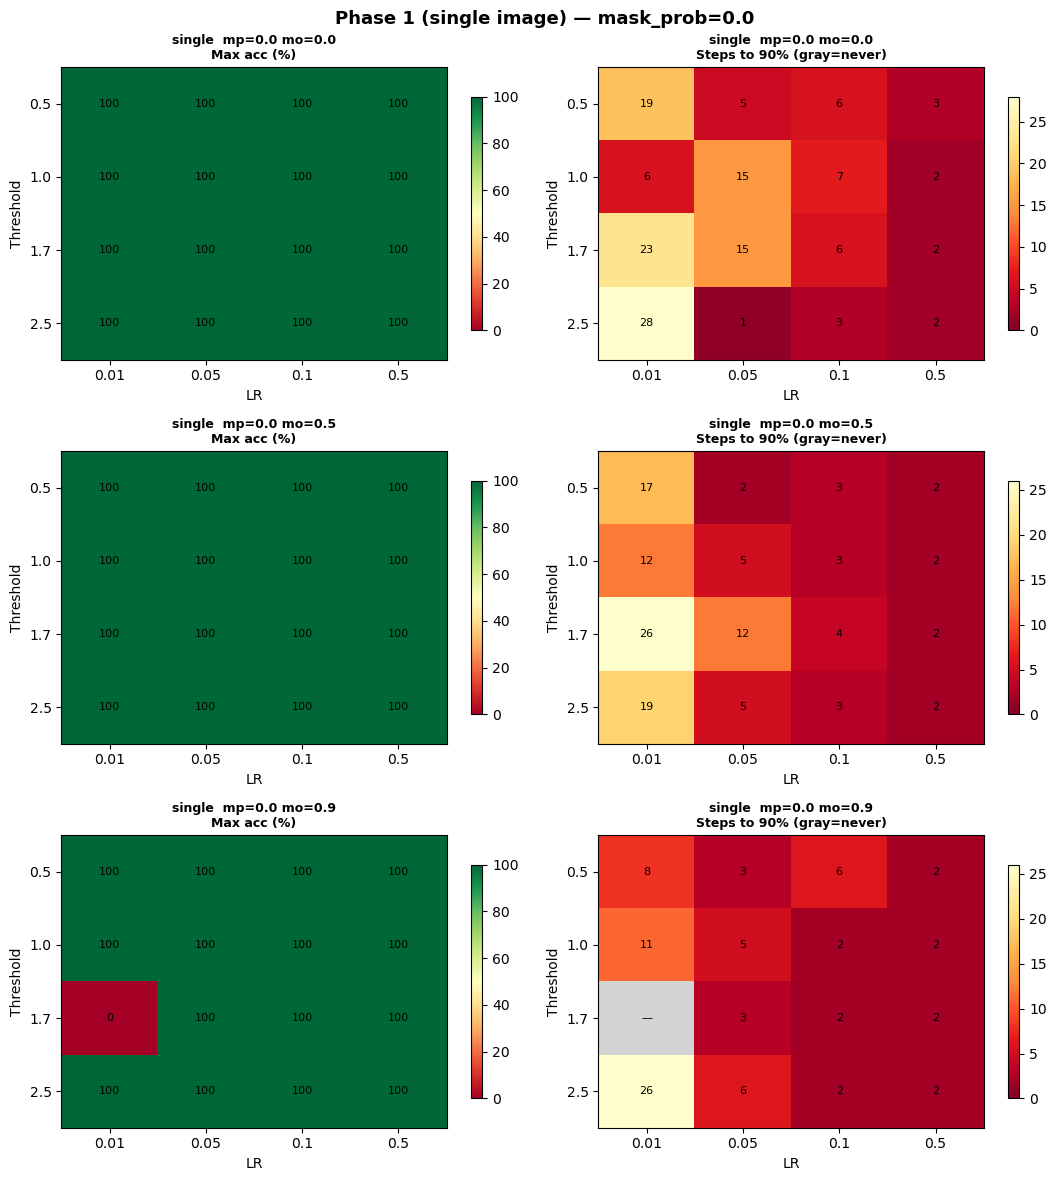

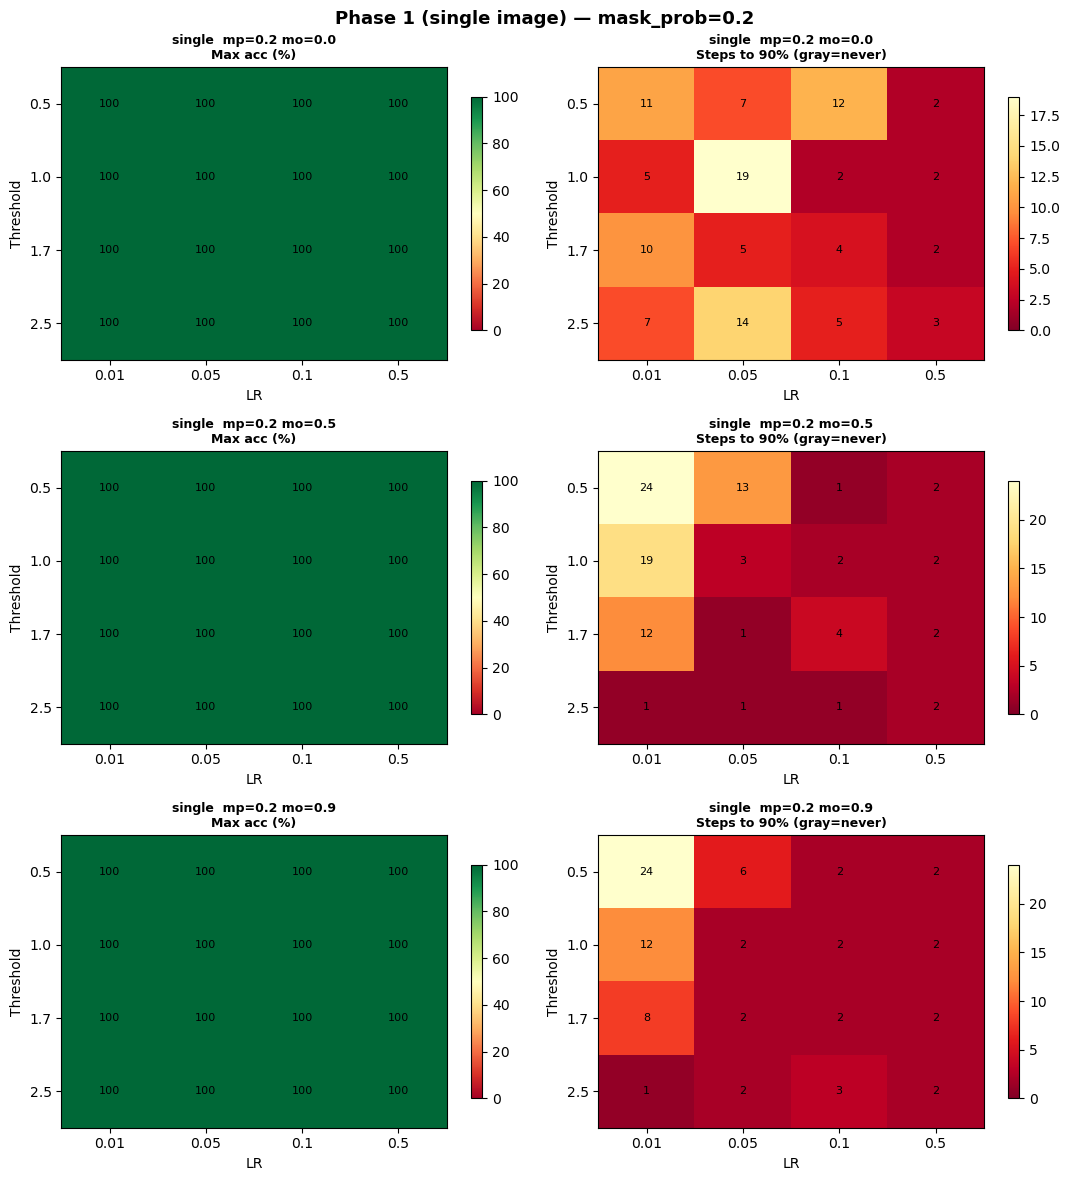

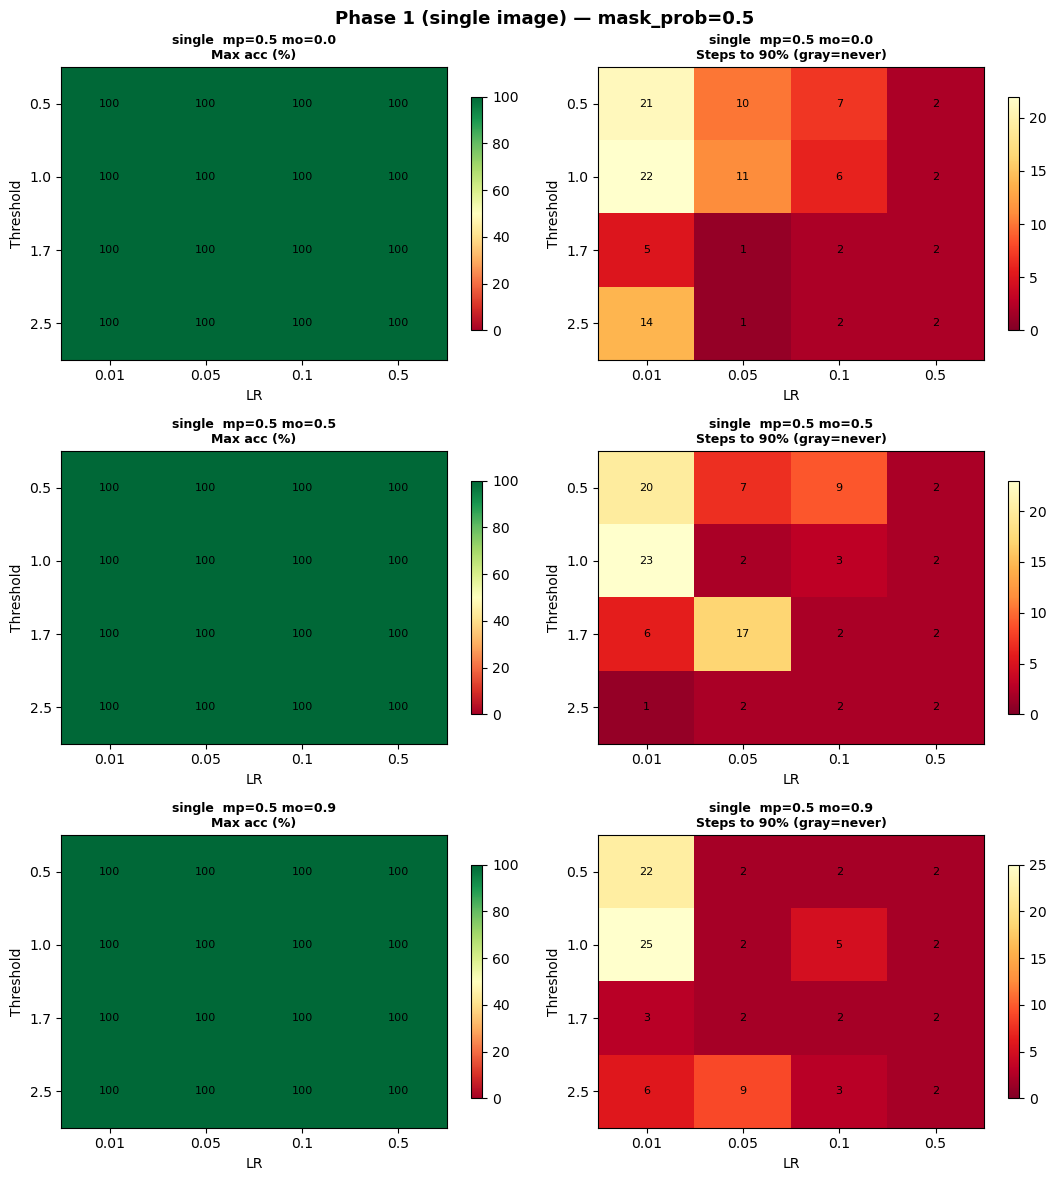

In [11]:
def p1_max_acc(mode, thr, lr, mp, mo):
    return max(p1_results[(mode, thr, lr, mp, mo)]["accs"])


def plot_p1_heatmap(mode, mp, mo, ax_max, ax_steps, threshold_90=90.0):
    """Threshold × LR heatmap for a fixed (mode, mask_prob, momentum)."""
    mat_max   = np.zeros((len(P1_THRESHOLDS), len(P1_LRS)))
    mat_steps = np.full((len(P1_THRESHOLDS), len(P1_LRS)), np.nan)
    for r, thr in enumerate(P1_THRESHOLDS):
        for c, lr in enumerate(P1_LRS):
            accs = p1_results[(mode, thr, lr, mp, mo)]["accs"]
            mat_max[r, c] = max(accs)
            hit = [s for s, a in enumerate(accs) if a >= threshold_90]
            if hit: mat_steps[r, c] = hit[0]

    xt = [str(lr) for lr in P1_LRS]
    yt = [str(t)  for t  in P1_THRESHOLDS]

    im1 = ax_max.imshow(mat_max, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax_max.set_xticks(range(len(P1_LRS)));       ax_max.set_xticklabels(xt)
    ax_max.set_yticks(range(len(P1_THRESHOLDS))); ax_max.set_yticklabels(yt)
    for r in range(len(P1_THRESHOLDS)):
        for c in range(len(P1_LRS)):
            ax_max.text(c, r, f"{mat_max[r,c]:.0f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im1, ax=ax_max, shrink=0.8)
    ax_max.set_xlabel("LR"); ax_max.set_ylabel("Threshold")
    ax_max.set_title(f"{mode}  mp={mp} mo={mo}\nMax acc (%)", fontsize=9, fontweight="bold")

    masked = np.ma.masked_invalid(mat_steps)
    cmap2 = plt.cm.YlOrRd_r.copy(); cmap2.set_bad("lightgray")
    vmax2 = float(np.nanmax(mat_steps)) if not np.all(np.isnan(mat_steps)) else P1_N_MAX
    im2 = ax_steps.imshow(masked, cmap=cmap2, vmin=0, vmax=vmax2, aspect="auto")
    ax_steps.set_xticks(range(len(P1_LRS)));       ax_steps.set_xticklabels(xt)
    ax_steps.set_yticks(range(len(P1_THRESHOLDS))); ax_steps.set_yticklabels(yt)
    for r in range(len(P1_THRESHOLDS)):
        for c in range(len(P1_LRS)):
            v = mat_steps[r, c]
            ax_steps.text(c, r, "—" if np.isnan(v) else str(int(v)),
                          ha="center", va="center", fontsize=8)
    plt.colorbar(im2, ax=ax_steps, shrink=0.8)
    ax_steps.set_xlabel("LR"); ax_steps.set_ylabel("Threshold")
    ax_steps.set_title(f"{mode}  mp={mp} mo={mo}\nSteps to 90% (gray=never)", fontsize=9, fontweight="bold")


# ── Plot: one figure per mask_prob — rows = momentum (single image only) ──
for mp in P1_MASK_PROBS:
    n_mo = len(P1_MOMENTUMS)
    fig, axes = plt.subplots(n_mo, 2, figsize=(11, 4 * n_mo))
    for row, mo in enumerate(P1_MOMENTUMS):
        plot_p1_heatmap("single", mp, mo, axes[row, 0], axes[row, 1])
    fig.suptitle(f"Phase 1 (single image) — mask_prob={mp}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"p1_heatmap_single_mp{mp}.png", dpi=120)
    plt.show()


single   best: thr=0.5 lr=0.01 mp=0.0 mo=0.0  → 100.0%


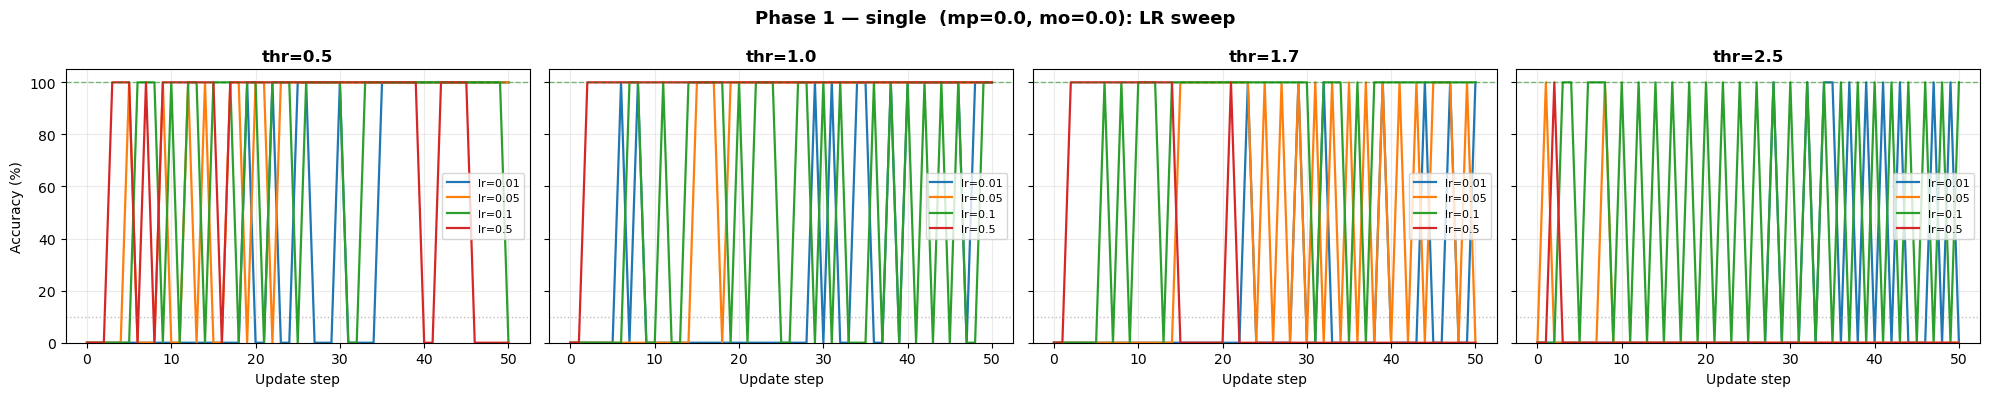

In [12]:
# ── Learning curves: best hyperparams (single image) ───────────────────
def find_best(mode):
    """Return (thr, lr, mp, mo) maximising peak accuracy for given mode."""
    best, best_key = -1, None
    for thr in P1_THRESHOLDS:
        for lr in P1_LRS:
            for mp in P1_MASK_PROBS:
                for mo in P1_MOMENTUMS:
                    a = max(p1_results[(mode, thr, lr, mp, mo)]["accs"])
                    if a > best:
                        best, best_key = a, (thr, lr, mp, mo)
    return best_key, best

bk, ba = find_best("single")
thr, lr, mp, mo = bk
print(f"single   best: thr={thr} lr={lr} mp={mp} mo={mo}  → {ba:.1f}%")


# ── Convergence curves: vary lr, fix best (thr, mp, mo) ────────────────
bk, _ = find_best("single")
thr, best_lr, mp, mo = bk
fig, axes = plt.subplots(1, len(P1_THRESHOLDS), figsize=(5 * len(P1_THRESHOLDS), 4),
                         sharey=True)
for ax, t in zip(axes, P1_THRESHOLDS):
    for lr in P1_LRS:
        accs = p1_results[("single", t, lr, mp, mo)]["accs"]
        ax.plot(accs, label=f"lr={lr}", linewidth=1.6)
    ax.axhline(100, color="green", lw=1, ls="--", alpha=0.5)
    ax.axhline(10, color="gray", lw=1, ls=":", alpha=0.5)
    ax.set_ylim(0, 105)
    ax.set_title(f"thr={t}", fontweight="bold")
    ax.set_xlabel("Update step")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Accuracy (%)")
fig.suptitle(f"Phase 1 — single  (mp={mp}, mo={mo}): LR sweep",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"p1_curves_single_mp{mp}_mo{mo}.png", dpi=120)
plt.show()


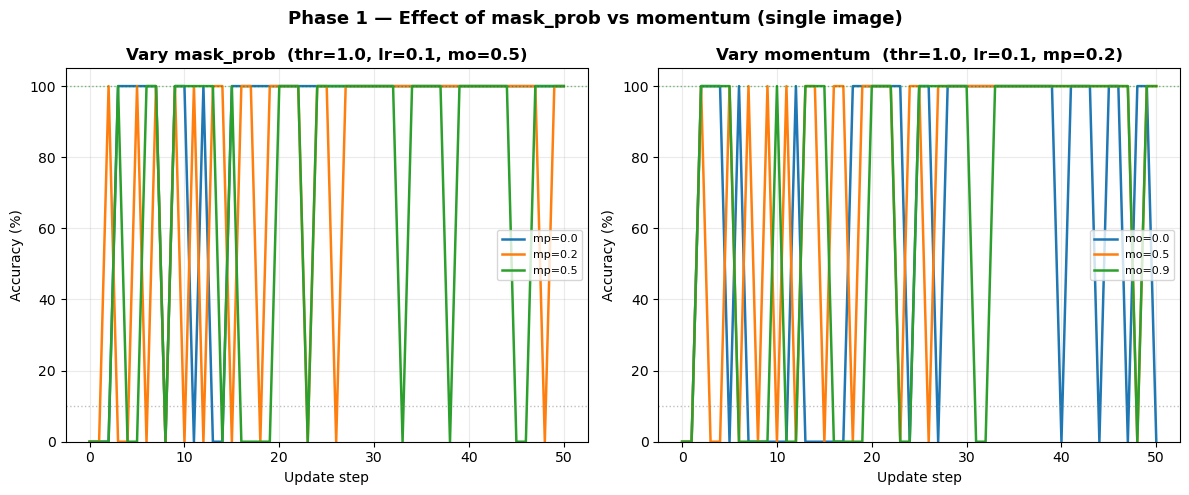

In [13]:
# ── Effect of mask_prob and momentum independently (single image) ───────
FIX_THR, FIX_LR = 1.0, 0.1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: vary mask_prob, fix mo=0.5
ax = axes[0]
for mp in P1_MASK_PROBS:
    accs = p1_results[("single", FIX_THR, FIX_LR, mp, 0.5)]["accs"]
    ax.plot(accs, label=f"mp={mp}", linewidth=1.8)
ax.axhline(100, color="green", lw=1, ls=":", alpha=0.5)
ax.axhline(10,  color="gray",  lw=1, ls=":", alpha=0.5)
ax.set_ylim(0, 105); ax.grid(True, alpha=0.25)
ax.set_xlabel("Update step"); ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Vary mask_prob  (thr={FIX_THR}, lr={FIX_LR}, mo=0.5)", fontweight="bold")
ax.legend(fontsize=8)

# Right: vary momentum, fix mp=0.2
ax = axes[1]
for mo in P1_MOMENTUMS:
    accs = p1_results[("single", FIX_THR, FIX_LR, 0.2, mo)]["accs"]
    ax.plot(accs, label=f"mo={mo}", linewidth=1.8)
ax.axhline(100, color="green", lw=1, ls=":", alpha=0.5)
ax.axhline(10,  color="gray",  lw=1, ls=":", alpha=0.5)
ax.set_ylim(0, 105); ax.grid(True, alpha=0.25)
ax.set_xlabel("Update step"); ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Vary momentum  (thr={FIX_THR}, lr={FIX_LR}, mp=0.2)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Phase 1 — Effect of mask_prob vs momentum (single image)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "p1_mask_vs_momentum.png", dpi=120)
plt.show()


---
## Phase 2 — Weight norm dynamics during memorization

Track how each weight matrix evolves as the network memorizes — to understand *why* some configs succeed and others don't.

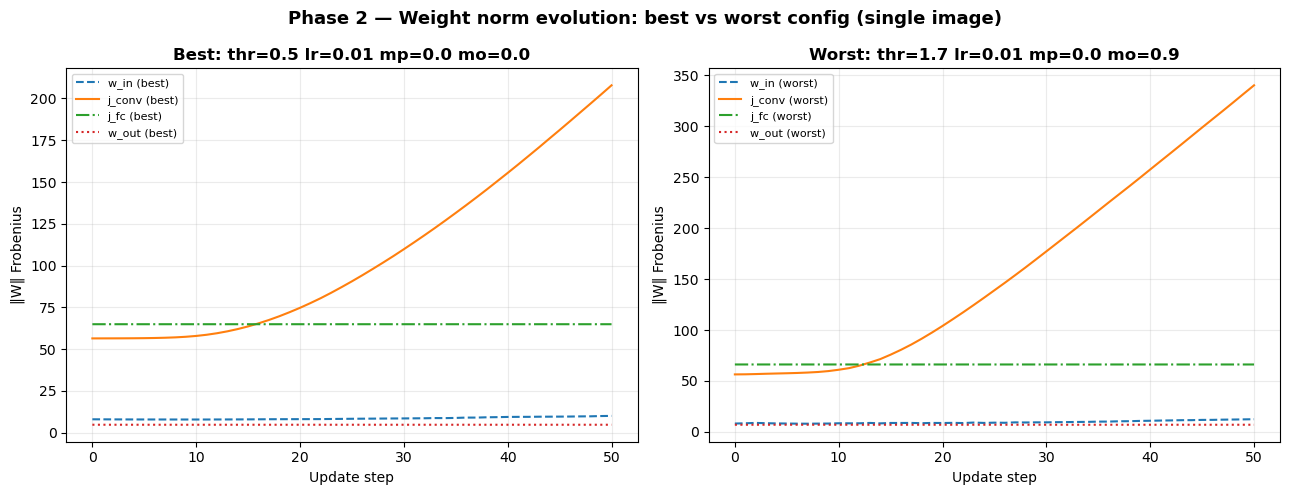

In [14]:
# Plot weight norms for best config and worst config, single mode
def plot_norm_evolution(mode, thr, lr, mp, mo, ax, color, label):
    norms = p1_results[(mode, thr, lr, mp, mo)]["norms"]
    steps = list(range(len(norms)))
    for name, ls in [("w_in","--"),("j_conv","-"),("j_fc","-."),("w_out",":")]:
        vals = [n[name] for n in norms]
        ax.plot(steps, vals, ls=ls, label=f"{name} ({label})", linewidth=1.5)


mode = "single"
bk, _ = find_best(mode)
# worst = lowest max accuracy
worst_acc, wk = 999, None
for thr in P1_THRESHOLDS:
    for lr in P1_LRS:
        for mp in P1_MASK_PROBS:
            for mo in P1_MOMENTUMS:
                a = max(p1_results[(mode, thr, lr, mp, mo)]["accs"])
                if a < worst_acc:
                    worst_acc, wk = a, (thr, lr, mp, mo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_norm_evolution(mode, *bk, axes[0], "steelblue", "best")
axes[0].set_title(f"Best: thr={bk[0]} lr={bk[1]} mp={bk[2]} mo={bk[3]}", fontweight="bold")
axes[0].set_xlabel("Update step"); axes[0].set_ylabel("‖W‖ Frobenius")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.25)

plot_norm_evolution(mode, *wk, axes[1], "tomato", "worst")
axes[1].set_title(f"Worst: thr={wk[0]} lr={wk[1]} mp={wk[2]} mo={wk[3]}", fontweight="bold")
axes[1].set_xlabel("Update step"); axes[1].set_ylabel("‖W‖ Frobenius")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.25)

fig.suptitle("Phase 2 — Weight norm evolution: best vs worst config (single image)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "p2_weight_norms.png", dpi=120)
plt.show()

---
## Phase 3 — Catastrophic Forgetting

**Protocol:**
1. Train on **batch A** for `N_TRAIN` steps until it's memorized.
2. Switch to **batch B** and keep training for `N_FORGET` steps.
3. At every step record accuracy on **both A and B**.

**Questions:**
- Does accuracy on A drop immediately or gradually?
- Does higher momentum or masking protect against forgetting?
- Is there any interference pattern for similar / dissimilar batches?

In [15]:
# Use the best single-image config found in Phase 1 as baseline
bk_single, _ = find_best("single")
FORGET_THR, FORGET_LR, _, _ = bk_single  # use best thr & lr

# Forgetting configs: vary (mask_prob, momentum)
FORGET_CONFIGS = [
    (0.0, 0.0, "no mask, no momentum"),
    (0.2, 0.0, "mask=0.2, mo=0"),
    (0.0, 0.5, "no mask, mo=0.5"),
    (0.2, 0.5, "mask=0.2, mo=0.5"),
    (0.5, 0.9, "mask=0.5, mo=0.9"),
]

N_PHASE_A = 30   # updates on batch A (memorization phase)
N_PHASE_B = 40   # updates on batch B (forgetting phase)

print(f"Phase A (train A): {N_PHASE_A} steps")
print(f"Phase B (train B): {N_PHASE_B} steps")
print(f"Data mode: single image (A1 vs B1)")
print(f"Threshold={FORGET_THR}, LR={FORGET_LR}")
print(f"\n{len(FORGET_CONFIGS)} configs:")
for mp, mo, desc in FORGET_CONFIGS:
    print(f"  mp={mp}, mo={mo}  — {desc}")

Phase A (train A): 30 steps
Phase B (train B): 40 steps
Data mode: single image (A1 vs B1)
Threshold=0.5, LR=0.01

5 configs:
  mp=0.0, mo=0.0  — no mask, no momentum
  mp=0.2, mo=0.0  — mask=0.2, mo=0
  mp=0.0, mo=0.5  — no mask, mo=0.5
  mp=0.2, mo=0.5  — mask=0.2, mo=0.5
  mp=0.5, mo=0.9  — mask=0.5, mo=0.9


In [16]:
def run_forgetting(thr, lr, mask_prob, momentum, seed=0):
    """
    Phase A: train on (x_A1, y_A1) for N_PHASE_A steps.
    Phase B: continue training on (x_B1, y_B1) for N_PHASE_B steps.
    Return:
        steps: list of int (0 … N_PHASE_A + N_PHASE_B)
        acc_A:  accuracy on A at each step
        acc_B:  accuracy on B at each step
        phase:  list of 'A' or 'B'
    """
    st, orch = build_model(seed=seed, threshold=thr, mask_prob=mask_prob, momentum=momentum)
    opt, opt_st = build_opt(orch, lr)
    rng = jax.random.PRNGKey(7)

    steps, acc_A_list, acc_B_list, phase_list = [], [], [], []

    for global_step in range(N_PHASE_A + N_PHASE_B + 1):
        in_phase_B = (global_step > N_PHASE_A)
        x_train = x_B1 if in_phase_B else x_A1
        y_train = y_B1 if in_phase_B else y_A1

        # Evaluate on both patterns
        for xd, yd, lst in [(x_A1, y_A1, acc_A_list), (x_B1, y_B1, acc_B_list)]:
            s0 = st.init(xd, yd)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            a, rng = get_accuracy(orch, sf, yd, rng)
            lst.append(a)

        steps.append(global_step)
        phase_list.append("B" if in_phase_B else "A")

        # Weight update on training pattern (except at last step)
        if global_step < N_PHASE_A + N_PHASE_B:
            s0 = st.init(x_train, y_train)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            orch, opt_st, rng = update_weights(orch, sf, rng, opt, opt_st)

    return steps, acc_A_list, acc_B_list, phase_list


forget_results = {}
for mp, mo, desc in FORGET_CONFIGS:
    print(f"Running: {desc} ...", end="  ", flush=True)
    res = run_forgetting(FORGET_THR, FORGET_LR, mp, mo)
    forget_results[(mp, mo)] = {"steps": res[0], "acc_A": res[1], "acc_B": res[2],
                                 "phase": res[3], "desc": desc}
    final_A = res[1][-1]
    max_A   = max(res[1][:N_PHASE_A+1])
    final_B = res[2][-1]
    print(f"A: peak={max_A:.0f}%  final={final_A:.0f}%  |  B final={final_B:.0f}%")

print("\nPhase 3 complete.")

Running: no mask, no momentum ...  A: peak=100%  final=100%  |  B final=100%
Running: mask=0.2, mo=0 ...  A: peak=0%  final=100%  |  B final=100%
Running: no mask, mo=0.5 ...  A: peak=100%  final=0%  |  B final=100%
Running: mask=0.2, mo=0.5 ...  A: peak=100%  final=100%  |  B final=100%
Running: mask=0.5, mo=0.9 ...  A: peak=100%  final=100%  |  B final=0%

Phase 3 complete.


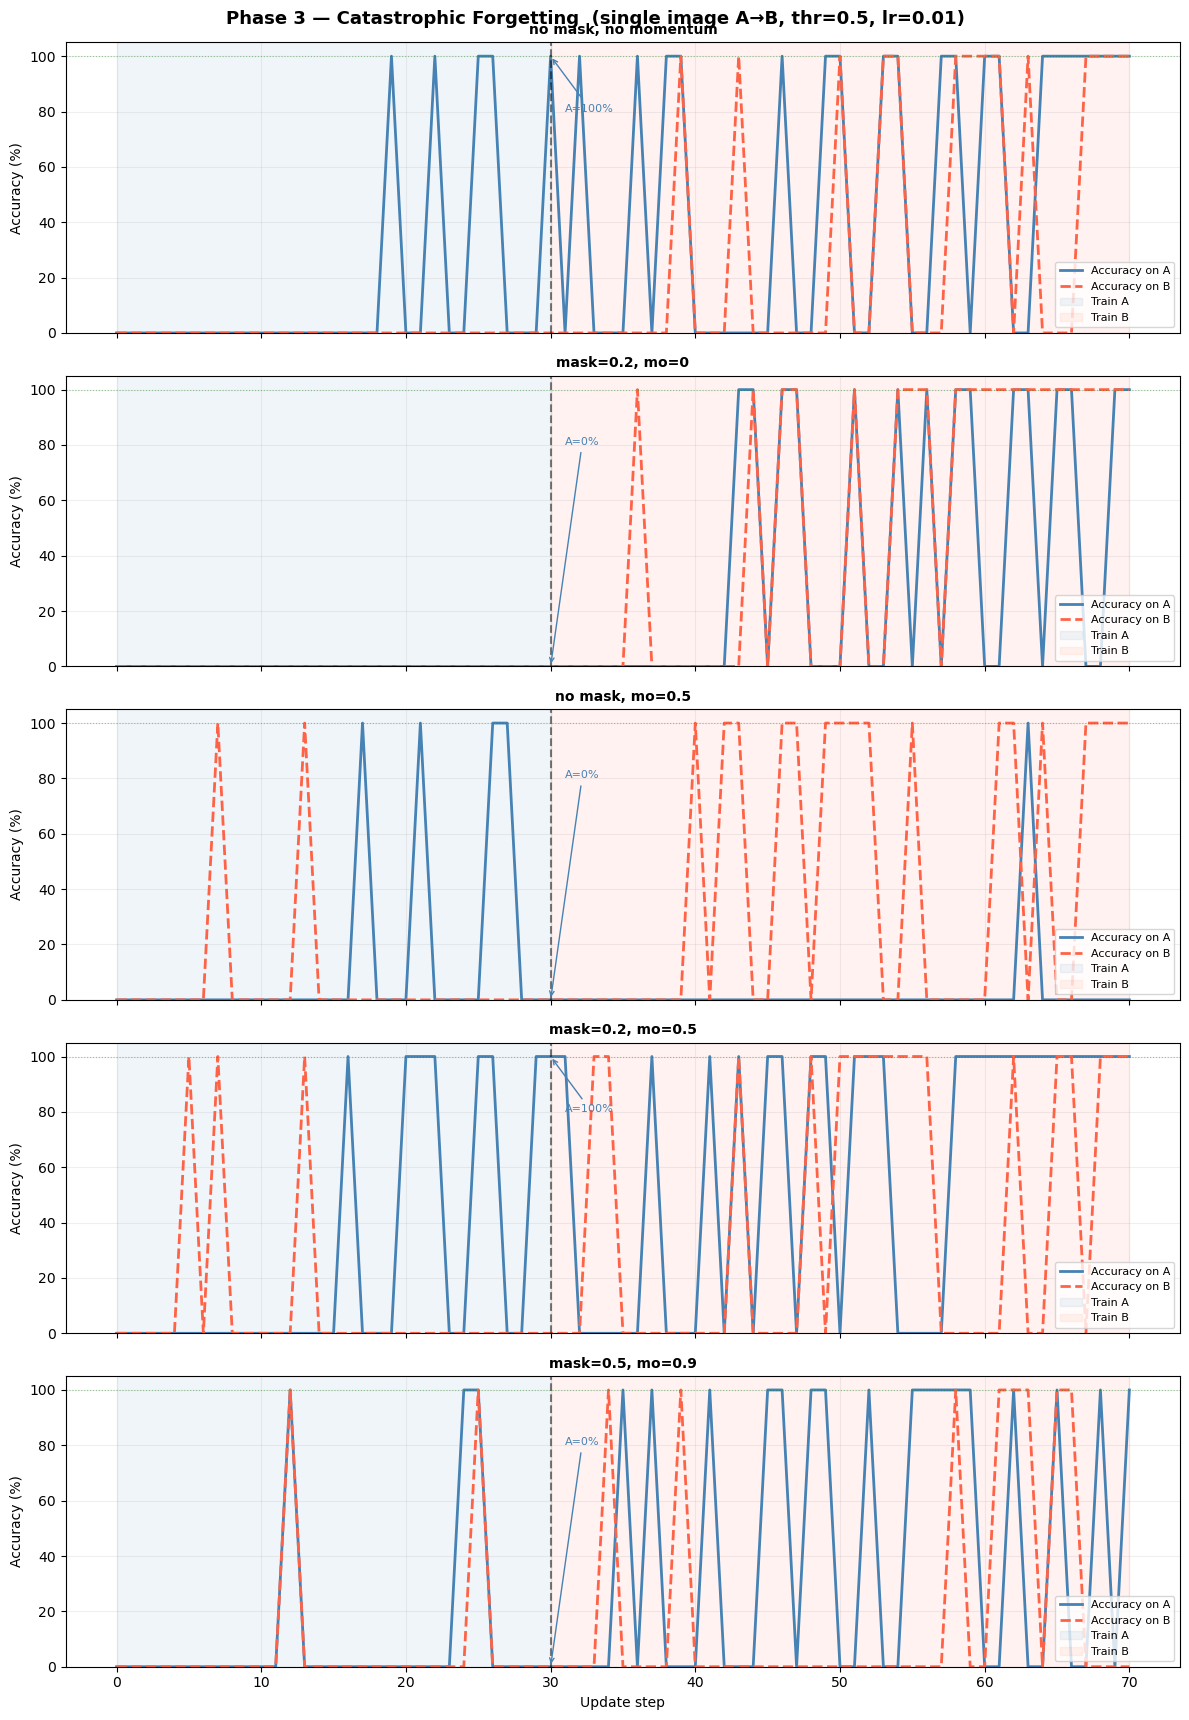

In [17]:
fig, axes = plt.subplots(len(FORGET_CONFIGS), 1,
                          figsize=(12, 3.5 * len(FORGET_CONFIGS)), sharex=True)

for ax, (mp, mo, desc) in zip(axes, FORGET_CONFIGS):
    r = forget_results[(mp, mo)]
    steps = r["steps"]
    ax.plot(steps, r["acc_A"], color="steelblue", lw=2, label="Accuracy on A")
    ax.plot(steps, r["acc_B"], color="tomato",    lw=2, label="Accuracy on B", ls="--")

    # Shade phase regions
    ax.axvspan(0, N_PHASE_A, alpha=0.08, color="steelblue", label="Train A")
    ax.axvspan(N_PHASE_A, steps[-1], alpha=0.08, color="tomato", label="Train B")
    ax.axvline(N_PHASE_A, color="black", lw=1.5, ls="--", alpha=0.5)

    ax.axhline(100, color="green", lw=0.8, ls=":", alpha=0.4)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(desc, fontweight="bold", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.2)

    # Annotate transition point
    acc_A_at_switch = r["acc_A"][N_PHASE_A]
    ax.annotate(f"A={acc_A_at_switch:.0f}%", xy=(N_PHASE_A, acc_A_at_switch),
                xytext=(N_PHASE_A + 1, 80), fontsize=8, color="steelblue",
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1))

axes[-1].set_xlabel("Update step")
fig.suptitle(
    f"Phase 3 — Catastrophic Forgetting  (single image A→B, thr={FORGET_THR}, lr={FORGET_LR})",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "p3_forgetting_curves.png", dpi=120)
plt.show()

In [18]:
# ── Summary table: forgetting speed ────────────────────────────────────
print(f"{'Config':<30} {'Peak A':>8} {'A@switch':>10} {'A@end':>8} {'B@end':>8} {'Forget drop':>12}")
print("-" * 80)
for mp, mo, desc in FORGET_CONFIGS:
    r = forget_results[(mp, mo)]
    peak_A =   max(r["acc_A"][:N_PHASE_A + 1])
    A_switch = r["acc_A"][N_PHASE_A]
    A_end =    r["acc_A"][-1]
    B_end =    r["acc_B"][-1]
    drop  =    A_switch - A_end
    print(f"{desc:<30} {peak_A:>8.1f}% {A_switch:>10.1f}% {A_end:>8.1f}% {B_end:>8.1f}% {drop:>11.1f}pp")

Config                           Peak A   A@switch    A@end    B@end  Forget drop
--------------------------------------------------------------------------------
no mask, no momentum              100.0%      100.0%    100.0%    100.0%         0.0pp
mask=0.2, mo=0                      0.0%        0.0%    100.0%    100.0%      -100.0pp
no mask, mo=0.5                   100.0%        0.0%      0.0%    100.0%         0.0pp
mask=0.2, mo=0.5                  100.0%      100.0%    100.0%    100.0%         0.0pp
mask=0.5, mo=0.9                  100.0%        0.0%    100.0%      0.0%      -100.0pp


---
## Summary & Conclusions

*Fill in after running the cells above.*

In [19]:
# ── Quick summary: best memorization (single image only) ───────────────
print(f"{'mode':8} {'mp':5} {'mo':5} {'best_thr':10} {'best_lr':10} {'max_acc':10} {'steps_to_90':12}")
print("-" * 65)
for mode in ["single"]:
    for mp in P1_MASK_PROBS:
        for mo in P1_MOMENTUMS:
            best_acc, best_cfg, best_steps = -1, None, "—"
            for thr in P1_THRESHOLDS:
                for lr in P1_LRS:
                    accs = p1_results[(mode, thr, lr, mp, mo)]["accs"]
                    if max(accs) > best_acc:
                        best_acc = max(accs)
                        best_cfg = (thr, lr)
                        hit = [s for s, a in enumerate(accs) if a >= 90.0]
                        best_steps = str(hit[0]) if hit else "—"
            print(f"{mode:8} {mp:<5} {mo:<5} {best_cfg[0]:<10} {best_cfg[1]:<10} {best_acc:<10.1f}% {best_steps}")
    print()


mode     mp    mo    best_thr   best_lr    max_acc    steps_to_90 
-----------------------------------------------------------------
single   0.0   0.0   0.5        0.01       100.0     % 19
single   0.0   0.5   0.5        0.01       100.0     % 17
single   0.0   0.9   0.5        0.01       100.0     % 8
single   0.2   0.0   0.5        0.01       100.0     % 11
single   0.2   0.5   0.5        0.01       100.0     % 24
single   0.2   0.9   0.5        0.01       100.0     % 24
single   0.5   0.0   0.5        0.01       100.0     % 21
single   0.5   0.5   0.5        0.01       100.0     % 20
single   0.5   0.9   0.5        0.01       100.0     % 22



---
## Soft memorization metric

Instead of binary accuracy (0% or 100%), we look at the **raw output activations** before taking the argmax.

Two metrics:
- **Correct-class logit**: value of the output unit corresponding to the true class — a continuous signal showing how strongly the network "believes" the right answer.
- **Margin**: `logit[true_class] − max(logit[wrong_classes])` — positive means correct prediction, magnitude indicates confidence. This is the most informative single number.


In [20]:
def get_soft_scores(orch, state_final, y_true, rng):
    """
    Returns:
      correct_logit : raw output activation of the true class  (shape: batch,)
      margin        : correct_logit − max(other logits)         (shape: batch,)
      rng
    """
    rng, pr = jax.random.split(rng)
    pred_st, _ = orch.predict(state_final, pr)
    out = np.array(pred_st.states[-1])       # (batch, 10) raw activations
    true_idx = np.argmax(np.array(y_true), axis=-1)  # (batch,)

    correct_logit = out[np.arange(len(true_idx)), true_idx]   # (batch,)
    # mask out correct class to find max of wrong classes
    mask = np.ones_like(out, dtype=bool)
    mask[np.arange(len(true_idx)), true_idx] = False
    wrong_max = out[mask].reshape(len(true_idx), -1).max(axis=-1)

    margin = correct_logit - wrong_max
    return float(correct_logit.mean()), float(margin.mean()), rng


def run_soft_curve(x_data, y_data, threshold, lr, mask_prob, momentum,
                   n_max=P1_N_MAX, seed=0):
    """Like run_memorization_curve but records soft scores instead of binary accuracy."""
    st, orch = build_model(seed=seed, threshold=threshold,
                           mask_prob=mask_prob, momentum=momentum)
    opt, opt_st = build_opt(orch, lr)
    rng = jax.random.PRNGKey(42)

    logits, margins, accs = [], [], []
    for step in range(n_max + 1):
        s0 = st.init(x_data, y_data)
        rng, dyn_rng = jax.random.split(rng)
        state_final, _ = run_dynamics(orch, s0, dyn_rng)
        cl, mg, rng = get_soft_scores(orch, state_final, y_data, rng)
        acc, rng  = get_accuracy(orch, state_final, y_data, rng)
        logits.append(cl); margins.append(mg); accs.append(acc)
        if step < n_max:
            orch, opt_st, rng = update_weights(orch, state_final, rng, opt, opt_st)
    return accs, logits, margins


print("Soft-score helpers defined ✓")


Soft-score helpers defined ✓


In [21]:
# ── Run soft curves: vary LR × threshold, fix mp=0.0, mo=0.0 ─────────
SOFT_MP, SOFT_MO = 0.0, 0.0
soft_results = {}   # key: (thr, lr) → {accs, logits, margins}

for thr in P1_THRESHOLDS:
    for lr in P1_LRS:
        accs, logits, margins = run_soft_curve(x_A1, y_A1, thr, lr, SOFT_MP, SOFT_MO)
        soft_results[(thr, lr)] = {"accs": accs, "logits": logits, "margins": margins}

print("Soft-curve sweep done ✓")


Soft-curve sweep done ✓


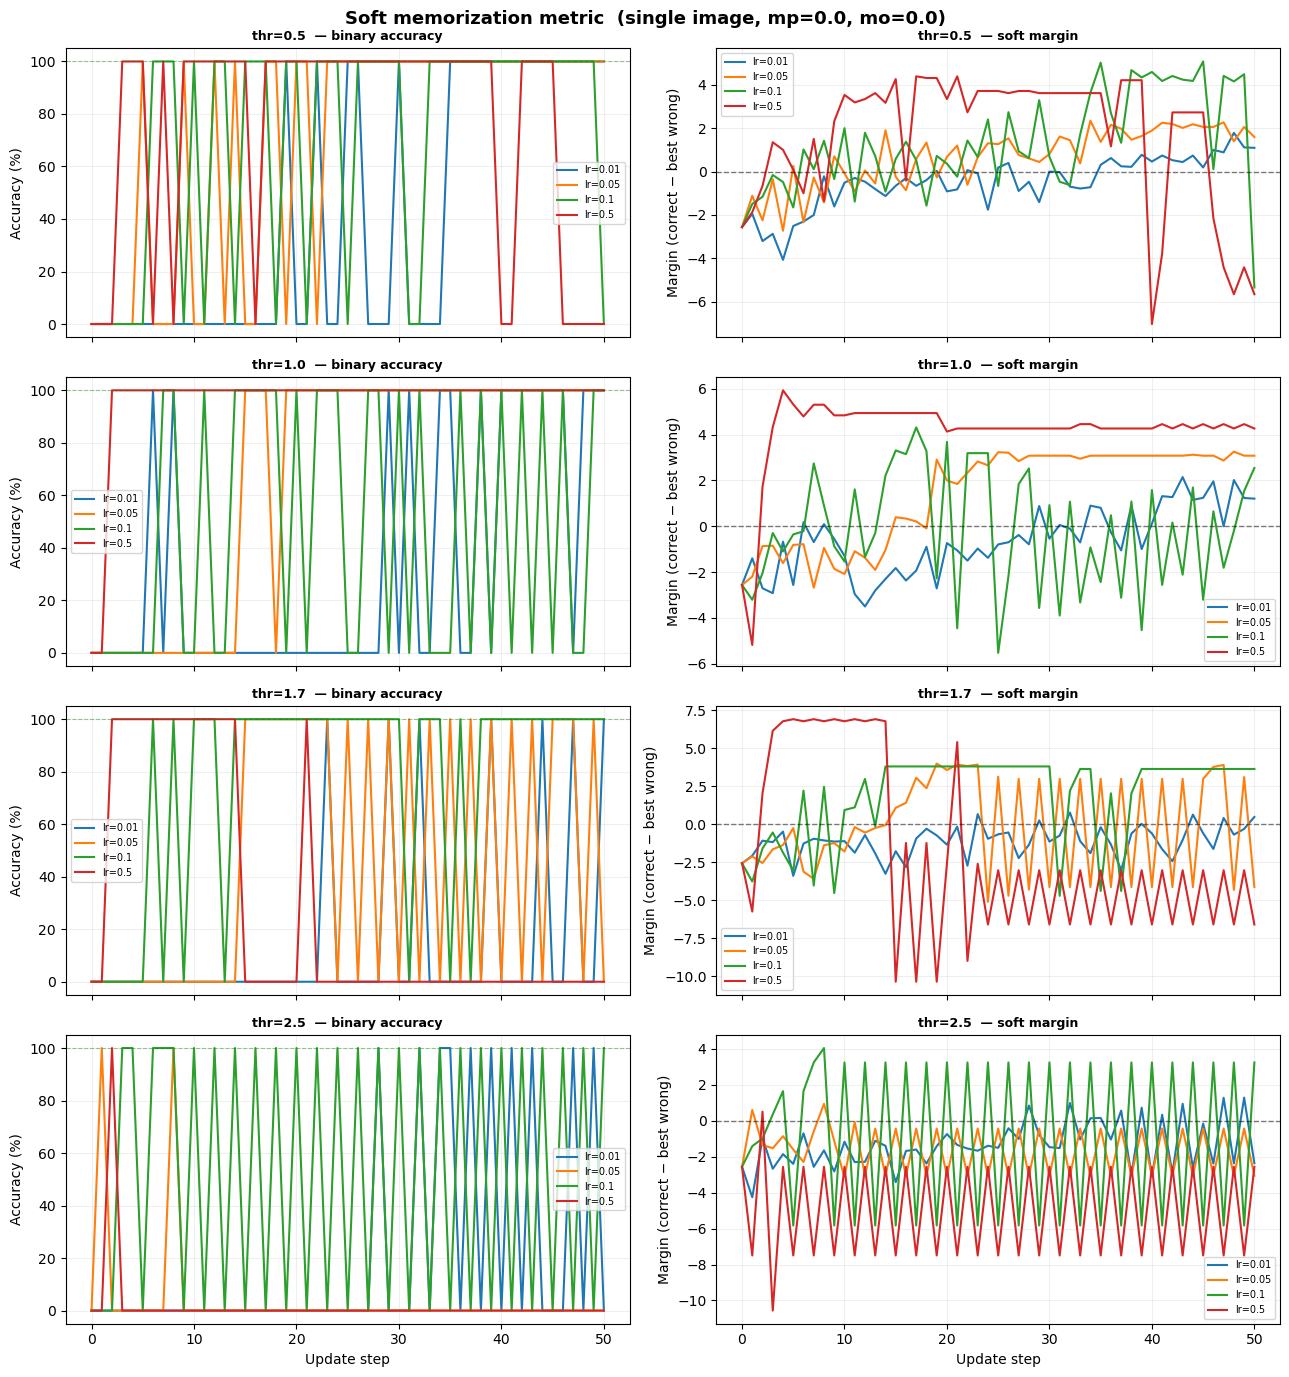

In [22]:
# ── Plot: binary accuracy vs margin, side by side ─────────────────────
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(P1_THRESHOLDS), 2,
                          figsize=(13, 3.5 * len(P1_THRESHOLDS)), sharex=True)

for row, thr in enumerate(P1_THRESHOLDS):
    ax_acc, ax_mg = axes[row, 0], axes[row, 1]
    for ci, lr in enumerate(P1_LRS):
        r = soft_results[(thr, lr)]
        steps = list(range(len(r["accs"])))
        ax_acc.plot(steps, r["accs"],    color=colors[ci], lw=1.5, label=f"lr={lr}")
        ax_mg.plot( steps, r["margins"], color=colors[ci], lw=1.5, label=f"lr={lr}")

    ax_acc.axhline(100,  color="green", lw=0.8, ls="--", alpha=0.4)
    ax_acc.set_ylim(-5, 105); ax_acc.set_ylabel("Accuracy (%)"); ax_acc.grid(True, alpha=0.2)
    ax_acc.set_title(f"thr={thr}  — binary accuracy", fontweight="bold", fontsize=9)
    ax_acc.legend(fontsize=7)

    ax_mg.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax_mg.set_ylabel("Margin (correct − best wrong)")
    ax_mg.grid(True, alpha=0.2)
    ax_mg.set_title(f"thr={thr}  — soft margin", fontweight="bold", fontsize=9)
    ax_mg.legend(fontsize=7)

for ax in axes[-1]:
    ax.set_xlabel("Update step")

fig.suptitle(f"Soft memorization metric  (single image, mp={SOFT_MP}, mo={SOFT_MO})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "soft_memorization.png", dpi=120)
plt.show()


In [23]:
def run_forgetting_soft(thr, lr, mask_prob, momentum, seed=0):
    """
    Phase A: train on x_A1 for N_PHASE_A steps.
    Phase B: continue training on x_B1 for N_PHASE_B steps.
    Returns steps, margin_A, margin_B at every step.
    """
    st, orch = build_model(seed=seed, threshold=thr, mask_prob=mask_prob, momentum=momentum)
    opt, opt_st = build_opt(orch, lr)
    rng = jax.random.PRNGKey(7)

    steps, mg_A_list, mg_B_list = [], [], []

    for global_step in range(N_PHASE_A + N_PHASE_B + 1):
        in_phase_B = (global_step > N_PHASE_A)
        x_train = x_B1 if in_phase_B else x_A1
        y_train = y_B1 if in_phase_B else y_A1

        for xd, yd, lst in [(x_A1, y_A1, mg_A_list), (x_B1, y_B1, mg_B_list)]:
            s0 = st.init(xd, yd)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            _, mg, rng = get_soft_scores(orch, sf, yd, rng)
            lst.append(mg)

        steps.append(global_step)

        if global_step < N_PHASE_A + N_PHASE_B:
            s0 = st.init(x_train, y_train)
            rng, dr = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, dr)
            orch, opt_st, rng = update_weights(orch, sf, rng, opt, opt_st)

    return steps, mg_A_list, mg_B_list


forget_soft = {}
for mp, mo, desc in FORGET_CONFIGS:
    print(f"Running: {desc} ...", end="  ", flush=True)
    s, mgA, mgB = run_forgetting_soft(FORGET_THR, FORGET_LR, mp, mo)
    forget_soft[(mp, mo)] = {"steps": s, "mg_A": mgA, "mg_B": mgB, "desc": desc}
    print(f"A margin@end={mgA[-1]:.2f}  B margin@end={mgB[-1]:.2f}")

print("\nSoft forgetting runs complete.")


Running: no mask, no momentum ...  A margin@end=0.39  B margin@end=0.74
Running: mask=0.2, mo=0 ...  A margin@end=0.75  B margin@end=1.50
Running: no mask, mo=0.5 ...  A margin@end=-0.09  B margin@end=0.07
Running: mask=0.2, mo=0.5 ...  A margin@end=0.89  B margin@end=0.68
Running: mask=0.5, mo=0.9 ...  A margin@end=0.02  B margin@end=-0.03

Soft forgetting runs complete.


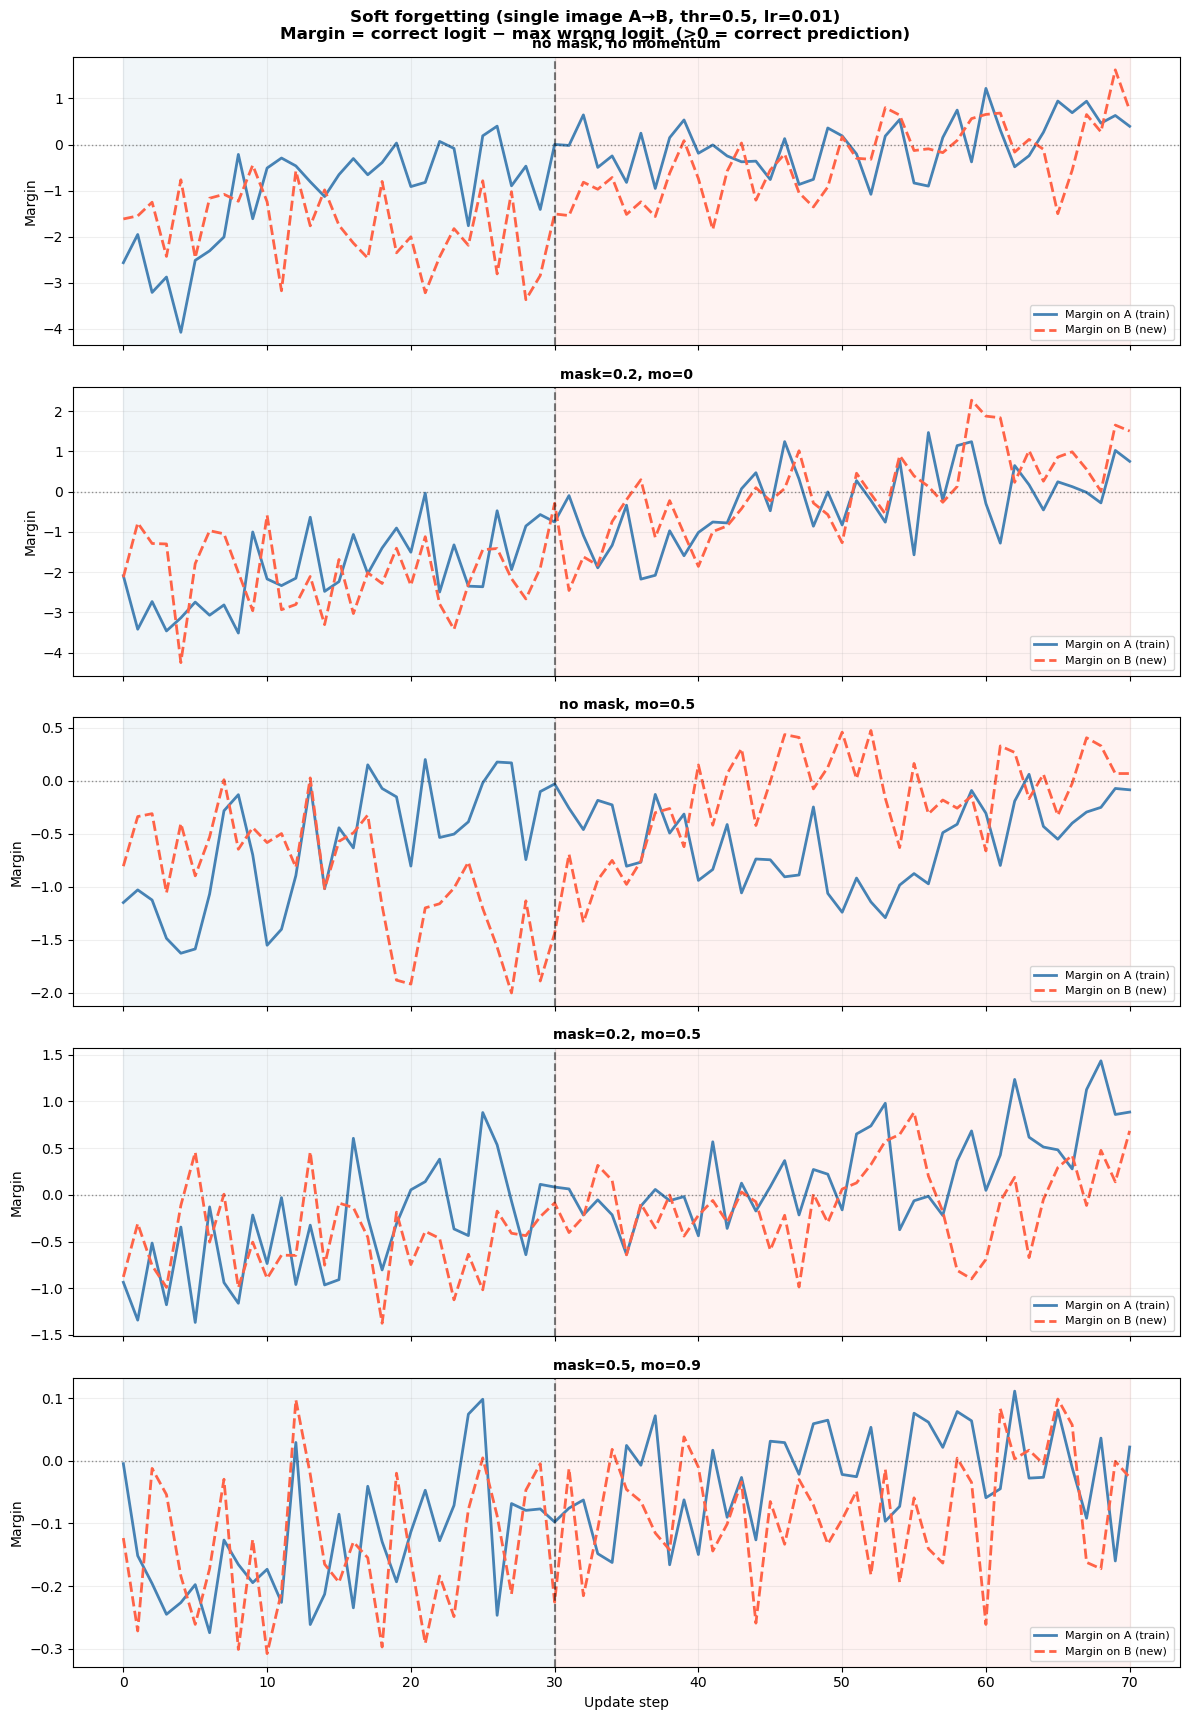

In [24]:
fig, axes = plt.subplots(len(FORGET_CONFIGS), 1,
                          figsize=(12, 3.5 * len(FORGET_CONFIGS)), sharex=True)

for ax, (mp, mo, desc) in zip(axes, FORGET_CONFIGS):
    r = forget_soft[(mp, mo)]
    ax.plot(r["steps"], r["mg_A"], color="steelblue", lw=2, label="Margin on A (train)")
    ax.plot(r["steps"], r["mg_B"], color="tomato",    lw=2, label="Margin on B (new)", ls="--")
    ax.axvspan(0, N_PHASE_A, alpha=0.07, color="steelblue")
    ax.axvspan(N_PHASE_A, r["steps"][-1], alpha=0.07, color="tomato")
    ax.axvline(N_PHASE_A, color="black", lw=1.5, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=1, ls=":", alpha=0.4)
    ax.set_ylabel("Margin"); ax.grid(True, alpha=0.2)
    ax.set_title(desc, fontweight="bold", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")

axes[-1].set_xlabel("Update step")
fig.suptitle(
    f"Soft forgetting (single image A→B, thr={FORGET_THR}, lr={FORGET_LR})\n"
    "Margin = correct logit − max wrong logit  (>0 = correct prediction)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "soft_forgetting.png", dpi=120)
plt.show()
